# Dataset check

In [ ]:
# ======================================================================================
# THYTRUST-MD — PHASE A
# COMPREHENSIVE DATASET AUDIT
# TN5000 + EXTERNAL THYROID 8508
#
# CPU ONLY — DOES NOT MODIFY ORIGINAL DATA
# ======================================================================================

import os
import re
import json
import hashlib
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True


# ======================================================================================
# 0. PROJECT PATHS
# ======================================================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/Journal/Thyroid ")
DATA_ROOT    = PROJECT_ROOT / "Dataset"

TN_ROOT      = DATA_ROOT / "TN5000"
TN_IMG_DIR   = TN_ROOT / "JPEGImages"
TN_ANN_DIR   = TN_ROOT / "Annotations"
TN_SET_DIR   = TN_ROOT / "ImageSets"

EXT_ROOT     = DATA_ROOT / "External_Thyroid_8508"

BATCH_CONFIGS = {
    "batch1": {
        "root": EXT_ROOT / "batch1_image",
        "image_csv": "batch1_image.csv",
        "label_csv": "batch1_image_label.csv",
    },
    "batch2": {
        "root": EXT_ROOT / "batch2_image",
        "image_csv": "batch2_image.csv",
        "label_csv": "batch2_image_label.csv",
    },
}

OUT_ROOT = PROJECT_ROOT / "ThyTrust_MD_Results" / "dataset_audit" / "phase_A_initial"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


print("=" * 100)
print("THYTRUST-MD — PHASE A DATASET AUDIT")
print("=" * 100)
print(f"Project root : {PROJECT_ROOT}")
print(f"Output root  : {OUT_ROOT}")
print()


# ======================================================================================
# 1. BASIC PATH CHECK
# ======================================================================================

required_paths = {
    "TN5000 root": TN_ROOT,
    "TN5000 JPEGImages": TN_IMG_DIR,
    "TN5000 Annotations": TN_ANN_DIR,
    "TN5000 ImageSets": TN_SET_DIR,
    "External root": EXT_ROOT,
}

missing_critical = []

print("PATH CHECK")
print("-" * 100)

for name, p in required_paths.items():
    exists = p.exists()
    print(f"{name:<30}: {'✓ FOUND' if exists else '✗ MISSING'}  {p}")
    if not exists:
        missing_critical.append((name, str(p)))

for batch_name, cfg in BATCH_CONFIGS.items():
    br = cfg["root"]
    print(f"{batch_name + ' root':<30}: {'✓ FOUND' if br.exists() else '✗ MISSING'}  {br}")

if missing_critical:
    print("\nWARNING: Some expected paths are missing.")
    print("Check your Google Drive folder names carefully before trusting the audit.")

print()


# ======================================================================================
# 2. HELPER FUNCTIONS
# ======================================================================================

def normalize_colnames(df):
    """Normalize CSV column names while preserving data."""
    df = df.copy()
    df.columns = [
        str(c).strip().lower().replace(" ", "_")
        for c in df.columns
    ]
    return df


def normalize_patient_id(x):
    """
    Normalize patient IDs so values such as 195, 195.0, '195'
    are treated consistently without changing nonnumeric IDs.
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if re.fullmatch(r"-?\d+\.0", s):
        s = s[:-2]

    return s


def collect_images_recursive(root):
    if not root.exists():
        return []

    return sorted([
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])


def inspect_image(path):
    result = {
        "readable": False,
        "width": np.nan,
        "height": np.nan,
        "mode": None,
        "format": None,
        "file_size_bytes": np.nan,
        "error": None,
    }

    try:
        result["file_size_bytes"] = path.stat().st_size

        with Image.open(path) as img:
            result["width"], result["height"] = img.size
            result["mode"] = img.mode
            result["format"] = img.format

            # force decode to catch corrupt images
            img.load()

        result["readable"] = True

    except Exception as e:
        result["error"] = str(e)

    return result


def file_md5(path, chunk_size=1024 * 1024):
    """Exact duplicate hash. CPU + disk based; no GPU."""
    h = hashlib.md5()

    try:
        with open(path, "rb") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                h.update(chunk)

        return h.hexdigest()

    except Exception:
        return None


def build_file_lookup(image_paths):
    """
    Creates robust lookups for CSV paths:
    - basename lookup
    - lowercase basename lookup
    - relative path fragments
    """
    basename_map = defaultdict(list)
    lowercase_basename_map = defaultdict(list)

    for p in image_paths:
        basename_map[p.name].append(p)
        lowercase_basename_map[p.name.lower()].append(p)

    return basename_map, lowercase_basename_map


def resolve_csv_image(csv_path_value, batch_root, all_images, basename_map, lowercase_map):
    """
    Resolve an image path listed in CSV without altering original files.
    Handles:
      filename.jpg
      dataset/filename.jpg
      Windows slashes
      upper/lower-case extension differences
    """

    if pd.isna(csv_path_value):
        return None, "csv_path_missing"

    raw = str(csv_path_value).strip().replace("\\", "/")

    # --------------------------------------------------
    # direct candidates
    # --------------------------------------------------
    candidates = [
        batch_root / raw,
        batch_root / "dataset" / raw,
    ]

    for c in candidates:
        if c.exists() and c.is_file():
            return c, "direct"

    # --------------------------------------------------
    # basename matching
    # --------------------------------------------------
    basename = Path(raw).name

    if basename in basename_map:
        matches = basename_map[basename]

        if len(matches) == 1:
            return matches[0], "basename_exact"
        elif len(matches) > 1:
            return matches[0], f"basename_ambiguous_{len(matches)}"

    lower = basename.lower()

    if lower in lowercase_map:
        matches = lowercase_map[lower]

        if len(matches) == 1:
            return matches[0], "basename_case_insensitive"
        elif len(matches) > 1:
            return matches[0], f"basename_case_ambiguous_{len(matches)}"

    return None, "not_found"


def parse_voc_xml(xml_path):
    """
    Parse PASCAL VOC style XML.
    Supports multiple objects/bboxes if they exist.
    """

    result = {
        "xml_readable": False,
        "xml_filename": None,
        "xml_width": np.nan,
        "xml_height": np.nan,
        "xml_depth": np.nan,
        "object_count": 0,
        "object_names": [],
        "bboxes": [],
        "xml_error": None,
    }

    try:
        root = ET.parse(xml_path).getroot()

        result["xml_filename"] = root.findtext("filename")

        size = root.find("size")
        if size is not None:
            try:
                result["xml_width"] = int(size.findtext("width"))
            except:
                pass

            try:
                result["xml_height"] = int(size.findtext("height"))
            except:
                pass

            try:
                result["xml_depth"] = int(size.findtext("depth"))
            except:
                pass

        objects = root.findall("object")

        for obj in objects:
            name = obj.findtext("name")
            name = name.strip() if name else None

            box = obj.find("bndbox")
            bbox = None

            if box is not None:
                try:
                    bbox = {
                        "xmin": float(box.findtext("xmin")),
                        "ymin": float(box.findtext("ymin")),
                        "xmax": float(box.findtext("xmax")),
                        "ymax": float(box.findtext("ymax")),
                    }
                except:
                    bbox = None

            result["object_names"].append(name)
            result["bboxes"].append(bbox)

        result["object_count"] = len(objects)
        result["xml_readable"] = True

    except Exception as e:
        result["xml_error"] = str(e)

    return result


def duplicate_table(df, hash_col, dataset_col="dataset", path_col="image_path"):
    rows = []

    valid = df.dropna(subset=[hash_col])

    for hash_value, group in valid.groupby(hash_col):
        if len(group) > 1:
            for _, r in group.iterrows():
                rows.append({
                    "hash": hash_value,
                    "duplicate_group_size": len(group),
                    "dataset": r.get(dataset_col),
                    "batch": r.get("batch"),
                    "patient_name": r.get("patient_name"),
                    "histo_label": r.get("histo_label"),
                    "image_path": r.get(path_col),
                })

    return pd.DataFrame(rows)


def print_counter(counter_obj, indent=4):
    if not counter_obj:
        print(" " * indent + "None")
        return

    for k, v in sorted(counter_obj.items(), key=lambda x: str(x[0])):
        print(" " * indent + f"{k}: {v}")


# ======================================================================================
# 3. TN5000 AUDIT
# ======================================================================================

print("\n" + "=" * 100)
print("TN5000 AUDIT")
print("=" * 100)

tn_images = collect_images_recursive(TN_IMG_DIR)
tn_xmls   = sorted(TN_ANN_DIR.rglob("*.xml")) if TN_ANN_DIR.exists() else []

print(f"Image files found       : {len(tn_images):,}")
print(f"XML annotations found   : {len(tn_xmls):,}")

tn_image_by_stem = defaultdict(list)
for p in tn_images:
    tn_image_by_stem[p.stem].append(p)

tn_xml_by_stem = defaultdict(list)
for p in tn_xmls:
    tn_xml_by_stem[p.stem].append(p)

all_tn_stems = sorted(set(tn_image_by_stem) | set(tn_xml_by_stem))

tn_rows = []

print("\nReading TN5000 images/XML files...")

for idx, stem in enumerate(all_tn_stems, start=1):

    img_matches = tn_image_by_stem.get(stem, [])
    xml_matches = tn_xml_by_stem.get(stem, [])

    image_path = img_matches[0] if img_matches else None
    xml_path   = xml_matches[0] if xml_matches else None

    row = {
        "dataset": "TN5000",
        "image_id": stem,
        "image_path": str(image_path) if image_path else None,
        "xml_path": str(xml_path) if xml_path else None,
        "image_exists": image_path is not None,
        "annotation_exists": xml_path is not None,
        "duplicate_image_stem_count": len(img_matches),
        "duplicate_xml_stem_count": len(xml_matches),
    }

    # -------------------------
    # actual image inspection
    # -------------------------
    if image_path:
        img_info = inspect_image(image_path)
        row.update({
            "image_readable": img_info["readable"],
            "actual_width": img_info["width"],
            "actual_height": img_info["height"],
            "image_mode": img_info["mode"],
            "image_format": img_info["format"],
            "file_size_bytes": img_info["file_size_bytes"],
            "image_error": img_info["error"],
        })
    else:
        row.update({
            "image_readable": False,
            "actual_width": np.nan,
            "actual_height": np.nan,
            "image_mode": None,
            "image_format": None,
            "file_size_bytes": np.nan,
            "image_error": "image_missing",
        })

    # -------------------------
    # XML inspection
    # -------------------------
    if xml_path:
        xml_info = parse_voc_xml(xml_path)

        row.update({
            "xml_readable": xml_info["xml_readable"],
            "xml_filename": xml_info["xml_filename"],
            "xml_width": xml_info["xml_width"],
            "xml_height": xml_info["xml_height"],
            "xml_depth": xml_info["xml_depth"],
            "object_count": xml_info["object_count"],
            "object_names": "|".join([
                str(x) for x in xml_info["object_names"] if x is not None
            ]),
            "bboxes_json": json.dumps(xml_info["bboxes"]),
            "xml_error": xml_info["xml_error"],
        })

    else:
        row.update({
            "xml_readable": False,
            "xml_filename": None,
            "xml_width": np.nan,
            "xml_height": np.nan,
            "xml_depth": np.nan,
            "object_count": 0,
            "object_names": "",
            "bboxes_json": "[]",
            "xml_error": "annotation_missing",
        })

    # -------------------------
    # dimension agreement
    # -------------------------
    if (
        pd.notna(row["actual_width"]) and
        pd.notna(row["actual_height"]) and
        pd.notna(row["xml_width"]) and
        pd.notna(row["xml_height"])
    ):
        row["xml_actual_dimension_match"] = bool(
            row["actual_width"] == row["xml_width"] and
            row["actual_height"] == row["xml_height"]
        )
    else:
        row["xml_actual_dimension_match"] = np.nan

    tn_rows.append(row)

    if idx % 500 == 0:
        print(f"  Processed {idx:,}/{len(all_tn_stems):,}")

tn_df = pd.DataFrame(tn_rows)


# ======================================================================================
# 3A. EXTRACT TN5000 OBJECT/LABEL INFORMATION
# ======================================================================================

tn_object_counter = Counter()

for names in tn_df["object_names"].fillna(""):
    for name in str(names).split("|"):
        name = name.strip()
        if name:
            tn_object_counter[name] += 1


# ======================================================================================
# 3B. CHECK IMAGESETS FILES
# ======================================================================================

imageset_records = []

if TN_SET_DIR.exists():

    for txt_path in sorted(TN_SET_DIR.rglob("*.txt")):
        try:
            lines = [
                x.strip()
                for x in txt_path.read_text(errors="ignore").splitlines()
                if x.strip()
            ]

            imageset_records.append({
                "file": str(txt_path.relative_to(TN_ROOT)),
                "entries": len(lines),
                "unique_entries": len(set(lines)),
                "duplicate_entries": len(lines) - len(set(lines)),
            })

        except Exception as e:
            imageset_records.append({
                "file": str(txt_path.relative_to(TN_ROOT)),
                "entries": np.nan,
                "unique_entries": np.nan,
                "duplicate_entries": np.nan,
                "error": str(e),
            })

tn_imagesets_df = pd.DataFrame(imageset_records)


# ======================================================================================
# 3C. EXACT HASHES — TN5000
# ======================================================================================

print("\nCalculating TN5000 exact duplicate hashes...")

tn_hash_map = {}

for i, p in enumerate(tn_images, start=1):
    tn_hash_map[str(p)] = file_md5(p)

    if i % 750 == 0:
        print(f"  Hashed {i:,}/{len(tn_images):,}")

tn_df["md5"] = tn_df["image_path"].map(tn_hash_map)


# ======================================================================================
# 4. EXTERNAL DATASET AUDIT
# ======================================================================================

print("\n" + "=" * 100)
print("EXTERNAL THYROID 8508 AUDIT")
print("=" * 100)

external_frames = []
external_batch_summaries = []
external_issue_rows = []

for batch_name, cfg in BATCH_CONFIGS.items():

    print(f"\n{'-' * 100}")
    print(batch_name.upper())
    print(f"{'-' * 100}")

    batch_root = cfg["root"]
    image_csv_path = batch_root / cfg["image_csv"]
    label_csv_path = batch_root / cfg["label_csv"]

    print(f"Root       : {batch_root}")
    print(f"Image CSV  : {image_csv_path}")
    print(f"Label CSV  : {label_csv_path}")

    if not batch_root.exists():
        print("✗ Batch root missing.")
        continue

    if not image_csv_path.exists():
        print("✗ Image mapping CSV missing.")
        continue

    if not label_csv_path.exists():
        print("✗ Label CSV missing.")
        continue

    # -------------------------
    # Read CSVs
    # -------------------------
    image_df = normalize_colnames(pd.read_csv(image_csv_path))
    label_df = normalize_colnames(pd.read_csv(label_csv_path))

    print("\nImage CSV columns:", list(image_df.columns))
    print("Label CSV columns:", list(label_df.columns))

    # expected columns
    required_image_cols = {"path", "patient_name"}
    required_label_cols = {"patient_name", "histo_label"}

    if not required_image_cols.issubset(image_df.columns):
        raise ValueError(
            f"{batch_name}: Expected image CSV columns {required_image_cols}, "
            f"found {list(image_df.columns)}"
        )

    if not required_label_cols.issubset(label_df.columns):
        raise ValueError(
            f"{batch_name}: Expected label CSV columns {required_label_cols}, "
            f"found {list(label_df.columns)}"
        )

    # normalize IDs
    image_df["patient_name"] = image_df["patient_name"].apply(normalize_patient_id)
    label_df["patient_name"] = label_df["patient_name"].apply(normalize_patient_id)

    # -------------------------
    # scan actual image files
    # -------------------------
    all_batch_images = collect_images_recursive(batch_root / "dataset")

    # fallback in case images aren't only under dataset/
    if len(all_batch_images) == 0:
        all_batch_images = collect_images_recursive(batch_root)

    # Don't accidentally treat something weird as duplicate
    all_batch_images = [
        p for p in all_batch_images
        if p.suffix.lower() in IMAGE_EXTS
    ]

    basename_map, lowercase_map = build_file_lookup(all_batch_images)

    print(f"\nCSV image rows          : {len(image_df):,}")
    print(f"Actual image files      : {len(all_batch_images):,}")
    print(f"Patient label rows      : {len(label_df):,}")
    print(f"Image CSV patients      : {image_df['patient_name'].nunique(dropna=True):,}")
    print(f"Label CSV patients      : {label_df['patient_name'].nunique(dropna=True):,}")

    # -------------------------
    # label table duplicates
    # -------------------------
    duplicate_label_ids = label_df[
        label_df.duplicated("patient_name", keep=False)
    ].sort_values("patient_name")

    conflicting_label_ids = []

    if len(label_df):
        label_conflict = (
            label_df.groupby("patient_name")["histo_label"]
            .nunique(dropna=True)
        )

        conflicting_label_ids = label_conflict[
            label_conflict > 1
        ].index.tolist()

    # -------------------------
    # merge
    # -------------------------
    merged = image_df.merge(
        label_df[["patient_name", "histo_label"]],
        on="patient_name",
        how="left",
        validate="many_to_many" if duplicate_label_ids.shape[0] else "many_to_one"
    )

    merged["batch"] = batch_name
    merged["dataset"] = "External_Thyroid_8508"

    # globally safe identifier
    merged["global_case_id"] = (
        batch_name.upper() + "_" + merged["patient_name"].astype(str)
    )

    # -------------------------
    # resolve paths
    # -------------------------
    resolved_paths = []
    resolution_methods = []

    for value in merged["path"]:
        resolved, method = resolve_csv_image(
            value,
            batch_root,
            all_batch_images,
            basename_map,
            lowercase_map,
        )

        resolved_paths.append(
            str(resolved) if resolved is not None else None
        )
        resolution_methods.append(method)

    merged["image_path"] = resolved_paths
    merged["path_resolution"] = resolution_methods
    merged["image_exists"] = merged["image_path"].notna()

    # -------------------------
    # image inspection
    # -------------------------
    readable_list = []
    widths = []
    heights = []
    modes = []
    formats = []
    file_sizes = []
    img_errors = []

    print("\nInspecting external images...")

    for i, p_str in enumerate(merged["image_path"], start=1):

        if p_str is None or pd.isna(p_str):
            info = {
                "readable": False,
                "width": np.nan,
                "height": np.nan,
                "mode": None,
                "format": None,
                "file_size_bytes": np.nan,
                "error": "file_not_resolved",
            }

        else:
            info = inspect_image(Path(p_str))

        readable_list.append(info["readable"])
        widths.append(info["width"])
        heights.append(info["height"])
        modes.append(info["mode"])
        formats.append(info["format"])
        file_sizes.append(info["file_size_bytes"])
        img_errors.append(info["error"])

        if i % 750 == 0:
            print(f"  Inspected {i:,}/{len(merged):,}")

    merged["image_readable"] = readable_list
    merged["width"] = widths
    merged["height"] = heights
    merged["image_mode"] = modes
    merged["image_format"] = formats
    merged["file_size_bytes"] = file_sizes
    merged["image_error"] = img_errors

    # -------------------------
    # exact hashes
    # -------------------------
    print("\nCalculating exact duplicate hashes...")

    unique_resolved_paths = [
        Path(p)
        for p in merged["image_path"].dropna().unique()
    ]

    hash_lookup = {}

    for i, p in enumerate(unique_resolved_paths, start=1):
        hash_lookup[str(p)] = file_md5(p)

        if i % 750 == 0:
            print(f"  Hashed {i:,}/{len(unique_resolved_paths):,}")

    merged["md5"] = merged["image_path"].map(hash_lookup)

    # -------------------------
    # actual files not represented by CSV
    # -------------------------
    resolved_set = {
        str(Path(p).resolve())
        for p in merged["image_path"].dropna()
    }

    actual_set = {
        str(p.resolve())
        for p in all_batch_images
    }

    orphan_actual_files = sorted(actual_set - resolved_set)

    # -------------------------
    # summary
    # -------------------------
    missing_labels = int(merged["histo_label"].isna().sum())
    missing_files = int((~merged["image_exists"]).sum())
    unreadable_files = int((~merged["image_readable"]).sum())

    label_distribution = (
        label_df["histo_label"]
        .value_counts(dropna=False)
        .to_dict()
    )

    image_label_distribution = (
        merged["histo_label"]
        .value_counts(dropna=False)
        .to_dict()
    )

    batch_summary = {
        "batch": batch_name,
        "csv_image_rows": len(image_df),
        "actual_image_files": len(all_batch_images),
        "unique_image_csv_patients": image_df["patient_name"].nunique(dropna=True),
        "label_csv_rows": len(label_df),
        "unique_label_patients": label_df["patient_name"].nunique(dropna=True),
        "missing_image_files": missing_files,
        "unreadable_images": unreadable_files,
        "missing_labels_after_merge": missing_labels,
        "duplicate_patient_rows_in_label_csv": len(duplicate_label_ids),
        "conflicting_patient_labels": len(conflicting_label_ids),
        "actual_images_not_in_csv": len(orphan_actual_files),
    }

    external_batch_summaries.append(batch_summary)

    # save batch-specific files
    merged.to_csv(
        OUT_ROOT / f"{batch_name}_external_master_metadata.csv",
        index=False
    )

    duplicate_label_ids.to_csv(
        OUT_ROOT / f"{batch_name}_duplicate_patient_label_rows.csv",
        index=False
    )

    pd.DataFrame({
        "orphan_actual_image_path": orphan_actual_files
    }).to_csv(
        OUT_ROOT / f"{batch_name}_actual_images_not_in_csv.csv",
        index=False
    )

    pd.DataFrame({
        "conflicting_patient_name": conflicting_label_ids
    }).to_csv(
        OUT_ROOT / f"{batch_name}_conflicting_patient_labels.csv",
        index=False
    )

    external_frames.append(merged)

    print("\nBatch summary:")
    for k, v in batch_summary.items():
        print(f"  {k:<40}: {v}")

    print("\nPatient-level histo_label distribution:")
    print_counter(label_distribution)

    print("\nImage-level histo_label distribution:")
    print_counter(image_label_distribution)


# ======================================================================================
# 5. COMBINE EXTERNAL BATCHES
# ======================================================================================

if external_frames:
    ext_df = pd.concat(external_frames, ignore_index=True)
else:
    ext_df = pd.DataFrame()

if not ext_df.empty:

    ext_df.to_csv(
        OUT_ROOT / "external_master_metadata.csv",
        index=False
    )

    # ------------------------------------------------------------------
    # Patient ID overlap between batch 1 and batch 2
    # ------------------------------------------------------------------
    b1_patients = set(
        ext_df.loc[
            ext_df["batch"] == "batch1", "patient_name"
        ].dropna().astype(str)
    )

    b2_patients = set(
        ext_df.loc[
            ext_df["batch"] == "batch2", "patient_name"
        ].dropna().astype(str)
    )

    overlapping_patient_ids = sorted(b1_patients & b2_patients)

    pd.DataFrame({
        "patient_name": overlapping_patient_ids
    }).to_csv(
        OUT_ROOT / "external_batch_patient_id_overlap.csv",
        index=False
    )

    # ------------------------------------------------------------------
    # Image filenames duplicated across CSV rows
    # ------------------------------------------------------------------
    ext_df["csv_basename"] = ext_df["path"].astype(str).apply(
        lambda x: Path(x.replace("\\", "/")).name.lower()
    )

    duplicated_csv_paths = ext_df[
        ext_df.duplicated(
            subset=["batch", "path"],
            keep=False
        )
    ].sort_values(["batch", "path"])

    duplicated_csv_paths.to_csv(
        OUT_ROOT / "external_duplicate_csv_path_rows.csv",
        index=False
    )

    duplicated_basenames = ext_df[
        ext_df.duplicated(
            subset=["batch", "csv_basename"],
            keep=False
        )
    ].sort_values(["batch", "csv_basename"])

    duplicated_basenames.to_csv(
        OUT_ROOT / "external_duplicate_filename_rows.csv",
        index=False
    )

    # ------------------------------------------------------------------
    # exact duplicates
    # ------------------------------------------------------------------
    ext_duplicates = duplicate_table(ext_df, "md5")

    ext_duplicates.to_csv(
        OUT_ROOT / "external_exact_duplicate_images.csv",
        index=False
    )

    # duplicates spanning patients
    cross_patient_duplicate_groups = []

    if not ext_duplicates.empty:

        for h, g in ext_duplicates.groupby("hash"):

            unique_cases = g["global_case_id"].dropna().nunique()

            if unique_cases > 1:
                for _, row in g.iterrows():
                    cross_patient_duplicate_groups.append({
                        "hash": h,
                        "duplicate_group_size": len(g),
                        "unique_case_count": unique_cases,
                        "batch": row["batch"],
                        "patient_name": row["patient_name"],
                        "global_case_id": (
                            f"{str(row['batch']).upper()}_{row['patient_name']}"
                        ),
                        "histo_label": row["histo_label"],
                        "image_path": row["image_path"],
                    })

    cross_patient_duplicate_df = pd.DataFrame(
        cross_patient_duplicate_groups
    )

    cross_patient_duplicate_df.to_csv(
        OUT_ROOT / "external_exact_duplicates_across_cases.csv",
        index=False
    )


# ======================================================================================
# 6. TN5000 EXACT DUPLICATES
# ======================================================================================

tn_duplicates = duplicate_table(
    tn_df,
    "md5"
)

tn_duplicates.to_csv(
    OUT_ROOT / "tn5000_exact_duplicate_images.csv",
    index=False
)


# ======================================================================================
# 7. CROSS-DATASET EXACT DUPLICATE CHECK
#    IMPORTANT: detects exact leakage between TN5000 and external dataset
# ======================================================================================

cross_dataset_dup_rows = []

if not tn_df.empty and not ext_df.empty:

    tn_hashes = set(tn_df["md5"].dropna())
    ext_hashes = set(ext_df["md5"].dropna())

    shared_hashes = tn_hashes & ext_hashes

    for h in shared_hashes:

        tn_rows_h = tn_df[tn_df["md5"] == h]
        ext_rows_h = ext_df[ext_df["md5"] == h]

        for _, tr in tn_rows_h.iterrows():
            for _, er in ext_rows_h.iterrows():

                cross_dataset_dup_rows.append({
                    "md5": h,
                    "tn5000_path": tr["image_path"],
                    "external_path": er["image_path"],
                    "external_batch": er["batch"],
                    "external_patient_name": er["patient_name"],
                    "external_histo_label": er["histo_label"],
                })

cross_dataset_dups_df = pd.DataFrame(cross_dataset_dup_rows)

cross_dataset_dups_df.to_csv(
    OUT_ROOT / "TN5000_vs_external_exact_duplicates.csv",
    index=False
)


# ======================================================================================
# 8. SAVE TN5000 METADATA
# ======================================================================================

tn_df.to_csv(
    OUT_ROOT / "tn5000_master_metadata.csv",
    index=False
)

tn_imagesets_df.to_csv(
    OUT_ROOT / "tn5000_imagesets_summary.csv",
    index=False
)


# ======================================================================================
# 9. ISSUE TABLES
# ======================================================================================

tn_issues = tn_df[
    (~tn_df["image_exists"]) |
    (~tn_df["annotation_exists"]) |
    (~tn_df["image_readable"]) |
    (~tn_df["xml_readable"]) |
    (tn_df["duplicate_image_stem_count"] > 1) |
    (tn_df["duplicate_xml_stem_count"] > 1) |
    (tn_df["xml_actual_dimension_match"] == False)
].copy()

tn_issues.to_csv(
    OUT_ROOT / "tn5000_problem_rows.csv",
    index=False
)

if not ext_df.empty:

    ext_issues = ext_df[
        (~ext_df["image_exists"]) |
        (~ext_df["image_readable"]) |
        (ext_df["histo_label"].isna())
    ].copy()

    ext_issues.to_csv(
        OUT_ROOT / "external_problem_rows.csv",
        index=False
    )


# ======================================================================================
# 10. DIMENSION SUMMARIES
# ======================================================================================

tn_dimension_summary = (
    tn_df
    .dropna(subset=["actual_width", "actual_height"])
    .groupby(["actual_width", "actual_height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

tn_dimension_summary.to_csv(
    OUT_ROOT / "tn5000_dimension_distribution.csv",
    index=False
)

if not ext_df.empty:

    ext_dimension_summary = (
        ext_df
        .dropna(subset=["width", "height"])
        .groupby(["width", "height"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    ext_dimension_summary.to_csv(
        OUT_ROOT / "external_dimension_distribution.csv",
        index=False
    )


# ======================================================================================
# 11. FINAL SUMMARY
# ======================================================================================

print("\n\n")
print("=" * 100)
print("FINAL PHASE-A INITIAL DATASET AUDIT SUMMARY")
print("=" * 100)


# ------------------------------------
# TN5000
# ------------------------------------

print("\nTN5000")
print("-" * 100)

print(f"Images found                         : {len(tn_images):,}")
print(f"XML annotations found                : {len(tn_xmls):,}")
print(f"Master metadata rows                 : {len(tn_df):,}")
print(f"Images without XML                   : {(~tn_df['annotation_exists']).sum():,}")
print(f"XML without image                    : {(~tn_df['image_exists']).sum():,}")
print(f"Unreadable images                    : {(~tn_df['image_readable']).sum():,}")
print(f"Unreadable XML                       : {(~tn_df['xml_readable']).sum():,}")
print(
    f"Image/XML dimension mismatches        : "
    f"{(tn_df['xml_actual_dimension_match'] == False).sum():,}"
)
print(
    f"Images with zero annotated objects    : "
    f"{(tn_df['object_count'] == 0).sum():,}"
)

tn_exact_duplicate_groups = (
    tn_df.dropna(subset=["md5"])
    .groupby("md5")
    .size()
)

tn_exact_duplicate_groups = tn_exact_duplicate_groups[
    tn_exact_duplicate_groups > 1
]

print(
    f"Exact duplicate groups                : "
    f"{len(tn_exact_duplicate_groups):,}"
)

print("\nAnnotation object-name distribution:")
print_counter(tn_object_counter)

print("\nMost common TN5000 image dimensions:")
print(
    tn_dimension_summary.head(10).to_string(index=False)
    if len(tn_dimension_summary)
    else "No dimensions available."
)

if not tn_imagesets_df.empty:
    print("\nImageSets files:")
    print(tn_imagesets_df.to_string(index=False))


# ------------------------------------
# External
# ------------------------------------

print("\n\nEXTERNAL THYROID DATASET")
print("-" * 100)

if ext_df.empty:
    print("External metadata could not be created.")

else:

    print(f"Combined image metadata rows         : {len(ext_df):,}")
    print(
        f"Resolved image files                  : "
        f"{ext_df['image_exists'].sum():,}"
    )
    print(
        f"Missing/unresolved image files        : "
        f"{(~ext_df['image_exists']).sum():,}"
    )
    print(
        f"Unreadable image rows                 : "
        f"{(~ext_df['image_readable']).sum():,}"
    )
    print(
        f"Rows without pathology label          : "
        f"{ext_df['histo_label'].isna().sum():,}"
    )

    print("\nPer-batch unique patient IDs:")

    for batch_name in ["batch1", "batch2"]:
        subset = ext_df[ext_df["batch"] == batch_name]

        print(
            f"  {batch_name:<8}: "
            f"{subset['patient_name'].nunique(dropna=True):,}"
        )

    print(
        f"\nPatient IDs appearing in BOTH batches : "
        f"{len(overlapping_patient_ids):,}"
    )

    print(
        "NOTE: an overlap does NOT automatically mean they are the same patients."
    )
    print(
        "      We must verify whether patient numbering restarts between batches."
    )

    print("\nPatient-ID overlap examples:")
    print(overlapping_patient_ids[:30])

    print("\nExternal image-level histo_label distribution:")
    print(ext_df["histo_label"].value_counts(dropna=False).sort_index())

    patient_table = (
        ext_df[
            ["global_case_id", "batch", "patient_name", "histo_label"]
        ]
        .drop_duplicates()
    )

    print("\nCurrent global-case count using batch-prefixed IDs:")
    print(f"  {patient_table['global_case_id'].nunique():,}")

    print("\nExternal patient/case-level histo_label distribution:")
    print(
        patient_table["histo_label"]
        .value_counts(dropna=False)
        .sort_index()
    )

    ext_exact_groups = (
        ext_df.dropna(subset=["md5"])
        .groupby("md5")
        .size()
    )

    ext_exact_groups = ext_exact_groups[
        ext_exact_groups > 1
    ]

    print(
        f"\nExact duplicate groups                : "
        f"{len(ext_exact_groups):,}"
    )

    print(
        f"Exact duplicates spanning case IDs    : "
        f"{cross_patient_duplicate_df['hash'].nunique() if not cross_patient_duplicate_df.empty else 0:,}"
    )

    print("\nMost common external image dimensions:")
    print(
        ext_dimension_summary.head(10).to_string(index=False)
        if len(ext_dimension_summary)
        else "No dimensions available."
    )


# ------------------------------------
# Cross-dataset leakage
# ------------------------------------

print("\n\nTN5000 ↔ EXTERNAL EXACT DUPLICATE CHECK")
print("-" * 100)

print(
    f"Exact image matches across datasets   : "
    f"{len(cross_dataset_dups_df):,}"
)

if len(cross_dataset_dups_df) > 0:
    print(
        "\n⚠ WARNING: Exact duplicates were found between TN5000 "
        "and the external dataset."
    )
    print(
        "These must be investigated before claiming independent external validation."
    )
else:
    print("✓ No exact cross-dataset duplicates detected.")


# ------------------------------------
# Saved files
# ------------------------------------

print("\n\nSAVED AUDIT OUTPUTS")
print("-" * 100)

for p in sorted(OUT_ROOT.glob("*")):
    if p.is_file():
        print(p.name)

print("\nOutput folder:")
print(OUT_ROOT)

print("\n" + "=" * 100)
print("IMPORTANT")
print("=" * 100)

print("""
1. DO NOT delete, rename, move, merge, or alter any raw dataset files yet.

2. histo_label 0/1 has intentionally NOT been converted to
   Benign/Malignant. We must verify the dataset's official label meaning first.

3. Batch-prefixed external IDs such as BATCH1_195 and BATCH2_195 are
   currently treated as separate cases until we verify whether patient IDs
   are globally unique across the two batches.

4. Exact duplicate detection here is byte-level MD5 detection.
   Perceptual/near-duplicate detection should be performed in the next audit
   stage if the initial structure is valid.

5. TN5000 train/validation/test splitting should NOT begin until this audit
   has been reviewed.
""")

print("=" * 100)
print("PHASE-A INITIAL AUDIT COMPLETE")
print("=" * 100)

THYTRUST-MD — PHASE A DATASET AUDIT
Project root : /content/drive/MyDrive/Journal/Thyroid 
Output root  : /content/drive/MyDrive/Journal/Thyroid /ThyTrust_MD_Results/dataset_audit/phase_A_initial

PATH CHECK
----------------------------------------------------------------------------------------------------
TN5000 root                   : ✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000
TN5000 JPEGImages             : ✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/JPEGImages
TN5000 Annotations            : ✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/Annotations
TN5000 ImageSets              : ✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets
External root                 : ✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/External_Thyroid_8508
batch1 root                   : ✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/External_Thyroid_8508/batch1_image
batch2 root                   : ✓ FOUND

KeyError: 'global_case_id'

In [ ]:
# ======================================================================================
# THYTRUST-MD — PHASE A CONTINUATION / RECOVERY
# IMPORTANT: RUN IN THE SAME COLAB RUNTIME
#
# NO XML READING
# NO IMAGE HASHING
# NO IMAGE RE-INSPECTION
# Reuses tn_df and ext_df already stored in RAM
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 100)
print("THYTRUST-MD — RESUMING PHASE-A AUDIT FROM MEMORY")
print("=" * 100)

# ----------------------------------------------------------------------
# 1. MAKE SURE THE EXPENSIVE RESULTS ARE STILL IN MEMORY
# ----------------------------------------------------------------------

if "tn_df" not in globals():
    raise RuntimeError(
        "tn_df is no longer in memory. Do NOT continue.\n"
        "It looks like the Colab runtime was restarted."
    )

if "ext_df" not in globals():
    raise RuntimeError(
        "ext_df is no longer in memory. Do NOT continue.\n"
        "The previous external audit did not remain in RAM."
    )

print(f"✓ TN5000 metadata found in RAM : {len(tn_df):,} rows")
print(f"✓ External metadata found      : {len(ext_df):,} rows")

if "md5" not in tn_df.columns:
    raise RuntimeError("TN5000 MD5 hashes are not available in tn_df.")

if "md5" not in ext_df.columns:
    raise RuntimeError("External MD5 hashes are not available in ext_df.")

print("✓ Existing hashes found — NO rehashing needed")


# ----------------------------------------------------------------------
# 2. OUTPUT DIRECTORY
# ----------------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/Journal/Thyroid")
OUT_ROOT = (
    PROJECT_ROOT
    / "ThyTrust_MD_Results"
    / "dataset_audit"
    / "phase_A_initial"
)

OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Save the expensive tables IMMEDIATELY
tn_df.to_csv(OUT_ROOT / "tn5000_master_metadata.csv", index=False)
ext_df.to_csv(OUT_ROOT / "external_master_metadata.csv", index=False)

print("✓ Master metadata saved immediately")


# ----------------------------------------------------------------------
# 3. FIX / ENSURE EXTERNAL GLOBAL CASE ID
# ----------------------------------------------------------------------

if "global_case_id" not in ext_df.columns:

    ext_df["global_case_id"] = (
        ext_df["batch"].astype(str).str.upper()
        + "_"
        + ext_df["patient_name"].astype(str)
    )

print("✓ global_case_id available")


# ----------------------------------------------------------------------
# 4. TN5000 EXACT DUPLICATES
# ----------------------------------------------------------------------

tn_dup_mask = (
    tn_df["md5"].notna()
    & tn_df["md5"].duplicated(keep=False)
)

tn_duplicates = (
    tn_df.loc[
        tn_dup_mask,
        [
            "md5",
            "image_id",
            "image_path",
            "object_names",
            "actual_width",
            "actual_height",
        ]
    ]
    .copy()
    .sort_values("md5")
)

if not tn_duplicates.empty:
    tn_duplicates["duplicate_group_size"] = (
        tn_duplicates.groupby("md5")["md5"].transform("size")
    )

tn_duplicates.to_csv(
    OUT_ROOT / "tn5000_exact_duplicate_images.csv",
    index=False
)


# ----------------------------------------------------------------------
# 5. EXTERNAL EXACT DUPLICATES
# ----------------------------------------------------------------------

ext_dup_mask = (
    ext_df["md5"].notna()
    & ext_df["md5"].duplicated(keep=False)
)

keep_cols = [
    "md5",
    "batch",
    "patient_name",
    "global_case_id",
    "histo_label",
    "path",
    "image_path",
]

keep_cols = [c for c in keep_cols if c in ext_df.columns]

ext_duplicates = (
    ext_df.loc[ext_dup_mask, keep_cols]
    .copy()
    .sort_values("md5")
)

if not ext_duplicates.empty:
    ext_duplicates["duplicate_group_size"] = (
        ext_duplicates.groupby("md5")["md5"].transform("size")
    )

ext_duplicates.to_csv(
    OUT_ROOT / "external_exact_duplicate_images.csv",
    index=False
)


# ----------------------------------------------------------------------
# 6. EXTERNAL DUPLICATES ACROSS DIFFERENT CASES
# ----------------------------------------------------------------------

cross_case_parts = []

for hash_value, g in ext_duplicates.groupby("md5"):

    n_cases = g["global_case_id"].nunique(dropna=True)

    if n_cases > 1:
        temp = g.copy()
        temp["unique_case_count"] = n_cases
        cross_case_parts.append(temp)

if cross_case_parts:
    cross_patient_duplicate_df = pd.concat(
        cross_case_parts,
        ignore_index=True
    )
else:
    cross_patient_duplicate_df = pd.DataFrame(
        columns=list(ext_duplicates.columns) + ["unique_case_count"]
    )

cross_patient_duplicate_df.to_csv(
    OUT_ROOT / "external_exact_duplicates_across_cases.csv",
    index=False
)


# ----------------------------------------------------------------------
# 7. TN5000 <-> EXTERNAL EXACT DUPLICATE / LEAKAGE CHECK
# ----------------------------------------------------------------------

tn_hash_df = (
    tn_df.loc[
        tn_df["md5"].notna(),
        ["md5", "image_path"]
    ]
    .rename(columns={"image_path": "tn5000_path"})
)

ext_hash_cols = [
    "md5",
    "image_path",
    "batch",
    "patient_name",
    "global_case_id",
    "histo_label",
]

ext_hash_cols = [c for c in ext_hash_cols if c in ext_df.columns]

ext_hash_df = ext_df.loc[
    ext_df["md5"].notna(),
    ext_hash_cols
].copy()

ext_hash_df = ext_hash_df.rename(
    columns={"image_path": "external_path"}
)

cross_dataset_dups_df = tn_hash_df.merge(
    ext_hash_df,
    on="md5",
    how="inner"
)

cross_dataset_dups_df.to_csv(
    OUT_ROOT / "TN5000_vs_external_exact_duplicates.csv",
    index=False
)


# ----------------------------------------------------------------------
# 8. PROBLEM ROWS
# ----------------------------------------------------------------------

tn_issue_mask = pd.Series(False, index=tn_df.index)

for col in ["image_exists", "annotation_exists",
            "image_readable", "xml_readable"]:

    if col in tn_df.columns:
        tn_issue_mask |= (~tn_df[col].fillna(False))

if "xml_actual_dimension_match" in tn_df.columns:
    tn_issue_mask |= (
        tn_df["xml_actual_dimension_match"] == False
    )

if "duplicate_image_stem_count" in tn_df.columns:
    tn_issue_mask |= (
        tn_df["duplicate_image_stem_count"] > 1
    )

if "duplicate_xml_stem_count" in tn_df.columns:
    tn_issue_mask |= (
        tn_df["duplicate_xml_stem_count"] > 1
    )

tn_issues = tn_df.loc[tn_issue_mask].copy()

tn_issues.to_csv(
    OUT_ROOT / "tn5000_problem_rows.csv",
    index=False
)


ext_issue_mask = pd.Series(False, index=ext_df.index)

if "image_exists" in ext_df.columns:
    ext_issue_mask |= (~ext_df["image_exists"].fillna(False))

if "image_readable" in ext_df.columns:
    ext_issue_mask |= (~ext_df["image_readable"].fillna(False))

if "histo_label" in ext_df.columns:
    ext_issue_mask |= ext_df["histo_label"].isna()

ext_issues = ext_df.loc[ext_issue_mask].copy()

ext_issues.to_csv(
    OUT_ROOT / "external_problem_rows.csv",
    index=False
)


# ----------------------------------------------------------------------
# 9. SAVE THE MISSING EXTERNAL LABEL CASES SEPARATELY
# ----------------------------------------------------------------------

missing_external_labels = ext_df[
    ext_df["histo_label"].isna()
].copy()

missing_external_labels.to_csv(
    OUT_ROOT / "external_missing_pathology_labels.csv",
    index=False
)


# ----------------------------------------------------------------------
# 10. PATIENT-ID OVERLAP BETWEEN BATCHES
# ----------------------------------------------------------------------

b1_patients = set(
    ext_df.loc[
        ext_df["batch"] == "batch1",
        "patient_name"
    ].dropna().astype(str)
)

b2_patients = set(
    ext_df.loc[
        ext_df["batch"] == "batch2",
        "patient_name"
    ].dropna().astype(str)
)

overlapping_patient_ids = sorted(
    b1_patients.intersection(b2_patients)
)

pd.DataFrame({
    "patient_name": overlapping_patient_ids
}).to_csv(
    OUT_ROOT / "external_batch_patient_id_overlap.csv",
    index=False
)


# ----------------------------------------------------------------------
# 11. DIMENSION DISTRIBUTIONS — USE EXISTING METADATA ONLY
# ----------------------------------------------------------------------

tn_dimension_summary = (
    tn_df.dropna(
        subset=["actual_width", "actual_height"]
    )
    .groupby(["actual_width", "actual_height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

tn_dimension_summary.to_csv(
    OUT_ROOT / "tn5000_dimension_distribution.csv",
    index=False
)


if {"width", "height"}.issubset(ext_df.columns):

    ext_dimension_summary = (
        ext_df.dropna(subset=["width", "height"])
        .groupby(["width", "height"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    ext_dimension_summary.to_csv(
        OUT_ROOT / "external_dimension_distribution.csv",
        index=False
    )

else:
    ext_dimension_summary = pd.DataFrame()


# ----------------------------------------------------------------------
# 12. SAVE IMAGESETS SUMMARY ALREADY CREATED EARLIER
# ----------------------------------------------------------------------

if "tn_imagesets_df" in globals():
    tn_imagesets_df.to_csv(
        OUT_ROOT / "tn5000_imagesets_summary.csv",
        index=False
    )


# ----------------------------------------------------------------------
# 13. FINAL SUMMARY
# ----------------------------------------------------------------------

print("\n")
print("=" * 100)
print("FINAL PHASE-A INITIAL DATASET AUDIT SUMMARY")
print("=" * 100)


# ==========================
# TN5000
# ==========================

print("\nTN5000")
print("-" * 100)

print(f"Metadata rows                         : {len(tn_df):,}")

if "image_exists" in tn_df:
    print(
        f"Images present                        : "
        f"{tn_df['image_exists'].sum():,}"
    )

if "annotation_exists" in tn_df:
    print(
        f"Annotations present                   : "
        f"{tn_df['annotation_exists'].sum():,}"
    )

if "image_readable" in tn_df:
    print(
        f"Unreadable images                     : "
        f"{(~tn_df['image_readable'].fillna(False)).sum():,}"
    )

if "xml_readable" in tn_df:
    print(
        f"Unreadable XML                        : "
        f"{(~tn_df['xml_readable'].fillna(False)).sum():,}"
    )

if "object_count" in tn_df:
    print(
        f"Images with zero objects              : "
        f"{(tn_df['object_count'] == 0).sum():,}"
    )

if "xml_actual_dimension_match" in tn_df:
    print(
        f"Image/XML dimension mismatch          : "
        f"{(tn_df['xml_actual_dimension_match'] == False).sum():,}"
    )

tn_duplicate_group_count = (
    tn_duplicates["md5"].nunique()
    if not tn_duplicates.empty
    else 0
)

print(
    f"Exact duplicate groups                : "
    f"{tn_duplicate_group_count:,}"
)

if "object_names" in tn_df.columns:

    labels = (
        tn_df["object_names"]
        .fillna("")
        .str.split("|")
        .explode()
        .str.strip()
    )

    labels = labels[labels != ""]

    print("\nAnnotation object-name distribution:")
    print(labels.value_counts().to_string())


if "tn_imagesets_df" in globals():

    print("\nOfficial ImageSets:")
    print(tn_imagesets_df.to_string(index=False))


print("\nMost common TN5000 dimensions:")
print(tn_dimension_summary.head(10).to_string(index=False))


# ==========================
# EXTERNAL
# ==========================

print("\n\nEXTERNAL THYROID 8508")
print("-" * 100)

print(f"Metadata rows                         : {len(ext_df):,}")

if "image_exists" in ext_df:
    print(
        f"Resolved image rows                   : "
        f"{ext_df['image_exists'].sum():,}"
    )

if "image_readable" in ext_df:
    print(
        f"Unreadable image rows                 : "
        f"{(~ext_df['image_readable'].fillna(False)).sum():,}"
    )

print(
    f"Rows without pathology label          : "
    f"{ext_df['histo_label'].isna().sum():,}"
)

print("\nImages by batch:")
print(ext_df["batch"].value_counts().to_string())

print("\nUnique patient IDs by batch:")
print(
    ext_df.groupby("batch")["patient_name"]
    .nunique()
    .to_string()
)

print(
    f"\nPatient IDs appearing in both batches : "
    f"{len(overlapping_patient_ids):,}"
)

print("\nImage-level histo_label distribution:")
print(
    ext_df["histo_label"]
    .value_counts(dropna=False)
    .sort_index()
    .to_string()
)

patient_table = (
    ext_df[
        [
            "global_case_id",
            "batch",
            "patient_name",
            "histo_label"
        ]
    ]
    .drop_duplicates()
)

print(
    f"\nBatch-prefixed case count              : "
    f"{patient_table['global_case_id'].nunique():,}"
)

print("\nCase-level histo_label distribution:")
print(
    patient_table["histo_label"]
    .value_counts(dropna=False)
    .sort_index()
    .to_string()
)

ext_duplicate_group_count = (
    ext_duplicates["md5"].nunique()
    if not ext_duplicates.empty
    else 0
)

cross_case_group_count = (
    cross_patient_duplicate_df["md5"].nunique()
    if not cross_patient_duplicate_df.empty
    else 0
)

print(
    f"\nExact duplicate groups                : "
    f"{ext_duplicate_group_count:,}"
)

print(
    f"Duplicate groups across case IDs      : "
    f"{cross_case_group_count:,}"
)


# ==========================
# CROSS-DATASET
# ==========================

print("\n\nTN5000 ↔ EXTERNAL LEAKAGE CHECK")
print("-" * 100)

print(
    f"Exact cross-dataset image matches     : "
    f"{len(cross_dataset_dups_df):,}"
)

if len(cross_dataset_dups_df) == 0:
    print("✓ No byte-identical TN5000/external images detected.")
else:
    print("⚠ Exact matches detected — must investigate before external validation.")


# ==========================
# SAVED OUTPUTS
# ==========================

print("\n\nSAVED FILES")
print("-" * 100)

for file in sorted(OUT_ROOT.glob("*.csv")):
    print("✓", file.name)

print("\nSaved to:")
print(OUT_ROOT)

print("\n" + "=" * 100)
print("RECOVERY AUDIT COMPLETE — NO XML OR IMAGE REPROCESSING WAS PERFORMED")
print("=" * 100)

THYTRUST-MD — RESUMING PHASE-A AUDIT FROM MEMORY
✓ TN5000 metadata found in RAM : 5,001 rows
✓ External metadata found      : 8,508 rows
✓ Existing hashes found — NO rehashing needed
✓ Master metadata saved immediately
✓ global_case_id available


FINAL PHASE-A INITIAL DATASET AUDIT SUMMARY

TN5000
----------------------------------------------------------------------------------------------------
Metadata rows                         : 5,001
Images present                        : 5,001
Annotations present                   : 5,000
Unreadable images                     : 0
Unreadable XML                        : 1
Images with zero objects              : 1
Image/XML dimension mismatch          : 2
Exact duplicate groups                : 120

Annotation object-name distribution:
object_names
1    3574
0    1426

Official ImageSets:
                  file  entries  unique_entries  duplicate_entries
    ImageSets/test.txt     1000            1000                  0
   ImageSets/train.txt 

In [ ]:
# ======================================================================================
# AUTO-FIND THE REAL TN5000 + SAVED METADATA PATHS
# NO XML READING / NO IMAGE PROCESSING
# ======================================================================================

from pathlib import Path

MYDRIVE = Path("/content/drive/MyDrive")

print("=" * 100)
print("AUTO-DETECTING TN5000 PATH")
print("=" * 100)

# Find train.txt specifically inside TN5000/ImageSets
matches = list(MYDRIVE.rglob("TN5000/ImageSets/train.txt"))

if len(matches) == 0:
    raise FileNotFoundError(
        "Could not find TN5000/ImageSets/train.txt anywhere in MyDrive.\n"
        "Make sure Google Drive is mounted."
    )

print("\nFound train.txt at:")
for i, p in enumerate(matches):
    print(f"[{i}] {p}")

# Prefer the first valid TN5000 structure
TRAIN_TXT = matches[0]
IMAGESET_DIR = TRAIN_TXT.parent
TN_ROOT = IMAGESET_DIR.parent

print("\nDetected TN5000 root:")
print(TN_ROOT)

# Verify all four official files
for name in ["train.txt", "val.txt", "test.txt", "trainval.txt"]:
    p = IMAGESET_DIR / name
    print(f"{'✓ FOUND' if p.exists() else '✗ MISSING'}  {p}")

# ----------------------------------------------------------------------
# Find the previously generated master metadata
# ----------------------------------------------------------------------

metadata_matches = list(
    MYDRIVE.rglob("tn5000_master_metadata.csv")
)

if len(metadata_matches) == 0:
    raise FileNotFoundError(
        "tn5000_master_metadata.csv could not be found."
    )

print("\nFound saved TN5000 metadata:")
for i, p in enumerate(metadata_matches):
    print(f"[{i}] {p}")

MASTER_CSV = metadata_matches[0]

# Determine project root from TN5000:
# .../<PROJECT>/Dataset/TN5000
DATA_ROOT = TN_ROOT.parent
PROJECT_ROOT = DATA_ROOT.parent

OUT_ROOT = (
    PROJECT_ROOT
    / "ThyTrust_MD_Results"
    / "dataset_audit"
    / "phase_A_split_integrity"
)
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print("\n" + "=" * 100)
print("PATHS LOCKED")
print("=" * 100)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("TN_ROOT      :", TN_ROOT)
print("IMAGESET_DIR :", IMAGESET_DIR)
print("MASTER_CSV   :", MASTER_CSV)
print("OUT_ROOT     :", OUT_ROOT)

print("\n✓ Ready for Phase A2 without rerunning Phase A.")

AUTO-DETECTING TN5000 PATH

Found train.txt at:
[0] /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets/train.txt

Detected TN5000 root:
/content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000
✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets/train.txt
✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets/val.txt
✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets/test.txt
✓ FOUND  /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets/trainval.txt

Found saved TN5000 metadata:
[0] /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/phase_A_initial/tn5000_master_metadata.csv

PATHS LOCKED
PROJECT_ROOT : /content/drive/MyDrive/Journal/Thyroid 
TN_ROOT      : /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000
IMAGESET_DIR : /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets
MASTER_CSV   : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/ph

In [ ]:
# ======================================================================================
# LOCK CORRECT DATA + RESULTS PATHS
# ======================================================================================

from pathlib import Path

# Already auto-detected correctly
TN_ROOT = Path("/content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000")
IMAGESET_DIR = TN_ROOT / "ImageSets"

# Existing Phase-A metadata is stored in the NO-SPACE Thyroid folder
MASTER_CSV = Path(
    "/content/drive/MyDrive/Journal/Thyroid/"
    "ThyTrust_MD_Results/dataset_audit/phase_A_initial/"
    "tn5000_master_metadata.csv"
)

# Keep all research outputs together with the existing results
RESULTS_PROJECT_ROOT = Path("/content/drive/MyDrive/Journal/Thyroid")

OUT_ROOT = (
    RESULTS_PROJECT_ROOT
    / "ThyTrust_MD_Results"
    / "dataset_audit"
    / "phase_A_split_integrity"
)

OUT_ROOT.mkdir(parents=True, exist_ok=True)

print("=" * 100)
print("FINAL PATH VERIFICATION")
print("=" * 100)

paths = {
    "TN5000 root": TN_ROOT,
    "train.txt": IMAGESET_DIR / "train.txt",
    "val.txt": IMAGESET_DIR / "val.txt",
    "test.txt": IMAGESET_DIR / "test.txt",
    "trainval.txt": IMAGESET_DIR / "trainval.txt",
    "saved metadata": MASTER_CSV,
    "Phase-A2 output": OUT_ROOT,
}

for name, path in paths.items():
    if name == "Phase-A2 output":
        status = "✓ READY"
    else:
        status = "✓ FOUND" if path.exists() else "✗ MISSING"

    print(f"{status:<10} {name:<20}: {path}")

# Hard stop if anything required is absent
required = [
    TN_ROOT,
    IMAGESET_DIR / "train.txt",
    IMAGESET_DIR / "val.txt",
    IMAGESET_DIR / "test.txt",
    IMAGESET_DIR / "trainval.txt",
    MASTER_CSV,
]

missing = [str(p) for p in required if not p.exists()]

if missing:
    raise FileNotFoundError(
        "\nStill missing:\n" + "\n".join(missing)
    )

print("\n✓ EVERYTHING FOUND")
print("✓ NO XMLs need to be reread")
print("✓ NO images need to be rehashed")
print("✓ Ready for Phase A2")

FINAL PATH VERIFICATION
✓ FOUND    TN5000 root         : /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000
✓ FOUND    train.txt           : /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets/train.txt
✓ FOUND    val.txt             : /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets/val.txt
✓ FOUND    test.txt            : /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets/test.txt
✓ FOUND    trainval.txt        : /content/drive/MyDrive/Journal/Thyroid /Dataset/TN5000/ImageSets/trainval.txt
✓ FOUND    saved metadata      : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/phase_A_initial/tn5000_master_metadata.csv
✓ READY    Phase-A2 output     : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/phase_A_split_integrity

✓ EVERYTHING FOUND
✓ NO XMLs need to be reread
✓ NO images need to be rehashed
✓ Ready for Phase A2


In [ ]:
# ======================================================================================
# THYTRUST-MD — PHASE A2
# TN5000 OFFICIAL SPLIT INTEGRITY AUDIT
#
# REQUIREMENT:
# Run AFTER the successful FINAL PATH VERIFICATION cell.
#
# NO GPU
# NO XML READING
# NO IMAGE HASHING
# ======================================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import re

print("=" * 105)
print("THYTRUST-MD — PHASE A2: OFFICIAL TN5000 SPLIT AUDIT")
print("=" * 105)

# ======================================================================================
# 1. LOAD SAVED METADATA
# ======================================================================================

df = pd.read_csv(MASTER_CSV)

print(f"\n✓ Loaded saved TN5000 metadata: {len(df):,} rows")

if "image_id" not in df.columns:
    raise KeyError(
        f"'image_id' missing from metadata.\nAvailable columns:\n{list(df.columns)}"
    )


# ======================================================================================
# 2. NORMALIZE IMAGE IDs
# ======================================================================================

def normalize_id(x):
    if pd.isna(x):
        return None

    s = str(x).strip().replace("\\", "/")
    s = Path(s).name

    s = re.sub(
        r"\.(jpg|jpeg|png|bmp|tif|tiff|xml)$",
        "",
        s,
        flags=re.IGNORECASE
    )

    return s.strip()


df["image_id_norm"] = df["image_id"].apply(normalize_id)

if df["image_id_norm"].duplicated().any():
    duplicate_ids = df[
        df["image_id_norm"].duplicated(keep=False)
    ].copy()

    duplicate_ids.to_csv(
        OUT_ROOT / "duplicate_master_image_ids.csv",
        index=False
    )

    print(
        f"⚠ Duplicate normalized master IDs: "
        f"{duplicate_ids['image_id_norm'].nunique():,}"
    )
else:
    print("✓ Master metadata IDs are unique")


# ======================================================================================
# 3. READ OFFICIAL SPLIT FILES
# ======================================================================================

def read_split_file(filename):

    path = IMAGESET_DIR / filename

    ids = []

    with open(path, "r", errors="ignore") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            # VOC files sometimes contain additional columns
            token = line.split()[0]

            ids.append(normalize_id(token))

    return ids


train_ids    = read_split_file("train.txt")
val_ids      = read_split_file("val.txt")
test_ids     = read_split_file("test.txt")
trainval_ids = read_split_file("trainval.txt")

split_lists = {
    "train": train_ids,
    "val": val_ids,
    "test": test_ids,
    "trainval": trainval_ids,
}


# ======================================================================================
# 4. BASIC COUNTS
# ======================================================================================

print("\n" + "=" * 105)
print("OFFICIAL SPLIT COUNTS")
print("=" * 105)

for split, ids in split_lists.items():

    print(
        f"{split:<10} "
        f"rows={len(ids):>5,} | "
        f"unique={len(set(ids)):>5,} | "
        f"duplicate entries={len(ids)-len(set(ids)):>3,}"
    )


# ======================================================================================
# 5. CHECK DUPLICATES INSIDE TXT FILES
# ======================================================================================

inside_duplicate_rows = []

for split, ids in split_lists.items():

    counter = Counter(ids)

    for image_id, n in counter.items():

        if n > 1:

            inside_duplicate_rows.append({
                "split": split,
                "image_id": image_id,
                "count": n
            })


inside_duplicate_df = pd.DataFrame(
    inside_duplicate_rows,
    columns=["split", "image_id", "count"]
)

inside_duplicate_df.to_csv(
    OUT_ROOT / "duplicates_inside_official_split_files.csv",
    index=False
)


# ======================================================================================
# 6. SPLIT OVERLAP CHECK
# ======================================================================================

train_set = set(train_ids)
val_set   = set(val_ids)
test_set  = set(test_ids)
trainval_set = set(trainval_ids)

train_val_overlap  = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap   = val_set & test_set

print("\n" + "=" * 105)
print("SPLIT-ID LEAKAGE CHECK")
print("=" * 105)

print(f"Train ∩ Validation : {len(train_val_overlap):,}")
print(f"Train ∩ Test       : {len(train_test_overlap):,}")
print(f"Validation ∩ Test  : {len(val_test_overlap):,}")


overlap_rows = []

for x in sorted(train_val_overlap):
    overlap_rows.append([x, "train_validation"])

for x in sorted(train_test_overlap):
    overlap_rows.append([x, "train_test"])

for x in sorted(val_test_overlap):
    overlap_rows.append([x, "validation_test"])


pd.DataFrame(
    overlap_rows,
    columns=["image_id", "overlap_type"]
).to_csv(
    OUT_ROOT / "official_split_id_overlap.csv",
    index=False
)


# ======================================================================================
# 7. VERIFY TRAINVAL
# ======================================================================================

expected_trainval = train_set | val_set

trainval_exact = trainval_set == expected_trainval

trainval_missing = expected_trainval - trainval_set
trainval_extra   = trainval_set - expected_trainval

print("\n" + "=" * 105)
print("TRAINVAL CONSISTENCY")
print("=" * 105)

print(f"trainval == train ∪ validation : {trainval_exact}")
print(f"Expected IDs missing           : {len(trainval_missing):,}")
print(f"Unexpected extra IDs           : {len(trainval_extra):,}")


# ======================================================================================
# 8. DATASET COVERAGE
# ======================================================================================

master_ids = set(df["image_id_norm"].dropna())

official_ids = train_set | val_set | test_set

official_missing = official_ids - master_ids
master_unassigned = master_ids - official_ids

print("\n" + "=" * 105)
print("OFFICIAL SPLITS ↔ TN5000 FILES")
print("=" * 105)

print(f"Master metadata IDs            : {len(master_ids):,}")
print(f"Train+Val+Test unique IDs      : {len(official_ids):,}")
print(f"Official IDs missing in master : {len(official_missing):,}")
print(f"Master IDs not in any split    : {len(master_unassigned):,}")


pd.DataFrame({
    "image_id": sorted(official_missing)
}).to_csv(
    OUT_ROOT / "official_ids_missing_from_master.csv",
    index=False
)


unassigned_df = df[
    df["image_id_norm"].isin(master_unassigned)
].copy()

unassigned_df.to_csv(
    OUT_ROOT / "tn5000_unassigned_images.csv",
    index=False
)


# ======================================================================================
# 9. ASSIGN OFFICIAL SPLIT
# ======================================================================================

def assign_split(image_id):

    if image_id in train_set:
        return "train"

    if image_id in val_set:
        return "val"

    if image_id in test_set:
        return "test"

    return "unassigned"


df["official_split"] = (
    df["image_id_norm"]
    .apply(assign_split)
)


# ======================================================================================
# 10. CHECK IMAGE / XML AVAILABILITY
# ======================================================================================

print("\n" + "=" * 105)
print("IMAGE + ANNOTATION AVAILABILITY")
print("=" * 105)

availability = []

for split in ["train", "val", "test", "unassigned"]:

    d = df[df["official_split"] == split]

    missing_img = (
        (~d["image_exists"].fillna(False)).sum()
        if "image_exists" in d.columns
        else np.nan
    )

    missing_xml = (
        (~d["annotation_exists"].fillna(False)).sum()
        if "annotation_exists" in d.columns
        else np.nan
    )

    availability.append({
        "split": split,
        "rows": len(d),
        "missing_images": missing_img,
        "missing_annotations": missing_xml
    })

    print(
        f"{split:<12} "
        f"N={len(d):>5,} | "
        f"missing image={missing_img} | "
        f"missing XML={missing_xml}"
    )


availability_df = pd.DataFrame(availability)

availability_df.to_csv(
    OUT_ROOT / "official_split_availability.csv",
    index=False
)


# ======================================================================================
# 11. INVESTIGATE THE 5,001st IMAGE
# ======================================================================================

if "annotation_exists" in df.columns:

    missing_annotation_df = df[
        ~df["annotation_exists"].fillna(False)
    ].copy()

else:

    missing_annotation_df = pd.DataFrame()


missing_annotation_df.to_csv(
    OUT_ROOT / "tn5000_images_without_xml.csv",
    index=False
)

print("\n" + "=" * 105)
print("IMAGE(S) WITHOUT XML")
print("=" * 105)

print(f"Count: {len(missing_annotation_df):,}")

if len(missing_annotation_df):

    show_cols = [
        x for x in [
            "image_id_norm",
            "official_split",
            "image_path",
            "image_exists",
            "annotation_exists"
        ]
        if x in missing_annotation_df.columns
    ]

    print(
        missing_annotation_df[
            show_cols
        ].to_string(index=False)
    )


# ======================================================================================
# 12. RAW TN5000 LABELS FROM ALREADY-PARSED XML DATA
# ======================================================================================

def clean_label(x):

    if pd.isna(x):
        return None

    values = [
        a.strip()
        for a in str(x).split("|")
        if a.strip()
    ]

    if not values:
        return None

    return "|".join(sorted(set(values)))


if "object_names" in df.columns:

    df["raw_label"] = (
        df["object_names"]
        .apply(clean_label)
    )

else:

    df["raw_label"] = None


print("\n" + "=" * 105)
print("RAW ANNOTATION LABEL DISTRIBUTION")
print("=" * 105)

label_distribution = (
    df[
        df["official_split"].isin(
            ["train", "val", "test"]
        )
    ]
    .groupby(
        ["official_split", "raw_label"],
        dropna=False
    )
    .size()
    .reset_index(name="count")
)


print(label_distribution.to_string(index=False))

label_distribution.to_csv(
    OUT_ROOT / "official_split_label_distribution.csv",
    index=False
)


# ======================================================================================
# 13. EXACT-DUPLICATE LEAKAGE BETWEEN SPLITS
#
# Uses MD5 already stored by Phase A.
# ======================================================================================

cross_split_rows = []

if "md5" in df.columns:

    hash_df = df[
        df["md5"].notna()
        & df["official_split"].isin(
            ["train", "val", "test"]
        )
    ].copy()

    for md5, group in hash_df.groupby("md5"):

        splits = sorted(
            group["official_split"]
            .unique()
        )

        if len(splits) > 1:

            for _, row in group.iterrows():

                cross_split_rows.append({
                    "md5": md5,
                    "splits": "|".join(splits),
                    "image_id": row["image_id_norm"],
                    "split": row["official_split"],
                    "raw_label": row["raw_label"],
                    "image_path": row["image_path"]
                })


cross_split_duplicate_df = pd.DataFrame(
    cross_split_rows,
    columns=[
        "md5",
        "splits",
        "image_id",
        "split",
        "raw_label",
        "image_path"
    ]
)

cross_split_duplicate_df.to_csv(
    OUT_ROOT / "exact_duplicate_leakage_between_splits.csv",
    index=False
)

cross_split_hashes = (
    cross_split_duplicate_df["md5"].nunique()
    if len(cross_split_duplicate_df)
    else 0
)


print("\n" + "=" * 105)
print("EXACT DUPLICATE LEAKAGE")
print("=" * 105)

print(
    f"Duplicate hash groups crossing train/val/test: "
    f"{cross_split_hashes:,}"
)


# ======================================================================================
# 14. CHECK DUPLICATES WITH DIFFERENT LABELS
# ======================================================================================

conflict_rows = []

if "md5" in df.columns:

    valid = df[
        df["md5"].notna()
        & df["raw_label"].notna()
    ]

    for md5, group in valid.groupby("md5"):

        unique_labels = group["raw_label"].unique()

        if len(unique_labels) > 1:

            for _, row in group.iterrows():

                conflict_rows.append({
                    "md5": md5,
                    "image_id": row["image_id_norm"],
                    "split": row["official_split"],
                    "raw_label": row["raw_label"],
                    "image_path": row["image_path"]
                })


conflict_df = pd.DataFrame(
    conflict_rows,
    columns=[
        "md5",
        "image_id",
        "split",
        "raw_label",
        "image_path"
    ]
)

conflict_df.to_csv(
    OUT_ROOT / "exact_duplicate_label_conflicts.csv",
    index=False
)

conflict_hashes = (
    conflict_df["md5"].nunique()
    if len(conflict_df)
    else 0
)


# ======================================================================================
# 15. CREATE THE METADATA FILE OUR BASELINES WILL USE
# ======================================================================================

baseline_df = df[
    df["official_split"].isin(
        ["train", "val", "test"]
    )
].copy()


desired_cols = [
    "image_id_norm",
    "image_path",
    "xml_path",
    "official_split",
    "raw_label",
    "object_names",
    "object_count",
    "bboxes_json",
    "actual_width",
    "actual_height",
    "md5"
]

desired_cols = [
    c for c in desired_cols
    if c in baseline_df.columns
]

baseline_df = baseline_df[
    desired_cols
].copy()


BASELINE_METADATA = (
    OUT_ROOT
    / "tn5000_official_split_metadata.csv"
)

baseline_df.to_csv(
    BASELINE_METADATA,
    index=False
)

print("\n✓ Baseline metadata created:")
print(BASELINE_METADATA)


# ======================================================================================
# 16. FINAL READINESS REPORT
# ======================================================================================

critical_issues = []

if train_val_overlap:
    critical_issues.append(
        f"{len(train_val_overlap)} train-validation ID overlaps"
    )

if train_test_overlap:
    critical_issues.append(
        f"{len(train_test_overlap)} train-test ID overlaps"
    )

if val_test_overlap:
    critical_issues.append(
        f"{len(val_test_overlap)} validation-test ID overlaps"
    )

if not trainval_exact:
    critical_issues.append(
        "trainval.txt != train ∪ validation"
    )

if official_missing:
    critical_issues.append(
        f"{len(official_missing)} official IDs missing from dataset"
    )

if cross_split_hashes:
    critical_issues.append(
        f"{cross_split_hashes} exact duplicate groups cross split boundaries"
    )

if conflict_hashes:
    critical_issues.append(
        f"{conflict_hashes} exact duplicate groups have conflicting labels"
    )


print("\n\n")
print("=" * 105)
print("FINAL TN5000 OFFICIAL SPLIT INTEGRITY SUMMARY")
print("=" * 105)

print("\nDATASET")
print("-" * 105)

print(f"Master metadata rows         : {len(df):,}")
print(f"Officially assigned samples  : {len(baseline_df):,}")
print(f"Unassigned samples           : {len(unassigned_df):,}")
print(f"Images without XML           : {len(missing_annotation_df):,}")


print("\nOFFICIAL SPLIT")
print("-" * 105)

print(f"Train      : {len(train_set):,}")
print(f"Validation : {len(val_set):,}")
print(f"Test       : {len(test_set):,}")
print(f"Trainval   : {len(trainval_set):,}")

print(
    f"Unique Train+Val+Test : "
    f"{len(official_ids):,}"
)


print("\nOVERLAP")
print("-" * 105)

print(f"Train ↔ Validation : {len(train_val_overlap):,}")
print(f"Train ↔ Test       : {len(train_test_overlap):,}")
print(f"Validation ↔ Test  : {len(val_test_overlap):,}")


print("\nTRAINVAL")
print("-" * 105)

print(
    f"trainval == train ∪ validation : "
    f"{trainval_exact}"
)


print("\nEXACT DUPLICATE CHECK")
print("-" * 105)

print(
    f"Duplicate groups crossing splits : "
    f"{cross_split_hashes:,}"
)

print(
    f"Duplicate groups with label conflict : "
    f"{conflict_hashes:,}"
)


print("\nCLASS DISTRIBUTION")
print("-" * 105)

print(label_distribution.to_string(index=False))


print("\nBASELINE READINESS")
print("-" * 105)

if not critical_issues:

    print("✓ OFFICIAL SPLIT PASSED INITIAL INTEGRITY CHECK")
    print("✓ No critical ID-level or exact-duplicate leakage detected.")
    print()
    print(
        "Next step: perceptual/near-duplicate leakage audit "
        "before Baseline 1."
    )

else:

    print("⚠ DO NOT START BASELINE TRAINING YET")

    for i, issue in enumerate(
        critical_issues,
        start=1
    ):
        print(f"{i}. {issue}")


print("\nSAVED FILES")
print("-" * 105)

for p in sorted(OUT_ROOT.glob("*.csv")):
    print("✓", p.name)


print("\nOutput directory:")
print(OUT_ROOT)

print("=" * 105)
print("PHASE A2 COMPLETE")
print("=" * 105)

THYTRUST-MD — PHASE A2: OFFICIAL TN5000 SPLIT AUDIT

✓ Loaded saved TN5000 metadata: 5,001 rows
✓ Master metadata IDs are unique

OFFICIAL SPLIT COUNTS
train      rows=3,500 | unique=3,500 | duplicate entries=  0
val        rows=  500 | unique=  500 | duplicate entries=  0
test       rows=1,000 | unique=1,000 | duplicate entries=  0
trainval   rows=4,000 | unique=4,000 | duplicate entries=  0

SPLIT-ID LEAKAGE CHECK
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

TRAINVAL CONSISTENCY
trainval == train ∪ validation : True
Expected IDs missing           : 0
Unexpected extra IDs           : 0

OFFICIAL SPLITS ↔ TN5000 FILES
Master metadata IDs            : 5,001
Train+Val+Test unique IDs      : 5,000
Official IDs missing in master : 0
Master IDs not in any split    : 1

IMAGE + ANNOTATION AVAILABILITY
train        N=3,500 | missing image=0 | missing XML=0
val          N=  500 | missing image=0 | missing XML=0
test         N=1,000 | missing image=0 | missing XML=0
una

In [ ]:
# ======================================================================================
# THYTRUST-MD — PHASE A3
# TN5000 PERCEPTUAL / NEAR-DUPLICATE SPLIT-LEAKAGE AUDIT
#
# CPU ONLY
# NO XML READING
# NO MD5 REHASHING
# RESUMABLE — SAVES PERCEPTUAL HASH CACHE
#
# Goal:
# Detect visually near-identical images crossing Train / Val / Test boundaries.
#
# IMPORTANT:
# Flagged images are NOT automatically deleted.
# They must be reviewed scientifically before changing the official split.
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import os
import time

# ======================================================================================
# 0. PATHS
# ======================================================================================

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/"
    "ThyTrust_MD_Results/dataset_audit"
)

SPLIT_META = (
    RESULTS_ROOT
    / "phase_A_split_integrity"
    / "tn5000_official_split_metadata.csv"
)

OUT_ROOT = RESULTS_ROOT / "phase_A_near_duplicate"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

HASH_CACHE = OUT_ROOT / "tn5000_perceptual_hashes.csv"

if not SPLIT_META.exists():
    raise FileNotFoundError(
        f"Official split metadata not found:\n{SPLIT_META}\n\n"
        "Phase A2 must finish successfully first."
    )

print("=" * 105)
print("THYTRUST-MD — PHASE A3: PERCEPTUAL / NEAR-DUPLICATE AUDIT")
print("=" * 105)

df = pd.read_csv(SPLIT_META)

required = {"image_id_norm", "image_path", "official_split"}

missing = required - set(df.columns)

if missing:
    raise ValueError(
        f"Required columns missing from metadata: {missing}"
    )

print(f"\n✓ Official split metadata loaded: {len(df):,} images")

print("\nSplit distribution:")
print(
    df["official_split"]
    .value_counts()
    .to_string()
)


# ======================================================================================
# 1. VERIFY FILES
# ======================================================================================

df["file_exists_now"] = df["image_path"].apply(
    lambda x: Path(str(x)).exists()
)

missing_files = df[~df["file_exists_now"]]

if len(missing_files):
    missing_files.to_csv(
        OUT_ROOT / "missing_images_during_near_duplicate_audit.csv",
        index=False
    )

    raise RuntimeError(
        f"{len(missing_files)} official-split images cannot currently be found.\n"
        "Stop before perceptual hashing."
    )

print("✓ All official split image files currently accessible")


# ======================================================================================
# 2. 64-BIT PERCEPTUAL HASH
# ======================================================================================

def bool_bits_to_uint64(bits):
    """
    Convert exactly 64 Boolean values into Python integer hash.
    """
    value = 0

    for bit in bits:
        value = (value << 1) | int(bool(bit))

    return value


def calculate_phash(path):
    """
    Standard-style 64-bit pHash.

    1. grayscale
    2. resize 32x32
    3. DCT
    4. retain 8x8 low-frequency block
    5. threshold against median excluding DC component
    """

    img = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError("OpenCV could not decode image")

    img = cv2.resize(
        img,
        (32, 32),
        interpolation=cv2.INTER_AREA
    )

    img = np.float32(img)

    dct = cv2.dct(img)

    low = dct[:8, :8].flatten()

    # Exclude DC coefficient from median
    median = np.median(low[1:])

    bits = low > median

    # DC coefficient should not dominate similarity
    bits[0] = False

    return bool_bits_to_uint64(bits)


def calculate_dhash(path):
    """
    Additional 64-bit difference hash.
    Helpful for interpreting pHash candidates.
    """

    img = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError("OpenCV could not decode image")

    img = cv2.resize(
        img,
        (9, 8),
        interpolation=cv2.INTER_AREA
    )

    diff = img[:, 1:] > img[:, :-1]

    return bool_bits_to_uint64(
        diff.flatten()
    )


def hamming_distance(a, b):
    return int((int(a) ^ int(b)).bit_count())


# ======================================================================================
# 3. LOAD EXISTING CACHE
# ======================================================================================

cache = {}

if HASH_CACHE.exists():

    old_cache = pd.read_csv(
        HASH_CACHE,
        dtype={
            "image_id_norm": str,
            "phash_hex": str,
            "dhash_hex": str
        }
    )

    for _, row in old_cache.iterrows():

        if (
            pd.notna(row.get("image_id_norm"))
            and pd.notna(row.get("phash_hex"))
            and pd.notna(row.get("dhash_hex"))
        ):

            cache[str(row["image_id_norm"])] = {
                "image_path": row["image_path"],
                "phash_hex": row["phash_hex"],
                "dhash_hex": row["dhash_hex"],
                "hash_error": row.get("hash_error", None)
            }

    print(
        f"\n✓ Existing perceptual-hash cache found: "
        f"{len(cache):,} images"
    )

else:

    print("\nNo previous cache — starting perceptual hashing.")


# ======================================================================================
# 4. COMPUTE ONLY MISSING HASHES
# ======================================================================================

hash_rows = []

start_time = time.time()

for i, row in df.iterrows():

    image_id = str(row["image_id_norm"])
    image_path = str(row["image_path"])

    # --------------------------------------------------
    # reuse existing valid cache
    # --------------------------------------------------

    if (
        image_id in cache
        and str(cache[image_id]["image_path"]) == image_path
        and pd.notna(cache[image_id]["phash_hex"])
        and pd.notna(cache[image_id]["dhash_hex"])
    ):

        hash_rows.append({
            "image_id_norm": image_id,
            "image_path": image_path,
            "official_split": row["official_split"],
            "raw_label": row.get("raw_label", None),
            "md5": row.get("md5", None),

            "phash_hex": cache[image_id]["phash_hex"],
            "dhash_hex": cache[image_id]["dhash_hex"],

            "hash_error": None
        })

        continue

    # --------------------------------------------------
    # calculate hashes
    # --------------------------------------------------

    try:

        ph = calculate_phash(image_path)
        dh = calculate_dhash(image_path)

        ph_hex = f"{ph:016x}"
        dh_hex = f"{dh:016x}"

        error = None

    except Exception as e:

        ph_hex = None
        dh_hex = None
        error = str(e)

    hash_rows.append({
        "image_id_norm": image_id,
        "image_path": image_path,
        "official_split": row["official_split"],
        "raw_label": row.get("raw_label", None),
        "md5": row.get("md5", None),

        "phash_hex": ph_hex,
        "dhash_hex": dh_hex,

        "hash_error": error
    })

    # --------------------------------------------------
    # checkpoint every 250 newly traversed rows
    # --------------------------------------------------

    if (i + 1) % 250 == 0:

        pd.DataFrame(hash_rows).to_csv(
            HASH_CACHE,
            index=False
        )

        elapsed = time.time() - start_time

        print(
            f"Processed {i+1:,}/{len(df):,} "
            f"| elapsed {elapsed/60:.1f} min"
        )


hash_df = pd.DataFrame(hash_rows)

hash_df.to_csv(
    HASH_CACHE,
    index=False
)

print(
    f"\n✓ Perceptual hashes available: "
    f"{hash_df['phash_hex'].notna().sum():,}/{len(hash_df):,}"
)


# ======================================================================================
# 5. FAILED HASHES
# ======================================================================================

failed_hashes = hash_df[
    hash_df["phash_hex"].isna()
    | hash_df["dhash_hex"].isna()
].copy()

failed_hashes.to_csv(
    OUT_ROOT / "failed_perceptual_hashes.csv",
    index=False
)

print(
    f"Hash failures: "
    f"{len(failed_hashes):,}"
)

if len(failed_hashes):
    raise RuntimeError(
        "Some images could not be perceptually hashed. "
        "Review failed_perceptual_hashes.csv first."
    )


# ======================================================================================
# 6. CONVERT HEX → INTEGER
# ======================================================================================

hash_df["phash_int"] = hash_df["phash_hex"].apply(
    lambda x: int(str(x), 16)
)

hash_df["dhash_int"] = hash_df["dhash_hex"].apply(
    lambda x: int(str(x), 16)
)


# ======================================================================================
# 7. EFFICIENT CANDIDATE GENERATION
#
# pHash = 64 bits.
#
# Split into 8 independent 8-bit chunks.
#
# Any pair with Hamming distance <= 7 MUST share at least one
# identical 8-bit chunk (pigeonhole principle).
#
# Therefore we avoid brute-force ~25 million full comparisons.
# ======================================================================================

PHASH_REVIEW_THRESHOLD = 7
PHASH_STRICT_THRESHOLD = 4

buckets = {}

for idx, h in enumerate(hash_df["phash_int"].tolist()):

    for block in range(8):

        chunk = (
            h >> (block * 8)
        ) & 0xFF

        key = (block, chunk)

        buckets.setdefault(
            key,
            []
        ).append(idx)


candidate_pairs = set()

for members in buckets.values():

    if len(members) < 2:
        continue

    for a_pos in range(len(members)):

        a = members[a_pos]

        for b_pos in range(
            a_pos + 1,
            len(members)
        ):

            b = members[b_pos]

            if a < b:
                candidate_pairs.add((a, b))
            else:
                candidate_pairs.add((b, a))


print(
    f"\nCandidate pairs requiring exact Hamming comparison: "
    f"{len(candidate_pairs):,}"
)


# ======================================================================================
# 8. CALCULATE TRUE PERCEPTUAL DISTANCES
# ======================================================================================

near_rows = []

records = hash_df.to_dict("records")

for a, b in candidate_pairs:

    r1 = records[a]
    r2 = records[b]

    ph_dist = hamming_distance(
        r1["phash_int"],
        r2["phash_int"]
    )

    if ph_dist > PHASH_REVIEW_THRESHOLD:
        continue

    dh_dist = hamming_distance(
        r1["dhash_int"],
        r2["dhash_int"]
    )

    if ph_dist <= PHASH_STRICT_THRESHOLD:
        tier = "STRICT"
    else:
        tier = "REVIEW"

    same_split = (
        r1["official_split"]
        == r2["official_split"]
    )

    same_label = (
        str(r1.get("raw_label"))
        == str(r2.get("raw_label"))
    )

    md5_exact = (
        pd.notna(r1.get("md5"))
        and pd.notna(r2.get("md5"))
        and str(r1.get("md5"))
        == str(r2.get("md5"))
    )

    near_rows.append({

        "similarity_tier": tier,

        "phash_distance": ph_dist,
        "dhash_distance": dh_dist,

        "same_split": same_split,
        "same_label": same_label,
        "exact_md5_duplicate": md5_exact,

        "image1_id": r1["image_id_norm"],
        "image1_split": r1["official_split"],
        "image1_label": r1.get("raw_label"),
        "image1_path": r1["image_path"],

        "image2_id": r2["image_id_norm"],
        "image2_split": r2["official_split"],
        "image2_label": r2.get("raw_label"),
        "image2_path": r2["image_path"],
    })


near_df = pd.DataFrame(
    near_rows,
    columns=[
        "similarity_tier",
        "phash_distance",
        "dhash_distance",
        "same_split",
        "same_label",
        "exact_md5_duplicate",

        "image1_id",
        "image1_split",
        "image1_label",
        "image1_path",

        "image2_id",
        "image2_split",
        "image2_label",
        "image2_path",
    ]
)


if len(near_df):

    near_df = near_df.sort_values(
        [
            "phash_distance",
            "dhash_distance"
        ]
    ).reset_index(drop=True)


near_df.to_csv(
    OUT_ROOT / "all_tn5000_near_duplicate_pairs.csv",
    index=False
)


# ======================================================================================
# 9. CROSS-SPLIT NEAR DUPLICATES = LEAKAGE CANDIDATES
# ======================================================================================

cross_split_near = near_df[
    near_df["same_split"] == False
].copy()

cross_split_near.to_csv(
    OUT_ROOT / "cross_split_near_duplicate_candidates.csv",
    index=False
)


strict_cross_split = cross_split_near[
    cross_split_near["similarity_tier"]
    == "STRICT"
].copy()

strict_cross_split.to_csv(
    OUT_ROOT / "cross_split_STRICT_near_duplicates.csv",
    index=False
)


review_cross_split = cross_split_near[
    cross_split_near["similarity_tier"]
    == "REVIEW"
].copy()

review_cross_split.to_csv(
    OUT_ROOT / "cross_split_REVIEW_candidates.csv",
    index=False
)


# ======================================================================================
# 10. CROSS-SPLIT TYPE COUNTS
# ======================================================================================

def pair_type(row):

    pair = sorted([
        row["image1_split"],
        row["image2_split"]
    ])

    return " ↔ ".join(pair)


if len(cross_split_near):

    cross_split_near["split_pair"] = (
        cross_split_near.apply(
            pair_type,
            axis=1
        )
    )

    pair_summary = (
        cross_split_near
        .groupby(
            [
                "split_pair",
                "similarity_tier"
            ]
        )
        .size()
        .reset_index(name="pairs")
    )

else:

    pair_summary = pd.DataFrame(
        columns=[
            "split_pair",
            "similarity_tier",
            "pairs"
        ]
    )


pair_summary.to_csv(
    OUT_ROOT / "near_duplicate_split_pair_summary.csv",
    index=False
)


# ======================================================================================
# 11. LABEL-CONFLICTING NEAR DUPLICATES
# ======================================================================================

label_conflict_near = cross_split_near[
    cross_split_near["same_label"] == False
].copy()

label_conflict_near.to_csv(
    OUT_ROOT / "cross_split_near_duplicates_label_conflict.csv",
    index=False
)


# ======================================================================================
# 12. FINAL SUMMARY
# ======================================================================================

print("\n\n")
print("=" * 105)
print("FINAL TN5000 PERCEPTUAL LEAKAGE SUMMARY")
print("=" * 105)

print("\nHASHING")
print("-" * 105)

print(
    f"Official-split images hashed       : "
    f"{len(hash_df):,}"
)

print(
    f"Hash failures                      : "
    f"{len(failed_hashes):,}"
)


print("\nPERCEPTUAL SIMILARITY")
print("-" * 105)

print(
    f"All pHash-distance ≤ {PHASH_REVIEW_THRESHOLD} pairs : "
    f"{len(near_df):,}"
)

print(
    f"Pairs within same split            : "
    f"{(near_df['same_split'] == True).sum() if len(near_df) else 0:,}"
)

print(
    f"Pairs crossing split boundaries    : "
    f"{len(cross_split_near):,}"
)


print("\nCROSS-SPLIT CANDIDATES")
print("-" * 105)

print(
    f"STRICT  (pHash ≤ {PHASH_STRICT_THRESHOLD}) : "
    f"{len(strict_cross_split):,}"
)

print(
    f"REVIEW  (pHash 5–{PHASH_REVIEW_THRESHOLD}) : "
    f"{len(review_cross_split):,}"
)

print(
    f"Cross-split label conflicts        : "
    f"{len(label_conflict_near):,}"
)

print(
    f"Exact MD5 duplicates among them    : "
    f"{cross_split_near['exact_md5_duplicate'].sum() if len(cross_split_near) else 0:,}"
)


print("\nSPLIT-PAIR SUMMARY")
print("-" * 105)

if len(pair_summary):
    print(pair_summary.to_string(index=False))
else:
    print("No cross-split perceptual duplicate candidates.")


print("\nTOP SUSPICIOUS CROSS-SPLIT PAIRS")
print("-" * 105)

if len(cross_split_near):

    show_cols = [
        "similarity_tier",
        "phash_distance",
        "dhash_distance",

        "image1_id",
        "image1_split",
        "image1_label",

        "image2_id",
        "image2_split",
        "image2_label",
    ]

    print(
        cross_split_near[
            show_cols
        ]
        .head(30)
        .to_string(index=False)
    )

else:

    print("✓ None detected.")


print("\nBASELINE READINESS")
print("-" * 105)

if len(cross_split_near) == 0:

    print("✓ PERCEPTUAL SPLIT-LEAKAGE AUDIT PASSED")
    print("✓ No near-duplicate candidates crossing train/val/test.")
    print()
    print("TN5000 is ready for label-lock + Baseline 1.")

else:

    print("⚠ MANUAL REVIEW REQUIRED BEFORE BASELINE TRAINING")
    print()
    print(
        "Do NOT automatically delete these samples."
    )
    print(
        "We will inspect the flagged pairs and determine whether "
        "they represent true duplicate leakage, repeated frames, "
        "or merely visually similar ultrasound examinations."
    )


print("\nSAVED FILES")
print("-" * 105)

for p in sorted(OUT_ROOT.glob("*.csv")):
    print("✓", p.name)

print("\nOutput directory:")
print(OUT_ROOT)

print("=" * 105)
print("PHASE A3 COMPLETE")
print("=" * 105)

THYTRUST-MD — PHASE A3: PERCEPTUAL / NEAR-DUPLICATE AUDIT

✓ Official split metadata loaded: 5,000 images

Split distribution:
official_split
train    3500
test     1000
val       500
✓ All official split image files currently accessible

No previous cache — starting perceptual hashing.
Processed 250/5,000 | elapsed 0.0 min
Processed 500/5,000 | elapsed 0.1 min
Processed 750/5,000 | elapsed 0.1 min
Processed 1,000/5,000 | elapsed 0.1 min
Processed 1,250/5,000 | elapsed 0.2 min
Processed 1,500/5,000 | elapsed 0.2 min
Processed 1,750/5,000 | elapsed 0.3 min
Processed 2,000/5,000 | elapsed 0.3 min
Processed 2,250/5,000 | elapsed 0.3 min
Processed 2,500/5,000 | elapsed 0.4 min
Processed 2,750/5,000 | elapsed 0.4 min
Processed 3,000/5,000 | elapsed 0.4 min
Processed 3,250/5,000 | elapsed 0.5 min
Processed 3,500/5,000 | elapsed 0.5 min
Processed 3,750/5,000 | elapsed 0.6 min
Processed 4,000/5,000 | elapsed 0.6 min
Processed 4,250/5,000 | elapsed 0.6 min
Processed 4,500/5,000 | elapsed 0.7 mi

In [ ]:
# ======================================================================================
# THYTRUST-MD — PHASE A4
# DUPLICATE ADJUDICATION / VISUAL REVIEW
#
# PURPOSE
#   1. Exact MD5 cross-split duplicates -> automatically CONFIRMED leakage.
#   2. Non-exact STRICT perceptual candidates -> visual review.
#   3. REVIEW-tier candidates -> visual review.
#   4. Highlight label-conflicting candidates.
#
# CPU ONLY
# NO XML READING
# NO HASHING
# NO RAW FILE MODIFICATION
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image, ImageOps, ImageDraw, ImageFont
import math

# ======================================================================================
# 0. PATHS
# ======================================================================================

ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/"
    "ThyTrust_MD_Results/dataset_audit"
)

A3_ROOT = ROOT / "phase_A_near_duplicate"
OUT_ROOT = ROOT / "phase_A_duplicate_adjudication"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

CANDIDATE_CSV = (
    A3_ROOT / "cross_split_near_duplicate_candidates.csv"
)

if not CANDIDATE_CSV.exists():
    raise FileNotFoundError(
        f"Missing Phase-A3 candidate file:\n{CANDIDATE_CSV}"
    )

df = pd.read_csv(CANDIDATE_CSV)

print("=" * 105)
print("THYTRUST-MD — PHASE A4: DUPLICATE ADJUDICATION")
print("=" * 105)
print(f"\nCross-split candidate pairs loaded: {len(df):,}")


# ======================================================================================
# 1. NORMALIZE BOOLEAN COLUMNS
# ======================================================================================

def as_bool(x):
    if isinstance(x, bool):
        return x

    if pd.isna(x):
        return False

    return str(x).strip().lower() in {
        "true", "1", "yes", "y"
    }


for col in [
    "same_label",
    "exact_md5_duplicate",
    "same_split"
]:
    if col in df.columns:
        df[col] = df[col].apply(as_bool)


# ======================================================================================
# 2. SEPARATE CONFIRMED EXACT DUPLICATES
# ======================================================================================

exact_df = df[
    df["exact_md5_duplicate"] == True
].copy()

non_exact_df = df[
    df["exact_md5_duplicate"] == False
].copy()

strict_non_exact = non_exact_df[
    non_exact_df["similarity_tier"] == "STRICT"
].copy()

review_non_exact = non_exact_df[
    non_exact_df["similarity_tier"] == "REVIEW"
].copy()

label_conflicts = df[
    df["same_label"] == False
].copy()


# ======================================================================================
# 3. ADD REVIEW STATUS
# ======================================================================================

exact_df["adjudication"] = "CONFIRMED_EXACT_DUPLICATE"

strict_non_exact["adjudication"] = "MANUAL_REVIEW_STRICT"

review_non_exact["adjudication"] = "MANUAL_REVIEW_WEAK"

exact_df.to_csv(
    OUT_ROOT / "confirmed_exact_cross_split_duplicates.csv",
    index=False
)

strict_non_exact.to_csv(
    OUT_ROOT / "strict_nonexact_pairs_for_review.csv",
    index=False
)

review_non_exact.to_csv(
    OUT_ROOT / "review_tier_nonexact_pairs.csv",
    index=False
)

label_conflicts.to_csv(
    OUT_ROOT / "label_conflicting_cross_split_pairs.csv",
    index=False
)


# ======================================================================================
# 4. IMAGE HELPERS
# ======================================================================================

CELL_W = 430
CELL_H = 350

IMAGE_BOX_W = 400
IMAGE_BOX_H = 260

PAIR_W = CELL_W * 2
PAIR_H = CELL_H

MARGIN = 20

try:
    FONT = ImageFont.load_default()
except:
    FONT = None


def load_and_fit(path, width, height):

    try:
        img = Image.open(path).convert("RGB")

        contained = ImageOps.contain(
            img,
            (width, height)
        )

        canvas = Image.new(
            "RGB",
            (width, height),
            "white"
        )

        x = (width - contained.width) // 2
        y = (height - contained.height) // 2

        canvas.paste(contained, (x, y))

        return canvas

    except Exception as e:

        canvas = Image.new(
            "RGB",
            (width, height),
            "white"
        )

        d = ImageDraw.Draw(canvas)

        d.text(
            (10, 10),
            f"IMAGE READ ERROR\n{str(e)[:100]}",
            fill="black",
            font=FONT
        )

        return canvas


def make_pair_panel(row, pair_number):

    panel = Image.new(
        "RGB",
        (PAIR_W, PAIR_H),
        "white"
    )

    draw = ImageDraw.Draw(panel)

    img1 = load_and_fit(
        row["image1_path"],
        IMAGE_BOX_W,
        IMAGE_BOX_H
    )

    img2 = load_and_fit(
        row["image2_path"],
        IMAGE_BOX_W,
        IMAGE_BOX_H
    )

    panel.paste(
        img1,
        (
            (CELL_W - IMAGE_BOX_W)//2,
            55
        )
    )

    panel.paste(
        img2,
        (
            CELL_W + (CELL_W - IMAGE_BOX_W)//2,
            55
        )
    )

    title = (
        f"PAIR {pair_number} | "
        f"{row['similarity_tier']} | "
        f"pHash={row['phash_distance']} | "
        f"dHash={row['dhash_distance']} | "
        f"MD5={'YES' if row['exact_md5_duplicate'] else 'NO'}"
    )

    draw.text(
        (10, 10),
        title,
        fill="black",
        font=FONT
    )

    left_text = (
        f"ID: {row['image1_id']}\n"
        f"Split: {row['image1_split']}\n"
        f"Label: {row['image1_label']}"
    )

    right_text = (
        f"ID: {row['image2_id']}\n"
        f"Split: {row['image2_split']}\n"
        f"Label: {row['image2_label']}"
    )

    draw.multiline_text(
        (15, 320),
        left_text,
        fill="black",
        font=FONT,
        spacing=2
    )

    draw.multiline_text(
        (CELL_W + 15, 320),
        right_text,
        fill="black",
        font=FONT,
        spacing=2
    )

    # Divider
    draw.line(
        (CELL_W, 0, CELL_W, PAIR_H),
        fill="black",
        width=2
    )

    return panel


# ======================================================================================
# 5. CREATE REVIEW SHEETS
# ======================================================================================

def save_review_sheets(
    review_df,
    prefix,
    pairs_per_page=4
):

    if len(review_df) == 0:
        print(f"✓ No pairs for {prefix}")
        return []

    review_df = (
        review_df
        .sort_values(
            [
                "phash_distance",
                "dhash_distance"
            ]
        )
        .reset_index(drop=True)
    )

    saved_pages = []

    n_pages = math.ceil(
        len(review_df) / pairs_per_page
    )

    for page_idx in range(n_pages):

        start = (
            page_idx * pairs_per_page
        )

        end = min(
            start + pairs_per_page,
            len(review_df)
        )

        page_rows = review_df.iloc[
            start:end
        ]

        page = Image.new(
            "RGB",
            (
                PAIR_W,
                PAIR_H * len(page_rows)
            ),
            "white"
        )

        for local_i, (_, row) in enumerate(
            page_rows.iterrows()
        ):

            global_pair_number = start + local_i + 1

            panel = make_pair_panel(
                row,
                global_pair_number
            )

            page.paste(
                panel,
                (
                    0,
                    local_i * PAIR_H
                )
            )

        save_path = (
            OUT_ROOT
            / f"{prefix}_page_{page_idx+1:02d}.jpg"
        )

        page.save(
            save_path,
            quality=92
        )

        saved_pages.append(
            save_path
        )

    return saved_pages


# ------------------------------------------------------------------------------
# Strict non-exact candidates are the MOST IMPORTANT manual review group
# ------------------------------------------------------------------------------

strict_pages = save_review_sheets(
    strict_non_exact,
    "STRICT_NONEXACT"
)

# ------------------------------------------------------------------------------
# Weaker pHash 5-7 review candidates
# ------------------------------------------------------------------------------

review_pages = save_review_sheets(
    review_non_exact,
    "REVIEW_NONEXACT"
)

# ------------------------------------------------------------------------------
# Label conflicts separately
# ------------------------------------------------------------------------------

conflict_pages = save_review_sheets(
    label_conflicts,
    "LABEL_CONFLICT"
)


# ======================================================================================
# 6. CREATE COMPACT REVIEW INDEX
# ======================================================================================

review_index_parts = []

if len(strict_non_exact):

    x = strict_non_exact.copy()

    x["review_priority"] = 1
    x["review_category"] = "STRICT_NONEXACT"

    review_index_parts.append(x)

if len(review_non_exact):

    x = review_non_exact.copy()

    x["review_priority"] = 2
    x["review_category"] = "REVIEW_NONEXACT"

    review_index_parts.append(x)


if review_index_parts:

    review_index = pd.concat(
        review_index_parts,
        ignore_index=True
    )

    review_index = review_index.sort_values(
        [
            "review_priority",
            "phash_distance",
            "dhash_distance"
        ]
    )

else:

    review_index = pd.DataFrame()


review_index.to_csv(
    OUT_ROOT / "manual_review_index.csv",
    index=False
)


# ======================================================================================
# 7. SUMMARY
# ======================================================================================

print("\n\n")
print("=" * 105)
print("PHASE A4 DUPLICATE ADJUDICATION SUMMARY")
print("=" * 105)

print(
    f"\nTotal cross-split candidate pairs     : "
    f"{len(df):,}"
)

print(
    f"Confirmed exact MD5 leakage pairs     : "
    f"{len(exact_df):,}"
)

print(
    f"STRICT non-exact pairs to inspect     : "
    f"{len(strict_non_exact):,}"
)

print(
    f"REVIEW-tier non-exact pairs           : "
    f"{len(review_non_exact):,}"
)

print(
    f"Pairs with label disagreement         : "
    f"{len(label_conflicts):,}"
)

print("\nREVIEW PAGES")
print("-" * 105)

print(
    f"STRICT pages     : "
    f"{len(strict_pages)}"
)

print(
    f"REVIEW pages     : "
    f"{len(review_pages)}"
)

print(
    f"Label-conflict pages : "
    f"{len(conflict_pages)}"
)


print("\nSCIENTIFIC DECISION")
print("-" * 105)

print("""
The official TN5000 train/val/test split CANNOT be used unchanged because
byte-identical images occur across split boundaries.

Confirmed MD5 duplicates require leakage correction regardless of the
perceptual-review outcome.

The STRICT non-exact candidates must now be visually inspected before we
construct the final leakage-controlled split.
""")


print("\nSAVED OUTPUTS")
print("-" * 105)

for p in sorted(OUT_ROOT.iterdir()):
    if p.is_file():
        print("✓", p.name)

print("\nOutput directory:")
print(OUT_ROOT)

print("=" * 105)
print("PHASE A4 COMPLETE")
print("=" * 105)

THYTRUST-MD — PHASE A4: DUPLICATE ADJUDICATION

Cross-split candidate pairs loaded: 100



PHASE A4 DUPLICATE ADJUDICATION SUMMARY

Total cross-split candidate pairs     : 100
Confirmed exact MD5 leakage pairs     : 69
STRICT non-exact pairs to inspect     : 13
REVIEW-tier non-exact pairs           : 18
Pairs with label disagreement         : 3

REVIEW PAGES
---------------------------------------------------------------------------------------------------------
STRICT pages     : 4
REVIEW pages     : 5
Label-conflict pages : 1

SCIENTIFIC DECISION
---------------------------------------------------------------------------------------------------------

The official TN5000 train/val/test split CANNOT be used unchanged because
byte-identical images occur across split boundaries.

Confirmed MD5 duplicates require leakage correction regardless of the
perceptual-review outcome.

The STRICT non-exact candidates must now be visually inspected before we
construct the final leakage-controlled 

# ResNet50 Baseline

In [ ]:
# ======================================================================================
# THYTRUST-MD
# BASELINE 1 — RESNET50
# BLOCK 1/2: LEAKAGE-CONTROLLED SPLIT + TRAINING
#
# Dataset        : TN5000
# Labels         : 0 = Benign, 1 = Malignant
# Input          : Full ultrasound image
# Input size     : 224 x 224
# Backbone       : ImageNet-pretrained ResNet50
# Max epochs     : 30
# Early stopping : patience 6
# Selection      : Validation Macro-F1
# Loss           : Class-weighted CrossEntropy
# Optimizer      : AdamW
# Mixed precision: YES (CUDA)
#
# IMPORTANT:
# - Does NOT use the contaminated original train/val/test division.
# - Builds a duplicate-group-aware 70/10/20 split once.
# - Exact MD5 duplicate groups stay together.
# - STRICT pHash <= 4 groups stay together.
# - Label-conflicting duplicate components are excluded.
# - REVIEW pHash 5-7 candidates are NOT automatically grouped.
# - Raw dataset files are NEVER modified.
# ======================================================================================

import os
import re
import json
import time
import random
import platform
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. GLOBAL CONFIG
# ======================================================================================

SEED = 42

MODEL_NAME = "ResNet50"
INPUT_SIZE = 224

MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 6

BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LR = 2e-4
WEIGHT_DECAY = 1e-4

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.10
TEST_FRAC  = 0.20

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}


# ======================================================================================
# 1. REPRODUCIBILITY
# ======================================================================================

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


print("=" * 110)
print("THYTRUST-MD — BASELINE 1: RESNET50")
print("=" * 110)

print("Device :", DEVICE)

if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))
    print(
        "VRAM   :",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

print("AMP    :", USE_AMP)
print("Seed   :", SEED)


# ======================================================================================
# 2. AUTO-LOCATE SAVED AUDIT FILES
# ======================================================================================

MYDRIVE = Path("/content/drive/MyDrive")


def find_file(filename, required_parent=None):

    matches = list(MYDRIVE.rglob(filename))

    if required_parent:
        matches = [
            p for p in matches
            if required_parent in str(p)
        ]

    if not matches:
        raise FileNotFoundError(
            f"Could not locate:\n{filename}"
        )

    # Prefer most recently modified copy if duplicates exist
    matches = sorted(
        matches,
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

    print(f"✓ Found {filename}")
    print(" ", matches[0])

    return matches[0]


SPLIT_META_SOURCE = find_file(
    "tn5000_official_split_metadata.csv",
    "phase_A_split_integrity"
)

PHASH_PAIRS_SOURCE = find_file(
    "all_tn5000_near_duplicate_pairs.csv",
    "phase_A_near_duplicate"
)


# .../ThyTrust_MD_Results/dataset_audit/phase_A_split_integrity/file.csv
RESULTS_ROOT = SPLIT_META_SOURCE.parents[2]

FINAL_SPLIT_ROOT = (
    RESULTS_ROOT
    / "dataset_audit"
    / "final_leakage_controlled_split"
)

FINAL_SPLIT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_SPLIT_CSV = (
    FINAL_SPLIT_ROOT
    / f"tn5000_leakage_controlled_split_seed{SEED}.csv"
)

GROUP_MAP_CSV = (
    FINAL_SPLIT_ROOT
    / f"tn5000_duplicate_group_map_seed{SEED}.csv"
)

CONFLICT_CSV = (
    FINAL_SPLIT_ROOT
    / "excluded_conflicting_duplicate_components.csv"
)

RUN_ROOT = (
    RESULTS_ROOT
    / "baselines"
    / "B1_ResNet50_seed42"
)

CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
CSV_DIR        = RUN_ROOT / "csv_outputs"
FIG_DIR        = RUN_ROOT / "figures"
CONFIG_DIR     = RUN_ROOT / "config"

for d in [
    RUN_ROOT,
    CHECKPOINT_DIR,
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )


BEST_CKPT = (
    CHECKPOINT_DIR
    / "resnet50_best_macro_f1.pt"
)


# ======================================================================================
# 3. UNION-FIND FOR DUPLICATE COMPONENTS
# ======================================================================================

class UnionFind:

    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):

        while self.parent[x] != x:

            self.parent[x] = (
                self.parent[
                    self.parent[x]
                ]
            )

            x = self.parent[x]

        return x

    def union(self, a, b):

        ra = self.find(a)
        rb = self.find(b)

        if ra == rb:
            return

        if self.rank[ra] < self.rank[rb]:

            self.parent[ra] = rb

        elif self.rank[ra] > self.rank[rb]:

            self.parent[rb] = ra

        else:

            self.parent[rb] = ra
            self.rank[ra] += 1


def canonical_id(x):

    s = str(x).strip()

    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]

    return s


def parse_binary_label(x):

    if pd.isna(x):
        return np.nan

    pieces = [
        z.strip()
        for z in str(x).split("|")
        if z.strip()
    ]

    values = set()

    for p in pieces:
        try:
            values.add(
                int(float(p))
            )
        except Exception:
            pass

    if len(values) != 1:
        return np.nan

    value = list(values)[0]

    if value not in [0, 1]:
        return np.nan

    return value


# ======================================================================================
# 4. CREATE FINAL LEAKAGE-CONTROLLED SPLIT ONCE
# ======================================================================================

if FINAL_SPLIT_CSV.exists():

    print("\n" + "=" * 110)
    print("EXISTING FINAL SPLIT FOUND")
    print("=" * 110)

    final_df = pd.read_csv(
        FINAL_SPLIT_CSV
    )

    print(
        f"✓ Reusing locked split: "
        f"{len(final_df):,} samples"
    )

else:

    print("\n" + "=" * 110)
    print("CREATING LEAKAGE-CONTROLLED SPLIT")
    print("=" * 110)

    meta = pd.read_csv(
        SPLIT_META_SOURCE
    )

    if len(meta) != 5000:

        raise RuntimeError(
            f"Expected 5,000 official TN5000 samples, "
            f"found {len(meta):,}."
        )

    meta["image_id_norm"] = (
        meta["image_id_norm"]
        .apply(canonical_id)
    )

    meta["label"] = (
        meta["raw_label"]
        .apply(parse_binary_label)
    )

    if meta["label"].isna().any():

        problem = meta[
            meta["label"].isna()
        ]

        problem.to_csv(
            FINAL_SPLIT_ROOT
            / "unparseable_labels.csv",
            index=False
        )

        raise RuntimeError(
            f"{len(problem)} TN5000 labels could not "
            "be safely interpreted."
        )

    meta["label"] = (
        meta["label"]
        .astype(int)
    )

    # --------------------------------------------------
    # Confirm official global label distribution
    # --------------------------------------------------

    print("\nOriginal label distribution:")

    for label in [0, 1]:

        n = int(
            (meta["label"] == label)
            .sum()
        )

        print(
            f"  {label} ({LABEL_NAMES[label]}): "
            f"{n:,}"
        )

    # --------------------------------------------------
    # Validate image paths
    # --------------------------------------------------

    missing_paths = [
        p
        for p in meta["image_path"]
        if not Path(str(p)).exists()
    ]

    if missing_paths:

        raise FileNotFoundError(
            f"{len(missing_paths)} TN5000 image paths "
            "are unavailable."
        )

    # --------------------------------------------------
    # Initialize groups
    # --------------------------------------------------

    uf = UnionFind(
        len(meta)
    )

    id_to_index = {
        canonical_id(row["image_id_norm"]): i
        for i, row in meta.iterrows()
    }

    # --------------------------------------------------
    # A. EXACT MD5 GROUPS — ENTIRE DATASET
    # --------------------------------------------------

    md5_group_count = 0

    if "md5" in meta.columns:

        for md5_value, group in (
            meta.dropna(subset=["md5"])
            .groupby("md5")
        ):

            idxs = (
                group.index
                .tolist()
            )

            if len(idxs) > 1:

                md5_group_count += 1

                root_idx = idxs[0]

                for other in idxs[1:]:

                    uf.union(
                        root_idx,
                        other
                    )

    print(
        f"✓ Exact-MD5 duplicate groups incorporated: "
        f"{md5_group_count:,}"
    )

    # --------------------------------------------------
    # B. STRICT pHash <= 4 GROUPS
    #
    # Manual review showed the strict non-exact
    # cross-split candidates represent genuine
    # repeated/near-duplicate acquisitions.
    #
    # We conservatively group ALL pHash<=4 candidates,
    # including those originally inside the same split,
    # because we are constructing a NEW split.
    # --------------------------------------------------

    phash_df = pd.read_csv(
        PHASH_PAIRS_SOURCE
    )

    strict_pairs = phash_df[
        pd.to_numeric(
            phash_df["phash_distance"],
            errors="coerce"
        ) <= 4
    ].copy()

    strict_edges_added = 0

    unresolved_ids = []

    for _, row in strict_pairs.iterrows():

        a = canonical_id(
            row["image1_id"]
        )

        b = canonical_id(
            row["image2_id"]
        )

        if (
            a not in id_to_index
            or b not in id_to_index
        ):

            unresolved_ids.append(
                (a, b)
            )

            continue

        uf.union(
            id_to_index[a],
            id_to_index[b]
        )

        strict_edges_added += 1

    if unresolved_ids:

        raise RuntimeError(
            f"{len(unresolved_ids)} strict pHash pair IDs "
            "could not be mapped to metadata."
        )

    print(
        f"✓ Strict pHash<=4 edges incorporated: "
        f"{strict_edges_added:,}"
    )

    # --------------------------------------------------
    # Materialize components
    # --------------------------------------------------

    roots = [
        uf.find(i)
        for i in range(len(meta))
    ]

    unique_roots = {}

    group_ids = []

    next_group = 0

    for r in roots:

        if r not in unique_roots:

            unique_roots[r] = (
                f"G{next_group:05d}"
            )

            next_group += 1

        group_ids.append(
            unique_roots[r]
        )

    meta["dup_group_id"] = (
        group_ids
    )

    # --------------------------------------------------
    # C. EXCLUDE COMPONENTS WITH CONFLICTING LABELS
    # --------------------------------------------------

    group_label_counts = (
        meta.groupby(
            "dup_group_id"
        )["label"]
        .nunique()
    )

    conflicting_groups = set(
        group_label_counts[
            group_label_counts > 1
        ].index
    )

    conflicting_df = meta[
        meta["dup_group_id"]
        .isin(conflicting_groups)
    ].copy()

    conflicting_df.to_csv(
        CONFLICT_CSV,
        index=False
    )

    print(
        f"Conflicting duplicate components excluded: "
        f"{len(conflicting_groups):,}"
    )

    print(
        f"Images excluded for duplicate-label conflict: "
        f"{len(conflicting_df):,}"
    )

    clean = meta[
        ~meta["dup_group_id"]
        .isin(conflicting_groups)
    ].copy()

    # --------------------------------------------------
    # Component-level table
    # --------------------------------------------------

    groups = (
        clean.groupby(
            "dup_group_id"
        )
        .agg(
            label=("label", "first"),
            n_images=("label", "size")
        )
        .reset_index()
    )

    print(
        f"Usable images : {len(clean):,}"
    )

    print(
        f"Independent duplicate components : "
        f"{len(groups):,}"
    )

    # --------------------------------------------------
    # D. STRATIFIED GROUP SPLIT
    # 80% temp / 20% test
    # then temp -> 87.5% train / 12.5% val
    # gives approximately 70/10/20 overall
    # --------------------------------------------------

    group_trainval, group_test = (
        train_test_split(
            groups,
            test_size=TEST_FRAC,
            random_state=SEED,
            stratify=groups["label"]
        )
    )

    relative_val_fraction = (
        VAL_FRAC
        / (
            TRAIN_FRAC
            + VAL_FRAC
        )
    )

    group_train, group_val = (
        train_test_split(
            group_trainval,
            test_size=relative_val_fraction,
            random_state=SEED,
            stratify=group_trainval["label"]
        )
    )

    group_to_split = {}

    for g in group_train["dup_group_id"]:
        group_to_split[g] = "train"

    for g in group_val["dup_group_id"]:
        group_to_split[g] = "val"

    for g in group_test["dup_group_id"]:
        group_to_split[g] = "test"

    clean["split"] = (
        clean["dup_group_id"]
        .map(group_to_split)
    )

    # --------------------------------------------------
    # E. HARD LEAKAGE VERIFICATION
    # --------------------------------------------------

    group_split_counts = (
        clean.groupby(
            "dup_group_id"
        )["split"]
        .nunique()
    )

    crossing_components = (
        group_split_counts > 1
    ).sum()

    if crossing_components != 0:

        raise RuntimeError(
            "Duplicate group leakage detected "
            "after split construction."
        )

    # Exact MD5 verification
    if "md5" in clean.columns:

        md5_split_counts = (
            clean.dropna(
                subset=["md5"]
            )
            .groupby("md5")["split"]
            .nunique()
        )

        md5_cross = int(
            (md5_split_counts > 1)
            .sum()
        )

    else:
        md5_cross = 0

    if md5_cross != 0:

        raise RuntimeError(
            f"{md5_cross} MD5 groups cross final split."
        )

    # Strict-pair verification
    split_by_id = dict(
        zip(
            clean["image_id_norm"]
            .astype(str),
            clean["split"]
        )
    )

    strict_cross_final = 0

    for _, row in strict_pairs.iterrows():

        a = canonical_id(
            row["image1_id"]
        )

        b = canonical_id(
            row["image2_id"]
        )

        if (
            a in split_by_id
            and b in split_by_id
            and split_by_id[a]
            != split_by_id[b]
        ):

            strict_cross_final += 1

    if strict_cross_final != 0:

        raise RuntimeError(
            f"{strict_cross_final} strict pHash pairs "
            "cross final split."
        )

    print("\n✓ FINAL LEAKAGE VERIFICATION PASSED")
    print("  Duplicate components crossing splits : 0")
    print("  Exact MD5 groups crossing splits     : 0")
    print("  Strict pHash<=4 pairs crossing splits: 0")

    # --------------------------------------------------
    # Save
    # --------------------------------------------------

    clean = clean.sort_values(
        [
            "split",
            "label",
            "image_id_norm"
        ]
    ).reset_index(drop=True)

    clean.to_csv(
        FINAL_SPLIT_CSV,
        index=False
    )

    meta[
        [
            "image_id_norm",
            "label",
            "dup_group_id"
        ]
    ].to_csv(
        GROUP_MAP_CSV,
        index=False
    )

    final_df = clean


# ======================================================================================
# 5. VERIFY LOCKED FINAL SPLIT
# ======================================================================================

required_final_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}

missing_cols = (
    required_final_cols
    - set(final_df.columns)
)

if missing_cols:

    raise RuntimeError(
        f"Final split missing columns: "
        f"{missing_cols}"
    )

if not set(
    final_df["split"].unique()
).issubset(
    {"train", "val", "test"}
):

    raise RuntimeError(
        "Invalid final split labels."
    )


print("\n" + "=" * 110)
print("LOCKED LEAKAGE-CONTROLLED SPLIT")
print("=" * 110)

for split in [
    "train",
    "val",
    "test"
]:

    d = final_df[
        final_df["split"] == split
    ]

    n0 = int(
        (d["label"] == 0).sum()
    )

    n1 = int(
        (d["label"] == 1).sum()
    )

    print(
        f"{split.upper():<6} "
        f"N={len(d):>5,} | "
        f"Benign={n0:>4,} | "
        f"Malignant={n1:>4,} | "
        f"Malignant%={100*n1/len(d):5.1f}%"
    )

print(
    "\nFinal usable total:",
    f"{len(final_df):,}"
)

print(
    "Excluded conflicting samples:",
    f"{5000-len(final_df):,}"
)


# ======================================================================================
# 6. DATA TRANSFORMS
# ======================================================================================

class PadToSquare:

    def __call__(
        self,
        img
    ):

        w, h = img.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w
            - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h
            - top
        )

        return TF.pad(
            img,
            [
                left,
                top,
                right,
                bottom
            ],
            fill=0
        )


IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE),
        antialias=True
    ),

    # conservative ultrasound augmentation
    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.RandomAffine(
                degrees=7,
                translate=(0.02, 0.02),
                scale=(0.95, 1.05),
                fill=0
            )
        ],
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.08,
                contrast=0.08
            )
        ],
        p=0.35
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    ),
])


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    ),
])


# ======================================================================================
# 7. DATASET
# ======================================================================================

class TN5000Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        path = row["image_path"]

        image = (
            Image.open(path)
            .convert("RGB")
        )

        image = self.transform(
            image
        )

        label = int(
            row["label"]
        )

        return (
            image,
            label,
            str(row["image_id_norm"]),
            str(path)
        )


train_df = final_df[
    final_df["split"] == "train"
].copy()

val_df = final_df[
    final_df["split"] == "val"
].copy()


train_dataset = TN5000Dataset(
    train_df,
    train_transform
)

val_dataset = TN5000Dataset(
    val_df,
    eval_transform
)


# ======================================================================================
# 8. CLASS WEIGHTS
# ======================================================================================

train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

n_train = len(
    train_df
)

class_weights = []

for c in [0, 1]:

    n_c = int(
        train_counts.get(
            c,
            0
        )
    )

    if n_c == 0:
        raise RuntimeError(
            f"Training class {c} has zero samples."
        )

    class_weights.append(
        n_train
        / (
            2.0 * n_c
        )
    )


class_weight_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("\nClass weights:")
print(
    f"  Benign    : "
    f"{class_weights[0]:.4f}"
)
print(
    f"  Malignant : "
    f"{class_weights[1]:.4f}"
)


# ======================================================================================
# 9. DATALOADERS
# ======================================================================================

loader_generator = (
    torch.Generator()
)

loader_generator.manual_seed(
    SEED
)


def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


loader_kwargs = dict(

    batch_size=BATCH_SIZE,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    ),

    worker_init_fn=seed_worker,

    generator=loader_generator
)

if NUM_WORKERS > 0:

    loader_kwargs[
        "persistent_workers"
    ] = True

    loader_kwargs[
        "prefetch_factor"
    ] = 2


train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)


# ======================================================================================
# 10. RESNET50
# ======================================================================================

weights = (
    ResNet50_Weights
    .IMAGENET1K_V2
)

model = resnet50(
    weights=weights
)

in_features = (
    model.fc.in_features
)

model.fc = nn.Linear(
    in_features,
    2
)

model = model.to(
    DEVICE
)

if DEVICE.type == "cuda":

    model = model.to(
        memory_format=torch.channels_last
    )


criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)


# fused AdamW where supported
try:

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        fused=(
            DEVICE.type == "cuda"
        )
    )

except Exception:

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )


scheduler = (
    torch.optim.lr_scheduler
    .CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
        eta_min=1e-6
    )
)


scaler = (
    torch.cuda.amp
    .GradScaler(
        enabled=USE_AMP
    )
)


# ======================================================================================
# 11. TRAIN / VALIDATE FUNCTIONS
# ======================================================================================

def move_images(x):

    x = x.to(
        DEVICE,
        non_blocking=True
    )

    if DEVICE.type == "cuda":

        x = x.contiguous(
            memory_format=torch.channels_last
        )

    return x


def train_one_epoch():

    model.train()

    total_loss = 0.0
    total_n = 0

    y_true = []
    y_pred = []

    for (
        images,
        labels,
        _,
        _
    ) in train_loader:

        images = move_images(
            images
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.cuda.amp.autocast(
            enabled=USE_AMP
        ):

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        batch_n = (
            labels.size(0)
        )

        total_loss += (
            loss.item()
            * batch_n
        )

        total_n += batch_n

        preds = (
            logits.argmax(
                dim=1
            )
        )

        y_true.extend(
            labels.detach()
            .cpu()
            .numpy()
            .tolist()
        )

        y_pred.extend(
            preds.detach()
            .cpu()
            .numpy()
            .tolist()
        )

    return {

        "loss":
            total_loss
            / max(total_n, 1),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            )
    }


@torch.inference_mode()
def validate():

    model.eval()

    total_loss = 0.0
    total_n = 0

    y_true = []
    y_pred = []
    y_prob = []

    for (
        images,
        labels,
        _,
        _
    ) in val_loader:

        images = move_images(
            images
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        with torch.cuda.amp.autocast(
            enabled=USE_AMP
        ):

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )

        probs = torch.softmax(
            logits.float(),
            dim=1
        )

        preds = (
            probs.argmax(
                dim=1
            )
        )

        batch_n = (
            labels.size(0)
        )

        total_loss += (
            loss.item()
            * batch_n
        )

        total_n += batch_n

        y_true.extend(
            labels.cpu()
            .numpy()
            .tolist()
        )

        y_pred.extend(
            preds.cpu()
            .numpy()
            .tolist()
        )

        y_prob.extend(
            probs[:, 1]
            .cpu()
            .numpy()
            .tolist()
        )

    result = {

        "loss":
            total_loss
            / max(total_n, 1),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_prob
            )
    }

    return result


# ======================================================================================
# 12. SAVE CONFIG BEFORE TRAINING
# ======================================================================================

config = {

    "project":
        "ThyTrust-MD",

    "baseline":
        "B1",

    "model":
        MODEL_NAME,

    "seed":
        SEED,

    "dataset":
        "TN5000",

    "label_mapping": {
        "0": "Benign",
        "1": "Malignant"
    },

    "positive_class":
        "Malignant",

    "split":
        "Leakage-controlled duplicate-group-aware 70/10/20",

    "split_csv":
        str(FINAL_SPLIT_CSV),

    "input_size":
        INPUT_SIZE,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping_patience":
        EARLY_STOP_PATIENCE,

    "checkpoint_metric":
        "validation_macro_f1",

    "batch_size":
        BATCH_SIZE,

    "optimizer":
        "AdamW",

    "learning_rate":
        LR,

    "weight_decay":
        WEIGHT_DECAY,

    "scheduler":
        "CosineAnnealingLR",

    "loss":
        "Class-weighted CrossEntropy",

    "class_weights":
        {
            "benign":
                class_weights[0],

            "malignant":
                class_weights[1]
        },

    "pretrained_weights":
        "ResNet50_Weights.IMAGENET1K_V2",

    "amp_training":
        USE_AMP,

    "gpu":
        (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else "CPU"
        ),

    "torch_version":
        torch.__version__,

    "python_version":
        platform.python_version(),

    "train_samples":
        len(train_df),

    "val_samples":
        len(val_df),

    "test_samples":
        int(
            (final_df["split"] == "test")
            .sum()
        )
}


with open(
    CONFIG_DIR
    / "resnet50_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# ======================================================================================
# 13. TRAIN
# ======================================================================================

history = []

best_macro_f1 = -np.inf
best_epoch = -1

epochs_without_improvement = 0

training_start = time.time()


print("\n" + "=" * 110)
print("TRAINING START")
print("=" * 110)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = time.time()

    train_metrics = (
        train_one_epoch()
    )

    val_metrics = (
        validate()
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    scheduler.step()

    elapsed = (
        time.time()
        - epoch_start
    )

    row = {

        "epoch": epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_roc_auc":
            val_metrics[
                "roc_auc"
            ],

        "epoch_seconds":
            elapsed
    }

    history.append(
        row
    )

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"LR {current_lr:.2e} | "
        f"Train Loss {train_metrics['loss']:.4f} | "
        f"Train MF1 {train_metrics['macro_f1']:.4f} | "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val Acc {val_metrics['accuracy']:.4f} | "
        f"Val MF1 {val_metrics['macro_f1']:.4f} | "
        f"Val BalAcc {val_metrics['balanced_accuracy']:.4f} | "
        f"Val AUC {val_metrics['roc_auc']:.4f} | "
        f"{elapsed:.1f}s"
    )

    # --------------------------------------------------
    # checkpoint by Macro-F1
    # --------------------------------------------------

    if (
        val_metrics["macro_f1"]
        > best_macro_f1 + 1e-5
    ):

        best_macro_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        best_epoch = epoch

        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "epoch":
                    epoch,

                "best_val_macro_f1":
                    best_macro_f1,

                "input_size":
                    INPUT_SIZE,

                "seed":
                    SEED,

                "label_mapping":
                    LABEL_NAMES
            },
            BEST_CKPT
        )

        print(
            "   ✓ Best checkpoint saved"
        )

    else:

        epochs_without_improvement += 1

    # save history every epoch
    pd.DataFrame(
        history
    ).to_csv(
        CSV_DIR
        / "training_history.csv",
        index=False
    )

    if (
        epochs_without_improvement
        >= EARLY_STOP_PATIENCE
    ):

        print(
            f"\nEarly stopping triggered "
            f"after {EARLY_STOP_PATIENCE} "
            f"epochs without improvement."
        )

        break


training_seconds = (
    time.time()
    - training_start
)


# ======================================================================================
# 14. TRAINING FIGURES
# ======================================================================================

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    CSV_DIR
    / "training_history.csv",
    index=False
)


def save_curve(
    train_col,
    val_col,
    ylabel,
    filename
):

    plt.figure(
        figsize=(7, 5)
    )

    plt.plot(
        history_df["epoch"],
        history_df[train_col],
        marker="o",
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df[val_col],
        marker="o",
        label="Validation"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        ylabel
    )

    plt.title(
        f"ResNet50 — {ylabel}"
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        FIG_DIR
        / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        FIG_DIR
        / f"{filename}.pdf",
        bbox_inches="tight"
    )

    plt.close()


save_curve(
    "train_loss",
    "val_loss",
    "Loss",
    "loss_curve"
)

save_curve(
    "train_accuracy",
    "val_accuracy",
    "Accuracy",
    "accuracy_curve"
)

save_curve(
    "train_macro_f1",
    "val_macro_f1",
    "Macro-F1",
    "macro_f1_curve"
)


# ======================================================================================
# 15. FINAL TRAINING SUMMARY
# ======================================================================================

print("\n")
print("=" * 110)
print("RESNET50 TRAINING COMPLETE")
print("=" * 110)

print(
    f"Best epoch          : "
    f"{best_epoch}"
)

print(
    f"Best Val Macro-F1   : "
    f"{best_macro_f1:.6f}"
)

print(
    f"Total training time : "
    f"{training_seconds/60:.2f} min"
)

print(
    f"Best checkpoint     : "
    f"{BEST_CKPT}"
)

print(
    f"Locked split        : "
    f"{FINAL_SPLIT_CSV}"
)

print(
    f"Results root        : "
    f"{RUN_ROOT}"
)

print("\nIMPORTANT:")
print(
    "The internal TEST split has not been used "
    "for model selection or early stopping."
)

print("=" * 110)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — BASELINE 1: RESNET50
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 39.49 GB
AMP    : True
Seed   : 42
✓ Found tn5000_official_split_metadata.csv
  /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/phase_A_split_integrity/tn5000_official_split_metadata.csv
✓ Found all_tn5000_near_duplicate_pairs.csv
  /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/phase_A_near_duplicate/all_tn5000_near_duplicate_pairs.csv

CREATING LEAKAGE-CONTROLLED SPLIT

Original label distribution:
  0 (Benign): 1,426
  1 (Malignant): 3,574
✓ Exact-MD5 duplicate groups incorporated: 119
✓ Strict pHash<=4 edges incorporated: 161
Conflicting duplicate components excluded: 0
Images excluded for duplicate-label conflict: 0
Usable images : 5,000
Independent duplicate components : 4,847

✓ FINAL LEAKAGE VERIFICATION PASSED
  

100%|██████████| 97.8M/97.8M [00:00<00:00, 237MB/s]



TRAINING START
Epoch 01/30 | LR 2.00e-04 | Train Loss 0.6023 | Train MF1 0.6308 | Val Loss 0.4319 | Val Acc 0.8189 | Val MF1 0.7680 | Val BalAcc 0.7548 | Val AUC 0.8512 | 15.4s
   ✓ Best checkpoint saved
Epoch 02/30 | LR 1.99e-04 | Train Loss 0.4093 | Train MF1 0.7933 | Val Loss 0.4392 | Val Acc 0.8209 | Val MF1 0.8014 | Val BalAcc 0.8358 | Val AUC 0.9094 | 11.1s
   ✓ Best checkpoint saved
Epoch 03/30 | LR 1.98e-04 | Train Loss 0.3132 | Train MF1 0.8447 | Val Loss 0.3718 | Val Acc 0.8307 | Val MF1 0.8131 | Val BalAcc 0.8507 | Val AUC 0.9320 | 11.2s
   ✓ Best checkpoint saved
Epoch 04/30 | LR 1.95e-04 | Train Loss 0.2673 | Train MF1 0.8715 | Val Loss 0.5072 | Val Acc 0.8366 | Val MF1 0.8203 | Val BalAcc 0.8608 | Val AUC 0.9181 | 11.1s
   ✓ Best checkpoint saved
Epoch 05/30 | LR 1.91e-04 | Train Loss 0.2155 | Train MF1 0.8983 | Val Loss 0.3501 | Val Acc 0.8661 | Val MF1 0.8474 | Val BalAcc 0.8717 | Val AUC 0.9336 | 11.2s
   ✓ Best checkpoint saved
Epoch 06/30 | LR 1.87e-04 | Train Loss 

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 1: RESNET50
# BLOCK 2/2 — FULL EVALUATION + CALIBRATION + SELECTIVE RISK + EFFICIENCY
#
# Loads BEST checkpoint only.
# Does NOT train.
#
# Saves:
#   - validation/test logits and probabilities
#   - Accuracy, Sensitivity, Specificity, Precision
#   - F1, Macro-F1, Weighted-F1, Balanced Accuracy
#   - MCC, Cohen's Kappa, ROC-AUC, PR-AUC
#   - ECE, Brier, NLL
#   - validation-fitted temperature scaling
#   - risk-coverage / AURC / selective metrics
#   - confusion matrix, ROC, PR, reliability, confidence plots
#   - Params, GFLOPs, latency, FPS, model size, peak GPU memory
# ======================================================================================

import os, sys, json, time, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import resnet50

from sklearn.metrics import (
    accuracy_score, precision_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef,
    cohen_kappa_score, roc_auc_score,
    average_precision_score, log_loss,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42
INPUT_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

RUN_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/"
    "ThyTrust_MD_Results/baselines/B1_ResNet50_seed42"
)

CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
CSV_DIR        = RUN_ROOT / "csv_outputs"
FIG_DIR        = RUN_ROOT / "figures"
CONFIG_DIR     = RUN_ROOT / "config"
EFF_DIR        = RUN_ROOT / "efficiency"

for d in [CSV_DIR, FIG_DIR, EFF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BEST_CKPT = (
    CHECKPOINT_DIR /
    "resnet50_best_macro_f1.pt"
)

CONFIG_FILE = (
    CONFIG_DIR /
    "resnet50_config.json"
)

if not BEST_CKPT.exists():
    raise FileNotFoundError(
        f"Checkpoint missing:\n{BEST_CKPT}"
    )

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Config missing:\n{CONFIG_FILE}"
    )

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

FINAL_SPLIT_CSV = Path(
    config["split_csv"]
)

if not FINAL_SPLIT_CSV.exists():
    raise FileNotFoundError(
        FINAL_SPLIT_CSV
    )

print("=" * 110)
print("THYTRUST-MD — RESNET50 COMPREHENSIVE EVALUATION")
print("=" * 110)
print("Device :", DEVICE)
print("Run    :", RUN_ROOT)

if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))


# ======================================================================================
# 1. EVALUATION TRANSFORM
# ======================================================================================

class PadToSquare:
    def __call__(self, img):

        w, h = img.size
        side = max(w, h)

        left = (side - w) // 2
        right = side - w - left

        top = (side - h) // 2
        bottom = side - h - top

        return TF.pad(
            img,
            [left, top, right, bottom],
            fill=0
        )


eval_transform = transforms.Compose([
    PadToSquare(),

    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ======================================================================================
# 2. DATASET
# ======================================================================================

class TN5000EvalDataset(Dataset):

    def __init__(self, df):
        self.df = df.reset_index(drop=True).copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        image = eval_transform(image)

        return (
            image,
            int(row["label"]),
            str(row["image_id_norm"]),
            str(row["image_path"]),
            str(row["dup_group_id"])
        )


split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)

val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()

print("\nLocked split:")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")


loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2


val_loader = DataLoader(
    TN5000EvalDataset(val_df),
    **loader_kwargs
)

test_loader = DataLoader(
    TN5000EvalDataset(test_df),
    **loader_kwargs
)


# ======================================================================================
# 3. LOAD BEST RESNET50
# ======================================================================================

model = resnet50(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

try:
    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu",
        weights_only=False
    )
except TypeError:
    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu"
    )

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print(
    f"\n✓ Best checkpoint epoch: "
    f"{checkpoint['epoch']}"
)

print(
    f"✓ Saved Val Macro-F1   : "
    f"{checkpoint['best_val_macro_f1']:.6f}"
)


# ======================================================================================
# 4. COLLECT RAW LOGITS
# ======================================================================================

@torch.inference_mode()
def collect_outputs(loader):

    logits_all = []
    labels_all = []

    ids_all = []
    paths_all = []
    groups_all = []

    for images, labels, ids, paths, groups in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(images)

        logits_all.append(
            logits.detach().cpu()
        )

        labels_all.append(
            labels.detach().cpu()
        )

        ids_all.extend(ids)
        paths_all.extend(paths)
        groups_all.extend(groups)

    return {
        "logits": torch.cat(logits_all),
        "labels": torch.cat(labels_all),
        "ids": ids_all,
        "paths": paths_all,
        "groups": groups_all
    }


print("\nRunning validation inference...")
val_out = collect_outputs(val_loader)

print("Running untouched test inference...")
test_out = collect_outputs(test_loader)

print("✓ Inference complete")


# ======================================================================================
# 5. TEMPERATURE SCALING
#    FIT ONLY ON VALIDATION DATA
# ======================================================================================

val_logits_dev = (
    val_out["logits"]
    .float()
    .to(DEVICE)
)

val_labels_dev = (
    val_out["labels"]
    .long()
    .to(DEVICE)
)

log_temperature = nn.Parameter(
    torch.zeros(
        1,
        device=DEVICE
    )
)

temp_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.05,
    max_iter=100,
    line_search_fn="strong_wolfe"
)


def temp_closure():

    temp_optimizer.zero_grad()

    temperature = (
        log_temperature.exp()
        .clamp(0.05, 10.0)
    )

    loss = F.cross_entropy(
        val_logits_dev / temperature,
        val_labels_dev
    )

    loss.backward()

    return loss


temp_optimizer.step(
    temp_closure
)

TEMPERATURE = float(
    log_temperature.exp()
    .clamp(0.05, 10.0)
    .detach()
    .cpu()
)

print(
    f"\n✓ Validation-fitted temperature: "
    f"{TEMPERATURE:.6f}"
)


# ======================================================================================
# 6. METRIC FUNCTIONS
# ======================================================================================

def softmax_np(logits, temperature=1.0):

    x = (
        np.asarray(logits, dtype=np.float64)
        / float(temperature)
    )

    x -= x.max(
        axis=1,
        keepdims=True
    )

    ex = np.exp(x)

    return (
        ex /
        ex.sum(axis=1, keepdims=True)
    )


def ece_score(
    probs,
    y_true,
    bins=15
):

    probs = np.asarray(probs)
    y_true = np.asarray(y_true)

    confidence = probs.max(axis=1)
    pred = probs.argmax(axis=1)

    correct = (
        pred == y_true
    ).astype(float)

    bin_edges = np.linspace(
        0,
        1,
        bins + 1
    )

    ece = 0.0

    for i in range(bins):

        if i == 0:
            mask = (
                (confidence >= bin_edges[i]) &
                (confidence <= bin_edges[i+1])
            )
        else:
            mask = (
                (confidence > bin_edges[i]) &
                (confidence <= bin_edges[i+1])
            )

        if mask.any():

            acc_bin = correct[mask].mean()
            conf_bin = confidence[mask].mean()

            ece += (
                mask.mean() *
                abs(acc_bin - conf_bin)
            )

    return float(ece)


def complete_metrics(
    logits,
    y_true,
    temperature=1.0
):

    probs = softmax_np(
        logits,
        temperature
    )

    pred = probs.argmax(axis=1)

    malignant_prob = probs[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if tp + fn > 0 else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if tn + fp > 0 else np.nan
    )

    result = {

        "Accuracy":
            accuracy_score(y_true, pred),

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "Precision":
            precision_score(
                y_true,
                pred,
                pos_label=1,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                pred,
                pos_label=1,
                zero_division=0
            ),

        "Macro_F1":
            f1_score(
                y_true,
                pred,
                average="macro",
                zero_division=0
            ),

        "Weighted_F1":
            f1_score(
                y_true,
                pred,
                average="weighted",
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                pred
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                pred
            ),

        "Kappa":
            cohen_kappa_score(
                y_true,
                pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                malignant_prob
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                malignant_prob
            ),

        "ECE":
            ece_score(
                probs,
                y_true,
                bins=15
            ),

        "Brier":
            float(
                np.mean(
                    (malignant_prob - y_true) ** 2
                )
            ),

        "NLL":
            log_loss(
                y_true,
                probs,
                labels=[0, 1]
            ),

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    return result, probs, pred


# ======================================================================================
# 7. TEST METRICS
# ======================================================================================

test_logits = (
    test_out["logits"]
    .numpy()
)

test_y = (
    test_out["labels"]
    .numpy()
)

raw_metrics, raw_probs, raw_pred = complete_metrics(
    test_logits,
    test_y,
    temperature=1.0
)

ts_metrics, ts_probs, ts_pred = complete_metrics(
    test_logits,
    test_y,
    temperature=TEMPERATURE
)


# ======================================================================================
# 8. SAVE VALIDATION + TEST RAW OUTPUTS
# ======================================================================================

val_logits = (
    val_out["logits"]
    .numpy()
)

val_y = (
    val_out["labels"]
    .numpy()
)

val_probs = softmax_np(
    val_logits
)

val_probs_ts = softmax_np(
    val_logits,
    TEMPERATURE
)


def make_prediction_df(
    output,
    probs,
    probs_ts
):

    logits = (
        output["logits"]
        .numpy()
    )

    y = (
        output["labels"]
        .numpy()
    )

    pred = probs.argmax(axis=1)

    confidence = probs.max(axis=1)

    entropy = -np.sum(
        probs *
        np.log(
            np.clip(
                probs,
                1e-12,
                1.0
            )
        ),
        axis=1
    )

    return pd.DataFrame({

        "image_id":
            output["ids"],

        "image_path":
            output["paths"],

        "duplicate_group_id":
            output["groups"],

        "true_label":
            y,

        "true_class":
            [
                LABEL_NAMES[int(v)]
                for v in y
            ],

        "logit_benign":
            logits[:, 0],

        "logit_malignant":
            logits[:, 1],

        "prob_benign":
            probs[:, 0],

        "prob_malignant":
            probs[:, 1],

        "temp_prob_benign":
            probs_ts[:, 0],

        "temp_prob_malignant":
            probs_ts[:, 1],

        "predicted_label":
            pred,

        "predicted_class":
            [
                LABEL_NAMES[int(v)]
                for v in pred
            ],

        "confidence":
            confidence,

        "predictive_entropy":
            entropy,

        "correct":
            (pred == y).astype(int)
    })


val_pred_df = make_prediction_df(
    val_out,
    val_probs,
    val_probs_ts
)

test_pred_df = make_prediction_df(
    test_out,
    raw_probs,
    ts_probs
)

val_pred_df.to_csv(
    CSV_DIR /
    "validation_predictions_logits.csv",
    index=False
)

test_pred_df.to_csv(
    CSV_DIR /
    "test_predictions_logits.csv",
    index=False
)


# ======================================================================================
# 9. PER-CLASS METRICS
# ======================================================================================

report = classification_report(
    test_y,
    raw_pred,
    labels=[0, 1],
    target_names=[
        "Benign",
        "Malignant"
    ],
    output_dict=True,
    zero_division=0
)

pd.DataFrame(
    report
).transpose().to_csv(
    CSV_DIR /
    "per_class_metrics.csv"
)


# ======================================================================================
# 10. RISK-COVERAGE + AURC
# ======================================================================================

confidence = raw_probs.max(axis=1)

correct = (
    raw_pred == test_y
).astype(int)

order = np.argsort(
    -confidence
)

ordered_correct = correct[order]

n = len(test_y)

coverage = (
    np.arange(1, n + 1) / n
)

cumulative_errors = np.cumsum(
    1 - ordered_correct
)

risk = (
    cumulative_errors /
    np.arange(1, n + 1)
)

AURC = float(
    np.mean(risk)
)

risk_df = pd.DataFrame({
    "coverage": coverage,
    "selective_risk": risk,
    "selective_accuracy": 1 - risk
})

risk_df.to_csv(
    CSV_DIR /
    "risk_coverage_curve.csv",
    index=False
)


# ======================================================================================
# 11. SELECTIVE METRICS AT FIXED COVERAGE
# ======================================================================================

selective_rows = []

for target_cov in [
    1.00,
    0.90,
    0.80,
    0.70,
    0.60,
    0.50
]:

    k = max(
        1,
        int(np.ceil(
            target_cov * n
        ))
    )

    idx = order[:k]

    yy = test_y[idx]
    pp = raw_pred[idx]

    tn, fp, fn, tp = confusion_matrix(
        yy,
        pp,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if tp + fn else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if tn + fp else np.nan
    )

    acc = accuracy_score(
        yy,
        pp
    )

    selective_rows.append({

        "target_coverage":
            target_cov,

        "actual_coverage":
            k / n,

        "accepted_samples":
            k,

        "referral_rate":
            1 - (k / n),

        "selective_accuracy":
            acc,

        "selective_risk":
            1 - acc,

        "selective_sensitivity":
            sensitivity,

        "selective_specificity":
            specificity,

        "selective_f1":
            f1_score(
                yy,
                pp,
                pos_label=1,
                zero_division=0
            )
    })


pd.DataFrame(
    selective_rows
).to_csv(
    CSV_DIR /
    "selective_prediction_metrics.csv",
    index=False
)


# ======================================================================================
# 12. CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(
    test_y,
    raw_pred,
    labels=[0, 1]
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

im = ax.imshow(
    cm
)

plt.colorbar(
    im,
    ax=ax
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Benign", "Malignant"]
)

ax.set_yticklabels(
    ["Benign", "Malignant"]
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Ground Truth"
)

ax.set_title(
    "ResNet50 — Confusion Matrix"
)

threshold = cm.max() / 2

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 13. ROC CURVE
# ======================================================================================

fpr, tpr, _ = roc_curve(
    test_y,
    raw_probs[:, 1]
)

plt.figure(
    figsize=(6, 5)
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {raw_metrics['ROC_AUC']:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ResNet50 — ROC Curve"
)

plt.legend()

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "roc_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 14. PR CURVE
# ======================================================================================

pr, rc, _ = precision_recall_curve(
    test_y,
    raw_probs[:, 1]
)

plt.figure(
    figsize=(6, 5)
)

plt.plot(
    rc,
    pr,
    linewidth=2,
    label=f"AP = {raw_metrics['PR_AUC']:.4f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "ResNet50 — Precision–Recall Curve"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "precision_recall_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 15. RELIABILITY DIAGRAM
# ======================================================================================

def reliability_data(
    probs,
    labels,
    bins=15
):

    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)

    correct = (
        pred == labels
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        bins + 1
    )

    xs, ys = [], []

    for i in range(bins):

        if i == 0:
            mask = (
                (conf >= edges[i]) &
                (conf <= edges[i+1])
            )
        else:
            mask = (
                (conf > edges[i]) &
                (conf <= edges[i+1])
            )

        if mask.any():
            xs.append(
                conf[mask].mean()
            )
            ys.append(
                correct[mask].mean()
            )

    return np.array(xs), np.array(ys)


rx, ry = reliability_data(
    raw_probs,
    test_y
)

tx, ty = reliability_data(
    ts_probs,
    test_y
)

plt.figure(
    figsize=(6, 5)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    rx,
    ry,
    marker="o",
    label=f"Raw ECE={raw_metrics['ECE']:.4f}"
)

plt.plot(
    tx,
    ty,
    marker="s",
    label=f"Temp-scaled ECE={ts_metrics['ECE']:.4f}"
)

plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "ResNet50 — Reliability Diagram"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "reliability_diagram.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 16. CONFIDENCE DISTRIBUTION
# ======================================================================================

plt.figure(
    figsize=(7, 5)
)

plt.hist(
    confidence[correct == 1],
    bins=20,
    alpha=0.65,
    label="Correct"
)

plt.hist(
    confidence[correct == 0],
    bins=20,
    alpha=0.65,
    label="Incorrect"
)

plt.xlabel(
    "Maximum Softmax Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "ResNet50 — Confidence Distribution"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "confidence_distribution.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 17. RISK-COVERAGE CURVE
# ======================================================================================

plt.figure(
    figsize=(6, 5)
)

plt.plot(
    coverage,
    risk,
    linewidth=2,
    label=f"AURC = {AURC:.6f}"
)

plt.xlabel(
    "Coverage"
)

plt.ylabel(
    "Selective Risk"
)

plt.title(
    "ResNet50 — Risk–Coverage Curve"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "risk_coverage_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "risk_coverage_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 18. PARAMETERS
# ======================================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

PARAMS_M = (
    total_params / 1e6
)


# ======================================================================================
# 19. GFLOPS
# ======================================================================================

try:
    from fvcore.nn import FlopCountAnalysis

except ImportError:

    print(
        "\nInstalling fvcore..."
    )

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "fvcore"
    ])

    from fvcore.nn import FlopCountAnalysis


model_cpu = resnet50(
    weights=None
)

model_cpu.fc = nn.Linear(
    model_cpu.fc.in_features,
    2
)

model_cpu.load_state_dict(
    {
        k: v.detach().cpu()
        for k, v in model.state_dict().items()
    }
)

model_cpu.eval()

dummy = torch.randn(
    1,
    3,
    INPUT_SIZE,
    INPUT_SIZE
)

with torch.no_grad():
    FLOPS = FlopCountAnalysis(
        model_cpu,
        dummy
    ).total()

GFLOPS = FLOPS / 1e9

del model_cpu, dummy


# ======================================================================================
# 20. MODEL SIZE
# ======================================================================================

weights_path = (
    EFF_DIR /
    "resnet50_weights_only.pt"
)

torch.save(
    {
        k: v.detach().cpu()
        for k, v in model.state_dict().items()
    },
    weights_path
)

MODEL_SIZE_MB = (
    weights_path.stat().st_size /
    1024**2
)


# ======================================================================================
# 21. FAIR BATCH-1 FP32 LATENCY
# ======================================================================================

WARMUP = 50
TIMED = 200

latencies = []

model.eval()

if DEVICE.type == "cuda":

    x = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE,
        device=DEVICE
    )

    with torch.inference_mode():

        for _ in range(WARMUP):
            _ = model(x)

        torch.cuda.synchronize()

        for _ in range(TIMED):

            torch.cuda.synchronize()

            start = time.perf_counter()

            _ = model(x)

            torch.cuda.synchronize()

            latencies.append(
                (
                    time.perf_counter() -
                    start
                ) * 1000
            )

    LAT_MEAN = float(
        np.mean(latencies)
    )

    LAT_STD = float(
        np.std(
            latencies,
            ddof=1
        )
    )

    FPS = 1000 / LAT_MEAN

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        _ = model(x)
        torch.cuda.synchronize()

    PEAK_GPU_MB = (
        torch.cuda.max_memory_allocated()
        / 1024**2
    )

else:

    x = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE
    )

    with torch.inference_mode():

        for _ in range(10):
            _ = model(x)

        for _ in range(50):

            start = time.perf_counter()
            _ = model(x)

            latencies.append(
                (
                    time.perf_counter() -
                    start
                ) * 1000
            )

    LAT_MEAN = float(
        np.mean(latencies)
    )

    LAT_STD = float(
        np.std(latencies, ddof=1)
    )

    FPS = 1000 / LAT_MEAN
    PEAK_GPU_MB = np.nan


pd.DataFrame({
    "latency_ms": latencies
}).to_csv(
    EFF_DIR /
    "latency_raw_measurements.csv",
    index=False
)


# ======================================================================================
# 22. SAVE FINAL METRICS
# ======================================================================================

final_result = {

    "Model": "ResNet50",
    "Seed": SEED,

    "Best_Epoch":
        int(checkpoint["epoch"]),

    "N_Test":
        int(len(test_y)),

    **{
        k: float(v)
        if isinstance(v, (float, np.floating))
        else v
        for k, v
        in raw_metrics.items()
    },

    "Temperature":
        TEMPERATURE,

    "TempScaled_ECE":
        float(ts_metrics["ECE"]),

    "TempScaled_Brier":
        float(ts_metrics["Brier"]),

    "TempScaled_NLL":
        float(ts_metrics["NLL"]),

    "MSP_AURC":
        AURC,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        GFLOPS,

    "Latency_ms_mean":
        LAT_MEAN,

    "Latency_ms_std":
        LAT_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            float(PEAK_GPU_MB)
            if not np.isnan(PEAK_GPU_MB)
            else None
        )
}


pd.DataFrame(
    [final_result]
).to_csv(
    CSV_DIR /
    "resnet50_complete_metrics.csv",
    index=False
)

with open(
    CSV_DIR /
    "resnet50_complete_metrics.json",
    "w"
) as f:

    json.dump(
        final_result,
        f,
        indent=4
    )


pd.DataFrame([{
    "Params_M": PARAMS_M,
    "GFLOPs": GFLOPS,
    "Latency_ms_mean": LAT_MEAN,
    "Latency_ms_std": LAT_STD,
    "FPS": FPS,
    "Model_Size_MB": MODEL_SIZE_MB,
    "Peak_GPU_Memory_MB": PEAK_GPU_MB,
    "Batch_Size": 1,
    "Precision": "FP32",
    "Input_Size": INPUT_SIZE,
    "Warmup_Runs": WARMUP,
    "Timed_Runs": TIMED
}]).to_csv(
    EFF_DIR /
    "computational_efficiency.csv",
    index=False
)


# ======================================================================================
# 23. FINAL SUMMARY
# ======================================================================================

print("\n\n")
print("=" * 110)
print("RESNET50 — FINAL PAPER-READY INTERNAL TEST RESULT")
print("=" * 110)

print(f"Best epoch   : {checkpoint['epoch']}")
print(f"Test N       : {len(test_y):,}")

print("\nDIAGNOSTIC PERFORMANCE")
print("-" * 110)

print(f"ACC          : {raw_metrics['Accuracy']:.4f}")
print(f"Sensitivity  : {raw_metrics['Sensitivity']:.4f}")
print(f"Specificity  : {raw_metrics['Specificity']:.4f}")
print(f"Precision    : {raw_metrics['Precision']:.4f}")
print(f"F1           : {raw_metrics['F1']:.4f}")
print(f"Macro-F1     : {raw_metrics['Macro_F1']:.4f}")
print(f"Weighted-F1  : {raw_metrics['Weighted_F1']:.4f}")
print(f"Balanced Acc : {raw_metrics['Balanced_Accuracy']:.4f}")
print(f"MCC          : {raw_metrics['MCC']:.4f}")
print(f"Kappa        : {raw_metrics['Kappa']:.4f}")
print(f"ROC-AUC      : {raw_metrics['ROC_AUC']:.4f}")
print(f"PR-AUC       : {raw_metrics['PR_AUC']:.4f}")

print("\nCONFUSION MATRIX COUNTS")
print("-" * 110)

print(f"TN={raw_metrics['TN']}")
print(f"FP={raw_metrics['FP']}")
print(f"FN={raw_metrics['FN']}")
print(f"TP={raw_metrics['TP']}")

print("\nCALIBRATION")
print("-" * 110)

print(f"ECE          : {raw_metrics['ECE']:.5f}")
print(f"Brier        : {raw_metrics['Brier']:.5f}")
print(f"NLL          : {raw_metrics['NLL']:.5f}")

print(f"\nTemperature  : {TEMPERATURE:.5f}")

print(f"TS-ECE       : {ts_metrics['ECE']:.5f}")
print(f"TS-Brier     : {ts_metrics['Brier']:.5f}")
print(f"TS-NLL       : {ts_metrics['NLL']:.5f}")

print("\nSELECTIVE PREDICTION")
print("-" * 110)

print(f"MSP AURC     : {AURC:.6f}")

print("\nEFFICIENCY")
print("-" * 110)

print(f"Parameters   : {PARAMS_M:.3f} M")
print(f"GFLOPs       : {GFLOPS:.3f}")
print(f"Latency      : {LAT_MEAN:.3f} ± {LAT_STD:.3f} ms/image")
print(f"FPS          : {FPS:.2f}")
print(f"Model Size   : {MODEL_SIZE_MB:.2f} MB")

if not np.isnan(PEAK_GPU_MB):
    print(f"Peak GPU Mem : {PEAK_GPU_MB:.2f} MB")

print("\n✓ Raw validation logits saved")
print("✓ Raw test logits saved")
print("✓ Calibration outputs saved")
print("✓ Risk-coverage outputs saved")
print("✓ All figures saved")
print("✓ Efficiency outputs saved")

print("\nResults directory:")
print(RUN_ROOT)

print("=" * 110)
print("BASELINE 1 — RESNET50 COMPLETE")
print("=" * 110)

THYTRUST-MD — RESNET50 COMPREHENSIVE EVALUATION
Device : cuda
Run    : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B1_ResNet50_seed42
GPU    : NVIDIA A100-SXM4-40GB

Locked split:
Validation : 508
Test       : 998

✓ Best checkpoint epoch: 10
✓ Saved Val Macro-F1   : 0.884184

Running validation inference...
Running untouched test inference...
✓ Inference complete

✓ Validation-fitted temperature: 2.258950

Installing fvcore...





RESNET50 — FINAL PAPER-READY INTERNAL TEST RESULT
Best epoch   : 10
Test N       : 998

DIAGNOSTIC PERFORMANCE
--------------------------------------------------------------------------------------------------------------
ACC          : 0.8908
Sensitivity  : 0.9328
Specificity  : 0.7852
Precision    : 0.9161
F1           : 0.9244
Macro-F1     : 0.8640
Weighted-F1  : 0.8900
Balanced Acc : 0.8590
MCC          : 0.7284
Kappa        : 0.7280
ROC-AUC      : 0.9445
PR-AUC       : 0.9764

CONFUSION MATRIX COUNTS
--------------------------------------------------------------------------------------------------------------
TN=223
FP=61
FN=48
TP=666

CALIBRATION
--------------------------------------------------------------------------------------------------------------
ECE          : 0.06534
Brier        : 0.08908
NLL          : 0.35623

Temperature  : 2.25895
TS-ECE       : 0.01419
TS-Brier     : 0.08183
TS-NLL       : 0.26812

SELECTIVE PREDICTION
-----------------------------------------

# Baseline 2 — DenseNet121

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 2: DENSENET121
# BLOCK 1/2 — TRAINING
#
# SAME FAIR PROTOCOL AS RESNET50
# ------------------------------------------------------------
# Dataset        : TN5000
# Split          : LOCKED leakage-controlled split from B1
# Labels         : 0 = Benign | 1 = Malignant
# Input          : Full ultrasound image
# Input size     : 224 x 224
# Backbone       : ImageNet-pretrained DenseNet121
# Epoch ceiling  : 30
# Early stopping : 6
# Best metric    : Validation Macro-F1
# Loss           : Class-weighted CrossEntropy
# Optimizer      : AdamW
# Scheduler      : CosineAnnealingLR
# AMP            : Enabled on CUDA
#
# DOES NOT:
#   - generate a new split
#   - touch the external dataset
#   - use the internal test set during training
# ======================================================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import time
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42

MODEL_NAME = "DenseNet121"

INPUT_SIZE = 224

MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 6

BATCH_SIZE = 32

NUM_WORKERS = min(
    4,
    os.cpu_count() or 2
)

LR = 2e-4
WEIGHT_DECAY = 1e-4

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type == "cuda"
)


# ======================================================================================
# 1. REPRODUCIBILITY
# ======================================================================================

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )
except Exception:
    pass

try:
    torch.set_float32_matmul_precision(
        "high"
    )
except Exception:
    pass


print("=" * 110)
print("THYTRUST-MD — BASELINE 2: DENSENET121")
print("=" * 110)

print("Device :", DEVICE)

if DEVICE.type == "cuda":

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM   :",
        round(
            torch.cuda.get_device_properties(
                0
            ).total_memory / 1024**3,
            2
        ),
        "GB"
    )

print("AMP    :", USE_AMP)
print("Seed   :", SEED)


# ======================================================================================
# 2. LOCATE THE LOCKED SPLIT FROM BASELINE 1
# ======================================================================================

MYDRIVE = Path(
    "/content/drive/MyDrive"
)

split_matches = list(
    MYDRIVE.rglob(
        "tn5000_leakage_controlled_split_seed42.csv"
    )
)

if not split_matches:

    raise FileNotFoundError(
        "Locked leakage-controlled split was not found.\n"
        "Do NOT create a new split for DenseNet121."
    )

FINAL_SPLIT_CSV = sorted(
    split_matches,
    key=lambda p: p.stat().st_mtime,
    reverse=True
)[0]

print("\n✓ Locked split found:")
print(FINAL_SPLIT_CSV)


# ======================================================================================
# 3. RESULTS DIRECTORIES
# ======================================================================================

# Derive ThyTrust_MD_Results folder from split location
# .../ThyTrust_MD_Results/dataset_audit/final_leakage_controlled_split/file.csv

RESULTS_ROOT = (
    FINAL_SPLIT_CSV
    .parents[2]
)

RUN_ROOT = (
    RESULTS_ROOT
    / "baselines"
    / "B2_DenseNet121_seed42"
)

CHECKPOINT_DIR = (
    RUN_ROOT
    / "checkpoints"
)

CSV_DIR = (
    RUN_ROOT
    / "csv_outputs"
)

FIG_DIR = (
    RUN_ROOT
    / "figures"
)

CONFIG_DIR = (
    RUN_ROOT
    / "config"
)

for d in [
    CHECKPOINT_DIR,
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR
]:

    d.mkdir(
        parents=True,
        exist_ok=True
    )

BEST_CKPT = (
    CHECKPOINT_DIR
    / "densenet121_best_macro_f1.pt"
)


# ======================================================================================
# 4. LOAD LOCKED DATA
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)

required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}

missing = (
    required_cols
    - set(split_df.columns)
)

if missing:

    raise RuntimeError(
        f"Locked split missing columns: {missing}"
    )


# Hard leakage safety check
group_crossing = (
    split_df
    .groupby("dup_group_id")["split"]
    .nunique()
    .gt(1)
    .sum()
)

if group_crossing != 0:

    raise RuntimeError(
        f"STOP: {group_crossing} duplicate groups "
        "cross split boundaries."
    )


train_df = split_df[
    split_df["split"] == "train"
].copy()

val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


print("\n" + "=" * 110)
print("LOCKED SPLIT — REUSED UNCHANGED")
print("=" * 110)

for name, d in [
    ("TRAIN", train_df),
    ("VAL", val_df),
    ("TEST", test_df)
]:

    n0 = int(
        (d["label"] == 0).sum()
    )

    n1 = int(
        (d["label"] == 1).sum()
    )

    print(
        f"{name:<5} "
        f"N={len(d):>5,} | "
        f"Benign={n0:>4,} | "
        f"Malignant={n1:>4,}"
    )

print(
    "\n✓ Duplicate groups crossing split boundaries: 0"
)

print(
    "✓ Internal TEST remains untouched during training"
)


# ======================================================================================
# 5. TRANSFORMS — SAME AS RESNET50
# ======================================================================================

class PadToSquare:

    def __call__(
        self,
        img
    ):

        w, h = img.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w
            - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h
            - top
        )

        return TF.pad(
            img,
            [
                left,
                top,
                right,
                bottom
            ],
            fill=0
        )


IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.RandomAffine(
                degrees=7,
                translate=(
                    0.02,
                    0.02
                ),
                scale=(
                    0.95,
                    1.05
                ),
                fill=0
            )
        ],
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.08,
                contrast=0.08
            )
        ],
        p=0.35
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


# ======================================================================================
# 6. DATASET
# ======================================================================================

class TN5000Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )

        self.transform = (
            transform
        )

    def __len__(self):

        return len(
            self.df
        )

    def __getitem__(
        self,
        idx
    ):

        row = (
            self.df
            .iloc[idx]
        )

        image = (
            Image.open(
                row["image_path"]
            )
            .convert("RGB")
        )

        image = (
            self.transform(
                image
            )
        )

        label = int(
            row["label"]
        )

        return (
            image,
            label,
            str(
                row["image_id_norm"]
            ),
            str(
                row["image_path"]
            )
        )


train_dataset = TN5000Dataset(
    train_df,
    train_transform
)

val_dataset = TN5000Dataset(
    val_df,
    eval_transform
)


# ======================================================================================
# 7. CLASS WEIGHTS — TRAIN ONLY
# ======================================================================================

train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

n_train = len(
    train_df
)

class_weights = []

for c in [
    0,
    1
]:

    count = int(
        train_counts.get(
            c,
            0
        )
    )

    if count == 0:

        raise RuntimeError(
            f"Class {c} has zero training samples."
        )

    class_weights.append(
        n_train
        / (
            2.0
            * count
        )
    )


class_weight_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("\nClass weights:")

print(
    f"Benign    : "
    f"{class_weights[0]:.4f}"
)

print(
    f"Malignant : "
    f"{class_weights[1]:.4f}"
)


# ======================================================================================
# 8. DATALOADERS
# ======================================================================================

generator = (
    torch.Generator()
)

generator.manual_seed(
    SEED
)


def seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


loader_kwargs = dict(

    batch_size=BATCH_SIZE,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    ),

    worker_init_fn=seed_worker,

    generator=generator
)

if NUM_WORKERS > 0:

    loader_kwargs[
        "persistent_workers"
    ] = True

    loader_kwargs[
        "prefetch_factor"
    ] = 2


train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)


# ======================================================================================
# 9. DENSENET121
# ======================================================================================

weights = (
    DenseNet121_Weights
    .IMAGENET1K_V1
)

model = densenet121(
    weights=weights
)

in_features = (
    model.classifier
    .in_features
)

model.classifier = nn.Linear(
    in_features,
    2
)

model = model.to(
    DEVICE
)

if DEVICE.type == "cuda":

    model = model.to(
        memory_format=torch.channels_last
    )


criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)


# Same optimizer policy as ResNet50
try:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY,

        fused=(
            DEVICE.type == "cuda"
        )
    )

except Exception:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY
    )


scheduler = (
    torch.optim.lr_scheduler
    .CosineAnnealingLR(

        optimizer,

        T_max=MAX_EPOCHS,

        eta_min=1e-6
    )
)


# Modern AMP API with compatibility fallback
try:

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

except Exception:

    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP
    )


# ======================================================================================
# 10. HELPER — AUTOCAST
# ======================================================================================

def autocast_context():

    try:

        return torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        )

    except Exception:

        return torch.cuda.amp.autocast(
            enabled=USE_AMP
        )


def move_images(
    images
):

    images = images.to(
        DEVICE,
        non_blocking=True
    )

    if DEVICE.type == "cuda":

        images = (
            images.contiguous(
                memory_format=torch.channels_last
            )
        )

    return images


# ======================================================================================
# 11. TRAIN ONE EPOCH
# ======================================================================================

def train_one_epoch():

    model.train()

    total_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []

    for (
        images,
        labels,
        _,
        _
    ) in train_loader:

        images = move_images(
            images
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        n = labels.size(
            0
        )

        total_loss += (
            loss.item()
            * n
        )

        total_samples += n

        pred = logits.argmax(
            dim=1
        )

        y_true.extend(
            labels.detach()
            .cpu()
            .tolist()
        )

        y_pred.extend(
            pred.detach()
            .cpu()
            .tolist()
        )


    return {

        "loss":
            total_loss
            / total_samples,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            )
    }


# ======================================================================================
# 12. VALIDATION
# ======================================================================================

@torch.inference_mode()
def validate():

    model.eval()

    total_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []

    for (
        images,
        labels,
        _,
        _
    ) in val_loader:

        images = move_images(
            images
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )

        probs = torch.softmax(
            logits.float(),
            dim=1
        )

        pred = probs.argmax(
            dim=1
        )

        n = labels.size(
            0
        )

        total_loss += (
            loss.item()
            * n
        )

        total_samples += n

        y_true.extend(
            labels.cpu()
            .tolist()
        )

        y_pred.extend(
            pred.cpu()
            .tolist()
        )

        y_prob.extend(
            probs[:, 1]
            .cpu()
            .tolist()
        )


    return {

        "loss":
            total_loss
            / total_samples,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_prob
            )
    }


# ======================================================================================
# 13. SAVE CONFIG
# ======================================================================================

config = {

    "project":
        "ThyTrust-MD",

    "baseline":
        "B2",

    "model":
        MODEL_NAME,

    "seed":
        SEED,

    "dataset":
        "TN5000",

    "label_mapping": {
        "0": "Benign",
        "1": "Malignant"
    },

    "positive_class":
        "Malignant",

    "split":
        "Same locked leakage-controlled split as B1 ResNet50",

    "split_csv":
        str(
            FINAL_SPLIT_CSV
        ),

    "input_size":
        INPUT_SIZE,

    "batch_size":
        BATCH_SIZE,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping_patience":
        EARLY_STOP_PATIENCE,

    "checkpoint_metric":
        "Validation Macro-F1",

    "optimizer":
        "AdamW",

    "learning_rate":
        LR,

    "weight_decay":
        WEIGHT_DECAY,

    "scheduler":
        "CosineAnnealingLR",

    "loss":
        "Class-weighted CrossEntropy",

    "class_weights": {
        "benign":
            class_weights[0],

        "malignant":
            class_weights[1]
    },

    "pretrained_weights":
        "DenseNet121_Weights.IMAGENET1K_V1",

    "mixed_precision":
        USE_AMP,

    "train_samples":
        len(train_df),

    "val_samples":
        len(val_df),

    "test_samples":
        len(test_df),

    "torch_version":
        torch.__version__,

    "python_version":
        platform.python_version(),

    "device":
        (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else "CPU"
        )
}


with open(
    CONFIG_DIR
    / "densenet121_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# ======================================================================================
# 14. TRAINING
# ======================================================================================

history = []

best_macro_f1 = -np.inf
best_epoch = -1

epochs_without_improvement = 0

training_start = (
    time.time()
)


print("\n" + "=" * 110)
print("DENSENET121 TRAINING START")
print("=" * 110)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )

    train_metrics = (
        train_one_epoch()
    )

    val_metrics = (
        validate()
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    scheduler.step()

    epoch_seconds = (
        time.time()
        - epoch_start
    )


    history.append({

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_roc_auc":
            val_metrics["roc_auc"],

        "epoch_seconds":
            epoch_seconds
    })


    print(

        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "

        f"LR {current_lr:.2e} | "

        f"Train Loss "
        f"{train_metrics['loss']:.4f} | "

        f"Train MF1 "
        f"{train_metrics['macro_f1']:.4f} | "

        f"Val Loss "
        f"{val_metrics['loss']:.4f} | "

        f"Val Acc "
        f"{val_metrics['accuracy']:.4f} | "

        f"Val MF1 "
        f"{val_metrics['macro_f1']:.4f} | "

        f"Val BalAcc "
        f"{val_metrics['balanced_accuracy']:.4f} | "

        f"Val AUC "
        f"{val_metrics['roc_auc']:.4f} | "

        f"{epoch_seconds:.1f}s"
    )


    # ------------------------------------------------------------------
    # Best model by validation Macro-F1
    # ------------------------------------------------------------------

    if (
        val_metrics["macro_f1"]
        > best_macro_f1 + 1e-5
    ):

        best_macro_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        best_epoch = epoch

        epochs_without_improvement = 0

        torch.save({

            "model_state_dict":
                model.state_dict(),

            "epoch":
                epoch,

            "best_val_macro_f1":
                best_macro_f1,

            "input_size":
                INPUT_SIZE,

            "seed":
                SEED,

            "label_mapping":
                LABEL_NAMES,

            "model_name":
                MODEL_NAME

        }, BEST_CKPT)

        print(
            "   ✓ Best checkpoint saved"
        )

    else:

        epochs_without_improvement += 1


    # ------------------------------------------------------------------
    # Save history every epoch
    # ------------------------------------------------------------------

    pd.DataFrame(
        history
    ).to_csv(

        CSV_DIR
        / "training_history.csv",

        index=False
    )


    # ------------------------------------------------------------------
    # Early stopping
    # ------------------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOP_PATIENCE
    ):

        print(
            f"\nEarly stopping: "
            f"{EARLY_STOP_PATIENCE} epochs "
            f"without Val Macro-F1 improvement."
        )

        break


training_seconds = (
    time.time()
    - training_start
)


# ======================================================================================
# 15. TRAINING CURVES
# ======================================================================================

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    CSV_DIR
    / "training_history.csv",
    index=False
)


def save_curve(
    train_column,
    val_column,
    ylabel,
    filename
):

    plt.figure(
        figsize=(
            7,
            5
        )
    )

    plt.plot(
        history_df["epoch"],
        history_df[
            train_column
        ],
        marker="o",
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df[
            val_column
        ],
        marker="o",
        label="Validation"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        ylabel
    )

    plt.title(
        f"DenseNet121 — {ylabel}"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR
        / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        FIG_DIR
        / f"{filename}.pdf",
        bbox_inches="tight"
    )

    plt.close()


save_curve(
    "train_loss",
    "val_loss",
    "Loss",
    "loss_curve"
)

save_curve(
    "train_accuracy",
    "val_accuracy",
    "Accuracy",
    "accuracy_curve"
)

save_curve(
    "train_macro_f1",
    "val_macro_f1",
    "Macro-F1",
    "macro_f1_curve"
)


# ======================================================================================
# 16. FINAL SUMMARY
# ======================================================================================

print("\n")
print("=" * 110)
print("DENSENET121 TRAINING COMPLETE")
print("=" * 110)

print(
    f"Best epoch          : "
    f"{best_epoch}"
)

print(
    f"Best Val Macro-F1   : "
    f"{best_macro_f1:.6f}"
)

print(
    f"Total training time : "
    f"{training_seconds / 60:.2f} min"
)

print(
    f"Best checkpoint     : "
    f"{BEST_CKPT}"
)

print(
    f"Locked split        : "
    f"{FINAL_SPLIT_CSV}"
)

print(
    f"Results root        : "
    f"{RUN_ROOT}"
)

print("\nIMPORTANT:")
print(
    "✓ Exactly the same leakage-controlled split as ResNet50."
)

print(
    "✓ Internal TEST was NOT used for model selection."
)

print("=" * 110)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — BASELINE 2: DENSENET121
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 39.49 GB
AMP    : True
Seed   : 42

✓ Locked split found:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/final_leakage_controlled_split/tn5000_leakage_controlled_split_seed42.csv

LOCKED SPLIT — REUSED UNCHANGED
TRAIN N=3,494 | Benign= 994 | Malignant=2,500
VAL   N=  508 | Benign= 148 | Malignant= 360
TEST  N=  998 | Benign= 284 | Malignant= 714

✓ Duplicate groups crossing split boundaries: 0
✓ Internal TEST remains untouched during training

Class weights:
Benign    : 1.7575
Malignant : 0.6988
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 163MB/s]



DENSENET121 TRAINING START
Epoch 01/30 | LR 2.00e-04 | Train Loss 0.5512 | Train MF1 0.6855 | Val Loss 0.3712 | Val Acc 0.8484 | Val MF1 0.8114 | Val BalAcc 0.8035 | Val AUC 0.8853 | 16.4s
   ✓ Best checkpoint saved
Epoch 02/30 | LR 1.99e-04 | Train Loss 0.3929 | Train MF1 0.7953 | Val Loss 0.4694 | Val Acc 0.7835 | Val MF1 0.7693 | Val BalAcc 0.8233 | Val AUC 0.9235 | 12.7s
Epoch 03/30 | LR 1.98e-04 | Train Loss 0.3194 | Train MF1 0.8388 | Val Loss 0.4102 | Val Acc 0.8150 | Val MF1 0.7978 | Val BalAcc 0.8396 | Val AUC 0.9296 | 12.9s
Epoch 04/30 | LR 1.95e-04 | Train Loss 0.2848 | Train MF1 0.8611 | Val Loss 0.3512 | Val Acc 0.8465 | Val MF1 0.8244 | Val BalAcc 0.8459 | Val AUC 0.9222 | 12.6s
   ✓ Best checkpoint saved
Epoch 05/30 | LR 1.91e-04 | Train Loss 0.2245 | Train MF1 0.8958 | Val Loss 0.3047 | Val Acc 0.8957 | Val MF1 0.8713 | Val BalAcc 0.8647 | Val AUC 0.9286 | 12.6s
   ✓ Best checkpoint saved
Epoch 06/30 | LR 1.87e-04 | Train Loss 0.1964 | Train MF1 0.9075 | Val Loss 0.334

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 2: DENSENET121
# BLOCK 2/2 — COMPREHENSIVE EVALUATION
#
# NO TRAINING
#
# Saves:
#   Diagnostic:
#     ACC, Sensitivity, Specificity, Precision, F1,
#     Macro-F1, Weighted-F1, Balanced Accuracy,
#     MCC, Cohen's Kappa, ROC-AUC, PR-AUC
#
#   Calibration:
#     ECE, Brier, NLL
#     Validation-only Temperature Scaling
#
#   Selective prediction:
#     MSP confidence, entropy, Risk-Coverage, AURC,
#     metrics at 100/90/80/70/60/50% coverage
#
#   Efficiency:
#     Parameters, GFLOPs, FP32 batch-1 latency,
#     FPS, model size, peak GPU memory
#
#   Raw outputs:
#     Validation/test labels, predictions, probabilities,
#     logits, confidence, entropy, filenames/IDs
# ======================================================================================

import os
import sys
import json
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import densenet121

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42
INPUT_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

RUN_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/"
    "ThyTrust_MD_Results/baselines/B2_DenseNet121_seed42"
)

CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
CSV_DIR        = RUN_ROOT / "csv_outputs"
FIG_DIR        = RUN_ROOT / "figures"
CONFIG_DIR     = RUN_ROOT / "config"
EFF_DIR        = RUN_ROOT / "efficiency"

for folder in [CSV_DIR, FIG_DIR, EFF_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

BEST_CKPT = (
    CHECKPOINT_DIR /
    "densenet121_best_macro_f1.pt"
)

CONFIG_FILE = (
    CONFIG_DIR /
    "densenet121_config.json"
)

if not BEST_CKPT.exists():
    raise FileNotFoundError(
        f"Best DenseNet121 checkpoint not found:\n{BEST_CKPT}"
    )

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"DenseNet121 config not found:\n{CONFIG_FILE}"
    )

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

FINAL_SPLIT_CSV = Path(
    config["split_csv"]
)

if not FINAL_SPLIT_CSV.exists():
    raise FileNotFoundError(
        f"Locked TN5000 split not found:\n{FINAL_SPLIT_CSV}"
    )


print("=" * 110)
print("THYTRUST-MD — DENSENET121 COMPREHENSIVE EVALUATION")
print("=" * 110)

print("Device :", DEVICE)
print("Run    :", RUN_ROOT)

if DEVICE.type == "cuda":
    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ======================================================================================
# 1. EVALUATION PREPROCESSING — SAME AS TRAINING
# ======================================================================================

class PadToSquare:

    def __call__(self, img):

        w, h = img.size

        side = max(w, h)

        left = (side - w) // 2
        right = side - w - left

        top = (side - h) // 2
        bottom = side - h - top

        return TF.pad(
            img,
            [left, top, right, bottom],
            fill=0
        )


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ======================================================================================
# 2. DATASET
# ======================================================================================

class TN5000EvalDataset(Dataset):

    def __init__(self, dataframe):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = (
            Image.open(row["image_path"])
            .convert("RGB")
        )

        image = eval_transform(image)

        return (
            image,
            int(row["label"]),
            str(row["image_id_norm"]),
            str(row["image_path"]),
            str(row["dup_group_id"])
        )


# ======================================================================================
# 3. LOAD LOCKED SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)

val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


# Hard safety check
group_crossing = (
    split_df
    .groupby("dup_group_id")["split"]
    .nunique()
    .gt(1)
    .sum()
)

if group_crossing != 0:
    raise RuntimeError(
        f"STOP: {group_crossing} duplicate components cross split boundaries."
    )


print("\nLOCKED EVALUATION SET")
print("-" * 110)

print(
    f"Validation : {len(val_df):,}"
)

print(
    f"Test       : {len(test_df):,}"
)

print(
    "Duplicate groups crossing splits: 0"
)


loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2


val_loader = DataLoader(
    TN5000EvalDataset(val_df),
    **loader_kwargs
)

test_loader = DataLoader(
    TN5000EvalDataset(test_df),
    **loader_kwargs
)


# ======================================================================================
# 4. LOAD BEST DENSENET121
# ======================================================================================

model = densenet121(
    weights=None
)

model.classifier = nn.Linear(
    model.classifier.in_features,
    2
)

try:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu",
        weights_only=False
    )

except TypeError:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu"
    )


model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()


print("\nBEST CHECKPOINT")
print("-" * 110)

print(
    f"Best epoch          : {checkpoint['epoch']}"
)

print(
    f"Best Val Macro-F1   : {checkpoint['best_val_macro_f1']:.6f}"
)


# ======================================================================================
# 5. COLLECT LOGITS
# ======================================================================================

@torch.inference_mode()
def collect_outputs(loader):

    all_logits = []
    all_labels = []

    all_ids = []
    all_paths = []
    all_groups = []

    for images, labels, ids, paths, groups in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(images)

        all_logits.append(
            logits.float().cpu()
        )

        all_labels.append(
            labels.cpu()
        )

        all_ids.extend(ids)
        all_paths.extend(paths)
        all_groups.extend(groups)

    return {

        "logits":
            torch.cat(
                all_logits,
                dim=0
            ),

        "labels":
            torch.cat(
                all_labels,
                dim=0
            ),

        "ids":
            all_ids,

        "paths":
            all_paths,

        "groups":
            all_groups
    }


print("\nRunning validation inference...")
val_out = collect_outputs(
    val_loader
)

print("Running untouched test inference...")
test_out = collect_outputs(
    test_loader
)

print("✓ Inference completed")


# ======================================================================================
# 6. TEMPERATURE SCALING — FIT ONLY ON VALIDATION
# ======================================================================================

val_logits_device = (
    val_out["logits"]
    .to(DEVICE)
)

val_labels_device = (
    val_out["labels"]
    .long()
    .to(DEVICE)
)


log_temperature = nn.Parameter(
    torch.zeros(
        1,
        device=DEVICE
    )
)


temp_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.05,
    max_iter=100,
    line_search_fn="strong_wolfe"
)


def temp_closure():

    temp_optimizer.zero_grad()

    temperature = (
        log_temperature
        .exp()
        .clamp(
            0.05,
            10.0
        )
    )

    loss = F.cross_entropy(
        val_logits_device / temperature,
        val_labels_device
    )

    loss.backward()

    return loss


temp_optimizer.step(
    temp_closure
)


TEMPERATURE = float(
    log_temperature
    .exp()
    .clamp(
        0.05,
        10.0
    )
    .detach()
    .cpu()
    .item()
)


print(
    f"\n✓ Validation-fitted temperature: {TEMPERATURE:.6f}"
)


# ======================================================================================
# 7. METRIC FUNCTIONS
# ======================================================================================

def softmax_np(
    logits,
    temperature=1.0
):

    x = (
        np.asarray(
            logits,
            dtype=np.float64
        )
        / float(temperature)
    )

    x = (
        x -
        x.max(
            axis=1,
            keepdims=True
        )
    )

    exp_x = np.exp(x)

    return (
        exp_x /
        exp_x.sum(
            axis=1,
            keepdims=True
        )
    )


def calculate_ece(
    probs,
    labels,
    n_bins=15
):

    probs = np.asarray(probs)
    labels = np.asarray(labels)

    confidence = probs.max(
        axis=1
    )

    prediction = probs.argmax(
        axis=1
    )

    correct = (
        prediction == labels
    ).astype(float)

    edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        if i == 0:

            mask = (
                (confidence >= edges[i])
                &
                (confidence <= edges[i + 1])
            )

        else:

            mask = (
                (confidence > edges[i])
                &
                (confidence <= edges[i + 1])
            )

        if mask.any():

            bin_accuracy = (
                correct[mask].mean()
            )

            bin_confidence = (
                confidence[mask].mean()
            )

            ece += (
                mask.mean()
                *
                abs(
                    bin_accuracy -
                    bin_confidence
                )
            )

    return float(ece)


def calculate_metrics(
    logits,
    labels,
    temperature=1.0
):

    labels = np.asarray(
        labels,
        dtype=int
    )

    probs = softmax_np(
        logits,
        temperature
    )

    predictions = probs.argmax(
        axis=1
    )

    malignant_prob = probs[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()


    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    metrics = {

        "Accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "Precision":
            precision_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "F1":
            f1_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "Macro_F1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Weighted_F1":
            f1_score(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),

        "MCC":
            matthews_corrcoef(
                labels,
                predictions
            ),

        "Kappa":
            cohen_kappa_score(
                labels,
                predictions
            ),

        "ROC_AUC":
            roc_auc_score(
                labels,
                malignant_prob
            ),

        "PR_AUC":
            average_precision_score(
                labels,
                malignant_prob
            ),

        "ECE":
            calculate_ece(
                probs,
                labels,
                n_bins=15
            ),

        "Brier":
            float(
                np.mean(
                    (
                        malignant_prob -
                        labels
                    ) ** 2
                )
            ),

        "NLL":
            log_loss(
                labels,
                probs,
                labels=[0, 1]
            ),

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp)
    }

    return (
        metrics,
        probs,
        predictions
    )


# ======================================================================================
# 8. INTERNAL TEST METRICS
# ======================================================================================

test_logits = (
    test_out["logits"]
    .numpy()
)

test_labels = (
    test_out["labels"]
    .numpy()
)


raw_metrics, raw_probs, raw_predictions = calculate_metrics(
    test_logits,
    test_labels,
    temperature=1.0
)


ts_metrics, ts_probs, ts_predictions = calculate_metrics(
    test_logits,
    test_labels,
    temperature=TEMPERATURE
)


# ======================================================================================
# 9. VALIDATION PROBABILITIES
# ======================================================================================

val_logits = (
    val_out["logits"]
    .numpy()
)

val_probs = softmax_np(
    val_logits,
    1.0
)

val_probs_ts = softmax_np(
    val_logits,
    TEMPERATURE
)


# ======================================================================================
# 10. SAVE RAW PREDICTIONS / LOGITS
# ======================================================================================

def build_prediction_dataframe(
    output,
    probs,
    calibrated_probs
):

    logits = (
        output["logits"]
        .numpy()
    )

    labels = (
        output["labels"]
        .numpy()
    )

    predictions = probs.argmax(
        axis=1
    )

    confidence = probs.max(
        axis=1
    )

    entropy = -np.sum(
        probs *
        np.log(
            np.clip(
                probs,
                1e-12,
                1.0
            )
        ),
        axis=1
    )

    return pd.DataFrame({

        "image_id":
            output["ids"],

        "image_path":
            output["paths"],

        "duplicate_group_id":
            output["groups"],

        "true_label":
            labels,

        "true_class":
            [
                LABEL_NAMES[int(x)]
                for x in labels
            ],

        "logit_benign":
            logits[:, 0],

        "logit_malignant":
            logits[:, 1],

        "prob_benign":
            probs[:, 0],

        "prob_malignant":
            probs[:, 1],

        "temp_prob_benign":
            calibrated_probs[:, 0],

        "temp_prob_malignant":
            calibrated_probs[:, 1],

        "predicted_label":
            predictions,

        "predicted_class":
            [
                LABEL_NAMES[int(x)]
                for x in predictions
            ],

        "confidence":
            confidence,

        "predictive_entropy":
            entropy,

        "correct":
            (
                predictions == labels
            ).astype(int)
    })


val_predictions_df = build_prediction_dataframe(
    val_out,
    val_probs,
    val_probs_ts
)


test_predictions_df = build_prediction_dataframe(
    test_out,
    raw_probs,
    ts_probs
)


val_predictions_df.to_csv(
    CSV_DIR /
    "validation_predictions_logits.csv",
    index=False
)


test_predictions_df.to_csv(
    CSV_DIR /
    "test_predictions_logits.csv",
    index=False
)


# ======================================================================================
# 11. PER-CLASS METRICS
# ======================================================================================

report = classification_report(
    test_labels,
    raw_predictions,
    labels=[0, 1],
    target_names=[
        "Benign",
        "Malignant"
    ],
    output_dict=True,
    zero_division=0
)


pd.DataFrame(
    report
).transpose().to_csv(
    CSV_DIR /
    "per_class_metrics.csv"
)


# ======================================================================================
# 12. SELECTIVE PREDICTION / RISK-COVERAGE
# ======================================================================================

confidence = (
    raw_probs.max(
        axis=1
    )
)

correct = (
    raw_predictions ==
    test_labels
).astype(int)


# Most confident -> least confident
order = np.argsort(
    -confidence
)

ordered_correct = (
    correct[order]
)

n_test = len(
    ordered_correct
)


coverage = (
    np.arange(
        1,
        n_test + 1
    )
    / n_test
)


cumulative_errors = (
    np.cumsum(
        1 -
        ordered_correct
    )
)


selective_risk = (
    cumulative_errors /
    np.arange(
        1,
        n_test + 1
    )
)


# Empirical AURC
AURC = float(
    np.mean(
        selective_risk
    )
)


risk_coverage_df = pd.DataFrame({

    "coverage":
        coverage,

    "selective_risk":
        selective_risk,

    "selective_accuracy":
        1 -
        selective_risk
})


risk_coverage_df.to_csv(
    CSV_DIR /
    "risk_coverage_curve.csv",
    index=False
)


# ======================================================================================
# 13. SELECTIVE METRICS AT FIXED COVERAGE
# ======================================================================================

selective_rows = []


for target_coverage in [
    1.00,
    0.90,
    0.80,
    0.70,
    0.60,
    0.50
]:

    k = max(
        1,
        int(
            np.ceil(
                target_coverage *
                n_test
            )
        )
    )

    selected_idx = (
        order[:k]
    )

    selected_labels = (
        test_labels[
            selected_idx
        ]
    )

    selected_predictions = (
        raw_predictions[
            selected_idx
        ]
    )

    tn, fp, fn, tp = confusion_matrix(
        selected_labels,
        selected_predictions,
        labels=[0, 1]
    ).ravel()


    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    selective_acc = accuracy_score(
        selected_labels,
        selected_predictions
    )


    selective_rows.append({

        "target_coverage":
            target_coverage,

        "actual_coverage":
            k / n_test,

        "accepted_samples":
            k,

        "referral_rate":
            1 -
            (k / n_test),

        "selective_accuracy":
            selective_acc,

        "selective_risk":
            1 -
            selective_acc,

        "selective_sensitivity":
            sensitivity,

        "selective_specificity":
            specificity,

        "selective_f1":
            f1_score(
                selected_labels,
                selected_predictions,
                pos_label=1,
                zero_division=0
            )
    })


selective_df = pd.DataFrame(
    selective_rows
)


selective_df.to_csv(
    CSV_DIR /
    "selective_prediction_metrics.csv",
    index=False
)


# ======================================================================================
# 14. CONFUSION MATRIX FIGURE
# ======================================================================================

cm = confusion_matrix(
    test_labels,
    raw_predictions,
    labels=[0, 1]
)


fig, ax = plt.subplots(
    figsize=(6, 5)
)


im = ax.imshow(
    cm
)

plt.colorbar(
    im,
    ax=ax
)


ax.set_xticks([0, 1])
ax.set_yticks([0, 1])


ax.set_xticklabels(
    ["Benign", "Malignant"]
)

ax.set_yticklabels(
    ["Benign", "Malignant"]
)


ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Ground Truth"
)

ax.set_title(
    "DenseNet121 — Confusion Matrix"
)


threshold = (
    cm.max() / 2
)


for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] >
                threshold
                else "black"
            )
        )


plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 15. ROC CURVE
# ======================================================================================

fpr, tpr, _ = roc_curve(
    test_labels,
    raw_probs[:, 1]
)


plt.figure(
    figsize=(6, 5)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"DenseNet121 "
        f"(AUC={raw_metrics['ROC_AUC']:.4f})"
    )
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "DenseNet121 — ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "roc_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 16. PRECISION-RECALL CURVE
# ======================================================================================

precision_curve, recall_curve, _ = precision_recall_curve(
    test_labels,
    raw_probs[:, 1]
)


plt.figure(
    figsize=(6, 5)
)


plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        f"DenseNet121 "
        f"(AP={raw_metrics['PR_AUC']:.4f})"
    )
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "DenseNet121 — Precision–Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "precision_recall_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 17. RELIABILITY DIAGRAM
# ======================================================================================

def reliability_points(
    probs,
    labels,
    n_bins=15
):

    confidence = (
        probs.max(
            axis=1
        )
    )

    prediction = (
        probs.argmax(
            axis=1
        )
    )

    correct = (
        prediction ==
        labels
    ).astype(float)


    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )


    mean_conf = []
    mean_acc = []


    for i in range(n_bins):

        if i == 0:

            mask = (
                (confidence >= edges[i])
                &
                (confidence <= edges[i+1])
            )

        else:

            mask = (
                (confidence > edges[i])
                &
                (confidence <= edges[i+1])
            )

        if mask.any():

            mean_conf.append(
                confidence[
                    mask
                ].mean()
            )

            mean_acc.append(
                correct[
                    mask
                ].mean()
            )


    return (
        np.asarray(mean_conf),
        np.asarray(mean_acc)
    )


raw_conf_bins, raw_acc_bins = reliability_points(
    raw_probs,
    test_labels
)


ts_conf_bins, ts_acc_bins = reliability_points(
    ts_probs,
    test_labels
)


plt.figure(
    figsize=(6, 5)
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)


plt.plot(
    raw_conf_bins,
    raw_acc_bins,
    marker="o",
    label=(
        f"Raw ECE="
        f"{raw_metrics['ECE']:.4f}"
    )
)


plt.plot(
    ts_conf_bins,
    ts_acc_bins,
    marker="s",
    label=(
        f"Temp-scaled ECE="
        f"{ts_metrics['ECE']:.4f}"
    )
)


plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "DenseNet121 — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "reliability_diagram.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 18. CONFIDENCE DISTRIBUTION
# ======================================================================================

correct_confidence = confidence[
    correct == 1
]

incorrect_confidence = confidence[
    correct == 0
]


plt.figure(
    figsize=(7, 5)
)


plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.65,
    label="Correct"
)


plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.65,
    label="Incorrect"
)


plt.xlabel(
    "Maximum Softmax Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "DenseNet121 — Confidence Distribution"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "confidence_distribution.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 19. RISK-COVERAGE CURVE
# ======================================================================================

plt.figure(
    figsize=(6, 5)
)


plt.plot(
    coverage,
    selective_risk,
    linewidth=2,
    label=(
        f"MSP AURC="
        f"{AURC:.6f}"
    )
)


plt.xlabel(
    "Coverage"
)

plt.ylabel(
    "Selective Risk"
)

plt.title(
    "DenseNet121 — Risk–Coverage Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "risk_coverage_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "risk_coverage_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 20. PARAMETER COUNT
# ======================================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


PARAMS_M = (
    total_params /
    1e6
)


# ======================================================================================
# 21. GFLOPS
# ======================================================================================

try:

    from fvcore.nn import FlopCountAnalysis

except ImportError:

    print(
        "\nInstalling fvcore for FLOP counting..."
    )

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "fvcore"
    ])

    from fvcore.nn import FlopCountAnalysis


model_cpu = densenet121(
    weights=None
)


model_cpu.classifier = nn.Linear(
    model_cpu.classifier.in_features,
    2
)


cpu_state = {
    k: v.detach().cpu()
    for k, v in
    model.state_dict().items()
}


model_cpu.load_state_dict(
    cpu_state
)

model_cpu.eval()


dummy = torch.randn(
    1,
    3,
    INPUT_SIZE,
    INPUT_SIZE
)


with torch.no_grad():

    FLOPS = (
        FlopCountAnalysis(
            model_cpu,
            dummy
        )
        .total()
    )


GFLOPS = (
    FLOPS /
    1e9
)


del model_cpu
del dummy
del cpu_state


# ======================================================================================
# 22. WEIGHTS-ONLY MODEL SIZE
# ======================================================================================

WEIGHTS_FILE = (
    EFF_DIR /
    "densenet121_weights_only.pt"
)


torch.save(
    {
        k: v.detach().cpu()
        for k, v in
        model.state_dict().items()
    },
    WEIGHTS_FILE
)


MODEL_SIZE_MB = (
    WEIGHTS_FILE
    .stat()
    .st_size
    /
    1024**2
)


# ======================================================================================
# 23. FAIR INFERENCE LATENCY
#
# SAME PROTOCOL AS RESNET50:
#   Input      : 1 x 3 x 224 x 224
#   Batch size : 1
#   Precision  : FP32
#   Warmup     : 50
#   Timed      : 200
#   CUDA synchronization
#   Model-forward latency only
# ======================================================================================

WARMUP_RUNS = 50
TIMED_RUNS = 200

latencies_ms = []


if DEVICE.type == "cuda":

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE,
        device=DEVICE,
        dtype=torch.float32
    )

    model.eval()

    with torch.inference_mode():

        for _ in range(
            WARMUP_RUNS
        ):

            _ = model(
                benchmark_input
            )


        torch.cuda.synchronize()


        for _ in range(
            TIMED_RUNS
        ):

            torch.cuda.synchronize()

            start = (
                time.perf_counter()
            )

            _ = model(
                benchmark_input
            )

            torch.cuda.synchronize()

            end = (
                time.perf_counter()
            )

            latencies_ms.append(
                (
                    end - start
                ) * 1000
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )


    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )


    FPS = (
        1000.0 /
        LATENCY_MEAN
    )


    # --------------------------------------------------
    # Peak inference GPU memory
    # --------------------------------------------------

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


    with torch.inference_mode():

        _ = model(
            benchmark_input
        )

        torch.cuda.synchronize()


    PEAK_GPU_MB = float(
        torch.cuda.max_memory_allocated()
        /
        1024**2
    )


else:

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE
    )


    with torch.inference_mode():

        for _ in range(10):

            _ = model(
                benchmark_input
            )


        for _ in range(50):

            start = (
                time.perf_counter()
            )

            _ = model(
                benchmark_input
            )

            end = (
                time.perf_counter()
            )


            latencies_ms.append(
                (
                    end - start
                ) * 1000
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )


    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )


    FPS = (
        1000.0 /
        LATENCY_MEAN
    )


    PEAK_GPU_MB = np.nan


pd.DataFrame({
    "latency_ms":
        latencies_ms
}).to_csv(
    EFF_DIR /
    "latency_raw_measurements.csv",
    index=False
)


# ======================================================================================
# 24. SAVE EFFICIENCY RESULTS
# ======================================================================================

efficiency_result = {

    "Model":
        "DenseNet121",

    "Input_Size":
        INPUT_SIZE,

    "Parameters":
        total_params,

    "Trainable_Parameters":
        trainable_params,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        GFLOPS,

    "Batch_Size":
        1,

    "Precision":
        "FP32",

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        ),

    "Warmup_Runs":
        WARMUP_RUNS,

    "Timed_Runs":
        TIMED_RUNS
}


pd.DataFrame(
    [efficiency_result]
).to_csv(
    EFF_DIR /
    "computational_efficiency.csv",
    index=False
)


# ======================================================================================
# 25. FINAL METRICS FILE
# ======================================================================================

final_result = {

    "Model":
        "DenseNet121",

    "Seed":
        SEED,

    "Best_Epoch":
        int(
            checkpoint["epoch"]
        ),

    "N_Test":
        int(
            len(test_labels)
        ),

    "Accuracy":
        float(
            raw_metrics["Accuracy"]
        ),

    "Sensitivity":
        float(
            raw_metrics["Sensitivity"]
        ),

    "Specificity":
        float(
            raw_metrics["Specificity"]
        ),

    "Precision":
        float(
            raw_metrics["Precision"]
        ),

    "F1":
        float(
            raw_metrics["F1"]
        ),

    "Macro_F1":
        float(
            raw_metrics["Macro_F1"]
        ),

    "Weighted_F1":
        float(
            raw_metrics["Weighted_F1"]
        ),

    "Balanced_Accuracy":
        float(
            raw_metrics[
                "Balanced_Accuracy"
            ]
        ),

    "MCC":
        float(
            raw_metrics["MCC"]
        ),

    "Kappa":
        float(
            raw_metrics["Kappa"]
        ),

    "ROC_AUC":
        float(
            raw_metrics["ROC_AUC"]
        ),

    "PR_AUC":
        float(
            raw_metrics["PR_AUC"]
        ),

    "ECE":
        float(
            raw_metrics["ECE"]
        ),

    "Brier":
        float(
            raw_metrics["Brier"]
        ),

    "NLL":
        float(
            raw_metrics["NLL"]
        ),

    "TN":
        int(
            raw_metrics["TN"]
        ),

    "FP":
        int(
            raw_metrics["FP"]
        ),

    "FN":
        int(
            raw_metrics["FN"]
        ),

    "TP":
        int(
            raw_metrics["TP"]
        ),

    "Temperature":
        TEMPERATURE,

    "TempScaled_ECE":
        float(
            ts_metrics["ECE"]
        ),

    "TempScaled_Brier":
        float(
            ts_metrics["Brier"]
        ),

    "TempScaled_NLL":
        float(
            ts_metrics["NLL"]
        ),

    "MSP_AURC":
        AURC,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        GFLOPS,

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        )
}


pd.DataFrame(
    [final_result]
).to_csv(
    CSV_DIR /
    "densenet121_complete_metrics.csv",
    index=False
)


with open(
    CSV_DIR /
    "densenet121_complete_metrics.json",
    "w"
) as f:

    json.dump(
        final_result,
        f,
        indent=4
    )


# ======================================================================================
# 26. FINAL PAPER-READY OUTPUT
# ======================================================================================

print("\n\n")
print("=" * 110)
print("DENSENET121 — FINAL PAPER-READY INTERNAL TEST RESULT")
print("=" * 110)

print(
    f"Best epoch   : {checkpoint['epoch']}"
)

print(
    f"Test N       : {len(test_labels):,}"
)


print("\nDIAGNOSTIC PERFORMANCE")
print("-" * 110)

print(
    f"ACC          : {raw_metrics['Accuracy']:.4f}"
)

print(
    f"Sensitivity  : {raw_metrics['Sensitivity']:.4f}"
)

print(
    f"Specificity  : {raw_metrics['Specificity']:.4f}"
)

print(
    f"Precision    : {raw_metrics['Precision']:.4f}"
)

print(
    f"F1           : {raw_metrics['F1']:.4f}"
)

print(
    f"Macro-F1     : {raw_metrics['Macro_F1']:.4f}"
)

print(
    f"Weighted-F1  : {raw_metrics['Weighted_F1']:.4f}"
)

print(
    f"Balanced Acc : {raw_metrics['Balanced_Accuracy']:.4f}"
)

print(
    f"MCC          : {raw_metrics['MCC']:.4f}"
)

print(
    f"Kappa        : {raw_metrics['Kappa']:.4f}"
)

print(
    f"ROC-AUC      : {raw_metrics['ROC_AUC']:.4f}"
)

print(
    f"PR-AUC       : {raw_metrics['PR_AUC']:.4f}"
)


print("\nCONFUSION MATRIX")
print("-" * 110)

print(
    f"TN={raw_metrics['TN']} | "
    f"FP={raw_metrics['FP']} | "
    f"FN={raw_metrics['FN']} | "
    f"TP={raw_metrics['TP']}"
)


print("\nCALIBRATION")
print("-" * 110)

print(
    f"ECE          : {raw_metrics['ECE']:.5f}"
)

print(
    f"Brier        : {raw_metrics['Brier']:.5f}"
)

print(
    f"NLL          : {raw_metrics['NLL']:.5f}"
)

print(
    f"Temperature  : {TEMPERATURE:.5f}"
)

print(
    f"TS-ECE       : {ts_metrics['ECE']:.5f}"
)

print(
    f"TS-Brier     : {ts_metrics['Brier']:.5f}"
)

print(
    f"TS-NLL       : {ts_metrics['NLL']:.5f}"
)


print("\nSELECTIVE PREDICTION")
print("-" * 110)

print(
    f"MSP AURC     : {AURC:.6f}"
)


print("\nCOMPUTATIONAL EFFICIENCY")
print("-" * 110)

print(
    f"Parameters   : {PARAMS_M:.3f} M"
)

print(
    f"GFLOPs       : {GFLOPS:.3f}"
)

print(
    f"Latency      : "
    f"{LATENCY_MEAN:.3f} ± "
    f"{LATENCY_STD:.3f} ms/image"
)

print(
    f"FPS          : {FPS:.2f}"
)

print(
    f"Model Size   : {MODEL_SIZE_MB:.2f} MB"
)

if not np.isnan(
    PEAK_GPU_MB
):

    print(
        f"Peak GPU Mem : {PEAK_GPU_MB:.2f} MB"
    )


print("\nSAVED OUTPUTS")
print("-" * 110)

print("✓ Validation logits + probabilities")
print("✓ Test logits + probabilities")
print("✓ Per-class metrics")
print("✓ MCC + Cohen's Kappa")
print("✓ ROC-AUC + PR-AUC")
print("✓ ECE + Brier + NLL")
print("✓ Temperature-scaled calibration")
print("✓ Selective-prediction table")
print("✓ Risk-Coverage + AURC")
print("✓ Confusion matrix")
print("✓ ROC curve")
print("✓ Precision–Recall curve")
print("✓ Reliability diagram")
print("✓ Confidence distribution")
print("✓ Params + GFLOPs")
print("✓ FP32 batch-1 latency + FPS")
print("✓ Model size + GPU memory")

print("\nResults directory:")
print(RUN_ROOT)

print("=" * 110)
print("BASELINE 2 — DENSENET121 COMPLETE")
print("=" * 110)

THYTRUST-MD — DENSENET121 COMPREHENSIVE EVALUATION
Device : cuda
Run    : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B2_DenseNet121_seed42
GPU    : NVIDIA A100-SXM4-40GB

LOCKED EVALUATION SET
--------------------------------------------------------------------------------------------------------------
Validation : 508
Test       : 998
Duplicate groups crossing splits: 0

BEST CHECKPOINT
--------------------------------------------------------------------------------------------------------------
Best epoch          : 5
Best Val Macro-F1   : 0.871314

Running validation inference...
Running untouched test inference...
✓ Inference completed

✓ Validation-fitted temperature: 1.333339





DENSENET121 — FINAL PAPER-READY INTERNAL TEST RESULT
Best epoch   : 5
Test N       : 998

DIAGNOSTIC PERFORMANCE
--------------------------------------------------------------------------------------------------------------
ACC          : 0.8818
Sensitivity  : 0.9356
Specificity  : 0.7465
Precision    : 0.9027
F1           : 0.9188
Macro-F1     : 0.8506
Weighted-F1  : 0.8800
Balanced Acc : 0.8410
MCC          : 0.7029
Kappa        : 0.7014
ROC-AUC      : 0.9309
PR-AUC       : 0.9681

CONFUSION MATRIX
--------------------------------------------------------------------------------------------------------------
TN=212 | FP=72 | FN=46 | TP=668

CALIBRATION
--------------------------------------------------------------------------------------------------------------
ECE          : 0.04346
Brier        : 0.09133
NLL          : 0.31391
Temperature  : 1.33334
TS-ECE       : 0.01908
TS-Brier     : 0.08871
TS-NLL       : 0.29349

SELECTIVE PREDICTION
-----------------------------------------

# Baseline 3 — EfficientNet

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 3: EFFICIENTNET-B0
# BLOCK 1/2 — TRAINING
#
# FAIR BASELINE PROTOCOL
# ======================================================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import time
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42

MODEL_NAME = "EfficientNet-B0"

INPUT_SIZE = 224

MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 6

BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LR = 2e-4
WEIGHT_DECAY = 1e-4

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


# ======================================================================================
# 1. REPRODUCIBILITY
# ======================================================================================

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )
except Exception:
    pass

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


print("=" * 110)
print("THYTRUST-MD — BASELINE 3: EFFICIENTNET-B0")
print("=" * 110)

print("Device :", DEVICE)

if DEVICE.type == "cuda":

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM   :",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

print("AMP    :", USE_AMP)
print("Seed   :", SEED)


# ======================================================================================
# 2. FIND LOCKED LEAKAGE-CONTROLLED SPLIT
# ======================================================================================

MYDRIVE = Path(
    "/content/drive/MyDrive"
)

split_matches = list(
    MYDRIVE.rglob(
        "tn5000_leakage_controlled_split_seed42.csv"
    )
)

if not split_matches:

    raise FileNotFoundError(
        "Locked TN5000 split not found.\n"
        "Do NOT create another split for EfficientNet."
    )


FINAL_SPLIT_CSV = sorted(
    split_matches,
    key=lambda p: p.stat().st_mtime,
    reverse=True
)[0]


print("\n✓ Locked split found:")
print(FINAL_SPLIT_CSV)


# ======================================================================================
# 3. RESULT DIRECTORIES
# ======================================================================================

RESULTS_ROOT = (
    FINAL_SPLIT_CSV
    .parents[2]
)

RUN_ROOT = (
    RESULTS_ROOT
    / "baselines"
    / "B3_EfficientNetB0_seed42"
)

CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
CSV_DIR        = RUN_ROOT / "csv_outputs"
FIG_DIR        = RUN_ROOT / "figures"
CONFIG_DIR     = RUN_ROOT / "config"


for folder in [
    CHECKPOINT_DIR,
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


BEST_CKPT = (
    CHECKPOINT_DIR
    / "efficientnet_b0_best_macro_f1.pt"
)


# ======================================================================================
# 4. LOAD LOCKED SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)


required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}


missing = (
    required_cols
    - set(split_df.columns)
)


if missing:

    raise RuntimeError(
        f"Locked split missing columns: {missing}"
    )


# ----------------------------------------------------------------------
# DUPLICATE-GROUP LEAKAGE HARD CHECK
# ----------------------------------------------------------------------

group_crossing = (
    split_df
    .groupby("dup_group_id")["split"]
    .nunique()
    .gt(1)
    .sum()
)


if group_crossing != 0:

    raise RuntimeError(
        f"STOP: {group_crossing} duplicate groups "
        "cross split boundaries."
    )


train_df = split_df[
    split_df["split"] == "train"
].copy()

val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


print("\n" + "=" * 110)
print("LOCKED SPLIT — UNCHANGED")
print("=" * 110)


for name, d in [
    ("TRAIN", train_df),
    ("VAL", val_df),
    ("TEST", test_df)
]:

    benign = int(
        (d["label"] == 0).sum()
    )

    malignant = int(
        (d["label"] == 1).sum()
    )

    print(
        f"{name:<5} "
        f"N={len(d):>5,} | "
        f"Benign={benign:>4,} | "
        f"Malignant={malignant:>4,}"
    )


print(
    "\n✓ Duplicate groups crossing splits: 0"
)

print(
    "✓ Internal test remains untouched"
)


# ======================================================================================
# 5. TRANSFORMS — SAME AS B1/B2
# ======================================================================================

class PadToSquare:

    def __call__(self, img):

        w, h = img.size

        side = max(w, h)

        left = (side - w) // 2
        right = side - w - left

        top = (side - h) // 2
        bottom = side - h - top

        return TF.pad(
            img,
            [left, top, right, bottom],
            fill=0
        )


IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE),
        antialias=True
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.RandomAffine(
                degrees=7,
                translate=(0.02, 0.02),
                scale=(0.95, 1.05),
                fill=0
            )
        ],
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.08,
                contrast=0.08
            )
        ],
        p=0.35
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


# ======================================================================================
# 6. DATASET
# ======================================================================================

class TN5000Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        image = (
            Image.open(
                row["image_path"]
            )
            .convert("RGB")
        )

        image = self.transform(
            image
        )

        label = int(
            row["label"]
        )

        return (
            image,
            label,
            str(row["image_id_norm"]),
            str(row["image_path"])
        )


train_dataset = TN5000Dataset(
    train_df,
    train_transform
)

val_dataset = TN5000Dataset(
    val_df,
    eval_transform
)


# ======================================================================================
# 7. CLASS WEIGHTS — TRAIN ONLY
# ======================================================================================

train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)


n_train = len(
    train_df
)


class_weights = []


for class_id in [0, 1]:

    count = int(
        train_counts.get(
            class_id,
            0
        )
    )

    if count == 0:

        raise RuntimeError(
            f"Class {class_id} has zero training samples."
        )

    weight = (
        n_train /
        (2.0 * count)
    )

    class_weights.append(
        weight
    )


class_weight_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


print("\nClass weights:")

print(
    f"Benign    : {class_weights[0]:.4f}"
)

print(
    f"Malignant : {class_weights[1]:.4f}"
)


# ======================================================================================
# 8. DATALOADERS
# ======================================================================================

generator = torch.Generator()

generator.manual_seed(
    SEED
)


def seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


loader_kwargs = dict(

    batch_size=BATCH_SIZE,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    ),

    worker_init_fn=seed_worker,

    generator=generator
)


if NUM_WORKERS > 0:

    loader_kwargs[
        "persistent_workers"
    ] = True

    loader_kwargs[
        "prefetch_factor"
    ] = 2


train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)


val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)


# ======================================================================================
# 9. EFFICIENTNET-B0
# ======================================================================================

weights = (
    EfficientNet_B0_Weights
    .IMAGENET1K_V1
)


model = efficientnet_b0(
    weights=weights
)


# torchvision EfficientNet classifier:
# Sequential(
#   Dropout(...)
#   Linear(...)
# )

in_features = (
    model.classifier[1]
    .in_features
)


model.classifier[1] = nn.Linear(
    in_features,
    2
)


model = model.to(
    DEVICE
)


if DEVICE.type == "cuda":

    model = model.to(
        memory_format=torch.channels_last
    )


criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)


# ======================================================================================
# 10. OPTIMIZER / SCHEDULER
# ======================================================================================

try:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY,

        fused=(
            DEVICE.type == "cuda"
        )
    )


except Exception:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY
    )


scheduler = (
    torch.optim.lr_scheduler
    .CosineAnnealingLR(

        optimizer,

        T_max=MAX_EPOCHS,

        eta_min=1e-6
    )
)


try:

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

except Exception:

    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP
    )


# ======================================================================================
# 11. AMP / DEVICE HELPERS
# ======================================================================================

def autocast_context():

    try:

        return torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        )

    except Exception:

        return torch.cuda.amp.autocast(
            enabled=USE_AMP
        )


def move_images(
    images
):

    images = images.to(
        DEVICE,
        non_blocking=True
    )

    if DEVICE.type == "cuda":

        images = images.contiguous(
            memory_format=torch.channels_last
        )

    return images


# ======================================================================================
# 12. TRAIN ONE EPOCH
# ======================================================================================

def train_one_epoch():

    model.train()

    running_loss = 0.0
    sample_count = 0

    y_true = []
    y_pred = []


    for (
        images,
        labels,
        _,
        _
    ) in train_loader:

        images = move_images(
            images
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        batch_n = labels.size(
            0
        )


        running_loss += (
            loss.item()
            * batch_n
        )

        sample_count += (
            batch_n
        )


        predictions = logits.argmax(
            dim=1
        )


        y_true.extend(
            labels.detach()
            .cpu()
            .tolist()
        )

        y_pred.extend(
            predictions.detach()
            .cpu()
            .tolist()
        )


    return {

        "loss":
            running_loss
            / sample_count,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            )
    }


# ======================================================================================
# 13. VALIDATION
# ======================================================================================

@torch.inference_mode()
def validate():

    model.eval()

    running_loss = 0.0
    sample_count = 0

    y_true = []
    y_pred = []
    y_prob = []


    for (
        images,
        labels,
        _,
        _
    ) in val_loader:

        images = move_images(
            images
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )


        probabilities = torch.softmax(
            logits.float(),
            dim=1
        )


        predictions = probabilities.argmax(
            dim=1
        )


        batch_n = labels.size(
            0
        )


        running_loss += (
            loss.item()
            * batch_n
        )

        sample_count += batch_n


        y_true.extend(
            labels.cpu()
            .tolist()
        )

        y_pred.extend(
            predictions.cpu()
            .tolist()
        )

        y_prob.extend(
            probabilities[:, 1]
            .cpu()
            .tolist()
        )


    return {

        "loss":
            running_loss
            / sample_count,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_prob
            )
    }


# ======================================================================================
# 14. SAVE CONFIG
# ======================================================================================

config = {

    "project":
        "ThyTrust-MD",

    "baseline":
        "B3",

    "model":
        MODEL_NAME,

    "seed":
        SEED,

    "dataset":
        "TN5000",

    "label_mapping": {
        "0": "Benign",
        "1": "Malignant"
    },

    "positive_class":
        "Malignant",

    "split":
        "Same locked leakage-controlled split as B1/B2",

    "split_csv":
        str(
            FINAL_SPLIT_CSV
        ),

    "input_size":
        INPUT_SIZE,

    "batch_size":
        BATCH_SIZE,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping_patience":
        EARLY_STOP_PATIENCE,

    "checkpoint_metric":
        "Validation Macro-F1",

    "optimizer":
        "AdamW",

    "learning_rate":
        LR,

    "weight_decay":
        WEIGHT_DECAY,

    "scheduler":
        "CosineAnnealingLR",

    "loss":
        "Class-weighted CrossEntropy",

    "class_weights": {
        "benign":
            class_weights[0],

        "malignant":
            class_weights[1]
    },

    "pretrained_weights":
        "EfficientNet_B0_Weights.IMAGENET1K_V1",

    "mixed_precision":
        USE_AMP,

    "train_samples":
        len(train_df),

    "val_samples":
        len(val_df),

    "test_samples":
        len(test_df),

    "torch_version":
        torch.__version__,

    "python_version":
        platform.python_version(),

    "device":
        (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else "CPU"
        )
}


with open(
    CONFIG_DIR /
    "efficientnet_b0_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# ======================================================================================
# 15. TRAIN
# ======================================================================================

history = []

best_macro_f1 = -np.inf
best_epoch = -1

epochs_without_improvement = 0

training_start = time.time()


print("\n" + "=" * 110)
print("EFFICIENTNET-B0 TRAINING START")
print("=" * 110)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = time.time()


    train_metrics = train_one_epoch()

    val_metrics = validate()


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    scheduler.step()


    epoch_seconds = (
        time.time()
        - epoch_start
    )


    history.append({

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_roc_auc":
            val_metrics["roc_auc"],

        "epoch_seconds":
            epoch_seconds
    })


    print(

        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "

        f"LR {current_lr:.2e} | "

        f"Train Loss "
        f"{train_metrics['loss']:.4f} | "

        f"Train MF1 "
        f"{train_metrics['macro_f1']:.4f} | "

        f"Val Loss "
        f"{val_metrics['loss']:.4f} | "

        f"Val Acc "
        f"{val_metrics['accuracy']:.4f} | "

        f"Val MF1 "
        f"{val_metrics['macro_f1']:.4f} | "

        f"Val BalAcc "
        f"{val_metrics['balanced_accuracy']:.4f} | "

        f"Val AUC "
        f"{val_metrics['roc_auc']:.4f} | "

        f"{epoch_seconds:.1f}s"
    )


    # ------------------------------------------------------------------
    # BEST CHECKPOINT = VALIDATION MACRO-F1
    # ------------------------------------------------------------------

    if (
        val_metrics["macro_f1"]
        >
        best_macro_f1 + 1e-5
    ):

        best_macro_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save({

            "model_state_dict":
                model.state_dict(),

            "epoch":
                epoch,

            "best_val_macro_f1":
                best_macro_f1,

            "input_size":
                INPUT_SIZE,

            "seed":
                SEED,

            "label_mapping":
                LABEL_NAMES,

            "model_name":
                MODEL_NAME

        }, BEST_CKPT)


        print(
            "   ✓ Best checkpoint saved"
        )


    else:

        epochs_without_improvement += 1


    # ------------------------------------------------------------------
    # ALWAYS SAVE HISTORY
    # ------------------------------------------------------------------

    pd.DataFrame(
        history
    ).to_csv(
        CSV_DIR /
        "training_history.csv",
        index=False
    )


    # ------------------------------------------------------------------
    # EARLY STOP
    # ------------------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOP_PATIENCE
    ):

        print(
            f"\nEarly stopping triggered after "
            f"{EARLY_STOP_PATIENCE} epochs without "
            f"Val Macro-F1 improvement."
        )

        break


training_seconds = (
    time.time()
    - training_start
)


# ======================================================================================
# 16. TRAINING CURVES
# ======================================================================================

history_df = pd.DataFrame(
    history
)


def save_curve(
    train_column,
    val_column,
    ylabel,
    filename
):

    plt.figure(
        figsize=(7, 5)
    )

    plt.plot(
        history_df["epoch"],
        history_df[train_column],
        marker="o",
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df[val_column],
        marker="o",
        label="Validation"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        ylabel
    )

    plt.title(
        f"EfficientNet-B0 — {ylabel}"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()


    plt.savefig(
        FIG_DIR /
        f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        FIG_DIR /
        f"{filename}.pdf",
        bbox_inches="tight"
    )

    plt.close()


save_curve(
    "train_loss",
    "val_loss",
    "Loss",
    "loss_curve"
)

save_curve(
    "train_accuracy",
    "val_accuracy",
    "Accuracy",
    "accuracy_curve"
)

save_curve(
    "train_macro_f1",
    "val_macro_f1",
    "Macro-F1",
    "macro_f1_curve"
)


# ======================================================================================
# 17. FINAL SUMMARY
# ======================================================================================

print("\n")
print("=" * 110)
print("EFFICIENTNET-B0 TRAINING COMPLETE")
print("=" * 110)

print(
    f"Best epoch          : "
    f"{best_epoch}"
)

print(
    f"Best Val Macro-F1   : "
    f"{best_macro_f1:.6f}"
)

print(
    f"Total training time : "
    f"{training_seconds / 60:.2f} min"
)

print(
    f"Best checkpoint     : "
    f"{BEST_CKPT}"
)

print(
    f"Locked split        : "
    f"{FINAL_SPLIT_CSV}"
)

print(
    f"Results root        : "
    f"{RUN_ROOT}"
)

print("\nFAIRNESS CHECK")

print(
    "✓ Same locked leakage-controlled split as B1/B2"
)

print(
    "✓ Same 224×224 resolution"
)

print(
    "✓ Same augmentation"
)

print(
    "✓ Same class-weight policy"
)

print(
    "✓ Same AdamW learning-rate policy"
)

print(
    "✓ Same 30-epoch ceiling / patience 6"
)

print(
    "✓ Same validation Macro-F1 checkpoint selection"
)

print(
    "✓ Internal TEST never used during training"
)

print("=" * 110)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — BASELINE 3: EFFICIENTNET-B0
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 39.49 GB
AMP    : True
Seed   : 42

✓ Locked split found:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/final_leakage_controlled_split/tn5000_leakage_controlled_split_seed42.csv

LOCKED SPLIT — UNCHANGED
TRAIN N=3,494 | Benign= 994 | Malignant=2,500
VAL   N=  508 | Benign= 148 | Malignant= 360
TEST  N=  998 | Benign= 284 | Malignant= 714

✓ Duplicate groups crossing splits: 0
✓ Internal test remains untouched

Class weights:
Benign    : 1.7575
Malignant : 0.6988
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 200MB/s]



EFFICIENTNET-B0 TRAINING START
Epoch 01/30 | LR 2.00e-04 | Train Loss 0.6147 | Train MF1 0.6262 | Val Loss 0.4375 | Val Acc 0.8228 | Val MF1 0.7719 | Val BalAcc 0.7576 | Val AUC 0.8410 | 44.3s
   ✓ Best checkpoint saved
Epoch 02/30 | LR 1.99e-04 | Train Loss 0.4417 | Train MF1 0.7739 | Val Loss 0.3897 | Val Acc 0.8406 | Val MF1 0.8174 | Val BalAcc 0.8378 | Val AUC 0.9052 | 11.6s
   ✓ Best checkpoint saved
Epoch 03/30 | LR 1.98e-04 | Train Loss 0.3418 | Train MF1 0.8276 | Val Loss 0.3341 | Val Acc 0.8602 | Val MF1 0.8330 | Val BalAcc 0.8377 | Val AUC 0.9186 | 11.7s
   ✓ Best checkpoint saved
Epoch 04/30 | LR 1.95e-04 | Train Loss 0.2965 | Train MF1 0.8484 | Val Loss 0.3580 | Val Acc 0.8583 | Val MF1 0.8304 | Val BalAcc 0.8343 | Val AUC 0.9094 | 11.7s
Epoch 05/30 | LR 1.91e-04 | Train Loss 0.2330 | Train MF1 0.8792 | Val Loss 0.3651 | Val Acc 0.8622 | Val MF1 0.8363 | Val BalAcc 0.8431 | Val AUC 0.9189 | 11.6s
   ✓ Best checkpoint saved
Epoch 06/30 | LR 1.87e-04 | Train Loss 0.2071 | Tr

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 3: EFFICIENTNET-B0
# BLOCK 2/2 — COMPREHENSIVE EVALUATION
#
# NO TRAINING
#
# Diagnostic:
#   Accuracy, Sensitivity, Specificity, Precision, F1,
#   Macro-F1, Weighted-F1, Balanced Accuracy,
#   MCC, Cohen's Kappa, ROC-AUC, PR-AUC
#
# Calibration:
#   ECE, Brier, NLL
#   Validation-only Temperature Scaling
#
# Selective prediction:
#   Confidence, predictive entropy,
#   Risk-Coverage, AURC,
#   selective metrics at fixed coverage
#
# Computational efficiency:
#   Params, GFLOPs, FP32 batch-1 latency,
#   FPS, model size, peak GPU memory
#
# Raw outputs:
#   Validation/test logits, probabilities, labels,
#   predictions, IDs, confidence and entropy
# ======================================================================================

import os
import sys
import json
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import efficientnet_b0

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42
INPUT_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MYDRIVE = Path("/content/drive/MyDrive")


# ======================================================================================
# 1. AUTO-FIND B3 RUN
# ======================================================================================

run_matches = [
    p for p in MYDRIVE.rglob("B3_EfficientNetB0_seed42")
    if p.is_dir()
]

if not run_matches:
    raise FileNotFoundError(
        "B3_EfficientNetB0_seed42 run folder not found.\n"
        "Make sure Block 1 finished successfully."
    )

RUN_ROOT = sorted(
    run_matches,
    key=lambda p: p.stat().st_mtime,
    reverse=True
)[0]

CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
CSV_DIR        = RUN_ROOT / "csv_outputs"
FIG_DIR        = RUN_ROOT / "figures"
CONFIG_DIR     = RUN_ROOT / "config"
EFF_DIR        = RUN_ROOT / "efficiency"

for d in [CSV_DIR, FIG_DIR, EFF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BEST_CKPT = (
    CHECKPOINT_DIR /
    "efficientnet_b0_best_macro_f1.pt"
)

CONFIG_FILE = (
    CONFIG_DIR /
    "efficientnet_b0_config.json"
)

if not BEST_CKPT.exists():
    raise FileNotFoundError(
        f"Checkpoint not found:\n{BEST_CKPT}"
    )

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Config not found:\n{CONFIG_FILE}"
    )

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

FINAL_SPLIT_CSV = Path(
    config["split_csv"]
)

if not FINAL_SPLIT_CSV.exists():
    raise FileNotFoundError(
        f"Locked split missing:\n{FINAL_SPLIT_CSV}"
    )


print("=" * 110)
print("THYTRUST-MD — EFFICIENTNET-B0 COMPREHENSIVE EVALUATION")
print("=" * 110)

print("Run    :", RUN_ROOT)
print("Device :", DEVICE)

if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))


# ======================================================================================
# 2. EVALUATION TRANSFORM — IDENTICAL TO B1/B2/B3 TRAINING
# ======================================================================================

class PadToSquare:

    def __call__(self, img):

        w, h = img.size
        side = max(w, h)

        left = (side - w) // 2
        right = side - w - left

        top = (side - h) // 2
        bottom = side - h - top

        return TF.pad(
            img,
            [left, top, right, bottom],
            fill=0
        )


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ======================================================================================
# 3. DATASET
# ======================================================================================

class TN5000EvalDataset(Dataset):

    def __init__(self, dataframe):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = (
            Image.open(row["image_path"])
            .convert("RGB")
        )

        image = eval_transform(image)

        return (
            image,
            int(row["label"]),
            str(row["image_id_norm"]),
            str(row["image_path"]),
            str(row["dup_group_id"])
        )


# ======================================================================================
# 4. LOAD LOCKED SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)

required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}

missing = required_cols - set(split_df.columns)

if missing:
    raise RuntimeError(
        f"Locked split missing required columns: {missing}"
    )


# Hard leakage check
group_crossing = (
    split_df
    .groupby("dup_group_id")["split"]
    .nunique()
    .gt(1)
    .sum()
)

if group_crossing != 0:
    raise RuntimeError(
        f"STOP: {group_crossing} duplicate groups cross split boundaries."
    )


val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


print("\nLOCKED EVALUATION SET")
print("-" * 110)

print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")
print("Duplicate groups crossing splits: 0")


loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2


val_loader = DataLoader(
    TN5000EvalDataset(val_df),
    **loader_kwargs
)

test_loader = DataLoader(
    TN5000EvalDataset(test_df),
    **loader_kwargs
)


# ======================================================================================
# 5. LOAD BEST EFFICIENTNET-B0
# ======================================================================================

model = efficientnet_b0(
    weights=None
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)


try:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu",
        weights_only=False
    )

except TypeError:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu"
    )


model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()


print("\nBEST CHECKPOINT")
print("-" * 110)

print(
    f"Best epoch        : {checkpoint['epoch']}"
)

print(
    f"Best Val Macro-F1 : "
    f"{checkpoint['best_val_macro_f1']:.6f}"
)


# ======================================================================================
# 6. COLLECT RAW LOGITS
# ======================================================================================

@torch.inference_mode()
def collect_outputs(loader):

    logits_all = []
    labels_all = []

    ids_all = []
    paths_all = []
    groups_all = []

    for images, labels, ids, paths, groups in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(images)

        logits_all.append(
            logits.float().cpu()
        )

        labels_all.append(
            labels.cpu()
        )

        ids_all.extend(ids)
        paths_all.extend(paths)
        groups_all.extend(groups)

    return {

        "logits":
            torch.cat(
                logits_all,
                dim=0
            ),

        "labels":
            torch.cat(
                labels_all,
                dim=0
            ),

        "ids":
            ids_all,

        "paths":
            paths_all,

        "groups":
            groups_all
    }


print("\nRunning validation inference...")
val_out = collect_outputs(
    val_loader
)

print("Running untouched internal-test inference...")
test_out = collect_outputs(
    test_loader
)

print("✓ Inference completed")


# ======================================================================================
# 7. TEMPERATURE SCALING — FIT VALIDATION ONLY
# ======================================================================================

val_logits_device = (
    val_out["logits"]
    .float()
    .to(DEVICE)
)

val_labels_device = (
    val_out["labels"]
    .long()
    .to(DEVICE)
)


log_temperature = nn.Parameter(
    torch.zeros(
        1,
        device=DEVICE
    )
)


temperature_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.05,
    max_iter=100,
    line_search_fn="strong_wolfe"
)


def temperature_closure():

    temperature_optimizer.zero_grad()

    temperature = (
        log_temperature
        .exp()
        .clamp(
            min=0.05,
            max=10.0
        )
    )

    loss = F.cross_entropy(
        val_logits_device / temperature,
        val_labels_device
    )

    loss.backward()

    return loss


temperature_optimizer.step(
    temperature_closure
)


TEMPERATURE = float(
    log_temperature
    .exp()
    .clamp(
        min=0.05,
        max=10.0
    )
    .detach()
    .cpu()
    .item()
)


print(
    f"\n✓ Validation-fitted temperature: "
    f"{TEMPERATURE:.6f}"
)


# ======================================================================================
# 8. METRIC HELPERS
# ======================================================================================

def softmax_np(
    logits,
    temperature=1.0
):

    x = (
        np.asarray(
            logits,
            dtype=np.float64
        )
        / float(temperature)
    )

    x -= x.max(
        axis=1,
        keepdims=True
    )

    exp_x = np.exp(x)

    return (
        exp_x /
        exp_x.sum(
            axis=1,
            keepdims=True
        )
    )


def calculate_ece(
    probs,
    labels,
    n_bins=15
):

    probs = np.asarray(probs)
    labels = np.asarray(labels)

    confidence = probs.max(
        axis=1
    )

    prediction = probs.argmax(
        axis=1
    )

    correct = (
        prediction == labels
    ).astype(float)

    edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        if i == 0:

            mask = (
                (confidence >= edges[i])
                &
                (confidence <= edges[i + 1])
            )

        else:

            mask = (
                (confidence > edges[i])
                &
                (confidence <= edges[i + 1])
            )

        if mask.any():

            bin_acc = (
                correct[mask].mean()
            )

            bin_conf = (
                confidence[mask].mean()
            )

            ece += (
                mask.mean()
                *
                abs(
                    bin_acc -
                    bin_conf
                )
            )

    return float(ece)


def calculate_complete_metrics(
    logits,
    labels,
    temperature=1.0
):

    labels = np.asarray(
        labels,
        dtype=int
    )

    probs = softmax_np(
        logits,
        temperature
    )

    predictions = probs.argmax(
        axis=1
    )

    malignant_prob = probs[:, 1]


    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()


    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    result = {

        "Accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "Precision":
            precision_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "F1":
            f1_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "Macro_F1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Weighted_F1":
            f1_score(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),

        "MCC":
            matthews_corrcoef(
                labels,
                predictions
            ),

        "Kappa":
            cohen_kappa_score(
                labels,
                predictions
            ),

        "ROC_AUC":
            roc_auc_score(
                labels,
                malignant_prob
            ),

        "PR_AUC":
            average_precision_score(
                labels,
                malignant_prob
            ),

        "ECE":
            calculate_ece(
                probs,
                labels,
                n_bins=15
            ),

        "Brier":
            float(
                np.mean(
                    (
                        malignant_prob -
                        labels
                    ) ** 2
                )
            ),

        "NLL":
            log_loss(
                labels,
                probs,
                labels=[0, 1]
            ),

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp)
    }

    return (
        result,
        probs,
        predictions
    )


# ======================================================================================
# 9. INTERNAL TEST METRICS
# ======================================================================================

test_logits = (
    test_out["logits"]
    .numpy()
)

test_labels = (
    test_out["labels"]
    .numpy()
)


raw_metrics, raw_probs, raw_predictions = (
    calculate_complete_metrics(
        test_logits,
        test_labels,
        temperature=1.0
    )
)


ts_metrics, ts_probs, ts_predictions = (
    calculate_complete_metrics(
        test_logits,
        test_labels,
        temperature=TEMPERATURE
    )
)


# ======================================================================================
# 10. VALIDATION PROBABILITIES
# ======================================================================================

val_logits = (
    val_out["logits"]
    .numpy()
)

val_probs = softmax_np(
    val_logits,
    temperature=1.0
)

val_probs_ts = softmax_np(
    val_logits,
    temperature=TEMPERATURE
)


# ======================================================================================
# 11. SAVE RAW LOGITS / PROBABILITIES
# ======================================================================================

def build_prediction_dataframe(
    output,
    probabilities,
    calibrated_probabilities
):

    logits = (
        output["logits"]
        .numpy()
    )

    labels = (
        output["labels"]
        .numpy()
    )

    predictions = probabilities.argmax(
        axis=1
    )

    confidence = probabilities.max(
        axis=1
    )

    entropy = -np.sum(
        probabilities
        *
        np.log(
            np.clip(
                probabilities,
                1e-12,
                1.0
            )
        ),
        axis=1
    )

    return pd.DataFrame({

        "image_id":
            output["ids"],

        "image_path":
            output["paths"],

        "duplicate_group_id":
            output["groups"],

        "true_label":
            labels,

        "true_class":
            [
                LABEL_NAMES[int(x)]
                for x in labels
            ],

        "logit_benign":
            logits[:, 0],

        "logit_malignant":
            logits[:, 1],

        "prob_benign":
            probabilities[:, 0],

        "prob_malignant":
            probabilities[:, 1],

        "temp_prob_benign":
            calibrated_probabilities[:, 0],

        "temp_prob_malignant":
            calibrated_probabilities[:, 1],

        "predicted_label":
            predictions,

        "predicted_class":
            [
                LABEL_NAMES[int(x)]
                for x in predictions
            ],

        "confidence":
            confidence,

        "predictive_entropy":
            entropy,

        "correct":
            (
                predictions == labels
            ).astype(int)
    })


val_predictions_df = build_prediction_dataframe(
    val_out,
    val_probs,
    val_probs_ts
)


test_predictions_df = build_prediction_dataframe(
    test_out,
    raw_probs,
    ts_probs
)


val_predictions_df.to_csv(
    CSV_DIR /
    "validation_predictions_logits.csv",
    index=False
)


test_predictions_df.to_csv(
    CSV_DIR /
    "test_predictions_logits.csv",
    index=False
)


# ======================================================================================
# 12. PER-CLASS METRICS
# ======================================================================================

report = classification_report(
    test_labels,
    raw_predictions,
    labels=[0, 1],
    target_names=[
        "Benign",
        "Malignant"
    ],
    output_dict=True,
    zero_division=0
)


pd.DataFrame(
    report
).transpose().to_csv(
    CSV_DIR /
    "per_class_metrics.csv"
)


# ======================================================================================
# 13. SELECTIVE PREDICTION / RISK-COVERAGE
# ======================================================================================

confidence = raw_probs.max(
    axis=1
)

correct = (
    raw_predictions ==
    test_labels
).astype(int)


# Highest confidence first
order = np.argsort(
    -confidence
)


ordered_correct = (
    correct[order]
)


n_test = len(
    test_labels
)


coverage = (
    np.arange(
        1,
        n_test + 1
    )
    /
    n_test
)


cumulative_errors = (
    np.cumsum(
        1 -
        ordered_correct
    )
)


selective_risk = (
    cumulative_errors
    /
    np.arange(
        1,
        n_test + 1
    )
)


AURC = float(
    np.mean(
        selective_risk
    )
)


risk_coverage_df = pd.DataFrame({

    "coverage":
        coverage,

    "selective_risk":
        selective_risk,

    "selective_accuracy":
        1.0 -
        selective_risk
})


risk_coverage_df.to_csv(
    CSV_DIR /
    "risk_coverage_curve.csv",
    index=False
)


# ======================================================================================
# 14. SELECTIVE METRICS AT FIXED COVERAGE
# ======================================================================================

selective_rows = []


for target_coverage in [
    1.00,
    0.90,
    0.80,
    0.70,
    0.60,
    0.50
]:

    k = max(
        1,
        int(
            np.ceil(
                target_coverage *
                n_test
            )
        )
    )

    selected_idx = (
        order[:k]
    )

    selected_labels = (
        test_labels[
            selected_idx
        ]
    )

    selected_predictions = (
        raw_predictions[
            selected_idx
        ]
    )


    tn, fp, fn, tp = confusion_matrix(
        selected_labels,
        selected_predictions,
        labels=[0, 1]
    ).ravel()


    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    selective_accuracy = accuracy_score(
        selected_labels,
        selected_predictions
    )


    selective_rows.append({

        "target_coverage":
            target_coverage,

        "actual_coverage":
            k / n_test,

        "accepted_samples":
            k,

        "referral_rate":
            1 -
            (k / n_test),

        "selective_accuracy":
            selective_accuracy,

        "selective_risk":
            1 -
            selective_accuracy,

        "selective_sensitivity":
            sensitivity,

        "selective_specificity":
            specificity,

        "selective_f1":
            f1_score(
                selected_labels,
                selected_predictions,
                pos_label=1,
                zero_division=0
            )
    })


selective_df = pd.DataFrame(
    selective_rows
)


selective_df.to_csv(
    CSV_DIR /
    "selective_prediction_metrics.csv",
    index=False
)


# ======================================================================================
# 15. CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(
    test_labels,
    raw_predictions,
    labels=[0, 1]
)


fig, ax = plt.subplots(
    figsize=(6, 5)
)

im = ax.imshow(
    cm
)

plt.colorbar(
    im,
    ax=ax
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Benign", "Malignant"]
)

ax.set_yticklabels(
    ["Benign", "Malignant"]
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Ground Truth"
)

ax.set_title(
    "EfficientNet-B0 — Confusion Matrix"
)


threshold = cm.max() / 2


for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 16. ROC CURVE
# ======================================================================================

fpr, tpr, _ = roc_curve(
    test_labels,
    raw_probs[:, 1]
)


plt.figure(
    figsize=(6, 5)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"EfficientNet-B0 "
        f"(AUC={raw_metrics['ROC_AUC']:.4f})"
    )
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "EfficientNet-B0 — ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "roc_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 17. PRECISION-RECALL CURVE
# ======================================================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        test_labels,
        raw_probs[:, 1]
    )
)


plt.figure(
    figsize=(6, 5)
)


plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        f"EfficientNet-B0 "
        f"(AP={raw_metrics['PR_AUC']:.4f})"
    )
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "EfficientNet-B0 — Precision–Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "precision_recall_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 18. RELIABILITY DIAGRAM
# ======================================================================================

def reliability_points(
    probs,
    labels,
    n_bins=15
):

    confidence = probs.max(
        axis=1
    )

    prediction = probs.argmax(
        axis=1
    )

    correct = (
        prediction == labels
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    mean_conf = []
    mean_acc = []


    for i in range(n_bins):

        if i == 0:

            mask = (
                (confidence >= edges[i])
                &
                (confidence <= edges[i+1])
            )

        else:

            mask = (
                (confidence > edges[i])
                &
                (confidence <= edges[i+1])
            )

        if mask.any():

            mean_conf.append(
                confidence[
                    mask
                ].mean()
            )

            mean_acc.append(
                correct[
                    mask
                ].mean()
            )


    return (
        np.asarray(mean_conf),
        np.asarray(mean_acc)
    )


raw_conf_bins, raw_acc_bins = reliability_points(
    raw_probs,
    test_labels
)


ts_conf_bins, ts_acc_bins = reliability_points(
    ts_probs,
    test_labels
)


plt.figure(
    figsize=(6, 5)
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)


plt.plot(
    raw_conf_bins,
    raw_acc_bins,
    marker="o",
    label=(
        f"Raw ECE="
        f"{raw_metrics['ECE']:.4f}"
    )
)


plt.plot(
    ts_conf_bins,
    ts_acc_bins,
    marker="s",
    label=(
        f"TS ECE="
        f"{ts_metrics['ECE']:.4f}"
    )
)


plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "EfficientNet-B0 — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "reliability_diagram.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 19. CONFIDENCE DISTRIBUTION
# ======================================================================================

correct_confidence = (
    confidence[
        correct == 1
    ]
)

incorrect_confidence = (
    confidence[
        correct == 0
    ]
)


plt.figure(
    figsize=(7, 5)
)


plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.65,
    label="Correct"
)


plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.65,
    label="Incorrect"
)


plt.xlabel(
    "Maximum Softmax Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "EfficientNet-B0 — Confidence Distribution"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "confidence_distribution.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 20. RISK-COVERAGE CURVE
# ======================================================================================

plt.figure(
    figsize=(6, 5)
)


plt.plot(
    coverage,
    selective_risk,
    linewidth=2,
    label=(
        f"MSP AURC="
        f"{AURC:.6f}"
    )
)


plt.xlabel(
    "Coverage"
)

plt.ylabel(
    "Selective Risk"
)

plt.title(
    "EfficientNet-B0 — Risk–Coverage Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "risk_coverage_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "risk_coverage_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 21. PARAMETER COUNT
# ======================================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


PARAMS_M = (
    total_params /
    1e6
)


# ======================================================================================
# 22. GFLOPS — SAME FVCORE PROTOCOL AS B1/B2
# ======================================================================================

try:

    from fvcore.nn import FlopCountAnalysis

except ImportError:

    print(
        "\nInstalling fvcore for FLOP counting..."
    )

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "fvcore"
    ])

    from fvcore.nn import FlopCountAnalysis


model_cpu = efficientnet_b0(
    weights=None
)

model_cpu.classifier[1] = nn.Linear(
    model_cpu.classifier[1].in_features,
    2
)


model_cpu.load_state_dict(
    {
        k: v.detach().cpu()
        for k, v in
        model.state_dict().items()
    }
)

model_cpu.eval()


dummy = torch.randn(
    1,
    3,
    INPUT_SIZE,
    INPUT_SIZE
)


with torch.no_grad():

    FLOPS = (
        FlopCountAnalysis(
            model_cpu,
            dummy
        )
        .total()
    )


GFLOPS = (
    FLOPS /
    1e9
)


del model_cpu
del dummy


# ======================================================================================
# 23. MODEL SIZE
# ======================================================================================

WEIGHTS_FILE = (
    EFF_DIR /
    "efficientnet_b0_weights_only.pt"
)


torch.save(
    {
        k: v.detach().cpu()
        for k, v in
        model.state_dict().items()
    },
    WEIGHTS_FILE
)


MODEL_SIZE_MB = (
    WEIGHTS_FILE
    .stat()
    .st_size
    /
    1024**2
)


# ======================================================================================
# 24. FAIR FP32 BATCH-1 LATENCY
#
# IDENTICAL BENCHMARK POLICY AS RESNET50 / DENSENET121
# ======================================================================================

WARMUP_RUNS = 50
TIMED_RUNS = 200

latencies_ms = []


if DEVICE.type == "cuda":

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE,
        device=DEVICE,
        dtype=torch.float32
    )


    model.eval()


    with torch.inference_mode():

        for _ in range(
            WARMUP_RUNS
        ):

            _ = model(
                benchmark_input
            )


        torch.cuda.synchronize()


        for _ in range(
            TIMED_RUNS
        ):

            torch.cuda.synchronize()

            start = (
                time.perf_counter()
            )

            _ = model(
                benchmark_input
            )

            torch.cuda.synchronize()

            end = (
                time.perf_counter()
            )

            latencies_ms.append(
                (
                    end - start
                ) * 1000.0
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )


    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )


    FPS = (
        1000.0 /
        LATENCY_MEAN
    )


    # Peak batch-1 inference memory
    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


    with torch.inference_mode():

        _ = model(
            benchmark_input
        )

        torch.cuda.synchronize()


    PEAK_GPU_MB = float(
        torch.cuda.max_memory_allocated()
        /
        1024**2
    )


else:

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE
    )


    with torch.inference_mode():

        for _ in range(10):

            _ = model(
                benchmark_input
            )


        for _ in range(50):

            start = (
                time.perf_counter()
            )

            _ = model(
                benchmark_input
            )

            end = (
                time.perf_counter()
            )


            latencies_ms.append(
                (
                    end - start
                ) * 1000.0
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )


    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )


    FPS = (
        1000.0 /
        LATENCY_MEAN
    )


    PEAK_GPU_MB = np.nan


pd.DataFrame({

    "latency_ms":
        latencies_ms

}).to_csv(
    EFF_DIR /
    "latency_raw_measurements.csv",
    index=False
)


# ======================================================================================
# 25. SAVE COMPUTATIONAL EFFICIENCY
# ======================================================================================

efficiency_result = {

    "Model":
        "EfficientNet-B0",

    "Input_Size":
        INPUT_SIZE,

    "Parameters":
        total_params,

    "Trainable_Parameters":
        trainable_params,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        GFLOPS,

    "Batch_Size":
        1,

    "Precision":
        "FP32",

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        ),

    "Warmup_Runs":
        WARMUP_RUNS,

    "Timed_Runs":
        TIMED_RUNS
}


pd.DataFrame(
    [efficiency_result]
).to_csv(
    EFF_DIR /
    "computational_efficiency.csv",
    index=False
)


# ======================================================================================
# 26. SAVE COMPLETE FINAL METRICS
# ======================================================================================

final_result = {

    "Model":
        "EfficientNet-B0",

    "Seed":
        SEED,

    "Best_Epoch":
        int(
            checkpoint["epoch"]
        ),

    "N_Test":
        int(
            len(test_labels)
        ),

    "Accuracy":
        float(
            raw_metrics["Accuracy"]
        ),

    "Sensitivity":
        float(
            raw_metrics["Sensitivity"]
        ),

    "Specificity":
        float(
            raw_metrics["Specificity"]
        ),

    "Precision":
        float(
            raw_metrics["Precision"]
        ),

    "F1":
        float(
            raw_metrics["F1"]
        ),

    "Macro_F1":
        float(
            raw_metrics["Macro_F1"]
        ),

    "Weighted_F1":
        float(
            raw_metrics["Weighted_F1"]
        ),

    "Balanced_Accuracy":
        float(
            raw_metrics[
                "Balanced_Accuracy"
            ]
        ),

    "MCC":
        float(
            raw_metrics["MCC"]
        ),

    "Kappa":
        float(
            raw_metrics["Kappa"]
        ),

    "ROC_AUC":
        float(
            raw_metrics["ROC_AUC"]
        ),

    "PR_AUC":
        float(
            raw_metrics["PR_AUC"]
        ),

    "ECE":
        float(
            raw_metrics["ECE"]
        ),

    "Brier":
        float(
            raw_metrics["Brier"]
        ),

    "NLL":
        float(
            raw_metrics["NLL"]
        ),

    "TN":
        int(
            raw_metrics["TN"]
        ),

    "FP":
        int(
            raw_metrics["FP"]
        ),

    "FN":
        int(
            raw_metrics["FN"]
        ),

    "TP":
        int(
            raw_metrics["TP"]
        ),

    "Temperature":
        TEMPERATURE,

    "TempScaled_ECE":
        float(
            ts_metrics["ECE"]
        ),

    "TempScaled_Brier":
        float(
            ts_metrics["Brier"]
        ),

    "TempScaled_NLL":
        float(
            ts_metrics["NLL"]
        ),

    "MSP_AURC":
        AURC,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        GFLOPS,

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        )
}


pd.DataFrame(
    [final_result]
).to_csv(
    CSV_DIR /
    "efficientnet_b0_complete_metrics.csv",
    index=False
)


with open(
    CSV_DIR /
    "efficientnet_b0_complete_metrics.json",
    "w"
) as f:

    json.dump(
        final_result,
        f,
        indent=4
    )


# ======================================================================================
# 27. FINAL PAPER-READY SUMMARY
# ======================================================================================

print("\n\n")
print("=" * 110)
print("EFFICIENTNET-B0 — FINAL PAPER-READY INTERNAL TEST RESULT")
print("=" * 110)

print(
    f"Best epoch   : "
    f"{checkpoint['epoch']}"
)

print(
    f"Test N       : "
    f"{len(test_labels):,}"
)


print("\nDIAGNOSTIC PERFORMANCE")
print("-" * 110)

print(
    f"ACC          : "
    f"{raw_metrics['Accuracy']:.4f}"
)

print(
    f"Sensitivity  : "
    f"{raw_metrics['Sensitivity']:.4f}"
)

print(
    f"Specificity  : "
    f"{raw_metrics['Specificity']:.4f}"
)

print(
    f"Precision    : "
    f"{raw_metrics['Precision']:.4f}"
)

print(
    f"F1           : "
    f"{raw_metrics['F1']:.4f}"
)

print(
    f"Macro-F1     : "
    f"{raw_metrics['Macro_F1']:.4f}"
)

print(
    f"Weighted-F1  : "
    f"{raw_metrics['Weighted_F1']:.4f}"
)

print(
    f"Balanced Acc : "
    f"{raw_metrics['Balanced_Accuracy']:.4f}"
)

print(
    f"MCC          : "
    f"{raw_metrics['MCC']:.4f}"
)

print(
    f"Kappa        : "
    f"{raw_metrics['Kappa']:.4f}"
)

print(
    f"ROC-AUC      : "
    f"{raw_metrics['ROC_AUC']:.4f}"
)

print(
    f"PR-AUC       : "
    f"{raw_metrics['PR_AUC']:.4f}"
)


print("\nCONFUSION MATRIX")
print("-" * 110)

print(
    f"TN={raw_metrics['TN']} | "
    f"FP={raw_metrics['FP']} | "
    f"FN={raw_metrics['FN']} | "
    f"TP={raw_metrics['TP']}"
)


print("\nCALIBRATION")
print("-" * 110)

print(
    f"ECE          : "
    f"{raw_metrics['ECE']:.5f}"
)

print(
    f"Brier        : "
    f"{raw_metrics['Brier']:.5f}"
)

print(
    f"NLL          : "
    f"{raw_metrics['NLL']:.5f}"
)

print(
    f"Temperature  : "
    f"{TEMPERATURE:.5f}"
)

print(
    f"TS-ECE       : "
    f"{ts_metrics['ECE']:.5f}"
)

print(
    f"TS-Brier     : "
    f"{ts_metrics['Brier']:.5f}"
)

print(
    f"TS-NLL       : "
    f"{ts_metrics['NLL']:.5f}"
)


print("\nSELECTIVE PREDICTION")
print("-" * 110)

print(
    f"MSP AURC     : "
    f"{AURC:.6f}"
)


print("\nCOMPUTATIONAL EFFICIENCY")
print("-" * 110)

print(
    f"Parameters   : "
    f"{PARAMS_M:.3f} M"
)

print(
    f"GFLOPs       : "
    f"{GFLOPS:.3f}"
)

print(
    f"Latency      : "
    f"{LATENCY_MEAN:.3f} ± "
    f"{LATENCY_STD:.3f} ms/image"
)

print(
    f"FPS          : "
    f"{FPS:.2f}"
)

print(
    f"Model Size   : "
    f"{MODEL_SIZE_MB:.2f} MB"
)

if not np.isnan(
    PEAK_GPU_MB
):

    print(
        f"Peak GPU Mem : "
        f"{PEAK_GPU_MB:.2f} MB"
    )


print("\nSAVED")
print("-" * 110)

print("✓ Validation logits + probabilities")
print("✓ Test logits + probabilities")
print("✓ Per-class diagnostic metrics")
print("✓ MCC + Cohen's Kappa")
print("✓ ECE + Brier + NLL")
print("✓ Validation-only temperature scaling")
print("✓ Risk-Coverage + AURC")
print("✓ Selective-prediction table")
print("✓ Confusion matrix")
print("✓ ROC curve")
print("✓ Precision–Recall curve")
print("✓ Reliability diagram")
print("✓ Confidence distribution")
print("✓ Params + GFLOPs")
print("✓ FP32 batch-1 latency + FPS")
print("✓ Model size + peak GPU memory")


print("\nResults directory:")
print(RUN_ROOT)

print("=" * 110)
print("BASELINE 3 — EFFICIENTNET-B0 COMPLETE")
print("=" * 110)

THYTRUST-MD — EFFICIENTNET-B0 COMPREHENSIVE EVALUATION
Run    : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B3_EfficientNetB0_seed42
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB

LOCKED EVALUATION SET
--------------------------------------------------------------------------------------------------------------
Validation : 508
Test       : 998
Duplicate groups crossing splits: 0

BEST CHECKPOINT
--------------------------------------------------------------------------------------------------------------
Best epoch        : 24
Best Val Macro-F1 : 0.868107

Running validation inference...
Running untouched internal-test inference...
✓ Inference completed

✓ Validation-fitted temperature: 3.048263


features.1.0.stochastic_depth, features.2.0.stochastic_depth, features.2.1.stochastic_depth, features.3.0.stochastic_depth, features.3.1.stochastic_depth, features.4.0.stochastic_depth, features.4.1.stochastic_depth, features.4.2.stochastic_depth, features.5.0.stochastic_depth, features.5.1.stochastic_depth, features.5.2.stochastic_depth, features.6.0.stochastic_depth, features.6.1.stochastic_depth, features.6.2.stochastic_depth, features.6.3.stochastic_depth, features.7.0.stochastic_depth





EFFICIENTNET-B0 — FINAL PAPER-READY INTERNAL TEST RESULT
Best epoch   : 24
Test N       : 998

DIAGNOSTIC PERFORMANCE
--------------------------------------------------------------------------------------------------------------
ACC          : 0.9078
Sensitivity  : 0.9356
Specificity  : 0.8380
Precision    : 0.9356
F1           : 0.9356
Macro-F1     : 0.8868
Weighted-F1  : 0.9078
Balanced Acc : 0.8868
MCC          : 0.7736
Kappa        : 0.7736
ROC-AUC      : 0.9407
PR-AUC       : 0.9711

CONFUSION MATRIX
--------------------------------------------------------------------------------------------------------------
TN=238 | FP=46 | FN=46 | TP=668

CALIBRATION
--------------------------------------------------------------------------------------------------------------
ECE          : 0.06347
Brier        : 0.08109
NLL          : 0.46037
Temperature  : 3.04826
TS-ECE       : 0.03106
TS-Brier     : 0.07788
TS-NLL       : 0.27261

SELECTIVE PREDICTION
------------------------------------

# Baseline 4 — ConvNeXt-Tiny

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 4: CONVNEXT-TINY
# BLOCK 1/2 — TRAINING
#
# FAIR BASELINE PROTOCOL
# ------------------------------------------------------------
# Dataset        : TN5000
# Split          : SAME locked leakage-controlled split
# Labels         : 0 = Benign | 1 = Malignant
# Input          : Full ultrasound image
# Input size     : 224 × 224
# Backbone       : ImageNet-pretrained ConvNeXt-Tiny
# Max epochs     : 30
# Early stopping : patience 6
# Best metric    : Validation Macro-F1
# Loss           : Class-weighted CrossEntropy
# Optimizer      : AdamW
# LR             : 2e-4
# Weight decay   : 1e-4
# Scheduler      : CosineAnnealingLR
# AMP            : Yes on CUDA
#
# INTERNAL TEST IS NOT USED DURING TRAINING
# ======================================================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import time
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42

MODEL_NAME = "ConvNeXt-Tiny"

INPUT_SIZE = 224

MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 6

BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LR = 2e-4
WEIGHT_DECAY = 1e-4

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = (
    DEVICE.type == "cuda"
)


# ======================================================================================
# 1. REPRODUCIBILITY
# ======================================================================================

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:

    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )

except Exception:
    pass


try:

    torch.set_float32_matmul_precision(
        "high"
    )

except Exception:
    pass


print("=" * 110)
print("THYTRUST-MD — BASELINE 4: CONVNEXT-TINY")
print("=" * 110)

print("Device :", DEVICE)

if DEVICE.type == "cuda":

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM   :",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

print("AMP    :", USE_AMP)
print("Seed   :", SEED)


# ======================================================================================
# 2. FIND LOCKED TN5000 SPLIT
# ======================================================================================

MYDRIVE = Path(
    "/content/drive/MyDrive"
)

split_matches = list(
    MYDRIVE.rglob(
        "tn5000_leakage_controlled_split_seed42.csv"
    )
)


if not split_matches:

    raise FileNotFoundError(
        "Locked TN5000 split not found.\n"
        "Do NOT create a new split for ConvNeXt-Tiny."
    )


FINAL_SPLIT_CSV = sorted(
    split_matches,
    key=lambda p: p.stat().st_mtime,
    reverse=True
)[0]


print("\n✓ Locked split found:")
print(FINAL_SPLIT_CSV)


# ======================================================================================
# 3. RESULT DIRECTORIES
# ======================================================================================

RESULTS_ROOT = (
    FINAL_SPLIT_CSV
    .parents[2]
)


RUN_ROOT = (
    RESULTS_ROOT
    / "baselines"
    / "B4_ConvNeXtTiny_seed42"
)


CHECKPOINT_DIR = (
    RUN_ROOT / "checkpoints"
)

CSV_DIR = (
    RUN_ROOT / "csv_outputs"
)

FIG_DIR = (
    RUN_ROOT / "figures"
)

CONFIG_DIR = (
    RUN_ROOT / "config"
)


for folder in [
    CHECKPOINT_DIR,
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


BEST_CKPT = (
    CHECKPOINT_DIR
    / "convnext_tiny_best_macro_f1.pt"
)


# ======================================================================================
# 4. LOAD LOCKED SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)


required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}


missing_cols = (
    required_cols
    - set(split_df.columns)
)


if missing_cols:

    raise RuntimeError(
        f"Locked split missing columns: {missing_cols}"
    )


# ----------------------------------------------------------------------
# HARD LEAKAGE CHECK
# ----------------------------------------------------------------------

crossing_groups = (
    split_df
    .groupby("dup_group_id")["split"]
    .nunique()
    .gt(1)
    .sum()
)


if crossing_groups != 0:

    raise RuntimeError(
        f"STOP: {crossing_groups} duplicate groups "
        "cross split boundaries."
    )


train_df = split_df[
    split_df["split"] == "train"
].copy()

val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


print("\n" + "=" * 110)
print("LOCKED SPLIT — REUSED UNCHANGED")
print("=" * 110)


for name, dataframe in [

    ("TRAIN", train_df),
    ("VAL", val_df),
    ("TEST", test_df)

]:

    benign = int(
        (dataframe["label"] == 0).sum()
    )

    malignant = int(
        (dataframe["label"] == 1).sum()
    )

    print(

        f"{name:<5} "
        f"N={len(dataframe):>5,} | "
        f"Benign={benign:>4,} | "
        f"Malignant={malignant:>4,}"
    )


print(
    "\n✓ Duplicate groups crossing splits: 0"
)

print(
    "✓ Internal TEST remains untouched"
)


# ======================================================================================
# 5. TRANSFORMS — SAME AS PREVIOUS BASELINES
# ======================================================================================

class PadToSquare:

    def __call__(
        self,
        img
    ):

        w, h = img.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w
            - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h
            - top
        )

        return TF.pad(
            img,
            [
                left,
                top,
                right,
                bottom
            ],
            fill=0
        )


IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.RandomAffine(
                degrees=7,
                translate=(
                    0.02,
                    0.02
                ),
                scale=(
                    0.95,
                    1.05
                ),
                fill=0
            )
        ],
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.08,
                contrast=0.08
            )
        ],
        p=0.35
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


# ======================================================================================
# 6. DATASET
# ======================================================================================

class TN5000Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = (
            transform
        )


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = (
            self.df.iloc[idx]
        )

        image = (
            Image.open(
                row["image_path"]
            )
            .convert("RGB")
        )

        image = (
            self.transform(
                image
            )
        )

        label = int(
            row["label"]
        )

        return (
            image,
            label,
            str(row["image_id_norm"]),
            str(row["image_path"])
        )


train_dataset = TN5000Dataset(
    train_df,
    train_transform
)

val_dataset = TN5000Dataset(
    val_df,
    eval_transform
)


# ======================================================================================
# 7. CLASS WEIGHTS — TRAIN SET ONLY
# ======================================================================================

train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)


n_train = len(
    train_df
)


class_weights = []


for class_id in [
    0,
    1
]:

    class_count = int(
        train_counts.get(
            class_id,
            0
        )
    )


    if class_count == 0:

        raise RuntimeError(
            f"Class {class_id} has zero training samples."
        )


    weight = (

        n_train

        / (
            2.0
            * class_count
        )
    )


    class_weights.append(
        weight
    )


class_weight_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


print("\nClass weights:")

print(
    f"Benign    : {class_weights[0]:.4f}"
)

print(
    f"Malignant : {class_weights[1]:.4f}"
)


# ======================================================================================
# 8. DATALOADERS
# ======================================================================================

generator = torch.Generator()

generator.manual_seed(
    SEED
)


def seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


loader_kwargs = dict(

    batch_size=BATCH_SIZE,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    ),

    worker_init_fn=seed_worker,

    generator=generator
)


if NUM_WORKERS > 0:

    loader_kwargs[
        "persistent_workers"
    ] = True

    loader_kwargs[
        "prefetch_factor"
    ] = 2


train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)


val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)


# ======================================================================================
# 9. CONVNEXT-TINY
# ======================================================================================

weights = (
    ConvNeXt_Tiny_Weights
    .IMAGENET1K_V1
)


model = convnext_tiny(
    weights=weights
)


# torchvision ConvNeXt classifier:
# classifier[0] = LayerNorm
# classifier[1] = Flatten
# classifier[2] = Linear

in_features = (
    model.classifier[2]
    .in_features
)


model.classifier[2] = nn.Linear(
    in_features,
    2
)


model = model.to(
    DEVICE
)


if DEVICE.type == "cuda":

    model = model.to(
        memory_format=torch.channels_last
    )


# ======================================================================================
# 10. LOSS / OPTIMIZER / SCHEDULER
# ======================================================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)


try:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY,

        fused=(
            DEVICE.type == "cuda"
        )
    )


except Exception:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY
    )


scheduler = (
    torch.optim.lr_scheduler
    .CosineAnnealingLR(

        optimizer,

        T_max=MAX_EPOCHS,

        eta_min=1e-6
    )
)


try:

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

except Exception:

    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP
    )


# ======================================================================================
# 11. AMP / DEVICE HELPERS
# ======================================================================================

def autocast_context():

    try:

        return torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        )

    except Exception:

        return torch.cuda.amp.autocast(
            enabled=USE_AMP
        )


def move_images(
    images
):

    images = images.to(
        DEVICE,
        non_blocking=True
    )

    if DEVICE.type == "cuda":

        images = images.contiguous(
            memory_format=torch.channels_last
        )

    return images


# ======================================================================================
# 12. TRAIN ONE EPOCH
# ======================================================================================

def train_one_epoch():

    model.train()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []


    for (
        images,
        labels,
        _,
        _
    ) in train_loader:

        images = move_images(
            images
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        batch_n = (
            labels.size(0)
        )


        running_loss += (
            loss.item()
            * batch_n
        )

        total_samples += (
            batch_n
        )


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        y_true.extend(
            labels.detach()
            .cpu()
            .tolist()
        )


        y_pred.extend(
            predictions.detach()
            .cpu()
            .tolist()
        )


    return {

        "loss":
            running_loss
            / total_samples,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            )
    }


# ======================================================================================
# 13. VALIDATION
# ======================================================================================

@torch.inference_mode()
def validate():

    model.eval()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []


    for (
        images,
        labels,
        _,
        _
    ) in val_loader:

        images = move_images(
            images
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )


        probabilities = torch.softmax(
            logits.float(),
            dim=1
        )


        predictions = (
            probabilities.argmax(
                dim=1
            )
        )


        batch_n = (
            labels.size(0)
        )


        running_loss += (
            loss.item()
            * batch_n
        )

        total_samples += (
            batch_n
        )


        y_true.extend(
            labels.cpu()
            .tolist()
        )


        y_pred.extend(
            predictions.cpu()
            .tolist()
        )


        y_prob.extend(
            probabilities[:, 1]
            .cpu()
            .tolist()
        )


    return {

        "loss":
            running_loss
            / total_samples,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_prob
            )
    }


# ======================================================================================
# 14. SAVE CONFIG
# ======================================================================================

config = {

    "project":
        "ThyTrust-MD",

    "baseline":
        "B4",

    "model":
        MODEL_NAME,

    "seed":
        SEED,

    "dataset":
        "TN5000",

    "label_mapping": {
        "0": "Benign",
        "1": "Malignant"
    },

    "positive_class":
        "Malignant",

    "split":
        "Same locked leakage-controlled split as B1-B3",

    "split_csv":
        str(
            FINAL_SPLIT_CSV
        ),

    "input_size":
        INPUT_SIZE,

    "batch_size":
        BATCH_SIZE,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping_patience":
        EARLY_STOP_PATIENCE,

    "checkpoint_metric":
        "Validation Macro-F1",

    "optimizer":
        "AdamW",

    "learning_rate":
        LR,

    "weight_decay":
        WEIGHT_DECAY,

    "scheduler":
        "CosineAnnealingLR",

    "loss":
        "Class-weighted CrossEntropy",

    "class_weights": {

        "benign":
            class_weights[0],

        "malignant":
            class_weights[1]
    },

    "pretrained_weights":
        "ConvNeXt_Tiny_Weights.IMAGENET1K_V1",

    "mixed_precision":
        USE_AMP,

    "train_samples":
        len(train_df),

    "val_samples":
        len(val_df),

    "test_samples":
        len(test_df),

    "torch_version":
        torch.__version__,

    "python_version":
        platform.python_version(),

    "device":
        (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else "CPU"
        )
}


with open(
    CONFIG_DIR
    / "convnext_tiny_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# ======================================================================================
# 15. TRAINING
# ======================================================================================

history = []

best_macro_f1 = -np.inf
best_epoch = -1

epochs_without_improvement = 0

training_start = (
    time.time()
)


print("\n" + "=" * 110)
print("CONVNEXT-TINY TRAINING START")
print("=" * 110)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    train_metrics = (
        train_one_epoch()
    )


    val_metrics = (
        validate()
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    scheduler.step()


    epoch_seconds = (
        time.time()
        - epoch_start
    )


    history.append({

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics[
                "loss"
            ],

        "train_accuracy":
            train_metrics[
                "accuracy"
            ],

        "train_macro_f1":
            train_metrics[
                "macro_f1"
            ],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "val_loss":
            val_metrics[
                "loss"
            ],

        "val_accuracy":
            val_metrics[
                "accuracy"
            ],

        "val_macro_f1":
            val_metrics[
                "macro_f1"
            ],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_roc_auc":
            val_metrics[
                "roc_auc"
            ],

        "epoch_seconds":
            epoch_seconds
    })


    print(

        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "

        f"LR {current_lr:.2e} | "

        f"Train Loss "
        f"{train_metrics['loss']:.4f} | "

        f"Train MF1 "
        f"{train_metrics['macro_f1']:.4f} | "

        f"Val Loss "
        f"{val_metrics['loss']:.4f} | "

        f"Val Acc "
        f"{val_metrics['accuracy']:.4f} | "

        f"Val MF1 "
        f"{val_metrics['macro_f1']:.4f} | "

        f"Val BalAcc "
        f"{val_metrics['balanced_accuracy']:.4f} | "

        f"Val AUC "
        f"{val_metrics['roc_auc']:.4f} | "

        f"{epoch_seconds:.1f}s"
    )


    # ------------------------------------------------------------------
    # BEST CHECKPOINT BY VALIDATION MACRO-F1
    # ------------------------------------------------------------------

    if (
        val_metrics["macro_f1"]
        >
        best_macro_f1 + 1e-5
    ):

        best_macro_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        best_epoch = (
            epoch
        )

        epochs_without_improvement = 0


        torch.save({

            "model_state_dict":
                model.state_dict(),

            "epoch":
                epoch,

            "best_val_macro_f1":
                best_macro_f1,

            "input_size":
                INPUT_SIZE,

            "seed":
                SEED,

            "label_mapping":
                LABEL_NAMES,

            "model_name":
                MODEL_NAME

        }, BEST_CKPT)


        print(
            "   ✓ Best checkpoint saved"
        )


    else:

        epochs_without_improvement += 1


    # ------------------------------------------------------------------
    # SAVE HISTORY EVERY EPOCH
    # ------------------------------------------------------------------

    pd.DataFrame(
        history
    ).to_csv(

        CSV_DIR
        / "training_history.csv",

        index=False
    )


    # ------------------------------------------------------------------
    # EARLY STOPPING
    # ------------------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOP_PATIENCE
    ):

        print(
            f"\nEarly stopping triggered after "
            f"{EARLY_STOP_PATIENCE} epochs without "
            f"validation Macro-F1 improvement."
        )

        break


training_seconds = (
    time.time()
    - training_start
)


# ======================================================================================
# 16. TRAINING CURVES
# ======================================================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    CSV_DIR
    / "training_history.csv",
    index=False
)


def save_curve(
    train_column,
    val_column,
    ylabel,
    filename
):

    plt.figure(
        figsize=(7, 5)
    )


    plt.plot(
        history_df["epoch"],
        history_df[
            train_column
        ],
        marker="o",
        label="Train"
    )


    plt.plot(
        history_df["epoch"],
        history_df[
            val_column
        ],
        marker="o",
        label="Validation"
    )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        ylabel
    )


    plt.title(
        f"ConvNeXt-Tiny — {ylabel}"
    )


    plt.legend()

    plt.grid(
        alpha=0.25
    )


    plt.tight_layout()


    plt.savefig(
        FIG_DIR
        / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.savefig(
        FIG_DIR
        / f"{filename}.pdf",
        bbox_inches="tight"
    )


    plt.close()


save_curve(
    "train_loss",
    "val_loss",
    "Loss",
    "loss_curve"
)


save_curve(
    "train_accuracy",
    "val_accuracy",
    "Accuracy",
    "accuracy_curve"
)


save_curve(
    "train_macro_f1",
    "val_macro_f1",
    "Macro-F1",
    "macro_f1_curve"
)


# ======================================================================================
# 17. FINAL SUMMARY
# ======================================================================================

print("\n")
print("=" * 110)
print("CONVNEXT-TINY TRAINING COMPLETE")
print("=" * 110)


print(
    f"Best epoch          : "
    f"{best_epoch}"
)


print(
    f"Best Val Macro-F1   : "
    f"{best_macro_f1:.6f}"
)


print(
    f"Total training time : "
    f"{training_seconds / 60:.2f} min"
)


print(
    f"Best checkpoint     : "
    f"{BEST_CKPT}"
)


print(
    f"Locked split        : "
    f"{FINAL_SPLIT_CSV}"
)


print(
    f"Results root        : "
    f"{RUN_ROOT}"
)


print("\nFAIRNESS CHECK")
print("-" * 110)

print("✓ Same leakage-controlled split")
print("✓ Same 224×224 resolution")
print("✓ Same augmentation")
print("✓ Same class-weight policy")
print("✓ Same optimizer / LR / weight decay")
print("✓ Same 30 epoch ceiling")
print("✓ Same early-stopping patience = 6")
print("✓ Same validation Macro-F1 selection")
print("✓ Internal test never used during training")


print("=" * 110)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — BASELINE 4: CONVNEXT-TINY
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 39.49 GB
AMP    : True
Seed   : 42

✓ Locked split found:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/final_leakage_controlled_split/tn5000_leakage_controlled_split_seed42.csv

LOCKED SPLIT — REUSED UNCHANGED
TRAIN N=3,494 | Benign= 994 | Malignant=2,500
VAL   N=  508 | Benign= 148 | Malignant= 360
TEST  N=  998 | Benign= 284 | Malignant= 714

✓ Duplicate groups crossing splits: 0
✓ Internal TEST remains untouched

Class weights:
Benign    : 1.7575
Malignant : 0.6988
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 222MB/s]



CONVNEXT-TINY TRAINING START
Epoch 01/30 | LR 2.00e-04 | Train Loss 0.6344 | Train MF1 0.6108 | Val Loss 0.4250 | Val Acc 0.8209 | Val MF1 0.7677 | Val BalAcc 0.7523 | Val AUC 0.8560 | 40.6s
   ✓ Best checkpoint saved
Epoch 02/30 | LR 1.99e-04 | Train Loss 0.4765 | Train MF1 0.7555 | Val Loss 0.3964 | Val Acc 0.8406 | Val MF1 0.8202 | Val BalAcc 0.8477 | Val AUC 0.9255 | 11.3s
   ✓ Best checkpoint saved
Epoch 03/30 | LR 1.98e-04 | Train Loss 0.3393 | Train MF1 0.8366 | Val Loss 0.2946 | Val Acc 0.8661 | Val MF1 0.8444 | Val BalAcc 0.8598 | Val AUC 0.9476 | 11.5s
   ✓ Best checkpoint saved
Epoch 04/30 | LR 1.95e-04 | Train Loss 0.2993 | Train MF1 0.8482 | Val Loss 0.3771 | Val Acc 0.8543 | Val MF1 0.8334 | Val BalAcc 0.8554 | Val AUC 0.9267 | 12.5s
Epoch 05/30 | LR 1.91e-04 | Train Loss 0.2371 | Train MF1 0.8940 | Val Loss 0.3204 | Val Acc 0.8799 | Val MF1 0.8571 | Val BalAcc 0.8636 | Val AUC 0.9383 | 11.2s
   ✓ Best checkpoint saved
Epoch 06/30 | LR 1.87e-04 | Train Loss 0.1882 | Trai

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 4: CONVNEXT-TINY
# BLOCK 2/2 — COMPREHENSIVE EVALUATION
#
# NO TRAINING
#
# Diagnostic:
#   Accuracy, Sensitivity, Specificity, Precision, F1,
#   Macro-F1, Weighted-F1, Balanced Accuracy,
#   MCC, Cohen's Kappa, ROC-AUC, PR-AUC
#
# Calibration:
#   ECE, Brier Score, NLL
#   Validation-only Temperature Scaling
#
# Selective prediction:
#   MSP confidence, predictive entropy,
#   Risk-Coverage, AURC,
#   fixed-coverage selective metrics
#
# Efficiency:
#   Parameters, GFLOPs,
#   FP32 batch-1 latency,
#   FPS, model size, peak GPU memory
#
# Saves:
#   Validation/test logits and probabilities
#   Per-image predictions
#   Per-class metrics
#   CM, ROC, PR, reliability, confidence, risk-coverage
# ======================================================================================

import os
import sys
import json
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import convnext_tiny

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42
INPUT_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

RUN_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/"
    "ThyTrust_MD_Results/baselines/B4_ConvNeXtTiny_seed42"
)

CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
CSV_DIR        = RUN_ROOT / "csv_outputs"
FIG_DIR        = RUN_ROOT / "figures"
CONFIG_DIR     = RUN_ROOT / "config"
EFF_DIR        = RUN_ROOT / "efficiency"

for d in [CSV_DIR, FIG_DIR, EFF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BEST_CKPT = (
    CHECKPOINT_DIR /
    "convnext_tiny_best_macro_f1.pt"
)

CONFIG_FILE = (
    CONFIG_DIR /
    "convnext_tiny_config.json"
)

if not BEST_CKPT.exists():
    raise FileNotFoundError(
        f"Best ConvNeXt-Tiny checkpoint not found:\n{BEST_CKPT}"
    )

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"ConvNeXt config not found:\n{CONFIG_FILE}"
    )

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

FINAL_SPLIT_CSV = Path(
    config["split_csv"]
)

if not FINAL_SPLIT_CSV.exists():
    raise FileNotFoundError(
        f"Locked split missing:\n{FINAL_SPLIT_CSV}"
    )


print("=" * 110)
print("THYTRUST-MD — CONVNEXT-TINY COMPREHENSIVE EVALUATION")
print("=" * 110)

print("Device :", DEVICE)
print("Run    :", RUN_ROOT)

if DEVICE.type == "cuda":
    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ======================================================================================
# 1. EVALUATION TRANSFORM
# ======================================================================================

class PadToSquare:

    def __call__(self, img):

        w, h = img.size
        side = max(w, h)

        left = (side - w) // 2
        right = side - w - left

        top = (side - h) // 2
        bottom = side - h - top

        return TF.pad(
            img,
            [left, top, right, bottom],
            fill=0
        )


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (INPUT_SIZE, INPUT_SIZE),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ======================================================================================
# 2. DATASET
# ======================================================================================

class TN5000EvalDataset(Dataset):

    def __init__(self, dataframe):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = (
            Image.open(row["image_path"])
            .convert("RGB")
        )

        image = eval_transform(image)

        return (
            image,
            int(row["label"]),
            str(row["image_id_norm"]),
            str(row["image_path"]),
            str(row["dup_group_id"])
        )


# ======================================================================================
# 3. LOCKED VAL / TEST SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)

required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}

missing = required_cols - set(split_df.columns)

if missing:
    raise RuntimeError(
        f"Locked split missing columns: {missing}"
    )


# hard leakage safety check
group_crossing = (
    split_df
    .groupby("dup_group_id")["split"]
    .nunique()
    .gt(1)
    .sum()
)

if group_crossing != 0:
    raise RuntimeError(
        f"STOP: {group_crossing} duplicate groups cross split boundaries."
    )


val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


print("\nLOCKED EVALUATION SET")
print("-" * 110)

print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")
print("Duplicate groups crossing splits: 0")


loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2


val_loader = DataLoader(
    TN5000EvalDataset(val_df),
    **loader_kwargs
)

test_loader = DataLoader(
    TN5000EvalDataset(test_df),
    **loader_kwargs
)


# ======================================================================================
# 4. LOAD BEST CONVNEXT-TINY
# ======================================================================================

model = convnext_tiny(
    weights=None
)

model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    2
)


try:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu",
        weights_only=False
    )

except TypeError:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu"
    )


model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(
    DEVICE
)

model.eval()


print("\nBEST CHECKPOINT")
print("-" * 110)

print(
    f"Best epoch        : {checkpoint['epoch']}"
)

print(
    f"Best Val Macro-F1 : "
    f"{checkpoint['best_val_macro_f1']:.6f}"
)


# ======================================================================================
# 5. COLLECT LOGITS
# ======================================================================================

@torch.inference_mode()
def collect_outputs(loader):

    logits_all = []
    labels_all = []

    ids_all = []
    paths_all = []
    groups_all = []

    for images, labels, ids, paths, groups in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(images)

        logits_all.append(
            logits.float().cpu()
        )

        labels_all.append(
            labels.cpu()
        )

        ids_all.extend(ids)
        paths_all.extend(paths)
        groups_all.extend(groups)

    return {

        "logits":
            torch.cat(
                logits_all,
                dim=0
            ),

        "labels":
            torch.cat(
                labels_all,
                dim=0
            ),

        "ids":
            ids_all,

        "paths":
            paths_all,

        "groups":
            groups_all
    }


print("\nRunning validation inference...")
val_out = collect_outputs(
    val_loader
)

print("Running untouched internal-test inference...")
test_out = collect_outputs(
    test_loader
)

print("✓ Inference complete")


# ======================================================================================
# 6. TEMPERATURE SCALING — VALIDATION ONLY
# ======================================================================================

val_logits_device = (
    val_out["logits"]
    .float()
    .to(DEVICE)
)

val_labels_device = (
    val_out["labels"]
    .long()
    .to(DEVICE)
)


log_temperature = nn.Parameter(
    torch.zeros(
        1,
        device=DEVICE
    )
)


temp_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.05,
    max_iter=100,
    line_search_fn="strong_wolfe"
)


def temperature_closure():

    temp_optimizer.zero_grad()

    temperature = (
        log_temperature
        .exp()
        .clamp(
            min=0.05,
            max=10.0
        )
    )

    loss = F.cross_entropy(
        val_logits_device / temperature,
        val_labels_device
    )

    loss.backward()

    return loss


temp_optimizer.step(
    temperature_closure
)


TEMPERATURE = float(
    log_temperature
    .exp()
    .clamp(
        min=0.05,
        max=10.0
    )
    .detach()
    .cpu()
    .item()
)


print(
    f"\n✓ Validation-fitted temperature: "
    f"{TEMPERATURE:.6f}"
)


# ======================================================================================
# 7. METRIC HELPERS
# ======================================================================================

def softmax_np(
    logits,
    temperature=1.0
):

    x = (
        np.asarray(
            logits,
            dtype=np.float64
        )
        / float(temperature)
    )

    x -= x.max(
        axis=1,
        keepdims=True
    )

    exp_x = np.exp(x)

    return (
        exp_x /
        exp_x.sum(
            axis=1,
            keepdims=True
        )
    )


def calculate_ece(
    probs,
    labels,
    n_bins=15
):

    probs = np.asarray(probs)
    labels = np.asarray(labels)

    confidence = probs.max(
        axis=1
    )

    prediction = probs.argmax(
        axis=1
    )

    correct = (
        prediction == labels
    ).astype(float)

    edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        if i == 0:

            mask = (
                (confidence >= edges[i])
                &
                (confidence <= edges[i+1])
            )

        else:

            mask = (
                (confidence > edges[i])
                &
                (confidence <= edges[i+1])
            )

        if mask.any():

            bin_acc = (
                correct[mask]
                .mean()
            )

            bin_conf = (
                confidence[mask]
                .mean()
            )

            ece += (
                mask.mean()
                *
                abs(
                    bin_acc -
                    bin_conf
                )
            )

    return float(ece)


def calculate_metrics(
    logits,
    labels,
    temperature=1.0
):

    labels = np.asarray(
        labels,
        dtype=int
    )

    probs = softmax_np(
        logits,
        temperature
    )

    predictions = probs.argmax(
        axis=1
    )

    malignant_prob = probs[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()


    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    metrics = {

        "Accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "Precision":
            precision_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "F1":
            f1_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "Macro_F1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Weighted_F1":
            f1_score(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),

        "MCC":
            matthews_corrcoef(
                labels,
                predictions
            ),

        "Kappa":
            cohen_kappa_score(
                labels,
                predictions
            ),

        "ROC_AUC":
            roc_auc_score(
                labels,
                malignant_prob
            ),

        "PR_AUC":
            average_precision_score(
                labels,
                malignant_prob
            ),

        "ECE":
            calculate_ece(
                probs,
                labels,
                n_bins=15
            ),

        "Brier":
            float(
                np.mean(
                    (
                        malignant_prob -
                        labels
                    ) ** 2
                )
            ),

        "NLL":
            log_loss(
                labels,
                probs,
                labels=[0, 1]
            ),

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp)
    }


    return (
        metrics,
        probs,
        predictions
    )


# ======================================================================================
# 8. INTERNAL TEST METRICS
# ======================================================================================

test_logits = (
    test_out["logits"]
    .numpy()
)

test_labels = (
    test_out["labels"]
    .numpy()
)


raw_metrics, raw_probs, raw_predictions = calculate_metrics(
    test_logits,
    test_labels,
    temperature=1.0
)


ts_metrics, ts_probs, ts_predictions = calculate_metrics(
    test_logits,
    test_labels,
    temperature=TEMPERATURE
)


# ======================================================================================
# 9. VALIDATION PROBABILITIES
# ======================================================================================

val_logits = (
    val_out["logits"]
    .numpy()
)

val_probs = softmax_np(
    val_logits,
    temperature=1.0
)

val_probs_ts = softmax_np(
    val_logits,
    temperature=TEMPERATURE
)


# ======================================================================================
# 10. SAVE RAW PREDICTIONS / LOGITS
# ======================================================================================

def build_prediction_dataframe(
    output,
    probabilities,
    calibrated_probabilities
):

    logits = (
        output["logits"]
        .numpy()
    )

    labels = (
        output["labels"]
        .numpy()
    )

    predictions = probabilities.argmax(
        axis=1
    )

    confidence = probabilities.max(
        axis=1
    )

    entropy = -np.sum(
        probabilities
        *
        np.log(
            np.clip(
                probabilities,
                1e-12,
                1.0
            )
        ),
        axis=1
    )


    return pd.DataFrame({

        "image_id":
            output["ids"],

        "image_path":
            output["paths"],

        "duplicate_group_id":
            output["groups"],

        "true_label":
            labels,

        "true_class":
            [
                LABEL_NAMES[int(x)]
                for x in labels
            ],

        "logit_benign":
            logits[:, 0],

        "logit_malignant":
            logits[:, 1],

        "prob_benign":
            probabilities[:, 0],

        "prob_malignant":
            probabilities[:, 1],

        "temp_prob_benign":
            calibrated_probabilities[:, 0],

        "temp_prob_malignant":
            calibrated_probabilities[:, 1],

        "predicted_label":
            predictions,

        "predicted_class":
            [
                LABEL_NAMES[int(x)]
                for x in predictions
            ],

        "confidence":
            confidence,

        "predictive_entropy":
            entropy,

        "correct":
            (
                predictions ==
                labels
            ).astype(int)
    })


val_predictions_df = build_prediction_dataframe(
    val_out,
    val_probs,
    val_probs_ts
)


test_predictions_df = build_prediction_dataframe(
    test_out,
    raw_probs,
    ts_probs
)


val_predictions_df.to_csv(
    CSV_DIR /
    "validation_predictions_logits.csv",
    index=False
)


test_predictions_df.to_csv(
    CSV_DIR /
    "test_predictions_logits.csv",
    index=False
)


# ======================================================================================
# 11. PER-CLASS METRICS
# ======================================================================================

report = classification_report(
    test_labels,
    raw_predictions,
    labels=[0, 1],
    target_names=[
        "Benign",
        "Malignant"
    ],
    output_dict=True,
    zero_division=0
)


pd.DataFrame(
    report
).transpose().to_csv(
    CSV_DIR /
    "per_class_metrics.csv"
)


# ======================================================================================
# 12. RISK-COVERAGE / AURC
# ======================================================================================

confidence = raw_probs.max(
    axis=1
)

correct = (
    raw_predictions ==
    test_labels
).astype(int)


order = np.argsort(
    -confidence
)

ordered_correct = (
    correct[order]
)

n_test = len(
    test_labels
)


coverage = (
    np.arange(
        1,
        n_test + 1
    )
    /
    n_test
)


cumulative_errors = (
    np.cumsum(
        1 -
        ordered_correct
    )
)


selective_risk = (
    cumulative_errors
    /
    np.arange(
        1,
        n_test + 1
    )
)


AURC = float(
    np.mean(
        selective_risk
    )
)


pd.DataFrame({

    "coverage":
        coverage,

    "selective_risk":
        selective_risk,

    "selective_accuracy":
        1 -
        selective_risk

}).to_csv(
    CSV_DIR /
    "risk_coverage_curve.csv",
    index=False
)


# ======================================================================================
# 13. SELECTIVE METRICS
# ======================================================================================

selective_rows = []


for target_coverage in [
    1.00,
    0.90,
    0.80,
    0.70,
    0.60,
    0.50
]:

    k = max(
        1,
        int(
            np.ceil(
                target_coverage *
                n_test
            )
        )
    )

    idx = order[:k]

    y_true_sel = (
        test_labels[idx]
    )

    y_pred_sel = (
        raw_predictions[idx]
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true_sel,
        y_pred_sel,
        labels=[0, 1]
    ).ravel()


    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    acc = accuracy_score(
        y_true_sel,
        y_pred_sel
    )


    selective_rows.append({

        "target_coverage":
            target_coverage,

        "actual_coverage":
            k / n_test,

        "accepted_samples":
            k,

        "referral_rate":
            1 -
            (k / n_test),

        "selective_accuracy":
            acc,

        "selective_risk":
            1 -
            acc,

        "selective_sensitivity":
            sensitivity,

        "selective_specificity":
            specificity,

        "selective_f1":
            f1_score(
                y_true_sel,
                y_pred_sel,
                pos_label=1,
                zero_division=0
            )
    })


selective_df = pd.DataFrame(
    selective_rows
)


selective_df.to_csv(
    CSV_DIR /
    "selective_prediction_metrics.csv",
    index=False
)


# ======================================================================================
# 14. CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(
    test_labels,
    raw_predictions,
    labels=[0, 1]
)


fig, ax = plt.subplots(
    figsize=(6, 5)
)


im = ax.imshow(
    cm
)

plt.colorbar(
    im,
    ax=ax
)


ax.set_xticks([0, 1])
ax.set_yticks([0, 1])


ax.set_xticklabels(
    ["Benign", "Malignant"]
)

ax.set_yticklabels(
    ["Benign", "Malignant"]
)


ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Ground Truth"
)

ax.set_title(
    "ConvNeXt-Tiny — Confusion Matrix"
)


threshold = cm.max() / 2


for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 15. ROC
# ======================================================================================

fpr, tpr, _ = roc_curve(
    test_labels,
    raw_probs[:, 1]
)


plt.figure(
    figsize=(6, 5)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"ConvNeXt-Tiny "
        f"(AUC={raw_metrics['ROC_AUC']:.4f})"
    )
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ConvNeXt-Tiny — ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "roc_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 16. PRECISION-RECALL
# ======================================================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        test_labels,
        raw_probs[:, 1]
    )
)


plt.figure(
    figsize=(6, 5)
)


plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        f"ConvNeXt-Tiny "
        f"(AP={raw_metrics['PR_AUC']:.4f})"
    )
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "ConvNeXt-Tiny — Precision–Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "precision_recall_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 17. RELIABILITY DIAGRAM
# ======================================================================================

def reliability_points(
    probabilities,
    labels,
    n_bins=15
):

    conf = probabilities.max(
        axis=1
    )

    pred = probabilities.argmax(
        axis=1
    )

    correct_local = (
        pred == labels
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    x_vals = []
    y_vals = []


    for i in range(n_bins):

        if i == 0:

            mask = (
                (conf >= edges[i])
                &
                (conf <= edges[i+1])
            )

        else:

            mask = (
                (conf > edges[i])
                &
                (conf <= edges[i+1])
            )

        if mask.any():

            x_vals.append(
                conf[mask].mean()
            )

            y_vals.append(
                correct_local[mask].mean()
            )


    return (
        np.asarray(x_vals),
        np.asarray(y_vals)
    )


raw_x, raw_y = reliability_points(
    raw_probs,
    test_labels
)

ts_x, ts_y = reliability_points(
    ts_probs,
    test_labels
)


plt.figure(
    figsize=(6, 5)
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)


plt.plot(
    raw_x,
    raw_y,
    marker="o",
    label=(
        f"Raw ECE="
        f"{raw_metrics['ECE']:.4f}"
    )
)


plt.plot(
    ts_x,
    ts_y,
    marker="s",
    label=(
        f"Temp-scaled ECE="
        f"{ts_metrics['ECE']:.4f}"
    )
)


plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "ConvNeXt-Tiny — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "reliability_diagram.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 18. CONFIDENCE DISTRIBUTION
# ======================================================================================

correct_conf = (
    confidence[
        correct == 1
    ]
)

incorrect_conf = (
    confidence[
        correct == 0
    ]
)


plt.figure(
    figsize=(7, 5)
)


plt.hist(
    correct_conf,
    bins=20,
    alpha=0.65,
    label="Correct"
)


plt.hist(
    incorrect_conf,
    bins=20,
    alpha=0.65,
    label="Incorrect"
)


plt.xlabel(
    "Maximum Softmax Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "ConvNeXt-Tiny — Confidence Distribution"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "confidence_distribution.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 19. RISK-COVERAGE CURVE
# ======================================================================================

plt.figure(
    figsize=(6, 5)
)


plt.plot(
    coverage,
    selective_risk,
    linewidth=2,
    label=(
        f"MSP AURC="
        f"{AURC:.6f}"
    )
)


plt.xlabel(
    "Coverage"
)

plt.ylabel(
    "Selective Risk"
)

plt.title(
    "ConvNeXt-Tiny — Risk–Coverage Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR /
    "risk_coverage_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR /
    "risk_coverage_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 20. PARAMETER COUNT
# ======================================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

PARAMS_M = (
    total_params / 1e6
)


# ======================================================================================
# 21. GFLOPS
# ======================================================================================

try:

    from fvcore.nn import (
        FlopCountAnalysis
    )

except ImportError:

    print(
        "\nInstalling fvcore..."
    )

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "fvcore"
    ])

    from fvcore.nn import (
        FlopCountAnalysis
    )


model_cpu = convnext_tiny(
    weights=None
)

model_cpu.classifier[2] = nn.Linear(
    model_cpu.classifier[2].in_features,
    2
)


model_cpu.load_state_dict(
    {
        k: v.detach().cpu()
        for k, v in
        model.state_dict().items()
    }
)

model_cpu.eval()


dummy = torch.randn(
    1,
    3,
    INPUT_SIZE,
    INPUT_SIZE
)


with torch.no_grad():

    FLOPS = (
        FlopCountAnalysis(
            model_cpu,
            dummy
        )
        .total()
    )


GFLOPS = (
    FLOPS / 1e9
)


del model_cpu
del dummy


# ======================================================================================
# 22. MODEL SIZE
# ======================================================================================

WEIGHTS_FILE = (
    EFF_DIR /
    "convnext_tiny_weights_only.pt"
)


torch.save(
    {
        k: v.detach().cpu()
        for k, v in
        model.state_dict().items()
    },
    WEIGHTS_FILE
)


MODEL_SIZE_MB = (
    WEIGHTS_FILE
    .stat()
    .st_size
    / 1024**2
)


# ======================================================================================
# 23. FAIR FP32 BATCH-1 LATENCY
# ======================================================================================

WARMUP_RUNS = 50
TIMED_RUNS = 200

latencies_ms = []


if DEVICE.type == "cuda":

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE,
        device=DEVICE,
        dtype=torch.float32
    )

    model.eval()


    with torch.inference_mode():

        for _ in range(
            WARMUP_RUNS
        ):

            _ = model(
                benchmark_input
            )


        torch.cuda.synchronize()


        for _ in range(
            TIMED_RUNS
        ):

            torch.cuda.synchronize()

            start = (
                time.perf_counter()
            )

            _ = model(
                benchmark_input
            )

            torch.cuda.synchronize()

            end = (
                time.perf_counter()
            )

            latencies_ms.append(
                (
                    end - start
                ) * 1000
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )

    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )

    FPS = (
        1000.0 /
        LATENCY_MEAN
    )


    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


    with torch.inference_mode():

        _ = model(
            benchmark_input
        )

        torch.cuda.synchronize()


    PEAK_GPU_MB = float(
        torch.cuda.max_memory_allocated()
        / 1024**2
    )


else:

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE
    )


    with torch.inference_mode():

        for _ in range(10):

            _ = model(
                benchmark_input
            )


        for _ in range(50):

            start = time.perf_counter()

            _ = model(
                benchmark_input
            )

            end = time.perf_counter()

            latencies_ms.append(
                (
                    end - start
                ) * 1000
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )

    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )

    FPS = (
        1000.0 /
        LATENCY_MEAN
    )

    PEAK_GPU_MB = np.nan


pd.DataFrame({
    "latency_ms":
        latencies_ms
}).to_csv(
    EFF_DIR /
    "latency_raw_measurements.csv",
    index=False
)


# ======================================================================================
# 24. SAVE EFFICIENCY
# ======================================================================================

efficiency_result = {

    "Model":
        "ConvNeXt-Tiny",

    "Input_Size":
        INPUT_SIZE,

    "Parameters":
        total_params,

    "Trainable_Parameters":
        trainable_params,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        GFLOPS,

    "Batch_Size":
        1,

    "Precision":
        "FP32",

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        ),

    "Warmup_Runs":
        WARMUP_RUNS,

    "Timed_Runs":
        TIMED_RUNS
}


pd.DataFrame(
    [efficiency_result]
).to_csv(
    EFF_DIR /
    "computational_efficiency.csv",
    index=False
)


# ======================================================================================
# 25. SAVE COMPLETE METRICS
# ======================================================================================

final_result = {

    "Model":
        "ConvNeXt-Tiny",

    "Seed":
        SEED,

    "Best_Epoch":
        int(
            checkpoint["epoch"]
        ),

    "N_Test":
        int(
            len(test_labels)
        ),

    "Accuracy":
        float(
            raw_metrics["Accuracy"]
        ),

    "Sensitivity":
        float(
            raw_metrics["Sensitivity"]
        ),

    "Specificity":
        float(
            raw_metrics["Specificity"]
        ),

    "Precision":
        float(
            raw_metrics["Precision"]
        ),

    "F1":
        float(
            raw_metrics["F1"]
        ),

    "Macro_F1":
        float(
            raw_metrics["Macro_F1"]
        ),

    "Weighted_F1":
        float(
            raw_metrics["Weighted_F1"]
        ),

    "Balanced_Accuracy":
        float(
            raw_metrics[
                "Balanced_Accuracy"
            ]
        ),

    "MCC":
        float(
            raw_metrics["MCC"]
        ),

    "Kappa":
        float(
            raw_metrics["Kappa"]
        ),

    "ROC_AUC":
        float(
            raw_metrics["ROC_AUC"]
        ),

    "PR_AUC":
        float(
            raw_metrics["PR_AUC"]
        ),

    "ECE":
        float(
            raw_metrics["ECE"]
        ),

    "Brier":
        float(
            raw_metrics["Brier"]
        ),

    "NLL":
        float(
            raw_metrics["NLL"]
        ),

    "TN":
        int(
            raw_metrics["TN"]
        ),

    "FP":
        int(
            raw_metrics["FP"]
        ),

    "FN":
        int(
            raw_metrics["FN"]
        ),

    "TP":
        int(
            raw_metrics["TP"]
        ),

    "Temperature":
        TEMPERATURE,

    "TempScaled_ECE":
        float(
            ts_metrics["ECE"]
        ),

    "TempScaled_Brier":
        float(
            ts_metrics["Brier"]
        ),

    "TempScaled_NLL":
        float(
            ts_metrics["NLL"]
        ),

    "MSP_AURC":
        AURC,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        GFLOPS,

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        )
}


pd.DataFrame(
    [final_result]
).to_csv(
    CSV_DIR /
    "convnext_tiny_complete_metrics.csv",
    index=False
)


with open(
    CSV_DIR /
    "convnext_tiny_complete_metrics.json",
    "w"
) as f:

    json.dump(
        final_result,
        f,
        indent=4
    )


# ======================================================================================
# 26. FINAL PAPER-READY RESULT
# ======================================================================================

print("\n\n")
print("=" * 110)
print("CONVNEXT-TINY — FINAL PAPER-READY INTERNAL TEST RESULT")
print("=" * 110)

print(
    f"Best epoch   : "
    f"{checkpoint['epoch']}"
)

print(
    f"Test N       : "
    f"{len(test_labels):,}"
)


print("\nDIAGNOSTIC PERFORMANCE")
print("-" * 110)

print(
    f"ACC          : "
    f"{raw_metrics['Accuracy']:.4f}"
)

print(
    f"Sensitivity  : "
    f"{raw_metrics['Sensitivity']:.4f}"
)

print(
    f"Specificity  : "
    f"{raw_metrics['Specificity']:.4f}"
)

print(
    f"Precision    : "
    f"{raw_metrics['Precision']:.4f}"
)

print(
    f"F1           : "
    f"{raw_metrics['F1']:.4f}"
)

print(
    f"Macro-F1     : "
    f"{raw_metrics['Macro_F1']:.4f}"
)

print(
    f"Weighted-F1  : "
    f"{raw_metrics['Weighted_F1']:.4f}"
)

print(
    f"Balanced Acc : "
    f"{raw_metrics['Balanced_Accuracy']:.4f}"
)

print(
    f"MCC          : "
    f"{raw_metrics['MCC']:.4f}"
)

print(
    f"Kappa        : "
    f"{raw_metrics['Kappa']:.4f}"
)

print(
    f"ROC-AUC      : "
    f"{raw_metrics['ROC_AUC']:.4f}"
)

print(
    f"PR-AUC       : "
    f"{raw_metrics['PR_AUC']:.4f}"
)


print("\nCONFUSION MATRIX")
print("-" * 110)

print(
    f"TN={raw_metrics['TN']} | "
    f"FP={raw_metrics['FP']} | "
    f"FN={raw_metrics['FN']} | "
    f"TP={raw_metrics['TP']}"
)


print("\nCALIBRATION")
print("-" * 110)

print(
    f"ECE          : "
    f"{raw_metrics['ECE']:.5f}"
)

print(
    f"Brier        : "
    f"{raw_metrics['Brier']:.5f}"
)

print(
    f"NLL          : "
    f"{raw_metrics['NLL']:.5f}"
)

print(
    f"Temperature  : "
    f"{TEMPERATURE:.5f}"
)

print(
    f"TS-ECE       : "
    f"{ts_metrics['ECE']:.5f}"
)

print(
    f"TS-Brier     : "
    f"{ts_metrics['Brier']:.5f}"
)

print(
    f"TS-NLL       : "
    f"{ts_metrics['NLL']:.5f}"
)


print("\nSELECTIVE PREDICTION")
print("-" * 110)

print(
    f"MSP AURC     : "
    f"{AURC:.6f}"
)


print("\nCOMPUTATIONAL EFFICIENCY")
print("-" * 110)

print(
    f"Parameters   : "
    f"{PARAMS_M:.3f} M"
)

print(
    f"GFLOPs       : "
    f"{GFLOPS:.3f}"
)

print(
    f"Latency      : "
    f"{LATENCY_MEAN:.3f} ± "
    f"{LATENCY_STD:.3f} ms/image"
)

print(
    f"FPS          : "
    f"{FPS:.2f}"
)

print(
    f"Model Size   : "
    f"{MODEL_SIZE_MB:.2f} MB"
)

if not np.isnan(
    PEAK_GPU_MB
):

    print(
        f"Peak GPU Mem : "
        f"{PEAK_GPU_MB:.2f} MB"
    )


print("\nSAVED OUTPUTS")
print("-" * 110)

print("✓ Validation logits/probabilities")
print("✓ Test logits/probabilities")
print("✓ Complete diagnostic metrics")
print("✓ MCC + Cohen's Kappa")
print("✓ ROC-AUC + PR-AUC")
print("✓ ECE + Brier + NLL")
print("✓ Validation-only temperature scaling")
print("✓ Risk-Coverage + AURC")
print("✓ Fixed-coverage selective metrics")
print("✓ Confusion matrix")
print("✓ ROC curve")
print("✓ Precision–Recall curve")
print("✓ Reliability diagram")
print("✓ Confidence distribution")
print("✓ Params + GFLOPs")
print("✓ FP32 batch-1 latency + FPS")
print("✓ Model size + GPU memory")


print("\nResults directory:")
print(RUN_ROOT)

print("=" * 110)
print("BASELINE 4 — CONVNEXT-TINY COMPLETE")
print("=" * 110)

THYTRUST-MD — CONVNEXT-TINY COMPREHENSIVE EVALUATION
Device : cuda
Run    : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B4_ConvNeXtTiny_seed42
GPU    : NVIDIA A100-SXM4-40GB

LOCKED EVALUATION SET
--------------------------------------------------------------------------------------------------------------
Validation : 508
Test       : 998
Duplicate groups crossing splits: 0

BEST CHECKPOINT
--------------------------------------------------------------------------------------------------------------
Best epoch        : 10
Best Val Macro-F1 : 0.875986

Running validation inference...
Running untouched internal-test inference...
✓ Inference complete

✓ Validation-fitted temperature: 2.055951


features.1.0.stochastic_depth, features.1.1.stochastic_depth, features.1.2.stochastic_depth, features.3.0.stochastic_depth, features.3.1.stochastic_depth, features.3.2.stochastic_depth, features.5.0.stochastic_depth, features.5.1.stochastic_depth, features.5.2.stochastic_depth, features.5.3.stochastic_depth, features.5.4.stochastic_depth, features.5.5.stochastic_depth, features.5.6.stochastic_depth, features.5.7.stochastic_depth, features.5.8.stochastic_depth, features.7.0.stochastic_depth, features.7.1.stochastic_depth, features.7.2.stochastic_depth





CONVNEXT-TINY — FINAL PAPER-READY INTERNAL TEST RESULT
Best epoch   : 10
Test N       : 998

DIAGNOSTIC PERFORMANCE
--------------------------------------------------------------------------------------------------------------
ACC          : 0.9008
Sensitivity  : 0.9090
Specificity  : 0.8803
Precision    : 0.9502
F1           : 0.9291
Macro-F1     : 0.8819
Weighted-F1  : 0.9023
Balanced Acc : 0.8946
MCC          : 0.7662
Kappa        : 0.7641
ROC-AUC      : 0.9552
PR-AUC       : 0.9799

CONFUSION MATRIX
--------------------------------------------------------------------------------------------------------------
TN=250 | FP=34 | FN=65 | TP=649

CALIBRATION
--------------------------------------------------------------------------------------------------------------
ECE          : 0.05549
Brier        : 0.07905
NLL          : 0.32924
Temperature  : 2.05595
TS-ECE       : 0.01388
TS-Brier     : 0.07486
TS-NLL       : 0.25710

SELECTIVE PREDICTION
--------------------------------------

# B5 — Swin-Tiny

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 5: SWIN-TINY
# BLOCK 1/2 — TRAINING
#
# FAIR BASELINE PROTOCOL
# ------------------------------------------------------------
# Dataset        : TN5000
# Split          : SAME locked leakage-controlled split
# Labels         : 0 = Benign | 1 = Malignant
# Input          : Full ultrasound image
# Input size     : 224 × 224
# Backbone       : ImageNet-pretrained Swin-T
# Max epochs     : 30
# Early stopping : patience 6
# Best metric    : Validation Macro-F1
# Loss           : Class-weighted CrossEntropy
# Optimizer      : AdamW
# LR             : 2e-4
# Weight decay   : 1e-4
# Scheduler      : CosineAnnealingLR
# AMP            : Enabled on CUDA
#
# IMPORTANT:
#   - NO new split
#   - NO external dataset
#   - Internal TEST never used during training
# ======================================================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import time
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import swin_t, Swin_T_Weights

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42

MODEL_NAME = "Swin-Tiny"

INPUT_SIZE = 224

MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 6

BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LR = 2e-4
WEIGHT_DECAY = 1e-4

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


# ======================================================================================
# 1. REPRODUCIBILITY
# ======================================================================================

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


try:

    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )

except Exception:
    pass


try:

    torch.set_float32_matmul_precision(
        "high"
    )

except Exception:
    pass


print("=" * 110)
print("THYTRUST-MD — BASELINE 5: SWIN-TINY")
print("=" * 110)

print("Device :", DEVICE)

if DEVICE.type == "cuda":

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM   :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

print("AMP    :", USE_AMP)
print("Seed   :", SEED)


# ======================================================================================
# 2. LOCATE LOCKED TN5000 SPLIT
# ======================================================================================

MYDRIVE = Path(
    "/content/drive/MyDrive"
)

split_matches = list(
    MYDRIVE.rglob(
        "tn5000_leakage_controlled_split_seed42.csv"
    )
)


if not split_matches:

    raise FileNotFoundError(
        "Locked TN5000 leakage-controlled split not found.\n"
        "Do NOT generate a new split for Swin-T."
    )


FINAL_SPLIT_CSV = sorted(
    split_matches,
    key=lambda p: p.stat().st_mtime,
    reverse=True
)[0]


print("\n✓ Locked split found:")
print(FINAL_SPLIT_CSV)


# ======================================================================================
# 3. RESULTS DIRECTORIES
# ======================================================================================

RESULTS_ROOT = (
    FINAL_SPLIT_CSV
    .parents[2]
)


RUN_ROOT = (
    RESULTS_ROOT
    / "baselines"
    / "B5_SwinTiny_seed42"
)


CHECKPOINT_DIR = (
    RUN_ROOT
    / "checkpoints"
)

CSV_DIR = (
    RUN_ROOT
    / "csv_outputs"
)

FIG_DIR = (
    RUN_ROOT
    / "figures"
)

CONFIG_DIR = (
    RUN_ROOT
    / "config"
)


for folder in [
    CHECKPOINT_DIR,
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


BEST_CKPT = (
    CHECKPOINT_DIR
    / "swin_tiny_best_macro_f1.pt"
)


# ======================================================================================
# 4. LOAD LOCKED SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)


required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}


missing_cols = (
    required_cols
    - set(split_df.columns)
)


if missing_cols:

    raise RuntimeError(
        f"Locked split missing columns: {missing_cols}"
    )


# --------------------------------------------------------------------------------------
# HARD DUPLICATE-LEAKAGE SAFETY CHECK
# --------------------------------------------------------------------------------------

crossing_groups = (
    split_df
    .groupby("dup_group_id")["split"]
    .nunique()
    .gt(1)
    .sum()
)


if crossing_groups != 0:

    raise RuntimeError(
        f"STOP: {crossing_groups} duplicate groups "
        "cross split boundaries."
    )


train_df = split_df[
    split_df["split"] == "train"
].copy()

val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


print("\n" + "=" * 110)
print("LOCKED SPLIT — REUSED UNCHANGED")
print("=" * 110)


for name, dataframe in [

    ("TRAIN", train_df),
    ("VAL", val_df),
    ("TEST", test_df)

]:

    benign = int(
        (dataframe["label"] == 0).sum()
    )

    malignant = int(
        (dataframe["label"] == 1).sum()
    )

    print(
        f"{name:<5} "
        f"N={len(dataframe):>5,} | "
        f"Benign={benign:>4,} | "
        f"Malignant={malignant:>4,}"
    )


print(
    "\n✓ Duplicate groups crossing splits: 0"
)

print(
    "✓ Internal TEST remains untouched during training"
)


# ======================================================================================
# 5. TRANSFORMS — SAME BASELINE PROTOCOL
# ======================================================================================

class PadToSquare:

    def __call__(
        self,
        img
    ):

        w, h = img.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w
            - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h
            - top
        )

        return TF.pad(
            img,
            [
                left,
                top,
                right,
                bottom
            ],
            fill=0
        )


IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.RandomAffine(
                degrees=7,
                translate=(
                    0.02,
                    0.02
                ),
                scale=(
                    0.95,
                    1.05
                ),
                fill=0
            )
        ],
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.08,
                contrast=0.08
            )
        ],
        p=0.35
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


# ======================================================================================
# 6. DATASET
# ======================================================================================

class TN5000Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = (
            self.df
            .iloc[idx]
        )

        image = (
            Image.open(
                row["image_path"]
            )
            .convert("RGB")
        )

        image = (
            self.transform(
                image
            )
        )

        label = int(
            row["label"]
        )

        return (
            image,
            label,
            str(
                row["image_id_norm"]
            ),
            str(
                row["image_path"]
            )
        )


train_dataset = TN5000Dataset(
    train_df,
    train_transform
)

val_dataset = TN5000Dataset(
    val_df,
    eval_transform
)


# ======================================================================================
# 7. CLASS WEIGHTS — TRAIN SET ONLY
# ======================================================================================

train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)


n_train = len(
    train_df
)


class_weights = []


for class_id in [
    0,
    1
]:

    count = int(
        train_counts.get(
            class_id,
            0
        )
    )


    if count == 0:

        raise RuntimeError(
            f"Class {class_id} has zero samples."
        )


    weight = (
        n_train
        /
        (
            2.0 *
            count
        )
    )


    class_weights.append(
        weight
    )


class_weight_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


print("\nClass weights:")

print(
    f"Benign    : "
    f"{class_weights[0]:.4f}"
)

print(
    f"Malignant : "
    f"{class_weights[1]:.4f}"
)


# ======================================================================================
# 8. DATALOADERS
# ======================================================================================

generator = (
    torch.Generator()
)

generator.manual_seed(
    SEED
)


def seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


loader_kwargs = dict(

    batch_size=BATCH_SIZE,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    ),

    worker_init_fn=seed_worker,

    generator=generator
)


if NUM_WORKERS > 0:

    loader_kwargs[
        "persistent_workers"
    ] = True

    loader_kwargs[
        "prefetch_factor"
    ] = 2


train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)


val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)


# ======================================================================================
# 9. SWIN-TINY
# ======================================================================================

weights = (
    Swin_T_Weights
    .IMAGENET1K_V1
)


model = swin_t(
    weights=weights
)


# torchvision Swin-T uses:
# model.head = Linear(...)

in_features = (
    model.head
    .in_features
)


model.head = nn.Linear(
    in_features,
    2
)


model = model.to(
    DEVICE
)


# ======================================================================================
# 10. LOSS
# ======================================================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)


# ======================================================================================
# 11. OPTIMIZER / SCHEDULER
# ======================================================================================

try:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY,

        fused=(
            DEVICE.type == "cuda"
        )
    )


except Exception:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY
    )


scheduler = (
    torch.optim.lr_scheduler
    .CosineAnnealingLR(

        optimizer,

        T_max=MAX_EPOCHS,

        eta_min=1e-6
    )
)


try:

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

except Exception:

    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP
    )


# ======================================================================================
# 12. AMP HELPER
# ======================================================================================

def autocast_context():

    try:

        return torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        )

    except Exception:

        return torch.cuda.amp.autocast(
            enabled=USE_AMP
        )


# ======================================================================================
# 13. TRAIN ONE EPOCH
# ======================================================================================

def train_one_epoch():

    model.train()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []


    for (
        images,
        labels,
        _,
        _
    ) in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        batch_n = (
            labels.size(0)
        )


        running_loss += (
            loss.item()
            * batch_n
        )


        total_samples += (
            batch_n
        )


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        y_true.extend(
            labels.detach()
            .cpu()
            .tolist()
        )


        y_pred.extend(
            predictions.detach()
            .cpu()
            .tolist()
        )


    return {

        "loss":
            running_loss
            / total_samples,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            )
    }


# ======================================================================================
# 14. VALIDATION
# ======================================================================================

@torch.inference_mode()
def validate():

    model.eval()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []


    for (
        images,
        labels,
        _,
        _
    ) in val_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )


        probabilities = (
            torch.softmax(
                logits.float(),
                dim=1
            )
        )


        predictions = (
            probabilities.argmax(
                dim=1
            )
        )


        batch_n = (
            labels.size(0)
        )


        running_loss += (
            loss.item()
            * batch_n
        )

        total_samples += (
            batch_n
        )


        y_true.extend(
            labels.cpu()
            .tolist()
        )


        y_pred.extend(
            predictions.cpu()
            .tolist()
        )


        y_prob.extend(
            probabilities[:, 1]
            .cpu()
            .tolist()
        )


    return {

        "loss":
            running_loss
            / total_samples,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_prob
            )
    }


# ======================================================================================
# 15. SAVE CONFIG
# ======================================================================================

config = {

    "project":
        "ThyTrust-MD",

    "baseline":
        "B5",

    "model":
        MODEL_NAME,

    "seed":
        SEED,

    "dataset":
        "TN5000",

    "label_mapping": {
        "0": "Benign",
        "1": "Malignant"
    },

    "positive_class":
        "Malignant",

    "split":
        "Same locked leakage-controlled split as B1-B4",

    "split_csv":
        str(
            FINAL_SPLIT_CSV
        ),

    "input_size":
        INPUT_SIZE,

    "batch_size":
        BATCH_SIZE,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping_patience":
        EARLY_STOP_PATIENCE,

    "checkpoint_metric":
        "Validation Macro-F1",

    "optimizer":
        "AdamW",

    "learning_rate":
        LR,

    "weight_decay":
        WEIGHT_DECAY,

    "scheduler":
        "CosineAnnealingLR",

    "loss":
        "Class-weighted CrossEntropy",

    "class_weights": {

        "benign":
            class_weights[0],

        "malignant":
            class_weights[1]
    },

    "pretrained_weights":
        "Swin_T_Weights.IMAGENET1K_V1",

    "mixed_precision":
        USE_AMP,

    "train_samples":
        len(train_df),

    "val_samples":
        len(val_df),

    "test_samples":
        len(test_df),

    "torch_version":
        torch.__version__,

    "python_version":
        platform.python_version(),

    "device":
        (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else "CPU"
        )
}


with open(
    CONFIG_DIR
    / "swin_tiny_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# ======================================================================================
# 16. TRAINING LOOP
# ======================================================================================

history = []

best_macro_f1 = -np.inf
best_epoch = -1

epochs_without_improvement = 0

training_start = (
    time.time()
)


print("\n" + "=" * 110)
print("SWIN-TINY TRAINING START")
print("=" * 110)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    train_metrics = (
        train_one_epoch()
    )


    val_metrics = (
        validate()
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    scheduler.step()


    epoch_seconds = (
        time.time()
        - epoch_start
    )


    history.append({

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics[
                "loss"
            ],

        "train_accuracy":
            train_metrics[
                "accuracy"
            ],

        "train_macro_f1":
            train_metrics[
                "macro_f1"
            ],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "val_loss":
            val_metrics[
                "loss"
            ],

        "val_accuracy":
            val_metrics[
                "accuracy"
            ],

        "val_macro_f1":
            val_metrics[
                "macro_f1"
            ],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_roc_auc":
            val_metrics[
                "roc_auc"
            ],

        "epoch_seconds":
            epoch_seconds
    })


    print(

        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "

        f"LR {current_lr:.2e} | "

        f"Train Loss "
        f"{train_metrics['loss']:.4f} | "

        f"Train MF1 "
        f"{train_metrics['macro_f1']:.4f} | "

        f"Val Loss "
        f"{val_metrics['loss']:.4f} | "

        f"Val Acc "
        f"{val_metrics['accuracy']:.4f} | "

        f"Val MF1 "
        f"{val_metrics['macro_f1']:.4f} | "

        f"Val BalAcc "
        f"{val_metrics['balanced_accuracy']:.4f} | "

        f"Val AUC "
        f"{val_metrics['roc_auc']:.4f} | "

        f"{epoch_seconds:.1f}s"
    )


    # ----------------------------------------------------------------------------------
    # BEST CHECKPOINT BY VALIDATION MACRO-F1
    # ----------------------------------------------------------------------------------

    if (
        val_metrics["macro_f1"]
        >
        best_macro_f1 + 1e-5
    ):

        best_macro_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        best_epoch = (
            epoch
        )

        epochs_without_improvement = 0


        torch.save({

            "model_state_dict":
                model.state_dict(),

            "epoch":
                epoch,

            "best_val_macro_f1":
                best_macro_f1,

            "input_size":
                INPUT_SIZE,

            "seed":
                SEED,

            "label_mapping":
                LABEL_NAMES,

            "model_name":
                MODEL_NAME,

            "batch_size":
                BATCH_SIZE

        }, BEST_CKPT)


        print(
            "   ✓ Best checkpoint saved"
        )


    else:

        epochs_without_improvement += 1


    # ----------------------------------------------------------------------------------
    # SAVE HISTORY AFTER EVERY EPOCH
    # ----------------------------------------------------------------------------------

    pd.DataFrame(
        history
    ).to_csv(

        CSV_DIR
        / "training_history.csv",

        index=False
    )


    # ----------------------------------------------------------------------------------
    # EARLY STOPPING
    # ----------------------------------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOP_PATIENCE
    ):

        print(
            f"\nEarly stopping triggered after "
            f"{EARLY_STOP_PATIENCE} epochs without "
            f"validation Macro-F1 improvement."
        )

        break


training_seconds = (
    time.time()
    - training_start
)


# ======================================================================================
# 17. SAVE TRAINING CURVES
# ======================================================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    CSV_DIR
    / "training_history.csv",
    index=False
)


def save_curve(
    train_column,
    val_column,
    ylabel,
    filename
):

    plt.figure(
        figsize=(7, 5)
    )


    plt.plot(
        history_df["epoch"],
        history_df[
            train_column
        ],
        marker="o",
        label="Train"
    )


    plt.plot(
        history_df["epoch"],
        history_df[
            val_column
        ],
        marker="o",
        label="Validation"
    )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        ylabel
    )


    plt.title(
        f"Swin-Tiny — {ylabel}"
    )


    plt.legend()

    plt.grid(
        alpha=0.25
    )


    plt.tight_layout()


    plt.savefig(
        FIG_DIR
        / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.savefig(
        FIG_DIR
        / f"{filename}.pdf",
        bbox_inches="tight"
    )


    plt.close()


save_curve(
    "train_loss",
    "val_loss",
    "Loss",
    "loss_curve"
)


save_curve(
    "train_accuracy",
    "val_accuracy",
    "Accuracy",
    "accuracy_curve"
)


save_curve(
    "train_macro_f1",
    "val_macro_f1",
    "Macro-F1",
    "macro_f1_curve"
)


# ======================================================================================
# 18. FINAL SUMMARY
# ======================================================================================

print("\n")
print("=" * 110)
print("SWIN-TINY TRAINING COMPLETE")
print("=" * 110)


print(
    f"Best epoch          : "
    f"{best_epoch}"
)


print(
    f"Best Val Macro-F1   : "
    f"{best_macro_f1:.6f}"
)


print(
    f"Total training time : "
    f"{training_seconds / 60:.2f} min"
)


print(
    f"Best checkpoint     : "
    f"{BEST_CKPT}"
)


print(
    f"Locked split        : "
    f"{FINAL_SPLIT_CSV}"
)


print(
    f"Results root        : "
    f"{RUN_ROOT}"
)


print("\nFAIRNESS CHECK")
print("-" * 110)

print("✓ Same leakage-controlled split as B1-B4")
print("✓ Same 224×224 input")
print("✓ Same augmentation")
print("✓ Same class-weight strategy")
print("✓ Same AdamW / LR / weight decay")
print("✓ Same 30 epoch maximum")
print("✓ Same early-stopping patience = 6")
print("✓ Best model selected by Validation Macro-F1")
print("✓ Internal TEST never used during training")


print("=" * 110)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — BASELINE 5: SWIN-TINY
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 39.49 GB
AMP    : True
Seed   : 42

✓ Locked split found:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/final_leakage_controlled_split/tn5000_leakage_controlled_split_seed42.csv

LOCKED SPLIT — REUSED UNCHANGED
TRAIN N=3,494 | Benign= 994 | Malignant=2,500
VAL   N=  508 | Benign= 148 | Malignant= 360
TEST  N=  998 | Benign= 284 | Malignant= 714

✓ Duplicate groups crossing splits: 0
✓ Internal TEST remains untouched during training

Class weights:
Benign    : 1.7575
Malignant : 0.6988
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 211MB/s]



SWIN-TINY TRAINING START
Epoch 01/30 | LR 2.00e-04 | Train Loss 0.7268 | Train MF1 0.4785 | Val Loss 0.6880 | Val Acc 0.6339 | Val MF1 0.5531 | Val BalAcc 0.5527 | Val AUC 0.5932 | 16.1s
   ✓ Best checkpoint saved
Epoch 02/30 | LR 1.99e-04 | Train Loss 0.6839 | Train MF1 0.5345 | Val Loss 0.9199 | Val Acc 0.2913 | Val MF1 0.2256 | Val BalAcc 0.5000 | Val AUC 0.6984 | 13.1s
Epoch 03/30 | LR 1.98e-04 | Train Loss 0.6000 | Train MF1 0.6521 | Val Loss 0.6486 | Val Acc 0.6988 | Val MF1 0.6897 | Val BalAcc 0.7596 | Val AUC 0.8682 | 12.6s
   ✓ Best checkpoint saved
Epoch 04/30 | LR 1.95e-04 | Train Loss 0.5145 | Train MF1 0.7373 | Val Loss 0.4127 | Val Acc 0.8327 | Val MF1 0.7751 | Val BalAcc 0.7526 | Val AUC 0.8632 | 14.5s
   ✓ Best checkpoint saved
Epoch 05/30 | LR 1.91e-04 | Train Loss 0.4449 | Train MF1 0.7767 | Val Loss 0.3179 | Val Acc 0.8740 | Val MF1 0.8456 | Val BalAcc 0.8415 | Val AUC 0.9192 | 17.2s
   ✓ Best checkpoint saved
Epoch 06/30 | LR 1.87e-04 | Train Loss 0.3936 | Train MF

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 5: SWIN-TINY
# BLOCK 2/2 — COMPREHENSIVE EVALUATION
#
# Diagnostic:
#   ACC, Sensitivity, Specificity, Precision, F1,
#   Macro-F1, Weighted-F1, Balanced Accuracy,
#   MCC, Cohen's Kappa, ROC-AUC, PR-AUC
#
# Calibration:
#   ECE, Brier, NLL
#   Temperature scaling FIT ON VALIDATION ONLY
#
# Selective prediction:
#   MSP confidence, entropy, Risk-Coverage,
#   AURC, selective metrics at fixed coverage
#
# Efficiency:
#   Parameters, GFLOPs, FP32 batch-1 latency,
#   FPS, model size, peak GPU memory
#
# Saves:
#   Validation/test logits + probabilities
#   Per-image outputs
#   Per-class metrics
#   CM, ROC, PR, reliability, confidence, risk-coverage
#
# NO TRAINING
# ======================================================================================

import os
import sys
import json
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import swin_t

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42
INPUT_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

RUN_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/"
    "ThyTrust_MD_Results/baselines/B5_SwinTiny_seed42"
)

CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
CSV_DIR        = RUN_ROOT / "csv_outputs"
FIG_DIR        = RUN_ROOT / "figures"
CONFIG_DIR     = RUN_ROOT / "config"
EFF_DIR        = RUN_ROOT / "efficiency"

for folder in [
    CSV_DIR,
    FIG_DIR,
    EFF_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

BEST_CKPT = (
    CHECKPOINT_DIR
    / "swin_tiny_best_macro_f1.pt"
)

CONFIG_FILE = (
    CONFIG_DIR
    / "swin_tiny_config.json"
)

if not BEST_CKPT.exists():
    raise FileNotFoundError(
        f"Best Swin-Tiny checkpoint not found:\n{BEST_CKPT}"
    )

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Swin-Tiny config not found:\n{CONFIG_FILE}"
    )

with open(
    CONFIG_FILE,
    "r"
) as f:
    config = json.load(f)

FINAL_SPLIT_CSV = Path(
    config["split_csv"]
)

if not FINAL_SPLIT_CSV.exists():
    raise FileNotFoundError(
        f"Locked split not found:\n{FINAL_SPLIT_CSV}"
    )


print("=" * 110)
print("THYTRUST-MD — SWIN-TINY COMPREHENSIVE EVALUATION")
print("=" * 110)

print(
    "Device :",
    DEVICE
)

print(
    "Run    :",
    RUN_ROOT
)

if DEVICE.type == "cuda":

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ======================================================================================
# 1. EVALUATION TRANSFORM
# ======================================================================================

class PadToSquare:

    def __call__(
        self,
        img
    ):

        w, h = img.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w
            - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h
            - top
        )

        return TF.pad(
            img,
            [
                left,
                top,
                right,
                bottom
            ],
            fill=0
        )


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [
            0.485,
            0.456,
            0.406
        ],
        [
            0.229,
            0.224,
            0.225
        ]
    )
])


# ======================================================================================
# 2. DATASET
# ======================================================================================

class TN5000EvalDataset(Dataset):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

    def __len__(
        self
    ):

        return len(
            self.df
        )

    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        image = (
            Image.open(
                row["image_path"]
            )
            .convert("RGB")
        )

        image = eval_transform(
            image
        )

        return (
            image,
            int(row["label"]),
            str(row["image_id_norm"]),
            str(row["image_path"]),
            str(row["dup_group_id"])
        )


# ======================================================================================
# 3. LOCKED SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)

required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}

missing_cols = (
    required_cols
    - set(split_df.columns)
)

if missing_cols:

    raise RuntimeError(
        f"Locked split missing columns: {missing_cols}"
    )


# duplicate-leakage check
crossing_groups = (
    split_df
    .groupby(
        "dup_group_id"
    )["split"]
    .nunique()
    .gt(1)
    .sum()
)

if crossing_groups != 0:

    raise RuntimeError(
        f"STOP: {crossing_groups} duplicate groups "
        "cross final split boundaries."
    )


val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


print("\nLOCKED EVALUATION SET")
print("-" * 110)

print(
    f"Validation : "
    f"{len(val_df):,}"
)

print(
    f"Test       : "
    f"{len(test_df):,}"
)

print(
    "Duplicate groups crossing splits: 0"
)


loader_kwargs = dict(

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    )
)

if NUM_WORKERS > 0:

    loader_kwargs[
        "persistent_workers"
    ] = True

    loader_kwargs[
        "prefetch_factor"
    ] = 2


val_loader = DataLoader(

    TN5000EvalDataset(
        val_df
    ),

    **loader_kwargs
)


test_loader = DataLoader(

    TN5000EvalDataset(
        test_df
    ),

    **loader_kwargs
)


# ======================================================================================
# 4. LOAD BEST SWIN-T
# ======================================================================================

model = swin_t(
    weights=None
)

model.head = nn.Linear(
    model.head.in_features,
    2
)


try:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu",
        weights_only=False
    )

except TypeError:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu"
    )


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model = model.to(
    DEVICE
)

model.eval()


print("\nBEST CHECKPOINT")
print("-" * 110)

print(
    f"Best epoch        : "
    f"{checkpoint['epoch']}"
)

print(
    f"Best Val Macro-F1 : "
    f"{checkpoint['best_val_macro_f1']:.6f}"
)


# ======================================================================================
# 5. COLLECT LOGITS
# ======================================================================================

@torch.inference_mode()
def collect_outputs(
    loader
):

    all_logits = []
    all_labels = []

    all_ids = []
    all_paths = []
    all_groups = []

    for (
        images,
        labels,
        ids,
        paths,
        groups
    ) in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(
            images
        )

        all_logits.append(
            logits.float().cpu()
        )

        all_labels.append(
            labels.cpu()
        )

        all_ids.extend(
            ids
        )

        all_paths.extend(
            paths
        )

        all_groups.extend(
            groups
        )

    return {

        "logits":
            torch.cat(
                all_logits,
                dim=0
            ),

        "labels":
            torch.cat(
                all_labels,
                dim=0
            ),

        "ids":
            all_ids,

        "paths":
            all_paths,

        "groups":
            all_groups
    }


print(
    "\nRunning validation inference..."
)

val_out = collect_outputs(
    val_loader
)

print(
    "Running untouched internal-test inference..."
)

test_out = collect_outputs(
    test_loader
)

print(
    "✓ Inference complete"
)


# ======================================================================================
# 6. TEMPERATURE SCALING — VALIDATION ONLY
# ======================================================================================

val_logits_device = (
    val_out["logits"]
    .float()
    .to(DEVICE)
)

val_labels_device = (
    val_out["labels"]
    .long()
    .to(DEVICE)
)


log_temperature = nn.Parameter(
    torch.zeros(
        1,
        device=DEVICE
    )
)


temp_optimizer = (
    torch.optim.LBFGS(
        [
            log_temperature
        ],
        lr=0.05,
        max_iter=100,
        line_search_fn="strong_wolfe"
    )
)


def temperature_closure():

    temp_optimizer.zero_grad()

    temperature = (
        log_temperature
        .exp()
        .clamp(
            min=0.05,
            max=10.0
        )
    )

    loss = F.cross_entropy(
        val_logits_device
        / temperature,
        val_labels_device
    )

    loss.backward()

    return loss


temp_optimizer.step(
    temperature_closure
)


TEMPERATURE = float(
    log_temperature
    .exp()
    .clamp(
        0.05,
        10.0
    )
    .detach()
    .cpu()
    .item()
)


print(
    f"\n✓ Validation-fitted temperature: "
    f"{TEMPERATURE:.6f}"
)


# ======================================================================================
# 7. METRIC HELPERS
# ======================================================================================

def softmax_np(
    logits,
    temperature=1.0
):

    x = (
        np.asarray(
            logits,
            dtype=np.float64
        )
        / float(
            temperature
        )
    )

    x -= x.max(
        axis=1,
        keepdims=True
    )

    exp_x = np.exp(
        x
    )

    return (
        exp_x
        /
        exp_x.sum(
            axis=1,
            keepdims=True
        )
    )


def calculate_ece(
    probs,
    labels,
    n_bins=15
):

    confidence = probs.max(
        axis=1
    )

    prediction = probs.argmax(
        axis=1
    )

    correct = (
        prediction
        == labels
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0


    for i in range(
        n_bins
    ):

        if i == 0:

            mask = (
                (
                    confidence
                    >= edges[i]
                )
                &
                (
                    confidence
                    <= edges[i+1]
                )
            )

        else:

            mask = (
                (
                    confidence
                    > edges[i]
                )
                &
                (
                    confidence
                    <= edges[i+1]
                )
            )


        if mask.any():

            bin_acc = (
                correct[
                    mask
                ].mean()
            )

            bin_conf = (
                confidence[
                    mask
                ].mean()
            )

            ece += (
                mask.mean()
                *
                abs(
                    bin_acc
                    - bin_conf
                )
            )


    return float(
        ece
    )


def calculate_metrics(
    logits,
    labels,
    temperature=1.0
):

    labels = np.asarray(
        labels,
        dtype=int
    )

    probs = softmax_np(
        logits,
        temperature
    )

    predictions = probs.argmax(
        axis=1
    )

    malignant_prob = (
        probs[:, 1]
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            labels,
            predictions,
            labels=[
                0,
                1
            ]
        )
        .ravel()
    )


    sensitivity = (
        tp
        /
        (
            tp + fn
        )
        if (
            tp + fn
        ) > 0
        else np.nan
    )


    specificity = (
        tn
        /
        (
            tn + fp
        )
        if (
            tn + fp
        ) > 0
        else np.nan
    )


    metrics = {

        "Accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "Precision":
            precision_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "F1":
            f1_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "Macro_F1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Weighted_F1":
            f1_score(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),

        "MCC":
            matthews_corrcoef(
                labels,
                predictions
            ),

        "Kappa":
            cohen_kappa_score(
                labels,
                predictions
            ),

        "ROC_AUC":
            roc_auc_score(
                labels,
                malignant_prob
            ),

        "PR_AUC":
            average_precision_score(
                labels,
                malignant_prob
            ),

        "ECE":
            calculate_ece(
                probs,
                labels,
                n_bins=15
            ),

        "Brier":
            float(
                np.mean(
                    (
                        malignant_prob
                        - labels
                    ) ** 2
                )
            ),

        "NLL":
            log_loss(
                labels,
                probs,
                labels=[
                    0,
                    1
                ]
            ),

        "TN":
            int(
                tn
            ),

        "FP":
            int(
                fp
            ),

        "FN":
            int(
                fn
            ),

        "TP":
            int(
                tp
            )
    }


    return (
        metrics,
        probs,
        predictions
    )


# ======================================================================================
# 8. TEST METRICS
# ======================================================================================

test_logits = (
    test_out["logits"]
    .numpy()
)

test_labels = (
    test_out["labels"]
    .numpy()
)


raw_metrics, raw_probs, raw_predictions = (
    calculate_metrics(
        test_logits,
        test_labels,
        temperature=1.0
    )
)


ts_metrics, ts_probs, ts_predictions = (
    calculate_metrics(
        test_logits,
        test_labels,
        temperature=TEMPERATURE
    )
)


# ======================================================================================
# 9. VALIDATION PROBABILITIES
# ======================================================================================

val_logits = (
    val_out["logits"]
    .numpy()
)

val_probs = softmax_np(
    val_logits,
    1.0
)

val_probs_ts = softmax_np(
    val_logits,
    TEMPERATURE
)


# ======================================================================================
# 10. SAVE PER-IMAGE RAW OUTPUTS
# ======================================================================================

def build_prediction_dataframe(
    output,
    probabilities,
    calibrated_probabilities
):

    logits = (
        output["logits"]
        .numpy()
    )

    labels = (
        output["labels"]
        .numpy()
    )

    predictions = probabilities.argmax(
        axis=1
    )

    confidence = probabilities.max(
        axis=1
    )

    entropy = -np.sum(
        probabilities
        *
        np.log(
            np.clip(
                probabilities,
                1e-12,
                1.0
            )
        ),
        axis=1
    )


    return pd.DataFrame({

        "image_id":
            output["ids"],

        "image_path":
            output["paths"],

        "duplicate_group_id":
            output["groups"],

        "true_label":
            labels,

        "true_class":
            [
                LABEL_NAMES[
                    int(x)
                ]
                for x in labels
            ],

        "logit_benign":
            logits[:, 0],

        "logit_malignant":
            logits[:, 1],

        "prob_benign":
            probabilities[:, 0],

        "prob_malignant":
            probabilities[:, 1],

        "temp_prob_benign":
            calibrated_probabilities[:, 0],

        "temp_prob_malignant":
            calibrated_probabilities[:, 1],

        "predicted_label":
            predictions,

        "predicted_class":
            [
                LABEL_NAMES[
                    int(x)
                ]
                for x in predictions
            ],

        "confidence":
            confidence,

        "predictive_entropy":
            entropy,

        "correct":
            (
                predictions
                == labels
            ).astype(int)
    })


val_predictions_df = (
    build_prediction_dataframe(
        val_out,
        val_probs,
        val_probs_ts
    )
)


test_predictions_df = (
    build_prediction_dataframe(
        test_out,
        raw_probs,
        ts_probs
    )
)


val_predictions_df.to_csv(
    CSV_DIR
    / "validation_predictions_logits.csv",
    index=False
)


test_predictions_df.to_csv(
    CSV_DIR
    / "test_predictions_logits.csv",
    index=False
)


# ======================================================================================
# 11. PER-CLASS METRICS
# ======================================================================================

report = classification_report(
    test_labels,
    raw_predictions,
    labels=[
        0,
        1
    ],
    target_names=[
        "Benign",
        "Malignant"
    ],
    output_dict=True,
    zero_division=0
)


pd.DataFrame(
    report
).transpose().to_csv(
    CSV_DIR
    / "per_class_metrics.csv"
)


# ======================================================================================
# 12. SELECTIVE PREDICTION / AURC
# ======================================================================================

confidence = raw_probs.max(
    axis=1
)

correct = (
    raw_predictions
    == test_labels
).astype(int)


order = np.argsort(
    -confidence
)

ordered_correct = (
    correct[
        order
    ]
)


n_test = len(
    test_labels
)


coverage = (
    np.arange(
        1,
        n_test + 1
    )
    / n_test
)


cumulative_errors = (
    np.cumsum(
        1
        - ordered_correct
    )
)


selective_risk = (
    cumulative_errors
    /
    np.arange(
        1,
        n_test + 1
    )
)


AURC = float(
    np.mean(
        selective_risk
    )
)


risk_coverage_df = pd.DataFrame({

    "coverage":
        coverage,

    "selective_risk":
        selective_risk,

    "selective_accuracy":
        1.0
        - selective_risk
})


risk_coverage_df.to_csv(
    CSV_DIR
    / "risk_coverage_curve.csv",
    index=False
)


# ======================================================================================
# 13. SELECTIVE METRICS AT FIXED COVERAGE
# ======================================================================================

selective_rows = []


for target_coverage in [

    1.00,
    0.90,
    0.80,
    0.70,
    0.60,
    0.50

]:

    k = max(
        1,
        int(
            np.ceil(
                target_coverage
                * n_test
            )
        )
    )


    selected_idx = (
        order[
            :k
        ]
    )


    yy = (
        test_labels[
            selected_idx
        ]
    )

    pp = (
        raw_predictions[
            selected_idx
        ]
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            yy,
            pp,
            labels=[
                0,
                1
            ]
        )
        .ravel()
    )


    sensitivity = (
        tp
        /
        (
            tp + fn
        )
        if (
            tp + fn
        ) > 0
        else np.nan
    )


    specificity = (
        tn
        /
        (
            tn + fp
        )
        if (
            tn + fp
        ) > 0
        else np.nan
    )


    acc = accuracy_score(
        yy,
        pp
    )


    selective_rows.append({

        "target_coverage":
            target_coverage,

        "actual_coverage":
            k / n_test,

        "accepted_samples":
            k,

        "referral_rate":
            1.0
            - (
                k / n_test
            ),

        "selective_accuracy":
            acc,

        "selective_risk":
            1.0
            - acc,

        "selective_sensitivity":
            sensitivity,

        "selective_specificity":
            specificity,

        "selective_f1":
            f1_score(
                yy,
                pp,
                pos_label=1,
                zero_division=0
            )
    })


selective_df = pd.DataFrame(
    selective_rows
)


selective_df.to_csv(
    CSV_DIR
    / "selective_prediction_metrics.csv",
    index=False
)


# ======================================================================================
# 14. CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(
    test_labels,
    raw_predictions,
    labels=[
        0,
        1
    ]
)


fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


im = ax.imshow(
    cm
)

plt.colorbar(
    im,
    ax=ax
)


ax.set_xticks(
    [
        0,
        1
    ]
)

ax.set_yticks(
    [
        0,
        1
    ]
)


ax.set_xticklabels(
    [
        "Benign",
        "Malignant"
    ]
)

ax.set_yticklabels(
    [
        "Benign",
        "Malignant"
    ]
)


ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Ground Truth"
)

ax.set_title(
    "Swin-Tiny — Confusion Matrix"
)


threshold = (
    cm.max()
    / 2
)


for i in range(
    2
):

    for j in range(
        2
    ):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 15. ROC CURVE
# ======================================================================================

fpr, tpr, _ = roc_curve(
    test_labels,
    raw_probs[:, 1]
)


plt.figure(
    figsize=(
        6,
        5
    )
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"Swin-Tiny "
        f"(AUC={raw_metrics['ROC_AUC']:.4f})"
    )
)


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Swin-Tiny — ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "roc_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 16. PRECISION-RECALL CURVE
# ======================================================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        test_labels,
        raw_probs[:, 1]
    )
)


plt.figure(
    figsize=(
        6,
        5
    )
)


plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        f"Swin-Tiny "
        f"(AP={raw_metrics['PR_AUC']:.4f})"
    )
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Swin-Tiny — Precision–Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "precision_recall_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 17. RELIABILITY DIAGRAM
# ======================================================================================

def reliability_points(
    probabilities,
    labels,
    n_bins=15
):

    conf = probabilities.max(
        axis=1
    )

    pred = probabilities.argmax(
        axis=1
    )

    correct_local = (
        pred
        == labels
    ).astype(float)


    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )


    x_vals = []
    y_vals = []


    for i in range(
        n_bins
    ):

        if i == 0:

            mask = (
                (
                    conf
                    >= edges[i]
                )
                &
                (
                    conf
                    <= edges[i+1]
                )
            )

        else:

            mask = (
                (
                    conf
                    > edges[i]
                )
                &
                (
                    conf
                    <= edges[i+1]
                )
            )


        if mask.any():

            x_vals.append(
                conf[
                    mask
                ].mean()
            )

            y_vals.append(
                correct_local[
                    mask
                ].mean()
            )


    return (
        np.asarray(
            x_vals
        ),
        np.asarray(
            y_vals
        )
    )


raw_x, raw_y = reliability_points(
    raw_probs,
    test_labels
)

ts_x, ts_y = reliability_points(
    ts_probs,
    test_labels
)


plt.figure(
    figsize=(
        6,
        5
    )
)


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--",
    label="Perfect calibration"
)


plt.plot(
    raw_x,
    raw_y,
    marker="o",
    label=(
        f"Raw ECE="
        f"{raw_metrics['ECE']:.4f}"
    )
)


plt.plot(
    ts_x,
    ts_y,
    marker="s",
    label=(
        f"Temp-scaled ECE="
        f"{ts_metrics['ECE']:.4f}"
    )
)


plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Swin-Tiny — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "reliability_diagram.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 18. CONFIDENCE DISTRIBUTION
# ======================================================================================

correct_conf = (
    confidence[
        correct == 1
    ]
)

incorrect_conf = (
    confidence[
        correct == 0
    ]
)


plt.figure(
    figsize=(
        7,
        5
    )
)


plt.hist(
    correct_conf,
    bins=20,
    alpha=0.65,
    label="Correct"
)


plt.hist(
    incorrect_conf,
    bins=20,
    alpha=0.65,
    label="Incorrect"
)


plt.xlabel(
    "Maximum Softmax Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Swin-Tiny — Confidence Distribution"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "confidence_distribution.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 19. RISK-COVERAGE CURVE
# ======================================================================================

plt.figure(
    figsize=(
        6,
        5
    )
)


plt.plot(
    coverage,
    selective_risk,
    linewidth=2,
    label=(
        f"MSP AURC="
        f"{AURC:.6f}"
    )
)


plt.xlabel(
    "Coverage"
)

plt.ylabel(
    "Selective Risk"
)

plt.title(
    "Swin-Tiny — Risk–Coverage Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "risk_coverage_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "risk_coverage_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 20. PARAMETER COUNT
# ======================================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


PARAMS_M = (
    total_params
    / 1e6
)


# ======================================================================================
# 21. GFLOPS — SAME FVCORE PROTOCOL
# ======================================================================================

try:

    from fvcore.nn import (
        FlopCountAnalysis
    )

except ImportError:

    print(
        "\nInstalling fvcore..."
    )

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "fvcore"
    ])

    from fvcore.nn import (
        FlopCountAnalysis
    )


model_cpu = swin_t(
    weights=None
)

model_cpu.head = nn.Linear(
    model_cpu.head.in_features,
    2
)


model_cpu.load_state_dict(
    {
        k:
            v.detach()
            .cpu()
        for k, v
        in model.state_dict().items()
    }
)

model_cpu.eval()


dummy = torch.randn(
    1,
    3,
    INPUT_SIZE,
    INPUT_SIZE
)


# Some transformer utility operations may be reported
# as unsupported by fvcore. We save that information
# rather than hiding it.
flop_analysis = FlopCountAnalysis(
    model_cpu,
    dummy
)


try:

    FLOPS = (
        flop_analysis.total()
    )

    unsupported_ops = dict(
        flop_analysis.unsupported_ops()
    )

except Exception as e:

    print(
        "\n⚠ fvcore FLOP analysis warning:"
    )

    print(
        str(e)
    )

    FLOPS = np.nan
    unsupported_ops = {
        "error":
            str(e)
    }


GFLOPS = (
    FLOPS / 1e9
    if np.isfinite(
        FLOPS
    )
    else np.nan
)


with open(
    EFF_DIR
    / "fvcore_unsupported_ops.json",
    "w"
) as f:

    json.dump(
        {
            str(k):
                int(v)
                if isinstance(
                    v,
                    (int, np.integer)
                )
                else str(v)
            for k, v
            in unsupported_ops.items()
        },
        f,
        indent=4
    )


del model_cpu
del dummy


# ======================================================================================
# 22. MODEL SIZE
# ======================================================================================

WEIGHTS_FILE = (
    EFF_DIR
    / "swin_tiny_weights_only.pt"
)


torch.save(
    {
        k:
            v.detach()
            .cpu()
        for k, v
        in model.state_dict().items()
    },
    WEIGHTS_FILE
)


MODEL_SIZE_MB = (
    WEIGHTS_FILE
    .stat()
    .st_size
    / 1024**2
)


# ======================================================================================
# 23. FAIR FP32 BATCH-1 LATENCY
#
# Same protocol:
# Batch size      = 1
# Input           = 224x224
# Precision       = FP32
# Warm-up         = 50
# Timed passes    = 200
# CUDA synchronize before/after
# preprocessing excluded
# ======================================================================================

WARMUP_RUNS = 50
TIMED_RUNS = 200

latencies_ms = []


if DEVICE.type == "cuda":

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE,
        device=DEVICE,
        dtype=torch.float32
    )


    model.eval()


    with torch.inference_mode():

        for _ in range(
            WARMUP_RUNS
        ):

            _ = model(
                benchmark_input
            )


        torch.cuda.synchronize()


        for _ in range(
            TIMED_RUNS
        ):

            torch.cuda.synchronize()

            start = (
                time.perf_counter()
            )

            _ = model(
                benchmark_input
            )

            torch.cuda.synchronize()

            end = (
                time.perf_counter()
            )


            latencies_ms.append(
                (
                    end
                    - start
                )
                * 1000
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )


    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )


    FPS = (
        1000.0
        / LATENCY_MEAN
    )


    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


    with torch.inference_mode():

        _ = model(
            benchmark_input
        )

        torch.cuda.synchronize()


    PEAK_GPU_MB = float(
        torch.cuda
        .max_memory_allocated()
        / 1024**2
    )


else:

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE
    )


    with torch.inference_mode():

        for _ in range(
            10
        ):

            _ = model(
                benchmark_input
            )


        for _ in range(
            50
        ):

            start = (
                time.perf_counter()
            )

            _ = model(
                benchmark_input
            )

            end = (
                time.perf_counter()
            )


            latencies_ms.append(
                (
                    end
                    - start
                )
                * 1000
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )


    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )


    FPS = (
        1000.0
        / LATENCY_MEAN
    )


    PEAK_GPU_MB = np.nan


pd.DataFrame({

    "latency_ms":
        latencies_ms

}).to_csv(
    EFF_DIR
    / "latency_raw_measurements.csv",
    index=False
)


# ======================================================================================
# 24. SAVE COMPUTATIONAL EFFICIENCY
# ======================================================================================

efficiency_result = {

    "Model":
        "Swin-Tiny",

    "Input_Size":
        INPUT_SIZE,

    "Parameters":
        total_params,

    "Trainable_Parameters":
        trainable_params,

    "Params_M":
        PARAMS_M,

    "GFLOPs_fvcore":
        (
            float(
                GFLOPS
            )
            if np.isfinite(
                GFLOPS
            )
            else None
        ),

    "Batch_Size":
        1,

    "Precision":
        "FP32",

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        ),

    "Warmup_Runs":
        WARMUP_RUNS,

    "Timed_Runs":
        TIMED_RUNS
}


pd.DataFrame(
    [
        efficiency_result
    ]
).to_csv(
    EFF_DIR
    / "computational_efficiency.csv",
    index=False
)


# ======================================================================================
# 25. SAVE COMPLETE METRICS
# ======================================================================================

final_result = {

    "Model":
        "Swin-Tiny",

    "Seed":
        SEED,

    "Best_Epoch":
        int(
            checkpoint[
                "epoch"
            ]
        ),

    "N_Test":
        int(
            len(
                test_labels
            )
        ),

    "Accuracy":
        float(
            raw_metrics[
                "Accuracy"
            ]
        ),

    "Sensitivity":
        float(
            raw_metrics[
                "Sensitivity"
            ]
        ),

    "Specificity":
        float(
            raw_metrics[
                "Specificity"
            ]
        ),

    "Precision":
        float(
            raw_metrics[
                "Precision"
            ]
        ),

    "F1":
        float(
            raw_metrics[
                "F1"
            ]
        ),

    "Macro_F1":
        float(
            raw_metrics[
                "Macro_F1"
            ]
        ),

    "Weighted_F1":
        float(
            raw_metrics[
                "Weighted_F1"
            ]
        ),

    "Balanced_Accuracy":
        float(
            raw_metrics[
                "Balanced_Accuracy"
            ]
        ),

    "MCC":
        float(
            raw_metrics[
                "MCC"
            ]
        ),

    "Kappa":
        float(
            raw_metrics[
                "Kappa"
            ]
        ),

    "ROC_AUC":
        float(
            raw_metrics[
                "ROC_AUC"
            ]
        ),

    "PR_AUC":
        float(
            raw_metrics[
                "PR_AUC"
            ]
        ),

    "ECE":
        float(
            raw_metrics[
                "ECE"
            ]
        ),

    "Brier":
        float(
            raw_metrics[
                "Brier"
            ]
        ),

    "NLL":
        float(
            raw_metrics[
                "NLL"
            ]
        ),

    "TN":
        int(
            raw_metrics[
                "TN"
            ]
        ),

    "FP":
        int(
            raw_metrics[
                "FP"
            ]
        ),

    "FN":
        int(
            raw_metrics[
                "FN"
            ]
        ),

    "TP":
        int(
            raw_metrics[
                "TP"
            ]
        ),

    "Temperature":
        TEMPERATURE,

    "TempScaled_ECE":
        float(
            ts_metrics[
                "ECE"
            ]
        ),

    "TempScaled_Brier":
        float(
            ts_metrics[
                "Brier"
            ]
        ),

    "TempScaled_NLL":
        float(
            ts_metrics[
                "NLL"
            ]
        ),

    "MSP_AURC":
        AURC,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        (
            float(
                GFLOPS
            )
            if np.isfinite(
                GFLOPS
            )
            else None
        ),

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        )
}


pd.DataFrame(
    [
        final_result
    ]
).to_csv(
    CSV_DIR
    / "swin_tiny_complete_metrics.csv",
    index=False
)


with open(
    CSV_DIR
    / "swin_tiny_complete_metrics.json",
    "w"
) as f:

    json.dump(
        final_result,
        f,
        indent=4
    )


# ======================================================================================
# 26. FINAL PAPER-READY RESULT
# ======================================================================================

print("\n\n")
print("=" * 110)
print("SWIN-TINY — FINAL PAPER-READY INTERNAL TEST RESULT")
print("=" * 110)


print(
    f"Best epoch   : "
    f"{checkpoint['epoch']}"
)

print(
    f"Test N       : "
    f"{len(test_labels):,}"
)


print("\nDIAGNOSTIC PERFORMANCE")
print("-" * 110)

print(
    f"ACC          : "
    f"{raw_metrics['Accuracy']:.4f}"
)

print(
    f"Sensitivity  : "
    f"{raw_metrics['Sensitivity']:.4f}"
)

print(
    f"Specificity  : "
    f"{raw_metrics['Specificity']:.4f}"
)

print(
    f"Precision    : "
    f"{raw_metrics['Precision']:.4f}"
)

print(
    f"F1           : "
    f"{raw_metrics['F1']:.4f}"
)

print(
    f"Macro-F1     : "
    f"{raw_metrics['Macro_F1']:.4f}"
)

print(
    f"Weighted-F1  : "
    f"{raw_metrics['Weighted_F1']:.4f}"
)

print(
    f"Balanced Acc : "
    f"{raw_metrics['Balanced_Accuracy']:.4f}"
)

print(
    f"MCC          : "
    f"{raw_metrics['MCC']:.4f}"
)

print(
    f"Kappa        : "
    f"{raw_metrics['Kappa']:.4f}"
)

print(
    f"ROC-AUC      : "
    f"{raw_metrics['ROC_AUC']:.4f}"
)

print(
    f"PR-AUC       : "
    f"{raw_metrics['PR_AUC']:.4f}"
)


print("\nCONFUSION MATRIX")
print("-" * 110)

print(
    f"TN={raw_metrics['TN']} | "
    f"FP={raw_metrics['FP']} | "
    f"FN={raw_metrics['FN']} | "
    f"TP={raw_metrics['TP']}"
)


print("\nCALIBRATION")
print("-" * 110)

print(
    f"ECE          : "
    f"{raw_metrics['ECE']:.5f}"
)

print(
    f"Brier        : "
    f"{raw_metrics['Brier']:.5f}"
)

print(
    f"NLL          : "
    f"{raw_metrics['NLL']:.5f}"
)

print(
    f"Temperature  : "
    f"{TEMPERATURE:.5f}"
)

print(
    f"TS-ECE       : "
    f"{ts_metrics['ECE']:.5f}"
)

print(
    f"TS-Brier     : "
    f"{ts_metrics['Brier']:.5f}"
)

print(
    f"TS-NLL       : "
    f"{ts_metrics['NLL']:.5f}"
)


print("\nSELECTIVE PREDICTION")
print("-" * 110)

print(
    f"MSP AURC     : "
    f"{AURC:.6f}"
)


print("\nCOMPUTATIONAL EFFICIENCY")
print("-" * 110)

print(
    f"Parameters   : "
    f"{PARAMS_M:.3f} M"
)

if np.isfinite(
    GFLOPS
):

    print(
        f"GFLOPs       : "
        f"{GFLOPS:.3f}"
    )

else:

    print(
        "GFLOPs       : unavailable "
        "(see fvcore_unsupported_ops.json)"
    )


print(
    f"Latency      : "
    f"{LATENCY_MEAN:.3f} ± "
    f"{LATENCY_STD:.3f} ms/image"
)

print(
    f"FPS          : "
    f"{FPS:.2f}"
)

print(
    f"Model Size   : "
    f"{MODEL_SIZE_MB:.2f} MB"
)

if not np.isnan(
    PEAK_GPU_MB
):

    print(
        f"Peak GPU Mem : "
        f"{PEAK_GPU_MB:.2f} MB"
    )


print("\nSAVED OUTPUTS")
print("-" * 110)

print("✓ Validation logits/probabilities")
print("✓ Test logits/probabilities")
print("✓ Per-image predictions")
print("✓ Per-class metrics")
print("✓ MCC + Cohen's Kappa")
print("✓ ROC-AUC + PR-AUC")
print("✓ ECE + Brier + NLL")
print("✓ Validation-only temperature scaling")
print("✓ Risk-Coverage + MSP AURC")
print("✓ Fixed-coverage selective metrics")
print("✓ Confusion matrix")
print("✓ ROC curve")
print("✓ Precision–Recall curve")
print("✓ Reliability diagram")
print("✓ Confidence distributions")
print("✓ Parameters / GFLOPs")
print("✓ FP32 batch-1 latency / FPS")
print("✓ Model size / GPU memory")


print("\nResults directory:")

print(
    RUN_ROOT
)


print("=" * 110)
print("BASELINE 5 — SWIN-TINY COMPLETE")
print("=" * 110)

THYTRUST-MD — SWIN-TINY COMPREHENSIVE EVALUATION
Device : cuda
Run    : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B5_SwinTiny_seed42
GPU    : NVIDIA A100-SXM4-40GB

LOCKED EVALUATION SET
--------------------------------------------------------------------------------------------------------------
Validation : 508
Test       : 998
Duplicate groups crossing splits: 0

BEST CHECKPOINT
--------------------------------------------------------------------------------------------------------------
Best epoch        : 16
Best Val Macro-F1 : 0.892013

Running validation inference...
Running untouched internal-test inference...
✓ Inference complete

✓ Validation-fitted temperature: 1.501894


features.1.0.attn.proj, features.1.0.attn.qkv, features.1.0.stochastic_depth, features.1.1.attn.proj, features.1.1.attn.qkv, features.1.1.stochastic_depth, features.3.0.attn.proj, features.3.0.attn.qkv, features.3.0.stochastic_depth, features.3.1.attn.proj, features.3.1.attn.qkv, features.3.1.stochastic_depth, features.5.0.attn.proj, features.5.0.attn.qkv, features.5.0.stochastic_depth, features.5.1.attn.proj, features.5.1.attn.qkv, features.5.1.stochastic_depth, features.5.2.attn.proj, features.5.2.attn.qkv, features.5.2.stochastic_depth, features.5.3.attn.proj, features.5.3.attn.qkv, features.5.3.stochastic_depth, features.5.4.attn.proj, features.5.4.attn.qkv, features.5.4.stochastic_depth, features.5.5.attn.proj, features.5.5.attn.qkv, features.5.5.stochastic_depth, features.7.0.attn.proj, features.7.0.attn.qkv, features.7.0.stochastic_depth, features.7.1.attn.proj, features.7.1.attn.qkv, features.7.1.stochastic_depth





SWIN-TINY — FINAL PAPER-READY INTERNAL TEST RESULT
Best epoch   : 16
Test N       : 998

DIAGNOSTIC PERFORMANCE
--------------------------------------------------------------------------------------------------------------
ACC          : 0.8948
Sensitivity  : 0.9426
Specificity  : 0.7746
Precision    : 0.9132
F1           : 0.9276
Macro-F1     : 0.8675
Weighted-F1  : 0.8934
Balanced Acc : 0.8586
MCC          : 0.7364
Kappa        : 0.7352
ROC-AUC      : 0.9380
PR-AUC       : 0.9720

CONFUSION MATRIX
--------------------------------------------------------------------------------------------------------------
TN=220 | FP=64 | FN=41 | TP=673

CALIBRATION
--------------------------------------------------------------------------------------------------------------
ECE          : 0.06264
Brier        : 0.08566
NLL          : 0.33663
Temperature  : 1.50189
TS-ECE       : 0.03031
TS-Brier     : 0.08153
TS-NLL       : 0.28275

SELECTIVE PREDICTION
------------------------------------------

# Baseline 6 — ViT-B/16

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 6: VIT-B/16
# BLOCK 1/2 — TRAINING
#
# LOCKED FAIR BASELINE PROTOCOL
# ------------------------------------------------------------
# Dataset        : TN5000
# Split          : SAME leakage-controlled split as B1-B5
# Labels         : 0 = Benign | 1 = Malignant
# Input          : Full ultrasound image
# Input size     : 224 × 224
# Backbone       : ImageNet-pretrained ViT-B/16
# Max epochs     : 30
# Early stopping : patience 6
# Best metric    : Validation Macro-F1
# Loss           : Class-weighted CrossEntropy
# Optimizer      : AdamW
# LR             : 2e-4
# Weight decay   : 1e-4
# Scheduler      : CosineAnnealingLR
# AMP            : Yes on CUDA
#
# IMPORTANT:
#   - NO new train/val/test split
#   - NO external dataset
#   - Internal TEST is untouched
# ======================================================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import time
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import vit_b_16, ViT_B_16_Weights

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42

MODEL_NAME = "ViT-B/16"

INPUT_SIZE = 224

MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 6

BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LR = 2e-4
WEIGHT_DECAY = 1e-4

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


# ======================================================================================
# 1. REPRODUCIBILITY
# ======================================================================================

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:

    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )

except Exception:
    pass


try:

    torch.set_float32_matmul_precision(
        "high"
    )

except Exception:
    pass


print("=" * 110)
print("THYTRUST-MD — BASELINE 6: VIT-B/16")
print("=" * 110)

print("Device :", DEVICE)

if DEVICE.type == "cuda":

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM   :",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

print("AMP    :", USE_AMP)
print("Seed   :", SEED)


# ======================================================================================
# 2. FIND LOCKED TN5000 SPLIT
# ======================================================================================

MYDRIVE = Path(
    "/content/drive/MyDrive"
)

split_matches = list(
    MYDRIVE.rglob(
        "tn5000_leakage_controlled_split_seed42.csv"
    )
)


if not split_matches:

    raise FileNotFoundError(
        "Locked TN5000 leakage-controlled split not found.\n"
        "Do NOT generate another split for ViT-B/16."
    )


FINAL_SPLIT_CSV = sorted(
    split_matches,
    key=lambda p: p.stat().st_mtime,
    reverse=True
)[0]


print("\n✓ Locked split:")
print(FINAL_SPLIT_CSV)


# ======================================================================================
# 3. RESULTS DIRECTORIES
# ======================================================================================

RESULTS_ROOT = (
    FINAL_SPLIT_CSV
    .parents[2]
)


RUN_ROOT = (
    RESULTS_ROOT
    / "baselines"
    / "B6_ViTB16_seed42"
)


CHECKPOINT_DIR = (
    RUN_ROOT
    / "checkpoints"
)

CSV_DIR = (
    RUN_ROOT
    / "csv_outputs"
)

FIG_DIR = (
    RUN_ROOT
    / "figures"
)

CONFIG_DIR = (
    RUN_ROOT
    / "config"
)


for folder in [

    CHECKPOINT_DIR,
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


BEST_CKPT = (
    CHECKPOINT_DIR
    / "vit_b16_best_macro_f1.pt"
)


# ======================================================================================
# 4. LOAD LOCKED SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)


required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}


missing_cols = (
    required_cols
    - set(split_df.columns)
)


if missing_cols:

    raise RuntimeError(
        f"Locked split missing columns: {missing_cols}"
    )


# ----------------------------------------------------------------------
# HARD LEAKAGE CHECK
# ----------------------------------------------------------------------

crossing_groups = (
    split_df
    .groupby(
        "dup_group_id"
    )["split"]
    .nunique()
    .gt(1)
    .sum()
)


if crossing_groups != 0:

    raise RuntimeError(
        f"STOP: {crossing_groups} duplicate groups "
        "cross split boundaries."
    )


train_df = split_df[
    split_df["split"] == "train"
].copy()

val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


print("\n" + "=" * 110)
print("LOCKED SPLIT — REUSED UNCHANGED")
print("=" * 110)


for name, dataframe in [

    ("TRAIN", train_df),
    ("VAL", val_df),
    ("TEST", test_df)

]:

    benign = int(
        (dataframe["label"] == 0).sum()
    )

    malignant = int(
        (dataframe["label"] == 1).sum()
    )

    print(

        f"{name:<5} "
        f"N={len(dataframe):>5,} | "
        f"Benign={benign:>4,} | "
        f"Malignant={malignant:>4,}"
    )


print(
    "\n✓ Duplicate groups crossing splits: 0"
)

print(
    "✓ Internal TEST remains untouched"
)


# ======================================================================================
# 5. TRANSFORMS — SAME B1-B5 PROTOCOL
# ======================================================================================

class PadToSquare:

    def __call__(
        self,
        img
    ):

        w, h = img.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w
            - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h
            - top
        )

        return TF.pad(
            img,
            [
                left,
                top,
                right,
                bottom
            ],
            fill=0
        )


IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.RandomAffine(
                degrees=7,
                translate=(
                    0.02,
                    0.02
                ),
                scale=(
                    0.95,
                    1.05
                ),
                fill=0
            )
        ],
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.08,
                contrast=0.08
            )
        ],
        p=0.35
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


# ======================================================================================
# 6. DATASET
# ======================================================================================

class TN5000Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        image = (
            Image.open(
                row["image_path"]
            )
            .convert("RGB")
        )

        image = self.transform(
            image
        )

        label = int(
            row["label"]
        )

        return (
            image,
            label,
            str(
                row["image_id_norm"]
            ),
            str(
                row["image_path"]
            )
        )


train_dataset = TN5000Dataset(
    train_df,
    train_transform
)

val_dataset = TN5000Dataset(
    val_df,
    eval_transform
)


# ======================================================================================
# 7. CLASS WEIGHTS
# ======================================================================================

train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)


n_train = len(
    train_df
)


class_weights = []


for class_id in [
    0,
    1
]:

    count = int(
        train_counts.get(
            class_id,
            0
        )
    )


    if count == 0:

        raise RuntimeError(
            f"Class {class_id} has zero training samples."
        )


    weight = (
        n_train
        /
        (
            2.0
            * count
        )
    )


    class_weights.append(
        weight
    )


class_weight_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


print("\nClass weights:")

print(
    f"Benign    : "
    f"{class_weights[0]:.4f}"
)

print(
    f"Malignant : "
    f"{class_weights[1]:.4f}"
)


# ======================================================================================
# 8. DATALOADERS
# ======================================================================================

generator = (
    torch.Generator()
)

generator.manual_seed(
    SEED
)


def seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


loader_kwargs = dict(

    batch_size=BATCH_SIZE,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    ),

    worker_init_fn=seed_worker,

    generator=generator
)


if NUM_WORKERS > 0:

    loader_kwargs[
        "persistent_workers"
    ] = True

    loader_kwargs[
        "prefetch_factor"
    ] = 2


train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)


val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)


# ======================================================================================
# 9. VIT-B/16
# ======================================================================================

weights = (
    ViT_B_16_Weights
    .IMAGENET1K_V1
)


model = vit_b_16(
    weights=weights
)


# torchvision ViT:
# model.heads.head = Linear(768, 1000)

in_features = (
    model.heads.head
    .in_features
)


model.heads.head = nn.Linear(
    in_features,
    2
)


model = model.to(
    DEVICE
)


print("\nViT architecture check:")
print(
    "Classifier:",
    model.heads.head
)


# ======================================================================================
# 10. LOSS
# ======================================================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor
)


# ======================================================================================
# 11. OPTIMIZER
# ======================================================================================

try:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY,

        fused=(
            DEVICE.type == "cuda"
        )
    )


except Exception:

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY
    )


scheduler = (
    torch.optim.lr_scheduler
    .CosineAnnealingLR(

        optimizer,

        T_max=MAX_EPOCHS,

        eta_min=1e-6
    )
)


try:

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

except Exception:

    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP
    )


# ======================================================================================
# 12. AMP HELPER
# ======================================================================================

def autocast_context():

    try:

        return torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        )

    except Exception:

        return torch.cuda.amp.autocast(
            enabled=USE_AMP
        )


# ======================================================================================
# 13. TRAIN ONE EPOCH
# ======================================================================================

def train_one_epoch():

    model.train()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []


    for (
        images,
        labels,
        _,
        _
    ) in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        batch_n = labels.size(
            0
        )


        running_loss += (
            loss.item()
            * batch_n
        )


        total_samples += (
            batch_n
        )


        predictions = logits.argmax(
            dim=1
        )


        y_true.extend(
            labels.detach()
            .cpu()
            .tolist()
        )


        y_pred.extend(
            predictions.detach()
            .cpu()
            .tolist()
        )


    return {

        "loss":
            running_loss
            / total_samples,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            )
    }


# ======================================================================================
# 14. VALIDATION
# ======================================================================================

@torch.inference_mode()
def validate():

    model.eval()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []


    for (
        images,
        labels,
        _,
        _
    ) in val_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        with autocast_context():

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )


        probabilities = torch.softmax(
            logits.float(),
            dim=1
        )


        predictions = probabilities.argmax(
            dim=1
        )


        batch_n = labels.size(
            0
        )


        running_loss += (
            loss.item()
            * batch_n
        )


        total_samples += (
            batch_n
        )


        y_true.extend(
            labels.cpu()
            .tolist()
        )


        y_pred.extend(
            predictions.cpu()
            .tolist()
        )


        y_prob.extend(
            probabilities[:, 1]
            .cpu()
            .tolist()
        )


    return {

        "loss":
            running_loss
            / total_samples,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_prob
            )
    }


# ======================================================================================
# 15. SAVE CONFIG
# ======================================================================================

config = {

    "project":
        "ThyTrust-MD",

    "baseline":
        "B6",

    "model":
        MODEL_NAME,

    "seed":
        SEED,

    "dataset":
        "TN5000",

    "label_mapping": {
        "0": "Benign",
        "1": "Malignant"
    },

    "positive_class":
        "Malignant",

    "split":
        "Same locked leakage-controlled split as B1-B5",

    "split_csv":
        str(
            FINAL_SPLIT_CSV
        ),

    "input_size":
        INPUT_SIZE,

    "patch_size":
        16,

    "batch_size":
        BATCH_SIZE,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping_patience":
        EARLY_STOP_PATIENCE,

    "checkpoint_metric":
        "Validation Macro-F1",

    "optimizer":
        "AdamW",

    "learning_rate":
        LR,

    "weight_decay":
        WEIGHT_DECAY,

    "scheduler":
        "CosineAnnealingLR",

    "loss":
        "Class-weighted CrossEntropy",

    "class_weights": {

        "benign":
            class_weights[0],

        "malignant":
            class_weights[1]
    },

    "pretrained_weights":
        "ViT_B_16_Weights.IMAGENET1K_V1",

    "mixed_precision":
        USE_AMP,

    "train_samples":
        len(train_df),

    "val_samples":
        len(val_df),

    "test_samples":
        len(test_df),

    "torch_version":
        torch.__version__,

    "python_version":
        platform.python_version(),

    "device":
        (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else "CPU"
        )
}


with open(
    CONFIG_DIR
    / "vit_b16_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# ======================================================================================
# 16. TRAINING LOOP
# ======================================================================================

history = []

best_macro_f1 = -np.inf
best_epoch = -1

epochs_without_improvement = 0

training_start = (
    time.time()
)


print("\n" + "=" * 110)
print("VIT-B/16 TRAINING START")
print("=" * 110)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    train_metrics = (
        train_one_epoch()
    )


    val_metrics = (
        validate()
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    scheduler.step()


    epoch_seconds = (
        time.time()
        - epoch_start
    )


    history.append({

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_metrics[
                "loss"
            ],

        "train_accuracy":
            train_metrics[
                "accuracy"
            ],

        "train_macro_f1":
            train_metrics[
                "macro_f1"
            ],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "val_loss":
            val_metrics[
                "loss"
            ],

        "val_accuracy":
            val_metrics[
                "accuracy"
            ],

        "val_macro_f1":
            val_metrics[
                "macro_f1"
            ],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_roc_auc":
            val_metrics[
                "roc_auc"
            ],

        "epoch_seconds":
            epoch_seconds
    })


    print(

        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "

        f"LR {current_lr:.2e} | "

        f"Train Loss "
        f"{train_metrics['loss']:.4f} | "

        f"Train MF1 "
        f"{train_metrics['macro_f1']:.4f} | "

        f"Val Loss "
        f"{val_metrics['loss']:.4f} | "

        f"Val Acc "
        f"{val_metrics['accuracy']:.4f} | "

        f"Val MF1 "
        f"{val_metrics['macro_f1']:.4f} | "

        f"Val BalAcc "
        f"{val_metrics['balanced_accuracy']:.4f} | "

        f"Val AUC "
        f"{val_metrics['roc_auc']:.4f} | "

        f"{epoch_seconds:.1f}s"
    )


    # ----------------------------------------------------------------------------------
    # CHECKPOINT BY VALIDATION MACRO-F1
    # ----------------------------------------------------------------------------------

    if (
        val_metrics["macro_f1"]
        >
        best_macro_f1 + 1e-5
    ):

        best_macro_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save({

            "model_state_dict":
                model.state_dict(),

            "epoch":
                epoch,

            "best_val_macro_f1":
                best_macro_f1,

            "input_size":
                INPUT_SIZE,

            "patch_size":
                16,

            "seed":
                SEED,

            "label_mapping":
                LABEL_NAMES,

            "model_name":
                MODEL_NAME,

            "batch_size":
                BATCH_SIZE

        }, BEST_CKPT)


        print(
            "   ✓ Best checkpoint saved"
        )


    else:

        epochs_without_improvement += 1


    # ----------------------------------------------------------------------------------
    # SAVE HISTORY EVERY EPOCH
    # ----------------------------------------------------------------------------------

    pd.DataFrame(
        history
    ).to_csv(

        CSV_DIR
        / "training_history.csv",

        index=False
    )


    # ----------------------------------------------------------------------------------
    # EARLY STOPPING
    # ----------------------------------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOP_PATIENCE
    ):

        print(
            f"\nEarly stopping triggered after "
            f"{EARLY_STOP_PATIENCE} epochs without "
            f"validation Macro-F1 improvement."
        )

        break


training_seconds = (
    time.time()
    - training_start
)


# ======================================================================================
# 17. TRAINING CURVES
# ======================================================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    CSV_DIR
    / "training_history.csv",
    index=False
)


def save_curve(
    train_column,
    val_column,
    ylabel,
    filename
):

    plt.figure(
        figsize=(
            7,
            5
        )
    )


    plt.plot(
        history_df["epoch"],
        history_df[
            train_column
        ],
        marker="o",
        label="Train"
    )


    plt.plot(
        history_df["epoch"],
        history_df[
            val_column
        ],
        marker="o",
        label="Validation"
    )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        ylabel
    )


    plt.title(
        f"ViT-B/16 — {ylabel}"
    )


    plt.legend()

    plt.grid(
        alpha=0.25
    )


    plt.tight_layout()


    plt.savefig(
        FIG_DIR
        / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.savefig(
        FIG_DIR
        / f"{filename}.pdf",
        bbox_inches="tight"
    )


    plt.close()


save_curve(
    "train_loss",
    "val_loss",
    "Loss",
    "loss_curve"
)


save_curve(
    "train_accuracy",
    "val_accuracy",
    "Accuracy",
    "accuracy_curve"
)


save_curve(
    "train_macro_f1",
    "val_macro_f1",
    "Macro-F1",
    "macro_f1_curve"
)


# ======================================================================================
# 18. FINAL SUMMARY
# ======================================================================================

print("\n")
print("=" * 110)
print("VIT-B/16 TRAINING COMPLETE")
print("=" * 110)


print(
    f"Best epoch          : "
    f"{best_epoch}"
)


print(
    f"Best Val Macro-F1   : "
    f"{best_macro_f1:.6f}"
)


print(
    f"Total training time : "
    f"{training_seconds / 60:.2f} min"
)


print(
    f"Best checkpoint     : "
    f"{BEST_CKPT}"
)


print(
    f"Locked split        : "
    f"{FINAL_SPLIT_CSV}"
)


print(
    f"Results root        : "
    f"{RUN_ROOT}"
)


print("\nFAIRNESS CHECK")
print("-" * 110)

print("✓ Same leakage-controlled split as B1-B5")
print("✓ Same 224×224 input resolution")
print("✓ Same augmentation protocol")
print("✓ Same class-weight policy")
print("✓ Same AdamW / LR / weight decay")
print("✓ Same maximum 30 epochs")
print("✓ Same patience = 6")
print("✓ Same Validation Macro-F1 checkpoint selection")
print("✓ Internal TEST not used during training")


print("=" * 110)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — BASELINE 6: VIT-B/16
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 39.49 GB
AMP    : True
Seed   : 42

✓ Locked split:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/final_leakage_controlled_split/tn5000_leakage_controlled_split_seed42.csv

LOCKED SPLIT — REUSED UNCHANGED
TRAIN N=3,494 | Benign= 994 | Malignant=2,500
VAL   N=  508 | Benign= 148 | Malignant= 360
TEST  N=  998 | Benign= 284 | Malignant= 714

✓ Duplicate groups crossing splits: 0
✓ Internal TEST remains untouched

Class weights:
Benign    : 1.7575
Malignant : 0.6988
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 239MB/s]



ViT architecture check:
Classifier: Linear(in_features=768, out_features=2, bias=True)

VIT-B/16 TRAINING START
Epoch 01/30 | LR 2.00e-04 | Train Loss 0.7691 | Train MF1 0.4691 | Val Loss 0.6994 | Val Acc 0.3465 | Val MF1 0.3290 | Val BalAcc 0.5011 | Val AUC 0.5265 | 14.9s
   ✓ Best checkpoint saved
Epoch 02/30 | LR 1.99e-04 | Train Loss 0.7015 | Train MF1 0.4852 | Val Loss 0.8153 | Val Acc 0.2913 | Val MF1 0.2256 | Val BalAcc 0.5000 | Val AUC 0.5276 | 11.6s
Epoch 03/30 | LR 1.98e-04 | Train Loss 0.7009 | Train MF1 0.4720 | Val Loss 0.6463 | Val Acc 0.7087 | Val MF1 0.4147 | Val BalAcc 0.5000 | Val AUC 0.5330 | 11.5s
   ✓ Best checkpoint saved
Epoch 04/30 | LR 1.95e-04 | Train Loss 0.7023 | Train MF1 0.4869 | Val Loss 0.8661 | Val Acc 0.2913 | Val MF1 0.2256 | Val BalAcc 0.5000 | Val AUC 0.5246 | 12.2s
Epoch 05/30 | LR 1.91e-04 | Train Loss 0.6975 | Train MF1 0.4856 | Val Loss 0.6271 | Val Acc 0.7087 | Val MF1 0.4147 | Val BalAcc 0.5000 | Val AUC 0.5089 | 12.1s
Epoch 06/30 | LR 1.87e-

In [ ]:
# ======================================================================================
# THYTRUST-MD — BASELINE 6: VIT-B/16
# BLOCK 2/2 — COMPREHENSIVE EVALUATION
#
# NO TRAINING
#
# Diagnostic:
#   Accuracy, Sensitivity, Specificity, Precision, F1,
#   Macro-F1, Weighted-F1, Balanced Accuracy,
#   MCC, Cohen's Kappa, ROC-AUC, PR-AUC
#
# Calibration:
#   ECE, Brier, NLL
#   Validation-only Temperature Scaling
#
# Selective prediction:
#   MSP confidence, entropy,
#   Risk-Coverage, AURC,
#   fixed-coverage selective metrics
#
# Efficiency:
#   Parameters, GFLOPs,
#   FP32 batch-1 latency,
#   FPS, model size, peak GPU memory
#
# Saves:
#   Validation/test logits + probabilities
#   Per-image predictions
#   Per-class metrics
#   CM, ROC, PR, reliability, confidence, risk-coverage
# ======================================================================================

import os
import sys
import json
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import vit_b_16

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. CONFIG
# ======================================================================================

SEED = 42
INPUT_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

RUN_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/"
    "ThyTrust_MD_Results/baselines/B6_ViTB16_seed42"
)

CHECKPOINT_DIR = RUN_ROOT / "checkpoints"
CSV_DIR        = RUN_ROOT / "csv_outputs"
FIG_DIR        = RUN_ROOT / "figures"
CONFIG_DIR     = RUN_ROOT / "config"
EFF_DIR        = RUN_ROOT / "efficiency"

for folder in [CSV_DIR, FIG_DIR, EFF_DIR]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

BEST_CKPT = (
    CHECKPOINT_DIR
    / "vit_b16_best_macro_f1.pt"
)

CONFIG_FILE = (
    CONFIG_DIR
    / "vit_b16_config.json"
)

if not BEST_CKPT.exists():

    raise FileNotFoundError(
        f"Best ViT-B/16 checkpoint not found:\n{BEST_CKPT}"
    )

if not CONFIG_FILE.exists():

    raise FileNotFoundError(
        f"ViT-B/16 config not found:\n{CONFIG_FILE}"
    )

with open(
    CONFIG_FILE,
    "r"
) as f:

    config = json.load(f)

FINAL_SPLIT_CSV = Path(
    config["split_csv"]
)

if not FINAL_SPLIT_CSV.exists():

    raise FileNotFoundError(
        f"Locked split not found:\n{FINAL_SPLIT_CSV}"
    )


print("=" * 110)
print("THYTRUST-MD — VIT-B/16 COMPREHENSIVE EVALUATION")
print("=" * 110)

print("Device :", DEVICE)
print("Run    :", RUN_ROOT)

if DEVICE.type == "cuda":

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ======================================================================================
# 1. EVALUATION TRANSFORM
# ======================================================================================

class PadToSquare:

    def __call__(
        self,
        img
    ):

        w, h = img.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w
            - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h
            - top
        )

        return TF.pad(
            img,
            [
                left,
                top,
                right,
                bottom
            ],
            fill=0
        )


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [
            0.485,
            0.456,
            0.406
        ],
        [
            0.229,
            0.224,
            0.225
        ]
    )
])


# ======================================================================================
# 2. DATASET
# ======================================================================================

class TN5000EvalDataset(Dataset):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

    def __len__(self):

        return len(
            self.df
        )

    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        image = (
            Image.open(
                row["image_path"]
            )
            .convert("RGB")
        )

        image = eval_transform(
            image
        )

        return (
            image,
            int(row["label"]),
            str(row["image_id_norm"]),
            str(row["image_path"]),
            str(row["dup_group_id"])
        )


# ======================================================================================
# 3. LOAD LOCKED SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)

required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}

missing_cols = (
    required_cols
    - set(split_df.columns)
)

if missing_cols:

    raise RuntimeError(
        f"Locked split missing columns: {missing_cols}"
    )


crossing_groups = (
    split_df
    .groupby(
        "dup_group_id"
    )["split"]
    .nunique()
    .gt(1)
    .sum()
)

if crossing_groups != 0:

    raise RuntimeError(
        f"STOP: {crossing_groups} duplicate groups "
        "cross split boundaries."
    )


val_df = split_df[
    split_df["split"] == "val"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()


print("\nLOCKED EVALUATION SET")
print("-" * 110)

print(
    f"Validation : "
    f"{len(val_df):,}"
)

print(
    f"Test       : "
    f"{len(test_df):,}"
)

print(
    "Duplicate groups crossing splits: 0"
)


loader_kwargs = dict(

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    )
)

if NUM_WORKERS > 0:

    loader_kwargs[
        "persistent_workers"
    ] = True

    loader_kwargs[
        "prefetch_factor"
    ] = 2


val_loader = DataLoader(
    TN5000EvalDataset(
        val_df
    ),
    **loader_kwargs
)

test_loader = DataLoader(
    TN5000EvalDataset(
        test_df
    ),
    **loader_kwargs
)


# ======================================================================================
# 4. LOAD BEST VIT-B/16
# ======================================================================================

model = vit_b_16(
    weights=None
)

model.heads.head = nn.Linear(
    model.heads.head.in_features,
    2
)


try:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu",
        weights_only=False
    )

except TypeError:

    checkpoint = torch.load(
        BEST_CKPT,
        map_location="cpu"
    )


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model = model.to(
    DEVICE
)

model.eval()


print("\nBEST CHECKPOINT")
print("-" * 110)

print(
    f"Best epoch        : "
    f"{checkpoint['epoch']}"
)

print(
    f"Best Val Macro-F1 : "
    f"{checkpoint['best_val_macro_f1']:.6f}"
)


# ======================================================================================
# 5. COLLECT LOGITS
# ======================================================================================

@torch.inference_mode()
def collect_outputs(
    loader
):

    logits_all = []
    labels_all = []

    ids_all = []
    paths_all = []
    groups_all = []


    for (
        images,
        labels,
        ids,
        paths,
        groups
    ) in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(
            images
        )

        logits_all.append(
            logits.float().cpu()
        )

        labels_all.append(
            labels.cpu()
        )

        ids_all.extend(
            ids
        )

        paths_all.extend(
            paths
        )

        groups_all.extend(
            groups
        )


    return {

        "logits":
            torch.cat(
                logits_all,
                dim=0
            ),

        "labels":
            torch.cat(
                labels_all,
                dim=0
            ),

        "ids":
            ids_all,

        "paths":
            paths_all,

        "groups":
            groups_all
    }


print(
    "\nRunning validation inference..."
)

val_out = collect_outputs(
    val_loader
)

print(
    "Running untouched internal-test inference..."
)

test_out = collect_outputs(
    test_loader
)

print(
    "✓ Inference complete"
)


# ======================================================================================
# 6. TEMPERATURE SCALING — FIT ON VALIDATION ONLY
# ======================================================================================

val_logits_device = (
    val_out["logits"]
    .float()
    .to(DEVICE)
)

val_labels_device = (
    val_out["labels"]
    .long()
    .to(DEVICE)
)


log_temperature = nn.Parameter(
    torch.zeros(
        1,
        device=DEVICE
    )
)


temp_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.05,
    max_iter=100,
    line_search_fn="strong_wolfe"
)


def temperature_closure():

    temp_optimizer.zero_grad()

    temperature = (
        log_temperature
        .exp()
        .clamp(
            min=0.05,
            max=10.0
        )
    )

    loss = F.cross_entropy(
        val_logits_device
        / temperature,
        val_labels_device
    )

    loss.backward()

    return loss


temp_optimizer.step(
    temperature_closure
)


TEMPERATURE = float(
    log_temperature
    .exp()
    .clamp(
        min=0.05,
        max=10.0
    )
    .detach()
    .cpu()
    .item()
)


print(
    f"\n✓ Validation-fitted temperature: "
    f"{TEMPERATURE:.6f}"
)


# ======================================================================================
# 7. METRIC HELPERS
# ======================================================================================

def softmax_np(
    logits,
    temperature=1.0
):

    x = (
        np.asarray(
            logits,
            dtype=np.float64
        )
        / float(
            temperature
        )
    )

    x -= x.max(
        axis=1,
        keepdims=True
    )

    exp_x = np.exp(
        x
    )

    return (
        exp_x
        /
        exp_x.sum(
            axis=1,
            keepdims=True
        )
    )


def calculate_ece(
    probs,
    labels,
    n_bins=15
):

    probs = np.asarray(
        probs
    )

    labels = np.asarray(
        labels
    )

    confidence = probs.max(
        axis=1
    )

    prediction = probs.argmax(
        axis=1
    )

    correct = (
        prediction
        == labels
    ).astype(float)


    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )


    ece = 0.0


    for i in range(
        n_bins
    ):

        if i == 0:

            mask = (
                (
                    confidence
                    >= edges[i]
                )
                &
                (
                    confidence
                    <= edges[i+1]
                )
            )

        else:

            mask = (
                (
                    confidence
                    > edges[i]
                )
                &
                (
                    confidence
                    <= edges[i+1]
                )
            )


        if mask.any():

            bin_accuracy = (
                correct[
                    mask
                ].mean()
            )

            bin_confidence = (
                confidence[
                    mask
                ].mean()
            )


            ece += (
                mask.mean()
                *
                abs(
                    bin_accuracy
                    - bin_confidence
                )
            )


    return float(
        ece
    )


def calculate_metrics(
    logits,
    labels,
    temperature=1.0
):

    labels = np.asarray(
        labels,
        dtype=int
    )

    probs = softmax_np(
        logits,
        temperature
    )

    predictions = probs.argmax(
        axis=1
    )

    malignant_prob = (
        probs[:, 1]
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            labels,
            predictions,
            labels=[
                0,
                1
            ]
        )
        .ravel()
    )


    sensitivity = (
        tp
        /
        (
            tp + fn
        )
        if (
            tp + fn
        ) > 0
        else np.nan
    )


    specificity = (
        tn
        /
        (
            tn + fp
        )
        if (
            tn + fp
        ) > 0
        else np.nan
    )


    metrics = {

        "Accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "Precision":
            precision_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "F1":
            f1_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0
            ),

        "Macro_F1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Weighted_F1":
            f1_score(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),

        "MCC":
            matthews_corrcoef(
                labels,
                predictions
            ),

        "Kappa":
            cohen_kappa_score(
                labels,
                predictions
            ),

        "ROC_AUC":
            roc_auc_score(
                labels,
                malignant_prob
            ),

        "PR_AUC":
            average_precision_score(
                labels,
                malignant_prob
            ),

        "ECE":
            calculate_ece(
                probs,
                labels,
                n_bins=15
            ),

        "Brier":
            float(
                np.mean(
                    (
                        malignant_prob
                        - labels
                    ) ** 2
                )
            ),

        "NLL":
            log_loss(
                labels,
                probs,
                labels=[
                    0,
                    1
                ]
            ),

        "TN":
            int(
                tn
            ),

        "FP":
            int(
                fp
            ),

        "FN":
            int(
                fn
            ),

        "TP":
            int(
                tp
            )
    }


    return (
        metrics,
        probs,
        predictions
    )


# ======================================================================================
# 8. INTERNAL TEST METRICS
# ======================================================================================

test_logits = (
    test_out["logits"]
    .numpy()
)

test_labels = (
    test_out["labels"]
    .numpy()
)


raw_metrics, raw_probs, raw_predictions = (
    calculate_metrics(
        test_logits,
        test_labels,
        temperature=1.0
    )
)


ts_metrics, ts_probs, ts_predictions = (
    calculate_metrics(
        test_logits,
        test_labels,
        temperature=TEMPERATURE
    )
)


# ======================================================================================
# 9. VALIDATION PROBABILITIES
# ======================================================================================

val_logits = (
    val_out["logits"]
    .numpy()
)

val_probs = softmax_np(
    val_logits,
    temperature=1.0
)

val_probs_ts = softmax_np(
    val_logits,
    temperature=TEMPERATURE
)


# ======================================================================================
# 10. SAVE PER-IMAGE OUTPUTS
# ======================================================================================

def build_prediction_dataframe(
    output,
    probabilities,
    calibrated_probabilities
):

    logits = (
        output["logits"]
        .numpy()
    )

    labels = (
        output["labels"]
        .numpy()
    )

    predictions = probabilities.argmax(
        axis=1
    )

    confidence = probabilities.max(
        axis=1
    )

    entropy = -np.sum(
        probabilities
        *
        np.log(
            np.clip(
                probabilities,
                1e-12,
                1.0
            )
        ),
        axis=1
    )


    return pd.DataFrame({

        "image_id":
            output["ids"],

        "image_path":
            output["paths"],

        "duplicate_group_id":
            output["groups"],

        "true_label":
            labels,

        "true_class":
            [
                LABEL_NAMES[int(x)]
                for x in labels
            ],

        "logit_benign":
            logits[:, 0],

        "logit_malignant":
            logits[:, 1],

        "prob_benign":
            probabilities[:, 0],

        "prob_malignant":
            probabilities[:, 1],

        "temp_prob_benign":
            calibrated_probabilities[:, 0],

        "temp_prob_malignant":
            calibrated_probabilities[:, 1],

        "predicted_label":
            predictions,

        "predicted_class":
            [
                LABEL_NAMES[int(x)]
                for x in predictions
            ],

        "confidence":
            confidence,

        "predictive_entropy":
            entropy,

        "correct":
            (
                predictions
                == labels
            ).astype(int)
    })


val_predictions_df = (
    build_prediction_dataframe(
        val_out,
        val_probs,
        val_probs_ts
    )
)


test_predictions_df = (
    build_prediction_dataframe(
        test_out,
        raw_probs,
        ts_probs
    )
)


val_predictions_df.to_csv(
    CSV_DIR
    / "validation_predictions_logits.csv",
    index=False
)


test_predictions_df.to_csv(
    CSV_DIR
    / "test_predictions_logits.csv",
    index=False
)


# ======================================================================================
# 11. PER-CLASS METRICS
# ======================================================================================

report = classification_report(
    test_labels,
    raw_predictions,
    labels=[
        0,
        1
    ],
    target_names=[
        "Benign",
        "Malignant"
    ],
    output_dict=True,
    zero_division=0
)


pd.DataFrame(
    report
).transpose().to_csv(
    CSV_DIR
    / "per_class_metrics.csv"
)


# ======================================================================================
# 12. RISK-COVERAGE / AURC
# ======================================================================================

confidence = raw_probs.max(
    axis=1
)

correct = (
    raw_predictions
    == test_labels
).astype(int)


order = np.argsort(
    -confidence
)

ordered_correct = (
    correct[
        order
    ]
)


n_test = len(
    test_labels
)


coverage = (
    np.arange(
        1,
        n_test + 1
    )
    /
    n_test
)


cumulative_errors = (
    np.cumsum(
        1 -
        ordered_correct
    )
)


selective_risk = (
    cumulative_errors
    /
    np.arange(
        1,
        n_test + 1
    )
)


AURC = float(
    np.mean(
        selective_risk
    )
)


risk_coverage_df = pd.DataFrame({

    "coverage":
        coverage,

    "selective_risk":
        selective_risk,

    "selective_accuracy":
        1.0 -
        selective_risk
})


risk_coverage_df.to_csv(
    CSV_DIR
    / "risk_coverage_curve.csv",
    index=False
)


# ======================================================================================
# 13. SELECTIVE METRICS AT FIXED COVERAGES
# ======================================================================================

selective_rows = []


for target_coverage in [

    1.00,
    0.90,
    0.80,
    0.70,
    0.60,
    0.50

]:

    k = max(
        1,
        int(
            np.ceil(
                target_coverage
                * n_test
            )
        )
    )


    selected_idx = (
        order[
            :k
        ]
    )


    yy = (
        test_labels[
            selected_idx
        ]
    )

    pp = (
        raw_predictions[
            selected_idx
        ]
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            yy,
            pp,
            labels=[
                0,
                1
            ]
        )
        .ravel()
    )


    sensitivity = (
        tp
        /
        (
            tp + fn
        )
        if (
            tp + fn
        ) > 0
        else np.nan
    )


    specificity = (
        tn
        /
        (
            tn + fp
        )
        if (
            tn + fp
        ) > 0
        else np.nan
    )


    acc = accuracy_score(
        yy,
        pp
    )


    selective_rows.append({

        "target_coverage":
            target_coverage,

        "actual_coverage":
            k / n_test,

        "accepted_samples":
            k,

        "referral_rate":
            1.0
            - (
                k / n_test
            ),

        "selective_accuracy":
            acc,

        "selective_risk":
            1.0
            - acc,

        "selective_sensitivity":
            sensitivity,

        "selective_specificity":
            specificity,

        "selective_f1":
            f1_score(
                yy,
                pp,
                pos_label=1,
                zero_division=0
            )
    })


selective_df = pd.DataFrame(
    selective_rows
)


selective_df.to_csv(
    CSV_DIR
    / "selective_prediction_metrics.csv",
    index=False
)


# ======================================================================================
# 14. CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(
    test_labels,
    raw_predictions,
    labels=[
        0,
        1
    ]
)


fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


im = ax.imshow(
    cm
)

plt.colorbar(
    im,
    ax=ax
)


ax.set_xticks(
    [
        0,
        1
    ]
)

ax.set_yticks(
    [
        0,
        1
    ]
)


ax.set_xticklabels(
    [
        "Benign",
        "Malignant"
    ]
)

ax.set_yticklabels(
    [
        "Benign",
        "Malignant"
    ]
)


ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Ground Truth"
)

ax.set_title(
    "ViT-B/16 — Confusion Matrix"
)


threshold = (
    cm.max()
    / 2
)


for i in range(
    2
):

    for j in range(
        2
    ):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 15. ROC
# ======================================================================================

fpr, tpr, _ = roc_curve(
    test_labels,
    raw_probs[:, 1]
)


plt.figure(
    figsize=(
        6,
        5
    )
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"ViT-B/16 "
        f"(AUC={raw_metrics['ROC_AUC']:.4f})"
    )
)


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ViT-B/16 — ROC Curve"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "roc_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 16. PRECISION-RECALL CURVE
# ======================================================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        test_labels,
        raw_probs[:, 1]
    )
)


plt.figure(
    figsize=(
        6,
        5
    )
)


plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        f"ViT-B/16 "
        f"(AP={raw_metrics['PR_AUC']:.4f})"
    )
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "ViT-B/16 — Precision–Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "precision_recall_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 17. RELIABILITY DIAGRAM
# ======================================================================================

def reliability_points(
    probabilities,
    labels,
    n_bins=15
):

    conf = probabilities.max(
        axis=1
    )

    pred = probabilities.argmax(
        axis=1
    )

    correct_local = (
        pred
        == labels
    ).astype(float)


    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )


    x_values = []
    y_values = []


    for i in range(
        n_bins
    ):

        if i == 0:

            mask = (
                (
                    conf
                    >= edges[i]
                )
                &
                (
                    conf
                    <= edges[i+1]
                )
            )

        else:

            mask = (
                (
                    conf
                    > edges[i]
                )
                &
                (
                    conf
                    <= edges[i+1]
                )
            )


        if mask.any():

            x_values.append(
                conf[
                    mask
                ].mean()
            )

            y_values.append(
                correct_local[
                    mask
                ].mean()
            )


    return (
        np.asarray(
            x_values
        ),
        np.asarray(
            y_values
        )
    )


raw_x, raw_y = reliability_points(
    raw_probs,
    test_labels
)

ts_x, ts_y = reliability_points(
    ts_probs,
    test_labels
)


plt.figure(
    figsize=(
        6,
        5
    )
)


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--",
    label="Perfect calibration"
)


plt.plot(
    raw_x,
    raw_y,
    marker="o",
    label=(
        f"Raw ECE="
        f"{raw_metrics['ECE']:.4f}"
    )
)


plt.plot(
    ts_x,
    ts_y,
    marker="s",
    label=(
        f"Temp-scaled ECE="
        f"{ts_metrics['ECE']:.4f}"
    )
)


plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "ViT-B/16 — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "reliability_diagram.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 18. CONFIDENCE DISTRIBUTION
# ======================================================================================

correct_conf = (
    confidence[
        correct == 1
    ]
)

incorrect_conf = (
    confidence[
        correct == 0
    ]
)


plt.figure(
    figsize=(
        7,
        5
    )
)


plt.hist(
    correct_conf,
    bins=20,
    alpha=0.65,
    label="Correct"
)


plt.hist(
    incorrect_conf,
    bins=20,
    alpha=0.65,
    label="Incorrect"
)


plt.xlabel(
    "Maximum Softmax Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "ViT-B/16 — Confidence Distribution"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "confidence_distribution.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 19. RISK-COVERAGE CURVE
# ======================================================================================

plt.figure(
    figsize=(
        6,
        5
    )
)


plt.plot(
    coverage,
    selective_risk,
    linewidth=2,
    label=(
        f"MSP AURC="
        f"{AURC:.6f}"
    )
)


plt.xlabel(
    "Coverage"
)

plt.ylabel(
    "Selective Risk"
)

plt.title(
    "ViT-B/16 — Risk–Coverage Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_DIR
    / "risk_coverage_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR
    / "risk_coverage_curve.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 20. PARAMETER COUNT
# ======================================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


PARAMS_M = (
    total_params
    / 1e6
)


# ======================================================================================
# 21. GFLOPS
# ======================================================================================

try:

    from fvcore.nn import (
        FlopCountAnalysis
    )

except ImportError:

    print(
        "\nInstalling fvcore..."
    )

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "fvcore"
    ])

    from fvcore.nn import (
        FlopCountAnalysis
    )


model_cpu = vit_b_16(
    weights=None
)

model_cpu.heads.head = nn.Linear(
    model_cpu.heads.head.in_features,
    2
)


model_cpu.load_state_dict(
    {
        k:
            v.detach()
            .cpu()
        for k, v
        in model.state_dict().items()
    }
)

model_cpu.eval()


dummy = torch.randn(
    1,
    3,
    INPUT_SIZE,
    INPUT_SIZE
)


flop_analysis = FlopCountAnalysis(
    model_cpu,
    dummy
)


try:

    FLOPS = (
        flop_analysis.total()
    )

    unsupported_ops = dict(
        flop_analysis.unsupported_ops()
    )

except Exception as e:

    print(
        "\n⚠ FLOP analysis warning:"
    )

    print(
        str(e)
    )

    FLOPS = np.nan

    unsupported_ops = {
        "error":
            str(e)
    }


GFLOPS = (
    FLOPS
    / 1e9
    if np.isfinite(
        FLOPS
    )
    else np.nan
)


with open(
    EFF_DIR
    / "fvcore_unsupported_ops.json",
    "w"
) as f:

    json.dump(
        {
            str(k):
                int(v)
                if isinstance(
                    v,
                    (int, np.integer)
                )
                else str(v)
            for k, v
            in unsupported_ops.items()
        },
        f,
        indent=4
    )


del model_cpu
del dummy


# ======================================================================================
# 22. MODEL SIZE
# ======================================================================================

WEIGHTS_FILE = (
    EFF_DIR
    / "vit_b16_weights_only.pt"
)


torch.save(
    {
        k:
            v.detach()
            .cpu()
        for k, v
        in model.state_dict().items()
    },
    WEIGHTS_FILE
)


MODEL_SIZE_MB = (
    WEIGHTS_FILE
    .stat()
    .st_size
    / 1024**2
)


# ======================================================================================
# 23. FAIR BATCH-1 FP32 LATENCY
# ======================================================================================

WARMUP_RUNS = 50
TIMED_RUNS = 200

latencies_ms = []


if DEVICE.type == "cuda":

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE,
        device=DEVICE,
        dtype=torch.float32
    )


    model.eval()


    with torch.inference_mode():

        for _ in range(
            WARMUP_RUNS
        ):

            _ = model(
                benchmark_input
            )


        torch.cuda.synchronize()


        for _ in range(
            TIMED_RUNS
        ):

            torch.cuda.synchronize()

            start = (
                time.perf_counter()
            )

            _ = model(
                benchmark_input
            )

            torch.cuda.synchronize()

            end = (
                time.perf_counter()
            )


            latencies_ms.append(
                (
                    end
                    - start
                )
                * 1000.0
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )


    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )


    FPS = (
        1000.0
        / LATENCY_MEAN
    )


    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


    with torch.inference_mode():

        _ = model(
            benchmark_input
        )

        torch.cuda.synchronize()


    PEAK_GPU_MB = float(
        torch.cuda
        .max_memory_allocated()
        / 1024**2
    )


else:

    benchmark_input = torch.randn(
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE
    )


    with torch.inference_mode():

        for _ in range(
            10
        ):

            _ = model(
                benchmark_input
            )


        for _ in range(
            50
        ):

            start = (
                time.perf_counter()
            )

            _ = model(
                benchmark_input
            )

            end = (
                time.perf_counter()
            )


            latencies_ms.append(
                (
                    end
                    - start
                )
                * 1000.0
            )


    LATENCY_MEAN = float(
        np.mean(
            latencies_ms
        )
    )


    LATENCY_STD = float(
        np.std(
            latencies_ms,
            ddof=1
        )
    )


    FPS = (
        1000.0
        / LATENCY_MEAN
    )


    PEAK_GPU_MB = np.nan


pd.DataFrame({

    "latency_ms":
        latencies_ms

}).to_csv(
    EFF_DIR
    / "latency_raw_measurements.csv",
    index=False
)


# ======================================================================================
# 24. SAVE COMPUTATIONAL EFFICIENCY
# ======================================================================================

efficiency_result = {

    "Model":
        "ViT-B/16",

    "Input_Size":
        INPUT_SIZE,

    "Parameters":
        total_params,

    "Trainable_Parameters":
        trainable_params,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        (
            float(
                GFLOPS
            )
            if np.isfinite(
                GFLOPS
            )
            else None
        ),

    "Batch_Size":
        1,

    "Precision":
        "FP32",

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        ),

    "Warmup_Runs":
        WARMUP_RUNS,

    "Timed_Runs":
        TIMED_RUNS
}


pd.DataFrame(
    [
        efficiency_result
    ]
).to_csv(
    EFF_DIR
    / "computational_efficiency.csv",
    index=False
)


# ======================================================================================
# 25. SAVE COMPLETE METRICS
# ======================================================================================

final_result = {

    "Model":
        "ViT-B/16",

    "Seed":
        SEED,

    "Best_Epoch":
        int(
            checkpoint[
                "epoch"
            ]
        ),

    "N_Test":
        int(
            len(
                test_labels
            )
        ),

    "Accuracy":
        float(
            raw_metrics[
                "Accuracy"
            ]
        ),

    "Sensitivity":
        float(
            raw_metrics[
                "Sensitivity"
            ]
        ),

    "Specificity":
        float(
            raw_metrics[
                "Specificity"
            ]
        ),

    "Precision":
        float(
            raw_metrics[
                "Precision"
            ]
        ),

    "F1":
        float(
            raw_metrics[
                "F1"
            ]
        ),

    "Macro_F1":
        float(
            raw_metrics[
                "Macro_F1"
            ]
        ),

    "Weighted_F1":
        float(
            raw_metrics[
                "Weighted_F1"
            ]
        ),

    "Balanced_Accuracy":
        float(
            raw_metrics[
                "Balanced_Accuracy"
            ]
        ),

    "MCC":
        float(
            raw_metrics[
                "MCC"
            ]
        ),

    "Kappa":
        float(
            raw_metrics[
                "Kappa"
            ]
        ),

    "ROC_AUC":
        float(
            raw_metrics[
                "ROC_AUC"
            ]
        ),

    "PR_AUC":
        float(
            raw_metrics[
                "PR_AUC"
            ]
        ),

    "ECE":
        float(
            raw_metrics[
                "ECE"
            ]
        ),

    "Brier":
        float(
            raw_metrics[
                "Brier"
            ]
        ),

    "NLL":
        float(
            raw_metrics[
                "NLL"
            ]
        ),

    "TN":
        int(
            raw_metrics[
                "TN"
            ]
        ),

    "FP":
        int(
            raw_metrics[
                "FP"
            ]
        ),

    "FN":
        int(
            raw_metrics[
                "FN"
            ]
        ),

    "TP":
        int(
            raw_metrics[
                "TP"
            ]
        ),

    "Temperature":
        TEMPERATURE,

    "TempScaled_ECE":
        float(
            ts_metrics[
                "ECE"
            ]
        ),

    "TempScaled_Brier":
        float(
            ts_metrics[
                "Brier"
            ]
        ),

    "TempScaled_NLL":
        float(
            ts_metrics[
                "NLL"
            ]
        ),

    "MSP_AURC":
        AURC,

    "Params_M":
        PARAMS_M,

    "GFLOPs":
        (
            float(
                GFLOPS
            )
            if np.isfinite(
                GFLOPS
            )
            else None
        ),

    "Latency_ms_mean":
        LATENCY_MEAN,

    "Latency_ms_std":
        LATENCY_STD,

    "FPS":
        FPS,

    "Model_Size_MB":
        MODEL_SIZE_MB,

    "Peak_GPU_Memory_MB":
        (
            PEAK_GPU_MB
            if not np.isnan(
                PEAK_GPU_MB
            )
            else None
        )
}


pd.DataFrame(
    [
        final_result
    ]
).to_csv(
    CSV_DIR
    / "vit_b16_complete_metrics.csv",
    index=False
)


with open(
    CSV_DIR
    / "vit_b16_complete_metrics.json",
    "w"
) as f:

    json.dump(
        final_result,
        f,
        indent=4
    )


# ======================================================================================
# 26. FINAL PAPER-READY RESULT
# ======================================================================================

print("\n\n")
print("=" * 110)
print("VIT-B/16 — FINAL PAPER-READY INTERNAL TEST RESULT")
print("=" * 110)


print(
    f"Best epoch   : "
    f"{checkpoint['epoch']}"
)

print(
    f"Test N       : "
    f"{len(test_labels):,}"
)


print("\nDIAGNOSTIC PERFORMANCE")
print("-" * 110)

print(
    f"ACC          : "
    f"{raw_metrics['Accuracy']:.4f}"
)

print(
    f"Sensitivity  : "
    f"{raw_metrics['Sensitivity']:.4f}"
)

print(
    f"Specificity  : "
    f"{raw_metrics['Specificity']:.4f}"
)

print(
    f"Precision    : "
    f"{raw_metrics['Precision']:.4f}"
)

print(
    f"F1           : "
    f"{raw_metrics['F1']:.4f}"
)

print(
    f"Macro-F1     : "
    f"{raw_metrics['Macro_F1']:.4f}"
)

print(
    f"Weighted-F1  : "
    f"{raw_metrics['Weighted_F1']:.4f}"
)

print(
    f"Balanced Acc : "
    f"{raw_metrics['Balanced_Accuracy']:.4f}"
)

print(
    f"MCC          : "
    f"{raw_metrics['MCC']:.4f}"
)

print(
    f"Kappa        : "
    f"{raw_metrics['Kappa']:.4f}"
)

print(
    f"ROC-AUC      : "
    f"{raw_metrics['ROC_AUC']:.4f}"
)

print(
    f"PR-AUC       : "
    f"{raw_metrics['PR_AUC']:.4f}"
)


print("\nCONFUSION MATRIX")
print("-" * 110)

print(
    f"TN={raw_metrics['TN']} | "
    f"FP={raw_metrics['FP']} | "
    f"FN={raw_metrics['FN']} | "
    f"TP={raw_metrics['TP']}"
)


print("\nCALIBRATION")
print("-" * 110)

print(
    f"ECE          : "
    f"{raw_metrics['ECE']:.5f}"
)

print(
    f"Brier        : "
    f"{raw_metrics['Brier']:.5f}"
)

print(
    f"NLL          : "
    f"{raw_metrics['NLL']:.5f}"
)

print(
    f"Temperature  : "
    f"{TEMPERATURE:.5f}"
)

print(
    f"TS-ECE       : "
    f"{ts_metrics['ECE']:.5f}"
)

print(
    f"TS-Brier     : "
    f"{ts_metrics['Brier']:.5f}"
)

print(
    f"TS-NLL       : "
    f"{ts_metrics['NLL']:.5f}"
)


print("\nSELECTIVE PREDICTION")
print("-" * 110)

print(
    f"MSP AURC     : "
    f"{AURC:.6f}"
)


print("\nCOMPUTATIONAL EFFICIENCY")
print("-" * 110)

print(
    f"Parameters   : "
    f"{PARAMS_M:.3f} M"
)

if np.isfinite(
    GFLOPS
):

    print(
        f"GFLOPs       : "
        f"{GFLOPS:.3f}"
    )

else:

    print(
        "GFLOPs       : unavailable "
        "(see fvcore_unsupported_ops.json)"
    )


print(
    f"Latency      : "
    f"{LATENCY_MEAN:.3f} ± "
    f"{LATENCY_STD:.3f} ms/image"
)

print(
    f"FPS          : "
    f"{FPS:.2f}"
)

print(
    f"Model Size   : "
    f"{MODEL_SIZE_MB:.2f} MB"
)

if not np.isnan(
    PEAK_GPU_MB
):

    print(
        f"Peak GPU Mem : "
        f"{PEAK_GPU_MB:.2f} MB"
    )


print("\nSAVED OUTPUTS")
print("-" * 110)

print("✓ Validation logits / probabilities")
print("✓ Test logits / probabilities")
print("✓ Per-image outputs")
print("✓ Per-class metrics")
print("✓ MCC + Cohen's Kappa")
print("✓ ROC-AUC + PR-AUC")
print("✓ ECE + Brier + NLL")
print("✓ Validation-only temperature scaling")
print("✓ Risk-Coverage + AURC")
print("✓ Fixed-coverage selective metrics")
print("✓ Confusion matrix")
print("✓ ROC curve")
print("✓ Precision–Recall curve")
print("✓ Reliability diagram")
print("✓ Confidence distribution")
print("✓ Parameters + GFLOPs")
print("✓ FP32 batch-1 latency + FPS")
print("✓ Model size + peak GPU memory")


print("\nResults directory:")
print(
    RUN_ROOT
)


print("=" * 110)
print("BASELINE 6 — VIT-B/16 COMPLETE")
print("=" * 110)

THYTRUST-MD — VIT-B/16 COMPREHENSIVE EVALUATION
Device : cuda
Run    : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B6_ViTB16_seed42
GPU    : NVIDIA A100-SXM4-40GB

LOCKED EVALUATION SET
--------------------------------------------------------------------------------------------------------------
Validation : 508
Test       : 998
Duplicate groups crossing splits: 0

BEST CHECKPOINT
--------------------------------------------------------------------------------------------------------------
Best epoch        : 23
Best Val Macro-F1 : 0.565155

Running validation inference...
Running untouched internal-test inference...
✓ Inference complete

✓ Validation-fitted temperature: 1.163145


encoder.layers.encoder_layer_0.self_attention.out_proj, encoder.layers.encoder_layer_1.self_attention.out_proj, encoder.layers.encoder_layer_10.self_attention.out_proj, encoder.layers.encoder_layer_11.self_attention.out_proj, encoder.layers.encoder_layer_2.self_attention.out_proj, encoder.layers.encoder_layer_3.self_attention.out_proj, encoder.layers.encoder_layer_4.self_attention.out_proj, encoder.layers.encoder_layer_5.self_attention.out_proj, encoder.layers.encoder_layer_6.self_attention.out_proj, encoder.layers.encoder_layer_7.self_attention.out_proj, encoder.layers.encoder_layer_8.self_attention.out_proj, encoder.layers.encoder_layer_9.self_attention.out_proj





VIT-B/16 — FINAL PAPER-READY INTERNAL TEST RESULT
Best epoch   : 23
Test N       : 998

DIAGNOSTIC PERFORMANCE
--------------------------------------------------------------------------------------------------------------
ACC          : 0.6693
Sensitivity  : 0.7647
Specificity  : 0.4296
Precision    : 0.7712
F1           : 0.7679
Macro-F1     : 0.5965
Weighted-F1  : 0.6704
Balanced Acc : 0.5971
MCC          : 0.1931
Kappa        : 0.1931
ROC-AUC      : 0.6412
PR-AUC       : 0.7996

CONFUSION MATRIX
--------------------------------------------------------------------------------------------------------------
TN=122 | FP=162 | FN=168 | TP=546

CALIBRATION
--------------------------------------------------------------------------------------------------------------
ECE          : 0.02478
Brier        : 0.21494
NLL          : 0.61992
Temperature  : 1.16315
TS-ECE       : 0.03072
TS-Brier     : 0.21571
TS-NLL       : 0.62177

SELECTIVE PREDICTION
-----------------------------------------

In [ ]:
# ======================================================================================
# THYTRUST-MD
# PHASE B FINAL — SIX-BASELINE CONSOLIDATION + BACKBONE SELECTION
#
# NO TRAINING
# NO EXTERNAL DATA
#
# IMPORTANT SCIENTIFIC RULE:
#   - Internal TEST metrics = reporting only
#   - Backbone selection    = VALIDATION Macro-F1
#   - Secondary evidence    = validation ROC-AUC + efficiency
#
# Reads:
#   B1 ResNet50
#   B2 DenseNet121
#   B3 EfficientNet-B0
#   B4 ConvNeXt-Tiny
#   B5 Swin-Tiny
#   B6 ViT-B/16
#
# Produces:
#   1. validation_backbone_selection.csv
#   2. internal_test_diagnostic_comparison.csv
#   3. calibration_comparison.csv
#   4. selective_prediction_comparison.csv
#   5. computational_efficiency_comparison.csv
#   6. complete_six_baseline_comparison.csv
#   7. test prediction consistency audit
#   8. paper-ready figures
# ======================================================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ======================================================================================
# 0. PATHS
# ======================================================================================

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/"
    "ThyTrust_MD_Results"
)

BASELINE_ROOT = (
    RESULTS_ROOT /
    "baselines"
)

OUT_ROOT = (
    RESULTS_ROOT /
    "baseline_comparison"
)

CSV_OUT = (
    OUT_ROOT /
    "csv_outputs"
)

FIG_OUT = (
    OUT_ROOT /
    "figures"
)

for folder in [
    CSV_OUT,
    FIG_OUT
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ======================================================================================
# 1. BASELINE REGISTRY
# ======================================================================================

BASELINES = {

    "ResNet50": {
        "folder":
            "B1_ResNet50_seed42",

        "metrics":
            "resnet50_complete_metrics.csv"
    },

    "DenseNet121": {
        "folder":
            "B2_DenseNet121_seed42",

        "metrics":
            "densenet121_complete_metrics.csv"
    },

    "EfficientNet-B0": {
        "folder":
            "B3_EfficientNetB0_seed42",

        "metrics":
            "efficientnet_b0_complete_metrics.csv"
    },

    "ConvNeXt-Tiny": {
        "folder":
            "B4_ConvNeXtTiny_seed42",

        "metrics":
            "convnext_tiny_complete_metrics.csv"
    },

    "Swin-Tiny": {
        "folder":
            "B5_SwinTiny_seed42",

        "metrics":
            "swin_tiny_complete_metrics.csv"
    },

    "ViT-B/16": {
        "folder":
            "B6_ViTB16_seed42",

        "metrics":
            "vit_b16_complete_metrics.csv"
    }
}


# ======================================================================================
# 2. LOAD ALL SIX BASELINES
# ======================================================================================

combined_rows = []

prediction_tables = {}


print("=" * 115)
print("THYTRUST-MD — SIX BASELINE CONSOLIDATION")
print("=" * 115)


for model_name, info in BASELINES.items():

    run_root = (
        BASELINE_ROOT /
        info["folder"]
    )

    metric_file = (
        run_root /
        "csv_outputs" /
        info["metrics"]
    )

    history_file = (
        run_root /
        "csv_outputs" /
        "training_history.csv"
    )

    prediction_file = (
        run_root /
        "csv_outputs" /
        "test_predictions_logits.csv"
    )


    print(
        f"\nChecking {model_name}..."
    )


    for path in [
        metric_file,
        history_file,
        prediction_file
    ]:

        if not path.exists():

            raise FileNotFoundError(
                f"\nMissing required file for {model_name}:\n"
                f"{path}"
            )


    # ------------------------------------------------------------------
    # FINAL TEST METRICS
    # ------------------------------------------------------------------

    metric_df = pd.read_csv(
        metric_file
    )

    if len(metric_df) != 1:

        raise RuntimeError(
            f"{model_name}: metrics CSV should contain exactly one row."
        )

    row = metric_df.iloc[0].to_dict()


    # ------------------------------------------------------------------
    # TRAINING HISTORY
    # ------------------------------------------------------------------

    history_df = pd.read_csv(
        history_file
    )

    best_epoch = int(
        row["Best_Epoch"]
    )


    selected_epoch_df = history_df[
        history_df["epoch"] == best_epoch
    ]


    if len(selected_epoch_df) != 1:

        raise RuntimeError(
            f"{model_name}: could not find checkpoint epoch "
            f"{best_epoch} in training history."
        )


    h = selected_epoch_df.iloc[0]


    # ------------------------------------------------------------------
    # STORE VALIDATION PERFORMANCE AT THE SELECTED CHECKPOINT
    # ------------------------------------------------------------------

    row["Model"] = model_name

    row[
        "Selected_Val_Macro_F1"
    ] = float(
        h["val_macro_f1"]
    )

    row[
        "Selected_Val_Accuracy"
    ] = float(
        h["val_accuracy"]
    )

    row[
        "Selected_Val_Balanced_Accuracy"
    ] = float(
        h["val_balanced_accuracy"]
    )

    row[
        "Selected_Val_ROC_AUC"
    ] = float(
        h["val_roc_auc"]
    )

    row[
        "Selected_Val_Loss"
    ] = float(
        h["val_loss"]
    )

    row[
        "Train_Macro_F1_at_Selected_Epoch"
    ] = float(
        h["train_macro_f1"]
    )

    row[
        "Generalization_Gap_Macro_F1"
    ] = float(
        h["train_macro_f1"]
        - h["val_macro_f1"]
    )


    combined_rows.append(
        row
    )


    # ------------------------------------------------------------------
    # TEST PREDICTIONS
    # ------------------------------------------------------------------

    pred_df = pd.read_csv(
        prediction_file
    )

    required_pred_cols = {
        "image_id",
        "true_label",
        "predicted_label",
        "prob_malignant",
        "confidence",
        "correct"
    }

    missing = (
        required_pred_cols
        - set(pred_df.columns)
    )

    if missing:

        raise RuntimeError(
            f"{model_name}: prediction file missing columns:\n"
            f"{missing}"
        )


    prediction_tables[
        model_name
    ] = pred_df.copy()


    print(
        f"✓ Best epoch={best_epoch:02d} | "
        f"Val MF1={row['Selected_Val_Macro_F1']:.4f} | "
        f"Test MF1={row['Macro_F1']:.4f}"
    )


all_results = pd.DataFrame(
    combined_rows
)


if len(all_results) != 6:

    raise RuntimeError(
        f"Expected six baseline models, found {len(all_results)}."
    )


# ======================================================================================
# 3. TEST-SET CONSISTENCY AUDIT
# ======================================================================================

print("\n")
print("=" * 115)
print("TEST-SET CONSISTENCY AUDIT")
print("=" * 115)


reference_model = (
    list(
        prediction_tables.keys()
    )[0]
)

reference_df = (
    prediction_tables[
        reference_model
    ][
        [
            "image_id",
            "true_label"
        ]
    ]
    .copy()
    .sort_values(
        "image_id"
    )
    .reset_index(
        drop=True
    )
)


audit_rows = []


for model_name, pred_df in prediction_tables.items():

    current = (
        pred_df[
            [
                "image_id",
                "true_label"
            ]
        ]
        .copy()
        .sort_values(
            "image_id"
        )
        .reset_index(
            drop=True
        )
    )


    same_n = (
        len(current)
        ==
        len(reference_df)
    )


    same_ids = (
        same_n
        and
        current["image_id"]
        .astype(str)
        .equals(
            reference_df[
                "image_id"
            ].astype(str)
        )
    )


    same_labels = (
        same_n
        and
        current["true_label"]
        .astype(int)
        .equals(
            reference_df[
                "true_label"
            ].astype(int)
        )
    )


    audit_rows.append({

        "Model":
            model_name,

        "N_Test":
            len(current),

        "Same_N_As_Reference":
            same_n,

        "Same_Image_IDs":
            same_ids,

        "Same_Labels":
            same_labels
    })


audit_df = pd.DataFrame(
    audit_rows
)


print(
    audit_df.to_string(
        index=False
    )
)


if not (
    audit_df[
        [
            "Same_N_As_Reference",
            "Same_Image_IDs",
            "Same_Labels"
        ]
    ]
    .all()
    .all()
):

    raise RuntimeError(
        "\nSTOP: Baseline test prediction files are not aligned.\n"
        "Do not compare models until this is resolved."
    )


audit_df.to_csv(
    CSV_OUT /
    "test_set_consistency_audit.csv",
    index=False
)


print(
    "\n✓ All six models evaluated on identical test images and labels."
)


# ======================================================================================
# 4. VALIDATION-ONLY BACKBONE SELECTION TABLE
#
# THIS TABLE DECIDES WHICH BACKBONE MAY BE USED FOR DEVELOPMENT.
# INTERNAL TEST METRICS ARE NOT USED FOR SELECTION.
# ======================================================================================

selection_columns = [

    "Model",

    "Best_Epoch",

    "Selected_Val_Macro_F1",

    "Selected_Val_Balanced_Accuracy",

    "Selected_Val_ROC_AUC",

    "Selected_Val_Loss",

    "Generalization_Gap_Macro_F1",

    "Params_M",

    "GFLOPs",

    "Latency_ms_mean",

    "FPS"
]


selection_df = (
    all_results[
        selection_columns
    ]
    .copy()
)


# Primary ranking rule:
# 1. Validation Macro-F1 DESC
# 2. Validation ROC-AUC DESC
# 3. Lower parameter count if extremely close

selection_df = (
    selection_df
    .sort_values(
        by=[
            "Selected_Val_Macro_F1",
            "Selected_Val_ROC_AUC",
            "Params_M"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


selection_df.insert(
    0,
    "Validation_Rank",
    np.arange(
        1,
        len(selection_df) + 1
    )
)


selection_df.to_csv(
    CSV_OUT /
    "validation_backbone_selection.csv",
    index=False
)


# ======================================================================================
# 5. INTERNAL TEST — DIAGNOSTIC TABLE
# ======================================================================================

diagnostic_columns = [

    "Model",

    "N_Test",

    "Accuracy",

    "Sensitivity",

    "Specificity",

    "Precision",

    "F1",

    "Macro_F1",

    "Weighted_F1",

    "Balanced_Accuracy",

    "MCC",

    "Kappa",

    "ROC_AUC",

    "PR_AUC",

    "TN",

    "FP",

    "FN",

    "TP"
]


diagnostic_df = (
    all_results[
        diagnostic_columns
    ]
    .copy()
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


diagnostic_df.to_csv(
    CSV_OUT /
    "internal_test_diagnostic_comparison.csv",
    index=False
)


# ======================================================================================
# 6. CALIBRATION TABLE
# ======================================================================================

calibration_columns = [

    "Model",

    "ECE",

    "Brier",

    "NLL",

    "Temperature",

    "TempScaled_ECE",

    "TempScaled_Brier",

    "TempScaled_NLL"
]


calibration_df = (
    all_results[
        calibration_columns
    ]
    .copy()
    .sort_values(
        "TempScaled_NLL",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


calibration_df.to_csv(
    CSV_OUT /
    "calibration_comparison.csv",
    index=False
)


# ======================================================================================
# 7. SELECTIVE-PREDICTION TABLE
# ======================================================================================

selective_df = (
    all_results[
        [
            "Model",
            "MSP_AURC"
        ]
    ]
    .copy()
    .sort_values(
        "MSP_AURC",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


selective_df.to_csv(
    CSV_OUT /
    "selective_prediction_comparison.csv",
    index=False
)


# ======================================================================================
# 8. COMPUTATIONAL EFFICIENCY TABLE
# ======================================================================================

efficiency_columns = [

    "Model",

    "Params_M",

    "GFLOPs",

    "Latency_ms_mean",

    "Latency_ms_std",

    "FPS",

    "Model_Size_MB",

    "Peak_GPU_Memory_MB"
]


efficiency_df = (
    all_results[
        efficiency_columns
    ]
    .copy()
    .sort_values(
        "Params_M",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


efficiency_df.to_csv(
    CSV_OUT /
    "computational_efficiency_comparison.csv",
    index=False
)


# ======================================================================================
# 9. COMPLETE MASTER TABLE
# ======================================================================================

master_columns = [

    "Model",

    "Best_Epoch",

    "Selected_Val_Macro_F1",

    "Selected_Val_ROC_AUC",

    "Accuracy",

    "Sensitivity",

    "Specificity",

    "Precision",

    "F1",

    "Macro_F1",

    "Weighted_F1",

    "Balanced_Accuracy",

    "MCC",

    "Kappa",

    "ROC_AUC",

    "PR_AUC",

    "ECE",

    "Brier",

    "NLL",

    "Temperature",

    "TempScaled_ECE",

    "TempScaled_Brier",

    "TempScaled_NLL",

    "MSP_AURC",

    "Params_M",

    "GFLOPs",

    "Latency_ms_mean",

    "Latency_ms_std",

    "FPS",

    "Model_Size_MB",

    "Peak_GPU_Memory_MB"
]


master_df = (
    all_results[
        master_columns
    ]
    .copy()
)


master_df.to_csv(
    CSV_OUT /
    "complete_six_baseline_comparison.csv",
    index=False
)


# ======================================================================================
# 10. PAPER-FRIENDLY ROUNDED TABLES
# ======================================================================================

def rounded_copy(
    df
):

    result = df.copy()

    numeric_cols = (
        result
        .select_dtypes(
            include=[
                np.number
            ]
        )
        .columns
    )

    for col in numeric_cols:

        if col in [
            "Best_Epoch",
            "N_Test",
            "TN",
            "FP",
            "FN",
            "TP",
            "Validation_Rank"
        ]:

            continue

        result[col] = (
            result[col]
            .round(4)
        )

    return result


rounded_copy(
    diagnostic_df
).to_csv(
    CSV_OUT /
    "paper_table_diagnostic.csv",
    index=False
)


rounded_copy(
    calibration_df
).to_csv(
    CSV_OUT /
    "paper_table_calibration.csv",
    index=False
)


rounded_copy(
    selective_df
).to_csv(
    CSV_OUT /
    "paper_table_selective_prediction.csv",
    index=False
)


rounded_copy(
    efficiency_df
).to_csv(
    CSV_OUT /
    "paper_table_efficiency.csv",
    index=False
)


# ======================================================================================
# 11. FIGURE — VALIDATION MACRO-F1
# ======================================================================================

plot_df = (
    selection_df
    .sort_values(
        "Selected_Val_Macro_F1",
        ascending=True
    )
)


plt.figure(
    figsize=(
        8,
        5
    )
)


plt.barh(
    plot_df["Model"],
    plot_df[
        "Selected_Val_Macro_F1"
    ]
)


plt.xlabel(
    "Validation Macro-F1"
)

plt.title(
    "Baseline Backbone Selection — Validation Performance"
)


plt.xlim(
    max(
        0,
        plot_df[
            "Selected_Val_Macro_F1"
        ].min() - 0.05
    ),
    min(
        1.0,
        plot_df[
            "Selected_Val_Macro_F1"
        ].max() + 0.03
    )
)


plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_OUT /
    "validation_macro_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_OUT /
    "validation_macro_f1_comparison.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 12. FIGURE — INTERNAL TEST DIAGNOSTIC PERFORMANCE
# ======================================================================================

plot_df = (
    diagnostic_df
    .sort_values(
        "Macro_F1",
        ascending=True
    )
)


plt.figure(
    figsize=(
        8,
        5
    )
)


plt.barh(
    plot_df["Model"],
    plot_df["Macro_F1"]
)


plt.xlabel(
    "Internal-Test Macro-F1"
)

plt.title(
    "Six Baseline Models — Internal Test"
)


plt.xlim(
    max(
        0,
        plot_df[
            "Macro_F1"
        ].min() - 0.05
    ),
    min(
        1.0,
        plot_df[
            "Macro_F1"
        ].max() + 0.03
    )
)


plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_OUT /
    "internal_test_macro_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_OUT /
    "internal_test_macro_f1_comparison.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 13. FIGURE — MCC
# ======================================================================================

plot_df = (
    diagnostic_df
    .sort_values(
        "MCC",
        ascending=True
    )
)


plt.figure(
    figsize=(
        8,
        5
    )
)


plt.barh(
    plot_df["Model"],
    plot_df["MCC"]
)


plt.xlabel(
    "Matthews Correlation Coefficient"
)

plt.title(
    "Six Baseline Models — MCC"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_OUT /
    "mcc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_OUT /
    "mcc_comparison.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 14. FIGURE — CALIBRATION BEFORE/AFTER TEMPERATURE SCALING
# ======================================================================================

cal_plot = (
    all_results[
        [
            "Model",
            "ECE",
            "TempScaled_ECE"
        ]
    ]
    .copy()
)


x = np.arange(
    len(
        cal_plot
    )
)

width = 0.36


plt.figure(
    figsize=(
        9,
        5
    )
)


plt.bar(
    x - width/2,
    cal_plot["ECE"],
    width,
    label="Raw"
)


plt.bar(
    x + width/2,
    cal_plot["TempScaled_ECE"],
    width,
    label="Temperature-scaled"
)


plt.xticks(
    x,
    cal_plot["Model"],
    rotation=25,
    ha="right"
)


plt.ylabel(
    "Expected Calibration Error"
)

plt.title(
    "Calibration Before and After Temperature Scaling"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_OUT /
    "ece_before_after_temperature_scaling.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_OUT /
    "ece_before_after_temperature_scaling.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 15. FIGURE — PERFORMANCE VS PARAMETERS
# ======================================================================================

eff_plot = (
    all_results[
        [
            "Model",
            "Params_M",
            "Selected_Val_Macro_F1"
        ]
    ]
    .copy()
)


plt.figure(
    figsize=(
        7,
        5
    )
)


plt.scatter(
    eff_plot["Params_M"],
    eff_plot[
        "Selected_Val_Macro_F1"
    ],
    s=70
)


for _, r in eff_plot.iterrows():

    plt.annotate(
        r["Model"],
        (
            r["Params_M"],
            r[
                "Selected_Val_Macro_F1"
            ]
        ),
        xytext=(
            5,
            5
        ),
        textcoords="offset points",
        fontsize=9
    )


plt.xlabel(
    "Parameters (M)"
)

plt.ylabel(
    "Validation Macro-F1"
)

plt.title(
    "Accuracy–Efficiency Trade-off"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    FIG_OUT /
    "validation_macro_f1_vs_parameters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_OUT /
    "validation_macro_f1_vs_parameters.pdf",
    bbox_inches="tight"
)

plt.close()


# ======================================================================================
# 16. AUTOMATIC DEVELOPMENT BACKBONE DECISION
#
# IMPORTANT:
# Winner determined from VALIDATION metrics only.
# ======================================================================================

winner = (
    selection_df.iloc[0]
)


runner_up = (
    selection_df.iloc[1]
)


delta_val_mf1 = (
    winner[
        "Selected_Val_Macro_F1"
    ]
    -
    runner_up[
        "Selected_Val_Macro_F1"
    ]
)


decision = {

    "selection_rule":
        (
            "Primary: Validation Macro-F1; "
            "secondary: Validation ROC-AUC; "
            "efficiency considered when performance is similar. "
            "Internal-test metrics excluded from backbone selection."
        ),

    "selected_backbone":
        winner["Model"],

    "validation_macro_f1":
        float(
            winner[
                "Selected_Val_Macro_F1"
            ]
        ),

    "validation_roc_auc":
        float(
            winner[
                "Selected_Val_ROC_AUC"
            ]
        ),

    "runner_up":
        runner_up["Model"],

    "runner_up_validation_macro_f1":
        float(
            runner_up[
                "Selected_Val_Macro_F1"
            ]
        ),

    "delta_validation_macro_f1":
        float(
            delta_val_mf1
        ),

    "note":
        (
            "This selection is for subsequent model-development experiments. "
            "Internal test results remain reporting-only."
        )
}


with open(
    CSV_OUT /
    "development_backbone_decision.json",
    "w"
) as f:

    json.dump(
        decision,
        f,
        indent=4
    )


# ======================================================================================
# 17. FINAL SUMMARY
# ======================================================================================

print("\n\n")
print("=" * 115)
print("VALIDATION-BASED BACKBONE RANKING")
print("=" * 115)


print(
    selection_df[
        [
            "Validation_Rank",
            "Model",
            "Selected_Val_Macro_F1",
            "Selected_Val_ROC_AUC",
            "Params_M",
            "GFLOPs",
            "Latency_ms_mean"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 115)
print("INTERNAL TEST — REPORTING ONLY")
print("=" * 115)


print(
    diagnostic_df[
        [
            "Model",
            "Accuracy",
            "Sensitivity",
            "Specificity",
            "Macro_F1",
            "MCC",
            "Kappa",
            "ROC_AUC",
            "PR_AUC"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 115)
print("CALIBRATION")
print("=" * 115)


print(
    calibration_df[
        [
            "Model",
            "ECE",
            "Brier",
            "NLL",
            "TempScaled_ECE",
            "TempScaled_Brier",
            "TempScaled_NLL"
        ]
    ]
    .round(5)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 115)
print("SELECTIVE PREDICTION")
print("=" * 115)


print(
    selective_df
    .round(6)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 115)
print("COMPUTATIONAL EFFICIENCY")
print("=" * 115)


print(
    efficiency_df[
        [
            "Model",
            "Params_M",
            "GFLOPs",
            "Latency_ms_mean",
            "FPS",
            "Model_Size_MB"
        ]
    ]
    .round(3)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 115)
print("DEVELOPMENT BACKBONE DECISION")
print("=" * 115)


print(
    f"Selected backbone       : "
    f"{winner['Model']}"
)

print(
    f"Validation Macro-F1     : "
    f"{winner['Selected_Val_Macro_F1']:.6f}"
)

print(
    f"Validation ROC-AUC      : "
    f"{winner['Selected_Val_ROC_AUC']:.6f}"
)

print(
    f"Runner-up               : "
    f"{runner_up['Model']}"
)

print(
    f"Δ Validation Macro-F1   : "
    f"{delta_val_mf1:+.6f}"
)


if abs(
    delta_val_mf1
) < 0.01:

    print(
        "\nNOTE: Top two models are within 1 percentage point "
        "of validation Macro-F1."
    )

    print(
        "Efficiency and multi-seed stability should therefore "
        "be considered before permanently fixing the proposed backbone."
    )


print("\nIMPORTANT:")
print(
    "✓ Backbone selection used VALIDATION performance only."
)

print(
    "✓ Internal TEST metrics were not used for selection."
)

print(
    "✓ External thyroid dataset remains completely untouched."
)


print("\nAll comparison outputs saved to:")

print(
    OUT_ROOT
)


print("=" * 115)
print("PHASE B — SIX CLASSIFICATION BASELINES COMPLETE")
print("=" * 115)

THYTRUST-MD — SIX BASELINE CONSOLIDATION

Checking ResNet50...
✓ Best epoch=10 | Val MF1=0.8842 | Test MF1=0.8640

Checking DenseNet121...
✓ Best epoch=05 | Val MF1=0.8713 | Test MF1=0.8506

Checking EfficientNet-B0...
✓ Best epoch=24 | Val MF1=0.8681 | Test MF1=0.8868

Checking ConvNeXt-Tiny...
✓ Best epoch=10 | Val MF1=0.8760 | Test MF1=0.8819

Checking Swin-Tiny...
✓ Best epoch=16 | Val MF1=0.8920 | Test MF1=0.8675

Checking ViT-B/16...
✓ Best epoch=23 | Val MF1=0.5652 | Test MF1=0.5965


TEST-SET CONSISTENCY AUDIT
          Model  N_Test  Same_N_As_Reference  Same_Image_IDs  Same_Labels
       ResNet50     998                 True            True         True
    DenseNet121     998                 True            True         True
EfficientNet-B0     998                 True            True         True
  ConvNeXt-Tiny     998                 True            True         True
      Swin-Tiny     998                 True            True         True
       ViT-B/16     998         

# B4 — backbone stability

In [ ]:
# ======================================================================================
# THYTRUST-MD — PHASE B4
# EXACT-PROTOCOL MULTI-SEED BACKBONE STABILITY
#
# Models:
#   ResNet50  — seeds 123, 2026
#   Swin-Tiny — seeds 123, 2026
#
# Seed 42 is ALREADY COMPLETE and is NOT retrained.
#
# PRIMARY SELECTION METRIC:
#   Validation Macro-F1
#
# IMPORTANT:
#   ✓ Exact locked leakage-controlled split
#   ✓ Exact B1/B5 augmentation protocol
#   ✓ Exact torchvision architectures
#   ✓ Exact ImageNet pretrained weights
#   ✓ Exact weighted CE / AdamW / cosine protocol
#   ✓ Test split NEVER enters a Dataset/DataLoader
#   ✓ Saves checkpoint, history, validation logits/predictions, config
# ======================================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import gc
import json
import time
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    swin_t,
    Swin_T_Weights,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    precision_score,
    recall_score,
    confusion_matrix,
    average_precision_score,
)


# ======================================================================================
# 0. LOCKED B4 CONFIG
# ======================================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

FINAL_SPLIT_CSV = (
    PROJECT_ROOT
    / "dataset_audit"
    / "final_leakage_controlled_split"
    / "tn5000_leakage_controlled_split_seed42.csv"
)

B4_ROOT = (
    PROJECT_ROOT
    / "B4_Backbone_Stability"
)

B4_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

INPUT_SIZE = 224

MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 6

BATCH_SIZE = 32
NUM_WORKERS = min(
    4,
    os.cpu_count() or 2
)

LR = 2e-4
WEIGHT_DECAY = 1e-4

NEW_SEEDS = [
    123,
    2026
]

MODEL_ORDER = [
    "ResNet50",
    "Swin-Tiny"
]

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type == "cuda"
)

assert FINAL_SPLIT_CSV.exists(), (
    f"Locked split missing:\n{FINAL_SPLIT_CSV}"
)

print("=" * 110)
print("THYTRUST-MD — B4 EXACT-PROTOCOL MULTI-SEED")
print("=" * 110)

print("Device :", DEVICE)

if DEVICE.type == "cuda":

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM   :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

print("AMP    :", USE_AMP)
print("Models :", MODEL_ORDER)
print("Seeds  :", NEW_SEEDS)

print(
    "\nINTERNAL TEST INFERENCE: DISABLED"
)


# ======================================================================================
# 1. LOCKED SPLIT
# ======================================================================================

split_df = pd.read_csv(
    FINAL_SPLIT_CSV
)

required_cols = {
    "image_id_norm",
    "image_path",
    "label",
    "dup_group_id",
    "split"
}

missing = (
    required_cols
    - set(split_df.columns)
)

if missing:

    raise RuntimeError(
        f"Locked split missing columns: {missing}"
    )


# ----------------------------------------------------------------------
# Leakage safety check over the locked manifest
# ----------------------------------------------------------------------

crossing_groups = (
    split_df
    .groupby("dup_group_id")["split"]
    .nunique()
    .gt(1)
    .sum()
)

if crossing_groups != 0:

    raise RuntimeError(
        f"STOP: {crossing_groups} duplicate groups "
        "cross split boundaries."
    )


# ----------------------------------------------------------------------
# B4 ONLY EXTRACTS TRAIN + VALIDATION.
#
# We deliberately DO NOT create test_df.
# ----------------------------------------------------------------------

train_df = (
    split_df[
        split_df["split"] == "train"
    ]
    .copy()
)

val_df = (
    split_df[
        split_df["split"] == "val"
    ]
    .copy()
)


assert len(train_df) == 3494
assert len(val_df) == 508

assert int(
    (train_df["label"] == 0).sum()
) == 994

assert int(
    (train_df["label"] == 1).sum()
) == 2500

assert int(
    (val_df["label"] == 0).sum()
) == 148

assert int(
    (val_df["label"] == 1).sum()
) == 360


print("\n" + "=" * 110)
print("LOCKED DEVELOPMENT DATA")
print("=" * 110)

print(
    f"TRAIN N={len(train_df):,} | "
    f"Benign={(train_df['label'] == 0).sum():,} | "
    f"Malignant={(train_df['label'] == 1).sum():,}"
)

print(
    f"VAL   N={len(val_df):,} | "
    f"Benign={(val_df['label'] == 0).sum():,} | "
    f"Malignant={(val_df['label'] == 1).sum():,}"
)

print(
    "Duplicate groups crossing splits: 0"
)

print(
    "✓ Test subset not instantiated for B4"
)


# ======================================================================================
# 2. EXACT B1-B6 TRANSFORMS
# ======================================================================================

class PadToSquare:

    def __call__(
        self,
        img
    ):

        w, h = img.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w
            - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h
            - top
        )

        return TF.pad(
            img,
            [
                left,
                top,
                right,
                bottom
            ],
            fill=0
        )


IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.RandomAffine(
                degrees=7,
                translate=(
                    0.02,
                    0.02
                ),
                scale=(
                    0.95,
                    1.05
                ),
                fill=0
            )
        ],
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.08,
                contrast=0.08
            )
        ],
        p=0.35
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


# ======================================================================================
# 3. DATASET
# ======================================================================================

class TN5000Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = (
            self.df.iloc[idx]
        )

        image_path = str(
            row["image_path"]
        )

        image = (
            Image.open(
                image_path
            )
            .convert("RGB")
        )

        image = (
            self.transform(
                image
            )
        )

        return (
            image,

            int(
                row["label"]
            ),

            str(
                row["image_id_norm"]
            ),

            image_path,

            str(
                row["dup_group_id"]
            )
        )


# ======================================================================================
# 4. EXACT CLASS WEIGHTS
# ======================================================================================

train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

n_train = len(
    train_df
)

class_weights = []

for class_id in [
    0,
    1
]:

    class_count = int(
        train_counts[
            class_id
        ]
    )

    weight = (
        n_train
        /
        (
            2.0
            * class_count
        )
    )

    class_weights.append(
        weight
    )


print("\nClass weights")
print("-" * 60)

print(
    f"Benign    : "
    f"{class_weights[0]:.10f}"
)

print(
    f"Malignant : "
    f"{class_weights[1]:.10f}"
)


# Expected:
# Benign    ≈ 1.7575452716
# Malignant = 0.6988

assert np.isclose(
    class_weights[0],
    1.7575452716297786
)

assert np.isclose(
    class_weights[1],
    0.6988
)


# ======================================================================================
# 5. REPRODUCIBILITY
# ======================================================================================

def seed_everything(
    seed
):

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:

        torch.use_deterministic_algorithms(
            True,
            warn_only=True
        )

    except Exception:
        pass

    try:

        torch.set_float32_matmul_precision(
            "high"
        )

    except Exception:
        pass


def seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


# ======================================================================================
# 6. MODEL FACTORY — EXACT TORCHVISION BACKBONES
# ======================================================================================

def build_model(
    model_name
):

    if model_name == "ResNet50":

        weights = (
            ResNet50_Weights
            .IMAGENET1K_V2
        )

        model = resnet50(
            weights=weights
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            2
        )

        pretrained_name = (
            "ResNet50_Weights.IMAGENET1K_V2"
        )


    elif model_name == "Swin-Tiny":

        weights = (
            Swin_T_Weights
            .IMAGENET1K_V1
        )

        model = swin_t(
            weights=weights
        )

        model.head = nn.Linear(
            model.head.in_features,
            2
        )

        pretrained_name = (
            "Swin_T_Weights.IMAGENET1K_V1"
        )


    else:

        raise ValueError(
            model_name
        )


    return (
        model,
        pretrained_name
    )


# ======================================================================================
# 7. METRICS
# ======================================================================================

def compute_epoch_metrics(
    labels,
    predictions,
    malignant_probs=None
):

    labels = np.asarray(
        labels,
        dtype=int
    )

    predictions = np.asarray(
        predictions,
        dtype=int
    )

    metrics = {

        "accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "macro_f1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            )
    }


    if malignant_probs is not None:

        try:

            metrics[
                "roc_auc"
            ] = roc_auc_score(
                labels,
                malignant_probs
            )

        except Exception:

            metrics[
                "roc_auc"
            ] = np.nan


    return metrics


def extended_validation_metrics(
    labels,
    logits
):

    labels = np.asarray(
        labels,
        dtype=int
    )

    logits = np.asarray(
        logits,
        dtype=np.float64
    )

    logits_shifted = (
        logits
        - logits.max(
            axis=1,
            keepdims=True
        )
    )

    exp_logits = np.exp(
        logits_shifted
    )

    probs = (
        exp_logits
        /
        exp_logits.sum(
            axis=1,
            keepdims=True
        )
    )

    pred = probs.argmax(
        axis=1
    )

    malignant_prob = probs[
        :,
        1
    ]

    tn, fp, fn, tp = confusion_matrix(
        labels,
        pred,
        labels=[
            0,
            1
        ]
    ).ravel()

    sensitivity = (
        tp
        /
        max(
            tp + fn,
            1
        )
    )

    specificity = (
        tn
        /
        max(
            tn + fp,
            1
        )
    )

    return {

        "accuracy":
            float(
                accuracy_score(
                    labels,
                    pred
                )
            ),

        "macro_f1":
            float(
                f1_score(
                    labels,
                    pred,
                    average="macro",
                    zero_division=0
                )
            ),

        "weighted_f1":
            float(
                f1_score(
                    labels,
                    pred,
                    average="weighted",
                    zero_division=0
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    labels,
                    pred
                )
            ),

        "mcc":
            float(
                matthews_corrcoef(
                    labels,
                    pred
                )
            ),

        "kappa":
            float(
                cohen_kappa_score(
                    labels,
                    pred
                )
            ),

        "precision_macro":
            float(
                precision_score(
                    labels,
                    pred,
                    average="macro",
                    zero_division=0
                )
            ),

        "recall_macro":
            float(
                recall_score(
                    labels,
                    pred,
                    average="macro",
                    zero_division=0
                )
            ),

        "sensitivity":
            float(
                sensitivity
            ),

        "specificity":
            float(
                specificity
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    labels,
                    malignant_prob
                )
            ),

        "pr_auc":
            float(
                average_precision_score(
                    labels,
                    malignant_prob
                )
            )
    }


# ======================================================================================
# 8. TRAIN / VALIDATE
# ======================================================================================

def train_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):

    model.train()

    running_loss = 0.0
    n_seen = 0

    labels_all = []
    predictions_all = []


    for (
        images,
        labels,
        _,
        _,
        _
    ) in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP
        ):

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )


        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()


        batch_n = (
            labels.size(0)
        )

        running_loss += (
            float(
                loss.detach().item()
            )
            * batch_n
        )

        n_seen += batch_n


        pred = (
            logits.detach()
            .argmax(
                dim=1
            )
            .cpu()
            .numpy()
        )

        labels_all.extend(
            labels.detach()
            .cpu()
            .numpy()
            .tolist()
        )

        predictions_all.extend(
            pred.tolist()
        )


    metrics = compute_epoch_metrics(
        labels_all,
        predictions_all
    )

    metrics[
        "loss"
    ] = (
        running_loss
        /
        n_seen
    )

    return metrics


@torch.inference_mode()
def validate_epoch(
    model,
    loader,
    criterion,
    save_outputs=False
):

    model.eval()

    running_loss = 0.0
    n_seen = 0

    labels_all = []
    logits_all = []

    ids_all = []
    paths_all = []
    groups_all = []


    for (
        images,
        labels,
        ids,
        paths,
        groups
    ) in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels_device = labels.to(
            DEVICE,
            non_blocking=True
        )


        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP
        ):

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels_device
            )


        batch_n = (
            labels.size(0)
        )

        running_loss += (
            float(
                loss.detach().item()
            )
            * batch_n
        )

        n_seen += batch_n


        logits_all.append(
            logits.float()
            .cpu()
            .numpy()
        )

        labels_all.extend(
            labels.numpy()
            .tolist()
        )

        if save_outputs:

            ids_all.extend(
                ids
            )

            paths_all.extend(
                paths
            )

            groups_all.extend(
                groups
            )


    logits_array = np.concatenate(
        logits_all,
        axis=0
    )

    probs = torch.softmax(
        torch.from_numpy(
            logits_array
        ),
        dim=1
    ).numpy()

    predictions = probs.argmax(
        axis=1
    )


    metrics = compute_epoch_metrics(
        labels_all,
        predictions,
        probs[:, 1]
    )

    metrics[
        "loss"
    ] = (
        running_loss
        /
        n_seen
    )


    if not save_outputs:

        return (
            metrics,
            None
        )


    output = {

        "labels":
            np.asarray(
                labels_all,
                dtype=int
            ),

        "logits":
            logits_array,

        "probs":
            probs,

        "predictions":
            predictions,

        "ids":
            ids_all,

        "paths":
            paths_all,

        "groups":
            groups_all
    }


    return (
        metrics,
        output
    )


# ======================================================================================
# 9. SINGLE MODEL / SEED RUN
# ======================================================================================

def run_one(
    model_name,
    seed
):

    # ------------------------------------------------------------------
    # Output structure
    # ------------------------------------------------------------------

    safe_name = (
        "ResNet50"
        if model_name == "ResNet50"
        else "SwinTiny"
    )

    run_root = (
        B4_ROOT
        / safe_name
        / f"seed_{seed}"
    )

    ckpt_dir = (
        run_root
        / "checkpoints"
    )

    csv_dir = (
        run_root
        / "csv_outputs"
    )

    config_dir = (
        run_root
        / "config"
    )

    for folder in [
        ckpt_dir,
        csv_dir,
        config_dir
    ]:

        folder.mkdir(
            parents=True,
            exist_ok=True
        )


    final_metrics_file = (
        csv_dir
        / "final_validation_metrics.json"
    )


    # ------------------------------------------------------------------
    # Do not waste GPU retraining a completed run
    # ------------------------------------------------------------------

    if final_metrics_file.exists():

        print("\n" + "=" * 110)

        print(
            f"SKIPPING COMPLETED RUN: "
            f"{model_name} seed {seed}"
        )

        print("=" * 110)

        with open(
            final_metrics_file,
            "r"
        ) as f:

            return json.load(
                f
            )


    # ------------------------------------------------------------------
    # Seed BEFORE loaders/model creation
    # ------------------------------------------------------------------

    seed_everything(
        seed
    )


    # ------------------------------------------------------------------
    # Exact dataloader seeding pattern from baseline
    # ------------------------------------------------------------------

    generator = (
        torch.Generator()
    )

    generator.manual_seed(
        seed
    )


    loader_kwargs = dict(

        batch_size=BATCH_SIZE,

        num_workers=NUM_WORKERS,

        pin_memory=(
            DEVICE.type == "cuda"
        ),

        worker_init_fn=seed_worker,

        generator=generator
    )


    if NUM_WORKERS > 0:

        loader_kwargs[
            "persistent_workers"
        ] = True

        loader_kwargs[
            "prefetch_factor"
        ] = 2


    train_dataset = TN5000Dataset(
        train_df,
        train_transform
    )

    val_dataset = TN5000Dataset(
        val_df,
        eval_transform
    )


    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        **loader_kwargs
    )

    val_loader = DataLoader(
        val_dataset,
        shuffle=False,
        **loader_kwargs
    )


    # ------------------------------------------------------------------
    # Model
    # ------------------------------------------------------------------

    model, pretrained_name = (
        build_model(
            model_name
        )
    )

    model = model.to(
        DEVICE
    )


    parameters = sum(
        p.numel()
        for p in model.parameters()
    )


    class_weight_tensor = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=DEVICE
    )


    criterion = nn.CrossEntropyLoss(
        weight=class_weight_tensor
    )


    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=WEIGHT_DECAY
    )


    scheduler = (
        torch.optim.lr_scheduler
        .CosineAnnealingLR(
            optimizer,
            T_max=MAX_EPOCHS
        )
    )


    try:

        scaler = torch.amp.GradScaler(
            "cuda",
            enabled=USE_AMP
        )

    except Exception:

        scaler = (
            torch.cuda.amp
            .GradScaler(
                enabled=USE_AMP
            )
        )


    best_ckpt = (
        ckpt_dir
        / (
            "resnet50_best_macro_f1.pt"
            if model_name == "ResNet50"
            else "swin_tiny_best_macro_f1.pt"
        )
    )


    print("\n\n" + "=" * 110)

    print(
        f"B4 — {model_name.upper()} — SEED {seed}"
    )

    print("=" * 110)

    print(
        f"Parameters : {parameters:,}"
    )

    print(
        f"Pretrained : {pretrained_name}"
    )

    print(
        f"Train      : {len(train_dataset):,}"
    )

    print(
        f"Validation : {len(val_dataset):,}"
    )

    print(
        "Test loader: DOES NOT EXIST"
    )


    # ------------------------------------------------------------------
    # Config
    # ------------------------------------------------------------------

    run_config = {

        "project":
            "ThyTrust-MD",

        "phase":
            "B4_Backbone_Stability",

        "model":
            model_name,

        "seed":
            seed,

        "dataset":
            "TN5000",

        "split_csv":
            str(
                FINAL_SPLIT_CSV
            ),

        "train_samples":
            len(train_df),

        "val_samples":
            len(val_df),

        "test_used_for_selection":
            False,

        "input_size":
            INPUT_SIZE,

        "max_epochs":
            MAX_EPOCHS,

        "early_stopping_patience":
            EARLY_STOP_PATIENCE,

        "checkpoint_metric":
            "validation_macro_f1",

        "batch_size":
            BATCH_SIZE,

        "optimizer":
            "AdamW",

        "learning_rate":
            LR,

        "weight_decay":
            WEIGHT_DECAY,

        "scheduler":
            "CosineAnnealingLR",

        "scheduler_T_max":
            MAX_EPOCHS,

        "loss":
            "Class-weighted CrossEntropy",

        "class_weights": {
            "benign":
                class_weights[0],

            "malignant":
                class_weights[1]
        },

        "pretrained_weights":
            pretrained_name,

        "augmentation": {

            "pad_to_square":
                True,

            "resize":
                [
                    224,
                    224
                ],

            "horizontal_flip_p":
                0.50,

            "random_affine_p":
                0.50,

            "affine_degrees":
                7,

            "affine_translate":
                [
                    0.02,
                    0.02
                ],

            "affine_scale":
                [
                    0.95,
                    1.05
                ],

            "color_jitter_p":
                0.35,

            "brightness":
                0.08,

            "contrast":
                0.08
        },

        "amp":
            USE_AMP,

        "torch_version":
            torch.__version__,

        "python_version":
            platform.python_version()
    }


    with open(
        config_dir
        / "b4_config.json",
        "w"
    ) as f:

        json.dump(
            run_config,
            f,
            indent=2
        )


    # ------------------------------------------------------------------
    # Train
    # ------------------------------------------------------------------

    best_val_macro_f1 = (
        -np.inf
    )

    best_epoch = 0
    patience_counter = 0

    history = []


    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        epoch_start = (
            time.time()
        )

        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )


        train_metrics = train_epoch(

            model,

            train_loader,

            criterion,

            optimizer,

            scaler
        )


        val_metrics, _ = validate_epoch(

            model,

            val_loader,

            criterion,

            save_outputs=False
        )


        epoch_seconds = (
            time.time()
            - epoch_start
        )


        row = {

            "epoch":
                epoch,

            "lr":
                current_lr,

            "train_loss":
                train_metrics[
                    "loss"
                ],

            "train_accuracy":
                train_metrics[
                    "accuracy"
                ],

            "train_macro_f1":
                train_metrics[
                    "macro_f1"
                ],

            "train_balanced_accuracy":
                train_metrics[
                    "balanced_accuracy"
                ],

            "val_loss":
                val_metrics[
                    "loss"
                ],

            "val_accuracy":
                val_metrics[
                    "accuracy"
                ],

            "val_macro_f1":
                val_metrics[
                    "macro_f1"
                ],

            "val_balanced_accuracy":
                val_metrics[
                    "balanced_accuracy"
                ],

            "val_roc_auc":
                val_metrics[
                    "roc_auc"
                ],

            "epoch_seconds":
                epoch_seconds
        }


        history.append(
            row
        )


        # Persist history EVERY epoch.
        pd.DataFrame(
            history
        ).to_csv(
            csv_dir
            / "training_history.csv",
            index=False
        )


        print(

            f"Epoch "
            f"{epoch:02d}/{MAX_EPOCHS} | "

            f"LR "
            f"{current_lr:.6f} | "

            f"Train Loss "
            f"{train_metrics['loss']:.4f} | "

            f"Train F1 "
            f"{train_metrics['macro_f1']:.4f} | "

            f"Val Loss "
            f"{val_metrics['loss']:.4f} | "

            f"Val Acc "
            f"{val_metrics['accuracy']:.4f} | "

            f"Val Macro-F1 "
            f"{val_metrics['macro_f1']:.4f} | "

            f"Val AUC "
            f"{val_metrics['roc_auc']:.4f}"
        )


        # ==============================================================
        # Validation-only checkpoint selection
        # ==============================================================

        if (
            val_metrics[
                "macro_f1"
            ]
            >
            best_val_macro_f1
        ):

            best_val_macro_f1 = (
                val_metrics[
                    "macro_f1"
                ]
            )

            best_epoch = epoch

            patience_counter = 0


            torch.save(
                {

                    "epoch":
                        epoch,

                    "seed":
                        seed,

                    "model_name":
                        model_name,

                    "best_val_macro_f1":
                        best_val_macro_f1,

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "scheduler_state_dict":
                        scheduler.state_dict(),

                    "config":
                        run_config
                },

                best_ckpt
            )


            print(
                f"   ✓ New best checkpoint: "
                f"{best_val_macro_f1:.6f}"
            )


        else:

            patience_counter += 1


        # Exact cosine epoch progression.
        scheduler.step()


        if (
            patience_counter
            >=
            EARLY_STOP_PATIENCE
        ):

            print(
                f"   Early stopping after "
                f"{EARLY_STOP_PATIENCE} "
                f"epochs without improvement."
            )

            break


    # ==================================================================================
    # 10. LOAD BEST CHECKPOINT — VALIDATION ONLY
    # ==================================================================================

    checkpoint = torch.load(
        best_ckpt,
        map_location="cpu",
        weights_only=False
    )


    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model = model.to(
        DEVICE
    )

    model.eval()


    final_val_basic, val_out = (
        validate_epoch(
            model,
            val_loader,
            criterion,
            save_outputs=True
        )
    )


    final_metrics = (
        extended_validation_metrics(
            val_out[
                "labels"
            ],
            val_out[
                "logits"
            ]
        )
    )

    final_metrics[
        "val_loss"
    ] = float(
        final_val_basic[
            "loss"
        ]
    )

    final_metrics[
        "model"
    ] = model_name

    final_metrics[
        "seed"
    ] = seed

    final_metrics[
        "best_epoch"
    ] = int(
        best_epoch
    )

    final_metrics[
        "parameters"
    ] = int(
        parameters
    )


    # ==================================================================================
    # 11. SAVE VALIDATION LOGITS / PREDICTIONS
    # ==================================================================================

    probabilities = (
        val_out[
            "probs"
        ]
    )

    predictions = (
        val_out[
            "predictions"
        ]
    )


    validation_predictions = pd.DataFrame({

        "image_id":
            val_out[
                "ids"
            ],

        "image_path":
            val_out[
                "paths"
            ],

        "duplicate_group_id":
            val_out[
                "groups"
            ],

        "true_label":
            val_out[
                "labels"
            ],

        "true_class":
            [
                LABEL_NAMES[
                    int(x)
                ]
                for x
                in val_out[
                    "labels"
                ]
            ],

        "logit_benign":
            val_out[
                "logits"
            ][:, 0],

        "logit_malignant":
            val_out[
                "logits"
            ][:, 1],

        "prob_benign":
            probabilities[
                :,
                0
            ],

        "prob_malignant":
            probabilities[
                :,
                1
            ],

        "predicted_label":
            predictions,

        "predicted_class":
            [
                LABEL_NAMES[
                    int(x)
                ]
                for x
                in predictions
            ],

        "confidence":
            probabilities.max(
                axis=1
            ),

        "correct":
            (
                predictions
                ==
                val_out[
                    "labels"
                ]
            ).astype(int)
    })


    validation_predictions.to_csv(

        csv_dir
        / "validation_predictions_logits.csv",

        index=False
    )


    with open(
        final_metrics_file,
        "w"
    ) as f:

        json.dump(
            final_metrics,
            f,
            indent=2
        )


    pd.DataFrame(
        [
            final_metrics
        ]
    ).to_csv(

        csv_dir
        / "final_validation_metrics.csv",

        index=False
    )


    print("\n" + "-" * 110)

    print(
        f"{model_name} seed {seed} COMPLETE"
    )

    print("-" * 110)

    print(
        f"Best epoch        : "
        f"{best_epoch}"
    )

    print(
        f"Val Macro-F1      : "
        f"{final_metrics['macro_f1']:.6f}"
    )

    print(
        f"Val ROC-AUC       : "
        f"{final_metrics['roc_auc']:.6f}"
    )

    print(
        f"Val MCC           : "
        f"{final_metrics['mcc']:.6f}"
    )

    print(
        f"Val Balanced Acc  : "
        f"{final_metrics['balanced_accuracy']:.6f}"
    )

    print(
        f"Val Sensitivity   : "
        f"{final_metrics['sensitivity']:.6f}"
    )

    print(
        f"Val Specificity   : "
        f"{final_metrics['specificity']:.6f}"
    )

    print(
        f"Saved             : "
        f"{run_root}"
    )

    print(
        "TEST EVALUATION    : NOT PERFORMED"
    )


    # ------------------------------------------------------------------
    # GPU cleanup before next experiment
    # ------------------------------------------------------------------

    del model
    del optimizer
    del scheduler
    del scaler
    del criterion

    del train_loader
    del val_loader

    del train_dataset
    del val_dataset

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return (
        final_metrics
    )


# ======================================================================================
# 12. RUN EXACTLY FOUR NEW EXPERIMENTS
# ======================================================================================

all_results = []


for model_name in MODEL_ORDER:

    for seed in NEW_SEEDS:

        result = run_one(
            model_name,
            seed
        )

        all_results.append(
            result
        )


# ======================================================================================
# 13. NEW-RUN SUMMARY
# ======================================================================================

new_results_df = pd.DataFrame(
    all_results
)


columns_to_show = [

    "model",
    "seed",
    "best_epoch",
    "macro_f1",
    "roc_auc",
    "mcc",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "pr_auc"
]


new_results_df[
    columns_to_show
].to_csv(

    B4_ROOT
    / "B4_new_runs_validation_summary.csv",

    index=False
)


print("\n\n")
print("=" * 110)
print("B4 — FOUR NEW RUNS COMPLETE")
print("=" * 110)

display(
    new_results_df[
        columns_to_show
    ].round(6)
)

print(
    "\n✓ ResNet50 seeds 123/2026 completed"
)

print(
    "✓ Swin-Tiny seeds 123/2026 completed"
)

print(
    "✓ Selection used VALIDATION ONLY"
)

print(
    "✓ Internal test inference was NOT performed"
)

print(
    "\nResults:"
)

print(
    B4_ROOT
    / "B4_new_runs_validation_summary.csv"
)

print("=" * 110)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — B4 EXACT-PROTOCOL MULTI-SEED
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 39.49 GB
AMP    : True
Models : ['ResNet50', 'Swin-Tiny']
Seeds  : [123, 2026]

INTERNAL TEST INFERENCE: DISABLED

LOCKED DEVELOPMENT DATA
TRAIN N=3,494 | Benign=994 | Malignant=2,500
VAL   N=508 | Benign=148 | Malignant=360
Duplicate groups crossing splits: 0
✓ Test subset not instantiated for B4

Class weights
------------------------------------------------------------
Benign    : 1.7575452716
Malignant : 0.6988000000


B4 — RESNET50 — SEED 123
Parameters : 23,512,130
Pretrained : ResNet50_Weights.IMAGENET1K_V2
Train      : 3,494
Validation : 508
Test loader: DOES NOT EXIST
Epoch 01/30 | LR 0.000200 | Train Loss 0.6350 | Train F1 0.5882 | Val Loss 0.6473 | Val Acc 0.7815 | Val Macro-F1 0.6832 | Val AUC 0.7869
   ✓ New best checkpoint: 0.683169
Epoch 02/30 | LR 

,model,seed,best_epoch,macro_f1,roc_auc,mcc,balanced_accuracy,sensitivity,specificity,pr_auc
0,ResNet50,123,3,0.846816,0.936993,0.707516,0.876314,0.847222,0.905405,0.970232
1,ResNet50,2026,13,0.873023,0.951774,0.748682,0.885811,0.900000,0.871622,0.979449
2,Swin-Tiny,123,1,0.435246,0.552177,0.089927,0.508746,0.997222,0.020270,0.750237
3,Swin-Tiny,2026,21,0.868868,0.954992,0.740991,0.883033,0.894444,0.871622,0.978500



✓ ResNet50 seeds 123/2026 completed
✓ Swin-Tiny seeds 123/2026 completed
✓ Selection used VALIDATION ONLY
✓ Internal test inference was NOT performed

Results:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/B4_Backbone_Stability/B4_new_runs_validation_summary.csv


# D1 — Temperature Scaling + Calibration Lock

THYTRUST-MD — D1 TEMPERATURE SCALING
Source: /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/C2A_AuxBBox_ResNet50_seed42/csv_outputs/validation_predictions_logits.csv
Calibration data: LOCKED 508-image validation set
Test set access : DISABLED
GPU required    : NO

DATA AUDIT
----------------------------------------------------------------------
Samples    : 508
Benign     : 148
Malignant  : 360
Finite logits: YES


TEMPERATURE FIT
Temperature T : 1.80663476
log(T)        : 0.59146586
Raw NLL       : 0.33982777
Scaled NLL    : 0.28749421
Argmax changed: NO


RAW vs TEMPERATURE-SCALED — DEVELOPMENT/CALIBRATION SET


,Metric,Raw,Temperature_Scaled,Improvement_Positive_Is_Better
0,Accuracy,0.905512,0.905512,0.000000
1,Precision,0.935754,0.935754,0.000000
2,Recall,0.930556,0.930556,0.000000
3,Sensitivity,0.930556,0.930556,0.000000
4,Specificity,0.844595,0.844595,0.000000
5,F1,0.933148,0.933148,0.000000
6,Macro-F1,0.886037,0.886037,0.000000
7,Weighted-F1,0.905697,0.905697,0.000000
8,Balanced Accuracy,0.887575,0.887575,0.000000
9,MCC,0.772113,0.772113,0.000000


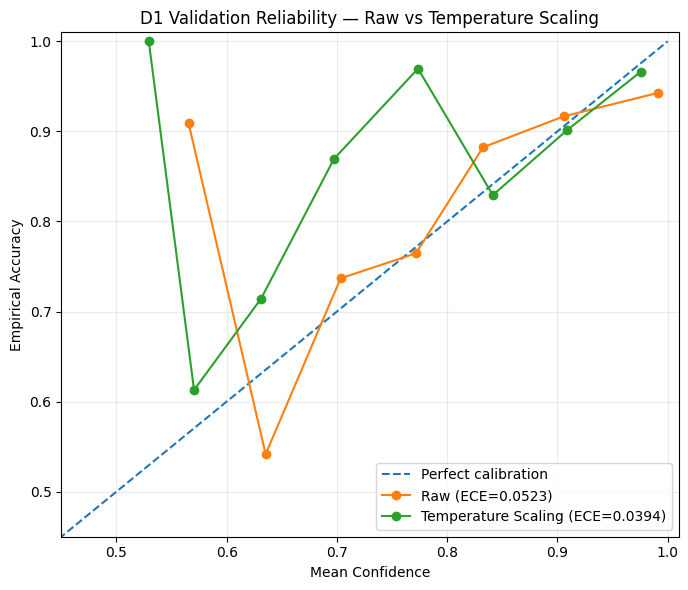

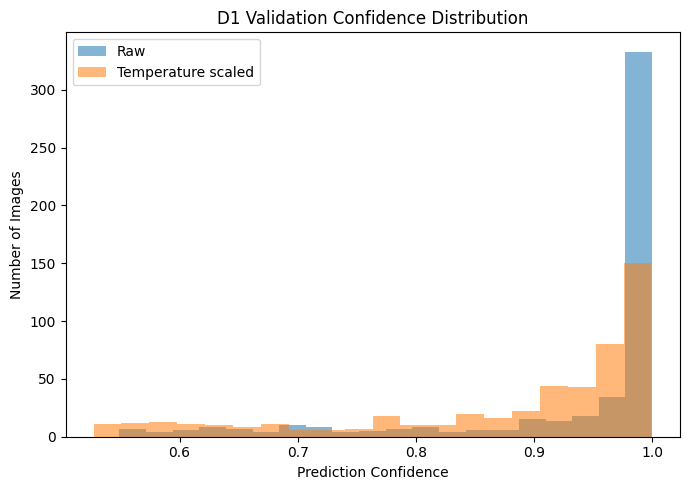



D1 TEMPERATURE-SCALING DECISION
Temperature T       : 1.806635
Raw NLL             : 0.339828
TS NLL              : 0.287494
Δ NLL improvement   : +0.052334

Raw ECE             : 0.052306
TS ECE              : 0.039368
Δ ECE improvement   : +0.012938

Raw Brier           : 0.080953
TS Brier            : 0.081950
Δ Brier improvement : -0.000997

Macro-F1 unchanged  : 0.886037
ROC-AUC unchanged   : 0.945495
Argmax unchanged    : True

DECISION:
LOCK TEMPERATURE SCALING — fitted temperature reduces development-set NLL. Save T and apply it unchanged during the final frozen test evaluation.

IMPORTANT: these post-temperature validation calibration metrics are descriptive because T was fitted on this same set.
The fitted T is now frozen. Final unbiased ECE/Brier/NLL will be measured later on the untouched internal test set.

✓ Model retraining: NO
✓ GPU required: NO
✓ Test set used: NO

Saved to:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/D1_TemperatureScaling_C2A_seed42


In [ ]:
# ======================================================================================
# THYTRUST-MD — D1
# TEMPERATURE SCALING + CALIBRATION LOCK
#
# MODEL:
#   Locked C2A ResNet50 + auxiliary bbox supervision — seed 42
#
# INPUT:
#   Saved VALIDATION logits only
#
# PURPOSE:
#   Fit one scalar temperature T by minimizing validation NLL.
#
# IMPORTANT:
#   ✓ NO MODEL TRAINING
#   ✓ NO GPU REQUIRED
#   ✓ NO TEST DATA LOADED
#   ✓ Temperature scaling cannot change class argmax for T > 0
#   ✓ Final unbiased calibration assessment happens later on locked test
#
# SAVES:
#   - fitted temperature
#   - raw + calibrated probabilities
#   - calibration metrics
#   - ECE bin tables
#   - reliability diagram
#   - confidence histogram
#   - config / audit JSON
# ======================================================================================

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar
from scipy.special import logsumexp

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    log_loss,
)


# ======================================================================================
# 0. PATHS
# ======================================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

SOURCE_FILE = (
    PROJECT_ROOT
    / "C2A_AuxBBox_ResNet50_seed42"
    / "csv_outputs"
    / "validation_predictions_logits.csv"
)

D1_ROOT = (
    PROJECT_ROOT
    / "D1_TemperatureScaling_C2A_seed42"
)

CSV_DIR = (
    D1_ROOT
    / "csv_outputs"
)

FIG_DIR = (
    D1_ROOT
    / "figures"
)

CONFIG_DIR = (
    D1_ROOT
    / "config"
)

for folder in [
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

assert SOURCE_FILE.exists(), (
    f"Missing C2A validation predictions:\n{SOURCE_FILE}"
)

print("=" * 115)
print("THYTRUST-MD — D1 TEMPERATURE SCALING")
print("=" * 115)

print(
    "Source:",
    SOURCE_FILE
)

print(
    "Calibration data: LOCKED 508-image validation set"
)

print(
    "Test set access : DISABLED"
)

print(
    "GPU required    : NO"
)


# ======================================================================================
# 1. LOAD C2A VALIDATION LOGITS
# ======================================================================================

df = pd.read_csv(
    SOURCE_FILE
)

required_cols = {
    "image_id",
    "true_label",
    "logit_benign",
    "logit_malignant",
}

missing = (
    required_cols
    -
    set(
        df.columns
    )
)

if missing:

    raise RuntimeError(
        f"Missing required columns: {missing}"
    )


assert len(
    df
) == 508


y = df[
    "true_label"
].to_numpy(
    dtype=np.int64
)


logits = df[
    [
        "logit_benign",
        "logit_malignant"
    ]
].to_numpy(
    dtype=np.float64
)


assert logits.shape == (
    508,
    2
)

assert np.isfinite(
    logits
).all()

assert np.isin(
    y,
    [
        0,
        1
    ]
).all()


print("\nDATA AUDIT")
print("-" * 70)

print(
    "Samples    :",
    len(
        y
    )
)

print(
    "Benign     :",
    int(
        (
            y == 0
        ).sum()
    )
)

print(
    "Malignant  :",
    int(
        (
            y == 1
        ).sum()
    )
)

print(
    "Finite logits: YES"
)


# ======================================================================================
# 2. NUMERIC HELPERS
# ======================================================================================

def softmax_np(
    z
):

    z = np.asarray(
        z,
        dtype=np.float64
    )

    z = (
        z
        -
        z.max(
            axis=1,
            keepdims=True
        )
    )

    exp_z = np.exp(
        z
    )

    return (
        exp_z
        /
        exp_z.sum(
            axis=1,
            keepdims=True
        )
    )


def nll_from_logits(
    logits_array,
    labels,
    temperature
):

    temperature = float(
        temperature
    )

    if (
        not np.isfinite(
            temperature
        )
        or
        temperature <= 0
    ):

        return np.inf


    scaled = (
        logits_array
        /
        temperature
    )


    log_probs = (
        scaled
        -
        logsumexp(
            scaled,
            axis=1,
            keepdims=True
        )
    )


    return float(
        -np.mean(
            log_probs[
                np.arange(
                    len(
                        labels
                    )
                ),
                labels
            ]
        )
    )


# ======================================================================================
# 3. RAW PROBABILITIES
# ======================================================================================

raw_probs = softmax_np(
    logits
)

raw_pred = raw_probs.argmax(
    axis=1
)


# ======================================================================================
# 4. FIT TEMPERATURE
#
# Optimize log(T), not T directly.
#
# Search T roughly from exp(-4)=0.018 to exp(4)=54.6.
# This is deliberately broad.
# ======================================================================================

def objective_log_temperature(
    log_t
):

    temperature = math.exp(
        float(
            log_t
        )
    )

    return nll_from_logits(
        logits,
        y,
        temperature
    )


optimization = minimize_scalar(

    objective_log_temperature,

    bounds=(
        -4.0,
        4.0
    ),

    method="bounded",

    options={
        "xatol":
            1e-10,

        "maxiter":
            1000
    }
)


if not optimization.success:

    raise RuntimeError(
        f"Temperature optimization failed: "
        f"{optimization.message}"
    )


LOG_T = float(
    optimization.x
)

TEMPERATURE = float(
    np.exp(
        LOG_T
    )
)


if (
    not np.isfinite(
        TEMPERATURE
    )
    or
    TEMPERATURE <= 0
):

    raise RuntimeError(
        "Invalid fitted temperature."
    )


scaled_logits = (
    logits
    /
    TEMPERATURE
)


calibrated_probs = softmax_np(
    scaled_logits
)

calibrated_pred = (
    calibrated_probs.argmax(
        axis=1
    )
)


# ======================================================================================
# 5. ARGMAX SAFETY CHECK
#
# Positive temperature scaling MUST NOT alter predicted class.
# ======================================================================================

if not np.array_equal(
    raw_pred,
    calibrated_pred
):

    raise RuntimeError(
        "Unexpected error: positive temperature scaling "
        "changed class predictions."
    )


print("\n")
print("=" * 115)
print("TEMPERATURE FIT")
print("=" * 115)

print(
    f"Temperature T : "
    f"{TEMPERATURE:.8f}"
)

print(
    f"log(T)        : "
    f"{LOG_T:.8f}"
)

print(
    f"Raw NLL       : "
    f"{nll_from_logits(logits, y, 1.0):.8f}"
)

print(
    f"Scaled NLL    : "
    f"{nll_from_logits(logits, y, TEMPERATURE):.8f}"
)

print(
    "Argmax changed: NO"
)


# ======================================================================================
# 6. ECE / MCE
# ======================================================================================

def fixed_bin_calibration(
    probs,
    labels,
    n_bins=15
):

    confidence = probs.max(
        axis=1
    )

    prediction = probs.argmax(
        axis=1
    )

    correctness = (
        prediction
        ==
        labels
    ).astype(
        float
    )


    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )


    rows = []

    ece = 0.0

    mce = 0.0


    for i in range(
        n_bins
    ):

        lower = (
            bin_edges[
                i
            ]
        )

        upper = (
            bin_edges[
                i + 1
            ]
        )


        if i == 0:

            mask = (
                (
                    confidence
                    >=
                    lower
                )
                &
                (
                    confidence
                    <=
                    upper
                )
            )

        else:

            mask = (
                (
                    confidence
                    >
                    lower
                )
                &
                (
                    confidence
                    <=
                    upper
                )
            )


        count = int(
            mask.sum()
        )


        if count > 0:

            mean_confidence = float(
                confidence[
                    mask
                ].mean()
            )

            accuracy = float(
                correctness[
                    mask
                ].mean()
            )

            gap = abs(
                accuracy
                -
                mean_confidence
            )

            weight = (
                count
                /
                len(
                    labels
                )
            )

            ece += (
                weight
                *
                gap
            )

            mce = max(
                mce,
                gap
            )


        else:

            mean_confidence = np.nan

            accuracy = np.nan

            gap = np.nan


        rows.append({

            "bin":
                i + 1,

            "lower":
                lower,

            "upper":
                upper,

            "count":
                count,

            "mean_confidence":
                mean_confidence,

            "accuracy":
                accuracy,

            "calibration_gap":
                gap
        })


    return (
        float(
            ece
        ),
        float(
            mce
        ),
        pd.DataFrame(
            rows
        )
    )


# ======================================================================================
# 7. ADAPTIVE ECE
#
# Equal-frequency confidence bins.
# Useful because fixed bins can become sparse.
# ======================================================================================

def adaptive_ece(
    probs,
    labels,
    n_bins=15
):

    confidence = probs.max(
        axis=1
    )

    prediction = probs.argmax(
        axis=1
    )

    correctness = (
        prediction
        ==
        labels
    ).astype(
        float
    )


    order = np.argsort(
        confidence
    )


    groups = np.array_split(
        order,
        n_bins
    )


    value = 0.0


    for group in groups:

        if len(
            group
        ) == 0:

            continue


        mean_confidence = confidence[
            group
        ].mean()

        accuracy = correctness[
            group
        ].mean()


        value += (

            len(
                group
            )
            /
            len(
                labels
            )

            *

            abs(
                accuracy
                -
                mean_confidence
            )
        )


    return float(
        value
    )


# ======================================================================================
# 8. AURC
# ======================================================================================

def aurc_score(
    probs,
    labels
):

    prediction = probs.argmax(
        axis=1
    )

    confidence = probs.max(
        axis=1
    )


    errors = (
        prediction
        !=
        labels
    ).astype(
        float
    )


    order = np.argsort(
        -confidence
    )


    errors = errors[
        order
    ]


    coverage = (
        np.arange(
            1,
            len(
                errors
            )
            +
            1
        )
        /
        len(
            errors
        )
    )


    risk = (
        np.cumsum(
            errors
        )
        /
        np.arange(
            1,
            len(
                errors
            )
            +
            1
        )
    )


    return float(
        np.trapezoid(

            np.r_[
                0.0,
                risk
            ],

            np.r_[
                0.0,
                coverage
            ]
        )
    )


# ======================================================================================
# 9. FULL METRICS
# ======================================================================================

def evaluate_probabilities(
    probs,
    labels
):

    prediction = probs.argmax(
        axis=1
    )


    malignant_prob = probs[
        :,
        1
    ]


    tn, fp, fn, tp = confusion_matrix(

        labels,

        prediction,

        labels=[
            0,
            1
        ]

    ).ravel()


    sensitivity = (
        tp
        /
        max(
            tp + fn,
            1
        )
    )


    specificity = (
        tn
        /
        max(
            tn + fp,
            1
        )
    )


    ece, mce, bin_df = (
        fixed_bin_calibration(
            probs,
            labels,
            n_bins=15
        )
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    labels,
                    prediction
                )
            ),

        "Precision":
            float(
                precision_score(
                    labels,
                    prediction,
                    zero_division=0
                )
            ),

        "Recall":
            float(
                recall_score(
                    labels,
                    prediction,
                    zero_division=0
                )
            ),

        "Sensitivity":
            float(
                sensitivity
            ),

        "Specificity":
            float(
                specificity
            ),

        "F1":
            float(
                f1_score(
                    labels,
                    prediction,
                    zero_division=0
                )
            ),

        "Macro-F1":
            float(
                f1_score(
                    labels,
                    prediction,
                    average="macro",
                    zero_division=0
                )
            ),

        "Weighted-F1":
            float(
                f1_score(
                    labels,
                    prediction,
                    average="weighted",
                    zero_division=0
                )
            ),

        "Balanced Accuracy":
            float(
                balanced_accuracy_score(
                    labels,
                    prediction
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    labels,
                    prediction
                )
            ),

        "Cohen Kappa":
            float(
                cohen_kappa_score(
                    labels,
                    prediction
                )
            ),

        "ROC-AUC":
            float(
                roc_auc_score(
                    labels,
                    malignant_prob
                )
            ),

        "PR-AUC":
            float(
                average_precision_score(
                    labels,
                    malignant_prob
                )
            ),

        "ECE_15":
            float(
                ece
            ),

        "MCE_15":
            float(
                mce
            ),

        "Adaptive_ECE_15":
            float(
                adaptive_ece(
                    probs,
                    labels,
                    n_bins=15
                )
            ),

        "Brier":
            float(
                np.mean(
                    (
                        malignant_prob
                        -
                        labels
                    ) ** 2
                )
            ),

        "NLL":
            float(
                log_loss(
                    labels,
                    probs,
                    labels=[
                        0,
                        1
                    ]
                )
            ),

        "AURC":
            float(
                aurc_score(
                    probs,
                    labels
                )
            )
    }


raw_metrics = evaluate_probabilities(
    raw_probs,
    y
)

calibrated_metrics = evaluate_probabilities(
    calibrated_probs,
    y
)


raw_ece, raw_mce, raw_bins = (
    fixed_bin_calibration(
        raw_probs,
        y,
        n_bins=15
    )
)


cal_ece, cal_mce, cal_bins = (
    fixed_bin_calibration(
        calibrated_probs,
        y,
        n_bins=15
    )
)


# ======================================================================================
# 10. COMPARISON TABLE
# ======================================================================================

metric_rows = []


LOWER_IS_BETTER = {
    "ECE_15",
    "MCE_15",
    "Adaptive_ECE_15",
    "Brier",
    "NLL",
    "AURC",
}


for metric in raw_metrics:

    raw_value = raw_metrics[
        metric
    ]

    calibrated_value = calibrated_metrics[
        metric
    ]


    if metric in LOWER_IS_BETTER:

        improvement = (
            raw_value
            -
            calibrated_value
        )

    else:

        improvement = (
            calibrated_value
            -
            raw_value
        )


    metric_rows.append({

        "Metric":
            metric,

        "Raw":
            raw_value,

        "Temperature_Scaled":
            calibrated_value,

        "Improvement_Positive_Is_Better":
            improvement
    })


metrics_df = pd.DataFrame(
    metric_rows
)


metrics_df.to_csv(

    CSV_DIR
    / "D1_raw_vs_temperature_scaled_metrics.csv",

    index=False
)


print("\n")
print("=" * 115)
print("RAW vs TEMPERATURE-SCALED — DEVELOPMENT/CALIBRATION SET")
print("=" * 115)

display(
    metrics_df.round(
        6
    )
)


# ======================================================================================
# 11. VERIFY DISCRIMINATION / HARD CLASSIFICATION INVARIANCE
# ======================================================================================

invariant_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Sensitivity",
    "Specificity",
    "F1",
    "Macro-F1",
    "Weighted-F1",
    "Balanced Accuracy",
    "MCC",
    "Cohen Kappa",
    "ROC-AUC",
    "PR-AUC",
]


for metric in invariant_metrics:

    if not np.isclose(
        raw_metrics[
            metric
        ],
        calibrated_metrics[
            metric
        ],
        atol=1e-12
    ):

        print(
            f"NOTE: {metric} changed slightly. "
            "For ranking metrics this can occur only from numerical effects."
        )


# ======================================================================================
# 12. SAVE PER-IMAGE CALIBRATED OUTPUT
# ======================================================================================

output_df = df.copy()


output_df[
    "raw_prob_benign"
] = raw_probs[
    :,
    0
]


output_df[
    "raw_prob_malignant"
] = raw_probs[
    :,
    1
]


output_df[
    "raw_confidence"
] = raw_probs.max(
    axis=1
)


output_df[
    "temperature"
] = TEMPERATURE


output_df[
    "scaled_logit_benign"
] = scaled_logits[
    :,
    0
]


output_df[
    "scaled_logit_malignant"
] = scaled_logits[
    :,
    1
]


output_df[
    "ts_prob_benign"
] = calibrated_probs[
    :,
    0
]


output_df[
    "ts_prob_malignant"
] = calibrated_probs[
    :,
    1
]


output_df[
    "ts_confidence"
] = calibrated_probs.max(
    axis=1
)


output_df[
    "ts_predicted_label"
] = calibrated_pred


output_df.to_csv(

    CSV_DIR
    / "validation_predictions_temperature_scaled.csv",

    index=False
)


# ======================================================================================
# 13. SAVE BIN TABLES
# ======================================================================================

raw_bins[
    "calibration"
] = "Raw"

cal_bins[
    "calibration"
] = "TemperatureScaled"


bin_table = pd.concat(
    [
        raw_bins,
        cal_bins
    ],
    ignore_index=True
)


bin_table.to_csv(

    CSV_DIR
    / "D1_reliability_bins.csv",

    index=False
)


# ======================================================================================
# 14. SAVE TEMPERATURE / CONFIG
# ======================================================================================

temperature_record = {

    "project":
        "ThyTrust-MD",

    "phase":
        "D1_TemperatureScaling",

    "model":
        "C2A_ResNet50_AuxBBox",

    "model_seed":
        42,

    "calibration_dataset":
        "locked_validation",

    "calibration_samples":
        int(
            len(
                y
            )
        ),

    "temperature":
        TEMPERATURE,

    "log_temperature":
        LOG_T,

    "optimization_method":
        "bounded scalar minimization of NLL over log(T)",

    "raw_nll":
        float(
            raw_metrics[
                "NLL"
            ]
        ),

    "temperature_scaled_nll":
        float(
            calibrated_metrics[
                "NLL"
            ]
        ),

    "raw_ece_15":
        float(
            raw_metrics[
                "ECE_15"
            ]
        ),

    "temperature_scaled_ece_15":
        float(
            calibrated_metrics[
                "ECE_15"
            ]
        ),

    "raw_brier":
        float(
            raw_metrics[
                "Brier"
            ]
        ),

    "temperature_scaled_brier":
        float(
            calibrated_metrics[
                "Brier"
            ]
        ),

    "test_used":
        False,

    "important_note":
        (
            "Temperature was fitted on the validation/calibration set. "
            "Post-scaling metrics on this same set are descriptive and "
            "not an unbiased final calibration evaluation."
        )
}


with open(

    CONFIG_DIR
    / "temperature_scaling.json",

    "w"

) as f:

    json.dump(
        temperature_record,
        f,
        indent=2
    )


# ======================================================================================
# 15. RELIABILITY DIAGRAM
# ======================================================================================

def reliability_xy(
    bin_df
):

    used = bin_df[
        bin_df[
            "count"
        ] > 0
    ]


    return (

        used[
            "mean_confidence"
        ].to_numpy(),

        used[
            "accuracy"
        ].to_numpy()
    )


x_raw, y_raw = reliability_xy(
    raw_bins
)

x_cal, y_cal = reliability_xy(
    cal_bins
)


fig, ax = plt.subplots(
    figsize=(
        7,
        6
    )
)


ax.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--",
    label="Perfect calibration"
)


ax.plot(
    x_raw,
    y_raw,
    marker="o",
    label=(
        f"Raw "
        f"(ECE={raw_metrics['ECE_15']:.4f})"
    )
)


ax.plot(
    x_cal,
    y_cal,
    marker="o",
    label=(
        f"Temperature Scaling "
        f"(ECE={calibrated_metrics['ECE_15']:.4f})"
    )
)


ax.set_xlim(
    0.45,
    1.01
)

ax.set_ylim(
    0.45,
    1.01
)

ax.set_xlabel(
    "Mean Confidence"
)

ax.set_ylabel(
    "Empirical Accuracy"
)

ax.set_title(
    "D1 Validation Reliability — Raw vs Temperature Scaling"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "D1_reliability_raw_vs_temperature_scaled.png",

    dpi=300,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "D1_reliability_raw_vs_temperature_scaled.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 16. CONFIDENCE DISTRIBUTION
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        7,
        5
    )
)


ax.hist(
    raw_probs.max(
        axis=1
    ),
    bins=20,
    alpha=0.55,
    label="Raw"
)


ax.hist(
    calibrated_probs.max(
        axis=1
    ),
    bins=20,
    alpha=0.55,
    label="Temperature scaled"
)


ax.set_xlabel(
    "Prediction Confidence"
)

ax.set_ylabel(
    "Number of Images"
)

ax.set_title(
    "D1 Validation Confidence Distribution"
)

ax.legend()

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "D1_confidence_distribution.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 17. D1 DECISION / LOCK
# ======================================================================================

raw_nll = raw_metrics[
    "NLL"
]

ts_nll = calibrated_metrics[
    "NLL"
]


raw_ece_value = raw_metrics[
    "ECE_15"
]

ts_ece_value = calibrated_metrics[
    "ECE_15"
]


raw_brier = raw_metrics[
    "Brier"
]

ts_brier = calibrated_metrics[
    "Brier"
]


# Temperature scaling is retained if NLL improves because NLL is the
# optimization target and temperature scaling is a standard monotonic
# post-hoc calibration method.
#
# ECE / Brier direction is recorded as supporting diagnostics.

if ts_nll < raw_nll:

    decision = (
        "LOCK TEMPERATURE SCALING — fitted temperature reduces "
        "development-set NLL. Save T and apply it unchanged during "
        "the final frozen test evaluation."
    )

else:

    decision = (
        "DO NOT RETAIN TEMPERATURE SCALING — fitted temperature "
        "does not improve the calibration objective."
    )


decision_record = {

    "temperature":
        TEMPERATURE,

    "raw_nll":
        raw_nll,

    "scaled_nll":
        ts_nll,

    "nll_improvement":
        raw_nll
        -
        ts_nll,

    "raw_ece":
        raw_ece_value,

    "scaled_ece":
        ts_ece_value,

    "ece_improvement":
        raw_ece_value
        -
        ts_ece_value,

    "raw_brier":
        raw_brier,

    "scaled_brier":
        ts_brier,

    "brier_improvement":
        raw_brier
        -
        ts_brier,

    "decision":
        decision,

    "test_used":
        False
}


with open(

    CONFIG_DIR
    / "D1_decision.json",

    "w"

) as f:

    json.dump(
        decision_record,
        f,
        indent=2
    )


# ======================================================================================
# 18. FINAL OUTPUT
# ======================================================================================

print("\n")
print("=" * 115)
print("D1 TEMPERATURE-SCALING DECISION")
print("=" * 115)

print(
    f"Temperature T       : "
    f"{TEMPERATURE:.6f}"
)

print(
    f"Raw NLL             : "
    f"{raw_nll:.6f}"
)

print(
    f"TS NLL              : "
    f"{ts_nll:.6f}"
)

print(
    f"Δ NLL improvement   : "
    f"{raw_nll - ts_nll:+.6f}"
)

print()

print(
    f"Raw ECE             : "
    f"{raw_ece_value:.6f}"
)

print(
    f"TS ECE              : "
    f"{ts_ece_value:.6f}"
)

print(
    f"Δ ECE improvement   : "
    f"{raw_ece_value - ts_ece_value:+.6f}"
)

print()

print(
    f"Raw Brier           : "
    f"{raw_brier:.6f}"
)

print(
    f"TS Brier            : "
    f"{ts_brier:.6f}"
)

print(
    f"Δ Brier improvement : "
    f"{raw_brier - ts_brier:+.6f}"
)

print()

print(
    f"Macro-F1 unchanged  : "
    f"{raw_metrics['Macro-F1']:.6f}"
)

print(
    f"ROC-AUC unchanged   : "
    f"{raw_metrics['ROC-AUC']:.6f}"
)

print(
    f"Argmax unchanged    : "
    f"{np.array_equal(raw_pred, calibrated_pred)}"
)

print("\nDECISION:")
print(
    decision
)

print(
    "\nIMPORTANT: these post-temperature validation calibration "
    "metrics are descriptive because T was fitted on this same set."
)

print(
    "The fitted T is now frozen. Final unbiased ECE/Brier/NLL "
    "will be measured later on the untouched internal test set."
)

print(
    "\n✓ Model retraining: NO"
)

print(
    "✓ GPU required: NO"
)

print(
    "✓ Test set used: NO"
)

print(
    f"\nSaved to:\n{D1_ROOT}"
)

print("=" * 115)

# D2 — Uncertainty + Selective Prediction

THYTRUST-MD — D2 UNCERTAINTY / SELECTIVE PREDICTION
Samples              : 508
Locked temperature T : 1.806635
Model training       : NO
Internal test access : NO

UNCERTAINTY AUDIT
--------------------------------------------------------------------------------
Errors                 : 48/508
Raw mean confidence    : 0.935526
TS mean confidence     : 0.880198
TS mean entropy        : 0.414766
Confidence ranking same: True


UNCERTAINTY AS ERROR DETECTOR


,Uncertainty,Error_Detection_AUROC,Error_Detection_AUPRC,Mean_Correct,Mean_Error
0,Predictive Entropy,0.751608,0.232724,0.387029,0.680586
1,1 - Confidence,0.751608,0.232724,0.107486,0.237829
2,1 - Probability Margin,0.751608,0.232724,0.214972,0.475658



RISK-COVERAGE
--------------------------------------------------------------------------------
AURC        : 0.038726
Oracle AURC : 0.004612
E-AURC      : 0.034114


SELECTIVE PREDICTION OPERATING POINTS


,Target_Coverage,Achieved_Development_Coverage,Retained_N,Abstained_N,TS_Confidence_Threshold,Selective_Risk,Selective_Accuracy,Macro_F1,Balanced_Accuracy,MCC,Sensitivity,Specificity
0,1.00,1.000000,508,0,0.527265,0.094488,0.905512,0.886037,0.887575,0.772113,0.930556,0.844595
1,0.95,0.950787,483,25,0.580970,0.082816,0.917184,0.898988,0.904359,0.798380,0.933718,0.875000
2,0.90,0.901575,458,50,0.629641,0.069869,0.930131,0.913258,0.919471,0.826990,0.942943,0.896000
3,0.85,0.850394,432,76,0.695841,0.062500,0.937500,0.922314,0.925618,0.844763,0.952077,0.899160
4,0.80,0.801181,407,101,0.775376,0.058968,0.941032,0.926891,0.931628,0.854052,0.952542,0.910714
5,0.70,0.700787,356,152,0.856895,0.053371,0.946629,0.934538,0.944194,0.870150,0.949612,0.938776


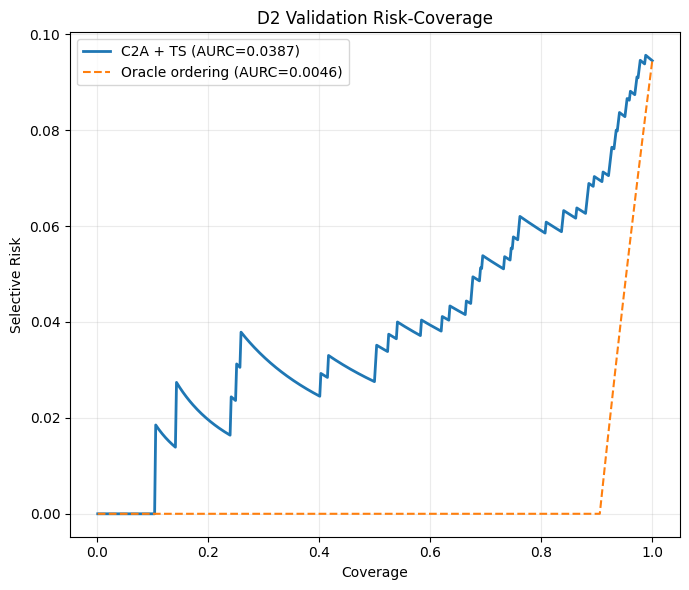

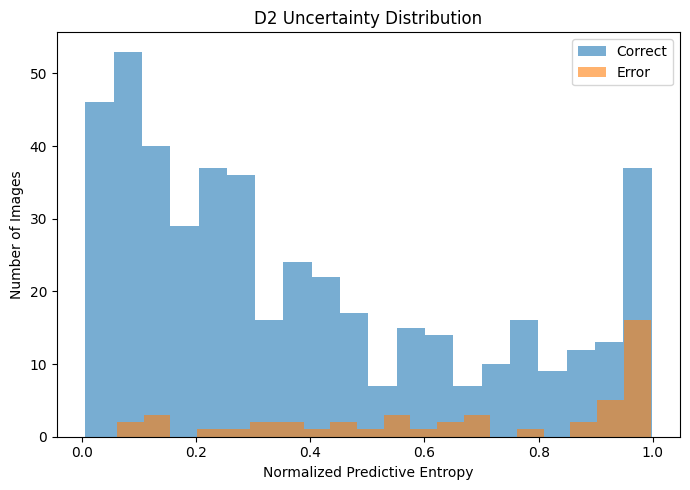



D2 SELECTIVE-PREDICTION LOCK
Temperature               : 1.806635
Error-detection AUROC     : 0.751608
Error-detection AUPRC     : 0.232724
AURC                      : 0.038726
Oracle AURC               : 0.004612
E-AURC                    : 0.034114
Raw/TS confidence ranking : True

90% DEVELOPMENT COVERAGE
  Frozen confidence ≥ 0.629641
  Selective accuracy : 0.930131
  Macro-F1           : 0.913258
  MCC                : 0.826990

80% DEVELOPMENT COVERAGE
  Frozen confidence ≥ 0.775376
  Selective accuracy : 0.941032
  Macro-F1           : 0.926891
  MCC                : 0.854052

LOCK:
Use temperature-scaled confidence for selective prediction.
Freeze the 90% and 80% development confidence thresholds.
Apply them unchanged during final internal-test evaluation.

✓ Retraining: NO
✓ GPU: NO
✓ Test set used: NO

Saved to:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/D2_Uncertainty_SelectivePrediction_C2A_seed42


In [ ]:
# ======================================================================================
# THYTRUST-MD — D2
# UNCERTAINTY + SELECTIVE PREDICTION / ABSTENTION
#
# INPUT:
#   D1 temperature-scaled validation predictions
#
# PURPOSE:
#   1. Quantify uncertainty quality
#   2. Risk-coverage analysis
#   3. Error-detection AUROC / AUPRC
#   4. Selective metrics at fixed development coverages
#   5. Freeze confidence thresholds for future TEST application
#
# IMPORTANT:
#   ✓ NO MODEL TRAINING
#   ✓ NO GPU
#   ✓ NO TEST DATA
#   ✓ Uses fitted D1 temperature unchanged
#   ✓ Thresholds derived from validation/development data only
#
# FINAL TEST LATER:
#   Apply these thresholds AS-IS.
#   Do not recalibrate or reselect them on test.
# ======================================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)


# ======================================================================================
# 0. PATHS
# ======================================================================================

ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

D1_ROOT = (
    ROOT
    / "D1_TemperatureScaling_C2A_seed42"
)

SOURCE_FILE = (
    D1_ROOT
    / "csv_outputs"
    / "validation_predictions_temperature_scaled.csv"
)

TEMP_FILE = (
    D1_ROOT
    / "config"
    / "temperature_scaling.json"
)

D2_ROOT = (
    ROOT
    / "D2_Uncertainty_SelectivePrediction_C2A_seed42"
)

CSV_DIR = D2_ROOT / "csv_outputs"
FIG_DIR = D2_ROOT / "figures"
CONFIG_DIR = D2_ROOT / "config"

for folder in [
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


assert SOURCE_FILE.exists(), (
    f"Missing D1 predictions:\n{SOURCE_FILE}"
)

assert TEMP_FILE.exists(), (
    f"Missing D1 temperature:\n{TEMP_FILE}"
)


# ======================================================================================
# 1. LOAD LOCKED D1 OUTPUT
# ======================================================================================

df = pd.read_csv(
    SOURCE_FILE
)

with open(
    TEMP_FILE,
    "r"
) as f:

    temperature_record = json.load(
        f
    )


TEMPERATURE = float(
    temperature_record[
        "temperature"
    ]
)


required = {
    "image_id",
    "true_label",
    "raw_prob_benign",
    "raw_prob_malignant",
    "ts_prob_benign",
    "ts_prob_malignant",
}


missing = (
    required
    -
    set(
        df.columns
    )
)

if missing:

    raise RuntimeError(
        f"Missing columns: {missing}"
    )


assert len(
    df
) == 508


y = df[
    "true_label"
].to_numpy(
    dtype=int
)


raw_probs = df[
    [
        "raw_prob_benign",
        "raw_prob_malignant"
    ]
].to_numpy(
    dtype=float
)


ts_probs = df[
    [
        "ts_prob_benign",
        "ts_prob_malignant"
    ]
].to_numpy(
    dtype=float
)


assert np.isfinite(
    raw_probs
).all()

assert np.isfinite(
    ts_probs
).all()


print("=" * 115)
print("THYTRUST-MD — D2 UNCERTAINTY / SELECTIVE PREDICTION")
print("=" * 115)

print(
    f"Samples              : {len(y)}"
)

print(
    f"Locked temperature T : {TEMPERATURE:.6f}"
)

print(
    "Model training       : NO"
)

print(
    "Internal test access : NO"
)


# ======================================================================================
# 2. UNCERTAINTY SCORES
# ======================================================================================

EPS = 1e-12


raw_pred = raw_probs.argmax(
    axis=1
)

ts_pred = ts_probs.argmax(
    axis=1
)


# Temperature scaling must preserve argmax.
assert np.array_equal(
    raw_pred,
    ts_pred
)


correct = (
    ts_pred
    ==
    y
)

error = (
    ~correct
).astype(
    int
)


raw_confidence = raw_probs.max(
    axis=1
)

ts_confidence = ts_probs.max(
    axis=1
)


# Main uncertainty:
# predictive entropy, normalized to [0,1] for binary classification.

entropy = (

    -np.sum(

        ts_probs
        *
        np.log(
            np.clip(
                ts_probs,
                EPS,
                1.0
            )
        ),

        axis=1
    )

    /

    np.log(
        2.0
    )
)


# Variation / confidence uncertainty.
confidence_uncertainty = (
    1.0
    -
    ts_confidence
)


# Probability margin:
# smaller margin = more uncertain.

margin = np.abs(
    ts_probs[
        :,
        1
    ]
    -
    ts_probs[
        :,
        0
    ]
)


margin_uncertainty = (
    1.0
    -
    margin
)


# ======================================================================================
# 3. CHECK RAW vs TS CONFIDENCE RANKING
#
# For binary positive temperature scaling, ranking should be preserved.
# ======================================================================================

raw_order = np.argsort(
    -raw_confidence,
    kind="mergesort"
)

ts_order = np.argsort(
    -ts_confidence,
    kind="mergesort"
)


ranking_identical = bool(
    np.array_equal(
        raw_order,
        ts_order
    )
)


print("\nUNCERTAINTY AUDIT")
print("-" * 80)

print(
    f"Errors                 : "
    f"{int(error.sum())}/{len(error)}"
)

print(
    f"Raw mean confidence    : "
    f"{raw_confidence.mean():.6f}"
)

print(
    f"TS mean confidence     : "
    f"{ts_confidence.mean():.6f}"
)

print(
    f"TS mean entropy        : "
    f"{entropy.mean():.6f}"
)

print(
    f"Confidence ranking same: "
    f"{ranking_identical}"
)


# ======================================================================================
# 4. ERROR-DETECTION PERFORMANCE
#
# Here:
#   positive class = model made an ERROR
#   higher uncertainty should identify errors.
# ======================================================================================

def error_detection_metrics(
    uncertainty,
    error_labels
):

    if len(
        np.unique(
            error_labels
        )
    ) < 2:

        return {
            "AUROC":
                np.nan,

            "AUPRC":
                np.nan
        }


    return {

        "AUROC":
            float(
                roc_auc_score(
                    error_labels,
                    uncertainty
                )
            ),

        "AUPRC":
            float(
                average_precision_score(
                    error_labels,
                    uncertainty
                )
            )
    }


uncertainty_results = []


for name, values in {

    "Predictive Entropy":
        entropy,

    "1 - Confidence":
        confidence_uncertainty,

    "1 - Probability Margin":
        margin_uncertainty,

}.items():

    result = error_detection_metrics(
        values,
        error
    )


    uncertainty_results.append({

        "Uncertainty":
            name,

        "Error_Detection_AUROC":
            result[
                "AUROC"
            ],

        "Error_Detection_AUPRC":
            result[
                "AUPRC"
            ],

        "Mean_Correct":
            float(
                values[
                    correct
                ].mean()
            ),

        "Mean_Error":
            float(
                values[
                    ~correct
                ].mean()
            )
    })


uncertainty_df = pd.DataFrame(
    uncertainty_results
)


uncertainty_df.to_csv(

    CSV_DIR
    / "D2_uncertainty_error_detection.csv",

    index=False
)


print("\n")
print("=" * 115)
print("UNCERTAINTY AS ERROR DETECTOR")
print("=" * 115)

display(
    uncertainty_df.round(
        6
    )
)


# ======================================================================================
# 5. RISK-COVERAGE
# ======================================================================================

def risk_coverage_curve(
    confidence,
    labels,
    predictions
):

    order = np.argsort(
        -confidence,
        kind="mergesort"
    )


    sorted_correct = (
        predictions[
            order
        ]
        ==
        labels[
            order
        ]
    ).astype(
        float
    )


    sorted_error = (
        1.0
        -
        sorted_correct
    )


    n = len(
        labels
    )


    retained = np.arange(
        1,
        n + 1
    )


    coverage = (
        retained
        /
        n
    )


    cumulative_errors = np.cumsum(
        sorted_error
    )


    risk = (
        cumulative_errors
        /
        retained
    )


    selective_accuracy = (
        1.0
        -
        risk
    )


    return (
        order,
        coverage,
        risk,
        selective_accuracy
    )


(
    ts_order,
    coverage,
    risk,
    selective_accuracy
) = risk_coverage_curve(

    ts_confidence,

    y,

    ts_pred
)


def trapezoid(
    yy,
    xx
):

    if hasattr(
        np,
        "trapezoid"
    ):

        return np.trapezoid(
            yy,
            xx
        )

    return np.trapz(
        yy,
        xx
    )


AURC = float(

    trapezoid(

        np.r_[
            0.0,
            risk
        ],

        np.r_[
            0.0,
            coverage
        ]
    )
)


# ======================================================================================
# 6. ORACLE AURC + EXCESS AURC
#
# Oracle ranking:
#   every correct prediction first,
#   every error last.
#
# This gives the empirically best possible risk-coverage ranking for the
# model's existing correct/error pattern.
# ======================================================================================

oracle_error_order = np.sort(
    error
)


oracle_risk = (

    np.cumsum(
        oracle_error_order
    )

    /

    np.arange(
        1,
        len(
            oracle_error_order
        )
        +
        1
    )
)


oracle_coverage = (

    np.arange(
        1,
        len(
            oracle_error_order
        )
        +
        1
    )

    /

    len(
        oracle_error_order
    )
)


ORACLE_AURC = float(

    trapezoid(

        np.r_[
            0.0,
            oracle_risk
        ],

        np.r_[
            0.0,
            oracle_coverage
        ]
    )
)


E_AURC = float(
    AURC
    -
    ORACLE_AURC
)


risk_curve_df = pd.DataFrame({

    "rank":
        np.arange(
            1,
            len(
                y
            )
            +
            1
        ),

    "coverage":
        coverage,

    "risk":
        risk,

    "selective_accuracy":
        selective_accuracy,

    "image_id":
        df[
            "image_id"
        ].to_numpy()[
            ts_order
        ],

    "confidence":
        ts_confidence[
            ts_order
        ],

    "entropy":
        entropy[
            ts_order
        ],

    "correct":
        correct[
            ts_order
        ].astype(
            int
        )
})


risk_curve_df.to_csv(

    CSV_DIR
    / "D2_risk_coverage_curve.csv",

    index=False
)


print("\nRISK-COVERAGE")
print("-" * 80)

print(
    f"AURC        : "
    f"{AURC:.6f}"
)

print(
    f"Oracle AURC : "
    f"{ORACLE_AURC:.6f}"
)

print(
    f"E-AURC      : "
    f"{E_AURC:.6f}"
)


# ======================================================================================
# 7. SELECTIVE PERFORMANCE AT PRE-SPECIFIED COVERAGES
#
# These are DEVELOPMENT operating points.
#
# We save the minimum confidence threshold associated with each target
# coverage. Later the SAME numeric thresholds are applied to the
# untouched test set.
# ======================================================================================

TARGET_COVERAGES = [
    1.00,
    0.95,
    0.90,
    0.85,
    0.80,
    0.70,
]


def selective_metrics_at_target_coverage(
    target_coverage
):

    n = len(
        y
    )


    k = int(
        np.ceil(
            target_coverage
            *
            n
        )
    )


    k = min(
        max(
            k,
            1
        ),
        n
    )


    selected_idx = (
        ts_order[
            :k
        ]
    )


    selected_y = y[
        selected_idx
    ]

    selected_pred = ts_pred[
        selected_idx
    ]

    selected_confidence = ts_confidence[
        selected_idx
    ]


    achieved_coverage = (
        len(
            selected_idx
        )
        /
        n
    )


    selective_risk = (
        1.0
        -
        accuracy_score(
            selected_y,
            selected_pred
        )
    )


    # Threshold = lowest confidence among retained cases.
    confidence_threshold = float(
        selected_confidence.min()
    )


    # Confusion metrics may be undefined only if one class disappears.
    cm = confusion_matrix(
        selected_y,
        selected_pred,
        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    sensitivity = (
        tp
        /
        max(
            tp + fn,
            1
        )
    )


    specificity = (
        tn
        /
        max(
            tn + fp,
            1
        )
    )


    return {

        "Target_Coverage":
            target_coverage,

        "Achieved_Development_Coverage":
            achieved_coverage,

        "Retained_N":
            len(
                selected_idx
            ),

        "Abstained_N":
            n
            -
            len(
                selected_idx
            ),

        "TS_Confidence_Threshold":
            confidence_threshold,

        "Selective_Risk":
            selective_risk,

        "Selective_Accuracy":
            1.0
            -
            selective_risk,

        "Macro_F1":
            f1_score(
                selected_y,
                selected_pred,
                average="macro",
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                selected_y,
                selected_pred
            ),

        "MCC":
            matthews_corrcoef(
                selected_y,
                selected_pred
            ),

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity
    }


selective_rows = [

    selective_metrics_at_target_coverage(
        coverage_value
    )

    for coverage_value
    in TARGET_COVERAGES
]


selective_df = pd.DataFrame(
    selective_rows
)


selective_df.to_csv(

    CSV_DIR
    / "D2_selective_operating_points.csv",

    index=False
)


print("\n")
print("=" * 115)
print("SELECTIVE PREDICTION OPERATING POINTS")
print("=" * 115)

display(
    selective_df.round(
        6
    )
)


# ======================================================================================
# 8. FREEZE OPERATING THRESHOLDS
#
# We preselect 90% and 80% coverage as primary manuscript operating
# points. They are NOT reselected on test.
# ======================================================================================

PRIMARY_COVERAGES = [
    0.90,
    0.80
]


threshold_records = {}


for target in PRIMARY_COVERAGES:

    row = selective_df[
        np.isclose(
            selective_df[
                "Target_Coverage"
            ],
            target
        )
    ].iloc[
        0
    ]


    threshold_records[
        f"target_coverage_{int(target * 100)}"
    ] = {

        "target_development_coverage":
            float(
                target
            ),

        "frozen_ts_confidence_threshold":
            float(
                row[
                    "TS_Confidence_Threshold"
                ]
            ),

        "development_selective_accuracy":
            float(
                row[
                    "Selective_Accuracy"
                ]
            ),

        "development_macro_f1":
            float(
                row[
                    "Macro_F1"
                ]
            ),

        "development_mcc":
            float(
                row[
                    "MCC"
                ]
            )
    }


# ======================================================================================
# 9. PER-IMAGE UNCERTAINTY EXPORT
# ======================================================================================

uncertainty_export = df.copy()


uncertainty_export[
    "ts_prediction"
] = ts_pred


uncertainty_export[
    "ts_confidence_D2"
] = ts_confidence


uncertainty_export[
    "predictive_entropy_normalized"
] = entropy


uncertainty_export[
    "confidence_uncertainty"
] = confidence_uncertainty


uncertainty_export[
    "probability_margin"
] = margin


uncertainty_export[
    "correct_D2"
] = correct.astype(
    int
)


uncertainty_export[
    "error_D2"
] = error


uncertainty_export.to_csv(

    CSV_DIR
    / "D2_validation_uncertainty_scores.csv",

    index=False
)


# ======================================================================================
# 10. SAVE LOCKED D2 CONFIG
# ======================================================================================

d2_record = {

    "project":
        "ThyTrust-MD",

    "phase":
        "D2_Uncertainty_SelectivePrediction",

    "model":
        "C2A_ResNet50_AuxBBox_seed42",

    "temperature":
        TEMPERATURE,

    "primary_uncertainty":
        "normalized predictive entropy",

    "selective_score":
        "temperature-scaled max softmax confidence",

    "error_detection_positive_class":
        "classification_error",

    "aurc":
        AURC,

    "oracle_aurc":
        ORACLE_AURC,

    "excess_aurc":
        E_AURC,

    "raw_vs_temperature_confidence_ranking_identical":
        ranking_identical,

    "primary_operating_points":
        threshold_records,

    "important_note":
        (
            "Thresholds are development-set operating points. "
            "During final test evaluation, thresholds must be applied "
            "unchanged; target coverage is not guaranteed on test."
        ),

    "test_used":
        False
}


with open(

    CONFIG_DIR
    / "D2_selective_prediction_lock.json",

    "w"

) as f:

    json.dump(
        d2_record,
        f,
        indent=2
    )


# ======================================================================================
# 11. RISK-COVERAGE FIGURE
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        7,
        6
    )
)


ax.plot(
    coverage,
    risk,
    linewidth=2,
    label=(
        f"C2A + TS "
        f"(AURC={AURC:.4f})"
    )
)


ax.plot(
    oracle_coverage,
    oracle_risk,
    linestyle="--",
    label=(
        f"Oracle ordering "
        f"(AURC={ORACLE_AURC:.4f})"
    )
)


ax.set_xlabel(
    "Coverage"
)

ax.set_ylabel(
    "Selective Risk"
)

ax.set_title(
    "D2 Validation Risk-Coverage"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "D2_risk_coverage.png",

    dpi=300,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "D2_risk_coverage.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 12. UNCERTAINTY DISTRIBUTION: CORRECT vs ERROR
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        7,
        5
    )
)


ax.hist(
    entropy[
        correct
    ],
    bins=20,
    alpha=0.6,
    label="Correct"
)


ax.hist(
    entropy[
        ~correct
    ],
    bins=20,
    alpha=0.6,
    label="Error"
)


ax.set_xlabel(
    "Normalized Predictive Entropy"
)

ax.set_ylabel(
    "Number of Images"
)

ax.set_title(
    "D2 Uncertainty Distribution"
)

ax.legend()

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "D2_entropy_correct_vs_error.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 13. FINAL D2 OUTPUT
# ======================================================================================

entropy_row = uncertainty_df[
    uncertainty_df[
        "Uncertainty"
    ]
    ==
    "Predictive Entropy"
].iloc[
    0
]


coverage90 = selective_df[
    np.isclose(
        selective_df[
            "Target_Coverage"
        ],
        0.90
    )
].iloc[
    0
]


coverage80 = selective_df[
    np.isclose(
        selective_df[
            "Target_Coverage"
        ],
        0.80
    )
].iloc[
    0
]


print("\n")
print("=" * 115)
print("D2 SELECTIVE-PREDICTION LOCK")
print("=" * 115)

print(
    f"Temperature               : "
    f"{TEMPERATURE:.6f}"
)

print(
    f"Error-detection AUROC     : "
    f"{entropy_row['Error_Detection_AUROC']:.6f}"
)

print(
    f"Error-detection AUPRC     : "
    f"{entropy_row['Error_Detection_AUPRC']:.6f}"
)

print(
    f"AURC                      : "
    f"{AURC:.6f}"
)

print(
    f"Oracle AURC               : "
    f"{ORACLE_AURC:.6f}"
)

print(
    f"E-AURC                    : "
    f"{E_AURC:.6f}"
)

print(
    f"Raw/TS confidence ranking : "
    f"{ranking_identical}"
)

print("\n90% DEVELOPMENT COVERAGE")

print(
    f"  Frozen confidence ≥ "
    f"{coverage90['TS_Confidence_Threshold']:.6f}"
)

print(
    f"  Selective accuracy : "
    f"{coverage90['Selective_Accuracy']:.6f}"
)

print(
    f"  Macro-F1           : "
    f"{coverage90['Macro_F1']:.6f}"
)

print(
    f"  MCC                : "
    f"{coverage90['MCC']:.6f}"
)

print("\n80% DEVELOPMENT COVERAGE")

print(
    f"  Frozen confidence ≥ "
    f"{coverage80['TS_Confidence_Threshold']:.6f}"
)

print(
    f"  Selective accuracy : "
    f"{coverage80['Selective_Accuracy']:.6f}"
)

print(
    f"  Macro-F1           : "
    f"{coverage80['Macro_F1']:.6f}"
)

print(
    f"  MCC                : "
    f"{coverage80['MCC']:.6f}"
)

print(
    "\nLOCK:"
)

print(
    "Use temperature-scaled confidence for selective prediction."
)

print(
    "Freeze the 90% and 80% development confidence thresholds."
)

print(
    "Apply them unchanged during final internal-test evaluation."
)

print(
    "\n✓ Retraining: NO"
)

print(
    "✓ GPU: NO"
)

print(
    "✓ Test set used: NO"
)

print(
    f"\nSaved to:\n{D2_ROOT}"
)

print("=" * 115)

# D3 Conformal Prediction

In [ ]:
# ======================================================================================
# THYTRUST-MD — D3
# CONFORMAL PREDICTION
#
# PRIMARY:
#   Mondrian / class-conditional LAC
#
# SECONDARY:
#   Standard marginal LAC
#
# NOMINAL COVERAGE:
#   90% (alpha=.10)
#   95% (alpha=.05)
#
# DEVELOPMENT DIAGNOSTIC:
#   5-fold cross-conformal evaluation on the locked validation set
#
# FINAL LOCK:
#   Refit q-hat on all 508 development/calibration samples and save it.
#   Apply these q-hats UNCHANGED during final evaluation.
#
# IMPORTANT:
#   ✓ NO MODEL TRAINING
#   ✓ NO GPU
#   ✓ Uses D1 temperature-scaled probabilities
#   ✓ NO INTERNAL TEST DATA
# ======================================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold


# ======================================================================================
# 0. PATHS
# ======================================================================================

ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

D1_FILE = (
    ROOT
    / "D1_TemperatureScaling_C2A_seed42"
    / "csv_outputs"
    / "validation_predictions_temperature_scaled.csv"
)

D1_TEMP = (
    ROOT
    / "D1_TemperatureScaling_C2A_seed42"
    / "config"
    / "temperature_scaling.json"
)

D3_ROOT = (
    ROOT
    / "D3_ConformalPrediction_C2A_seed42"
)

CSV_DIR = D3_ROOT / "csv_outputs"
CONFIG_DIR = D3_ROOT / "config"

for folder in [
    CSV_DIR,
    CONFIG_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


assert D1_FILE.exists()
assert D1_TEMP.exists()


# ======================================================================================
# 1. LOAD LOCKED TEMPERATURE-SCALED PROBABILITIES
# ======================================================================================

df = pd.read_csv(
    D1_FILE
)

with open(
    D1_TEMP,
    "r"
) as f:
    temp_record = json.load(f)


TEMPERATURE = float(
    temp_record["temperature"]
)


required_cols = {
    "image_id",
    "true_label",
    "ts_prob_benign",
    "ts_prob_malignant"
}

missing = (
    required_cols
    -
    set(df.columns)
)

if missing:
    raise RuntimeError(
        f"Missing columns: {missing}"
    )


assert len(df) == 508


y = (
    df["true_label"]
    .to_numpy(dtype=int)
)


probs = df[
    [
        "ts_prob_benign",
        "ts_prob_malignant"
    ]
].to_numpy(dtype=float)


assert probs.shape == (508, 2)
assert np.isfinite(probs).all()

assert np.allclose(
    probs.sum(axis=1),
    1.0,
    atol=1e-5
)


print("=" * 115)
print("THYTRUST-MD — D3 CONFORMAL PREDICTION")
print("=" * 115)

print(
    f"Samples              : {len(y)}"
)

print(
    f"Benign               : {(y == 0).sum()}"
)

print(
    f"Malignant            : {(y == 1).sum()}"
)

print(
    f"Locked temperature T : {TEMPERATURE:.6f}"
)

print(
    "Test access          : NO"
)

print(
    "GPU                  : NO"
)


# ======================================================================================
# 2. CONFORMAL QUANTILE
#
# Finite-sample corrected:
#
#   k = ceil((n + 1) * (1-alpha))
#
# qhat = kth smallest calibration score
#
# For LAC:
#
#   conformity/nonconformity score:
#
#       s(x,y) = 1 - p_y
#
# Candidate label c is included when:
#
#       1 - p_c <= qhat
#
# or equivalently:
#
#       p_c >= 1 - qhat
# ======================================================================================

def conformal_quantile(
    scores,
    alpha
):

    scores = np.asarray(
        scores,
        dtype=float
    )

    n = len(scores)

    if n == 0:
        raise ValueError(
            "No calibration scores."
        )

    k = int(
        np.ceil(
            (n + 1)
            *
            (1.0 - alpha)
        )
    )

    k = min(
        max(k, 1),
        n
    )

    return float(
        np.sort(scores)[
            k - 1
        ]
    )


# ======================================================================================
# 3. LAC CALIBRATION
# ======================================================================================

def fit_marginal_lac(
    probs_cal,
    y_cal,
    alpha
):

    true_prob = probs_cal[
        np.arange(len(y_cal)),
        y_cal
    ]

    scores = (
        1.0
        -
        true_prob
    )

    qhat = conformal_quantile(
        scores,
        alpha
    )

    return qhat


def fit_mondrian_lac(
    probs_cal,
    y_cal,
    alpha
):

    qhat_by_class = {}

    for class_id in [
        0,
        1
    ]:

        mask = (
            y_cal == class_id
        )

        class_probs = probs_cal[
            mask,
            class_id
        ]

        scores = (
            1.0
            -
            class_probs
        )

        qhat_by_class[
            class_id
        ] = conformal_quantile(
            scores,
            alpha
        )

    return qhat_by_class


# ======================================================================================
# 4. PREDICTION SETS
# ======================================================================================

def marginal_sets(
    probabilities,
    qhat
):

    # Include class c if 1-p_c <= qhat.

    return (
        (
            1.0
            -
            probabilities
        )
        <=
        qhat
    )


def mondrian_sets(
    probabilities,
    qhat_by_class
):

    sets = np.zeros_like(
        probabilities,
        dtype=bool
    )

    for class_id in [
        0,
        1
    ]:

        sets[
            :,
            class_id
        ] = (
            (
                1.0
                -
                probabilities[
                    :,
                    class_id
                ]
            )
            <=
            qhat_by_class[
                class_id
            ]
        )

    return sets


# ======================================================================================
# 5. SET METRICS
# ======================================================================================

def prediction_set_metrics(
    sets,
    labels
):

    n = len(labels)

    size = sets.sum(
        axis=1
    )


    covered = sets[
        np.arange(n),
        labels
    ]


    metrics = {

        "Coverage":
            float(
                covered.mean()
            ),

        "Average_Set_Size":
            float(
                size.mean()
            ),

        "Singleton_Rate":
            float(
                (size == 1).mean()
            ),

        "Ambiguous_Rate_Size2":
            float(
                (size == 2).mean()
            ),

        "Empty_Set_Rate":
            float(
                (size == 0).mean()
            ),
    }


    for class_id, name in [
        (0, "Benign"),
        (1, "Malignant")
    ]:

        mask = (
            labels == class_id
        )

        metrics[
            f"{name}_Coverage"
        ] = float(
            covered[
                mask
            ].mean()
        )

        metrics[
            f"{name}_Average_Set_Size"
        ] = float(
            size[
                mask
            ].mean()
        )


    return (
        metrics,
        covered,
        size
    )


# ======================================================================================
# 6. CROSS-CONFORMAL DEVELOPMENT DIAGNOSTIC
#
# Each outer fold is predicted using qhat derived from the other 4 folds.
#
# This is considerably more informative than computing qhat and coverage
# on exactly the same samples.
#
# Because this validation set participated earlier in overall model
# development, treat these as DEVELOPMENT diagnostics, not a pristine
# theorem-level coverage claim.
# ======================================================================================

ALPHAS = [
    0.10,
    0.05
]

N_SPLITS = 5

CV_SEED = 2026


skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=CV_SEED
)


crossfold_records = []

per_image_records = []


for alpha in ALPHAS:

    nominal_coverage = (
        1.0
        -
        alpha
    )


    for fold, (
        cal_idx,
        eval_idx
    ) in enumerate(
        skf.split(
            np.zeros(len(y)),
            y
        ),
        start=1
    ):

        probs_cal = probs[
            cal_idx
        ]

        y_cal = y[
            cal_idx
        ]

        probs_eval = probs[
            eval_idx
        ]

        y_eval = y[
            eval_idx
        ]


        # ==============================================================
        # STANDARD MARGINAL LAC
        # ==============================================================

        q_marginal = fit_marginal_lac(
            probs_cal,
            y_cal,
            alpha
        )


        sets_marginal = marginal_sets(
            probs_eval,
            q_marginal
        )


        (
            metrics_marginal,
            covered_marginal,
            size_marginal
        ) = prediction_set_metrics(
            sets_marginal,
            y_eval
        )


        crossfold_records.append({

            "Method":
                "Marginal_LAC",

            "Alpha":
                alpha,

            "Nominal_Coverage":
                nominal_coverage,

            "Fold":
                fold,

            "Calibration_N":
                len(cal_idx),

            "Evaluation_N":
                len(eval_idx),

            "qhat":
                q_marginal,

            "Probability_Threshold":
                1.0
                -
                q_marginal,

            **metrics_marginal
        })


        # ==============================================================
        # MONDRIAN / CLASS-CONDITIONAL LAC
        # ==============================================================

        q_mondrian = fit_mondrian_lac(
            probs_cal,
            y_cal,
            alpha
        )


        sets_mondrian = mondrian_sets(
            probs_eval,
            q_mondrian
        )


        (
            metrics_mondrian,
            covered_mondrian,
            size_mondrian
        ) = prediction_set_metrics(
            sets_mondrian,
            y_eval
        )


        crossfold_records.append({

            "Method":
                "Mondrian_LAC",

            "Alpha":
                alpha,

            "Nominal_Coverage":
                nominal_coverage,

            "Fold":
                fold,

            "Calibration_N":
                len(cal_idx),

            "Evaluation_N":
                len(eval_idx),

            "qhat_benign":
                q_mondrian[
                    0
                ],

            "qhat_malignant":
                q_mondrian[
                    1
                ],

            "Benign_Probability_Threshold":
                1.0
                -
                q_mondrian[
                    0
                ],

            "Malignant_Probability_Threshold":
                1.0
                -
                q_mondrian[
                    1
                ],

            **metrics_mondrian
        })


        # ==============================================================
        # PER-IMAGE CROSS-FOLD EXPORT
        # ==============================================================

        for local_i, global_i in enumerate(
            eval_idx
        ):

            per_image_records.append({

                "image_id":
                    str(
                        df.iloc[
                            global_i
                        ][
                            "image_id"
                        ]
                    ),

                "true_label":
                    int(
                        y[
                            global_i
                        ]
                    ),

                "alpha":
                    alpha,

                "nominal_coverage":
                    nominal_coverage,

                "fold":
                    fold,

                "marginal_set_benign":
                    int(
                        sets_marginal[
                            local_i,
                            0
                        ]
                    ),

                "marginal_set_malignant":
                    int(
                        sets_marginal[
                            local_i,
                            1
                        ]
                    ),

                "marginal_set_size":
                    int(
                        size_marginal[
                            local_i
                        ]
                    ),

                "marginal_covered":
                    int(
                        covered_marginal[
                            local_i
                        ]
                    ),

                "mondrian_set_benign":
                    int(
                        sets_mondrian[
                            local_i,
                            0
                        ]
                    ),

                "mondrian_set_malignant":
                    int(
                        sets_mondrian[
                            local_i,
                            1
                        ]
                    ),

                "mondrian_set_size":
                    int(
                        size_mondrian[
                            local_i
                        ]
                    ),

                "mondrian_covered":
                    int(
                        covered_mondrian[
                            local_i
                        ]
                    ),
            })


crossfold_df = pd.DataFrame(
    crossfold_records
)


per_image_df = pd.DataFrame(
    per_image_records
)


crossfold_df.to_csv(

    CSV_DIR
    / "D3_cross_conformal_fold_results.csv",

    index=False
)


per_image_df.to_csv(

    CSV_DIR
    / "D3_cross_conformal_per_image.csv",

    index=False
)


# ======================================================================================
# 7. AGGREGATE CROSS-CONFORMAL DIAGNOSTICS
# ======================================================================================

summary_rows = []


for (
    method,
    alpha
), group in crossfold_df.groupby(
    [
        "Method",
        "Alpha"
    ]
):

    summary_rows.append({

        "Method":
            method,

        "Alpha":
            alpha,

        "Nominal_Coverage":
            1.0
            -
            alpha,

        "Mean_Coverage":
            group[
                "Coverage"
            ].mean(),

        "SD_Coverage":
            group[
                "Coverage"
            ].std(
                ddof=1
            ),

        "Mean_Benign_Coverage":
            group[
                "Benign_Coverage"
            ].mean(),

        "Mean_Malignant_Coverage":
            group[
                "Malignant_Coverage"
            ].mean(),

        "Mean_Set_Size":
            group[
                "Average_Set_Size"
            ].mean(),

        "Mean_Singleton_Rate":
            group[
                "Singleton_Rate"
            ].mean(),

        "Mean_Ambiguous_Rate":
            group[
                "Ambiguous_Rate_Size2"
            ].mean(),

        "Mean_Empty_Set_Rate":
            group[
                "Empty_Set_Rate"
            ].mean(),
    })


summary_df = pd.DataFrame(
    summary_rows
)


summary_df.to_csv(

    CSV_DIR
    / "D3_cross_conformal_summary.csv",

    index=False
)


print("\n")
print("=" * 115)
print("D3 CROSS-CONFORMAL DEVELOPMENT DIAGNOSTIC")
print("=" * 115)

display(
    summary_df.round(
        6
    )
)


# ======================================================================================
# 8. FIT FINAL FROZEN q-hat USING ALL 508 DEVELOPMENT SAMPLES
#
# These thresholds are NOT evaluated on these same samples as a final
# coverage claim.
#
# They are simply frozen for later application.
# ======================================================================================

frozen = {

    "project":
        "ThyTrust-MD",

    "phase":
        "D3_ConformalPrediction",

    "model":
        "C2A_ResNet50_AuxBBox_seed42",

    "temperature":
        TEMPERATURE,

    "primary_method":
        "Mondrian_LAC",

    "secondary_method":
        "Marginal_LAC",

    "development_samples":
        len(y),

    "important_note":
        (
            "The 508-sample validation set participated in earlier model "
            "development and temperature fitting. Cross-conformal results "
            "are therefore development diagnostics. Frozen q-hats are "
            "applied unchanged during final evaluation; do not reselect "
            "them using final evaluation labels."
        ),

    "alphas": {},

    "test_used":
        False
}


final_threshold_rows = []


for alpha in ALPHAS:

    nominal = (
        1.0
        -
        alpha
    )


    # --------------------------------------------------------------
    # Marginal
    # --------------------------------------------------------------

    q_marginal = fit_marginal_lac(
        probs,
        y,
        alpha
    )


    # --------------------------------------------------------------
    # Mondrian
    # --------------------------------------------------------------

    q_mondrian = fit_mondrian_lac(
        probs,
        y,
        alpha
    )


    alpha_key = (
        f"alpha_{alpha:.2f}"
    )


    frozen[
        "alphas"
    ][
        alpha_key
    ] = {

        "nominal_coverage":
            nominal,

        "marginal": {

            "qhat":
                q_marginal,

            "probability_threshold":
                1.0
                -
                q_marginal
        },

        "mondrian": {

            "qhat_benign":
                q_mondrian[
                    0
                ],

            "qhat_malignant":
                q_mondrian[
                    1
                ],

            "benign_probability_threshold":
                1.0
                -
                q_mondrian[
                    0
                ],

            "malignant_probability_threshold":
                1.0
                -
                q_mondrian[
                    1
                ]
        }
    }


    final_threshold_rows.append({

        "Alpha":
            alpha,

        "Nominal_Coverage":
            nominal,

        "Marginal_qhat":
            q_marginal,

        "Marginal_probability_threshold":
            1.0
            -
            q_marginal,

        "Mondrian_qhat_Benign":
            q_mondrian[
                0
            ],

        "Mondrian_qhat_Malignant":
            q_mondrian[
                1
            ],

        "Mondrian_probability_threshold_Benign":
            1.0
            -
            q_mondrian[
                0
            ],

        "Mondrian_probability_threshold_Malignant":
            1.0
            -
            q_mondrian[
                1
            ],
    })


threshold_df = pd.DataFrame(
    final_threshold_rows
)


threshold_df.to_csv(

    CSV_DIR
    / "D3_frozen_conformal_thresholds.csv",

    index=False
)


with open(

    CONFIG_DIR
    / "D3_conformal_lock.json",

    "w"

) as f:

    json.dump(
        frozen,
        f,
        indent=2
    )


# ======================================================================================
# 9. PRIMARY METHOD DECISION
# ======================================================================================

mondrian_90 = summary_df[
    (
        summary_df[
            "Method"
        ]
        ==
        "Mondrian_LAC"
    )
    &
    (
        np.isclose(
            summary_df[
                "Alpha"
            ],
            0.10
        )
    )
].iloc[
    0
]


mondrian_95 = summary_df[
    (
        summary_df[
            "Method"
        ]
        ==
        "Mondrian_LAC"
    )
    &
    (
        np.isclose(
            summary_df[
                "Alpha"
            ],
            0.05
        )
    )
].iloc[
    0
]


# Development heuristic only.
# We are NOT calling this formal conformal validity.

coverage90_ok = (
    mondrian_90[
        "Mean_Coverage"
    ]
    >=
    0.88
)

coverage95_ok = (
    mondrian_95[
        "Mean_Coverage"
    ]
    >=
    0.93
)


if (
    coverage90_ok
    and
    coverage95_ok
):

    decision = (
        "LOCK MONDRIAN LAC — cross-conformal development diagnostics "
        "show reasonable empirical coverage at both nominal levels. "
        "Freeze q-hats and evaluate unchanged later."
    )

else:

    decision = (
        "KEEP AS EXPLORATORY — development coverage is weaker than desired. "
        "Do not claim conformal reliability until final evaluation."
    )


# ======================================================================================
# 10. FINAL OUTPUT
# ======================================================================================

print("\n")
print("=" * 115)
print("D3 CONFORMAL-PREDICTION LOCK")
print("=" * 115)

print(
    f"Primary method: Mondrian LAC"
)

print(
    f"Secondary     : Marginal LAC"
)


print("\n90% NOMINAL — MONDRIAN")

print(
    f"  Cross-conformal coverage : "
    f"{mondrian_90['Mean_Coverage']:.6f}"
)

print(
    f"  Benign coverage          : "
    f"{mondrian_90['Mean_Benign_Coverage']:.6f}"
)

print(
    f"  Malignant coverage       : "
    f"{mondrian_90['Mean_Malignant_Coverage']:.6f}"
)

print(
    f"  Mean set size            : "
    f"{mondrian_90['Mean_Set_Size']:.6f}"
)

print(
    f"  Singleton rate           : "
    f"{mondrian_90['Mean_Singleton_Rate']:.6f}"
)


print("\n95% NOMINAL — MONDRIAN")

print(
    f"  Cross-conformal coverage : "
    f"{mondrian_95['Mean_Coverage']:.6f}"
)

print(
    f"  Benign coverage          : "
    f"{mondrian_95['Mean_Benign_Coverage']:.6f}"
)

print(
    f"  Malignant coverage       : "
    f"{mondrian_95['Mean_Malignant_Coverage']:.6f}"
)

print(
    f"  Mean set size            : "
    f"{mondrian_95['Mean_Set_Size']:.6f}"
)

print(
    f"  Singleton rate           : "
    f"{mondrian_95['Mean_Singleton_Rate']:.6f}"
)


print("\nFROZEN THRESHOLDS")

display(
    threshold_df.round(
        6
    )
)


print("\nDECISION:")
print(
    decision
)

print(
    "\nIMPORTANT:"
)

print(
    "Cross-conformal values above are DEVELOPMENT diagnostics."
)

print(
    "The frozen q-hats must now remain unchanged."
)

print(
    "Do not recompute q-hats from final evaluation labels."
)

print(
    "\n✓ Model training: NO"
)

print(
    "✓ GPU: NO"
)

print(
    "✓ Internal test set used: NO"
)

print(
    f"\nSaved to:\n{D3_ROOT}"
)

print("=" * 115)

THYTRUST-MD — D3 CONFORMAL PREDICTION
Samples              : 508
Benign               : 148
Malignant            : 360
Locked temperature T : 1.806635
Test access          : NO
GPU                  : NO


D3 CROSS-CONFORMAL DEVELOPMENT DIAGNOSTIC


,Method,Alpha,Nominal_Coverage,Mean_Coverage,SD_Coverage,Mean_Benign_Coverage,Mean_Malignant_Coverage,Mean_Set_Size,Mean_Singleton_Rate,Mean_Ambiguous_Rate,Mean_Empty_Set_Rate
0,Marginal_LAC,0.05,0.95,0.950747,0.024155,0.932644,0.958333,1.198874,0.801126,0.198874,0.000000
1,Marginal_LAC,0.10,0.90,0.899476,0.032735,0.837701,0.925000,0.997981,0.986216,0.005882,0.007901
2,Mondrian_LAC,0.05,0.95,0.952689,0.024672,0.959540,0.950000,1.251912,0.748088,0.251912,0.000000
3,Mondrian_LAC,0.10,0.90,0.905397,0.030481,0.912414,0.902778,1.041351,0.958649,0.041351,0.000000




D3 CONFORMAL-PREDICTION LOCK
Primary method: Mondrian LAC
Secondary     : Marginal LAC

90% NOMINAL — MONDRIAN
  Cross-conformal coverage : 0.905397
  Benign coverage          : 0.912414
  Malignant coverage       : 0.902778
  Mean set size            : 1.041351
  Singleton rate           : 0.958649

95% NOMINAL — MONDRIAN
  Cross-conformal coverage : 0.952689
  Benign coverage          : 0.959540
  Malignant coverage       : 0.950000
  Mean set size            : 1.251912
  Singleton rate           : 0.748088

FROZEN THRESHOLDS


,Alpha,Nominal_Coverage,Marginal_qhat,Marginal_probability_threshold,Mondrian_qhat_Benign,Mondrian_qhat_Malignant,Mondrian_probability_threshold_Benign,Mondrian_probability_threshold_Malignant
0,0.10,0.90,0.471138,0.528862,0.606906,0.432592,0.393094,0.567408
1,0.05,0.95,0.772350,0.227650,0.839657,0.653959,0.160343,0.346041



DECISION:
LOCK MONDRIAN LAC — cross-conformal development diagnostics show reasonable empirical coverage at both nominal levels. Freeze q-hats and evaluate unchanged later.

IMPORTANT:
Cross-conformal values above are DEVELOPMENT diagnostics.
The frozen q-hats must now remain unchanged.
Do not recompute q-hats from final evaluation labels.

✓ Model training: NO
✓ GPU: NO
✓ Internal test set used: NO

Saved to:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/D3_ConformalPrediction_C2A_seed42


# D4 — Explainability + lesion-alignment validation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — D4 EXPLAINABILITY / LESION ALIGNMENT
Device      : cuda
GPU         : NVIDIA A100-SXM4-40GB
B1 checkpoint : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B1_ResNet50_seed42/checkpoints/resnet50_best_macro_f1.pt
C2A checkpoint: /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/C2A_AuxBBox_ResNet50_seed42/checkpoints/c2a_resnet50_auxbbox_best_macro_f1.pt
Test access   : DISABLED

Validation images: 508
Test dataframe created: NO


GENERATING GRAD-CAM++ FOR 508 VALIDATION CASES
Processed 50/508
Processed 100/508
Processed 150/508
Processed 200/508
Processed 250/508
Processed 300/508
Processed 350/508
Processed 400/508
Processed 450/508
Processed 500/508
Processed 508/508


D4 GRAD-CAM++ LESION ALIGNMENT


,Metric,B1_Mean,B1_SD,C2A_Mean,C2A_SD,Delta_C2A_minus_B1,Mean_Delta,CI95_Low,CI95_High,P_Delta_GT_0,Statistically_Supported
0,energy_inside_bbox,0.229101,0.216632,0.207345,0.198578,-0.021756,-0.021756,-0.027406,-0.016163,0.0000,False
1,pointing_game,0.314961,0.464958,0.318898,0.466509,0.003937,0.003937,-0.029528,0.039370,0.5684,False
2,top20_iou,0.172293,0.164703,0.169585,0.156838,-0.002709,-0.002709,-0.006347,0.000783,0.0674,False
3,inside_outside_ratio,8.346313,4.401817,7.438453,5.053976,-0.907860,-0.907860,-1.249356,-0.529822,0.0000,False




CASES CORRECTLY CLASSIFIED BY BOTH MODELS


,Metric,N,B1,C2A,Delta
0,energy_inside_bbox,432,0.237662,0.213565,-0.024097
1,pointing_game,432,0.319444,0.319444,0.000000
2,top20_iou,432,0.177506,0.173496,-0.004010
3,inside_outside_ratio,432,8.699034,7.714248,-0.984786


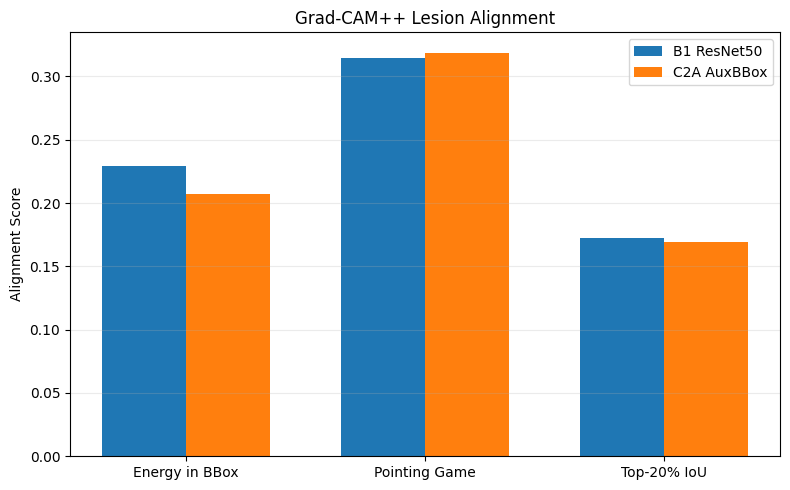



D4 EXPLAINABILITY DECISION
B1 Energy-in-BBox     : 0.229101
C2A Energy-in-BBox    : 0.207345
Δ Energy              : -0.021756
95% CI                : [-0.027406, -0.016163]

B1 Pointing Game      : 0.314961
C2A Pointing Game     : 0.318898

B1 Top-20% IoU        : 0.172293
C2A Top-20% IoU       : 0.169585

Supported metrics     : 0/4

DECISION:
NO QUANTITATIVE XAI ADVANTAGE — retain C2A for predictive benefit, but do not claim improved Grad-CAM lesion alignment.

✓ Model training: NO
✓ Internal test used: NO

Saved to:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/D4_Explainability_LesionAlignment


In [ ]:
# ======================================================================================
# THYTRUST-MD — D4
# QUANTITATIVE EXPLAINABILITY + LESION ALIGNMENT
#
# COMPARES:
#   B1  Full-image ResNet50 seed42
#   C2A ResNet50 + auxiliary bbox supervision seed42
#
# EXPLANATION:
#   Grad-CAM++ at ResNet50 layer4[-1]
#
# TARGET:
#   Model's PREDICTED class
#   (explains the actual decision, not the ground-truth label)
#
# METRICS:
#   1. Energy Inside BBox
#   2. Pointing Game
#   3. Top-20%-saliency IoU
#   4. Inside / Outside saliency ratio
#
# STATISTICS:
#   Paired bootstrap, 5000 resamples
#
# IMPORTANT:
#   ✓ NO TRAINING
#   ✓ VALIDATION ONLY
#   ✓ NO TEST DATA
#   ✓ Same 508 cases
# ======================================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

from torchvision.models import (
    resnet50,
    ResNet50_Weights,
)

import matplotlib.pyplot as plt


# ======================================================================================
# 0. PATHS
# ======================================================================================

SEED = 42
INPUT_SIZE = 224

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

SPLIT_FILE = (
    PROJECT_ROOT
    / "dataset_audit"
    / "final_leakage_controlled_split"
    / "tn5000_leakage_controlled_split_seed42.csv"
)

B1_CKPT = (
    PROJECT_ROOT
    / "baselines"
    / "B1_ResNet50_seed42"
    / "checkpoints"
    / "resnet50_best_macro_f1.pt"
)

C2A_CKPT = (
    PROJECT_ROOT
    / "C2A_AuxBBox_ResNet50_seed42"
    / "checkpoints"
    / "c2a_resnet50_auxbbox_best_macro_f1.pt"
)

D4_ROOT = (
    PROJECT_ROOT
    / "D4_Explainability_LesionAlignment"
)

CSV_DIR = D4_ROOT / "csv_outputs"
FIG_DIR = D4_ROOT / "figures"
CONFIG_DIR = D4_ROOT / "config"

for folder in [
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

assert SPLIT_FILE.exists()
assert B1_CKPT.exists()
assert C2A_CKPT.exists()

print("=" * 115)
print("THYTRUST-MD — D4 EXPLAINABILITY / LESION ALIGNMENT")
print("=" * 115)

print("Device      :", DEVICE)

if DEVICE.type == "cuda":
    print(
        "GPU         :",
        torch.cuda.get_device_name(0)
    )

print("B1 checkpoint :", B1_CKPT)
print("C2A checkpoint:", C2A_CKPT)
print("Test access   : DISABLED")


# ======================================================================================
# 1. REPRODUCIBILITY
# ======================================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ======================================================================================
# 2. VALIDATION MANIFEST ONLY
# ======================================================================================

manifest = pd.read_csv(
    SPLIT_FILE
)

val_df = (
    manifest[
        manifest["split"] == "val"
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(val_df) == 508

print(
    "\nValidation images:",
    len(val_df)
)

print(
    "Test dataframe created: NO"
)


# ======================================================================================
# 3. BBOX MASK
# ======================================================================================

def parse_boxes(value):

    boxes = (
        json.loads(value)
        if isinstance(value, str)
        else value
    )

    if not isinstance(boxes, list) or len(boxes) == 0:
        raise RuntimeError(
            "Missing/invalid bbox"
        )

    return [
        (
            float(b["xmin"]),
            float(b["ymin"]),
            float(b["xmax"]),
            float(b["ymax"]),
        )
        for b in boxes
    ]


def create_bbox_mask(
    image,
    boxes
):

    w, h = image.size

    mask = Image.new(
        "L",
        (w, h),
        0
    )

    draw = ImageDraw.Draw(mask)

    for x1, y1, x2, y2 in boxes:

        x1 = int(
            max(
                0,
                min(
                    w - 1,
                    np.floor(x1)
                )
            )
        )

        y1 = int(
            max(
                0,
                min(
                    h - 1,
                    np.floor(y1)
                )
            )
        )

        x2 = int(
            max(
                x1 + 1,
                min(
                    w,
                    np.ceil(x2)
                )
            )
        )

        y2 = int(
            max(
                y1 + 1,
                min(
                    h,
                    np.ceil(y2)
                )
            )
        )

        draw.rectangle(
            [
                x1,
                y1,
                x2 - 1,
                y2 - 1
            ],
            fill=255
        )

    return mask


# ======================================================================================
# 4. EXACT EVALUATION PREPROCESSING
# ======================================================================================

MEAN = [
    0.485,
    0.456,
    0.406
]

STD = [
    0.229,
    0.224,
    0.225
]


def pad_pair_to_square(
    image,
    mask
):

    w, h = image.size

    side = max(
        w,
        h
    )

    left = (
        side - w
    ) // 2

    right = (
        side - w - left
    )

    top = (
        side - h
    ) // 2

    bottom = (
        side - h - top
    )

    padding = [
        left,
        top,
        right,
        bottom
    ]

    image = TF.pad(
        image,
        padding,
        fill=0
    )

    mask = TF.pad(
        mask,
        padding,
        fill=0
    )

    return (
        image,
        mask
    )


def preprocess(
    image,
    mask
):

    image, mask = pad_pair_to_square(
        image,
        mask
    )

    image_display = TF.resize(
        image,
        [
            INPUT_SIZE,
            INPUT_SIZE
        ],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    )

    mask = TF.resize(
        mask,
        [
            INPUT_SIZE,
            INPUT_SIZE
        ],
        interpolation=InterpolationMode.NEAREST
    )

    tensor = TF.to_tensor(
        image_display
    )

    tensor = TF.normalize(
        tensor,
        MEAN,
        STD
    )

    mask_tensor = (
        TF.to_tensor(mask)
        >
        0.5
    ).float()

    return (
        tensor,
        mask_tensor,
        image_display
    )


# ======================================================================================
# 5. MODELS
# ======================================================================================

class C2AModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = resnet50(
            weights=None
        )

        self.backbone.fc = nn.Linear(
            self.backbone.fc.in_features,
            2
        )

        self.localization_head = nn.Conv2d(
            1024,
            1,
            kernel_size=1,
            bias=True
        )


    def forward(
        self,
        x
    ):

        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)

        layer3 = self.backbone.layer3(x)

        loc = self.localization_head(
            layer3
        )

        x = self.backbone.layer4(
            layer3
        )

        x = self.backbone.avgpool(
            x
        )

        x = torch.flatten(
            x,
            1
        )

        logits = self.backbone.fc(
            x
        )

        return logits, loc


def extract_state_dict(
    checkpoint
):

    if isinstance(
        checkpoint,
        dict
    ):

        if "model_state_dict" in checkpoint:
            return checkpoint[
                "model_state_dict"
            ]

        if "state_dict" in checkpoint:
            return checkpoint[
                "state_dict"
            ]

    return checkpoint


# ------------------------------------------------------------------------------
# B1
# ------------------------------------------------------------------------------

b1_model = resnet50(
    weights=None
)

b1_model.fc = nn.Linear(
    b1_model.fc.in_features,
    2
)

b1_checkpoint = torch.load(
    B1_CKPT,
    map_location="cpu",
    weights_only=False
)

b1_state = extract_state_dict(
    b1_checkpoint
)

# tolerate DataParallel prefix
b1_state = {
    k.replace(
        "module.",
        ""
    ): v
    for k, v in b1_state.items()
}

missing, unexpected = (
    b1_model.load_state_dict(
        b1_state,
        strict=False
    )
)

if missing or unexpected:

    print(
        "\nB1 load audit"
    )

    print(
        "Missing   :",
        missing
    )

    print(
        "Unexpected:",
        unexpected
    )


# ------------------------------------------------------------------------------
# C2A
# ------------------------------------------------------------------------------

c2a_model = C2AModel()

c2a_checkpoint = torch.load(
    C2A_CKPT,
    map_location="cpu",
    weights_only=False
)

c2a_state = extract_state_dict(
    c2a_checkpoint
)

c2a_state = {
    k.replace(
        "module.",
        ""
    ): v
    for k, v in c2a_state.items()
}

missing, unexpected = (
    c2a_model.load_state_dict(
        c2a_state,
        strict=False
    )
)

if missing or unexpected:

    print(
        "\nC2A load audit"
    )

    print(
        "Missing   :",
        missing
    )

    print(
        "Unexpected:",
        unexpected
    )


b1_model = b1_model.to(
    DEVICE
).eval()

c2a_model = c2a_model.to(
    DEVICE
).eval()


# ======================================================================================
# 6. GRAD-CAM++
# ======================================================================================

class GradCAMPlusPlus:

    def __init__(
        self,
        model,
        target_layer,
        model_type
    ):

        self.model = model
        self.target_layer = target_layer
        self.model_type = model_type

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self._forward_hook
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self._backward_hook
            )
        )


    def _forward_hook(
        self,
        module,
        input_,
        output
    ):

        self.activations = output


    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[
            0
        ]


    def close(self):

        self.forward_handle.remove()
        self.backward_handle.remove()


    def generate(
        self,
        image_tensor
    ):

        self.model.zero_grad(
            set_to_none=True
        )

        if self.model_type == "B1":

            logits = self.model(
                image_tensor
            )

        else:

            logits, _ = self.model(
                image_tensor
            )


        predicted_class = int(
            logits.argmax(
                dim=1
            ).item()
        )


        score = logits[
            0,
            predicted_class
        ]


        score.backward()


        activations = self.activations[
            0
        ]

        gradients = self.gradients[
            0
        ]


        grad2 = gradients.pow(
            2
        )

        grad3 = gradients.pow(
            3
        )


        activation_sum = activations.sum(
            dim=(
                1,
                2
            ),
            keepdim=True
        )


        denominator = (
            2.0
            *
            grad2
            +
            activation_sum
            *
            grad3
        )


        denominator = torch.where(
            denominator != 0,
            denominator,
            torch.ones_like(
                denominator
            )
        )


        alpha = (
            grad2
            /
            (
                denominator
                +
                1e-8
            )
        )


        positive_grad = F.relu(
            gradients
        )


        weights = (
            alpha
            *
            positive_grad
        ).sum(
            dim=(
                1,
                2
            ),
            keepdim=True
        )


        cam = (
            weights
            *
            activations
        ).sum(
            dim=0
        )


        cam = F.relu(
            cam
        )


        cam = cam.unsqueeze(
            0
        ).unsqueeze(
            0
        )


        cam = F.interpolate(
            cam,
            size=(
                INPUT_SIZE,
                INPUT_SIZE
            ),
            mode="bilinear",
            align_corners=False
        )


        cam = cam[
            0,
            0
        ]


        cam_min = cam.min()
        cam_max = cam.max()


        if (
            cam_max
            >
            cam_min
        ):

            cam = (
                cam
                -
                cam_min
            ) / (
                cam_max
                -
                cam_min
                +
                1e-8
            )

        else:

            cam = torch.zeros_like(
                cam
            )


        probabilities = torch.softmax(
            logits.detach(),
            dim=1
        )


        return (
            cam.detach()
            .cpu()
            .numpy(),

            predicted_class,

            float(
                probabilities[
                    0,
                    predicted_class
                ].item()
            )
        )


# Final residual block
b1_cam_generator = GradCAMPlusPlus(
    b1_model,
    b1_model.layer4[
        -1
    ],
    "B1"
)

c2a_cam_generator = GradCAMPlusPlus(
    c2a_model,
    c2a_model.backbone.layer4[
        -1
    ],
    "C2A"
)


# ======================================================================================
# 7. ALIGNMENT METRICS
# ======================================================================================

def alignment_metrics(
    cam,
    bbox_mask
):

    cam = np.asarray(
        cam,
        dtype=float
    )

    mask = np.asarray(
        bbox_mask,
        dtype=bool
    )


    eps = 1e-8


    # ------------------------------------------------------------------
    # 1. Energy inside bbox
    # ------------------------------------------------------------------

    total_energy = cam.sum()

    inside_energy = cam[
        mask
    ].sum()


    energy_inside = (
        inside_energy
        /
        (
            total_energy
            +
            eps
        )
    )


    # ------------------------------------------------------------------
    # 2. Pointing game
    #
    # Is the maximum saliency pixel inside the lesion?
    # ------------------------------------------------------------------

    max_idx = np.unravel_index(
        np.argmax(
            cam
        ),
        cam.shape
    )


    pointing_game = float(
        mask[
            max_idx
        ]
    )


    # ------------------------------------------------------------------
    # 3. Top-20% saliency IoU
    #
    # Avoid arbitrary fixed CAM=.5 threshold.
    # ------------------------------------------------------------------

    threshold = np.quantile(
        cam,
        0.80
    )


    salient = (
        cam >= threshold
    )


    intersection = np.logical_and(
        salient,
        mask
    ).sum()


    union = np.logical_or(
        salient,
        mask
    ).sum()


    top20_iou = (
        intersection
        /
        (
            union
            +
            eps
        )
    )


    # ------------------------------------------------------------------
    # 4. Inside/outside intensity ratio
    # ------------------------------------------------------------------

    mean_inside = (
        cam[
            mask
        ].mean()
        if mask.any()
        else 0.0
    )


    outside = (
        ~mask
    )


    mean_outside = (
        cam[
            outside
        ].mean()
        if outside.any()
        else 0.0
    )


    inside_outside_ratio = (
        mean_inside
        /
        (
            mean_outside
            +
            eps
        )
    )


    return {

        "energy_inside_bbox":
            float(
                energy_inside
            ),

        "pointing_game":
            float(
                pointing_game
            ),

        "top20_iou":
            float(
                top20_iou
            ),

        "inside_outside_ratio":
            float(
                inside_outside_ratio
            )
    }


# ======================================================================================
# 8. RUN ALL 508 VALIDATION CASES
# ======================================================================================

records = []

# Save candidate examples in memory only for later selection.
example_cache = {}


print("\n")
print("=" * 115)
print("GENERATING GRAD-CAM++ FOR 508 VALIDATION CASES")
print("=" * 115)


for idx, row in val_df.iterrows():

    image_path = str(
        row[
            "image_path"
        ]
    )


    image = (
        Image.open(
            image_path
        )
        .convert(
            "RGB"
        )
    )


    boxes = parse_boxes(
        row[
            "bboxes_json"
        ]
    )


    bbox_mask = create_bbox_mask(
        image,
        boxes
    )


    (
        tensor,
        mask_tensor,
        display_image
    ) = preprocess(
        image,
        bbox_mask
    )


    tensor = tensor.unsqueeze(
        0
    ).to(
        DEVICE
    )


    mask_np = (
        mask_tensor[
            0
        ]
        .numpy()
        >
        0.5
    )


    # --------------------------------------------------------------
    # B1 Grad-CAM++
    # --------------------------------------------------------------

    b1_cam, b1_pred, b1_conf = (
        b1_cam_generator.generate(
            tensor
        )
    )


    # --------------------------------------------------------------
    # C2A Grad-CAM++
    # --------------------------------------------------------------

    c2a_cam, c2a_pred, c2a_conf = (
        c2a_cam_generator.generate(
            tensor
        )
    )


    b1_align = alignment_metrics(
        b1_cam,
        mask_np
    )


    c2a_align = alignment_metrics(
        c2a_cam,
        mask_np
    )


    true_label = int(
        row[
            "label"
        ]
    )


    record = {

        "image_id":
            str(
                row[
                    "image_id_norm"
                ]
            ),

        "image_path":
            image_path,

        "true_label":
            true_label,

        "b1_prediction":
            b1_pred,

        "b1_confidence":
            b1_conf,

        "b1_correct":
            int(
                b1_pred
                ==
                true_label
            ),

        "c2a_prediction":
            c2a_pred,

        "c2a_confidence":
            c2a_conf,

        "c2a_correct":
            int(
                c2a_pred
                ==
                true_label
            ),
    }


    for metric, value in (
        b1_align.items()
    ):

        record[
            f"b1_{metric}"
        ] = value


    for metric, value in (
        c2a_align.items()
    ):

        record[
            f"c2a_{metric}"
        ] = value


    records.append(
        record
    )


    # Only cache a subset for figures to avoid huge RAM usage.
    if idx < 100:

        example_cache[
            str(
                row[
                    "image_id_norm"
                ]
            )
        ] = {

            "image":
                np.asarray(
                    display_image
                ),

            "mask":
                mask_np,

            "b1_cam":
                b1_cam,

            "c2a_cam":
                c2a_cam
        }


    if (
        (idx + 1) % 50 == 0
        or
        idx + 1 == len(
            val_df
        )
    ):

        print(
            f"Processed "
            f"{idx + 1}/{len(val_df)}"
        )


results = pd.DataFrame(
    records
)


results.to_csv(
    CSV_DIR
    / "D4_gradcam_alignment_per_image.csv",
    index=False
)


# ======================================================================================
# 9. SUMMARY
# ======================================================================================

METRICS = [
    "energy_inside_bbox",
    "pointing_game",
    "top20_iou",
    "inside_outside_ratio",
]


summary_rows = []


for metric in METRICS:

    b1_values = results[
        f"b1_{metric}"
    ].to_numpy(
        dtype=float
    )

    c2a_values = results[
        f"c2a_{metric}"
    ].to_numpy(
        dtype=float
    )


    summary_rows.append({

        "Metric":
            metric,

        "B1_Mean":
            float(
                b1_values.mean()
            ),

        "B1_SD":
            float(
                b1_values.std(
                    ddof=1
                )
            ),

        "C2A_Mean":
            float(
                c2a_values.mean()
            ),

        "C2A_SD":
            float(
                c2a_values.std(
                    ddof=1
                )
            ),

        "Delta_C2A_minus_B1":
            float(
                (
                    c2a_values
                    -
                    b1_values
                ).mean()
            )
    })


summary_df = pd.DataFrame(
    summary_rows
)


# ======================================================================================
# 10. PAIRED BOOTSTRAP
# ======================================================================================

N_BOOT = 5000

rng = np.random.default_rng(
    2026
)


bootstrap_rows = []


for metric in METRICS:

    b1_values = results[
        f"b1_{metric}"
    ].to_numpy(
        dtype=float
    )

    c2a_values = results[
        f"c2a_{metric}"
    ].to_numpy(
        dtype=float
    )


    paired_delta = (
        c2a_values
        -
        b1_values
    )


    boot = np.empty(
        N_BOOT,
        dtype=float
    )


    n = len(
        paired_delta
    )


    for b in range(
        N_BOOT
    ):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        boot[
            b
        ] = paired_delta[
            idx
        ].mean()


    ci_low = float(
        np.percentile(
            boot,
            2.5
        )
    )

    ci_high = float(
        np.percentile(
            boot,
            97.5
        )
    )


    bootstrap_rows.append({

        "Metric":
            metric,

        "Mean_Delta":
            float(
                paired_delta.mean()
            ),

        "CI95_Low":
            ci_low,

        "CI95_High":
            ci_high,

        "P_Delta_GT_0":
            float(
                (
                    boot > 0
                ).mean()
            ),

        "Statistically_Supported":
            bool(
                ci_low > 0
            )
    })


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


summary_df = summary_df.merge(
    bootstrap_df,
    on="Metric",
    how="left"
)


summary_df.to_csv(
    CSV_DIR
    / "D4_gradcam_alignment_summary.csv",
    index=False
)


print("\n")
print("=" * 115)
print("D4 GRAD-CAM++ LESION ALIGNMENT")
print("=" * 115)

display(
    summary_df.round(
        6
    )
)


# ======================================================================================
# 11. CORRECT-PREDICTION SUBGROUP
# ======================================================================================

correct_both = results[
    (
        results[
            "b1_correct"
        ] == 1
    )
    &
    (
        results[
            "c2a_correct"
        ] == 1
    )
].copy()


correct_rows = []


for metric in METRICS:

    b1_value = correct_both[
        f"b1_{metric}"
    ].mean()

    c2a_value = correct_both[
        f"c2a_{metric}"
    ].mean()


    correct_rows.append({

        "Metric":
            metric,

        "N":
            len(
                correct_both
            ),

        "B1":
            b1_value,

        "C2A":
            c2a_value,

        "Delta":
            c2a_value
            -
            b1_value
    })


correct_df = pd.DataFrame(
    correct_rows
)


correct_df.to_csv(
    CSV_DIR
    / "D4_correct_predictions_alignment.csv",
    index=False
)


print("\n")
print("=" * 115)
print("CASES CORRECTLY CLASSIFIED BY BOTH MODELS")
print("=" * 115)

display(
    correct_df.round(
        6
    )
)


# ======================================================================================
# 12. FIGURE — MEAN ALIGNMENT COMPARISON
# ======================================================================================

plot_metrics = [
    "energy_inside_bbox",
    "pointing_game",
    "top20_iou",
]


plot_df = summary_df[
    summary_df[
        "Metric"
    ].isin(
        plot_metrics
    )
].copy()


x = np.arange(
    len(
        plot_df
    )
)

width = 0.35


fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


ax.bar(
    x
    -
    width / 2,
    plot_df[
        "B1_Mean"
    ],
    width,
    label="B1 ResNet50"
)


ax.bar(
    x
    +
    width / 2,
    plot_df[
        "C2A_Mean"
    ],
    width,
    label="C2A AuxBBox"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        "Energy in BBox",
        "Pointing Game",
        "Top-20% IoU"
    ]
)

ax.set_ylabel(
    "Alignment Score"
)

ax.set_title(
    "Grad-CAM++ Lesion Alignment"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "D4_gradcam_alignment_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    FIG_DIR
    / "D4_gradcam_alignment_comparison.pdf",
    bbox_inches="tight"
)

plt.show()


# ======================================================================================
# 13. PAIRED QUALITATIVE EXAMPLES
#
# Select examples among first 100 cached cases where C2A improves energy alignment
# the most. This is ONLY for visualization; not used for metric calculation.
# ======================================================================================

cached_ids = set(
    example_cache.keys()
)


example_candidates = (
    results[
        results[
            "image_id"
        ].isin(
            cached_ids
        )
    ]
    .copy()
)


example_candidates[
    "energy_gain"
] = (
    example_candidates[
        "c2a_energy_inside_bbox"
    ]
    -
    example_candidates[
        "b1_energy_inside_bbox"
    ]
)


example_candidates = (
    example_candidates
    .sort_values(
        "energy_gain",
        ascending=False
    )
    .head(
        6
    )
)


def overlay_cam(
    image,
    cam,
    mask
):

    image = (
        image.astype(
            np.float32
        )
        /
        255.0
    )


    # Matplotlib handles colormap rendering.
    heat = plt.cm.jet(
        cam
    )[
        :,
        :,
        :3
    ]


    overlay = (
        0.55
        *
        image
        +
        0.45
        *
        heat
    )


    overlay = np.clip(
        overlay,
        0,
        1
    )


    # BBox contour
    contour = mask.astype(
        float
    )


    return (
        overlay,
        contour
    )


for rank, row in enumerate(
    example_candidates.itertuples(),
    start=1
):

    cache = example_cache[
        row.image_id
    ]


    image = cache[
        "image"
    ]

    mask = cache[
        "mask"
    ]


    b1_overlay, _ = overlay_cam(
        image,
        cache[
            "b1_cam"
        ],
        mask
    )


    c2a_overlay, _ = overlay_cam(
        image,
        cache[
            "c2a_cam"
        ],
        mask
    )


    # One figure per case rather than subplot-heavy manuscript plot.
    fig, ax = plt.subplots(
        figsize=(
            6,
            6
        )
    )


    ax.imshow(
        c2a_overlay
    )


    ax.contour(
        mask,
        levels=[
            0.5
        ],
        linewidths=1.5
    )


    ax.set_title(
        (
            f"C2A Grad-CAM++ | "
            f"Energy={row.c2a_energy_inside_bbox:.3f}"
        )
    )

    ax.axis(
        "off"
    )


    fig.tight_layout()


    fig.savefig(
        FIG_DIR
        / f"D4_example_{rank}_C2A.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.close(
        fig
    )


    fig, ax = plt.subplots(
        figsize=(
            6,
            6
        )
    )


    ax.imshow(
        b1_overlay
    )


    ax.contour(
        mask,
        levels=[
            0.5
        ],
        linewidths=1.5
    )


    ax.set_title(
        (
            f"B1 Grad-CAM++ | "
            f"Energy={row.b1_energy_inside_bbox:.3f}"
        )
    )

    ax.axis(
        "off"
    )


    fig.tight_layout()


    fig.savefig(
        FIG_DIR
        / f"D4_example_{rank}_B1.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.close(
        fig
    )


# ======================================================================================
# 14. DECISION
# ======================================================================================

energy_row = summary_df[
    summary_df[
        "Metric"
    ]
    ==
    "energy_inside_bbox"
].iloc[
    0
]


pointing_row = summary_df[
    summary_df[
        "Metric"
    ]
    ==
    "pointing_game"
].iloc[
    0
]


iou_row = summary_df[
    summary_df[
        "Metric"
    ]
    ==
    "top20_iou"
].iloc[
    0
]


supported = int(
    summary_df[
        "Statistically_Supported"
    ].sum()
)


if (
    energy_row[
        "Mean_Delta"
    ] > 0
    and
    energy_row[
        "CI95_Low"
    ] > 0
    and
    supported >= 2
):

    decision = (
        "XAI GO — C2A provides statistically supported improvement "
        "in classifier lesion alignment relative to B1 ResNet50."
    )

elif (
    energy_row[
        "Mean_Delta"
    ] > 0
    and
    supported >= 1
):

    decision = (
        "PARTIAL XAI SUPPORT — C2A improves lesion alignment, "
        "but evidence is not uniformly strong across all metrics."
    )

else:

    decision = (
        "NO QUANTITATIVE XAI ADVANTAGE — retain C2A for predictive "
        "benefit, but do not claim improved Grad-CAM lesion alignment."
    )


decision_record = {

    "method":
        "Grad-CAM++",

    "target":
        "predicted_class",

    "target_layer":
        "ResNet50 layer4[-1]",

    "validation_n":
        len(
            results
        ),

    "energy_inside_bbox_B1":
        float(
            energy_row[
                "B1_Mean"
            ]
        ),

    "energy_inside_bbox_C2A":
        float(
            energy_row[
                "C2A_Mean"
            ]
        ),

    "energy_delta":
        float(
            energy_row[
                "Mean_Delta"
            ]
        ),

    "energy_ci95":
        [
            float(
                energy_row[
                    "CI95_Low"
                ]
            ),
            float(
                energy_row[
                    "CI95_High"
                ]
            )
        ],

    "pointing_game_B1":
        float(
            pointing_row[
                "B1_Mean"
            ]
        ),

    "pointing_game_C2A":
        float(
            pointing_row[
                "C2A_Mean"
            ]
        ),

    "top20_iou_B1":
        float(
            iou_row[
                "B1_Mean"
            ]
        ),

    "top20_iou_C2A":
        float(
            iou_row[
                "C2A_Mean"
            ]
        ),

    "supported_alignment_metrics":
        supported,

    "decision":
        decision,

    "test_used":
        False
}


with open(
    CONFIG_DIR
    / "D4_explainability_decision.json",
    "w"
) as f:

    json.dump(
        decision_record,
        f,
        indent=2
    )


print("\n")
print("=" * 115)
print("D4 EXPLAINABILITY DECISION")
print("=" * 115)

print(
    f"B1 Energy-in-BBox     : "
    f"{energy_row['B1_Mean']:.6f}"
)

print(
    f"C2A Energy-in-BBox    : "
    f"{energy_row['C2A_Mean']:.6f}"
)

print(
    f"Δ Energy              : "
    f"{energy_row['Mean_Delta']:+.6f}"
)

print(
    f"95% CI                : "
    f"[{energy_row['CI95_Low']:+.6f}, "
    f"{energy_row['CI95_High']:+.6f}]"
)

print()

print(
    f"B1 Pointing Game      : "
    f"{pointing_row['B1_Mean']:.6f}"
)

print(
    f"C2A Pointing Game     : "
    f"{pointing_row['C2A_Mean']:.6f}"
)

print()

print(
    f"B1 Top-20% IoU        : "
    f"{iou_row['B1_Mean']:.6f}"
)

print(
    f"C2A Top-20% IoU       : "
    f"{iou_row['C2A_Mean']:.6f}"
)

print()

print(
    f"Supported metrics     : "
    f"{supported}/{len(METRICS)}"
)

print("\nDECISION:")
print(
    decision
)

print(
    "\n✓ Model training: NO"
)

print(
    "✓ Internal test used: NO"
)

print(
    f"\nSaved to:\n{D4_ROOT}"
)

print("=" * 115)


b1_cam_generator.close()
c2a_cam_generator.close()

del b1_model
del c2a_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# XAI

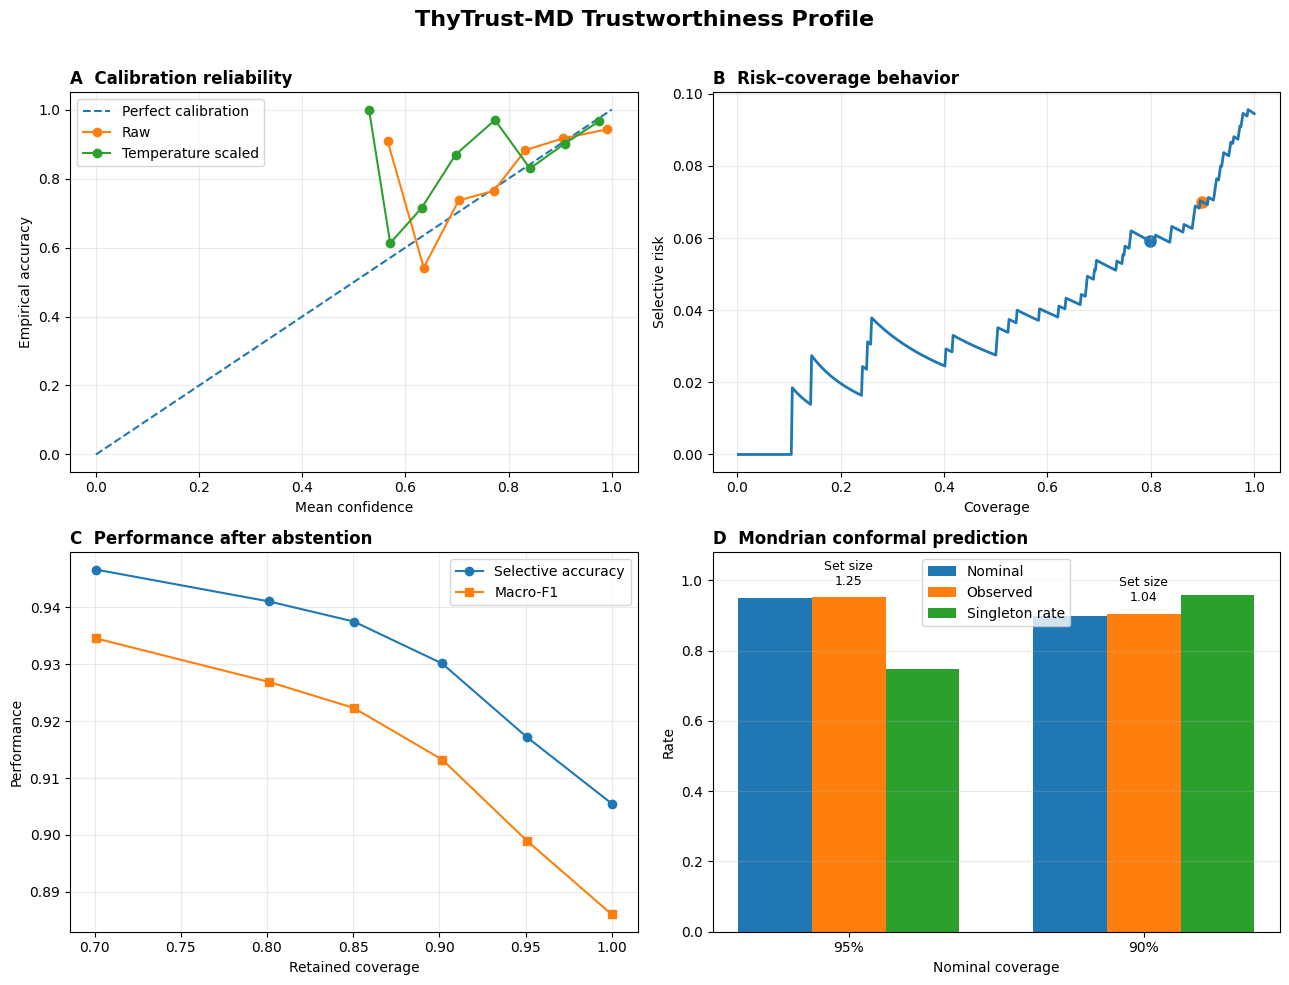

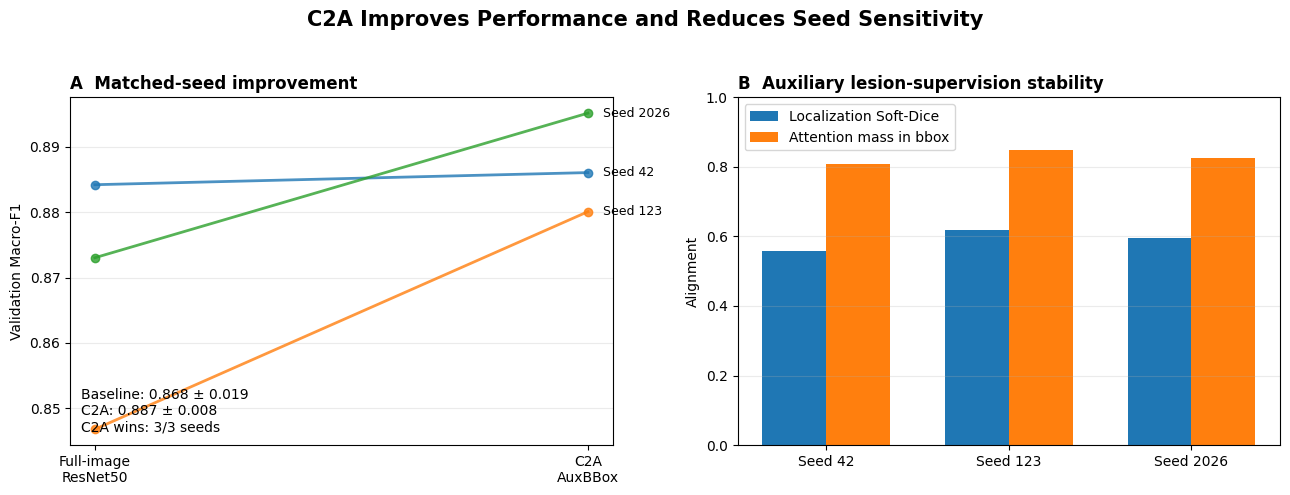

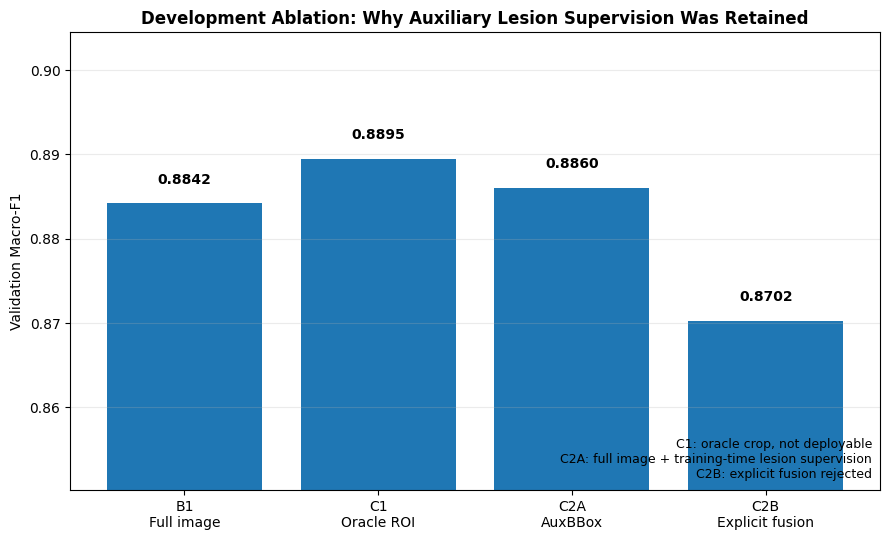

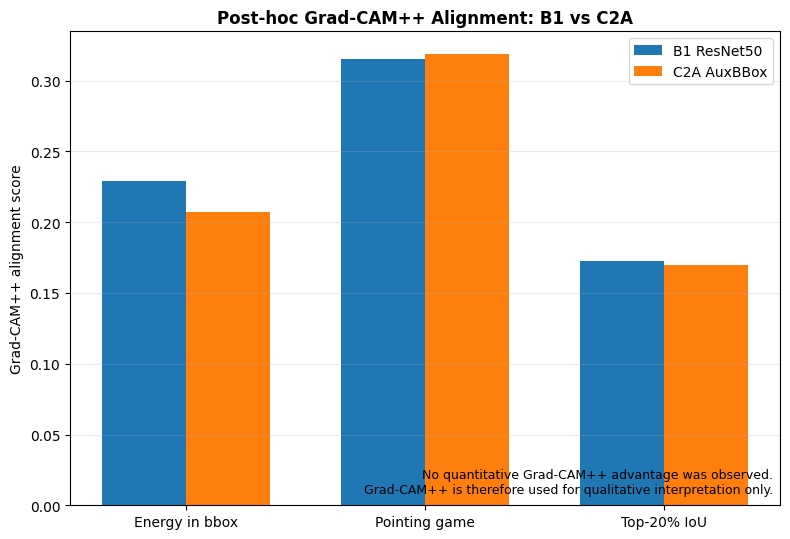



PUBLICATION FIGURE PACK COMPLETE
Fig_Development_Ablation.pdf
Fig_Development_Ablation.png
Fig_Multiseed_Stability_Localization.pdf
Fig_Multiseed_Stability_Localization.png
Fig_Trustworthiness_Dashboard.pdf
Fig_Trustworthiness_Dashboard.png
Fig_XAI_Quantitative_Alignment.pdf
Fig_XAI_Quantitative_Alignment.png

✓ Validation/development data only
✓ No test set accessed


In [ ]:
# ======================================================================================
# THYTRUST-MD — PUBLICATION FIGURE PACK
# BLOCK 2/2
#
# CREATES:
#
# Fig 2 — Trustworthiness Dashboard
#   A. Raw vs temperature-scaled reliability
#   B. Risk-coverage
#   C. Selective performance vs coverage
#   D. Mondrian conformal coverage / efficiency
#
# Fig 3 — Multi-seed Stability + Localization Consistency
#
# Fig 4 — Development Ablation
#   B1 → C1 Oracle ROI → C2A → C2B
#
# Fig 5 — Quantitative Grad-CAM++ Alignment
#
# VALIDATION / DEVELOPMENT ONLY
# NO TEST ACCESS
# NO TRAINING
# ======================================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
)


# ======================================================================================
# 0. PATHS
# ======================================================================================

ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

FIG_DIR = (
    ROOT
    / "Paper_Figures"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ======================================================================================
# 1. FIGURE 2 — TRUSTWORTHINESS DASHBOARD
# ======================================================================================

D1_BINS = (
    ROOT
    / "D1_TemperatureScaling_C2A_seed42"
    / "csv_outputs"
    / "D1_reliability_bins.csv"
)

D2_RISK = (
    ROOT
    / "D2_Uncertainty_SelectivePrediction_C2A_seed42"
    / "csv_outputs"
    / "D2_risk_coverage_curve.csv"
)

D2_SELECTIVE = (
    ROOT
    / "D2_Uncertainty_SelectivePrediction_C2A_seed42"
    / "csv_outputs"
    / "D2_selective_operating_points.csv"
)

D3_SUMMARY = (
    ROOT
    / "D3_ConformalPrediction_C2A_seed42"
    / "csv_outputs"
    / "D3_cross_conformal_summary.csv"
)


for path in [
    D1_BINS,
    D2_RISK,
    D2_SELECTIVE,
    D3_SUMMARY
]:

    assert path.exists(), path


bins = pd.read_csv(
    D1_BINS
)

risk = pd.read_csv(
    D2_RISK
)

selective = pd.read_csv(
    D2_SELECTIVE
)

conformal = pd.read_csv(
    D3_SUMMARY
)


raw_bins = bins[
    bins[
        "calibration"
    ]
    ==
    "Raw"
]

ts_bins = bins[
    bins[
        "calibration"
    ]
    ==
    "TemperatureScaled"
]


fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        13,
        10
    )
)


# ----------------------------------------------------------------------
# A. Reliability
# ----------------------------------------------------------------------

ax = axes[
    0,
    0
]


ax.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--",
    label="Perfect calibration"
)


ax.plot(
    raw_bins[
        "mean_confidence"
    ],
    raw_bins[
        "accuracy"
    ],
    marker="o",
    label="Raw"
)


ax.plot(
    ts_bins[
        "mean_confidence"
    ],
    ts_bins[
        "accuracy"
    ],
    marker="o",
    label="Temperature scaled"
)


ax.set_xlabel(
    "Mean confidence"
)

ax.set_ylabel(
    "Empirical accuracy"
)

ax.set_title(
    "A  Calibration reliability",
    loc="left",
    fontweight="bold"
)

ax.grid(
    alpha=0.25
)

ax.legend()


# ----------------------------------------------------------------------
# B. Risk-coverage
# ----------------------------------------------------------------------

ax = axes[
    0,
    1
]


ax.plot(
    risk[
        "coverage"
    ],
    risk[
        "risk"
    ],
    linewidth=2
)


ax.set_xlabel(
    "Coverage"
)

ax.set_ylabel(
    "Selective risk"
)

ax.set_title(
    "B  Risk–coverage behavior",
    loc="left",
    fontweight="bold"
)

ax.grid(
    alpha=0.25
)


# Mark 80/90%
for coverage_value in [
    0.8,
    0.9
]:

    nearest = (
        risk.iloc[
            (
                risk[
                    "coverage"
                ]
                -
                coverage_value
            )
            .abs()
            .argsort()[
                :1
            ]
        ]
    )


    ax.scatter(

        nearest[
            "coverage"
        ],

        nearest[
            "risk"
        ],

        s=65
    )


# ----------------------------------------------------------------------
# C. Selective prediction
# ----------------------------------------------------------------------

ax = axes[
    1,
    0
]


ax.plot(

    selective[
        "Achieved_Development_Coverage"
    ],

    selective[
        "Selective_Accuracy"
    ],

    marker="o",

    label="Selective accuracy"
)


ax.plot(

    selective[
        "Achieved_Development_Coverage"
    ],

    selective[
        "Macro_F1"
    ],

    marker="s",

    label="Macro-F1"
)


ax.set_xlabel(
    "Retained coverage"
)

ax.set_ylabel(
    "Performance"
)

ax.set_title(
    "C  Performance after abstention",
    loc="left",
    fontweight="bold"
)

ax.grid(
    alpha=0.25
)

ax.legend()


# ----------------------------------------------------------------------
# D. Conformal prediction
# ----------------------------------------------------------------------

ax = axes[
    1,
    1
]


mondrian = conformal[
    conformal[
        "Method"
    ]
    ==
    "Mondrian_LAC"
].copy()


x = np.arange(
    len(
        mondrian
    )
)


width = 0.25


ax.bar(

    x
    -
    width,

    mondrian[
        "Nominal_Coverage"
    ],

    width,

    label="Nominal"
)


ax.bar(

    x,

    mondrian[
        "Mean_Coverage"
    ],

    width,

    label="Observed"
)


ax.bar(

    x
    +
    width,

    mondrian[
        "Mean_Singleton_Rate"
    ],

    width,

    label="Singleton rate"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"{int(v*100)}%"
        for v in
        mondrian[
            "Nominal_Coverage"
        ]
    ]
)


ax.set_ylim(
    0,
    1.08
)

ax.set_xlabel(
    "Nominal coverage"
)

ax.set_ylabel(
    "Rate"
)

ax.set_title(
    "D  Mondrian conformal prediction",
    loc="left",
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()


# Mean set-size annotations
for idx, (_, row) in enumerate(
    mondrian.iterrows()
):

    ax.text(

        idx,

        min(
            1.055,
            row[
                "Mean_Coverage"
            ]
            +
            0.035
        ),

        f"Set size\n{row['Mean_Set_Size']:.2f}",

        ha="center",

        fontsize=9
    )


fig.suptitle(

    "ThyTrust-MD Trustworthiness Profile",

    fontsize=16,

    fontweight="bold"
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.97
    ]
)


fig.savefig(

    FIG_DIR
    / "Fig_Trustworthiness_Dashboard.png",

    dpi=500,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "Fig_Trustworthiness_Dashboard.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 2. FIGURE 3 — MULTI-SEED STABILITY + LOCALIZATION CONSISTENCY
# ======================================================================================

B1_SEED_FILES = {

    42:
        ROOT
        / "baselines"
        / "B1_ResNet50_seed42"
        / "csv_outputs"
        / "validation_predictions_logits.csv",

    123:
        ROOT
        / "B4_Backbone_Stability"
        / "ResNet50"
        / "seed_123"
        / "csv_outputs"
        / "validation_predictions_logits.csv",

    2026:
        ROOT
        / "B4_Backbone_Stability"
        / "ResNet50"
        / "seed_2026"
        / "csv_outputs"
        / "validation_predictions_logits.csv",
}


C2A_SEED_FILES = {

    42:
        ROOT
        / "C2A_AuxBBox_ResNet50_seed42"
        / "csv_outputs"
        / "validation_predictions_logits.csv",

    123:
        ROOT
        / "C2A_AuxBBox_ResNet50_multiseed"
        / "seed_123"
        / "csv_outputs"
        / "validation_predictions_logits.csv",

    2026:
        ROOT
        / "C2A_AuxBBox_ResNet50_multiseed"
        / "seed_2026"
        / "csv_outputs"
        / "validation_predictions_logits.csv",
}


def macro_f1_from_file(
    path
):

    df = pd.read_csv(
        path
    )

    return f1_score(

        df[
            "true_label"
        ],

        df[
            "predicted_label"
        ],

        average="macro",

        zero_division=0
    )


seed_rows = []


for seed in [
    42,
    123,
    2026
]:

    b1 = macro_f1_from_file(
        B1_SEED_FILES[
            seed
        ]
    )


    c2a_df = pd.read_csv(
        C2A_SEED_FILES[
            seed
        ]
    )


    c2a = f1_score(

        c2a_df[
            "true_label"
        ],

        c2a_df[
            "predicted_label"
        ],

        average="macro",

        zero_division=0
    )


    seed_rows.append({

        "seed":
            seed,

        "B1":
            b1,

        "C2A":
            c2a,

        "LocDice":
            c2a_df[
                "loc_soft_dice"
            ].mean(),

        "AttentionInside":
            c2a_df[
                "attention_mass_inside_bbox"
            ].mean()
    })


seed_df = pd.DataFrame(
    seed_rows
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        13,
        5
    )
)


# ----------------------------------------------------------------------
# A. Macro-F1 stability
# ----------------------------------------------------------------------

ax = axes[
    0
]


for _, row in seed_df.iterrows():

    ax.plot(

        [
            0,
            1
        ],

        [
            row[
                "B1"
            ],
            row[
                "C2A"
            ]
        ],

        marker="o",

        linewidth=2,

        alpha=0.8
    )


ax.set_xticks(
    [
        0,
        1
    ]
)

ax.set_xticklabels(
    [
        "Full-image\nResNet50",
        "C2A\nAuxBBox"
    ]
)


ax.set_ylabel(
    "Validation Macro-F1"
)

ax.set_title(
    "A  Matched-seed improvement",
    loc="left",
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.25
)


for _, row in seed_df.iterrows():

    ax.text(

        1.03,

        row[
            "C2A"
        ],

        f"Seed {int(row['seed'])}",

        va="center",

        fontsize=9
    )


baseline_mean = seed_df[
    "B1"
].mean()

baseline_sd = seed_df[
    "B1"
].std(
    ddof=1
)

c2a_mean = seed_df[
    "C2A"
].mean()

c2a_sd = seed_df[
    "C2A"
].std(
    ddof=1
)


ax.text(

    0.02,
    0.03,

    (
        f"Baseline: "
        f"{baseline_mean:.3f} ± {baseline_sd:.3f}\n"
        f"C2A: "
        f"{c2a_mean:.3f} ± {c2a_sd:.3f}\n"
        f"C2A wins: 3/3 seeds"
    ),

    transform=ax.transAxes,

    fontsize=10,

    va="bottom"
)


# ----------------------------------------------------------------------
# B. Localization consistency
# ----------------------------------------------------------------------

ax = axes[
    1
]


x = np.arange(
    len(
        seed_df
    )
)


width = 0.35


ax.bar(

    x
    -
    width / 2,

    seed_df[
        "LocDice"
    ],

    width,

    label="Localization Soft-Dice"
)


ax.bar(

    x
    +
    width / 2,

    seed_df[
        "AttentionInside"
    ],

    width,

    label="Attention mass in bbox"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"Seed {seed}"
        for seed
        in seed_df[
            "seed"
        ]
    ]
)


ax.set_ylim(
    0,
    1
)

ax.set_ylabel(
    "Alignment"
)

ax.set_title(
    "B  Auxiliary lesion-supervision stability",
    loc="left",
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()


fig.suptitle(

    "C2A Improves Performance and Reduces Seed Sensitivity",

    fontsize=15,

    fontweight="bold"
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95
    ]
)


fig.savefig(

    FIG_DIR
    / "Fig_Multiseed_Stability_Localization.png",

    dpi=500,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "Fig_Multiseed_Stability_Localization.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 3. FIGURE 4 — DEVELOPMENT ABLATION
# ======================================================================================

ABLATION_FILES = {

    "B1\nFull image":
        ROOT
        / "baselines"
        / "B1_ResNet50_seed42"
        / "csv_outputs"
        / "validation_predictions_logits.csv",

    "C1\nOracle ROI":
        ROOT
        / "C1_OracleROI_ResNet50_seed42"
        / "csv_outputs"
        / "validation_predictions_logits.csv",

    "C2A\nAuxBBox":
        ROOT
        / "C2A_AuxBBox_ResNet50_seed42"
        / "csv_outputs"
        / "validation_predictions_logits.csv",

    "C2B\nExplicit fusion":
        ROOT
        / "C2B_LesionGlobalFusion_ResNet50_seed42"
        / "csv_outputs"
        / "validation_predictions_logits.csv",
}


ablation_rows = []


for name, path in (
    ABLATION_FILES.items()
):

    if not path.exists():

        continue


    df_temp = pd.read_csv(
        path
    )


    f1 = f1_score(

        df_temp[
            "true_label"
        ],

        df_temp[
            "predicted_label"
        ],

        average="macro",

        zero_division=0
    )


    ablation_rows.append({

        "Method":
            name,

        "MacroF1":
            f1
    })


ablation = pd.DataFrame(
    ablation_rows
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5.5
    )
)


bars = ax.bar(

    ablation[
        "Method"
    ],

    ablation[
        "MacroF1"
    ]
)


ax.set_ylim(
    max(
        0.80,
        ablation[
            "MacroF1"
        ].min()
        -
        0.02
    ),
    ablation[
        "MacroF1"
    ].max()
    +
    0.015
)


ax.set_ylabel(
    "Validation Macro-F1"
)

ax.set_title(
    "Development Ablation: Why Auxiliary Lesion Supervision Was Retained",
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(

    bars,

    ablation[
        "MacroF1"
    ]
):

    ax.text(

        bar.get_x()
        +
        bar.get_width()
        /
        2,

        value
        +
        0.002,

        f"{value:.4f}",

        ha="center",

        va="bottom",

        fontsize=10,

        fontweight="bold"
    )


ax.text(

    0.99,
    0.02,

    (
        "C1: oracle crop, not deployable\n"
        "C2A: full image + training-time lesion supervision\n"
        "C2B: explicit fusion rejected"
    ),

    transform=ax.transAxes,

    ha="right",

    va="bottom",

    fontsize=9
)


fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "Fig_Development_Ablation.png",

    dpi=500,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "Fig_Development_Ablation.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 4. FIGURE 5 — QUANTITATIVE XAI RESULT
#
# Important negative result:
# We show it transparently rather than hiding it.
# ======================================================================================

D4_SUMMARY = (
    ROOT
    / "D4_Explainability_LesionAlignment"
    / "csv_outputs"
    / "D4_gradcam_alignment_summary.csv"
)


assert D4_SUMMARY.exists()


d4 = pd.read_csv(
    D4_SUMMARY
)


metric_names = {

    "energy_inside_bbox":
        "Energy in bbox",

    "pointing_game":
        "Pointing game",

    "top20_iou":
        "Top-20% IoU"
}


d4_plot = d4[
    d4[
        "Metric"
    ].isin(
        metric_names.keys()
    )
].copy()


d4_plot[
    "Display"
] = d4_plot[
    "Metric"
].map(
    metric_names
)


x = np.arange(
    len(
        d4_plot
    )
)


width = 0.35


fig, ax = plt.subplots(
    figsize=(
        8,
        5.5
    )
)


ax.bar(

    x
    -
    width / 2,

    d4_plot[
        "B1_Mean"
    ],

    width,

    label="B1 ResNet50"
)


ax.bar(

    x
    +
    width / 2,

    d4_plot[
        "C2A_Mean"
    ],

    width,

    label="C2A AuxBBox"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    d4_plot[
        "Display"
    ]
)


ax.set_ylabel(
    "Grad-CAM++ alignment score"
)

ax.set_title(
    "Post-hoc Grad-CAM++ Alignment: B1 vs C2A",
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()


ax.text(

    0.99,
    0.02,

    (
        "No quantitative Grad-CAM++ advantage was observed.\n"
        "Grad-CAM++ is therefore used for qualitative interpretation only."
    ),

    transform=ax.transAxes,

    ha="right",

    va="bottom",

    fontsize=9
)


fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "Fig_XAI_Quantitative_Alignment.png",

    dpi=500,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "Fig_XAI_Quantitative_Alignment.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 5. FINAL FILE LIST
# ======================================================================================

print("\n")
print("=" * 110)
print("PUBLICATION FIGURE PACK COMPLETE")
print("=" * 110)

for file in sorted(
    FIG_DIR.glob(
        "Fig_*"
    )
):

    print(
        file.name
    )

print(
    "\n✓ Validation/development data only"
)

print(
    "✓ No test set accessed"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — PUBLICATION XAI FIGURE
Device : cuda
Test   : NOT ACCESSED
XAI DATA MERGE FIXED
Validation cases : 508
image_path       : FOUND
bboxes_json      : FOUND
TS probabilities : FOUND
Image files      : ALL FOUND
Test accessed    : NO

Selected cases:
Correct benign
(high confidence)    | ID=1740 | True=Benign | Pred=Benign
Correct malignant
(high confidence) | ID=750 | True=Malignant | Pred=Malignant
Correct benign
(high uncertainty)   | ID=33 | True=Benign | Pred=Benign
Correct malignant
(high uncertainty) | ID=3389 | True=Malignant | Pred=Malignant
False positive                      | ID=329 | True=Benign | Pred=Malignant
False negative                      | ID=3437 | True=Malignant | Pred=Benign


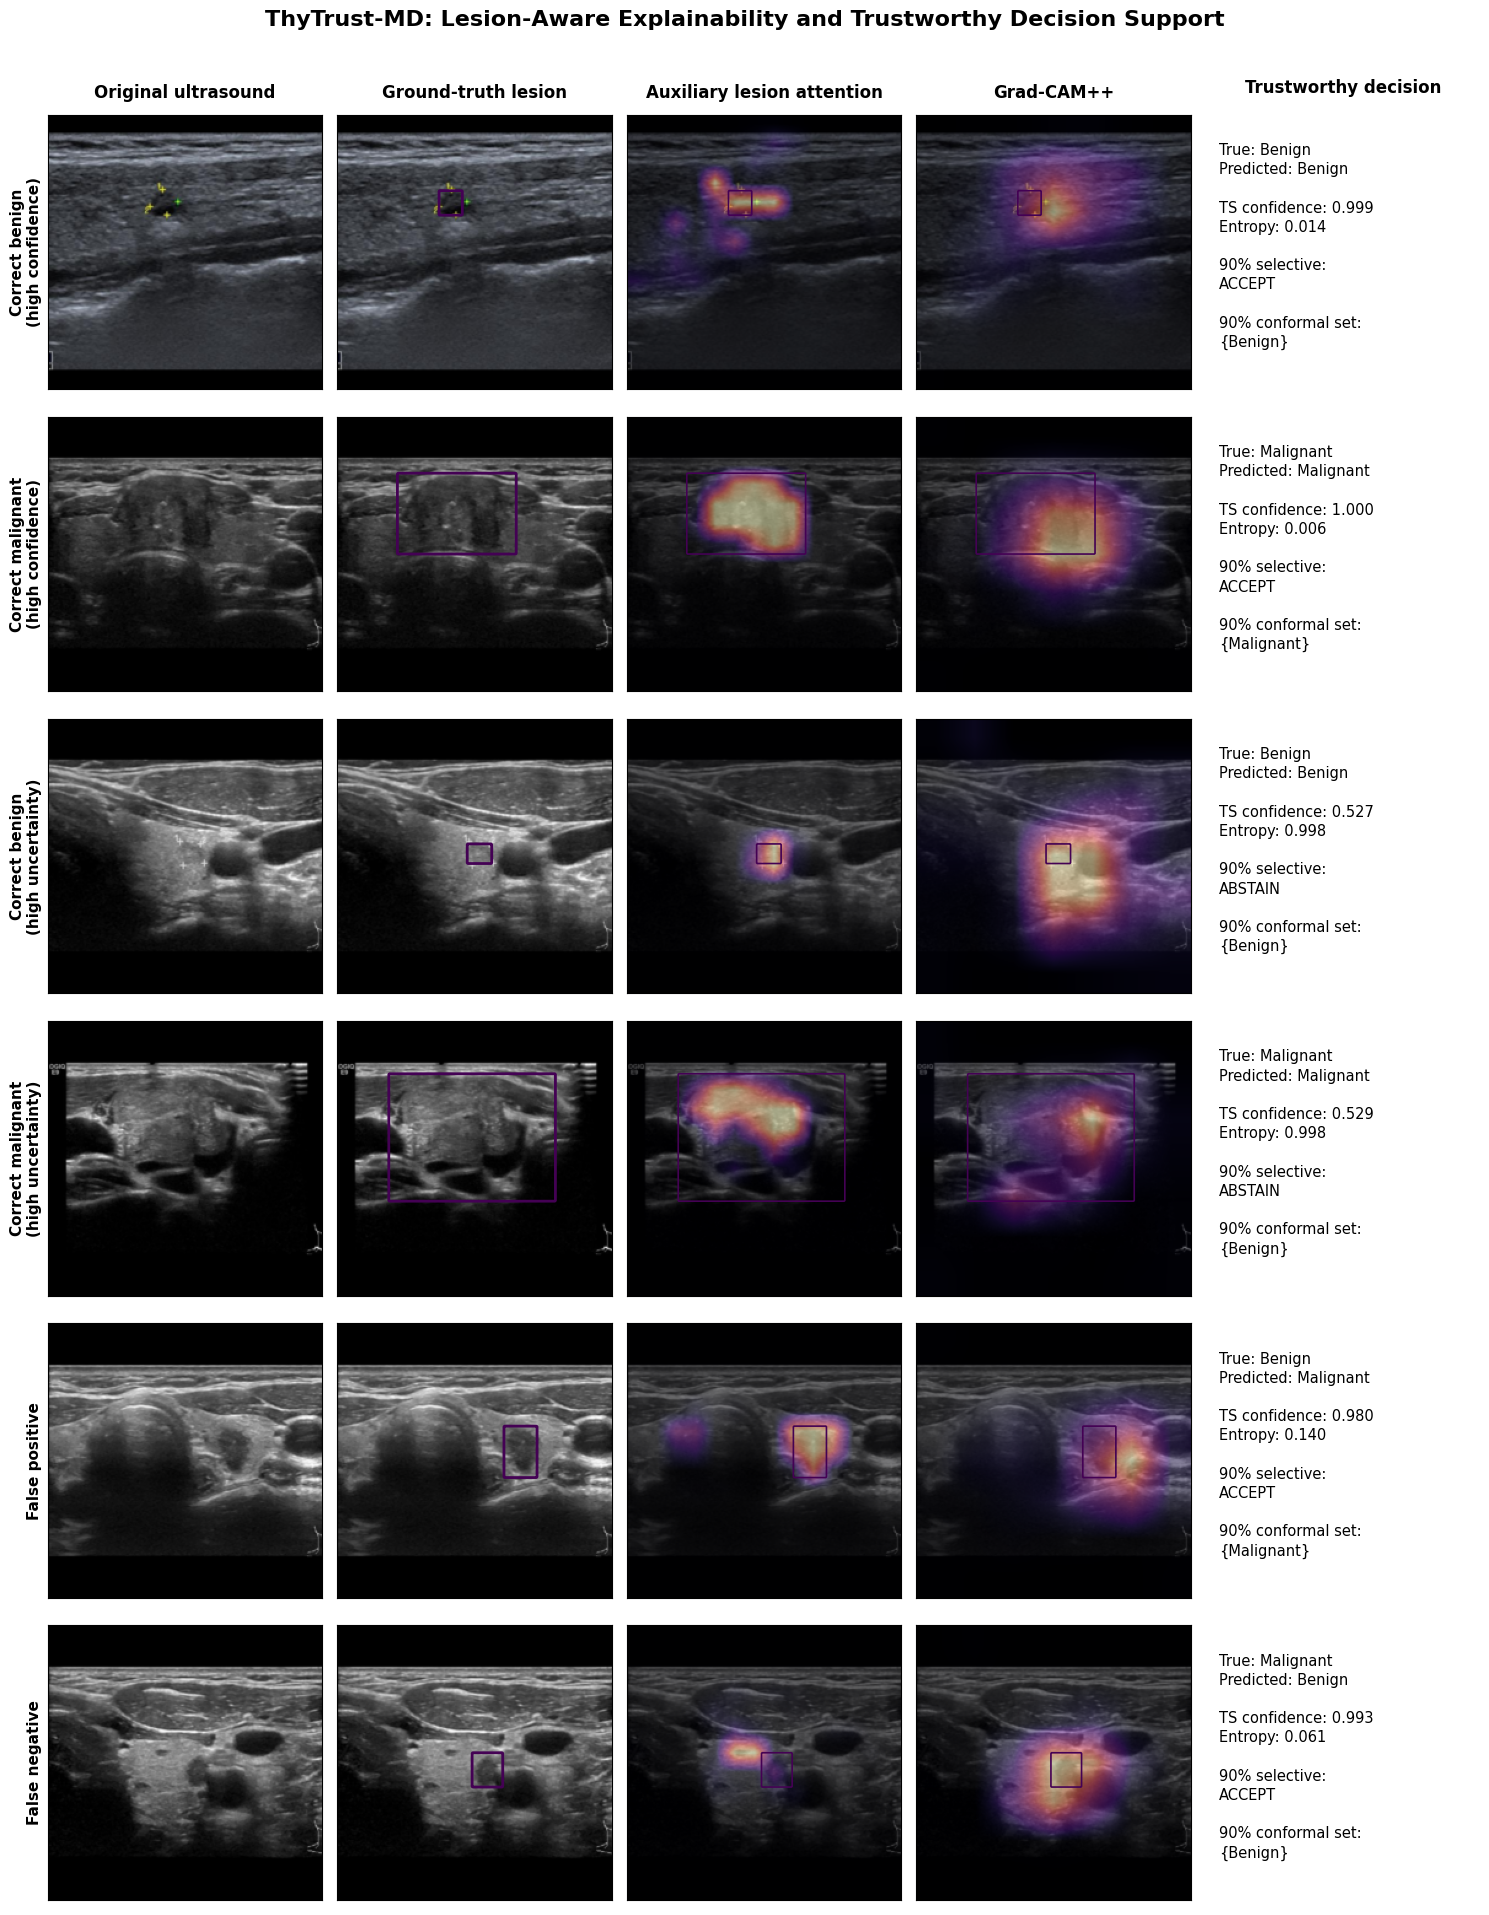


Saved:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/Paper_Figures/Fig_XAI_Clinical_Trust_Panel.png
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/Paper_Figures/Fig_XAI_Clinical_Trust_Panel.pdf


In [ ]:
# ======================================================================================
# THYTRUST-MD — PUBLICATION FIGURE PACK
# BLOCK 1/2
#
# FIGURE 1:
#   CLINICAL XAI + TRUSTWORTHY DECISION PANEL
#
# Rows are selected by PRE-SPECIFIED predictive behavior:
#   1. High-confidence correct benign
#   2. High-confidence correct malignant
#   3. Uncertain correct benign
#   4. Uncertain correct malignant
#   5. False positive
#   6. False negative
#
# Columns:
#   A. Original ultrasound
#   B. Ground-truth bbox
#   C. Learned auxiliary lesion attention
#   D. Grad-CAM++
#   E. Trustworthy prediction summary
#
# IMPORTANT:
#   ✓ VALIDATION/DEVELOPMENT CASES ONLY
#   ✓ NO TEST ACCESS
#   ✓ NO TRAINING
#   ✓ Uses locked C2A checkpoint
#   ✓ Uses locked D1 temperature
#   ✓ Uses locked D2 selective threshold
#   ✓ Uses locked D3 Mondrian conformal threshold
# ======================================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import json
import gc

import numpy as np
import pandas as pd

from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

from torchvision.models import resnet50

import matplotlib.pyplot as plt


# ======================================================================================
# 0. PATHS
# ======================================================================================

ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

PAPER_FIG_DIR = (
    ROOT
    / "Paper_Figures"
)

PAPER_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SPLIT_FILE = (
    ROOT
    / "dataset_audit"
    / "final_leakage_controlled_split"
    / "tn5000_leakage_controlled_split_seed42.csv"
)

C2A_CKPT = (
    ROOT
    / "C2A_AuxBBox_ResNet50_seed42"
    / "checkpoints"
    / "c2a_resnet50_auxbbox_best_macro_f1.pt"
)

C2A_ATTENTION_FILE = (
    ROOT
    / "C2A_AuxBBox_ResNet50_seed42"
    / "csv_outputs"
    / "validation_attention_maps.npz"
)

D1_FILE = (
    ROOT
    / "D1_TemperatureScaling_C2A_seed42"
    / "csv_outputs"
    / "validation_predictions_temperature_scaled.csv"
)

D2_LOCK = (
    ROOT
    / "D2_Uncertainty_SelectivePrediction_C2A_seed42"
    / "config"
    / "D2_selective_prediction_lock.json"
)

D3_LOCK = (
    ROOT
    / "D3_ConformalPrediction_C2A_seed42"
    / "config"
    / "D3_conformal_lock.json"
)


for p in [
    SPLIT_FILE,
    C2A_CKPT,
    C2A_ATTENTION_FILE,
    D1_FILE,
    D2_LOCK,
    D3_LOCK
]:

    assert p.exists(), f"Missing:\n{p}"


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

INPUT_SIZE = 224

CLASS_NAMES = {
    0: "Benign",
    1: "Malignant"
}


print("=" * 110)
print("THYTRUST-MD — PUBLICATION XAI FIGURE")
print("=" * 110)

print("Device :", DEVICE)
print("Test   : NOT ACCESSED")



# ======================================================================================
# FIXED SECTION 1 — LOAD + MERGE DEVELOPMENT DATA
# ======================================================================================

manifest = pd.read_csv(
    SPLIT_FILE
)

val_manifest = (
    manifest[
        manifest["split"] == "val"
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(val_manifest) == 508


pred_df = pd.read_csv(
    D1_FILE
)

assert len(pred_df) == 508


# ------------------------------------------------------------------------------
# Create common matching key
# ------------------------------------------------------------------------------

val_manifest["image_id_key"] = (
    val_manifest["image_id_norm"]
    .astype(str)
)

pred_df["image_id_key"] = (
    pred_df["image_id"]
    .astype(str)
)


# ------------------------------------------------------------------------------
# IMPORTANT FIX
#
# D1 CSV already contains image_path.
# Do NOT merge all its columns with the manifest because pandas then creates:
#
#     image_path_x
#     image_path_y
#
# We only take prediction/calibration columns that are actually needed.
# ------------------------------------------------------------------------------

prediction_columns_needed = [
    "image_id_key",
    "ts_prob_benign",
    "ts_prob_malignant",
]


missing_prediction_columns = [
    c
    for c in prediction_columns_needed
    if c not in pred_df.columns
]

if missing_prediction_columns:

    raise RuntimeError(
        f"Missing D1 prediction columns: "
        f"{missing_prediction_columns}"
    )


data = val_manifest.merge(

    pred_df[
        prediction_columns_needed
    ],

    on="image_id_key",

    how="inner",

    validate="one_to_one"
)


assert len(data) == 508


# ------------------------------------------------------------------------------
# Critical audit
# ------------------------------------------------------------------------------

required_after_merge = [
    "image_id_key",
    "image_path",
    "label",
    "bboxes_json",
    "ts_prob_benign",
    "ts_prob_malignant",
]


missing_after_merge = [
    c
    for c in required_after_merge
    if c not in data.columns
]


if missing_after_merge:

    print("\nAVAILABLE COLUMNS:")
    print(data.columns.tolist())

    raise RuntimeError(
        f"Missing columns after merge: "
        f"{missing_after_merge}"
    )


# Verify every image file exists
missing_images = []

for path in data["image_path"].astype(str):

    if not Path(path).exists():

        missing_images.append(
            path
        )


if missing_images:

    print(
        f"\nWARNING: "
        f"{len(missing_images)} image paths do not exist."
    )

    print(
        "First missing paths:"
    )

    for path in missing_images[:10]:

        print(path)

    raise RuntimeError(
        "STOP — image paths must be fixed before XAI."
    )


print("=" * 100)
print("XAI DATA MERGE FIXED")
print("=" * 100)

print(
    "Validation cases :",
    len(data)
)

print(
    "image_path       : FOUND"
)

print(
    "bboxes_json      : FOUND"
)

print(
    "TS probabilities : FOUND"
)

print(
    "Image files      : ALL FOUND"
)

print(
    "Test accessed    : NO"
)

print("=" * 100)

# ======================================================================================
# 2. LOAD LOCKED TRUST PARAMETERS
# ======================================================================================

with open(
    D2_LOCK,
    "r"
) as f:

    d2 = json.load(
        f
    )


with open(
    D3_LOCK,
    "r"
) as f:

    d3 = json.load(
        f
    )


SELECTIVE_THRESHOLD_90 = float(

    d2[
        "primary_operating_points"
    ][
        "target_coverage_90"
    ][
        "frozen_ts_confidence_threshold"
    ]
)


mondrian_90 = (

    d3[
        "alphas"
    ][
        "alpha_0.10"
    ][
        "mondrian"
    ]
)


Q_BENIGN = float(
    mondrian_90[
        "qhat_benign"
    ]
)

Q_MALIGNANT = float(
    mondrian_90[
        "qhat_malignant"
    ]
)


# ======================================================================================
# 3. PREPARE PREDICTION / UNCERTAINTY FIELDS
# ======================================================================================

data[
    "ts_pred"
] = (

    data[
        [
            "ts_prob_benign",
            "ts_prob_malignant"
        ]
    ]
    .to_numpy()
    .argmax(
        axis=1
    )
)


data[
    "ts_confidence_pub"
] = data[
    [
        "ts_prob_benign",
        "ts_prob_malignant"
    ]
].max(
    axis=1
)


probs_all = data[
    [
        "ts_prob_benign",
        "ts_prob_malignant"
    ]
].to_numpy(
    dtype=float
)


data[
    "entropy"
] = (

    -np.sum(
        probs_all
        *
        np.log(
            np.clip(
                probs_all,
                1e-12,
                1.0
            )
        ),
        axis=1
    )

    /

    np.log(
        2.0
    )
)


data[
    "correct"
] = (
    data[
        "ts_pred"
    ]
    ==
    data[
        "label"
    ]
)


# ======================================================================================
# 4. PRE-SPECIFIED CASE SELECTION
#
# IMPORTANT:
# Cases are NOT selected using Grad-CAM quality.
# ======================================================================================

selected = []


def choose_one(
    dataframe,
    sort_column,
    ascending
):

    if len(
        dataframe
    ) == 0:

        return None

    return (
        dataframe
        .sort_values(
            sort_column,
            ascending=ascending
        )
        .iloc[
            0
        ]
    )


# ------------------------------------------------------------------
# High confidence correct benign
# ------------------------------------------------------------------

case = choose_one(

    data[
        (data["label"] == 0)
        &
        (data["correct"])
    ],

    "ts_confidence_pub",

    False
)

if case is not None:

    selected.append(
        (
            "Correct benign\n(high confidence)",
            case
        )
    )


# ------------------------------------------------------------------
# High confidence correct malignant
# ------------------------------------------------------------------

case = choose_one(

    data[
        (data["label"] == 1)
        &
        (data["correct"])
    ],

    "ts_confidence_pub",

    False
)

if case is not None:

    selected.append(
        (
            "Correct malignant\n(high confidence)",
            case
        )
    )


# ------------------------------------------------------------------
# Uncertain correct benign
# ------------------------------------------------------------------

case = choose_one(

    data[
        (data["label"] == 0)
        &
        (data["correct"])
    ],

    "entropy",

    False
)

if case is not None:

    selected.append(
        (
            "Correct benign\n(high uncertainty)",
            case
        )
    )


# ------------------------------------------------------------------
# Uncertain correct malignant
# ------------------------------------------------------------------

case = choose_one(

    data[
        (data["label"] == 1)
        &
        (data["correct"])
    ],

    "entropy",

    False
)

if case is not None:

    selected.append(
        (
            "Correct malignant\n(high uncertainty)",
            case
        )
    )


# ------------------------------------------------------------------
# False positive — confident failure
# ------------------------------------------------------------------

case = choose_one(

    data[
        (data["label"] == 0)
        &
        (data["ts_pred"] == 1)
    ],

    "ts_confidence_pub",

    False
)

if case is not None:

    selected.append(
        (
            "False positive",
            case
        )
    )


# ------------------------------------------------------------------
# False negative — confident failure
# ------------------------------------------------------------------

case = choose_one(

    data[
        (data["label"] == 1)
        &
        (data["ts_pred"] == 0)
    ],

    "ts_confidence_pub",

    False
)

if case is not None:

    selected.append(
        (
            "False negative",
            case
        )
    )


# Fallback if one error type does not exist.
if len(
    selected
) < 6:

    already_used = {
        str(row["image_id_key"])
        for _, row in selected
    }

    remaining_errors = (
        data[
            ~data[
                "correct"
            ]
        ]
        .sort_values(
            "entropy",
            ascending=False
        )
    )

    for _, row in remaining_errors.iterrows():

        if (
            str(
                row[
                    "image_id_key"
                ]
            )
            not in already_used
        ):

            selected.append(
                (
                    "Misclassified case",
                    row
                )
            )

        if len(
            selected
        ) == 6:

            break


selected = selected[
    :6
]


print("\nSelected cases:")

for name, row in selected:

    print(
        f"{name:35s} "
        f"| ID={row['image_id_key']} "
        f"| True={CLASS_NAMES[int(row['label'])]} "
        f"| Pred={CLASS_NAMES[int(row['ts_pred'])]}"
    )


# ======================================================================================
# 5. LOAD SAVED C2A AUXILIARY ATTENTION
# ======================================================================================

attention_npz = np.load(
    C2A_ATTENTION_FILE,
    allow_pickle=True
)


attention_ids = (
    attention_npz[
        "image_ids"
    ]
    .astype(str)
)


attention_maps = (
    attention_npz[
        "attention_maps"
    ]
)


attention_lookup = {

    image_id:
        attention_maps[
            i
        ]

    for i, image_id
    in enumerate(
        attention_ids
    )
}


# ======================================================================================
# 6. C2A MODEL
# ======================================================================================

class C2AModel(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()

        self.backbone = resnet50(
            weights=None
        )

        self.backbone.fc = nn.Linear(
            self.backbone.fc.in_features,
            2
        )

        self.localization_head = nn.Conv2d(
            1024,
            1,
            kernel_size=1,
            bias=True
        )


    def forward(
        self,
        x
    ):

        x = self.backbone.conv1(
            x
        )

        x = self.backbone.bn1(
            x
        )

        x = self.backbone.relu(
            x
        )

        x = self.backbone.maxpool(
            x
        )

        x = self.backbone.layer1(
            x
        )

        x = self.backbone.layer2(
            x
        )

        l3 = self.backbone.layer3(
            x
        )

        loc = self.localization_head(
            l3
        )

        x = self.backbone.layer4(
            l3
        )

        x = self.backbone.avgpool(
            x
        )

        x = torch.flatten(
            x,
            1
        )

        cls = self.backbone.fc(
            x
        )

        return (
            cls,
            loc
        )


model = C2AModel()


checkpoint = torch.load(
    C2A_CKPT,
    map_location="cpu",
    weights_only=False
)


state = checkpoint[
    "model_state_dict"
]


state = {
    key.replace(
        "module.",
        ""
    ):
        value

    for key, value
    in state.items()
}


model.load_state_dict(
    state,
    strict=True
)


model = model.to(
    DEVICE
).eval()


# ======================================================================================
# 7. GRAD-CAM++
# ======================================================================================

class GradCAMPlusPlus:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model

        self.activations = None
        self.gradients = None


        self.h1 = target_layer.register_forward_hook(
            self._forward_hook
        )


        self.h2 = target_layer.register_full_backward_hook(
            self._backward_hook
        )


    def _forward_hook(
        self,
        module,
        inp,
        out
    ):

        self.activations = out


    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[
            0
        ]


    def generate(
        self,
        x
    ):

        self.model.zero_grad(
            set_to_none=True
        )


        logits, _ = self.model(
            x
        )


        target_class = int(
            logits.argmax(
                dim=1
            ).item()
        )


        score = logits[
            0,
            target_class
        ]


        score.backward()


        activations = (
            self.activations[
                0
            ]
        )

        gradients = (
            self.gradients[
                0
            ]
        )


        grad2 = gradients.pow(
            2
        )

        grad3 = gradients.pow(
            3
        )


        denominator = (

            2
            *
            grad2

            +

            activations.sum(
                dim=(
                    1,
                    2
                ),
                keepdim=True
            )
            *
            grad3
        )


        denominator = torch.where(
            denominator != 0,
            denominator,
            torch.ones_like(
                denominator
            )
        )


        alpha = (
            grad2
            /
            (
                denominator
                +
                1e-8
            )
        )


        weights = (

            alpha

            *

            F.relu(
                gradients
            )

        ).sum(
            dim=(
                1,
                2
            ),
            keepdim=True
        )


        cam = (

            weights

            *

            activations

        ).sum(
            dim=0
        )


        cam = F.relu(
            cam
        )


        cam = F.interpolate(

            cam[
                None,
                None
            ],

            size=(
                INPUT_SIZE,
                INPUT_SIZE
            ),

            mode="bilinear",

            align_corners=False

        )[
            0,
            0
        ]


        cam = (
            cam
            -
            cam.min()
        )


        cam = (
            cam
            /
            (
                cam.max()
                +
                1e-8
            )
        )


        return (
            cam.detach()
            .cpu()
            .numpy()
        )


cam_generator = GradCAMPlusPlus(

    model,

    model.backbone.layer4[
        -1
    ]
)


# ======================================================================================
# 8. PREPROCESS + BBOX
# ======================================================================================

MEAN = [
    0.485,
    0.456,
    0.406
]

STD = [
    0.229,
    0.224,
    0.225
]


def parse_boxes(
    value
):

    boxes = (
        json.loads(
            value
        )
        if isinstance(
            value,
            str
        )
        else value
    )

    return [
        (
            float(
                b[
                    "xmin"
                ]
            ),
            float(
                b[
                    "ymin"
                ]
            ),
            float(
                b[
                    "xmax"
                ]
            ),
            float(
                b[
                    "ymax"
                ]
            )
        )

        for b in boxes
    ]


def create_mask(
    image,
    boxes
):

    width, height = (
        image.size
    )


    mask = Image.new(
        "L",
        (
            width,
            height
        ),
        0
    )


    draw = ImageDraw.Draw(
        mask
    )


    for (
        x1,
        y1,
        x2,
        y2
    ) in boxes:

        draw.rectangle(
            [
                int(
                    x1
                ),
                int(
                    y1
                ),
                int(
                    x2
                ),
                int(
                    y2
                )
            ],
            fill=255
        )


    return mask


def pad_pair(
    image,
    mask
):

    width, height = image.size

    side = max(
        width,
        height
    )


    left = (
        side - width
    ) // 2

    right = (
        side - width - left
    )

    top = (
        side - height
    ) // 2

    bottom = (
        side - height - top
    )


    padding = [
        left,
        top,
        right,
        bottom
    ]


    return (
        TF.pad(
            image,
            padding,
            fill=0
        ),
        TF.pad(
            mask,
            padding,
            fill=0
        )
    )


def preprocess(
    image,
    mask
):

    image, mask = pad_pair(
        image,
        mask
    )


    display_img = TF.resize(
        image,
        [
            INPUT_SIZE,
            INPUT_SIZE
        ],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    )


    mask = TF.resize(
        mask,
        [
            INPUT_SIZE,
            INPUT_SIZE
        ],
        interpolation=InterpolationMode.NEAREST
    )


    tensor = TF.to_tensor(
        display_img
    )


    tensor = TF.normalize(
        tensor,
        MEAN,
        STD
    )


    mask_np = (

        TF.to_tensor(
            mask
        )[
            0
        ]
        .numpy()
        >
        0.5
    )


    return (
        tensor,
        np.asarray(
            display_img
        ),
        mask_np
    )


# ======================================================================================
# 9. CONFORMAL SET
# ======================================================================================

def conformal_set_90(
    p_benign,
    p_malignant
):

    include_benign = (
        1.0
        -
        p_benign
        <=
        Q_BENIGN
    )


    include_malignant = (
        1.0
        -
        p_malignant
        <=
        Q_MALIGNANT
    )


    labels = []


    if include_benign:

        labels.append(
            "Benign"
        )


    if include_malignant:

        labels.append(
            "Malignant"
        )


    if not labels:

        return "∅"


    return (
        "{"
        +
        ", ".join(
            labels
        )
        +
        "}"
    )


# ======================================================================================
# 10. CREATE MAIN XAI PANEL
# ======================================================================================

N_ROWS = len(
    selected
)

N_COLS = 5


fig, axes = plt.subplots(

    N_ROWS,

    N_COLS,

    figsize=(
        15,
        3.2
        *
        N_ROWS
    )
)


if N_ROWS == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )


column_titles = [

    "Original ultrasound",

    "Ground-truth lesion",

    "Auxiliary lesion attention",

    "Grad-CAM++",

    "Trustworthy decision"
]


for col, title in enumerate(
    column_titles
):

    axes[
        0,
        col
    ].set_title(
        title,
        fontsize=12,
        fontweight="bold",
        pad=12
    )


for row_idx, (
    case_name,
    row
) in enumerate(
    selected
):

    image = (
        Image.open(
            row[
                "image_path"
            ]
        )
        .convert(
            "RGB"
        )
    )


    boxes = parse_boxes(
        row[
            "bboxes_json"
        ]
    )


    mask = create_mask(
        image,
        boxes
    )


    tensor, display_img, mask_np = (
        preprocess(
            image,
            mask
        )
    )


    tensor_gpu = (
        tensor
        .unsqueeze(
            0
        )
        .to(
            DEVICE
        )
    )


    # ------------------------------------------------------------------
    # Grad-CAM++
    # ------------------------------------------------------------------

    gradcam = cam_generator.generate(
        tensor_gpu
    )


    # ------------------------------------------------------------------
    # Saved auxiliary attention
    # ------------------------------------------------------------------

    image_id = str(
        row[
            "image_id_key"
        ]
    )


    aux = attention_lookup[
        image_id
    ]


    aux = np.squeeze(
        aux
    )


    aux_tensor = torch.tensor(
        aux,
        dtype=torch.float32
    )[
        None,
        None
    ]


    aux_up = F.interpolate(

        aux_tensor,

        size=(
            INPUT_SIZE,
            INPUT_SIZE
        ),

        mode="bilinear",

        align_corners=False

    )[
        0,
        0
    ].numpy()


    aux_up = (
        aux_up
        -
        aux_up.min()
    )


    aux_up = (
        aux_up
        /
        (
            aux_up.max()
            +
            1e-8
        )
    )


    # ------------------------------------------------------------------
    # A — Original
    # ------------------------------------------------------------------

    ax = axes[
        row_idx,
        0
    ]

    ax.imshow(
        display_img
    )

    ax.set_ylabel(
        case_name,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xticks([])
    ax.set_yticks([])


    # ------------------------------------------------------------------
    # B — GT bbox
    # ------------------------------------------------------------------

    ax = axes[
        row_idx,
        1
    ]

    ax.imshow(
        display_img
    )

    ax.contour(
        mask_np,
        levels=[
            0.5
        ],
        linewidths=2
    )

    ax.set_xticks([])
    ax.set_yticks([])


    # ------------------------------------------------------------------
    # C — Auxiliary attention
    # ------------------------------------------------------------------

    ax = axes[
        row_idx,
        2
    ]

    ax.imshow(
        display_img
    )

    ax.imshow(
        aux_up,
        cmap="magma",
        alpha=0.52,
        vmin=0,
        vmax=1
    )

    ax.contour(
        mask_np,
        levels=[
            0.5
        ],
        linewidths=1.2
    )

    ax.set_xticks([])
    ax.set_yticks([])


    # ------------------------------------------------------------------
    # D — Grad-CAM++
    # ------------------------------------------------------------------

    ax = axes[
        row_idx,
        3
    ]

    ax.imshow(
        display_img
    )

    ax.imshow(
        gradcam,
        cmap="magma",
        alpha=0.52,
        vmin=0,
        vmax=1
    )

    ax.contour(
        mask_np,
        levels=[
            0.5
        ],
        linewidths=1.2
    )

    ax.set_xticks([])
    ax.set_yticks([])


    # ------------------------------------------------------------------
    # E — Trust summary
    # ------------------------------------------------------------------

    ax = axes[
        row_idx,
        4
    ]

    ax.axis(
        "off"
    )


    true_label = CLASS_NAMES[
        int(
            row[
                "label"
            ]
        )
    ]


    pred_label = CLASS_NAMES[
        int(
            row[
                "ts_pred"
            ]
        )
    ]


    confidence = float(
        row[
            "ts_confidence_pub"
        ]
    )


    entropy_value = float(
        row[
            "entropy"
        ]
    )


    selective_decision = (
        "ACCEPT"
        if confidence
        >=
        SELECTIVE_THRESHOLD_90
        else
        "ABSTAIN"
    )


    conformal = conformal_set_90(

        float(
            row[
                "ts_prob_benign"
            ]
        ),

        float(
            row[
                "ts_prob_malignant"
            ]
        )
    )


    text = (

        f"True: {true_label}\n"
        f"Predicted: {pred_label}\n\n"

        f"TS confidence: "
        f"{confidence:.3f}\n"

        f"Entropy: "
        f"{entropy_value:.3f}\n\n"

        f"90% selective:\n"
        f"{selective_decision}\n\n"

        f"90% conformal set:\n"
        f"{conformal}"
    )


    ax.text(

        0.05,
        0.52,

        text,

        transform=ax.transAxes,

        va="center",

        ha="left",

        fontsize=10.5,

        linespacing=1.35
    )


fig.suptitle(

    "ThyTrust-MD: Lesion-Aware Explainability and Trustworthy Decision Support",

    fontsize=16,

    fontweight="bold",

    y=0.995
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.985
    ]
)


png_path = (
    PAPER_FIG_DIR
    / "Fig_XAI_Clinical_Trust_Panel.png"
)

pdf_path = (
    PAPER_FIG_DIR
    / "Fig_XAI_Clinical_Trust_Panel.pdf"
)


fig.savefig(
    png_path,
    dpi=500,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)


plt.show()


print("\nSaved:")
print(png_path)
print(pdf_path)


cam_generator.h1.remove()
cam_generator.h2.remove()

del model

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

# final one-shot evaluation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — E1 FINAL FROZEN INTERNAL-TEST EVALUATION
Device          : cuda
GPU             : NVIDIA A100-SXM4-40GB
Checkpoint      : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/C2A_AuxBBox_ResNet50_seed42/checkpoints/c2a_resnet50_auxbbox_best_macro_f1.pt
Frozen D1       : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/D1_TemperatureScaling_C2A_seed42/config/temperature_scaling.json
Frozen D2       : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/D2_Uncertainty_SelectivePrediction_C2A_seed42/config/D2_selective_prediction_lock.json
Frozen D3       : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/D3_ConformalPrediction_C2A_seed42/config/D3_conformal_lock.json


FROZEN DEVELOPMENT PARAMETERS
Temperature T         : 1.806635
Selective 90 threshold: 0.629641
Selective 80 threshold: 0.775376
90% Mondrian q benig

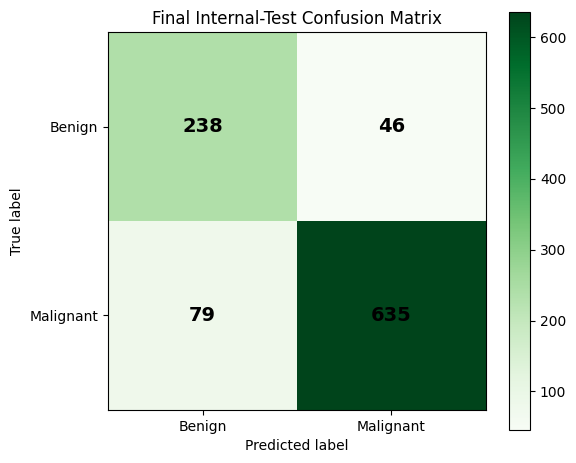

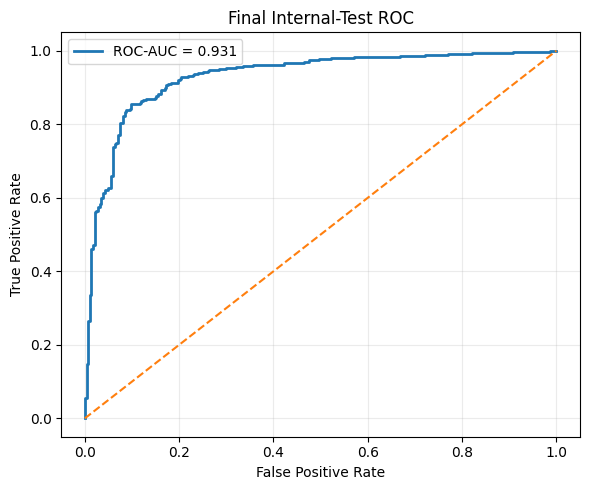

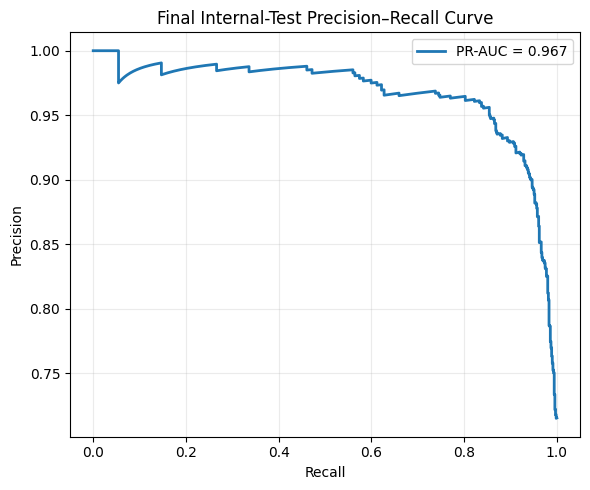

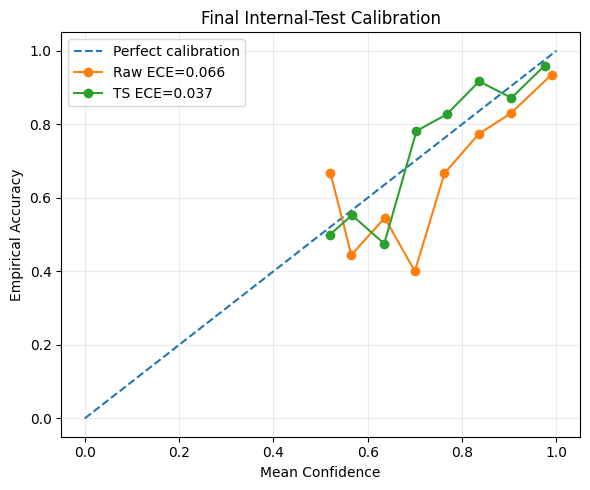

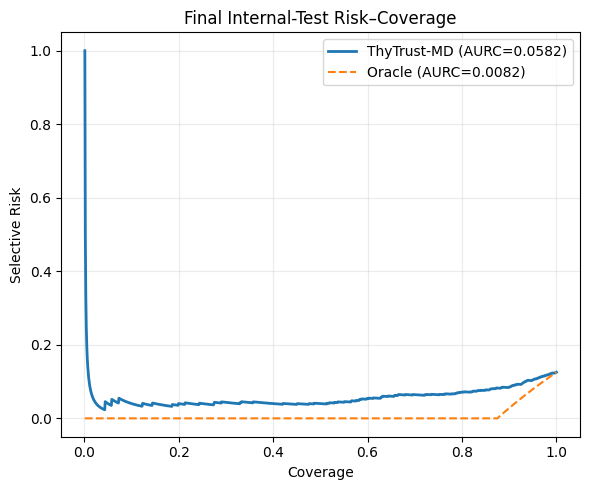

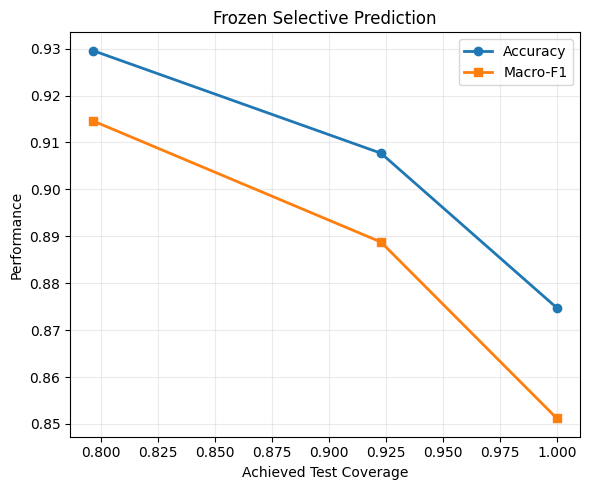

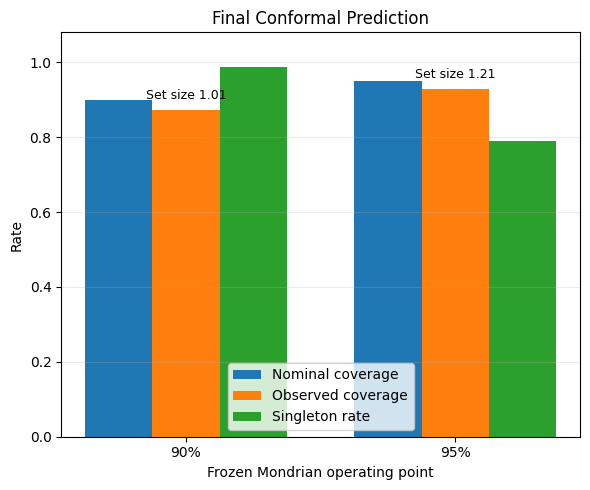

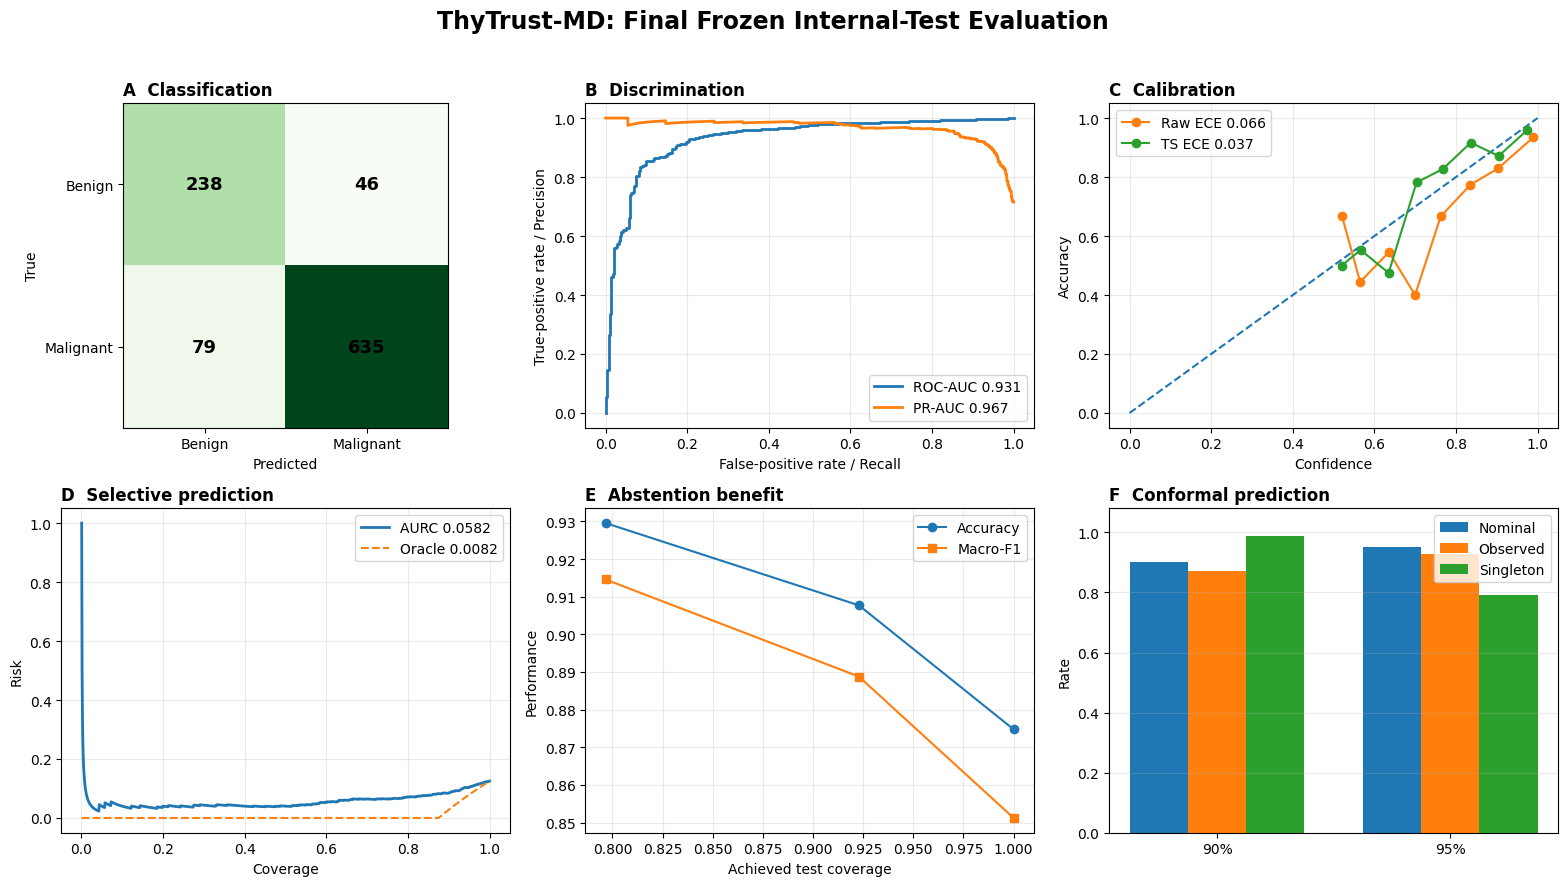



THYTRUST-MD — E1 FINAL FROZEN INTERNAL-TEST RESULT
Test N                    : 998

CLASSIFICATION
Accuracy                  : 0.874749
Macro-F1                  : 0.851204
Weighted-F1               : 0.876707
Balanced Accuracy         : 0.863692
Sensitivity               : 0.889356
Specificity               : 0.838028
MCC                       : 0.704967
Cohen Kappa               : 0.702794
ROC-AUC                   : 0.930633
PR-AUC                    : 0.966943

CALIBRATION
Raw ECE                   : 0.066269
TS ECE                    : 0.036781
Raw Brier                 : 0.097722
TS Brier                  : 0.094089
Raw NLL                   : 0.416757
TS NLL                    : 0.330824

UNCERTAINTY / SELECTIVE
Error-detection AUROC     : 0.770089
Error-detection AUPRC     : 0.369611
AURC                      : 0.058157
E-AURC                    : 0.049963

FROZEN 90% DEVELOPMENT THRESHOLD
Threshold                 : 0.629641
Achieved TEST coverage    : 0.922846
Selective acc

In [ ]:
# ======================================================================================
# THYTRUST-MD — E1
# FINAL ONE-SHOT FROZEN INTERNAL-TEST EVALUATION
#
# MODEL:
#   C2A — ResNet50 + training-time auxiliary bbox supervision
#
# FROZEN DEVELOPMENT COMPONENTS:
#   D1 — Temperature Scaling
#   D2 — Selective Prediction thresholds
#   D3 — Mondrian LAC conformal thresholds
#
# THIS IS THE FIRST FINAL ACCESS TO THE INTERNAL TEST SET.
#
# ABSOLUTE RULES:
#   ✓ C2A checkpoint frozen
#   ✓ Temperature frozen
#   ✓ Selective thresholds frozen
#   ✓ Conformal q-hats frozen
#   ✓ NO threshold optimization on test
#   ✓ NO temperature fitting on test
#   ✓ NO q-hat fitting on test
#   ✓ ONE model inference pass
#
# SAVES:
#   - complete metrics
#   - bootstrap 95% CIs
#   - per-image raw + calibrated probabilities
#   - uncertainty scores
#   - selective decisions
#   - conformal prediction sets
#   - localization diagnostics
#   - confusion matrix
#   - ROC curve
#   - PR curve
#   - reliability diagram
#   - risk-coverage curve
#   - selective prediction figure
#   - conformal summary figure
#   - final 6-panel manuscript dashboard
#   - parameters / GMACs / latency / FPS
# ======================================================================================


# ======================================================================================
# 0. DRIVE / IMPORTS
# ======================================================================================

from google.colab import drive
drive.mount(
    "/content/drive",
    force_remount=False
)

import os
import gc
import json
import time
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    log_loss,
    roc_curve,
    precision_recall_curve,
)

print("=" * 120)
print("THYTRUST-MD — E1 FINAL FROZEN INTERNAL-TEST EVALUATION")
print("=" * 120)


# ======================================================================================
# 1. CONFIG
# ======================================================================================

SEED = 42

INPUT_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = min(
    4,
    os.cpu_count() or 2
)

N_BOOTSTRAP = 3000

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

CLASS_NAMES = {
    0: "Benign",
    1: "Malignant"
}


ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)


SPLIT_FILE = (
    ROOT
    / "dataset_audit"
    / "final_leakage_controlled_split"
    / "tn5000_leakage_controlled_split_seed42.csv"
)


C2A_ROOT = (
    ROOT
    / "C2A_AuxBBox_ResNet50_seed42"
)

C2A_CKPT = (
    C2A_ROOT
    / "checkpoints"
    / "c2a_resnet50_auxbbox_best_macro_f1.pt"
)


D1_LOCK = (
    ROOT
    / "D1_TemperatureScaling_C2A_seed42"
    / "config"
    / "temperature_scaling.json"
)


D2_LOCK = (
    ROOT
    / "D2_Uncertainty_SelectivePrediction_C2A_seed42"
    / "config"
    / "D2_selective_prediction_lock.json"
)


D3_LOCK = (
    ROOT
    / "D3_ConformalPrediction_C2A_seed42"
    / "config"
    / "D3_conformal_lock.json"
)


E1_ROOT = (
    ROOT
    / "E1_Final_Frozen_Internal_Test"
)

CSV_DIR = (
    E1_ROOT
    / "csv_outputs"
)

FIG_DIR = (
    E1_ROOT
    / "figures"
)

CONFIG_DIR = (
    E1_ROOT
    / "config"
)

for folder in [
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ======================================================================================
# 2. FILE AUDIT
# ======================================================================================

required_files = [
    SPLIT_FILE,
    C2A_CKPT,
    D1_LOCK,
    D2_LOCK,
    D3_LOCK,
]


for path in required_files:

    assert path.exists(), (
        f"Missing required frozen file:\n{path}"
    )


print(
    "Device          :",
    DEVICE
)

if DEVICE.type == "cuda":

    print(
        "GPU             :",
        torch.cuda.get_device_name(0)
    )

print(
    "Checkpoint      :",
    C2A_CKPT
)

print(
    "Frozen D1       :",
    D1_LOCK
)

print(
    "Frozen D2       :",
    D2_LOCK
)

print(
    "Frozen D3       :",
    D3_LOCK
)


# ======================================================================================
# 3. REPRODUCIBILITY
# ======================================================================================

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False


# ======================================================================================
# 4. LOAD FROZEN TRUST PARAMETERS
# ======================================================================================

with open(
    D1_LOCK,
    "r"
) as f:

    d1 = json.load(
        f
    )


with open(
    D2_LOCK,
    "r"
) as f:

    d2 = json.load(
        f
    )


with open(
    D3_LOCK,
    "r"
) as f:

    d3 = json.load(
        f
    )


TEMPERATURE = float(
    d1[
        "temperature"
    ]
)


SELECTIVE_THRESHOLD_90 = float(

    d2[
        "primary_operating_points"
    ][
        "target_coverage_90"
    ][
        "frozen_ts_confidence_threshold"
    ]
)


SELECTIVE_THRESHOLD_80 = float(

    d2[
        "primary_operating_points"
    ][
        "target_coverage_80"
    ][
        "frozen_ts_confidence_threshold"
    ]
)


D3_ALPHA_10 = (
    d3[
        "alphas"
    ][
        "alpha_0.10"
    ][
        "mondrian"
    ]
)


D3_ALPHA_05 = (
    d3[
        "alphas"
    ][
        "alpha_0.05"
    ][
        "mondrian"
    ]
)


Q90_BENIGN = float(
    D3_ALPHA_10[
        "qhat_benign"
    ]
)

Q90_MALIGNANT = float(
    D3_ALPHA_10[
        "qhat_malignant"
    ]
)


Q95_BENIGN = float(
    D3_ALPHA_05[
        "qhat_benign"
    ]
)

Q95_MALIGNANT = float(
    D3_ALPHA_05[
        "qhat_malignant"
    ]
)


print("\n")
print("=" * 120)
print("FROZEN DEVELOPMENT PARAMETERS")
print("=" * 120)

print(
    f"Temperature T         : "
    f"{TEMPERATURE:.6f}"
)

print(
    f"Selective 90 threshold: "
    f"{SELECTIVE_THRESHOLD_90:.6f}"
)

print(
    f"Selective 80 threshold: "
    f"{SELECTIVE_THRESHOLD_80:.6f}"
)

print(
    f"90% Mondrian q benign : "
    f"{Q90_BENIGN:.6f}"
)

print(
    f"90% Mondrian q malign : "
    f"{Q90_MALIGNANT:.6f}"
)

print(
    f"95% Mondrian q benign : "
    f"{Q95_BENIGN:.6f}"
)

print(
    f"95% Mondrian q malign : "
    f"{Q95_MALIGNANT:.6f}"
)


# ======================================================================================
# 5. LOAD THE LOCKED TEST SPLIT
#
# IMPORTANT:
# Train and validation dataframes are NOT instantiated here.
# ======================================================================================

manifest = pd.read_csv(
    SPLIT_FILE
)


required_columns = {
    "image_id_norm",
    "image_path",
    "label",
    "split",
    "dup_group_id",
    "bboxes_json",
}


missing = (
    required_columns
    -
    set(
        manifest.columns
    )
)


if missing:

    raise RuntimeError(
        f"Split file missing columns: {missing}"
    )


test_df = (
    manifest[
        manifest[
            "split"
        ]
        ==
        "test"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("FINAL INTERNAL TEST SET OPENED")
print("=" * 120)

print(
    "Test samples:",
    len(
        test_df
    )
)

print(
    "Benign:",
    int(
        (
            test_df[
                "label"
            ]
            ==
            0
        ).sum()
    )
)

print(
    "Malignant:",
    int(
        (
            test_df[
                "label"
            ]
            ==
            1
        ).sum()
    )
)


# Expected protocol count.
if len(test_df) != 998:

    print(
        "\nWARNING:"
    )

    print(
        f"Expected 998 test images, "
        f"but split contains {len(test_df)}."
    )

    print(
        "Code will continue only if this is your locked split."
    )


# Ensure all test images exist.
missing_images = [

    path

    for path in
    test_df[
        "image_path"
    ].astype(
        str
    )

    if not Path(
        path
    ).exists()
]


if missing_images:

    print(
        "\nFirst missing image paths:"
    )

    for path in missing_images[
        :10
    ]:

        print(
            path
        )

    raise RuntimeError(
        f"{len(missing_images)} test images are missing."
    )


# ======================================================================================
# 6. PREPROCESSING — SAME LOCKED C2A EVALUATION PIPELINE
# ======================================================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


def parse_boxes(
    value
):

    boxes = (
        json.loads(
            value
        )
        if isinstance(
            value,
            str
        )
        else value
    )


    if (
        not isinstance(
            boxes,
            list
        )
        or
        len(
            boxes
        ) == 0
    ):

        raise RuntimeError(
            "Invalid bbox annotation."
        )


    return [

        (
            float(
                b[
                    "xmin"
                ]
            ),

            float(
                b[
                    "ymin"
                ]
            ),

            float(
                b[
                    "xmax"
                ]
            ),

            float(
                b[
                    "ymax"
                ]
            )
        )

        for b in boxes
    ]


def create_bbox_mask(
    image,
    boxes
):

    width, height = (
        image.size
    )


    mask = Image.new(
        "L",
        (
            width,
            height
        ),
        0
    )


    draw = ImageDraw.Draw(
        mask
    )


    for (
        x1,
        y1,
        x2,
        y2
    ) in boxes:

        x1 = max(
            0,
            min(
                width - 1,
                int(
                    np.floor(
                        x1
                    )
                )
            )
        )

        y1 = max(
            0,
            min(
                height - 1,
                int(
                    np.floor(
                        y1
                    )
                )
            )
        )

        x2 = max(
            x1 + 1,
            min(
                width,
                int(
                    np.ceil(
                        x2
                    )
                )
            )
        )

        y2 = max(
            y1 + 1,
            min(
                height,
                int(
                    np.ceil(
                        y2
                    )
                )
            )
        )


        draw.rectangle(
            [
                x1,
                y1,
                x2 - 1,
                y2 - 1
            ],
            fill=255
        )


    return mask


def pad_pair_to_square(
    image,
    mask
):

    width, height = (
        image.size
    )


    side = max(
        width,
        height
    )


    left = (
        side - width
    ) // 2

    right = (
        side
        -
        width
        -
        left
    )

    top = (
        side - height
    ) // 2

    bottom = (
        side
        -
        height
        -
        top
    )


    padding = [
        left,
        top,
        right,
        bottom
    ]


    image = TF.pad(
        image,
        padding,
        fill=0
    )

    mask = TF.pad(
        mask,
        padding,
        fill=0
    )


    return (
        image,
        mask
    )


def preprocess(
    image,
    mask
):

    image, mask = (
        pad_pair_to_square(
            image,
            mask
        )
    )


    image = TF.resize(
        image,
        [
            INPUT_SIZE,
            INPUT_SIZE
        ],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    )


    mask = TF.resize(
        mask,
        [
            INPUT_SIZE,
            INPUT_SIZE
        ],
        interpolation=InterpolationMode.NEAREST
    )


    image = TF.to_tensor(
        image
    )

    image = TF.normalize(
        image,
        IMAGENET_MEAN,
        IMAGENET_STD
    )


    mask = (
        TF.to_tensor(
            mask
        )
        >
        0.5
    ).float()


    return (
        image,
        mask
    )


# ======================================================================================
# 7. TEST DATASET
#
# Bounding boxes are used ONLY to score localization after inference.
# They are never supplied to the classifier.
# ======================================================================================

class TN5000FrozenTestDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = (
            self.df.iloc[
                idx
            ]
        )


        image_path = str(
            row[
                "image_path"
            ]
        )


        image = (
            Image.open(
                image_path
            )
            .convert(
                "RGB"
            )
        )


        boxes = parse_boxes(
            row[
                "bboxes_json"
            ]
        )


        mask = create_bbox_mask(
            image,
            boxes
        )


        image_tensor, mask_tensor = (
            preprocess(
                image,
                mask
            )
        )


        return (

            image_tensor,

            mask_tensor,

            int(
                row[
                    "label"
                ]
            ),

            str(
                row[
                    "image_id_norm"
                ]
            ),

            image_path,

            str(
                row[
                    "dup_group_id"
                ]
            )
        )


test_dataset = TN5000FrozenTestDataset(
    test_df
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type
        ==
        "cuda"
    )
)


# ======================================================================================
# 8. C2A MODEL
# ======================================================================================

class C2AModel(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()


        self.backbone = resnet50(
            weights=None
        )


        self.backbone.fc = nn.Linear(

            self.backbone.fc.in_features,

            2
        )


        self.localization_head = nn.Conv2d(

            1024,

            1,

            kernel_size=1,

            bias=True
        )


    def forward(
        self,
        x
    ):

        x = self.backbone.conv1(
            x
        )

        x = self.backbone.bn1(
            x
        )

        x = self.backbone.relu(
            x
        )

        x = self.backbone.maxpool(
            x
        )


        x = self.backbone.layer1(
            x
        )

        x = self.backbone.layer2(
            x
        )


        layer3 = self.backbone.layer3(
            x
        )


        localization_logits = (
            self.localization_head(
                layer3
            )
        )


        x = self.backbone.layer4(
            layer3
        )


        x = self.backbone.avgpool(
            x
        )


        x = torch.flatten(
            x,
            1
        )


        classification_logits = (
            self.backbone.fc(
                x
            )
        )


        return (
            classification_logits,
            localization_logits
        )


model = C2AModel()


checkpoint = torch.load(

    C2A_CKPT,

    map_location="cpu",

    weights_only=False
)


if (
    isinstance(
        checkpoint,
        dict
    )
    and
    "model_state_dict"
    in checkpoint
):

    state_dict = checkpoint[
        "model_state_dict"
    ]

else:

    state_dict = checkpoint


state_dict = {

    key.replace(
        "module.",
        ""
    ):
        value

    for key, value
    in state_dict.items()
}


missing_keys, unexpected_keys = (
    model.load_state_dict(
        state_dict,
        strict=False
    )
)


if missing_keys or unexpected_keys:

    print(
        "\nCHECKPOINT LOAD AUDIT"
    )

    print(
        "Missing keys:",
        missing_keys
    )

    print(
        "Unexpected keys:",
        unexpected_keys
    )


# C2A checkpoint should load fully.
if missing_keys or unexpected_keys:

    raise RuntimeError(
        "Checkpoint architecture mismatch. "
        "STOP before final test inference."
    )


model = (
    model
    .to(
        DEVICE
    )
    .eval()
)


total_parameters = sum(
    p.numel()
    for p in model.parameters()
)


trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\nMODEL")
print("-" * 80)

print(
    "C2A loaded successfully"
)

print(
    f"Parameters: "
    f"{total_parameters:,}"
)

print(
    "BBox supplied to classifier: NO"
)


# ======================================================================================
# 9. LOCALIZATION METRICS
# ======================================================================================

def localization_diagnostics(
    logits,
    full_mask
):

    target = F.adaptive_avg_pool2d(

        full_mask,

        output_size=(
            logits.shape[
                -2:
            ]
        )
    )


    attention = torch.sigmoid(
        logits.float()
    )


    eps = 1e-6


    dice = (

        2.0

        *

        (
            attention
            *
            target
        )
        .flatten(
            1
        )
        .sum(
            dim=1
        )

        +

        eps

    ) / (

        attention
        .flatten(
            1
        )
        .sum(
            dim=1
        )

        +

        target
        .flatten(
            1
        )
        .sum(
            dim=1
        )

        +

        eps
    )


    inside = (
        target > 0
    ).float()


    mass_inside = (

        (
            attention
            *
            inside
        )
        .flatten(
            1
        )
        .sum(
            dim=1
        )

        /

        (
            attention
            .flatten(
                1
            )
            .sum(
                dim=1
            )
            +
            eps
        )
    )


    return (
        dice,
        mass_inside
    )


# ======================================================================================
# 10. ONE AND ONLY MODEL INFERENCE PASS
# ======================================================================================

all_labels = []

all_logits = []

all_ids = []

all_paths = []

all_groups = []

all_loc_dice = []

all_attention_mass = []


print("\n")
print("=" * 120)
print("RUNNING ONE-SHOT FROZEN TEST INFERENCE")
print("=" * 120)


inference_start = time.time()


with torch.inference_mode():

    for batch_idx, (
        images,
        masks,
        labels,
        image_ids,
        image_paths,
        groups
    ) in enumerate(
        test_loader
    ):


        images = images.to(
            DEVICE,
            non_blocking=True
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True
        )


        # --------------------------------------------------------------
        # FP32 final evaluation.
        # No augmentation / no TTA.
        # --------------------------------------------------------------

        classification_logits, localization_logits = (
            model(
                images
            )
        )


        loc_dice, attention_mass = (
            localization_diagnostics(
                localization_logits,
                masks
            )
        )


        all_logits.append(

            classification_logits
            .float()
            .cpu()
            .numpy()
        )


        all_labels.extend(
            labels.numpy().tolist()
        )


        all_ids.extend(
            image_ids
        )

        all_paths.extend(
            image_paths
        )

        all_groups.extend(
            groups
        )


        all_loc_dice.extend(

            loc_dice
            .cpu()
            .numpy()
            .tolist()
        )


        all_attention_mass.extend(

            attention_mass
            .cpu()
            .numpy()
            .tolist()
        )


        if (
            (batch_idx + 1) % 5 == 0
            or
            batch_idx + 1
            ==
            len(
                test_loader
            )
        ):

            processed = min(

                (
                    batch_idx
                    +
                    1
                )
                *
                BATCH_SIZE,

                len(
                    test_dataset
                )
            )

            print(
                f"Processed "
                f"{processed}/"
                f"{len(test_dataset)}"
            )


if DEVICE.type == "cuda":

    torch.cuda.synchronize()


inference_seconds = (
    time.time()
    -
    inference_start
)


logits = np.concatenate(
    all_logits,
    axis=0
)


y = np.asarray(
    all_labels,
    dtype=int
)


assert len(
    y
) == len(
    test_df
)


print(
    f"\nInference complete in "
    f"{inference_seconds:.2f} s"
)


# ======================================================================================
# 11. PROBABILITY HELPERS
# ======================================================================================

def softmax_np(
    values
):

    values = np.asarray(
        values,
        dtype=np.float64
    )


    values = (

        values

        -

        values.max(
            axis=1,
            keepdims=True
        )
    )


    exp_values = np.exp(
        values
    )


    return (

        exp_values

        /

        exp_values.sum(
            axis=1,
            keepdims=True
        )
    )


raw_probs = softmax_np(
    logits
)


scaled_logits = (
    logits
    /
    TEMPERATURE
)


ts_probs = softmax_np(
    scaled_logits
)


raw_pred = raw_probs.argmax(
    axis=1
)

ts_pred = ts_probs.argmax(
    axis=1
)


assert np.array_equal(
    raw_pred,
    ts_pred
)


ts_confidence = ts_probs.max(
    axis=1
)


EPS = 1e-12


entropy = (

    -np.sum(

        ts_probs

        *

        np.log(
            np.clip(
                ts_probs,
                EPS,
                1.0
            )
        ),

        axis=1
    )

    /

    np.log(
        2.0
    )
)


correct = (
    ts_pred
    ==
    y
)


error = (
    ~correct
).astype(
    int
)


# ======================================================================================
# 12. CALIBRATION HELPERS
# ======================================================================================

def fixed_bin_calibration(
    probs,
    labels,
    n_bins=15
):

    confidence = probs.max(
        axis=1
    )


    predictions = probs.argmax(
        axis=1
    )


    correctness = (
        predictions
        ==
        labels
    ).astype(
        float
    )


    edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )


    ece = 0.0

    mce = 0.0

    rows = []


    for i in range(
        n_bins
    ):

        lower = edges[
            i
        ]

        upper = edges[
            i + 1
        ]


        if i == 0:

            mask = (
                (confidence >= lower)
                &
                (confidence <= upper)
            )

        else:

            mask = (
                (confidence > lower)
                &
                (confidence <= upper)
            )


        count = int(
            mask.sum()
        )


        if count > 0:

            mean_confidence = float(
                confidence[
                    mask
                ].mean()
            )


            accuracy = float(
                correctness[
                    mask
                ].mean()
            )


            gap = abs(
                mean_confidence
                -
                accuracy
            )


            ece += (
                count
                /
                len(
                    labels
                )
            ) * gap


            mce = max(
                mce,
                gap
            )


        else:

            mean_confidence = np.nan
            accuracy = np.nan
            gap = np.nan


        rows.append({

            "bin":
                i + 1,

            "lower":
                lower,

            "upper":
                upper,

            "count":
                count,

            "mean_confidence":
                mean_confidence,

            "accuracy":
                accuracy,

            "gap":
                gap
        })


    return (
        float(
            ece
        ),

        float(
            mce
        ),

        pd.DataFrame(
            rows
        )
    )


def adaptive_ece(
    probs,
    labels,
    n_bins=15
):

    confidence = probs.max(
        axis=1
    )


    prediction = probs.argmax(
        axis=1
    )


    correctness = (
        prediction
        ==
        labels
    ).astype(
        float
    )


    order = np.argsort(
        confidence
    )


    groups = np.array_split(
        order,
        n_bins
    )


    result = 0.0


    for group in groups:

        if len(
            group
        ) == 0:

            continue


        result += (

            len(
                group
            )

            /

            len(
                labels
            )

            *

            abs(

                correctness[
                    group
                ].mean()

                -

                confidence[
                    group
                ].mean()
            )
        )


    return float(
        result
    )


# ======================================================================================
# 13. RISK-COVERAGE / AURC
# ======================================================================================

def risk_coverage_curve(
    probs,
    labels
):

    prediction = probs.argmax(
        axis=1
    )


    confidence = probs.max(
        axis=1
    )


    errors = (
        prediction
        !=
        labels
    ).astype(
        float
    )


    order = np.argsort(
        -confidence,
        kind="mergesort"
    )


    sorted_errors = errors[
        order
    ]


    retained = np.arange(
        1,
        len(
            labels
        )
        +
        1
    )


    coverage = (
        retained
        /
        len(
            labels
        )
    )


    risk = (
        np.cumsum(
            sorted_errors
        )

        /

        retained
    )


    return (
        order,
        coverage,
        risk
    )


def trapz(
    y_values,
    x_values
):

    if hasattr(
        np,
        "trapezoid"
    ):

        return np.trapezoid(
            y_values,
            x_values
        )


    return np.trapz(
        y_values,
        x_values
    )


risk_order, coverage_curve, risk_curve = (
    risk_coverage_curve(
        ts_probs,
        y
    )
)


AURC = float(

    trapz(

        np.r_[
            0.0,
            risk_curve
        ],

        np.r_[
            0.0,
            coverage_curve
        ]
    )
)


oracle_errors = np.sort(
    error
)


oracle_coverage = (

    np.arange(
        1,
        len(
            y
        )
        +
        1
    )

    /

    len(
        y
    )
)


oracle_risk = (

    np.cumsum(
        oracle_errors
    )

    /

    np.arange(
        1,
        len(
            y
        )
        +
        1
    )
)


ORACLE_AURC = float(

    trapz(

        np.r_[
            0.0,
            oracle_risk
        ],

        np.r_[
            0.0,
            oracle_coverage
        ]
    )
)


E_AURC = float(
    AURC
    -
    ORACLE_AURC
)


# ======================================================================================
# 14. COMPLETE CLASSIFICATION / TRUST METRICS
# ======================================================================================

def evaluate(
    probs,
    labels
):

    prediction = probs.argmax(
        axis=1
    )


    malignant_probability = probs[
        :,
        1
    ]


    tn, fp, fn, tp = confusion_matrix(

        labels,

        prediction,

        labels=[
            0,
            1
        ]

    ).ravel()


    ece, mce, _ = (
        fixed_bin_calibration(
            probs,
            labels,
            n_bins=15
        )
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    labels,
                    prediction
                )
            ),

        "Precision":
            float(
                precision_score(
                    labels,
                    prediction,
                    zero_division=0
                )
            ),

        "Recall":
            float(
                recall_score(
                    labels,
                    prediction,
                    zero_division=0
                )
            ),

        "Sensitivity":
            float(
                tp
                /
                max(
                    tp + fn,
                    1
                )
            ),

        "Specificity":
            float(
                tn
                /
                max(
                    tn + fp,
                    1
                )
            ),

        "F1":
            float(
                f1_score(
                    labels,
                    prediction,
                    zero_division=0
                )
            ),

        "Macro-F1":
            float(
                f1_score(
                    labels,
                    prediction,
                    average="macro",
                    zero_division=0
                )
            ),

        "Weighted-F1":
            float(
                f1_score(
                    labels,
                    prediction,
                    average="weighted",
                    zero_division=0
                )
            ),

        "Balanced Accuracy":
            float(
                balanced_accuracy_score(
                    labels,
                    prediction
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    labels,
                    prediction
                )
            ),

        "Cohen Kappa":
            float(
                cohen_kappa_score(
                    labels,
                    prediction
                )
            ),

        "ROC-AUC":
            float(
                roc_auc_score(
                    labels,
                    malignant_probability
                )
            ),

        "PR-AUC":
            float(
                average_precision_score(
                    labels,
                    malignant_probability
                )
            ),

        "ECE":
            float(
                ece
            ),

        "MCE":
            float(
                mce
            ),

        "Adaptive ECE":
            float(
                adaptive_ece(
                    probs,
                    labels
                )
            ),

        "Brier":
            float(
                np.mean(
                    (
                        malignant_probability
                        -
                        labels
                    ) ** 2
                )
            ),

        "NLL":
            float(
                log_loss(
                    labels,
                    probs,
                    labels=[
                        0,
                        1
                    ]
                )
            )
    }


raw_metrics = evaluate(
    raw_probs,
    y
)


ts_metrics = evaluate(
    ts_probs,
    y
)


# ======================================================================================
# 15. ERROR-DETECTION UNCERTAINTY
# ======================================================================================

if len(
    np.unique(
        error
    )
) == 2:

    uncertainty_error_auroc = float(

        roc_auc_score(
            error,
            entropy
        )
    )


    uncertainty_error_auprc = float(

        average_precision_score(
            error,
            entropy
        )
    )

else:

    uncertainty_error_auroc = np.nan
    uncertainty_error_auprc = np.nan


# ======================================================================================
# 16. FROZEN SELECTIVE PREDICTION
# ======================================================================================

def selective_result(
    threshold
):

    selected = (
        ts_confidence
        >=
        threshold
    )


    n_selected = int(
        selected.sum()
    )


    if n_selected == 0:

        raise RuntimeError(
            "Frozen selective threshold retained zero test samples."
        )


    selected_y = y[
        selected
    ]


    selected_pred = ts_pred[
        selected
    ]


    tn, fp, fn, tp = confusion_matrix(

        selected_y,

        selected_pred,

        labels=[
            0,
            1
        ]

    ).ravel()


    return {

        "Frozen_Threshold":
            float(
                threshold
            ),

        "Retained_N":
            n_selected,

        "Abstained_N":
            int(
                len(
                    y
                )
                -
                n_selected
            ),

        "Achieved_Test_Coverage":
            float(
                n_selected
                /
                len(
                    y
                )
            ),

        "Selective_Accuracy":
            float(
                accuracy_score(
                    selected_y,
                    selected_pred
                )
            ),

        "Selective_Risk":
            float(
                1.0
                -
                accuracy_score(
                    selected_y,
                    selected_pred
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    selected_y,
                    selected_pred,
                    average="macro",
                    zero_division=0
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    selected_y,
                    selected_pred
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    selected_y,
                    selected_pred
                )
            ),

        "Sensitivity":
            float(
                tp
                /
                max(
                    tp + fn,
                    1
                )
            ),

        "Specificity":
            float(
                tn
                /
                max(
                    tn + fp,
                    1
                )
            )
    }


selective_90 = selective_result(
    SELECTIVE_THRESHOLD_90
)


selective_80 = selective_result(
    SELECTIVE_THRESHOLD_80
)


selective_df = pd.DataFrame([

    {
        "Development_Target":
            0.90,
        **selective_90
    },

    {
        "Development_Target":
            0.80,
        **selective_80
    }
])


# ======================================================================================
# 17. FROZEN MONDRIAN CONFORMAL PREDICTION
# ======================================================================================

def mondrian_sets(
    probabilities,
    q_benign,
    q_malignant
):

    result = np.zeros_like(
        probabilities,
        dtype=bool
    )


    result[
        :,
        0
    ] = (

        (
            1.0
            -
            probabilities[
                :,
                0
            ]
        )

        <=

        q_benign
    )


    result[
        :,
        1
    ] = (

        (
            1.0
            -
            probabilities[
                :,
                1
            ]
        )

        <=

        q_malignant
    )


    return result


def conformal_metrics(
    sets,
    labels
):

    sizes = sets.sum(
        axis=1
    )


    covered = sets[
        np.arange(
            len(
                labels
            )
        ),
        labels
    ]


    output = {

        "Coverage":
            float(
                covered.mean()
            ),

        "Mean_Set_Size":
            float(
                sizes.mean()
            ),

        "Singleton_Rate":
            float(
                (
                    sizes == 1
                ).mean()
            ),

        "Ambiguous_Rate":
            float(
                (
                    sizes == 2
                ).mean()
            ),

        "Empty_Set_Rate":
            float(
                (
                    sizes == 0
                ).mean()
            ),

        "Benign_Coverage":
            float(
                covered[
                    labels == 0
                ].mean()
            ),

        "Malignant_Coverage":
            float(
                covered[
                    labels == 1
                ].mean()
            ),
    }


    return (
        output,
        sizes,
        covered
    )


sets_90 = mondrian_sets(

    ts_probs,

    Q90_BENIGN,

    Q90_MALIGNANT
)


sets_95 = mondrian_sets(

    ts_probs,

    Q95_BENIGN,

    Q95_MALIGNANT
)


(
    conformal_90,
    set_size_90,
    covered_90
) = conformal_metrics(
    sets_90,
    y
)


(
    conformal_95,
    set_size_95,
    covered_95
) = conformal_metrics(
    sets_95,
    y
)


conformal_df = pd.DataFrame([

    {
        "Nominal_Coverage":
            0.90,

        "qhat_benign":
            Q90_BENIGN,

        "qhat_malignant":
            Q90_MALIGNANT,

        **conformal_90
    },

    {
        "Nominal_Coverage":
            0.95,

        "qhat_benign":
            Q95_BENIGN,

        "qhat_malignant":
            Q95_MALIGNANT,

        **conformal_95
    }
])


# ======================================================================================
# 18. BOOTSTRAP 95% CI — KEY FINAL TEST METRICS
# ======================================================================================

BOOT_METRICS = [

    "Accuracy",
    "Sensitivity",
    "Specificity",
    "Macro-F1",
    "Balanced Accuracy",
    "MCC",
    "ROC-AUC",
    "PR-AUC",
    "ECE",
    "Brier",
    "NLL",
]


rng = np.random.default_rng(
    2026
)


bootstrap_values = {

    metric: []

    for metric in BOOT_METRICS
}


n = len(
    y
)


print("\n")
print("=" * 120)
print(
    f"BOOTSTRAP 95% CI — "
    f"{N_BOOTSTRAP} RESAMPLES"
)
print("=" * 120)


for bootstrap_index in range(
    N_BOOTSTRAP
):

    idx = rng.integers(
        0,
        n,
        size=n
    )


    y_boot = y[
        idx
    ]


    # Require both classes for ROC/PR.
    if len(
        np.unique(
            y_boot
        )
    ) < 2:

        continue


    boot_metrics = evaluate(

        ts_probs[
            idx
        ],

        y_boot
    )


    for metric in BOOT_METRICS:

        bootstrap_values[
            metric
        ].append(
            boot_metrics[
                metric
            ]
        )


bootstrap_rows = []


for metric in BOOT_METRICS:

    values = np.asarray(
        bootstrap_values[
            metric
        ],
        dtype=float
    )


    bootstrap_rows.append({

        "Metric":
            metric,

        "Point_Estimate":
            ts_metrics[
                metric
            ],

        "CI95_Low":
            float(
                np.percentile(
                    values,
                    2.5
                )
            ),

        "CI95_High":
            float(
                np.percentile(
                    values,
                    97.5
                )
            )
    })


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


# ======================================================================================
# 19. PER-IMAGE FINAL OUTPUT
# ======================================================================================

def set_to_string(
    row
):

    labels = []


    if row[
        0
    ]:

        labels.append(
            "Benign"
        )


    if row[
        1
    ]:

        labels.append(
            "Malignant"
        )


    if not labels:

        return "{}"


    return (
        "{"
        +
        ", ".join(
            labels
        )
        +
        "}"
    )


prediction_df = pd.DataFrame({

    "image_id":
        all_ids,

    "image_path":
        all_paths,

    "duplicate_group_id":
        all_groups,

    "true_label":
        y,

    "true_class":
        [
            CLASS_NAMES[
                int(
                    value
                )
            ]

            for value
            in y
        ],

    "logit_benign":
        logits[
            :,
            0
        ],

    "logit_malignant":
        logits[
            :,
            1
        ],

    "raw_prob_benign":
        raw_probs[
            :,
            0
        ],

    "raw_prob_malignant":
        raw_probs[
            :,
            1
        ],

    "ts_prob_benign":
        ts_probs[
            :,
            0
        ],

    "ts_prob_malignant":
        ts_probs[
            :,
            1
        ],

    "predicted_label":
        ts_pred,

    "predicted_class":
        [
            CLASS_NAMES[
                int(
                    value
                )
            ]

            for value
            in ts_pred
        ],

    "ts_confidence":
        ts_confidence,

    "normalized_entropy":
        entropy,

    "correct":
        correct.astype(
            int
        ),

    "selective_90_accept":
        (
            ts_confidence
            >=
            SELECTIVE_THRESHOLD_90
        ).astype(
            int
        ),

    "selective_80_accept":
        (
            ts_confidence
            >=
            SELECTIVE_THRESHOLD_80
        ).astype(
            int
        ),

    "conformal_90_set":
        [
            set_to_string(
                row
            )

            for row
            in sets_90
        ],

    "conformal_90_set_size":
        set_size_90,

    "conformal_90_covered":
        covered_90.astype(
            int
        ),

    "conformal_95_set":
        [
            set_to_string(
                row
            )

            for row
            in sets_95
        ],

    "conformal_95_set_size":
        set_size_95,

    "conformal_95_covered":
        covered_95.astype(
            int
        ),

    "localization_soft_dice":
        np.asarray(
            all_loc_dice
        ),

    "attention_mass_inside_bbox":
        np.asarray(
            all_attention_mass
        ),
})


prediction_df.to_csv(

    CSV_DIR
    / "E1_final_test_per_image_predictions.csv",

    index=False
)


# ======================================================================================
# 20. SAVE METRIC TABLES
# ======================================================================================

raw_vs_ts_rows = []


for metric in raw_metrics:

    raw_vs_ts_rows.append({

        "Metric":
            metric,

        "Raw":
            raw_metrics[
                metric
            ],

        "Temperature_Scaled":
            ts_metrics[
                metric
            ]
    })


raw_vs_ts_df = pd.DataFrame(
    raw_vs_ts_rows
)


raw_vs_ts_df.to_csv(

    CSV_DIR
    / "E1_raw_vs_temperature_scaled_metrics.csv",

    index=False
)


bootstrap_df.to_csv(

    CSV_DIR
    / "E1_test_bootstrap_95CI.csv",

    index=False
)


selective_df.to_csv(

    CSV_DIR
    / "E1_frozen_selective_prediction.csv",

    index=False
)


conformal_df.to_csv(

    CSV_DIR
    / "E1_frozen_conformal_prediction.csv",

    index=False
)


# ======================================================================================
# 21. COMPUTATIONAL EFFICIENCY
#
# MAC convention:
# One multiply-accumulate is counted as one operation.
# This is comparable to commonly reported ResNet50 ~4.1 GMACs.
# ======================================================================================

def estimate_macs(
    model,
    input_shape=(
        1,
        3,
        224,
        224
    )
):

    total_macs = [
        0
    ]


    handles = []


    def conv_hook(
        module,
        inputs,
        output
    ):

        output_shape = output.shape


        batch = output_shape[
            0
        ]

        out_channels = output_shape[
            1
        ]

        out_height = output_shape[
            2
        ]

        out_width = output_shape[
            3
        ]


        kernel_height, kernel_width = (
            module.kernel_size
        )


        in_channels = module.in_channels

        groups = module.groups


        macs = (

            batch
            *
            out_channels
            *
            out_height
            *
            out_width
            *
            (
                in_channels
                /
                groups
            )
            *
            kernel_height
            *
            kernel_width
        )


        total_macs[
            0
        ] += macs


    def linear_hook(
        module,
        inputs,
        output
    ):

        batch = inputs[
            0
        ].shape[
            0
        ]


        total_macs[
            0
        ] += (

            batch
            *
            module.in_features
            *
            module.out_features
        )


    for module in model.modules():

        if isinstance(
            module,
            nn.Conv2d
        ):

            handles.append(

                module.register_forward_hook(
                    conv_hook
                )
            )


        elif isinstance(
            module,
            nn.Linear
        ):

            handles.append(

                module.register_forward_hook(
                    linear_hook
                )
            )


    dummy = torch.zeros(
        input_shape,
        device=DEVICE
    )


    with torch.inference_mode():

        model(
            dummy
        )


    for handle in handles:

        handle.remove()


    return float(
        total_macs[
            0
        ]
    )


macs = estimate_macs(
    model
)


GMACS = (
    macs
    /
    1e9
)


# ----------------------------------------------------------------------
# Batch-1 latency
# ----------------------------------------------------------------------

dummy = torch.zeros(
    (
        1,
        3,
        INPUT_SIZE,
        INPUT_SIZE
    ),
    device=DEVICE
)


WARMUP_RUNS = 20

LATENCY_RUNS = 100


with torch.inference_mode():

    for _ in range(
        WARMUP_RUNS
    ):

        model(
            dummy
        )


if DEVICE.type == "cuda":

    torch.cuda.synchronize()


latencies = []


with torch.inference_mode():

    for _ in range(
        LATENCY_RUNS
    ):

        if DEVICE.type == "cuda":

            torch.cuda.synchronize()


        start = time.perf_counter()


        model(
            dummy
        )


        if DEVICE.type == "cuda":

            torch.cuda.synchronize()


        end = time.perf_counter()


        latencies.append(

            (
                end
                -
                start
            )
            *
            1000.0
        )


latency_ms = float(
    np.mean(
        latencies
    )
)


latency_sd = float(
    np.std(
        latencies,
        ddof=1
    )
)


fps = float(
    1000.0
    /
    latency_ms
)


efficiency = {

    "total_parameters":
        int(
            total_parameters
        ),

    "trainable_parameters":
        int(
            trainable_parameters
        ),

    "GMACs_224x224":
        GMACS,

    "latency_ms_per_image_batch1":
        latency_ms,

    "latency_ms_sd":
        latency_sd,

    "throughput_FPS_batch1":
        fps,

    "device":
        str(
            DEVICE
        ),

    "gpu":
        (
            torch.cuda.get_device_name(
                0
            )

            if DEVICE.type
            ==
            "cuda"

            else None
        ),

    "precision":
        "FP32",

    "input_size":
        INPUT_SIZE
}


with open(

    CONFIG_DIR
    / "E1_efficiency.json",

    "w"

) as f:

    json.dump(
        efficiency,
        f,
        indent=2
    )


# ======================================================================================
# 22. RELIABILITY DATA
# ======================================================================================

raw_ece, raw_mce, raw_bins = (
    fixed_bin_calibration(
        raw_probs,
        y
    )
)


ts_ece, ts_mce, ts_bins = (
    fixed_bin_calibration(
        ts_probs,
        y
    )
)


raw_bins[
    "Calibration"
] = "Raw"

ts_bins[
    "Calibration"
] = "Temperature scaled"


pd.concat(

    [
        raw_bins,
        ts_bins
    ],

    ignore_index=True

).to_csv(

    CSV_DIR
    / "E1_reliability_bins.csv",

    index=False
)


# ======================================================================================
# 23. FIGURE 1 — CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(
    y,
    ts_pred,
    labels=[
        0,
        1
    ]
)


fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


image = ax.imshow(
    cm,
    cmap="Greens"
)


ax.set_xticks(
    [
        0,
        1
    ]
)

ax.set_yticks(
    [
        0,
        1
    ]
)


ax.set_xticklabels(
    [
        "Benign",
        "Malignant"
    ]
)

ax.set_yticklabels(
    [
        "Benign",
        "Malignant"
    ]
)


ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)


ax.set_title(
    "Final Internal-Test Confusion Matrix"
)


for i in range(
    2
):

    for j in range(
        2
    ):

        ax.text(

            j,
            i,

            str(
                cm[
                    i,
                    j
                ]
            ),

            ha="center",

            va="center",

            fontsize=14,

            fontweight="bold"
        )


fig.colorbar(
    image,
    ax=ax
)

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E1_confusion_matrix.png",

    dpi=400,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "E1_confusion_matrix.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 24. ROC + PR DATA
# ======================================================================================

fpr, tpr, _ = roc_curve(
    y,
    ts_probs[
        :,
        1
    ]
)


precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y,
        ts_probs[
            :,
            1
        ]
    )
)


# ======================================================================================
# 25. FIGURE — ROC
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"ROC-AUC = "
        f"{ts_metrics['ROC-AUC']:.3f}"
    )
)


ax.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "Final Internal-Test ROC"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E1_ROC_curve.png",

    dpi=400,

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 26. FIGURE — PRECISION-RECALL
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


ax.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        f"PR-AUC = "
        f"{ts_metrics['PR-AUC']:.3f}"
    )
)


ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.set_title(
    "Final Internal-Test Precision–Recall Curve"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E1_PR_curve.png",

    dpi=400,

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 27. FIGURE — RELIABILITY
# ======================================================================================

raw_used = raw_bins[
    raw_bins[
        "count"
    ]
    >
    0
]


ts_used = ts_bins[
    ts_bins[
        "count"
    ]
    >
    0
]


fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


ax.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--",
    label="Perfect calibration"
)


ax.plot(

    raw_used[
        "mean_confidence"
    ],

    raw_used[
        "accuracy"
    ],

    marker="o",

    label=(
        f"Raw ECE="
        f"{raw_metrics['ECE']:.3f}"
    )
)


ax.plot(

    ts_used[
        "mean_confidence"
    ],

    ts_used[
        "accuracy"
    ],

    marker="o",

    label=(
        f"TS ECE="
        f"{ts_metrics['ECE']:.3f}"
    )
)


ax.set_xlabel(
    "Mean Confidence"
)

ax.set_ylabel(
    "Empirical Accuracy"
)

ax.set_title(
    "Final Internal-Test Calibration"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E1_reliability_diagram.png",

    dpi=400,

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 28. FIGURE — RISK-COVERAGE
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


ax.plot(

    coverage_curve,

    risk_curve,

    linewidth=2,

    label=(
        f"ThyTrust-MD "
        f"(AURC={AURC:.4f})"
    )
)


ax.plot(

    oracle_coverage,

    oracle_risk,

    linestyle="--",

    label=(
        f"Oracle "
        f"(AURC={ORACLE_AURC:.4f})"
    )
)


ax.set_xlabel(
    "Coverage"
)

ax.set_ylabel(
    "Selective Risk"
)

ax.set_title(
    "Final Internal-Test Risk–Coverage"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E1_risk_coverage.png",

    dpi=400,

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 29. FIGURE — SELECTIVE PREDICTION
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


coverage_values = [

    1.0,

    selective_90[
        "Achieved_Test_Coverage"
    ],

    selective_80[
        "Achieved_Test_Coverage"
    ]
]


accuracy_values = [

    ts_metrics[
        "Accuracy"
    ],

    selective_90[
        "Selective_Accuracy"
    ],

    selective_80[
        "Selective_Accuracy"
    ]
]


macro_f1_values = [

    ts_metrics[
        "Macro-F1"
    ],

    selective_90[
        "Macro_F1"
    ],

    selective_80[
        "Macro_F1"
    ]
]


ax.plot(

    coverage_values,

    accuracy_values,

    marker="o",

    linewidth=2,

    label="Accuracy"
)


ax.plot(

    coverage_values,

    macro_f1_values,

    marker="s",

    linewidth=2,

    label="Macro-F1"
)


ax.set_xlabel(
    "Achieved Test Coverage"
)

ax.set_ylabel(
    "Performance"
)

ax.set_title(
    "Frozen Selective Prediction"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E1_selective_prediction.png",

    dpi=400,

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 30. FIGURE — CONFORMAL
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


nominal = np.array(
    [
        0.90,
        0.95
    ]
)


observed = np.array(
    [
        conformal_90[
            "Coverage"
        ],
        conformal_95[
            "Coverage"
        ]
    ]
)


singleton = np.array(
    [
        conformal_90[
            "Singleton_Rate"
        ],
        conformal_95[
            "Singleton_Rate"
        ]
    ]
)


x = np.arange(
    2
)

width = 0.25


ax.bar(
    x
    -
    width,
    nominal,
    width,
    label="Nominal coverage"
)


ax.bar(
    x,
    observed,
    width,
    label="Observed coverage"
)


ax.bar(
    x
    +
    width,
    singleton,
    width,
    label="Singleton rate"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        "90%",
        "95%"
    ]
)


ax.set_ylim(
    0,
    1.08
)

ax.set_ylabel(
    "Rate"
)

ax.set_xlabel(
    "Frozen Mondrian operating point"
)

ax.set_title(
    "Final Conformal Prediction"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)


for i, result in enumerate(
    [
        conformal_90,
        conformal_95
    ]
):

    ax.text(

        i,

        min(
            1.05,

            result[
                "Coverage"
            ]
            +
            0.03
        ),

        (
            f"Set size "
            f"{result['Mean_Set_Size']:.2f}"
        ),

        ha="center",

        fontsize=9
    )


fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E1_conformal_prediction.png",

    dpi=400,

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 31. FINAL MANUSCRIPT DASHBOARD — 6 PANELS
# ======================================================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(
        16,
        9
    )
)


# ----------------------------------------------------------------------
# A — Confusion matrix
# ----------------------------------------------------------------------

ax = axes[
    0,
    0
]


ax.imshow(
    cm,
    cmap="Greens"
)


for i in range(
    2
):

    for j in range(
        2
    ):

        ax.text(

            j,
            i,

            str(
                cm[
                    i,
                    j
                ]
            ),

            ha="center",

            va="center",

            fontsize=13,

            fontweight="bold"
        )


ax.set_xticks(
    [
        0,
        1
    ]
)

ax.set_yticks(
    [
        0,
        1
    ]
)

ax.set_xticklabels(
    [
        "Benign",
        "Malignant"
    ]
)

ax.set_yticklabels(
    [
        "Benign",
        "Malignant"
    ]
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "True"
)

ax.set_title(
    "A  Classification",
    loc="left",
    fontweight="bold"
)


# ----------------------------------------------------------------------
# B — ROC / PR
# ----------------------------------------------------------------------

ax = axes[
    0,
    1
]


ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"ROC-AUC "
        f"{ts_metrics['ROC-AUC']:.3f}"
    )
)


ax.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        f"PR-AUC "
        f"{ts_metrics['PR-AUC']:.3f}"
    )
)


ax.set_xlabel(
    "False-positive rate / Recall"
)

ax.set_ylabel(
    "True-positive rate / Precision"
)

ax.set_title(
    "B  Discrimination",
    loc="left",
    fontweight="bold"
)

ax.legend()

ax.grid(
    alpha=0.25
)


# ----------------------------------------------------------------------
# C — Calibration
# ----------------------------------------------------------------------

ax = axes[
    0,
    2
]


ax.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


ax.plot(

    raw_used[
        "mean_confidence"
    ],

    raw_used[
        "accuracy"
    ],

    marker="o",

    label=(
        f"Raw ECE "
        f"{raw_metrics['ECE']:.3f}"
    )
)


ax.plot(

    ts_used[
        "mean_confidence"
    ],

    ts_used[
        "accuracy"
    ],

    marker="o",

    label=(
        f"TS ECE "
        f"{ts_metrics['ECE']:.3f}"
    )
)


ax.set_xlabel(
    "Confidence"
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_title(
    "C  Calibration",
    loc="left",
    fontweight="bold"
)

ax.legend()

ax.grid(
    alpha=0.25
)


# ----------------------------------------------------------------------
# D — Risk coverage
# ----------------------------------------------------------------------

ax = axes[
    1,
    0
]


ax.plot(

    coverage_curve,

    risk_curve,

    linewidth=2,

    label=(
        f"AURC "
        f"{AURC:.4f}"
    )
)


ax.plot(

    oracle_coverage,

    oracle_risk,

    linestyle="--",

    label=(
        f"Oracle "
        f"{ORACLE_AURC:.4f}"
    )
)


ax.set_xlabel(
    "Coverage"
)

ax.set_ylabel(
    "Risk"
)

ax.set_title(
    "D  Selective prediction",
    loc="left",
    fontweight="bold"
)

ax.legend()

ax.grid(
    alpha=0.25
)


# ----------------------------------------------------------------------
# E — Selective operating points
# ----------------------------------------------------------------------

ax = axes[
    1,
    1
]


ax.plot(

    coverage_values,

    accuracy_values,

    marker="o",

    label="Accuracy"
)


ax.plot(

    coverage_values,

    macro_f1_values,

    marker="s",

    label="Macro-F1"
)


ax.set_xlabel(
    "Achieved test coverage"
)

ax.set_ylabel(
    "Performance"
)

ax.set_title(
    "E  Abstention benefit",
    loc="left",
    fontweight="bold"
)

ax.legend()

ax.grid(
    alpha=0.25
)


# ----------------------------------------------------------------------
# F — Conformal
# ----------------------------------------------------------------------

ax = axes[
    1,
    2
]


ax.bar(
    x
    -
    width,
    nominal,
    width,
    label="Nominal"
)


ax.bar(
    x,
    observed,
    width,
    label="Observed"
)


ax.bar(
    x
    +
    width,
    singleton,
    width,
    label="Singleton"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        "90%",
        "95%"
    ]
)

ax.set_ylim(
    0,
    1.08
)

ax.set_ylabel(
    "Rate"
)

ax.set_title(
    "F  Conformal prediction",
    loc="left",
    fontweight="bold"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)


fig.suptitle(

    "ThyTrust-MD: Final Frozen Internal-Test Evaluation",

    fontsize=17,

    fontweight="bold"
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


fig.savefig(

    FIG_DIR
    / "E1_FINAL_TEST_MANUSCRIPT_DASHBOARD.png",

    dpi=500,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "E1_FINAL_TEST_MANUSCRIPT_DASHBOARD.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 32. FINAL SUMMARY JSON
# ======================================================================================

final_summary = {

    "project":
        "ThyTrust-MD",

    "phase":
        "E1_Final_Frozen_Internal_Test",

    "model":
        "C2A_ResNet50_AuxBBox_seed42",

    "test_samples":
        int(
            len(
                y
            )
        ),

    "temperature":
        TEMPERATURE,

    "classification":
        ts_metrics,

    "raw_calibration":
        {

            "ECE":
                raw_metrics[
                    "ECE"
                ],

            "Brier":
                raw_metrics[
                    "Brier"
                ],

            "NLL":
                raw_metrics[
                    "NLL"
                ]
        },

    "temperature_scaled_calibration":
        {

            "ECE":
                ts_metrics[
                    "ECE"
                ],

            "Brier":
                ts_metrics[
                    "Brier"
                ],

            "NLL":
                ts_metrics[
                    "NLL"
                ]
        },

    "uncertainty":
        {

            "error_detection_AUROC":
                uncertainty_error_auroc,

            "error_detection_AUPRC":
                uncertainty_error_auprc,

            "AURC":
                AURC,

            "oracle_AURC":
                ORACLE_AURC,

            "E_AURC":
                E_AURC
        },

    "selective_90":
        selective_90,

    "selective_80":
        selective_80,

    "conformal_90":
        conformal_90,

    "conformal_95":
        conformal_95,

    "localization":
        {

            "soft_dice_mean":
                float(
                    np.mean(
                        all_loc_dice
                    )
                ),

            "soft_dice_sd":
                float(
                    np.std(
                        all_loc_dice,
                        ddof=1
                    )
                ),

            "attention_mass_inside_bbox_mean":
                float(
                    np.mean(
                        all_attention_mass
                    )
                ),

            "attention_mass_inside_bbox_sd":
                float(
                    np.std(
                        all_attention_mass,
                        ddof=1
                    )
                )
        },

    "efficiency":
        efficiency,

    "frozen_protocol":
        True,

    "test_tuning_performed":
        False,

    "temperature_refit_on_test":
        False,

    "selective_threshold_refit_on_test":
        False,

    "conformal_qhat_refit_on_test":
        False
}


with open(

    CONFIG_DIR
    / "E1_FINAL_TEST_SUMMARY.json",

    "w"

) as f:

    json.dump(
        final_summary,
        f,
        indent=2
    )


# ======================================================================================
# 33. FINAL PRINT
# ======================================================================================

print("\n")
print("=" * 120)
print("THYTRUST-MD — E1 FINAL FROZEN INTERNAL-TEST RESULT")
print("=" * 120)

print(
    f"Test N                    : "
    f"{len(y)}"
)

print("\nCLASSIFICATION")

print(
    f"Accuracy                  : "
    f"{ts_metrics['Accuracy']:.6f}"
)

print(
    f"Macro-F1                  : "
    f"{ts_metrics['Macro-F1']:.6f}"
)

print(
    f"Weighted-F1               : "
    f"{ts_metrics['Weighted-F1']:.6f}"
)

print(
    f"Balanced Accuracy         : "
    f"{ts_metrics['Balanced Accuracy']:.6f}"
)

print(
    f"Sensitivity               : "
    f"{ts_metrics['Sensitivity']:.6f}"
)

print(
    f"Specificity               : "
    f"{ts_metrics['Specificity']:.6f}"
)

print(
    f"MCC                       : "
    f"{ts_metrics['MCC']:.6f}"
)

print(
    f"Cohen Kappa               : "
    f"{ts_metrics['Cohen Kappa']:.6f}"
)

print(
    f"ROC-AUC                   : "
    f"{ts_metrics['ROC-AUC']:.6f}"
)

print(
    f"PR-AUC                    : "
    f"{ts_metrics['PR-AUC']:.6f}"
)


print("\nCALIBRATION")

print(
    f"Raw ECE                   : "
    f"{raw_metrics['ECE']:.6f}"
)

print(
    f"TS ECE                    : "
    f"{ts_metrics['ECE']:.6f}"
)

print(
    f"Raw Brier                 : "
    f"{raw_metrics['Brier']:.6f}"
)

print(
    f"TS Brier                  : "
    f"{ts_metrics['Brier']:.6f}"
)

print(
    f"Raw NLL                   : "
    f"{raw_metrics['NLL']:.6f}"
)

print(
    f"TS NLL                    : "
    f"{ts_metrics['NLL']:.6f}"
)


print("\nUNCERTAINTY / SELECTIVE")

print(
    f"Error-detection AUROC     : "
    f"{uncertainty_error_auroc:.6f}"
)

print(
    f"Error-detection AUPRC     : "
    f"{uncertainty_error_auprc:.6f}"
)

print(
    f"AURC                      : "
    f"{AURC:.6f}"
)

print(
    f"E-AURC                    : "
    f"{E_AURC:.6f}"
)


print("\nFROZEN 90% DEVELOPMENT THRESHOLD")

print(
    f"Threshold                 : "
    f"{SELECTIVE_THRESHOLD_90:.6f}"
)

print(
    f"Achieved TEST coverage    : "
    f"{selective_90['Achieved_Test_Coverage']:.6f}"
)

print(
    f"Selective accuracy        : "
    f"{selective_90['Selective_Accuracy']:.6f}"
)

print(
    f"Selective Macro-F1        : "
    f"{selective_90['Macro_F1']:.6f}"
)

print(
    f"Selective MCC             : "
    f"{selective_90['MCC']:.6f}"
)


print("\nFROZEN 80% DEVELOPMENT THRESHOLD")

print(
    f"Threshold                 : "
    f"{SELECTIVE_THRESHOLD_80:.6f}"
)

print(
    f"Achieved TEST coverage    : "
    f"{selective_80['Achieved_Test_Coverage']:.6f}"
)

print(
    f"Selective accuracy        : "
    f"{selective_80['Selective_Accuracy']:.6f}"
)

print(
    f"Selective Macro-F1        : "
    f"{selective_80['Macro_F1']:.6f}"
)

print(
    f"Selective MCC             : "
    f"{selective_80['MCC']:.6f}"
)


print("\nMONDRIAN CONFORMAL — 90% NOMINAL")

print(
    f"Observed coverage         : "
    f"{conformal_90['Coverage']:.6f}"
)

print(
    f"Benign coverage           : "
    f"{conformal_90['Benign_Coverage']:.6f}"
)

print(
    f"Malignant coverage        : "
    f"{conformal_90['Malignant_Coverage']:.6f}"
)

print(
    f"Mean set size             : "
    f"{conformal_90['Mean_Set_Size']:.6f}"
)

print(
    f"Singleton rate            : "
    f"{conformal_90['Singleton_Rate']:.6f}"
)


print("\nMONDRIAN CONFORMAL — 95% NOMINAL")

print(
    f"Observed coverage         : "
    f"{conformal_95['Coverage']:.6f}"
)

print(
    f"Benign coverage           : "
    f"{conformal_95['Benign_Coverage']:.6f}"
)

print(
    f"Malignant coverage        : "
    f"{conformal_95['Malignant_Coverage']:.6f}"
)

print(
    f"Mean set size             : "
    f"{conformal_95['Mean_Set_Size']:.6f}"
)

print(
    f"Singleton rate            : "
    f"{conformal_95['Singleton_Rate']:.6f}"
)


print("\nAUXILIARY LOCALIZATION — TEST EVALUATION ONLY")

print(
    f"Loc Soft-Dice             : "
    f"{np.mean(all_loc_dice):.6f}"
)

print(
    f"Attention mass in bbox    : "
    f"{np.mean(all_attention_mass):.6f}"
)


print("\nEFFICIENCY")

print(
    f"Parameters                : "
    f"{total_parameters / 1e6:.3f} M"
)

print(
    f"GMACs @224×224            : "
    f"{GMACS:.3f}"
)

print(
    f"Latency batch-1           : "
    f"{latency_ms:.3f} ± "
    f"{latency_sd:.3f} ms/image"
)

print(
    f"Throughput batch-1        : "
    f"{fps:.2f} FPS"
)


print("\nPROTOCOL AUDIT")

print(
    "✓ Temperature refit on test       : NO"
)

print(
    "✓ Selective threshold test tuning : NO"
)

print(
    "✓ Conformal q-hat test fitting    : NO"
)

print(
    "✓ Architecture changed after test : NO"
)

print(
    "✓ Final protocol remains frozen   : YES"
)


print(
    f"\nSaved to:\n{E1_ROOT}"
)

print("=" * 120)


gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

# E2 — paired final statistical audit of B1 ResNet50 vs frozen C2A on the exact same 998 test images.

THYTRUST-MD — E2 PAIRED FINAL TEST STATISTICAL AUDIT
B1 root : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B1_ResNet50_seed42
C2A file: /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/E1_Final_Frozen_Internal_Test/csv_outputs/E1_final_test_per_image_predictions.csv

✓ NO GPU
✓ NO NEW TEST INFERENCE
✓ SAVED PREDICTIONS ONLY

B1 prediction candidates:
score=27 rows= 998 | /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B1_ResNet50_seed42/csv_outputs/test_predictions_logits.csv

SELECTED B1 FILE:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B1_ResNet50_seed42/csv_outputs/test_predictions_logits.csv

B1 frozen temperature found:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B1_ResNet50_seed42/csv_outputs/resnet50_complete_metrics.json
T = 2.258950


PAIRING AUDIT
B1 rows: 998
C2A rows: 998
Matched rows: 998
✓ Identical image membership
✓ Identical labels
B1 probability source: reconstruc

,Metric,B1,C2A,Delta_C2A_minus_B1,Point_Favors
0,Accuracy,0.890782,0.874749,-0.016032,B1
1,Macro-F1,0.863981,0.851204,-0.012777,B1
2,Balanced Accuracy,0.858992,0.863692,0.004700,C2A
3,MCC,0.728402,0.704967,-0.023435,B1
4,ROC-AUC,0.944530,0.930633,-0.013897,B1
5,ECE,0.014188,0.036781,0.022592,B1
6,Brier,0.081831,0.094089,0.012258,B1
7,NLL,0.268115,0.330824,0.062708,B1
8,AURC,0.027930,0.058157,0.030227,B1




McNEMAR EXACT TEST
B1 correct / C2A wrong : 67
B1 wrong / C2A correct : 51
Discordant cases       : 118
Exact p-value          : 0.16705111


PAIRED BOOTSTRAP — 3000 RESAMPLES
Completed 500/3000
Completed 1000/3000
Completed 1500/3000
Completed 2000/3000
Completed 2500/3000
Completed 3000/3000


PAIRED BOOTSTRAP RESULTS


,Metric,B1,C2A,Point_Delta_C2A_minus_B1,Bootstrap_Mean_Delta,CI95_Low,CI95_High,P_Delta_GT_0,Statistical_Direction
0,Accuracy,0.890782,0.874749,-0.016032,-0.016240,-0.037074,0.005010,0.060333,No supported difference
1,Macro-F1,0.863981,0.851204,-0.012777,-0.013012,-0.037844,0.012406,0.151333,No supported difference
2,Balanced Accuracy,0.858992,0.863692,0.004700,0.004466,-0.021976,0.030420,0.629000,No supported difference
3,MCC,0.728402,0.704967,-0.023435,-0.023905,-0.072681,0.026204,0.169333,No supported difference
4,ROC-AUC,0.944530,0.930633,-0.013897,-0.014145,-0.028134,-0.000858,0.016667,B1 significantly better
5,ECE,0.014188,0.036781,0.022592,0.016988,-0.003524,0.037069,0.950333,No supported difference
6,Brier,0.081831,0.094089,0.012258,0.012435,0.000861,0.024257,0.982333,B1 significantly better
7,NLL,0.268115,0.330824,0.062708,0.063274,0.026580,0.103052,0.999000,B1 significantly better
8,AURC,0.027930,0.058157,0.030227,0.029995,0.013292,0.048540,1.000000,B1 significantly better


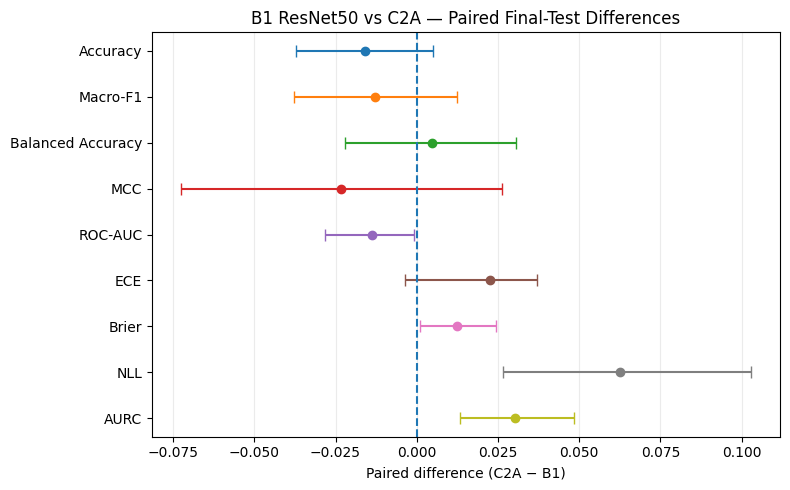



THYTRUST-MD — E2 FINAL PAIRED DECISION
Paired images              : 998

CLASSIFICATION
B1 Macro-F1                : 0.863981
C2A Macro-F1               : 0.851204
Δ Macro-F1                 : -0.012777
95% CI                     : [-0.037844, +0.012406]

B1 MCC                     : 0.728402
C2A MCC                    : 0.704967
Δ MCC                      : -0.023435
95% CI                     : [-0.072681, +0.026204]

Δ Balanced Accuracy        : +0.004700
95% CI                     : [-0.021976, +0.030420]

B1 ROC-AUC                 : 0.944530
C2A ROC-AUC                : 0.930633
Δ ROC-AUC                  : -0.013897
95% CI                     : [-0.028134, -0.000858]

McNEMAR
B1 correct / C2A wrong    : 67
B1 wrong / C2A correct    : 51
Exact p-value              : 0.16705111

CALIBRATION / SELECTIVE RANKING
ECE          B1=0.014188 | C2A=0.036781 | Δ=+0.022592 | CI=[-0.003524, +0.037069]
Brier        B1=0.081831 | C2A=0.094089 | Δ=+0.012258 | CI=[+0.000861, +0.024257]
NLL    

In [ ]:
# ======================================================================================
# THYTRUST-MD — E2
# PAIRED FINAL TEST STATISTICAL AUDIT
#
# COMPARES ON EXACTLY THE SAME 998 TEST IMAGES:
#   B1  = Full-image ResNet50 seed 42
#   C2A = ResNet50 + auxiliary bbox supervision seed 42
#
# ANALYSES:
#   1. Exact image / label pairing audit
#   2. Paired bootstrap:
#        - Accuracy
#        - Macro-F1
#        - Balanced Accuracy
#        - MCC
#        - ROC-AUC
#        - ECE
#        - Brier
#        - NLL
#        - AURC
#   3. Exact McNemar test
#   4. B1-correct/C2A-wrong vs B1-wrong/C2A-correct
#   5. Calibration comparison
#   6. Selective-ranking/AURC comparison
#   7. Forest plot of paired differences
#
# IMPORTANT:
#   ✓ NO MODEL LOADING
#   ✓ NO GPU
#   ✓ NO NEW TEST INFERENCE
#   ✓ NO TEST TUNING
#   ✓ Uses SAVED predictions only
#
# SIGN CONVENTION:
#   Delta = C2A - B1
#
# For higher-is-better metrics:
#   positive delta favors C2A
#
# For lower-is-better metrics:
#   negative delta favors C2A
# ======================================================================================

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from scipy.stats import binomtest

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    log_loss,
)


# ======================================================================================
# 0. CONFIG / PATHS
# ======================================================================================

ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

B1_ROOT = (
    ROOT
    / "baselines"
    / "B1_ResNet50_seed42"
)

C2A_FILE = (
    ROOT
    / "E1_Final_Frozen_Internal_Test"
    / "csv_outputs"
    / "E1_final_test_per_image_predictions.csv"
)

E2_ROOT = (
    ROOT
    / "E2_B1_vs_C2A_Paired_Final_Test"
)

CSV_DIR = E2_ROOT / "csv_outputs"
FIG_DIR = E2_ROOT / "figures"
CONFIG_DIR = E2_ROOT / "config"

for folder in [
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


N_BOOT = 3000
BOOT_SEED = 2026


assert B1_ROOT.exists(), (
    f"Missing B1 folder:\n{B1_ROOT}"
)

assert C2A_FILE.exists(), (
    f"Missing final C2A predictions:\n{C2A_FILE}"
)


print("=" * 120)
print("THYTRUST-MD — E2 PAIRED FINAL TEST STATISTICAL AUDIT")
print("=" * 120)

print("B1 root :", B1_ROOT)
print("C2A file:", C2A_FILE)

print("\n✓ NO GPU")
print("✓ NO NEW TEST INFERENCE")
print("✓ SAVED PREDICTIONS ONLY")


# ======================================================================================
# 1. HELPERS — FLEXIBLE COLUMN DISCOVERY
# ======================================================================================

def first_existing_column(
    dataframe,
    candidates
):

    for candidate in candidates:

        if candidate in dataframe.columns:

            return candidate

    return None


def normalize_id(
    value
):

    value = str(
        value
    ).strip()

    # Common pandas numeric ID issue:
    # "1740.0" -> "1740"
    try:

        numeric = float(
            value
        )

        if numeric.is_integer():

            return str(
                int(
                    numeric
                )
            )

    except Exception:

        pass


    # If a path was accidentally used as ID,
    # use filename stem.
    if "/" in value or "\\" in value:

        return Path(
            value
        ).stem.lower()


    return value.lower()


ID_CANDIDATES = [
    "image_id",
    "image_id_norm",
    "id",
    "image",
    "filename",
    "file_name",
]

LABEL_CANDIDATES = [
    "true_label",
    "label",
    "target",
    "y_true",
    "ground_truth",
]

PRED_CANDIDATES = [
    "predicted_label",
    "prediction",
    "pred",
    "y_pred",
    "pred_label",
]

TS_MALIGNANT_CANDIDATES = [
    "ts_prob_malignant",
    "temperature_scaled_prob_malignant",
    "calibrated_prob_malignant",
    "calibrated_probability",
    "ts_probability",
]

RAW_MALIGNANT_CANDIDATES = [
    "raw_prob_malignant",
    "prob_malignant",
    "malignant_probability",
    "probability_malignant",
    "probability",
    "prob",
    "score",
]

BENIGN_PROB_CANDIDATES = [
    "raw_prob_benign",
    "prob_benign",
    "benign_probability",
]

LOGIT_BENIGN_CANDIDATES = [
    "logit_benign",
    "benign_logit",
    "logit_0",
]

LOGIT_MALIGNANT_CANDIDATES = [
    "logit_malignant",
    "malignant_logit",
    "logit_1",
]


# ======================================================================================
# 2. AUTOMATICALLY FIND B1 FINAL TEST PREDICTION CSV
#
# We deliberately do not hard-code the exact filename because earlier baseline
# export names may differ.
# ======================================================================================

def score_prediction_csv(
    path
):

    try:

        df = pd.read_csv(
            path
        )

    except Exception:

        return None


    # Must look like per-image data.
    if len(df) < 900:

        return None


    id_col = first_existing_column(
        df,
        ID_CANDIDATES
    )

    label_col = first_existing_column(
        df,
        LABEL_CANDIDATES
    )

    pred_col = first_existing_column(
        df,
        PRED_CANDIDATES
    )


    probability_available = any(

        column in df.columns

        for column in (
            TS_MALIGNANT_CANDIDATES
            +
            RAW_MALIGNANT_CANDIDATES
            +
            LOGIT_MALIGNANT_CANDIDATES
        )
    )


    if id_col is None or label_col is None:

        return None


    if pred_col is None and not probability_available:

        return None


    name = path.name.lower()

    score = 0


    if "test" in name:
        score += 5

    if "prediction" in name:
        score += 5

    if "pred" in name:
        score += 3

    if len(df) == 998:
        score += 10

    if pred_col is not None:
        score += 2

    if probability_available:
        score += 2


    return {

        "path":
            path,

        "score":
            score,

        "rows":
            len(df),

        "id_col":
            id_col,

        "label_col":
            label_col,

        "pred_col":
            pred_col
    }


candidate_info = []


for path in B1_ROOT.rglob(
    "*.csv"
):

    result = score_prediction_csv(
        path
    )

    if result is not None:

        candidate_info.append(
            result
        )


if len(
    candidate_info
) == 0:

    print("\nCSV files found under B1:")

    for path in B1_ROOT.rglob(
        "*.csv"
    ):

        print(
            path
        )

    raise RuntimeError(
        "Could not automatically locate B1 per-image TEST predictions."
    )


candidate_info = sorted(

    candidate_info,

    key=lambda x: x[
        "score"
    ],

    reverse=True
)


print("\nB1 prediction candidates:")

for item in candidate_info[
    :10
]:

    print(
        f"score={item['score']:2d} "
        f"rows={item['rows']:4d} "
        f"| {item['path']}"
    )


B1_FILE = candidate_info[
    0
][
    "path"
]


print("\nSELECTED B1 FILE:")
print(B1_FILE)


# ======================================================================================
# 3. LOAD B1 / C2A
# ======================================================================================

b1_raw_df = pd.read_csv(
    B1_FILE
)

c2a_raw_df = pd.read_csv(
    C2A_FILE
)


# ======================================================================================
# 4. FIND B1 TEMPERATURE, IF NEEDED
#
# If B1 CSV already contains temperature-scaled probabilities, those are used.
# Otherwise, if a saved B1 temperature JSON exists, we apply that frozen T.
#
# Classification / ROC-AUC do not depend on temperature scaling.
# Calibration metrics do.
# ======================================================================================

def recursively_find_temperature(
    root
):

    results = []


    for path in root.rglob(
        "*.json"
    ):

        try:

            with open(
                path,
                "r"
            ) as f:

                record = json.load(
                    f
                )

        except Exception:

            continue


        if not isinstance(
            record,
            dict
        ):

            continue


        possible_keys = [
            "temperature",
            "Temperature",
            "T",
        ]


        for key in possible_keys:

            if key in record:

                try:

                    temperature = float(
                        record[
                            key
                        ]
                    )

                    if (
                        np.isfinite(
                            temperature
                        )
                        and
                        temperature > 0
                    ):

                        results.append(
                            (
                                path,
                                temperature
                            )
                        )

                except Exception:

                    pass


    # Prefer files with temperature/calibration in filename.
    results = sorted(

        results,

        key=lambda x: (
            "temperature" in x[
                0
            ].name.lower()
            or
            "calibr" in x[
                0
            ].name.lower()
        ),

        reverse=True
    )


    return results


b1_temperature_candidates = (
    recursively_find_temperature(
        B1_ROOT
    )
)


B1_TEMPERATURE = None


if b1_temperature_candidates:

    B1_TEMPERATURE = float(
        b1_temperature_candidates[
            0
        ][
            1
        ]
    )


    print(
        "\nB1 frozen temperature found:"
    )

    print(
        b1_temperature_candidates[
            0
        ][
            0
        ]
    )

    print(
        f"T = {B1_TEMPERATURE:.6f}"
    )


# ======================================================================================
# 5. EXTRACT B1 DATA
# ======================================================================================

b1_id_col = first_existing_column(
    b1_raw_df,
    ID_CANDIDATES
)

b1_label_col = first_existing_column(
    b1_raw_df,
    LABEL_CANDIDATES
)

b1_pred_col = first_existing_column(
    b1_raw_df,
    PRED_CANDIDATES
)


assert b1_id_col is not None
assert b1_label_col is not None


b1 = pd.DataFrame({

    "image_key":
        b1_raw_df[
            b1_id_col
        ].map(
            normalize_id
        ),

    "true_label":
        b1_raw_df[
            b1_label_col
        ].astype(
            int
        ),
})


# ----------------------------------------------------------------------
# B1 probability extraction
# ----------------------------------------------------------------------

b1_ts_prob_col = first_existing_column(
    b1_raw_df,
    TS_MALIGNANT_CANDIDATES
)

b1_raw_prob_col = first_existing_column(
    b1_raw_df,
    RAW_MALIGNANT_CANDIDATES
)

b1_benign_prob_col = first_existing_column(
    b1_raw_df,
    BENIGN_PROB_CANDIDATES
)

b1_logit_0_col = first_existing_column(
    b1_raw_df,
    LOGIT_BENIGN_CANDIDATES
)

b1_logit_1_col = first_existing_column(
    b1_raw_df,
    LOGIT_MALIGNANT_CANDIDATES
)


B1_PROBABILITY_SOURCE = None


if b1_ts_prob_col is not None:

    b1[
        "prob_malignant"
    ] = b1_raw_df[
        b1_ts_prob_col
    ].astype(
        float
    )


    B1_PROBABILITY_SOURCE = (
        f"saved calibrated probability: "
        f"{b1_ts_prob_col}"
    )


elif (
    b1_logit_0_col is not None
    and
    b1_logit_1_col is not None
):

    logits_0 = b1_raw_df[
        b1_logit_0_col
    ].to_numpy(
        dtype=float
    )


    logits_1 = b1_raw_df[
        b1_logit_1_col
    ].to_numpy(
        dtype=float
    )


    temperature_to_use = (
        B1_TEMPERATURE
        if B1_TEMPERATURE is not None
        else 1.0
    )


    difference = (
        logits_1
        -
        logits_0
    ) / temperature_to_use


    b1[
        "prob_malignant"
    ] = expit(
        difference
    )


    if B1_TEMPERATURE is not None:

        B1_PROBABILITY_SOURCE = (
            "reconstructed from logits using "
            f"frozen B1 T={B1_TEMPERATURE:.6f}"
        )

    else:

        B1_PROBABILITY_SOURCE = (
            "raw probability reconstructed from logits; "
            "NO B1 temperature file found"
        )


elif b1_raw_prob_col is not None:

    p = b1_raw_df[
        b1_raw_prob_col
    ].to_numpy(
        dtype=float
    )


    if B1_TEMPERATURE is not None:

        # Binary temperature scaling:
        #
        # p_T = sigmoid(logit(p) / T)
        #
        clipped = np.clip(
            p,
            1e-10,
            1.0 - 1e-10
        )


        log_odds = np.log(
            clipped
            /
            (
                1.0
                -
                clipped
            )
        )


        p = expit(
            log_odds
            /
            B1_TEMPERATURE
        )


        B1_PROBABILITY_SOURCE = (
            f"{b1_raw_prob_col} + frozen "
            f"T={B1_TEMPERATURE:.6f}"
        )


    else:

        B1_PROBABILITY_SOURCE = (
            f"raw probability: {b1_raw_prob_col}; "
            f"NO B1 temperature found"
        )


    b1[
        "prob_malignant"
    ] = p


else:

    b1[
        "prob_malignant"
    ] = np.nan

    B1_PROBABILITY_SOURCE = (
        "UNAVAILABLE"
    )


# ----------------------------------------------------------------------
# B1 hard predictions
# ----------------------------------------------------------------------

if b1_pred_col is not None:

    b1[
        "prediction"
    ] = b1_raw_df[
        b1_pred_col
    ].astype(
        int
    )

else:

    if b1[
        "prob_malignant"
    ].isna().all():

        raise RuntimeError(
            "Could not reconstruct B1 predictions."
        )


    b1[
        "prediction"
    ] = (
        b1[
            "prob_malignant"
        ]
        >=
        0.5
    ).astype(
        int
    )


# ======================================================================================
# 6. EXTRACT C2A FINAL DATA
# ======================================================================================

c2a_id_col = first_existing_column(
    c2a_raw_df,
    ID_CANDIDATES
)

c2a_label_col = first_existing_column(
    c2a_raw_df,
    LABEL_CANDIDATES
)


assert c2a_id_col is not None
assert c2a_label_col is not None


if "ts_prob_malignant" not in c2a_raw_df.columns:

    raise RuntimeError(
        "C2A final E1 CSV is missing ts_prob_malignant."
    )


if "predicted_label" not in c2a_raw_df.columns:

    raise RuntimeError(
        "C2A final E1 CSV is missing predicted_label."
    )


c2a = pd.DataFrame({

    "image_key":
        c2a_raw_df[
            c2a_id_col
        ].map(
            normalize_id
        ),

    "true_label_c2a":
        c2a_raw_df[
            c2a_label_col
        ].astype(
            int
        ),

    "prediction_c2a":
        c2a_raw_df[
            "predicted_label"
        ].astype(
            int
        ),

    "prob_malignant_c2a":
        c2a_raw_df[
            "ts_prob_malignant"
        ].astype(
            float
        ),
})


# ======================================================================================
# 7. EXACT PAIRING
# ======================================================================================

paired = b1.merge(

    c2a,

    on="image_key",

    how="inner",

    validate="one_to_one"
)


print("\n")
print("=" * 120)
print("PAIRING AUDIT")
print("=" * 120)

print(
    "B1 rows:",
    len(
        b1
    )
)

print(
    "C2A rows:",
    len(
        c2a
    )
)

print(
    "Matched rows:",
    len(
        paired
    )
)


if len(
    paired
) != 998:

    raise RuntimeError(
        f"Expected 998 paired test images, "
        f"found {len(paired)}."
    )


if not np.array_equal(

    paired[
        "true_label"
    ].to_numpy(),

    paired[
        "true_label_c2a"
    ].to_numpy()
):

    raise RuntimeError(
        "B1 and C2A labels do NOT match."
    )


print(
    "✓ Identical image membership"
)

print(
    "✓ Identical labels"
)

print(
    f"B1 probability source: "
    f"{B1_PROBABILITY_SOURCE}"
)

print(
    "✓ NO new inference performed"
)


# ======================================================================================
# 8. NUMPY ARRAYS
# ======================================================================================

y = paired[
    "true_label"
].to_numpy(
    dtype=int
)


pred_b1 = paired[
    "prediction"
].to_numpy(
    dtype=int
)


pred_c2a = paired[
    "prediction_c2a"
].to_numpy(
    dtype=int
)


p_b1 = paired[
    "prob_malignant"
].to_numpy(
    dtype=float
)


p_c2a = paired[
    "prob_malignant_c2a"
].to_numpy(
    dtype=float
)


B1_PROB_AVAILABLE = bool(
    np.isfinite(
        p_b1
    ).all()
)


# ======================================================================================
# 9. METRIC HELPERS
# ======================================================================================

def ece_score(
    y_true,
    probability,
    n_bins=15
):

    probability = np.asarray(
        probability,
        dtype=float
    )


    pred = (
        probability
        >=
        0.5
    ).astype(
        int
    )


    confidence = np.maximum(
        probability,
        1.0 - probability
    )


    correct = (
        pred
        ==
        y_true
    ).astype(
        float
    )


    edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )


    ece = 0.0


    for index in range(
        n_bins
    ):

        lower = edges[
            index
        ]

        upper = edges[
            index + 1
        ]


        if index == 0:

            mask = (
                (confidence >= lower)
                &
                (confidence <= upper)
            )

        else:

            mask = (
                (confidence > lower)
                &
                (confidence <= upper)
            )


        if not mask.any():

            continue


        ece += (

            mask.mean()

            *

            abs(
                correct[
                    mask
                ].mean()
                -
                confidence[
                    mask
                ].mean()
            )
        )


    return float(
        ece
    )


def brier_score_binary(
    y_true,
    probability
):

    return float(
        np.mean(
            (
                probability
                -
                y_true
            ) ** 2
        )
    )


def nll_binary(
    y_true,
    probability
):

    probability = np.clip(
        probability,
        1e-10,
        1.0 - 1e-10
    )


    probs_2class = np.column_stack(
        [
            1.0 - probability,
            probability
        ]
    )


    return float(
        log_loss(
            y_true,
            probs_2class,
            labels=[
                0,
                1
            ]
        )
    )


def aurc_score(
    y_true,
    prediction,
    probability
):

    confidence = np.maximum(
        probability,
        1.0 - probability
    )


    errors = (
        prediction
        !=
        y_true
    ).astype(
        float
    )


    order = np.argsort(
        -confidence,
        kind="mergesort"
    )


    sorted_errors = errors[
        order
    ]


    retained = np.arange(
        1,
        len(
            y_true
        )
        +
        1
    )


    coverage = (
        retained
        /
        len(
            y_true
        )
    )


    risk = (
        np.cumsum(
            sorted_errors
        )
        /
        retained
    )


    if hasattr(
        np,
        "trapezoid"
    ):

        return float(

            np.trapezoid(

                np.r_[
                    0.0,
                    risk
                ],

                np.r_[
                    0.0,
                    coverage
                ]
            )
        )


    return float(

        np.trapz(

            np.r_[
                0.0,
                risk
            ],

            np.r_[
                0.0,
                coverage
            ]
        )
    )


def hard_metrics(
    y_true,
    prediction
):

    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    prediction
                )
            ),

        "Macro-F1":
            float(
                f1_score(
                    y_true,
                    prediction,
                    average="macro",
                    zero_division=0
                )
            ),

        "Balanced Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    prediction
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    y_true,
                    prediction
                )
            )
    }


# ======================================================================================
# 10. POINT ESTIMATES
# ======================================================================================

b1_metrics = hard_metrics(
    y,
    pred_b1
)

c2a_metrics = hard_metrics(
    y,
    pred_c2a
)


if B1_PROB_AVAILABLE:

    b1_metrics.update({

        "ROC-AUC":
            float(
                roc_auc_score(
                    y,
                    p_b1
                )
            ),

        "ECE":
            ece_score(
                y,
                p_b1
            ),

        "Brier":
            brier_score_binary(
                y,
                p_b1
            ),

        "NLL":
            nll_binary(
                y,
                p_b1
            ),

        "AURC":
            aurc_score(
                y,
                pred_b1,
                p_b1
            )
    })


    c2a_metrics.update({

        "ROC-AUC":
            float(
                roc_auc_score(
                    y,
                    p_c2a
                )
            ),

        "ECE":
            ece_score(
                y,
                p_c2a
            ),

        "Brier":
            brier_score_binary(
                y,
                p_c2a
            ),

        "NLL":
            nll_binary(
                y,
                p_c2a
            ),

        "AURC":
            aurc_score(
                y,
                pred_c2a,
                p_c2a
            )
    })


# ======================================================================================
# 11. POINT COMPARISON TABLE
# ======================================================================================

HIGHER_BETTER = {
    "Accuracy",
    "Macro-F1",
    "Balanced Accuracy",
    "MCC",
    "ROC-AUC",
}

LOWER_BETTER = {
    "ECE",
    "Brier",
    "NLL",
    "AURC",
}


point_rows = []


for metric in b1_metrics:

    delta = (
        c2a_metrics[
            metric
        ]
        -
        b1_metrics[
            metric
        ]
    )


    if metric in HIGHER_BETTER:

        favored = (
            "C2A"
            if delta > 0
            else
            "B1"
            if delta < 0
            else
            "Tie"
        )

    else:

        favored = (
            "C2A"
            if delta < 0
            else
            "B1"
            if delta > 0
            else
            "Tie"
        )


    point_rows.append({

        "Metric":
            metric,

        "B1":
            b1_metrics[
                metric
            ],

        "C2A":
            c2a_metrics[
                metric
            ],

        "Delta_C2A_minus_B1":
            delta,

        "Point_Favors":
            favored
    })


point_df = pd.DataFrame(
    point_rows
)


print("\n")
print("=" * 120)
print("POINT ESTIMATES — B1 vs C2A")
print("=" * 120)

display(
    point_df.round(
        6
    )
)


# ======================================================================================
# 12. McNEMAR EXACT TEST
# ======================================================================================

b1_correct = (
    pred_b1
    ==
    y
)

c2a_correct = (
    pred_c2a
    ==
    y
)


# B1 correct but C2A wrong.
b1_win = int(

    (
        b1_correct
        &
        ~c2a_correct
    ).sum()
)


# C2A correct but B1 wrong.
c2a_win = int(

    (
        ~b1_correct
        &
        c2a_correct
    ).sum()
)


discordant = (
    b1_win
    +
    c2a_win
)


if discordant > 0:

    mcnemar_result = binomtest(

        min(
            b1_win,
            c2a_win
        ),

        n=discordant,

        p=0.5,

        alternative="two-sided"
    )


    mcnemar_p = float(
        mcnemar_result.pvalue
    )

else:

    mcnemar_p = 1.0


print("\n")
print("=" * 120)
print("McNEMAR EXACT TEST")
print("=" * 120)

print(
    f"B1 correct / C2A wrong : "
    f"{b1_win}"
)

print(
    f"B1 wrong / C2A correct : "
    f"{c2a_win}"
)

print(
    f"Discordant cases       : "
    f"{discordant}"
)

print(
    f"Exact p-value          : "
    f"{mcnemar_p:.8f}"
)


# ======================================================================================
# 13. PAIRED BOOTSTRAP
# ======================================================================================

BOOT_METRICS = [
    "Accuracy",
    "Macro-F1",
    "Balanced Accuracy",
    "MCC",
]


if B1_PROB_AVAILABLE:

    BOOT_METRICS += [
        "ROC-AUC",
        "ECE",
        "Brier",
        "NLL",
        "AURC",
    ]


def metric_value(
    metric,
    y_true,
    prediction,
    probability
):

    if metric == "Accuracy":

        return accuracy_score(
            y_true,
            prediction
        )


    if metric == "Macro-F1":

        return f1_score(
            y_true,
            prediction,
            average="macro",
            zero_division=0
        )


    if metric == "Balanced Accuracy":

        return balanced_accuracy_score(
            y_true,
            prediction
        )


    if metric == "MCC":

        return matthews_corrcoef(
            y_true,
            prediction
        )


    if metric == "ROC-AUC":

        return roc_auc_score(
            y_true,
            probability
        )


    if metric == "ECE":

        return ece_score(
            y_true,
            probability
        )


    if metric == "Brier":

        return brier_score_binary(
            y_true,
            probability
        )


    if metric == "NLL":

        return nll_binary(
            y_true,
            probability
        )


    if metric == "AURC":

        return aurc_score(
            y_true,
            prediction,
            probability
        )


    raise ValueError(
        metric
    )


rng = np.random.default_rng(
    BOOT_SEED
)


bootstrap_deltas = {

    metric:
        []

    for metric in BOOT_METRICS
}


n = len(
    y
)


print("\n")
print("=" * 120)
print(
    f"PAIRED BOOTSTRAP — "
    f"{N_BOOT} RESAMPLES"
)
print("=" * 120)


for bootstrap_index in range(
    N_BOOT
):

    idx = rng.integers(
        0,
        n,
        size=n
    )


    y_b = y[
        idx
    ]


    # AUC requires both classes.
    if len(
        np.unique(
            y_b
        )
    ) < 2:

        continue


    pred_b1_b = pred_b1[
        idx
    ]

    pred_c2a_b = pred_c2a[
        idx
    ]


    if B1_PROB_AVAILABLE:

        p_b1_b = p_b1[
            idx
        ]

        p_c2a_b = p_c2a[
            idx
        ]

    else:

        p_b1_b = None
        p_c2a_b = None


    for metric in BOOT_METRICS:

        b1_value = metric_value(

            metric,

            y_b,

            pred_b1_b,

            p_b1_b
        )


        c2a_value = metric_value(

            metric,

            y_b,

            pred_c2a_b,

            p_c2a_b
        )


        bootstrap_deltas[
            metric
        ].append(

            c2a_value
            -
            b1_value
        )


    if (
        (bootstrap_index + 1) % 500
        ==
        0
    ):

        print(
            f"Completed "
            f"{bootstrap_index + 1}/"
            f"{N_BOOT}"
        )


# ======================================================================================
# 14. BOOTSTRAP SUMMARY
# ======================================================================================

bootstrap_rows = []


for metric in BOOT_METRICS:

    deltas = np.asarray(
        bootstrap_deltas[
            metric
        ],
        dtype=float
    )


    point_delta = (
        c2a_metrics[
            metric
        ]
        -
        b1_metrics[
            metric
        ]
    )


    ci_low = float(
        np.percentile(
            deltas,
            2.5
        )
    )


    ci_high = float(
        np.percentile(
            deltas,
            97.5
        )
    )


    p_delta_gt_zero = float(
        np.mean(
            deltas > 0
        )
    )


    if metric in HIGHER_BETTER:

        if ci_low > 0:

            statistical_direction = (
                "C2A significantly better"
            )

        elif ci_high < 0:

            statistical_direction = (
                "B1 significantly better"
            )

        else:

            statistical_direction = (
                "No supported difference"
            )


    else:

        # Lower is better.
        if ci_high < 0:

            statistical_direction = (
                "C2A significantly better"
            )

        elif ci_low > 0:

            statistical_direction = (
                "B1 significantly better"
            )

        else:

            statistical_direction = (
                "No supported difference"
            )


    bootstrap_rows.append({

        "Metric":
            metric,

        "B1":
            b1_metrics[
                metric
            ],

        "C2A":
            c2a_metrics[
                metric
            ],

        "Point_Delta_C2A_minus_B1":
            point_delta,

        "Bootstrap_Mean_Delta":
            float(
                deltas.mean()
            ),

        "CI95_Low":
            ci_low,

        "CI95_High":
            ci_high,

        "P_Delta_GT_0":
            p_delta_gt_zero,

        "Statistical_Direction":
            statistical_direction
    })


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


print("\n")
print("=" * 120)
print("PAIRED BOOTSTRAP RESULTS")
print("=" * 120)

display(
    bootstrap_df.round(
        6
    )
)


# ======================================================================================
# 15. SAVE PAIRED PER-IMAGE CORRECTNESS
# ======================================================================================

paired_export = paired.copy()


paired_export[
    "b1_correct"
] = b1_correct.astype(
    int
)


paired_export[
    "c2a_correct"
] = c2a_correct.astype(
    int
)


paired_export[
    "winner"
] = np.where(

    b1_correct
    &
    ~c2a_correct,

    "B1_only_correct",

    np.where(

        ~b1_correct
        &
        c2a_correct,

        "C2A_only_correct",

        np.where(

            b1_correct
            &
            c2a_correct,

            "Both_correct",

            "Both_wrong"
        )
    )
)


paired_export.to_csv(

    CSV_DIR
    / "E2_paired_test_predictions.csv",

    index=False
)


point_df.to_csv(

    CSV_DIR
    / "E2_point_estimates.csv",

    index=False
)


bootstrap_df.to_csv(

    CSV_DIR
    / "E2_paired_bootstrap.csv",

    index=False
)


# ======================================================================================
# 16. FOREST PLOT OF PAIRED DELTAS
# ======================================================================================

plot_df = bootstrap_df.copy()


# Main paper/statistical metrics first.
metric_order = [
    "Accuracy",
    "Macro-F1",
    "Balanced Accuracy",
    "MCC",
    "ROC-AUC",
    "ECE",
    "Brier",
    "NLL",
    "AURC",
]


plot_df[
    "order"
] = plot_df[
    "Metric"
].map({

    metric:
        index

    for index, metric
    in enumerate(
        metric_order
    )
})


plot_df = (
    plot_df
    .sort_values(
        "order"
    )
    .reset_index(
        drop=True
    )
)


y_positions = np.arange(
    len(
        plot_df
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        max(
            5,
            0.55
            *
            len(
                plot_df
            )
        )
    )
)


for position, row in plot_df.iterrows():

    point = row[
        "Point_Delta_C2A_minus_B1"
    ]


    lower_error = (
        point
        -
        row[
            "CI95_Low"
        ]
    )


    upper_error = (
        row[
            "CI95_High"
        ]
        -
        point
    )


    ax.errorbar(

        point,

        position,

        xerr=np.array(
            [
                [
                    lower_error
                ],
                [
                    upper_error
                ]
            ]
        ),

        fmt="o",

        capsize=4
    )


ax.axvline(
    0,
    linestyle="--"
)


ax.set_yticks(
    y_positions
)


ax.set_yticklabels(
    plot_df[
        "Metric"
    ]
)


ax.invert_yaxis()


ax.set_xlabel(
    "Paired difference (C2A − B1)"
)


ax.set_title(
    "B1 ResNet50 vs C2A — Paired Final-Test Differences"
)


ax.grid(
    axis="x",
    alpha=0.25
)


fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E2_paired_difference_forest.png",

    dpi=400,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "E2_paired_difference_forest.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 17. FINAL DECISION LOGIC
# ======================================================================================

def get_row(
    metric
):

    return bootstrap_df[
        bootstrap_df[
            "Metric"
        ]
        ==
        metric
    ].iloc[
        0
    ]


macro_row = get_row(
    "Macro-F1"
)

mcc_row = get_row(
    "MCC"
)

bal_row = get_row(
    "Balanced Accuracy"
)


if "ROC-AUC" in bootstrap_df[
    "Metric"
].values:

    auc_row = get_row(
        "ROC-AUC"
    )

else:

    auc_row = None


core_rows = [
    macro_row,
    mcc_row,
    bal_row,
]


if auc_row is not None:

    core_rows.append(
        auc_row
    )


b1_supported_count = sum(

    row[
        "CI95_High"
    ]
    <
    0

    for row in core_rows
)


c2a_supported_count = sum(

    row[
        "CI95_Low"
    ]
    >
    0

    for row in core_rows
)


if (
    macro_row[
        "CI95_High"
    ]
    <
    0
    and
    b1_supported_count
    >=
    2
):

    decision = (
        "STATISTICALLY SUPPORTED B1 ADVANTAGE — "
        "C2A does not improve final-test diagnostic classification. "
        "Do not claim predictive superiority from auxiliary bbox supervision."
    )


elif (
    macro_row[
        "CI95_Low"
    ]
    >
    0
    and
    c2a_supported_count
    >=
    2
):

    decision = (
        "STATISTICALLY SUPPORTED C2A ADVANTAGE — "
        "auxiliary bbox supervision improves final-test diagnostic performance."
    )


else:

    decision = (
        "NO STATISTICALLY SUPPORTED CLASSIFICATION ADVANTAGE — "
        "B1 and C2A remain statistically compatible on the final test set. "
        "Present C2A primarily through lesion-supervision and trustworthiness analyses, "
        "not as a superior classifier."
    )


# ======================================================================================
# 18. SAVE DECISION
# ======================================================================================

decision_record = {

    "project":
        "ThyTrust-MD",

    "phase":
        "E2_B1_vs_C2A_Paired_Final_Test",

    "paired_test_n":
        int(
            len(
                paired
            )
        ),

    "b1_prediction_file":
        str(
            B1_FILE
        ),

    "c2a_prediction_file":
        str(
            C2A_FILE
        ),

    "b1_probability_source":
        B1_PROBABILITY_SOURCE,

    "mcnemar": {

        "B1_correct_C2A_wrong":
            b1_win,

        "B1_wrong_C2A_correct":
            c2a_win,

        "discordant":
            discordant,

        "exact_p_value":
            mcnemar_p
    },

    "core_supported_B1_metrics":
        int(
            b1_supported_count
        ),

    "core_supported_C2A_metrics":
        int(
            c2a_supported_count
        ),

    "decision":
        decision,

    "new_inference":
        False,

    "test_tuning":
        False
}


with open(

    CONFIG_DIR
    / "E2_FINAL_DECISION.json",

    "w"

) as f:

    json.dump(
        decision_record,
        f,
        indent=2
    )


# ======================================================================================
# 19. FINAL OUTPUT
# ======================================================================================

print("\n")
print("=" * 120)
print("THYTRUST-MD — E2 FINAL PAIRED DECISION")
print("=" * 120)

print(
    f"Paired images              : "
    f"{len(paired)}"
)


print("\nCLASSIFICATION")

print(
    f"B1 Macro-F1                : "
    f"{macro_row['B1']:.6f}"
)

print(
    f"C2A Macro-F1               : "
    f"{macro_row['C2A']:.6f}"
)

print(
    f"Δ Macro-F1                 : "
    f"{macro_row['Point_Delta_C2A_minus_B1']:+.6f}"
)

print(
    f"95% CI                     : "
    f"[{macro_row['CI95_Low']:+.6f}, "
    f"{macro_row['CI95_High']:+.6f}]"
)


print()

print(
    f"B1 MCC                     : "
    f"{mcc_row['B1']:.6f}"
)

print(
    f"C2A MCC                    : "
    f"{mcc_row['C2A']:.6f}"
)

print(
    f"Δ MCC                      : "
    f"{mcc_row['Point_Delta_C2A_minus_B1']:+.6f}"
)

print(
    f"95% CI                     : "
    f"[{mcc_row['CI95_Low']:+.6f}, "
    f"{mcc_row['CI95_High']:+.6f}]"
)


print()

print(
    f"Δ Balanced Accuracy        : "
    f"{bal_row['Point_Delta_C2A_minus_B1']:+.6f}"
)

print(
    f"95% CI                     : "
    f"[{bal_row['CI95_Low']:+.6f}, "
    f"{bal_row['CI95_High']:+.6f}]"
)


if auc_row is not None:

    print()

    print(
        f"B1 ROC-AUC                 : "
        f"{auc_row['B1']:.6f}"
    )

    print(
        f"C2A ROC-AUC                : "
        f"{auc_row['C2A']:.6f}"
    )

    print(
        f"Δ ROC-AUC                  : "
        f"{auc_row['Point_Delta_C2A_minus_B1']:+.6f}"
    )

    print(
        f"95% CI                     : "
        f"[{auc_row['CI95_Low']:+.6f}, "
        f"{auc_row['CI95_High']:+.6f}]"
    )


print("\nMcNEMAR")

print(
    f"B1 correct / C2A wrong    : "
    f"{b1_win}"
)

print(
    f"B1 wrong / C2A correct    : "
    f"{c2a_win}"
)

print(
    f"Exact p-value              : "
    f"{mcnemar_p:.8f}"
)


if B1_PROB_AVAILABLE:

    print("\nCALIBRATION / SELECTIVE RANKING")


    for metric in [
        "ECE",
        "Brier",
        "NLL",
        "AURC"
    ]:

        row = get_row(
            metric
        )


        print(
            f"{metric:12s} "
            f"B1={row['B1']:.6f} | "
            f"C2A={row['C2A']:.6f} | "
            f"Δ={row['Point_Delta_C2A_minus_B1']:+.6f} | "
            f"CI=[{row['CI95_Low']:+.6f}, "
            f"{row['CI95_High']:+.6f}]"
        )


print("\nCORE STATISTICAL SUPPORT")

print(
    f"Metrics supporting B1     : "
    f"{b1_supported_count}/"
    f"{len(core_rows)}"
)

print(
    f"Metrics supporting C2A    : "
    f"{c2a_supported_count}/"
    f"{len(core_rows)}"
)


print("\nDECISION:")
print(
    decision
)


print("\nPROTOCOL")

print(
    "✓ New test inference: NO"
)

print(
    "✓ Test parameter tuning: NO"
)

print(
    "✓ Saved prediction analysis only: YES"
)


print(
    f"\nSaved to:\n{E2_ROOT}"
)

print("=" * 120)

THYTRUST-MD — E3 FINAL EXPLORATORY FAILURE-MODE AUDIT
✓ NO training
✓ NO GPU
✓ NO new inference
✓ NO model/threshold modification
✓ Post-hoc explanatory analysis only

MERGE AUDIT
--------------------------------------------------------------------------------
Matched cases: 998
✓ E2 predictions
✓ E1 localization
✓ Locked manifest


CORRECTNESS OVERLAP


,Outcome_Group,N
0,Both correct,822
1,B1 only correct,67
2,C2A only correct,51
3,Both wrong,58




DISCORDANT CASES BY TRUE CLASS


Outcome_Group,B1 only correct,C2A only correct
Benign,16,31
Malignant,51,20




CLASS / OPERATING-POINT DECOMPOSITION


...

,Outcome_Group,N,Mean_Loc_Soft_Dice,SD_Loc_Soft_Dice,Mean_Attention_In_BBox,SD_Attention_In_BBox,Mean_C2A_Confidence,Mean_C2A_Entropy
0,Both correct,822,0.567516,0.193936,0.826510,0.209784,0.906463,0.363070
1,B1 only correct,67,0.446666,0.199843,0.695684,0.252958,0.730975,0.740925
2,C2A only correct,51,0.467976,0.205955,0.751247,0.242214,0.776455,0.680357
3,Both wrong,58,0.485464,0.175162,0.719621,0.240246,0.774825,0.646810




EXPLORATORY LOCALIZATION–CORRECTNESS ASSOCIATION


,Metric,Correct_Mean,Wrong_Mean,Mean_Difference_Correct_minus_Wrong,Mann_Whitney_p
0,Localization Soft-Dice,0.561701,0.464669,0.097033,0.0
1,Attention Mass Inside BBox,0.822113,0.706791,0.115322,0.0




DISCORDANT CONFIDENCE PROFILE


,Outcome_Group,N,Mean_B1_Confidence,Mean_C2A_Confidence,Mean_C2A_Entropy,Mean_C2A_Attention_In_BBox
0,B1 only correct,67,0.752632,0.730975,0.740925,0.695684
1,C2A only correct,51,0.699503,0.776455,0.680357,0.751247
2,Both wrong,58,0.759231,0.774825,0.646810,0.719621


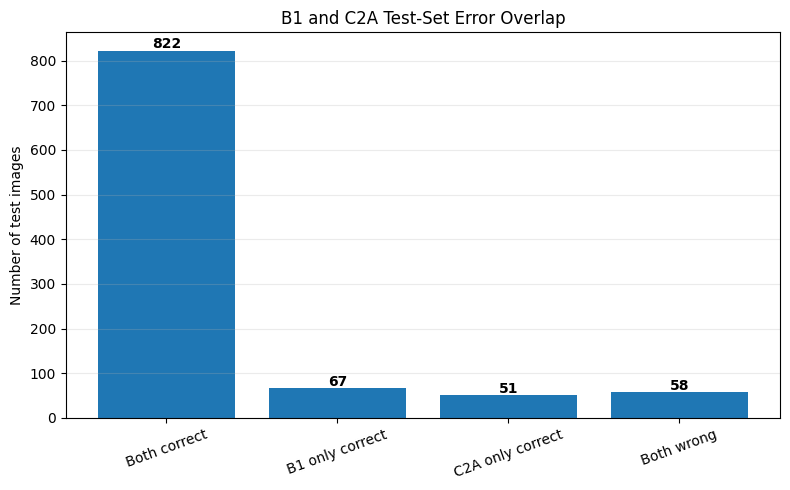

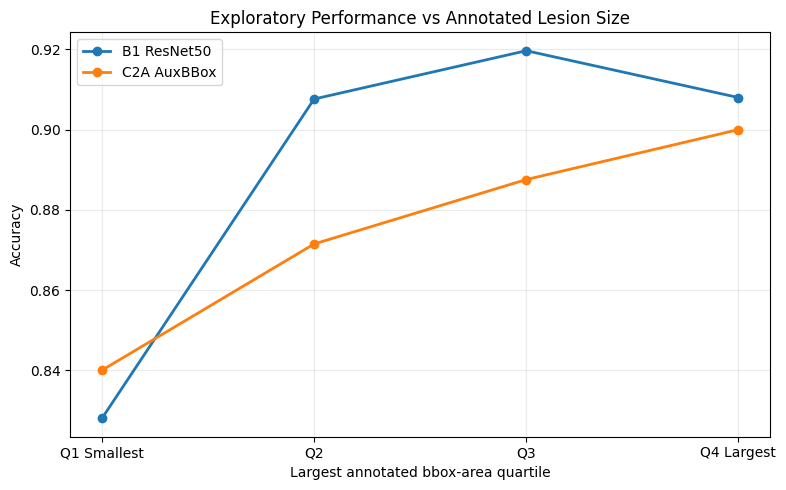

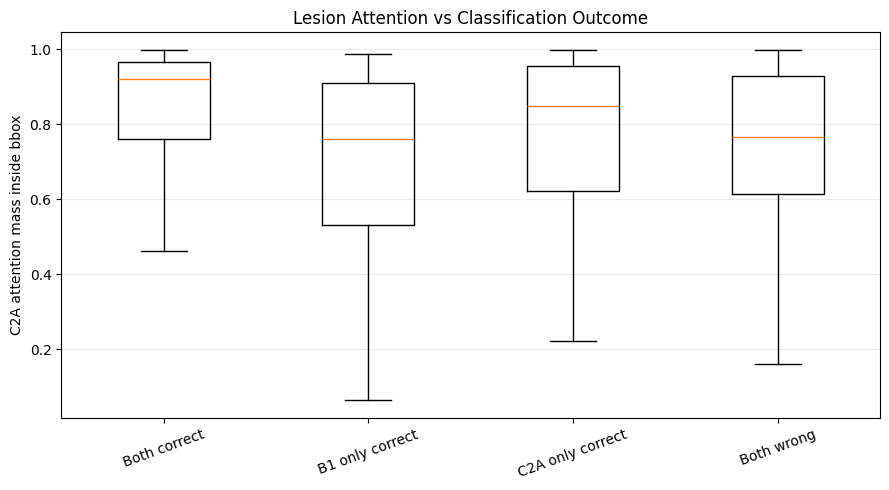



THYTRUST-MD — E3 FINAL FAILURE-MODE SUMMARY

ERROR COMPLEMENTARITY
B1 only correct             : 67
C2A only correct            : 51

OPERATING-POINT CHANGE
B1 sensitivity              : 0.932773
C2A sensitivity             : 0.889356
Δ sensitivity               : -0.043417

B1 specificity              : 0.785211
C2A specificity             : 0.838028
Δ specificity               : +0.052817

LOCALIZATION vs CORRECTNESS
Attention-in-bbox — correct : 0.822113
Attention-in-bbox — wrong   : 0.706791
Difference                  : +0.115322
Exploratory MW p-value      : 2.57865e-08

INTERPRETATION RULE
This E3 analysis explains frozen-test behavior only.
Do NOT modify the model, thresholds, temperature, or conformal parameters from these subgroup findings.

Saved to:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/E3_Final_Failure_Subgroup_Audit


In [ ]:
# ======================================================================================
# THYTRUST-MD — E3
# FINAL EXPLORATORY FAILURE-MODE / SUBGROUP AUDIT
#
# PURPOSE:
#   Understand WHY B1 and C2A differ on the frozen 998-image test set.
#
# ANALYSES:
#   1. B1/C2A correctness overlap
#   2. Discordant errors by benign/malignant class
#   3. Sensitivity / specificity comparison
#   4. C2A auxiliary localization vs correctness
#   5. C2A auxiliary localization in:
#          - both correct
#          - B1 only correct
#          - C2A only correct
#          - both wrong
#   6. Largest annotated bbox-area fraction
#   7. Performance by lesion-size quartile
#   8. Confidence behavior for discordant cases
#   9. Publication figures
#
# IMPORTANT:
#   ✓ POST-HOC EXPLORATORY ANALYSIS ONLY
#   ✓ NO MODEL TRAINING
#   ✓ NO NEW INFERENCE
#   ✓ NO GPU
#   ✓ NO PARAMETER / THRESHOLD CHANGES
#   ✓ MUST NOT be used to redesign the frozen model
# ======================================================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
)

from scipy.stats import mannwhitneyu


# ======================================================================================
# 0. PATHS
# ======================================================================================

ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

E2_FILE = (
    ROOT
    / "E2_B1_vs_C2A_Paired_Final_Test"
    / "csv_outputs"
    / "E2_paired_test_predictions.csv"
)

E1_FILE = (
    ROOT
    / "E1_Final_Frozen_Internal_Test"
    / "csv_outputs"
    / "E1_final_test_per_image_predictions.csv"
)

SPLIT_FILE = (
    ROOT
    / "dataset_audit"
    / "final_leakage_controlled_split"
    / "tn5000_leakage_controlled_split_seed42.csv"
)

E3_ROOT = (
    ROOT
    / "E3_Final_Failure_Subgroup_Audit"
)

CSV_DIR = E3_ROOT / "csv_outputs"
FIG_DIR = E3_ROOT / "figures"
CONFIG_DIR = E3_ROOT / "config"

for folder in [
    CSV_DIR,
    FIG_DIR,
    CONFIG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


for path in [
    E2_FILE,
    E1_FILE,
    SPLIT_FILE,
]:

    assert path.exists(), (
        f"Missing:\n{path}"
    )


print("=" * 120)
print("THYTRUST-MD — E3 FINAL EXPLORATORY FAILURE-MODE AUDIT")
print("=" * 120)

print("✓ NO training")
print("✓ NO GPU")
print("✓ NO new inference")
print("✓ NO model/threshold modification")
print("✓ Post-hoc explanatory analysis only")


# ======================================================================================
# 1. ID NORMALIZATION
# ======================================================================================

def normalize_id(
    value
):

    value = str(
        value
    ).strip()

    try:

        numeric = float(
            value
        )

        if numeric.is_integer():

            return str(
                int(
                    numeric
                )
            )

    except Exception:

        pass


    if "/" in value or "\\" in value:

        return Path(
            value
        ).stem.lower()


    return value.lower()


# ======================================================================================
# 2. LOAD E2 PAIRED DATA
# ======================================================================================

paired = pd.read_csv(
    E2_FILE
)


if "image_key" not in paired.columns:

    raise RuntimeError(
        "E2 paired file is missing image_key."
    )


paired[
    "image_key"
] = paired[
    "image_key"
].map(
    normalize_id
)


assert len(
    paired
) == 998


# ======================================================================================
# 3. LOAD E1 C2A LOCALIZATION / UNCERTAINTY OUTPUT
# ======================================================================================

e1 = pd.read_csv(
    E1_FILE
)


e1[
    "image_key"
] = e1[
    "image_id"
].map(
    normalize_id
)


required_e1 = [
    "image_key",
    "ts_confidence",
    "normalized_entropy",
    "localization_soft_dice",
    "attention_mass_inside_bbox",
]


missing = [
    column
    for column in required_e1
    if column not in e1.columns
]


if missing:

    raise RuntimeError(
        f"E1 missing columns: {missing}"
    )


e1_subset = e1[
    required_e1
].copy()


# ======================================================================================
# 4. LOAD TEST MANIFEST
# ======================================================================================

manifest = pd.read_csv(
    SPLIT_FILE
)


test_manifest = (
    manifest[
        manifest[
            "split"
        ]
        ==
        "test"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


assert len(
    test_manifest
) == 998


test_manifest[
    "image_key"
] = test_manifest[
    "image_id_norm"
].map(
    normalize_id
)


required_manifest = [
    "image_key",
    "image_path",
    "bboxes_json",
]


missing = [
    column
    for column in required_manifest
    if column not in test_manifest.columns
]


if missing:

    raise RuntimeError(
        f"Manifest missing columns: {missing}"
    )


# ======================================================================================
# 5. MERGE EVERYTHING
# ======================================================================================

data = paired.merge(

    e1_subset,

    on="image_key",

    how="inner",

    validate="one_to_one"
)


data = data.merge(

    test_manifest[
        required_manifest
    ],

    on="image_key",

    how="inner",

    validate="one_to_one"
)


assert len(
    data
) == 998


print("\nMERGE AUDIT")
print("-" * 80)

print(
    "Matched cases:",
    len(
        data
    )
)

print(
    "✓ E2 predictions"
)

print(
    "✓ E1 localization"
)

print(
    "✓ Locked manifest"
)


# ======================================================================================
# 6. STANDARDIZE COLUMN NAMES
# ======================================================================================

if "true_label" not in data.columns:

    raise RuntimeError(
        "true_label missing from E2 data."
    )


if "prediction" not in data.columns:

    raise RuntimeError(
        "B1 prediction column missing."
    )


if "prediction_c2a" not in data.columns:

    raise RuntimeError(
        "C2A prediction column missing."
    )


data[
    "b1_correct"
] = (
    data[
        "prediction"
    ]
    ==
    data[
        "true_label"
    ]
)


data[
    "c2a_correct"
] = (
    data[
        "prediction_c2a"
    ]
    ==
    data[
        "true_label"
    ]
)


# ======================================================================================
# 7. FOUR MUTUALLY EXCLUSIVE OUTCOME GROUPS
# ======================================================================================

def correctness_group(
    row
):

    if (
        row[
            "b1_correct"
        ]
        and
        row[
            "c2a_correct"
        ]
    ):

        return "Both correct"


    if (
        row[
            "b1_correct"
        ]
        and
        not row[
            "c2a_correct"
        ]
    ):

        return "B1 only correct"


    if (
        not row[
            "b1_correct"
        ]
        and
        row[
            "c2a_correct"
        ]
    ):

        return "C2A only correct"


    return "Both wrong"


data[
    "Outcome_Group"
] = data.apply(
    correctness_group,
    axis=1
)


outcome_order = [
    "Both correct",
    "B1 only correct",
    "C2A only correct",
    "Both wrong",
]


outcome_counts = (

    data[
        "Outcome_Group"
    ]
    .value_counts()
    .reindex(
        outcome_order
    )
    .fillna(
        0
    )
    .astype(
        int
    )
)


print("\n")
print("=" * 120)
print("CORRECTNESS OVERLAP")
print("=" * 120)

display(

    outcome_counts
    .rename(
        "N"
    )
    .reset_index()
    .rename(
        columns={
            "index":
                "Outcome"
        }
    )
)


# ======================================================================================
# 8. CLASS-SPECIFIC DISCORDANCE
# ======================================================================================

discordant = data[
    data[
        "Outcome_Group"
    ].isin(
        [
            "B1 only correct",
            "C2A only correct",
        ]
    )
].copy()


discordant_by_class = pd.crosstab(

    discordant[
        "true_label"
    ],

    discordant[
        "Outcome_Group"
    ]
)


discordant_by_class.index = [

    "Benign"
    if index == 0
    else
    "Malignant"

    for index in discordant_by_class.index
]


print("\n")
print("=" * 120)
print("DISCORDANT CASES BY TRUE CLASS")
print("=" * 120)

display(
    discordant_by_class
)


discordant_by_class.to_csv(

    CSV_DIR
    / "E3_discordant_cases_by_class.csv"
)


# ======================================================================================
# 9. SENSITIVITY / SPECIFICITY
# ======================================================================================

def diagnostic_metrics(
    labels,
    predictions
):

    tn, fp, fn, tp = confusion_matrix(

        labels,

        predictions,

        labels=[
            0,
            1
        ]

    ).ravel()


    return {

        "Accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "Sensitivity":
            tp
            /
            (
                tp
                +
                fn
            ),

        "Specificity":
            tn
            /
            (
                tn
                +
                fp
            ),

        "Macro_F1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),

        "MCC":
            matthews_corrcoef(
                labels,
                predictions
            ),

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp,
    }


b1_diag = diagnostic_metrics(

    data[
        "true_label"
    ],

    data[
        "prediction"
    ]
)


c2a_diag = diagnostic_metrics(

    data[
        "true_label"
    ],

    data[
        "prediction_c2a"
    ]
)


diagnostic_rows = []


for metric in b1_diag.keys():

    diagnostic_rows.append({

        "Metric":
            metric,

        "B1":
            b1_diag[
                metric
            ],

        "C2A":
            c2a_diag[
                metric
            ],

        "Delta_C2A_minus_B1":
            (
                c2a_diag[
                    metric
                ]
                -
                b1_diag[
                    metric
                ]
            )
    })


diagnostic_df = pd.DataFrame(
    diagnostic_rows
)


print("\n")
print("=" * 120)
print("CLASS / OPERATING-POINT DECOMPOSITION")
print("=" * 120)

display(
    diagnostic_df.round(
        6
    )
)


diagnostic_df.to_csv(

    CSV_DIR
    / "E3_class_operating_point_comparison.csv",

    index=False
)


# ======================================================================================
# 10. LARGEST ANNOTATED BBOX AREA FRACTION
#
# This is NOT claimed to be actual tumor segmentation area.
# It is simply the area of the largest annotated bbox relative to image area.
# ======================================================================================

def parse_boxes(
    value
):

    if isinstance(
        value,
        str
    ):

        boxes = json.loads(
            value
        )

    else:

        boxes = value


    if not isinstance(
        boxes,
        list
    ):

        return []


    return boxes


def largest_bbox_fraction(
    image_path,
    bboxes_json
):

    boxes = parse_boxes(
        bboxes_json
    )


    if len(
        boxes
    ) == 0:

        return np.nan


    with Image.open(
        image_path
    ) as image:

        width, height = image.size


    image_area = (
        width
        *
        height
    )


    largest_area = 0.0


    for box in boxes:

        x1 = float(
            box[
                "xmin"
            ]
        )

        y1 = float(
            box[
                "ymin"
            ]
        )

        x2 = float(
            box[
                "xmax"
            ]
        )

        y2 = float(
            box[
                "ymax"
            ]
        )


        x1 = np.clip(
            x1,
            0,
            width
        )

        x2 = np.clip(
            x2,
            0,
            width
        )

        y1 = np.clip(
            y1,
            0,
            height
        )

        y2 = np.clip(
            y2,
            0,
            height
        )


        area = max(
            0.0,
            x2 - x1
        ) * max(
            0.0,
            y2 - y1
        )


        largest_area = max(
            largest_area,
            area
        )


    return float(
        largest_area
        /
        image_area
    )


print("\nComputing annotated bbox-size fractions...")


bbox_fractions = []


for index, row in data.iterrows():

    bbox_fractions.append(

        largest_bbox_fraction(

            row[
                "image_path"
            ],

            row[
                "bboxes_json"
            ]
        )
    )


    if (
        index + 1
    ) % 200 == 0:

        print(
            f"Processed "
            f"{index + 1}/998"
        )


data[
    "Largest_BBox_Area_Fraction"
] = bbox_fractions


# ======================================================================================
# 11. LESION-SIZE QUARTILES
# ======================================================================================

valid_bbox = data[
    np.isfinite(
        data[
            "Largest_BBox_Area_Fraction"
        ]
    )
].copy()


valid_bbox[
    "BBox_Size_Quartile"
] = pd.qcut(

    valid_bbox[
        "Largest_BBox_Area_Fraction"
    ],

    q=4,

    labels=[
        "Q1 Smallest",
        "Q2",
        "Q3",
        "Q4 Largest",
    ],

    duplicates="drop"
)


size_rows = []


for group_name, group in valid_bbox.groupby(
    "BBox_Size_Quartile",
    observed=True
):

    y_group = group[
        "true_label"
    ].to_numpy(
        dtype=int
    )


    b1_pred_group = group[
        "prediction"
    ].to_numpy(
        dtype=int
    )


    c2a_pred_group = group[
        "prediction_c2a"
    ].to_numpy(
        dtype=int
    )


    b1_accuracy = accuracy_score(
        y_group,
        b1_pred_group
    )


    c2a_accuracy = accuracy_score(
        y_group,
        c2a_pred_group
    )


    if len(
        np.unique(
            y_group
        )
    ) == 2:

        b1_macro_f1 = f1_score(
            y_group,
            b1_pred_group,
            average="macro",
            zero_division=0
        )


        c2a_macro_f1 = f1_score(
            y_group,
            c2a_pred_group,
            average="macro",
            zero_division=0
        )

    else:

        b1_macro_f1 = np.nan
        c2a_macro_f1 = np.nan


    size_rows.append({

        "BBox_Size_Quartile":
            str(
                group_name
            ),

        "N":
            len(
                group
            ),

        "Median_BBox_Fraction":
            group[
                "Largest_BBox_Area_Fraction"
            ].median(),

        "B1_Accuracy":
            b1_accuracy,

        "C2A_Accuracy":
            c2a_accuracy,

        "Delta_Accuracy":
            c2a_accuracy
            -
            b1_accuracy,

        "B1_Macro_F1":
            b1_macro_f1,

        "C2A_Macro_F1":
            c2a_macro_f1,

        "Delta_Macro_F1":
            c2a_macro_f1
            -
            b1_macro_f1,

        "B1_only_correct":
            (
                group[
                    "Outcome_Group"
                ]
                ==
                "B1 only correct"
            ).sum(),

        "C2A_only_correct":
            (
                group[
                    "Outcome_Group"
                ]
                ==
                "C2A only correct"
            ).sum(),

        "Mean_C2A_Loc_Dice":
            group[
                "localization_soft_dice"
            ].mean(),

        "Mean_C2A_Attention_In_BBox":
            group[
                "attention_mass_inside_bbox"
            ].mean(),
    })


size_df = pd.DataFrame(
    size_rows
)


print("\n")
print("=" * 120)
print("EXPLORATORY PERFORMANCE BY ANNOTATED BBOX SIZE")
print("=" * 120)

display(
    size_df.round(
        6
    )
)


size_df.to_csv(

    CSV_DIR
    / "E3_bbox_size_subgroup_analysis.csv",

    index=False
)


# ======================================================================================
# 12. LOCALIZATION BY CLASSIFICATION OUTCOME
# ======================================================================================

localization_rows = []


for group_name in outcome_order:

    group = data[
        data[
            "Outcome_Group"
        ]
        ==
        group_name
    ]


    localization_rows.append({

        "Outcome_Group":
            group_name,

        "N":
            len(
                group
            ),

        "Mean_Loc_Soft_Dice":
            group[
                "localization_soft_dice"
            ].mean(),

        "SD_Loc_Soft_Dice":
            group[
                "localization_soft_dice"
            ].std(
                ddof=1
            ),

        "Mean_Attention_In_BBox":
            group[
                "attention_mass_inside_bbox"
            ].mean(),

        "SD_Attention_In_BBox":
            group[
                "attention_mass_inside_bbox"
            ].std(
                ddof=1
            ),

        "Mean_C2A_Confidence":
            group[
                "ts_confidence"
            ].mean(),

        "Mean_C2A_Entropy":
            group[
                "normalized_entropy"
            ].mean(),
    })


localization_df = pd.DataFrame(
    localization_rows
)


print("\n")
print("=" * 120)
print("C2A LOCALIZATION BY B1/C2A OUTCOME")
print("=" * 120)

display(
    localization_df.round(
        6
    )
)


localization_df.to_csv(

    CSV_DIR
    / "E3_localization_by_outcome.csv",

    index=False
)


# ======================================================================================
# 13. DOES BETTER C2A LOCALIZATION ASSOCIATE WITH CORRECT CLASSIFICATION?
#
# Exploratory only.
# ======================================================================================

correct_loc = data[
    data[
        "c2a_correct"
    ]
][
    "localization_soft_dice"
].to_numpy()


wrong_loc = data[
    ~data[
        "c2a_correct"
    ]
][
    "localization_soft_dice"
].to_numpy()


correct_attention = data[
    data[
        "c2a_correct"
    ]
][
    "attention_mass_inside_bbox"
].to_numpy()


wrong_attention = data[
    ~data[
        "c2a_correct"
    ]
][
    "attention_mass_inside_bbox"
].to_numpy()


loc_test = mannwhitneyu(

    correct_loc,

    wrong_loc,

    alternative="two-sided"
)


attention_test = mannwhitneyu(

    correct_attention,

    wrong_attention,

    alternative="two-sided"
)


association_df = pd.DataFrame([

    {

        "Metric":
            "Localization Soft-Dice",

        "Correct_Mean":
            correct_loc.mean(),

        "Wrong_Mean":
            wrong_loc.mean(),

        "Mean_Difference_Correct_minus_Wrong":
            correct_loc.mean()
            -
            wrong_loc.mean(),

        "Mann_Whitney_p":
            loc_test.pvalue
    },

    {

        "Metric":
            "Attention Mass Inside BBox",

        "Correct_Mean":
            correct_attention.mean(),

        "Wrong_Mean":
            wrong_attention.mean(),

        "Mean_Difference_Correct_minus_Wrong":
            correct_attention.mean()
            -
            wrong_attention.mean(),

        "Mann_Whitney_p":
            attention_test.pvalue
    }
])


print("\n")
print("=" * 120)
print("EXPLORATORY LOCALIZATION–CORRECTNESS ASSOCIATION")
print("=" * 120)

display(
    association_df.round(
        6
    )
)


association_df.to_csv(

    CSV_DIR
    / "E3_localization_correctness_association.csv",

    index=False
)


# ======================================================================================
# 14. DISCORDANT CONFIDENCE ANALYSIS
# ======================================================================================

# B1 confidence is available from prob_malignant in E2 export.
if "prob_malignant" in data.columns:

    data[
        "b1_confidence"
    ] = np.maximum(

        data[
            "prob_malignant"
        ],

        1.0
        -
        data[
            "prob_malignant"
        ]
    )


    discordance_confidence_rows = []


    for group_name in [
        "B1 only correct",
        "C2A only correct",
        "Both wrong",
    ]:

        group = data[
            data[
                "Outcome_Group"
            ]
            ==
            group_name
        ]


        if len(
            group
        ) == 0:

            continue


        discordance_confidence_rows.append({

            "Outcome_Group":
                group_name,

            "N":
                len(
                    group
                ),

            "Mean_B1_Confidence":
                group[
                    "b1_confidence"
                ].mean(),

            "Mean_C2A_Confidence":
                group[
                    "ts_confidence"
                ].mean(),

            "Mean_C2A_Entropy":
                group[
                    "normalized_entropy"
                ].mean(),

            "Mean_C2A_Attention_In_BBox":
                group[
                    "attention_mass_inside_bbox"
                ].mean(),
        })


    discordance_confidence_df = pd.DataFrame(
        discordance_confidence_rows
    )


    print("\n")
    print("=" * 120)
    print("DISCORDANT CONFIDENCE PROFILE")
    print("=" * 120)

    display(
        discordance_confidence_df.round(
            6
        )
    )


    discordance_confidence_df.to_csv(

        CSV_DIR
        / "E3_discordant_confidence_profile.csv",

        index=False
    )


# ======================================================================================
# 15. SAVE COMPLETE PER-IMAGE E3 DATA
# ======================================================================================

data.to_csv(

    CSV_DIR
    / "E3_complete_failure_mode_per_image.csv",

    index=False
)


# ======================================================================================
# 16. FIGURE — ERROR OVERLAP
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


bars = ax.bar(

    outcome_order,

    [
        outcome_counts[
            group
        ]
        for group
        in outcome_order
    ]
)


ax.set_ylabel(
    "Number of test images"
)

ax.set_title(
    "B1 and C2A Test-Set Error Overlap"
)

ax.tick_params(
    axis="x",
    rotation=20
)

ax.grid(
    axis="y",
    alpha=0.25
)


for bar in bars:

    height = bar.get_height()

    ax.text(

        bar.get_x()
        +
        bar.get_width()
        /
        2,

        height
        +
        5,

        str(
            int(
                height
            )
        ),

        ha="center",

        fontweight="bold"
    )


fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E3_error_overlap.png",

    dpi=400,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "E3_error_overlap.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 17. FIGURE — PERFORMANCE BY BBOX SIZE
# ======================================================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


x = np.arange(
    len(
        size_df
    )
)


ax.plot(

    x,

    size_df[
        "B1_Accuracy"
    ],

    marker="o",

    linewidth=2,

    label="B1 ResNet50"
)


ax.plot(

    x,

    size_df[
        "C2A_Accuracy"
    ],

    marker="o",

    linewidth=2,

    label="C2A AuxBBox"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(

    size_df[
        "BBox_Size_Quartile"
    ]
)


ax.set_ylabel(
    "Accuracy"
)

ax.set_xlabel(
    "Largest annotated bbox-area quartile"
)

ax.set_title(
    "Exploratory Performance vs Annotated Lesion Size"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E3_accuracy_by_bbox_size.png",

    dpi=400,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "E3_accuracy_by_bbox_size.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 18. FIGURE — LOCALIZATION BY OUTCOME
# ======================================================================================

plot_groups = [

    data[
        data[
            "Outcome_Group"
        ]
        ==
        group
    ][
        "attention_mass_inside_bbox"
    ].to_numpy()

    for group
    in outcome_order
]


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)


ax.boxplot(

    plot_groups,

    tick_labels=outcome_order,

    showfliers=False
)


ax.set_ylabel(
    "C2A attention mass inside bbox"
)

ax.set_title(
    "Lesion Attention vs Classification Outcome"
)

ax.tick_params(
    axis="x",
    rotation=20
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()


fig.savefig(

    FIG_DIR
    / "E3_attention_by_outcome.png",

    dpi=400,

    bbox_inches="tight"
)


fig.savefig(

    FIG_DIR
    / "E3_attention_by_outcome.pdf",

    bbox_inches="tight"
)


plt.show()


# ======================================================================================
# 19. INTERPRETIVE DECISION
# ======================================================================================

b1_only = int(
    outcome_counts[
        "B1 only correct"
    ]
)

c2a_only = int(
    outcome_counts[
        "C2A only correct"
    ]
)


sensitivity_delta = (

    c2a_diag[
        "Sensitivity"
    ]

    -

    b1_diag[
        "Sensitivity"
    ]
)


specificity_delta = (

    c2a_diag[
        "Specificity"
    ]

    -

    b1_diag[
        "Specificity"
    ]
)


correct_attention_mean = float(
    correct_attention.mean()
)

wrong_attention_mean = float(
    wrong_attention.mean()
)


summary = {

    "project":
        "ThyTrust-MD",

    "phase":
        "E3_Final_Exploratory_Failure_Mode_Audit",

    "test_n":
        998,

    "B1_only_correct":
        b1_only,

    "C2A_only_correct":
        c2a_only,

    "C2A_minus_B1_sensitivity":
        float(
            sensitivity_delta
        ),

    "C2A_minus_B1_specificity":
        float(
            specificity_delta
        ),

    "C2A_correct_mean_attention_inside_bbox":
        correct_attention_mean,

    "C2A_wrong_mean_attention_inside_bbox":
        wrong_attention_mean,

    "localization_correctness_mann_whitney_p":
        float(
            attention_test.pvalue
        ),

    "analysis_status":
        (
            "POST-HOC EXPLORATORY — "
            "not used for model selection or tuning."
        ),

    "new_inference":
        False,

    "new_training":
        False,

    "test_tuning":
        False
}


with open(

    CONFIG_DIR
    / "E3_failure_mode_summary.json",

    "w"

) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ======================================================================================
# 20. FINAL PRINT
# ======================================================================================

print("\n")
print("=" * 120)
print("THYTRUST-MD — E3 FINAL FAILURE-MODE SUMMARY")
print("=" * 120)


print("\nERROR COMPLEMENTARITY")

print(
    f"B1 only correct             : "
    f"{b1_only}"
)

print(
    f"C2A only correct            : "
    f"{c2a_only}"
)


print("\nOPERATING-POINT CHANGE")

print(
    f"B1 sensitivity              : "
    f"{b1_diag['Sensitivity']:.6f}"
)

print(
    f"C2A sensitivity             : "
    f"{c2a_diag['Sensitivity']:.6f}"
)

print(
    f"Δ sensitivity               : "
    f"{sensitivity_delta:+.6f}"
)


print()

print(
    f"B1 specificity              : "
    f"{b1_diag['Specificity']:.6f}"
)

print(
    f"C2A specificity             : "
    f"{c2a_diag['Specificity']:.6f}"
)

print(
    f"Δ specificity               : "
    f"{specificity_delta:+.6f}"
)


print("\nLOCALIZATION vs CORRECTNESS")

print(
    f"Attention-in-bbox — correct : "
    f"{correct_attention.mean():.6f}"
)

print(
    f"Attention-in-bbox — wrong   : "
    f"{wrong_attention.mean():.6f}"
)

print(
    f"Difference                  : "
    f"{correct_attention.mean() - wrong_attention.mean():+.6f}"
)

print(
    f"Exploratory MW p-value      : "
    f"{attention_test.pvalue:.6g}"
)


print("\nINTERPRETATION RULE")

print(
    "This E3 analysis explains frozen-test behavior only."
)

print(
    "Do NOT modify the model, thresholds, temperature, or conformal parameters from these subgroup findings."
)


print(
    f"\nSaved to:\n{E3_ROOT}"
)

print("=" * 120)

# lock the audited external cohort

In [1]:
# ======================================================================================
# THYTRUST-MD — EXTERNAL VALIDATION
# BLOCK 1/2 — RECOVER + LOCK AUDITED ThyUS2Path EXTERNAL COHORT
#
# NO TRAINING
# NO MODEL LOADING
# NO TN5000 TEST ACCESS
#
# Purpose:
#   1. Recover the previously audited pathology-labelled external cohort
#   2. Resolve actual image paths
#   3. Verify labels and image availability
#   4. Preserve patient/case and batch information when available
#   5. Save ONE frozen external manifest for ALL models
# ======================================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image


# ======================================================================================
# 0. CANONICAL PATHS
# ======================================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

EXTERNAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid /Dataset/External_Thyroid_8508"
)

BATCH1_IMAGE_ROOT = (
    EXTERNAL_ROOT
    / "batch1_image"
    / "dataset"
)

BATCH2_IMAGE_ROOT = (
    EXTERNAL_ROOT
    / "batch2_image"
    / "dataset"
)

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "external_validation"
    / "ThyUS2Path"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

LOCKED_EXTERNAL_MANIFEST = (
    OUTPUT_ROOT
    / "thyus2path_locked_external_manifest.csv"
)


print("=" * 110)
print("THYTRUST-MD — EXTERNAL VALIDATION PREFLIGHT")
print("=" * 110)

print("Project root :", PROJECT_ROOT)
print("External root:", EXTERNAL_ROOT)
print("Batch 1      :", BATCH1_IMAGE_ROOT)
print("Batch 2      :", BATCH2_IMAGE_ROOT)


for p in [
    PROJECT_ROOT,
    EXTERNAL_ROOT,
    BATCH1_IMAGE_ROOT,
    BATCH2_IMAGE_ROOT
]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required path not found:\n{p}"
        )


# ======================================================================================
# 1. INDEX ALL LOCALLY AVAILABLE EXTERNAL IMAGES
# ======================================================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


image_records = []

for batch_name, root in [
    ("Batch1", BATCH1_IMAGE_ROOT),
    ("Batch2", BATCH2_IMAGE_ROOT)
]:

    files = [
        p
        for p in root.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    print(
        f"{batch_name}: "
        f"{len(files):,} locally available image files"
    )

    for p in files:

        image_records.append({

            "image_path":
                str(p),

            "basename":
                p.name,

            "stem":
                p.stem,

            "batch_from_path":
                batch_name
        })


image_index = pd.DataFrame(
    image_records
)

if image_index.empty:
    raise RuntimeError(
        "No external images were found."
    )


print(
    "\nTotal external image files indexed:",
    f"{len(image_index):,}"
)


# basename -> paths
basename_map = (
    image_index
    .groupby("basename")["image_path"]
    .apply(list)
    .to_dict()
)

stem_map = (
    image_index
    .groupby("stem")["image_path"]
    .apply(list)
    .to_dict()
)


# ======================================================================================
# 2. HELPERS
# ======================================================================================

def clean_string(x):

    if pd.isna(x):
        return ""

    return str(x).strip()


def normalize_binary_label(x):
    """
    Required study mapping:
      0 = Benign
      1 = Malignant
    """

    if pd.isna(x):
        return np.nan

    s = str(x).strip().lower()

    # numeric
    try:

        v = int(float(s))

        if v in [0, 1]:
            return v

    except Exception:
        pass

    # text labels
    benign_terms = {
        "benign",
        "b",
        "negative",
        "nonmalignant",
        "non-malignant",
        "non malignant"
    }

    malignant_terms = {
        "malignant",
        "m",
        "positive",
        "cancer",
        "cancerous"
    }

    if s in benign_terms:
        return 0

    if s in malignant_terms:
        return 1

    if "benign" in s:
        return 0

    if "malignant" in s:
        return 1

    return np.nan


def find_column(
    df,
    exact_candidates,
    contains_candidates=None
):

    lookup = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for candidate in exact_candidates:

        if candidate.lower() in lookup:
            return lookup[candidate.lower()]

    if contains_candidates:

        for col in df.columns:

            low = str(col).lower()

            if any(
                token.lower() in low
                for token in contains_candidates
            ):
                return col

    return None


PATH_CANDIDATES = [
    "image_path",
    "filepath",
    "file_path",
    "full_path",
    "path",
    "image",
    "image_name",
    "filename",
    "file_name"
]

LABEL_CANDIDATES = [
    "label",
    "binary_label",
    "pathology_label",
    "pathological_label",
    "histo_label",
    "histology_label",
    "diagnosis",
    "target",
    "class"
]

PATIENT_CANDIDATES = [
    "patient_id",
    "patientid",
    "patient",
    "case_id",
    "caseid",
    "case"
]

BATCH_CANDIDATES = [
    "batch",
    "batch_id",
    "batch_name",
    "source_batch"
]

ID_CANDIDATES = [
    "image_id",
    "imageid",
    "id",
    "image_name",
    "filename"
]


def infer_batch(value):

    s = str(value).lower()

    if "batch1" in s or "batch 1" in s:
        return "Batch1"

    if "batch2" in s or "batch 2" in s:
        return "Batch2"

    return None


def resolve_external_path(
    value,
    batch_hint=None
):

    if pd.isna(value):
        return None

    s = str(value).strip()

    if not s:
        return None

    p = Path(s)

    # --------------------------------------------------
    # A. already absolute
    # --------------------------------------------------

    if p.exists() and p.is_file():
        return str(p)

    # --------------------------------------------------
    # B. relative to external root
    # --------------------------------------------------

    candidate = EXTERNAL_ROOT / s

    if candidate.exists() and candidate.is_file():
        return str(candidate)

    # --------------------------------------------------
    # C. basename resolution
    # --------------------------------------------------

    basename = Path(s).name

    matches = basename_map.get(
        basename,
        []
    )

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1 and batch_hint:

        wanted = (
            "batch1"
            if str(batch_hint).lower() == "batch1"
            else "batch2"
        )

        batch_matches = [
            m
            for m in matches
            if wanted in m.lower()
        ]

        if len(batch_matches) == 1:
            return batch_matches[0]

    # --------------------------------------------------
    # D. stem resolution
    # --------------------------------------------------

    stem = Path(s).stem

    matches = stem_map.get(
        stem,
        []
    )

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1 and batch_hint:

        wanted = (
            "batch1"
            if str(batch_hint).lower() == "batch1"
            else "batch2"
        )

        batch_matches = [
            m
            for m in matches
            if wanted in m.lower()
        ]

        if len(batch_matches) == 1:
            return batch_matches[0]

    return None


# ======================================================================================
# 3. SEARCH FOR PREVIOUSLY AUDITED / MERGED EXTERNAL MANIFESTS
# ======================================================================================

SEARCH_ROOTS = [

    EXTERNAL_ROOT,

    PROJECT_ROOT / "dataset_audit",

    Path(
        "/content/drive/MyDrive/Journal/Thyroid "
        "/ThyTrust_MD_Results/dataset_audit"
    ),

    Path(
        "/content/drive/MyDrive/Journal/Thyroid"
        "/ThyTrust_MD_Results"
    )
]


csv_files = []

for root in SEARCH_ROOTS:

    if not root.exists():
        continue

    for csv_path in root.rglob("*.csv"):

        low = str(csv_path).lower()

        # Do not accidentally use TN5000 manifests
        if "tn5000" in low:
            continue

        csv_files.append(
            csv_path
        )


# de-duplicate
csv_files = list(
    dict.fromkeys(
        csv_files
    )
)


print(
    "\nCandidate CSV files discovered:",
    len(csv_files)
)


# ======================================================================================
# 4. SCORE CANDIDATE MANIFESTS
# ======================================================================================

candidate_results = []


for csv_path in csv_files:

    try:

        df = pd.read_csv(
            csv_path,
            low_memory=False
        )

    except Exception:
        continue

    if len(df) == 0:
        continue

    path_col = find_column(
        df,
        PATH_CANDIDATES,
        [
            "image_path",
            "filepath",
            "filename",
            "image_name"
        ]
    )

    label_col = find_column(
        df,
        LABEL_CANDIDATES,
        [
            "pathology",
            "histology",
            "diagnosis",
            "label"
        ]
    )

    if path_col is None or label_col is None:
        continue

    patient_col = find_column(
        df,
        PATIENT_CANDIDATES,
        [
            "patient",
            "case_id"
        ]
    )

    batch_col = find_column(
        df,
        BATCH_CANDIDATES,
        [
            "batch"
        ]
    )

    labels = (
        df[label_col]
        .apply(
            normalize_binary_label
        )
    )

    resolved_paths = []

    for idx, value in enumerate(
        df[path_col]
    ):

        batch_hint = None

        if batch_col is not None:

            batch_hint = infer_batch(
                df.iloc[idx][batch_col]
            )

        if batch_hint is None:

            batch_hint = infer_batch(
                value
            )

        resolved_paths.append(
            resolve_external_path(
                value,
                batch_hint=batch_hint
            )
        )

    resolved_paths = pd.Series(
        resolved_paths,
        index=df.index
    )

    usable_mask = (
        labels.notna()
        &
        resolved_paths.notna()
    )

    usable = int(
        usable_mask.sum()
    )

    # Strongly prefer our previously audited project outputs.
    priority = usable

    low_path = str(csv_path).lower()

    if "dataset_audit" in low_path:
        priority += 100000

    if "external" in low_path:
        priority += 50000

    if "manifest" in low_path:
        priority += 25000

    if "audit" in low_path:
        priority += 25000

    candidate_results.append({

        "csv_path":
            str(csv_path),

        "rows":
            len(df),

        "usable_labelled_images":
            usable,

        "path_col":
            path_col,

        "label_col":
            label_col,

        "patient_col":
            patient_col,

        "batch_col":
            batch_col,

        "priority":
            priority
    })


candidate_table = pd.DataFrame(
    candidate_results
)


if candidate_table.empty:

    raise RuntimeError(
        "\nNo CSV containing both an image reference "
        "and binary pathology label was found.\n"
        "Send me the printed external directory structure "
        "and I will map the raw Batch 1 / Batch 2 metadata directly."
    )


candidate_table = (
    candidate_table
    .sort_values(
        [
            "priority",
            "usable_labelled_images"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 110)
print("TOP EXTERNAL MANIFEST CANDIDATES")
print("=" * 110)

display(
    candidate_table[
        [
            "csv_path",
            "rows",
            "usable_labelled_images",
            "path_col",
            "label_col",
            "patient_col",
            "batch_col"
        ]
    ].head(15)
)


# ======================================================================================
# 5. LOCK BEST AUDITED MANIFEST
# ======================================================================================

selected = candidate_table.iloc[0]

SOURCE_MANIFEST = Path(
    selected["csv_path"]
)

print("\n" + "=" * 110)
print("SELECTED EXTERNAL SOURCE MANIFEST")
print("=" * 110)

print(SOURCE_MANIFEST)


source_df = pd.read_csv(
    SOURCE_MANIFEST,
    low_memory=False
)


PATH_COL = selected["path_col"]
LABEL_COL = selected["label_col"]

PATIENT_COL = (
    None
    if pd.isna(selected["patient_col"])
    else selected["patient_col"]
)

BATCH_COL = (
    None
    if pd.isna(selected["batch_col"])
    else selected["batch_col"]
)


external_rows = []


for i, row in source_df.iterrows():

    label = normalize_binary_label(
        row[LABEL_COL]
    )

    if pd.isna(label):
        continue

    batch = None

    if BATCH_COL is not None:
        batch = infer_batch(
            row[BATCH_COL]
        )

    if batch is None:
        batch = infer_batch(
            row[PATH_COL]
        )

    resolved_path = resolve_external_path(
        row[PATH_COL],
        batch_hint=batch
    )

    if resolved_path is None:
        continue

    # final batch from resolved path is safest
    path_low = resolved_path.lower()

    if "batch1" in path_low:
        batch = "Batch1"

    elif "batch2" in path_low:
        batch = "Batch2"

    image_id = None

    id_col = find_column(
        source_df,
        ID_CANDIDATES
    )

    if id_col is not None:
        image_id = clean_string(
            row[id_col]
        )

    if not image_id:
        image_id = Path(
            resolved_path
        ).stem

    patient_id = None

    if PATIENT_COL is not None:

        patient_id = clean_string(
            row[PATIENT_COL]
        )

        if not patient_id:
            patient_id = None

    external_rows.append({

        "image_id":
            image_id,

        "image_path":
            resolved_path,

        "label":
            int(label),

        "class_name":
            (
                "Benign"
                if int(label) == 0
                else "Malignant"
            ),

        "batch":
            batch,

        "patient_id":
            patient_id,

        "source_manifest":
            str(SOURCE_MANIFEST)
    })


external_df = pd.DataFrame(
    external_rows
)


# ======================================================================================
# 6. FINAL SAFETY AUDIT
# ======================================================================================

if external_df.empty:

    raise RuntimeError(
        "No labelled external samples remained after path resolution."
    )


external_df = (
    external_df
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------
# Verify all image files exist
# ----------------------------------------------------------------------

missing = [
    p
    for p in external_df["image_path"]
    if not Path(p).exists()
]

if missing:

    raise RuntimeError(
        f"{len(missing)} locked external image paths are missing."
    )


# ----------------------------------------------------------------------
# Verify images are readable
# ----------------------------------------------------------------------

bad_images = []

for p in external_df["image_path"]:

    try:

        with Image.open(p) as img:
            img.verify()

    except Exception:

        bad_images.append(
            p
        )


if bad_images:

    raise RuntimeError(
        f"{len(bad_images)} unreadable images detected."
    )


# ----------------------------------------------------------------------
# Labels
# ----------------------------------------------------------------------

label_values = set(
    external_df["label"].unique()
)

if label_values != {0, 1}:

    raise RuntimeError(
        f"External labels are not binary 0/1: {label_values}"
    )


# ----------------------------------------------------------------------
# Conflicting labels for the same physical image
# ----------------------------------------------------------------------

conflicting_paths = (
    external_df
    .groupby("image_path")["label"]
    .nunique()
    .gt(1)
    .sum()
)

if conflicting_paths != 0:

    raise RuntimeError(
        f"STOP: {conflicting_paths} image paths have conflicting labels."
    )


print("\n" + "=" * 110)
print("LOCKED EXTERNAL COHORT")
print("=" * 110)

print(
    f"Images    : {len(external_df):,}"
)

print(
    f"Benign    : {(external_df['label'] == 0).sum():,}"
)

print(
    f"Malignant : {(external_df['label'] == 1).sum():,}"
)

print("\nBatch distribution:")

print(
    external_df[
        "batch"
    ].value_counts(
        dropna=False
    )
)


if (
    "patient_id" in external_df.columns
    and external_df["patient_id"].notna().any()
):

    print(
        "\nUnique patients/cases:",
        external_df[
            "patient_id"
        ].dropna().nunique()
    )

    patient_conflicts = (
        external_df
        .dropna(
            subset=["patient_id"]
        )
        .groupby("patient_id")["label"]
        .nunique()
        .gt(1)
        .sum()
    )

    print(
        "Patients with conflicting labels:",
        int(patient_conflicts)
    )

else:

    print(
        "\nPatient/case identifier was not recoverable "
        "from the selected manifest."
    )


print(
    "\nRepeated physical image paths:",
    int(
        external_df[
            "image_path"
        ].duplicated().sum()
    )
)


# ======================================================================================
# 7. FREEZE MANIFEST
# ======================================================================================

external_df.to_csv(
    LOCKED_EXTERNAL_MANIFEST,
    index=False
)


manifest_info = {

    "study":
        "ThyTrust-MD",

    "external_dataset":
        "ThyUS2Path",

    "purpose":
        "Independent external validation",

    "source_manifest":
        str(SOURCE_MANIFEST),

    "locked_manifest":
        str(LOCKED_EXTERNAL_MANIFEST),

    "n_images":
        int(len(external_df)),

    "n_benign":
        int(
            (external_df["label"] == 0).sum()
        ),

    "n_malignant":
        int(
            (external_df["label"] == 1).sum()
        ),

    "batch_counts":
        {
            str(k): int(v)
            for k, v in (
                external_df[
                    "batch"
                ]
                .value_counts(
                    dropna=False
                )
                .items()
            )
        },

    "label_mapping": {
        "0": "Benign",
        "1": "Malignant"
    },

    "model_training_on_external_data":
        False,

    "external_data_used_for_model_selection":
        False,

    "external_data_used_for_calibration":
        False
}


with open(
    OUTPUT_ROOT
    / "external_manifest_lock.json",
    "w"
) as f:

    json.dump(
        manifest_info,
        f,
        indent=4
    )


print("\n" + "=" * 110)
print("EXTERNAL COHORT LOCKED SUCCESSFULLY")
print("=" * 110)

print(
    "Saved manifest:",
    LOCKED_EXTERNAL_MANIFEST
)

print(
    "\nIMPORTANT: use THIS exact manifest "
    "for every baseline and proposed-model evaluation."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — EXTERNAL VALIDATION PREFLIGHT
Project root : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results
External root: /content/drive/MyDrive/Journal/Thyroid /Dataset/External_Thyroid_8508
Batch 1      : /content/drive/MyDrive/Journal/Thyroid /Dataset/External_Thyroid_8508/batch1_image/dataset
Batch 2      : /content/drive/MyDrive/Journal/Thyroid /Dataset/External_Thyroid_8508/batch2_image/dataset
Batch1: 6,005 locally available image files
Batch2: 2,503 locally available image files

Total external image files indexed: 8,508

Candidate CSV files discovered: 171

TOP EXTERNAL MANIFEST CANDIDATES


,csv_path,rows,usable_labelled_images,path_col,label_col,patient_col,batch_col
0,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...,8508,5893,image_path,histo_label,patient_name,batch
1,/content/drive/MyDrive/Journal/Thyroid /ThyTru...,8508,5893,image_path,histo_label,patient_name,batch
2,/content/drive/MyDrive/Journal/Thyroid /ThyTru...,6005,3398,image_path,histo_label,patient_name,batch
3,/content/drive/MyDrive/Journal/Thyroid /ThyTru...,2503,2495,image_path,histo_label,patient_name,batch
4,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...,41,41,image_path,histo_label,patient_name,batch
5,/content/drive/MyDrive/Journal/Thyroid /ThyTru...,41,41,image_path,histo_label,patient_name,batch
6,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...,2615,0,image_path,histo_label,patient_name,batch
7,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...,8,0,image_path,histo_label,patient_name,batch
8,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...,134,134,image_path,raw_label,None,None
9,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...,4002,4002,image_path,label,None,None



SELECTED EXTERNAL SOURCE MANIFEST
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/dataset_audit/phase_A_initial/external_master_metadata.csv

LOCKED EXTERNAL COHORT
Images    : 5,893
Benign    : 2,214
Malignant : 3,679

Batch distribution:
batch
Batch1    3398
Batch2    2495
Name: count, dtype: int64

Unique patients/cases: 537
Patients with conflicting labels: 95

Repeated physical image paths: 0

EXTERNAL COHORT LOCKED SUCCESSFULLY
Saved manifest: /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/external_validation/ThyUS2Path/thyus2path_locked_external_manifest.csv

IMPORTANT: use THIS exact manifest for every baseline and proposed-model evaluation.


In [2]:
# ======================================================================================
# FIX EXTERNAL CASE IDENTIFIERS
# Run after Block 1
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np


MANIFEST = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
    "/external_validation/ThyUS2Path/"
    "thyus2path_locked_external_manifest.csv"
)


df = pd.read_csv(
    MANIFEST,
    low_memory=False
)


print("=" * 100)
print("FIXING EXTERNAL CASE IDENTIFIERS")
print("=" * 100)


# ----------------------------------------------------------------------
# 1. Normalize batch
# ----------------------------------------------------------------------

df["batch"] = (
    df["batch"]
    .astype(str)
    .str.strip()
)


# ----------------------------------------------------------------------
# 2. Normalize patient ID
# ----------------------------------------------------------------------

def clean_patient_id(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if not s:
        return np.nan

    # remove accidental ".0" from numeric IDs
    if s.endswith(".0"):

        try:

            float(s)

            s = s[:-2]

        except Exception:
            pass

    return s


df["patient_id"] = (
    df["patient_id"]
    .apply(
        clean_patient_id
    )
)


# ----------------------------------------------------------------------
# 3. Construct globally safe batch-prefixed case ID
# ----------------------------------------------------------------------

df["case_id"] = np.where(

    df["patient_id"].notna(),

    df["batch"].astype(str)
    + "_"
    + df["patient_id"].astype(str),

    np.nan
)


# ----------------------------------------------------------------------
# 4. Audit RAW patient IDs
# ----------------------------------------------------------------------

raw_unique = (
    df["patient_id"]
    .dropna()
    .nunique()
)


raw_conflicts = (

    df
    .dropna(
        subset=[
            "patient_id"
        ]
    )
    .groupby(
        "patient_id"
    )["label"]
    .nunique()
    .gt(1)
    .sum()
)


# ----------------------------------------------------------------------
# 5. Audit CORRECT batch-specific case IDs
# ----------------------------------------------------------------------

case_unique = (
    df["case_id"]
    .dropna()
    .nunique()
)


case_conflicts = (

    df
    .dropna(
        subset=[
            "case_id"
        ]
    )
    .groupby(
        "case_id"
    )["label"]
    .nunique()
    .gt(1)
    .sum()
)


print(
    f"Images                     : "
    f"{len(df):,}"
)

print(
    f"Benign                     : "
    f"{(df['label'] == 0).sum():,}"
)

print(
    f"Malignant                  : "
    f"{(df['label'] == 1).sum():,}"
)

print()


print(
    f"Raw unique patient IDs     : "
    f"{raw_unique:,}"
)

print(
    f"Raw patient label conflicts: "
    f"{raw_conflicts:,}"
)

print()


print(
    f"Batch-specific case IDs    : "
    f"{case_unique:,}"
)

print(
    f"Case-level label conflicts : "
    f"{case_conflicts:,}"
)


print("\nCases by batch:")

print(

    df
    .dropna(
        subset=[
            "case_id"
        ]
    )
    .groupby(
        "batch"
    )["case_id"]
    .nunique()
)


# ----------------------------------------------------------------------
# 6. Case-level pathology distribution
# ----------------------------------------------------------------------

case_labels = (

    df
    .dropna(
        subset=[
            "case_id"
        ]
    )
    .groupby(
        "case_id"
    )
    .agg(

        batch=(
            "batch",
            "first"
        ),

        label=(
            "label",
            "first"
        ),

        n_images=(
            "image_path",
            "size"
        )
    )
    .reset_index()
)


print(
    "\nCase-level label distribution:"
)

print(

    case_labels[
        "label"
    ]
    .value_counts()
    .sort_index()
)


# ----------------------------------------------------------------------
# 7. Hard safety requirement
# ----------------------------------------------------------------------

if case_conflicts != 0:

    raise RuntimeError(

        f"STOP: {case_conflicts} batch-specific cases "
        f"still contain conflicting pathology labels."
    )


# ----------------------------------------------------------------------
# 8. Save corrected locked manifest
# ----------------------------------------------------------------------

df.to_csv(
    MANIFEST,
    index=False
)


case_labels.to_csv(

    MANIFEST.parent
    / "thyus2path_case_level_manifest.csv",

    index=False
)


print("\n" + "=" * 100)
print("CASE IDENTIFIER FIX COMPLETE")
print("=" * 100)

print(
    "Updated image manifest:",
    MANIFEST
)

print(
    "Saved case manifest  :",
    MANIFEST.parent
    / "thyus2path_case_level_manifest.csv"
)

print(
    "\n✓ Use case_id, NOT raw patient_id, "
    "for any patient/case-level external analysis."
)

FIXING EXTERNAL CASE IDENTIFIERS
Images                     : 5,893
Benign                     : 2,214
Malignant                  : 3,679

Raw unique patient IDs     : 537
Raw patient label conflicts: 95

Batch-specific case IDs    : 737
Case-level label conflicts : 0

Cases by batch:
batch
Batch1    496
Batch2    241
Name: case_id, dtype: int64

Case-level label distribution:
label
0    290
1    447
Name: count, dtype: int64

CASE IDENTIFIER FIX COMPLETE
Updated image manifest: /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/external_validation/ThyUS2Path/thyus2path_locked_external_manifest.csv
Saved case manifest  : /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/external_validation/ThyUS2Path/thyus2path_case_level_manifest.csv

✓ Use case_id, NOT raw patient_id, for any patient/case-level external analysis.


In [3]:
# ======================================================================================
# THYTRUST-MD — ONE-SHOT FROZEN EXTERNAL VALIDATION
# ======================================================================================
#
# EXTERNAL DATASET: ThyUS2Path
#
# WHAT THIS BLOCK DOES
# --------------------------------------------------------------------------------------
# 1. Loads the already-locked external manifest
# 2. Fixes raw patient-ID collisions using batch-prefixed case IDs
# 3. Verifies the external cohort
# 4. Automatically locates the SIX saved baseline checkpoints
# 5. Loads each model WITHOUT training
# 6. Runs frozen inference on exactly the same external images
# 7. Computes image-level metrics
# 8. Computes Batch-1 / Batch-2 metrics
# 9. Computes case-level metrics by mean probability aggregation
# 10. Saves per-image predictions
# 11. Saves per-case predictions
# 12. Saves confusion matrices
# 13. Saves combined ROC and PR curves
# 14. Saves publication-ready CSV tables
#
# MODELS
# --------------------------------------------------------------------------------------
# ResNet50
# DenseNet121
# EfficientNet-B0
# ConvNeXt-Tiny
# Swin-Tiny
# ViT-B/16
#
# IMPORTANT
# --------------------------------------------------------------------------------------
# ✓ ZERO training
# ✓ ZERO fine-tuning
# ✓ ZERO external threshold tuning
# ✓ ZERO external calibration fitting
# ✓ Uses saved frozen checkpoints only
# ✓ External labels are used ONLY for evaluation
# ======================================================================================


# ======================================================================================
# 0. DRIVE + IMPORTS
# ======================================================================================

from google.colab import drive
drive.mount(
    "/content/drive",
    force_remount=False
)

import os
import gc
import json
import time
import math
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF

from torchvision.models import (
    resnet50,
    densenet121,
    efficientnet_b0,
    convnext_tiny,
    swin_t,
    vit_b_16
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt


# ======================================================================================
# 1. PATHS
# ======================================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results"
)

EXTERNAL_ROOT = (
    PROJECT_ROOT
    / "external_validation"
    / "ThyUS2Path"
)

LOCKED_MANIFEST = (
    EXTERNAL_ROOT
    / "thyus2path_locked_external_manifest.csv"
)

TABLE_ROOT = (
    EXTERNAL_ROOT
    / "tables"
)

PRED_ROOT = (
    EXTERNAL_ROOT
    / "per_model_predictions"
)

FIG_ROOT = (
    EXTERNAL_ROOT
    / "figures"
)

CHECKPOINT_LOG = (
    EXTERNAL_ROOT
    / "selected_external_validation_checkpoints.csv"
)

for folder in [
    TABLE_ROOT,
    PRED_ROOT,
    FIG_ROOT
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


if not LOCKED_MANIFEST.exists():

    raise FileNotFoundError(
        f"Locked external manifest not found:\n"
        f"{LOCKED_MANIFEST}"
    )


# ======================================================================================
# 2. GLOBAL CONFIG
# ======================================================================================

INPUT_SIZE = 224
BATCH_SIZE = 32

NUM_WORKERS = min(
    4,
    os.cpu_count() or 2
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type == "cuda"
)

LABEL_NAMES = {
    0: "Benign",
    1: "Malignant"
}


print("=" * 115)
print("THYTRUST-MD — ONE-SHOT FROZEN EXTERNAL VALIDATION")
print("=" * 115)

print(
    "Device :",
    DEVICE
)

if DEVICE.type == "cuda":

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM   :",
        round(
            torch.cuda.get_device_properties(
                0
            ).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

print(
    "AMP    :",
    USE_AMP
)

print(
    "Training:",
    "DISABLED"
)


# ======================================================================================
# 3. LOAD + FIX EXTERNAL MANIFEST
# ======================================================================================

external_df = pd.read_csv(
    LOCKED_MANIFEST,
    low_memory=False
)


required_columns = {
    "image_path",
    "label",
    "batch",
    "patient_id"
}

missing_columns = (
    required_columns
    - set(
        external_df.columns
    )
)

if missing_columns:

    raise RuntimeError(
        f"External manifest missing columns:\n"
        f"{missing_columns}"
    )


# --------------------------------------------------------------------------------------
# Labels
# --------------------------------------------------------------------------------------

external_df["label"] = (
    external_df[
        "label"
    ]
    .astype(int)
)


if not set(
    external_df[
        "label"
    ].unique()
).issubset(
    {
        0,
        1
    }
):

    raise RuntimeError(
        "External labels are not binary 0/1."
    )


# --------------------------------------------------------------------------------------
# Normalize batch
# --------------------------------------------------------------------------------------

def normalize_batch(x):

    s = str(x).strip().lower()

    if (
        "batch1" in s
        or "batch 1" in s
        or s == "1"
    ):
        return "Batch1"

    if (
        "batch2" in s
        or "batch 2" in s
        or s == "2"
    ):
        return "Batch2"

    return str(x).strip()


external_df[
    "batch"
] = external_df[
    "batch"
].apply(
    normalize_batch
)


# --------------------------------------------------------------------------------------
# Normalize raw patient ID
# --------------------------------------------------------------------------------------

def clean_patient_id(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if not s:
        return np.nan

    if s.endswith(
        ".0"
    ):

        try:
            float(s)
            s = s[:-2]
        except Exception:
            pass

    return s


external_df[
    "patient_id"
] = external_df[
    "patient_id"
].apply(
    clean_patient_id
)


# --------------------------------------------------------------------------------------
# Correct globally safe CASE ID
# --------------------------------------------------------------------------------------

external_df[
    "case_id"
] = np.where(

    external_df[
        "patient_id"
    ].notna(),

    external_df[
        "batch"
    ].astype(str)
    + "_"
    + external_df[
        "patient_id"
    ].astype(str),

    np.nan
)


# --------------------------------------------------------------------------------------
# Image ID fallback
# --------------------------------------------------------------------------------------

if (
    "image_id"
    not in external_df.columns
):

    external_df[
        "image_id"
    ] = external_df[
        "image_path"
    ].apply(
        lambda x:
        Path(
            str(x)
        ).stem
    )


# ======================================================================================
# 4. HARD EXTERNAL COHORT VERIFICATION
# ======================================================================================

missing_images = [

    p
    for p in external_df[
        "image_path"
    ]

    if not Path(
        str(p)
    ).exists()
]


if missing_images:

    raise RuntimeError(

        f"{len(missing_images):,} "
        f"external images are missing."
    )


# --------------------------------------------------------------------------------------
# Conflicting case labels
# --------------------------------------------------------------------------------------

case_conflicts = (

    external_df
    .dropna(
        subset=[
            "case_id"
        ]
    )
    .groupby(
        "case_id"
    )[
        "label"
    ]
    .nunique()
    .gt(1)
    .sum()
)


if case_conflicts != 0:

    raise RuntimeError(

        f"STOP: {case_conflicts} "
        f"batch-specific case label conflicts detected."
    )


# --------------------------------------------------------------------------------------
# Duplicate physical paths
# --------------------------------------------------------------------------------------

duplicate_paths = int(

    external_df[
        "image_path"
    ]
    .duplicated()
    .sum()
)


if duplicate_paths != 0:

    raise RuntimeError(

        f"STOP: {duplicate_paths} "
        f"repeated physical image paths detected."
    )


# --------------------------------------------------------------------------------------
# Save corrected manifest
# --------------------------------------------------------------------------------------

external_df.to_csv(
    LOCKED_MANIFEST,
    index=False
)


print("\n" + "=" * 115)
print("LOCKED EXTERNAL COHORT")
print("=" * 115)

print(
    f"Images       : "
    f"{len(external_df):,}"
)

print(
    f"Benign       : "
    f"{(external_df['label'] == 0).sum():,}"
)

print(
    f"Malignant    : "
    f"{(external_df['label'] == 1).sum():,}"
)

print(
    f"Cases        : "
    f"{external_df['case_id'].dropna().nunique():,}"
)

print(
    f"Case conflicts: "
    f"{case_conflicts:,}"
)


print("\nImages by batch:")

print(
    external_df[
        "batch"
    ]
    .value_counts()
)


print("\nCases by batch:")

print(

    external_df
    .dropna(
        subset=[
            "case_id"
        ]
    )
    .groupby(
        "batch"
    )[
        "case_id"
    ]
    .nunique()
)


case_reference = (

    external_df
    .dropna(
        subset=[
            "case_id"
        ]
    )
    .groupby(
        "case_id"
    )
    .agg(

        batch=(
            "batch",
            "first"
        ),

        label=(
            "label",
            "first"
        ),

        n_images=(
            "image_path",
            "size"
        )
    )
    .reset_index()
)


print("\nCase-level label distribution:")

print(
    case_reference[
        "label"
    ]
    .value_counts()
    .sort_index()
)


case_reference.to_csv(

    EXTERNAL_ROOT
    / "thyus2path_case_level_manifest.csv",

    index=False
)


# ======================================================================================
# 5. EXACT FROZEN EVALUATION TRANSFORM
# ======================================================================================

class PadToSquare:

    def __call__(
        self,
        image
    ):

        width, height = (
            image.size
        )

        side = max(
            width,
            height
        )

        left = (
            side
            - width
        ) // 2

        right = (
            side
            - width
            - left
        )

        top = (
            side
            - height
        ) // 2

        bottom = (
            side
            - height
            - top
        )


        return TF.pad(

            image,

            [
                left,
                top,
                right,
                bottom
            ],

            fill=0
        )


eval_transform = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            INPUT_SIZE,
            INPUT_SIZE
        ),
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ======================================================================================
# 6. EXTERNAL DATASET
# ======================================================================================

class ExternalDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = (
            self.df.iloc[
                index
            ]
        )


        image = (

            Image.open(
                row[
                    "image_path"
                ]
            )
            .convert(
                "RGB"
            )
        )


        image = eval_transform(
            image
        )


        return (

            image,

            int(
                row[
                    "label"
                ]
            ),

            int(
                index
            )
        )


dataset = ExternalDataset(
    external_df
)


loader = DataLoader(

    dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type
        == "cuda"
    ),

    persistent_workers=(
        NUM_WORKERS
        > 0
    ),

    **(
        {
            "prefetch_factor":
                2
        }
        if NUM_WORKERS
        > 0
        else {}
    )
)


# ======================================================================================
# 7. MODEL DEFINITIONS
# ======================================================================================

MODEL_NAMES = [

    "ResNet50",

    "DenseNet121",

    "EfficientNet-B0",

    "ConvNeXt-Tiny",

    "Swin-Tiny",

    "ViT-B/16"
]


MODEL_ALIASES = {

    "ResNet50": [
        "resnet50"
    ],

    "DenseNet121": [
        "densenet121"
    ],

    "EfficientNet-B0": [
        "efficientnetb0",
        "efficientnet_b0",
        "efficientnet-b0"
    ],

    "ConvNeXt-Tiny": [
        "convnexttiny",
        "convnext_tiny",
        "convnext-tiny"
    ],

    "Swin-Tiny": [
        "swintiny",
        "swin_tiny",
        "swin-tiny"
    ],

    "ViT-B/16": [
        "vitb16",
        "vit_b16",
        "vit-b16",
        "vit_b_16"
    ]
}


def build_model(
    model_name
):

    if model_name == "ResNet50":

        model = resnet50(
            weights=None
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            2
        )


    elif model_name == "DenseNet121":

        model = densenet121(
            weights=None
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            2
        )


    elif model_name == "EfficientNet-B0":

        model = efficientnet_b0(
            weights=None
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            2
        )


    elif model_name == "ConvNeXt-Tiny":

        model = convnext_tiny(
            weights=None
        )

        model.classifier[2] = nn.Linear(
            model.classifier[2].in_features,
            2
        )


    elif model_name == "Swin-Tiny":

        model = swin_t(
            weights=None
        )

        model.head = nn.Linear(
            model.head.in_features,
            2
        )


    elif model_name == "ViT-B/16":

        model = vit_b_16(
            weights=None
        )

        model.heads.head = nn.Linear(
            model.heads.head.in_features,
            2
        )


    else:

        raise ValueError(
            model_name
        )


    return model


# ======================================================================================
# 8. AUTOMATIC CHECKPOINT DISCOVERY
# ======================================================================================

all_pt_files = list(
    PROJECT_ROOT.rglob(
        "*.pt"
    )
)


if not all_pt_files:

    raise RuntimeError(
        "No .pt checkpoints found in project directory."
    )


def normalize_text(
    x
):

    return (
        str(x)
        .lower()
        .replace(
            " ",
            ""
        )
    )


def find_best_checkpoint(
    model_name
):

    aliases = MODEL_ALIASES[
        model_name
    ]

    candidates = []


    for path in all_pt_files:

        text = normalize_text(
            path
        )


        if not any(
            alias
            in text
            for alias
            in aliases
        ):
            continue


        score = 0


        # strongest preference:
        # primary baseline directory
        if "/baselines/" in text:
            score += 100


        # primary seed
        if (
            "seed42"
            in text
            or "seed_42"
            in text
        ):
            score += 60


        # best validation checkpoint
        if "best" in text:
            score += 40


        if (
            "macro"
            in text
            or "f1"
            in text
        ):
            score += 30


        if "checkpoint" in text:
            score += 10


        # avoid B4 repeated seed experiments
        if (
            "backbone_stability"
            in text
            or "b4_backbone"
            in text
        ):
            score -= 100


        candidates.append(
            (
                score,
                path
            )
        )


    if not candidates:

        raise FileNotFoundError(

            f"No checkpoint found "
            f"for {model_name}."
        )


    candidates = sorted(

        candidates,

        key=lambda x:
        (
            x[0],
            str(
                x[1]
            )
        ),

        reverse=True
    )


    print(
        f"\nCheckpoint candidates "
        f"for {model_name}:"
    )


    for score, path in candidates[
        :5
    ]:

        print(
            f"  score={score:>4} | "
            f"{path}"
        )


    return candidates[
        0
    ][1]


selected_checkpoints = {}


for model_name in MODEL_NAMES:

    selected_checkpoints[
        model_name
    ] = find_best_checkpoint(
        model_name
    )


checkpoint_table = pd.DataFrame([

    {
        "Model":
            model_name,

        "Checkpoint":
            str(
                selected_checkpoints[
                    model_name
                ]
            )
    }

    for model_name in MODEL_NAMES
])


checkpoint_table.to_csv(
    CHECKPOINT_LOG,
    index=False
)


print("\n" + "=" * 115)
print("SELECTED FROZEN CHECKPOINTS")
print("=" * 115)

display(
    checkpoint_table
)


# ======================================================================================
# 9. STATE-DICT LOADER
# ======================================================================================

def get_state_dict(
    checkpoint
):

    if not isinstance(
        checkpoint,
        dict
    ):

        raise RuntimeError(
            "Unsupported checkpoint format."
        )


    if (
        "model_state_dict"
        in checkpoint
    ):

        state = checkpoint[
            "model_state_dict"
        ]


    elif (
        "state_dict"
        in checkpoint
    ):

        state = checkpoint[
            "state_dict"
        ]


    else:

        # direct state_dict fallback
        tensor_values = [

            torch.is_tensor(
                value
            )

            for value in checkpoint.values()
        ]


        if (
            tensor_values
            and all(
                tensor_values
            )
        ):

            state = checkpoint

        else:

            raise RuntimeError(
                "Could not identify model state_dict."
            )


    # ------------------------------------------------------------------
    # Strip common prefixes
    # ------------------------------------------------------------------

    cleaned = {}


    for key, value in state.items():

        new_key = key


        for prefix in [

            "module.",

            "_orig_mod.",

            "model."
        ]:

            if new_key.startswith(
                prefix
            ):

                new_key = new_key[
                    len(
                        prefix
                    ):
                ]


        cleaned[
            new_key
        ] = value


    return cleaned


# ======================================================================================
# 10. METRIC FUNCTIONS
# ======================================================================================

def softmax_numpy(
    logits
):

    logits = np.asarray(
        logits,
        dtype=np.float64
    )


    shifted = (

        logits
        -
        logits.max(
            axis=1,
            keepdims=True
        )
    )


    exp_logits = np.exp(
        shifted
    )


    return (

        exp_logits
        /
        exp_logits.sum(
            axis=1,
            keepdims=True
        )
    )


def expected_calibration_error(
    labels,
    probabilities,
    n_bins=15
):

    labels = np.asarray(
        labels,
        dtype=int
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )


    confidence = (
        probabilities.max(
            axis=1
        )
    )


    prediction = (
        probabilities.argmax(
            axis=1
        )
    )


    correctness = (
        prediction
        == labels
    ).astype(float)


    boundaries = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )


    ece = 0.0


    for index in range(
        n_bins
    ):

        lower = boundaries[
            index
        ]

        upper = boundaries[
            index + 1
        ]


        if index == 0:

            mask = (
                (
                    confidence
                    >= lower
                )
                &
                (
                    confidence
                    <= upper
                )
            )

        else:

            mask = (
                (
                    confidence
                    > lower
                )
                &
                (
                    confidence
                    <= upper
                )
            )


        if mask.any():

            bin_accuracy = (
                correctness[
                    mask
                ].mean()
            )


            bin_confidence = (
                confidence[
                    mask
                ].mean()
            )


            ece += (

                mask.mean()

                *

                abs(
                    bin_accuracy
                    -
                    bin_confidence
                )
            )


    return float(
        ece
    )


def predictive_entropy(
    probabilities
):

    p = np.clip(
        probabilities,
        1e-12,
        1.0
    )


    return -np.sum(

        p
        *
        np.log(
            p
        ),

        axis=1
    )


def compute_metrics(
    labels,
    probabilities
):

    labels = np.asarray(
        labels,
        dtype=int
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )


    predictions = (
        probabilities.argmax(
            axis=1
        )
    )


    malignant_probability = (
        probabilities[
            :,
            1
        ]
    )


    cm = confusion_matrix(

        labels,

        predictions,

        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    sensitivity = (

        tp
        /
        max(
            tp + fn,
            1
        )
    )


    specificity = (

        tn
        /
        max(
            tn + fp,
            1
        )
    )


    precision = precision_score(

        labels,

        predictions,

        pos_label=1,

        zero_division=0
    )


    if (
        len(
            np.unique(
                labels
            )
        )
        == 2
    ):

        roc_auc = (
            roc_auc_score(
                labels,
                malignant_probability
            )
        )

        pr_auc = (
            average_precision_score(
                labels,
                malignant_probability
            )
        )

    else:

        roc_auc = np.nan
        pr_auc = np.nan


    return {

        "N":
            int(
                len(
                    labels
                )
            ),

        "Benign_N":
            int(
                (
                    labels == 0
                ).sum()
            ),

        "Malignant_N":
            int(
                (
                    labels == 1
                ).sum()
            ),

        "Accuracy":
            float(
                accuracy_score(
                    labels,
                    predictions
                )
            ),

        "Precision":
            float(
                precision
            ),

        "Sensitivity":
            float(
                sensitivity
            ),

        "Specificity":
            float(
                specificity
            ),

        "F1":
            float(
                f1_score(
                    labels,
                    predictions,
                    pos_label=1,
                    zero_division=0
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    labels,
                    predictions,
                    average="macro",
                    zero_division=0
                )
            ),

        "Weighted_F1":
            float(
                f1_score(
                    labels,
                    predictions,
                    average="weighted",
                    zero_division=0
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    labels,
                    predictions
                )
            ),

        "MCC":
            float(
                matthews_corrcoef(
                    labels,
                    predictions
                )
            ),

        "Cohen_Kappa":
            float(
                cohen_kappa_score(
                    labels,
                    predictions
                )
            ),

        "ROC_AUC":
            float(
                roc_auc
            ),

        "PR_AUC":
            float(
                pr_auc
            ),

        "ECE":
            float(
                expected_calibration_error(
                    labels,
                    probabilities,
                    n_bins=15
                )
            ),

        "Brier":
            float(
                brier_score_loss(
                    labels,
                    malignant_probability
                )
            ),

        "NLL":
            float(
                log_loss(
                    labels,
                    probabilities,
                    labels=[
                        0,
                        1
                    ]
                )
            ),

        "TN":
            int(
                tn
            ),

        "FP":
            int(
                fp
            ),

        "FN":
            int(
                fn
            ),

        "TP":
            int(
                tp
            )
    }


# ======================================================================================
# 11. FROZEN INFERENCE
# ======================================================================================

@torch.inference_mode()
def inference(
    model
):

    model.eval()


    logits_all = []
    labels_all = []
    indices_all = []


    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


    start = time.perf_counter()


    for (
        images,
        labels,
        indices
    ) in loader:


        images = images.to(

            DEVICE,

            non_blocking=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=torch.float16,

            enabled=USE_AMP
        ):

            logits = model(
                images
            )


        logits_all.append(

            logits
            .float()
            .cpu()
            .numpy()
        )


        labels_all.extend(

            labels
            .numpy()
            .tolist()
        )


        indices_all.extend(

            indices
            .numpy()
            .tolist()
        )


    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


    elapsed = (
        time.perf_counter()
        -
        start
    )


    return (

        np.concatenate(
            logits_all,
            axis=0
        ),

        np.asarray(
            labels_all,
            dtype=int
        ),

        np.asarray(
            indices_all,
            dtype=int
        ),

        elapsed
    )


# ======================================================================================
# 12. RESULT CONTAINERS
# ======================================================================================

image_level_rows = []

batch_level_rows = []

case_level_rows = []

roc_store = {}

pr_store = {}


# ======================================================================================
# 13. RUN ALL SIX SAVED MODELS
# ======================================================================================

for model_name in MODEL_NAMES:


    print("\n\n" + "=" * 115)
    print(
        f"FROZEN EXTERNAL INFERENCE — "
        f"{model_name}"
    )
    print("=" * 115)


    checkpoint_path = (
        selected_checkpoints[
            model_name
        ]
    )


    # ----------------------------------------------------------------------------------
    # Build architecture
    # ----------------------------------------------------------------------------------

    model = build_model(
        model_name
    )


    # ----------------------------------------------------------------------------------
    # Load checkpoint
    # ----------------------------------------------------------------------------------

    try:

        checkpoint = torch.load(

            checkpoint_path,

            map_location="cpu",

            weights_only=False
        )

    except TypeError:

        checkpoint = torch.load(

            checkpoint_path,

            map_location="cpu"
        )


    state_dict = get_state_dict(
        checkpoint
    )


    try:

        model.load_state_dict(

            state_dict,

            strict=True
        )

    except Exception as error:


        print(
            "\nSTRICT LOAD FAILED."
        )

        print(
            "Checkpoint:",
            checkpoint_path
        )

        print(
            "Architecture:",
            model_name
        )

        raise error


    print(
        "✓ Checkpoint loaded strictly"
    )


    parameter_count = sum(

        parameter.numel()

        for parameter in model.parameters()
    )


    print(
        f"Parameters: "
        f"{parameter_count:,}"
    )


    model = model.to(
        DEVICE
    )


    # ----------------------------------------------------------------------------------
    # Inference
    # ----------------------------------------------------------------------------------

    logits, labels, indices, elapsed = (
        inference(
            model
        )
    )


    aligned_df = (

        external_df
        .iloc[
            indices
        ]
        .reset_index(
            drop=True
        )
        .copy()
    )


    # Hard alignment verification
    assert np.array_equal(

        labels,

        aligned_df[
            "label"
        ].to_numpy(
            dtype=int
        )
    )


    probabilities = softmax_numpy(
        logits
    )


    predictions = (
        probabilities.argmax(
            axis=1
        )
    )


    metrics = compute_metrics(

        labels,

        probabilities
    )


    fps = (

        len(
            labels
        )

        /
        max(
            elapsed,
            1e-12
        )
    )


    metrics[
        "Model"
    ] = model_name


    metrics[
        "Parameters"
    ] = int(
        parameter_count
    )


    metrics[
        "Inference_Seconds"
    ] = float(
        elapsed
    )


    metrics[
        "Images_Per_Second"
    ] = float(
        fps
    )


    metrics[
        "Checkpoint"
    ] = str(
        checkpoint_path
    )


    image_level_rows.append(
        metrics
    )


    print(
        f"N              : "
        f"{metrics['N']:,}"
    )

    print(
        f"Accuracy       : "
        f"{metrics['Accuracy']:.4f}"
    )

    print(
        f"Macro-F1       : "
        f"{metrics['Macro_F1']:.4f}"
    )

    print(
        f"Balanced Acc   : "
        f"{metrics['Balanced_Accuracy']:.4f}"
    )

    print(
        f"MCC            : "
        f"{metrics['MCC']:.4f}"
    )

    print(
        f"Sensitivity    : "
        f"{metrics['Sensitivity']:.4f}"
    )

    print(
        f"Specificity    : "
        f"{metrics['Specificity']:.4f}"
    )

    print(
        f"ROC-AUC        : "
        f"{metrics['ROC_AUC']:.4f}"
    )

    print(
        f"PR-AUC         : "
        f"{metrics['PR_AUC']:.4f}"
    )

    print(
        f"ECE            : "
        f"{metrics['ECE']:.4f}"
    )

    print(
        f"Brier          : "
        f"{metrics['Brier']:.4f}"
    )

    print(
        f"NLL            : "
        f"{metrics['NLL']:.4f}"
    )

    print(
        f"Inference      : "
        f"{elapsed:.2f} sec"
    )

    print(
        f"Throughput     : "
        f"{fps:.2f} img/sec"
    )


    # ==================================================================================
    # 13A. PER-IMAGE PREDICTIONS
    # ==================================================================================

    pred_df = (
        aligned_df.copy()
    )


    pred_df[
        "logit_benign"
    ] = logits[
        :,
        0
    ]


    pred_df[
        "logit_malignant"
    ] = logits[
        :,
        1
    ]


    pred_df[
        "prob_benign"
    ] = probabilities[
        :,
        0
    ]


    pred_df[
        "prob_malignant"
    ] = probabilities[
        :,
        1
    ]


    pred_df[
        "predicted_label"
    ] = predictions


    pred_df[
        "predicted_class"
    ] = [

        LABEL_NAMES[
            int(
                prediction
            )
        ]

        for prediction in predictions
    ]


    pred_df[
        "confidence"
    ] = probabilities.max(
        axis=1
    )


    pred_df[
        "predictive_entropy"
    ] = predictive_entropy(
        probabilities
    )


    pred_df[
        "correct"
    ] = (
        predictions
        == labels
    ).astype(int)


    safe_model_name = (

        model_name
        .lower()
        .replace(
            "/",
            "_"
        )
        .replace(
            "-",
            "_"
        )
    )


    pred_df.to_csv(

        PRED_ROOT
        / (
            f"{safe_model_name}"
            f"_external_image_predictions.csv"
        ),

        index=False
    )


    # ==================================================================================
    # 13B. BATCH-LEVEL PERFORMANCE
    # ==================================================================================

    for batch_name in sorted(

        pred_df[
            "batch"
        ]
        .dropna()
        .unique()
    ):


        batch_mask = (

            pred_df[
                "batch"
            ].to_numpy()

            ==

            batch_name
        )


        batch_metrics = compute_metrics(

            labels[
                batch_mask
            ],

            probabilities[
                batch_mask
            ]
        )


        batch_metrics[
            "Model"
        ] = model_name


        batch_metrics[
            "Batch"
        ] = batch_name


        batch_level_rows.append(
            batch_metrics
        )


    # ==================================================================================
    # 13C. CASE-LEVEL PERFORMANCE
    #
    # One prediction per batch-specific case.
    # Mean malignant probability across all images from that case.
    # ==================================================================================

    case_input = (

        pred_df
        .dropna(
            subset=[
                "case_id"
            ]
        )
        .copy()
    )


    current_case_conflicts = (

        case_input
        .groupby(
            "case_id"
        )[
            "label"
        ]
        .nunique()
        .gt(1)
        .sum()
    )


    if current_case_conflicts != 0:

        raise RuntimeError(

            f"{model_name}: "
            f"{current_case_conflicts} "
            f"case label conflicts detected."
        )


    case_predictions = (

        case_input
        .groupby(
            [
                "case_id",
                "batch",
                "label"
            ],
            as_index=False
        )
        .agg(

            prob_malignant=(
                "prob_malignant",
                "mean"
            ),

            n_images=(
                "image_path",
                "size"
            )
        )
    )


    case_predictions[
        "prob_benign"
    ] = (

        1.0
        -
        case_predictions[
            "prob_malignant"
        ]
    )


    case_probabilities = np.column_stack([

        case_predictions[
            "prob_benign"
        ].to_numpy(
            dtype=float
        ),

        case_predictions[
            "prob_malignant"
        ].to_numpy(
            dtype=float
        )
    ])


    case_labels = (

        case_predictions[
            "label"
        ]
        .to_numpy(
            dtype=int
        )
    )


    case_pred = (
        case_probabilities.argmax(
            axis=1
        )
    )


    case_predictions[
        "predicted_label"
    ] = case_pred


    case_predictions[
        "predicted_class"
    ] = [

        LABEL_NAMES[
            int(
                prediction
            )
        ]

        for prediction in case_pred
    ]


    case_predictions[
        "confidence"
    ] = case_probabilities.max(
        axis=1
    )


    case_predictions[
        "correct"
    ] = (

        case_pred
        == case_labels

    ).astype(int)


    case_metrics = compute_metrics(

        case_labels,

        case_probabilities
    )


    case_metrics[
        "Model"
    ] = model_name


    case_level_rows.append(
        case_metrics
    )


    case_predictions.to_csv(

        PRED_ROOT
        / (
            f"{safe_model_name}"
            f"_external_case_predictions.csv"
        ),

        index=False
    )


    print(
        f"Case-level N   : "
        f"{case_metrics['N']:,}"
    )

    print(
        f"Case Macro-F1  : "
        f"{case_metrics['Macro_F1']:.4f}"
    )

    print(
        f"Case ROC-AUC   : "
        f"{case_metrics['ROC_AUC']:.4f}"
    )


    # ==================================================================================
    # 13D. CONFUSION MATRIX
    # ==================================================================================

    cm = confusion_matrix(

        labels,

        predictions,

        labels=[
            0,
            1
        ]
    )


    fig = plt.figure(
        figsize=(
            5,
            4
        )
    )


    ax = fig.add_subplot(
        111
    )


    ax.imshow(
        cm
    )


    for row_index in range(
        2
    ):

        for column_index in range(
            2
        ):

            ax.text(

                column_index,

                row_index,

                str(
                    cm[
                        row_index,
                        column_index
                    ]
                ),

                ha="center",

                va="center"
            )


    ax.set_xticks(
        [
            0,
            1
        ]
    )


    ax.set_yticks(
        [
            0,
            1
        ]
    )


    ax.set_xticklabels(
        [
            "Benign",
            "Malignant"
        ]
    )


    ax.set_yticklabels(
        [
            "Benign",
            "Malignant"
        ]
    )


    ax.set_xlabel(
        "Predicted label"
    )


    ax.set_ylabel(
        "True label"
    )


    ax.set_title(
        f"{model_name} — External Validation"
    )


    plt.tight_layout()


    fig.savefig(

        FIG_ROOT
        / (
            f"{safe_model_name}"
            f"_external_confusion_matrix.png"
        ),

        dpi=300,

        bbox_inches="tight"
    )


    plt.close(
        fig
    )


    # ==================================================================================
    # 13E. ROC / PR DATA
    # ==================================================================================

    malignant_probability = (
        probabilities[
            :,
            1
        ]
    )


    fpr, tpr, _ = roc_curve(

        labels,

        malignant_probability
    )


    roc_store[
        model_name
    ] = (

        fpr,

        tpr,

        metrics[
            "ROC_AUC"
        ]
    )


    precision_curve, recall_curve, _ = (
        precision_recall_curve(

            labels,

            malignant_probability
        )
    )


    pr_store[
        model_name
    ] = (

        recall_curve,

        precision_curve,

        metrics[
            "PR_AUC"
        ]
    )


    # ==================================================================================
    # 13F. CLEAN GPU
    # ==================================================================================

    del model
    del checkpoint
    del state_dict

    gc.collect()


    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()


# ======================================================================================
# 14. IMAGE-LEVEL TABLE
# ======================================================================================

image_results = pd.DataFrame(
    image_level_rows
)


ordered_columns = [

    "Model",

    "N",

    "Benign_N",

    "Malignant_N",

    "Accuracy",

    "Precision",

    "Sensitivity",

    "Specificity",

    "F1",

    "Macro_F1",

    "Weighted_F1",

    "Balanced_Accuracy",

    "MCC",

    "Cohen_Kappa",

    "ROC_AUC",

    "PR_AUC",

    "ECE",

    "Brier",

    "NLL",

    "TN",

    "FP",

    "FN",

    "TP",

    "Parameters",

    "Inference_Seconds",

    "Images_Per_Second",

    "Checkpoint"
]


image_results = image_results[
    ordered_columns
]


image_results.to_csv(

    TABLE_ROOT
    / "external_six_baseline_image_level_complete.csv",

    index=False
)


paper_image_table = image_results[[

    "Model",

    "N",

    "Accuracy",

    "Sensitivity",

    "Specificity",

    "Precision",

    "F1",

    "Macro_F1",

    "Balanced_Accuracy",

    "MCC",

    "Cohen_Kappa",

    "ROC_AUC",

    "PR_AUC",

    "ECE",

    "Brier",

    "NLL"
]]


paper_image_table.to_csv(

    TABLE_ROOT
    / "external_six_baseline_paper_table.csv",

    index=False
)


# ======================================================================================
# 15. CASE-LEVEL TABLE
# ======================================================================================

case_results = pd.DataFrame(
    case_level_rows
)


case_columns = [

    "Model",

    "N",

    "Benign_N",

    "Malignant_N",

    "Accuracy",

    "Precision",

    "Sensitivity",

    "Specificity",

    "F1",

    "Macro_F1",

    "Weighted_F1",

    "Balanced_Accuracy",

    "MCC",

    "Cohen_Kappa",

    "ROC_AUC",

    "PR_AUC",

    "ECE",

    "Brier",

    "NLL",

    "TN",

    "FP",

    "FN",

    "TP"
]


case_results = case_results[
    case_columns
]


case_results.to_csv(

    TABLE_ROOT
    / "external_six_baseline_case_level_complete.csv",

    index=False
)


# ======================================================================================
# 16. BATCH-LEVEL TABLE
# ======================================================================================

batch_results = pd.DataFrame(
    batch_level_rows
)


batch_results.to_csv(

    TABLE_ROOT
    / "external_six_baseline_batch_level_complete.csv",

    index=False
)


# ======================================================================================
# 17. COMBINED ROC CURVE
# ======================================================================================

fig = plt.figure(
    figsize=(
        7,
        6
    )
)


ax = fig.add_subplot(
    111
)


for model_name, (
    fpr,
    tpr,
    auc_value
) in roc_store.items():


    ax.plot(

        fpr,

        tpr,

        label=(
            f"{model_name} "
            f"(AUC={auc_value:.3f})"
        )
    )


ax.plot(

    [
        0,
        1
    ],

    [
        0,
        1
    ],

    linestyle="--"
)


ax.set_xlabel(
    "False Positive Rate"
)


ax.set_ylabel(
    "True Positive Rate"
)


ax.set_title(
    "ThyUS2Path External Validation — ROC"
)


ax.legend(
    fontsize=8,
    loc="lower right"
)


ax.grid(
    alpha=0.2
)


plt.tight_layout()


fig.savefig(

    FIG_ROOT
    / "external_all_six_baselines_roc.png",

    dpi=300,

    bbox_inches="tight"
)


plt.close(
    fig
)


# ======================================================================================
# 18. COMBINED PR CURVE
# ======================================================================================

fig = plt.figure(
    figsize=(
        7,
        6
    )
)


ax = fig.add_subplot(
    111
)


for model_name, (
    recall_curve,
    precision_curve,
    ap_value
) in pr_store.items():


    ax.plot(

        recall_curve,

        precision_curve,

        label=(
            f"{model_name} "
            f"(AP={ap_value:.3f})"
        )
    )


ax.set_xlabel(
    "Recall"
)


ax.set_ylabel(
    "Precision"
)


ax.set_title(
    "ThyUS2Path External Validation — Precision--Recall"
)


ax.legend(
    fontsize=8,
    loc="lower left"
)


ax.grid(
    alpha=0.2
)


plt.tight_layout()


fig.savefig(

    FIG_ROOT
    / "external_all_six_baselines_pr.png",

    dpi=300,

    bbox_inches="tight"
)


plt.close(
    fig
)


# ======================================================================================
# 19. SAVE EXTERNAL VALIDATION PROTOCOL
# ======================================================================================

protocol = {

    "project":
        "ThyTrust-MD",

    "dataset":
        "ThyUS2Path",

    "evaluation":
        "Frozen independent external validation",

    "models":
        MODEL_NAMES,

    "image_level_n":
        int(
            len(
                external_df
            )
        ),

    "case_level_n":
        int(
            external_df[
                "case_id"
            ]
            .dropna()
            .nunique()
        ),

    "input_size":
        INPUT_SIZE,

    "training":
        False,

    "fine_tuning":
        False,

    "external_threshold_tuning":
        False,

    "external_calibration_fitting":
        False,

    "case_definition":
        "Batch-prefixed raw patient identifier",

    "case_probability_aggregation":
        "Mean malignant probability across all images in a case",

    "prediction_rule":
        "Argmax of two-class softmax probabilities",

    "preprocessing":
        (
            "PadToSquare -> Resize 224x224 -> "
            "ToTensor -> ImageNet normalization"
        ),

    "label_mapping": {
        "0":
            "Benign",

        "1":
            "Malignant"
    }
}


with open(

    EXTERNAL_ROOT
    / "external_validation_protocol.json",

    "w"
) as file:

    json.dump(
        protocol,
        file,
        indent=4
    )


# ======================================================================================
# 20. FINAL OUTPUT
# ======================================================================================

print("\n\n")
print("=" * 115)
print("EXTERNAL VALIDATION — IMAGE-LEVEL RESULTS")
print("=" * 115)


display(

    paper_image_table
    .round(
        4
    )
)


print("\n")
print("=" * 115)
print("EXTERNAL VALIDATION — CASE-LEVEL RESULTS")
print("=" * 115)


display(

    case_results[[

        "Model",

        "N",

        "Accuracy",

        "Sensitivity",

        "Specificity",

        "Precision",

        "F1",

        "Macro_F1",

        "Balanced_Accuracy",

        "MCC",

        "Cohen_Kappa",

        "ROC_AUC",

        "PR_AUC",

        "ECE",

        "Brier",

        "NLL"

    ]]
    .round(
        4
    )
)


print("\n")
print("=" * 115)
print("EXTERNAL VALIDATION COMPLETE")
print("=" * 115)

print(
    "✓ Frozen checkpoints only"
)

print(
    "✓ No training"
)

print(
    "✓ No fine-tuning"
)

print(
    "✓ No external hyperparameter tuning"
)

print(
    "✓ No external calibration fitting"
)

print(
    f"✓ Image-level cohort: "
    f"{len(external_df):,}"
)

print(
    f"✓ Case-level cohort : "
    f"{external_df['case_id'].dropna().nunique():,}"
)

print(
    "\nMAIN PAPER TABLE:"
)

print(

    TABLE_ROOT
    / "external_six_baseline_paper_table.csv"
)


print(
    "\nCASE-LEVEL TABLE:"
)

print(

    TABLE_ROOT
    / "external_six_baseline_case_level_complete.csv"
)


print(
    "\nBATCH-LEVEL TABLE:"
)

print(

    TABLE_ROOT
    / "external_six_baseline_batch_level_complete.csv"
)


print(
    "\nPER-IMAGE / PER-CASE OUTPUTS:"
)

print(
    PRED_ROOT
)


print(
    "\nFIGURES:"
)

print(
    FIG_ROOT
)

print("=" * 115)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
THYTRUST-MD — ONE-SHOT FROZEN EXTERNAL VALIDATION
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 39.49 GB
AMP    : True
Training: DISABLED

LOCKED EXTERNAL COHORT
Images       : 5,893
Benign       : 2,214
Malignant    : 3,679
Cases        : 737
Case conflicts: 0

Images by batch:
batch
Batch1    3398
Batch2    2495
Name: count, dtype: int64

Cases by batch:
batch
Batch1    496
Batch2    241
Name: case_id, dtype: int64

Case-level label distribution:
label
0    290
1    447
Name: count, dtype: int64

Checkpoint candidates for ResNet50:
  score= 240 | /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B1_ResNet50_seed42/checkpoints/resnet50_best_macro_f1.pt
  score= 160 | /content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/baselines/B1_ResNet50_seed42/efficiency/resnet50_weights_only.pt
  score= 140 | /content/drive/MyDrive/Journ

,Model,Checkpoint
0,ResNet50,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...
1,DenseNet121,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...
2,EfficientNet-B0,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...
3,ConvNeXt-Tiny,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...
4,Swin-Tiny,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...
5,ViT-B/16,/content/drive/MyDrive/Journal/Thyroid/ThyTrus...




FROZEN EXTERNAL INFERENCE — ResNet50
✓ Checkpoint loaded strictly
Parameters: 23,512,130
N              : 5,893
Accuracy       : 0.4955
Macro-F1       : 0.4955
Balanced Acc   : 0.5262
MCC            : 0.0521
Sensitivity    : 0.4028
Specificity    : 0.6495
ROC-AUC        : 0.5411
PR-AUC         : 0.6620
ECE            : 0.3767
Brier          : 0.4107
NLL            : 1.7938
Inference      : 32.41 sec
Throughput     : 181.81 img/sec
Case-level N   : 737
Case Macro-F1  : 0.4916
Case ROC-AUC   : 0.5565


FROZEN EXTERNAL INFERENCE — DenseNet121
✓ Checkpoint loaded strictly
Parameters: 6,955,906
N              : 5,893
Accuracy       : 0.4772
Macro-F1       : 0.4764
Balanced Acc   : 0.5189
MCC            : 0.0386
Sensitivity    : 0.3512
Specificity    : 0.6865
ROC-AUC        : 0.5312
PR-AUC         : 0.6490
ECE            : 0.3788
Brier          : 0.4162
NLL            : 1.6175
Inference      : 30.78 sec
Throughput     : 191.47 img/sec
Case-level N   : 737
Case Macro-F1  : 0.4643
Case ROC-A

,Model,N,Accuracy,Sensitivity,Specificity,Precision,F1,Macro_F1,Balanced_Accuracy,MCC,Cohen_Kappa,ROC_AUC,PR_AUC,ECE,Brier,NLL
0,ResNet50,5893,0.4955,0.4028,0.6495,0.6563,0.4992,0.4955,0.5262,0.0521,0.0464,0.5411,0.6620,0.3767,0.4107,1.7938
1,DenseNet121,5893,0.4772,0.3512,0.6865,0.6506,0.4561,0.4764,0.5189,0.0386,0.0327,0.5312,0.6490,0.3788,0.4162,1.6175
2,EfficientNet-B0,5893,0.4709,0.3281,0.7082,0.6514,0.4364,0.4689,0.5181,0.0379,0.0312,0.5248,0.6486,0.4524,0.4711,2.8145
3,ConvNeXt-Tiny,5893,0.4962,0.4088,0.6414,0.6545,0.5033,0.4961,0.5251,0.0498,0.0446,0.5342,0.6566,0.4103,0.4371,2.1199
4,Swin-Tiny,5893,0.5018,0.4403,0.6039,0.6488,0.5246,0.5006,0.5221,0.0433,0.0400,0.5283,0.6389,0.3938,0.4236,1.8215
5,ViT-B/16,5893,0.5038,0.5118,0.4905,0.6254,0.5629,0.4946,0.5012,0.0023,0.0022,0.5064,0.6308,0.1245,0.2716,0.7421




EXTERNAL VALIDATION — CASE-LEVEL RESULTS


,Model,N,Accuracy,Sensitivity,Specificity,Precision,F1,Macro_F1,Balanced_Accuracy,MCC,Cohen_Kappa,ROC_AUC,PR_AUC,ECE,Brier,NLL
0,ResNet50,737,0.4939,0.3512,0.7138,0.6542,0.4571,0.4916,0.5325,0.0678,0.0578,0.5565,0.6541,0.2157,0.3114,0.9027
1,DenseNet121,737,0.4735,0.2819,0.7690,0.6528,0.3938,0.4643,0.5254,0.0565,0.0441,0.5426,0.6344,0.2387,0.3289,0.9312
2,EfficientNet-B0,737,0.4545,0.2550,0.7621,0.6230,0.3619,0.4428,0.5086,0.0193,0.0147,0.5342,0.6383,0.2855,0.3511,1.1052
3,ConvNeXt-Tiny,737,0.4939,0.3602,0.7000,0.6492,0.4633,0.4922,0.5301,0.0622,0.0537,0.5502,0.6418,0.2233,0.3197,0.9449
4,Swin-Tiny,737,0.4966,0.3915,0.6586,0.6387,0.4854,0.4964,0.5251,0.0507,0.0454,0.5509,0.6354,0.1989,0.3034,0.8950
5,ViT-B/16,737,0.4925,0.4855,0.5034,0.6011,0.5371,0.4878,0.4945,-0.0108,-0.0105,0.5100,0.6170,0.0888,0.2574,0.7090




EXTERNAL VALIDATION COMPLETE
✓ Frozen checkpoints only
✓ No training
✓ No fine-tuning
✓ No external hyperparameter tuning
✓ No external calibration fitting
✓ Image-level cohort: 5,893
✓ Case-level cohort : 737

MAIN PAPER TABLE:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/external_validation/ThyUS2Path/tables/external_six_baseline_paper_table.csv

CASE-LEVEL TABLE:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/external_validation/ThyUS2Path/tables/external_six_baseline_case_level_complete.csv

BATCH-LEVEL TABLE:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/external_validation/ThyUS2Path/tables/external_six_baseline_batch_level_complete.csv

PER-IMAGE / PER-CASE OUTPUTS:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/external_validation/ThyUS2Path/per_model_predictions

FIGURES:
/content/drive/MyDrive/Journal/Thyroid/ThyTrust_MD_Results/external_validation/ThyUS2Path/figures
